### IPIP-NEO-120 Data Acquisition

This module performs the controlled acquisition of the IPIP-NEO-120 dataset from the Open Science Framework (OSF).

It recursively searches the specified OSF storage node for the official `IPIP120.dat` file, retrieves its metadata and download endpoint, and downloads the file to a controlled local research directory.

The module also performs basic post-download integrity checks, including file existence, non-zero size, byte-level readability, and preliminary textual inspection of the retrieved dataset.

The declared respondent count is stored as an expected reference value and is not independently validated by this module.

No data preprocessing, structural reconstruction, scoring, model training, or statistical analysis is performed at this stage.

**Output:**
`IPIP120.dat` — acquired raw source dataset for subsequent structural auditing and preprocessing.



In [1]:
import os
import json
import hashlib
import requests
from pathlib import Path


ROOT = Path(
    "/content/HEF_IPIP120_SOURCE"
)

ROOT.mkdir(
    parents=True,
    exist_ok=True
)

IPIP120_PATH = (
    ROOT /
    "IPIP120.dat"
)

OSF_NODE = (
    "wxvth"
)

OSF_API_ROOT = (
    f"https://api.osf.io/v2/nodes/"
    f"{OSF_NODE}/files/osfstorage/"
)

EXPECTED_RESPONDENTS = 619_150

USER_AGENT = (
    "HEF-IPIP120-Research/1.0"
)



print("=" * 110)
print("HEF IPIP-NEO-120 — JOHNSON DATA ACQUISITION")
print("=" * 110)

print(
    "\nOSF NODE:"
)

print(
    OSF_NODE
)

print(
    "\nOSF API:"
)

print(
    OSF_API_ROOT
)

print(
    "\nEXPECTED RESPONDENTS:"
)

print(
    f"{EXPECTED_RESPONDENTS:,}"
)

print(
    "\nTARGET:"
)

print(
    IPIP120_PATH
)



session = requests.Session()

session.headers.update({
    "User-Agent": USER_AGENT
})



def fetch_json(
    url
):

    response = session.get(
        url,
        timeout=90
    )

    response.raise_for_status()

    return response.json()



print("\n" + "=" * 110)
print("SEARCHING CORRECT OSF PROJECT")
print("=" * 110)


def discover_ipip120(
    url
):

    visited = set()

    while url:

        if url in visited:

            break

        visited.add(
            url
        )

        payload = fetch_json(
            url
        )

        for obj in payload.get(
            "data",
            []
        ):

            attrs = obj.get(
                "attributes",
                {}
            )

            kind = attrs.get(
                "kind"
            )

            name = str(
                attrs.get(
                    "name",
                    ""
                )
            ).strip()

            if (
                kind == "file"
                and
                name.lower() == "ipip120.dat"
            ):

                return obj


            if (
                kind == "folder"
            ):

                relationships = (
                    obj.get(
                        "relationships",
                        {}
                    )
                )

                files_relation = (
                    relationships
                    .get(
                        "files",
                        {}
                    )
                )

                related = (
                    files_relation
                    .get(
                        "links",
                        {}
                    )
                    .get(
                        "related"
                    )
                )

                if related:

                    child_url = (
                        related.get(
                            "href"
                        )
                    )

                    if child_url:

                        found = discover_ipip120(
                            child_url
                        )

                        if found is not None:

                            return found


        next_url = (
            payload
            .get(
                "links",
                {}
            )
            .get(
                "next"
            )
        )

        if isinstance(
            next_url,
            dict
        ):

            next_url = next_url.get(
                "href"
            )

        url = next_url

    return None


try:

    IPIP120_OBJECT = (
        discover_ipip120(
            OSF_API_ROOT
        )
    )

except Exception as e:

    raise RuntimeError(
        "\nOSF discovery failed.\n"
        f"{type(e).__name__}: {e}"
    )


if IPIP120_OBJECT is None:

    raise RuntimeError(
        "\nIPIP120.dat was NOT found in OSF node wxvth.\n\n"
        "The Johnson repository is known to contain the IPIP-NEO-120 "
        "dataset, but the API did not expose the file through this path."
    )


ATTRS = (
    IPIP120_OBJECT
    .get(
        "attributes",
        {}
    )
)

LINKS = (
    IPIP120_OBJECT
    .get(
        "links",
        {}
    )
)

IPIP120_DOWNLOAD = (
    LINKS.get(
        "download"
    )
)

print("\n" + "=" * 110)
print("IPIP120.DAT FOUND")
print("=" * 110)

print(
    "\nName:"
)

print(
    ATTRS.get(
        "name"
    )
)

print(
    "\nPath:"
)

print(
    ATTRS.get(
        "path"
    )
)

print(
    "\nSize:"
)

print(
    ATTRS.get(
        "size"
    )
)

print(
    "\nOSF file ID:"
)

print(
    IPIP120_OBJECT.get(
        "id"
    )
)

print(
    "\nDownload URL:"
)

print(
    IPIP120_DOWNLOAD
)


if not IPIP120_DOWNLOAD:

    raise RuntimeError(
        "IPIP120.dat was found but OSF did not provide "
        "a download URL."
    )



print("\n" + "=" * 110)
print("DOWNLOADING IPIP120.DAT")
print("=" * 110)


TEMP_PATH = (
    ROOT /
    "IPIP120.dat.part"
)


if TEMP_PATH.exists():

    TEMP_PATH.unlink()

    print(
        "Old partial file removed."
    )


try:

    with session.get(
        IPIP120_DOWNLOAD,
        stream=True,
        timeout=180
    ) as response:

        response.raise_for_status()

        remote_size = (
            response.headers.get(
                "content-length"
            )
        )

        if remote_size:

            remote_size = int(
                remote_size
            )

            print(
                f"\nRemote size: "
                f"{remote_size / (1024**2):.2f} MB"
            )

        else:

            remote_size = None

            print(
                "\nRemote size: unknown"
            )


        bytes_written = 0


        with open(
            TEMP_PATH,
            "wb"
        ) as f:

            for chunk in response.iter_content(
                chunk_size=8 * 1024 * 1024
            ):

                if not chunk:

                    continue

                f.write(
                    chunk
                )

                bytes_written += len(
                    chunk
                )

                if remote_size:

                    pct = (
                        bytes_written
                        /
                        remote_size
                        *
                        100
                    )

                    print(
                        f"\rDownloaded: "
                        f"{bytes_written/(1024**2):.2f} MB "
                        f"({pct:6.2f}%)",
                        end=""
                    )

    print()

    os.replace(
        TEMP_PATH,
        IPIP120_PATH
    )


except Exception as e:

    if TEMP_PATH.exists():

        TEMP_PATH.unlink()

    raise RuntimeError(
        "\nIPIP120.dat download failed.\n"
        f"{type(e).__name__}: {e}"
    )



if not IPIP120_PATH.exists():

    raise RuntimeError(
        "Download completed without creating IPIP120.dat."
    )


FILE_SIZE = (
    IPIP120_PATH.stat().st_size
)

FILE_SIZE_MB = (
    FILE_SIZE
    /
    (1024 ** 2)
)


print("\n" + "=" * 110)
print("DOWNLOAD COMPLETE")
print("=" * 110)

print(
    f"\nPath : {IPIP120_PATH}"
)

print(
    f"Size : {FILE_SIZE_MB:.2f} MB"
)

print(
    f"Bytes: {FILE_SIZE:,}"
)


if FILE_SIZE == 0:

    raise RuntimeError(
        "CRITICAL: IPIP120.dat is empty."
    )



print("\n" + "=" * 110)
print("BASIC FILE TEST")
print("=" * 110)

with open(
    IPIP120_PATH,
    "rb"
) as f:

    head = f.read(
        4096
    )

if len(head) == 0:

    raise RuntimeError(
        "CRITICAL: IPIP120.dat contains no bytes."
    )


print(
    f"Read first {len(head):,} bytes ✓"
)



try:

    decoded_head = (
        head.decode(
            "latin-1",
            errors="replace"
        )
    )

    print(
        "\nFirst 500 characters:"
    )

    print(
        decoded_head[:500]
    )

except Exception as e:

    raise RuntimeError(
        "IPIP120.dat could not be decoded for structural inspection.\n"
        f"{type(e).__name__}: {e}"
    )


print("\n" + "=" * 110)
print("IPIP120.DAT ACQUISITION: PASS ✓")
print("=" * 110)

print(
    "\nNext step:"
)

print(
    "STRUCTURAL AUDIT — DO NOT TRAIN YET."
)

HEF IPIP-NEO-120 — JOHNSON DATA ACQUISITION

OSF NODE:
wxvth

OSF API:
https://api.osf.io/v2/nodes/wxvth/files/osfstorage/

EXPECTED RESPONDENTS:
619,150

TARGET:
/content/HEF_IPIP120_SOURCE/IPIP120.dat

SEARCHING CORRECT OSF PROJECT

IPIP120.DAT FOUND

Name:
IPIP120.dat

Path:
/563a5c9d8c5e4a40e2c1bf4e

Size:
94729950

OSF file ID:
563a5c9d8c5e4a40e2c1bf4e

Download URL:
https://osf.io/download/q9jrh/

DOWNLOADING IPIP120.DAT

Remote size: 90.34 MB
Downloaded: 90.34 MB (100.00%)

DOWNLOAD COMPLETE

Path : /content/HEF_IPIP120_SOURCE/IPIP120.dat
Size : 90.34 MB
Bytes: 94,729,950

BASIC FILE TEST
Read first 4,096 bytes ✓

First 500 characters:
     1219 8411630 6101South Afr545442554424444124545443224244244442444144454424544444424454255442225225554234344245215444245442445244544423445244424154
     222224451630 6101USA      544255545444554355141534432543445245445542455254221554534445254254445444252444522354442554344354555244455444251433442343
     4222 3571630 6101USA      45544243444255

### Semantic / Psychometric Audit

This module performs the semantic and psychometric audit of the raw IPIP-NEO-120 response matrix.

It reads the fixed-format dataset using memory mapping, extracts the 120 response items, verifies the allowed response domain, and characterizes missingness across items and respondents. It also reports response-value frequencies and evaluates the completeness of the observed response structure.

The module defines and validates the 30-facet scoring map, ensuring exact coverage of all 120 items and the corresponding forward/reverse scoring directions.

Observed responses are reverse-keyed according to the validated scoring map, while missing responses are preserved as `NaN`. The resulting response matrix is then used to compute the 30-facet Gold Master scores using row-wise `nanmean`.

No raw data are modified, no imputation is performed, and no model training is executed.

**Output:**
A validated scored response matrix and a 30-facet Gold Master prepared for subsequent dataset validation and modeling.


In [2]:


import numpy as np
from pathlib import Path

print("\n" + "=" * 120)
print("NIVEL 05 — SEMANTIC / PSYCHOMETRIC AUDIT")
print("=" * 120)



DATA_PATH = Path(
    "/content/HEF_IPIP120_SOURCE/IPIP120.dat"
)

EXPECTED_ROWS = 619_150
EXPECTED_ITEMS = 120
RECORD_BYTES = 153
METADATA_BYTES = 31
RESPONSE_BYTES = 120

EXPECTED_SIZE = (
    EXPECTED_ROWS * RECORD_BYTES
)



raw_mm = np.memmap(
    DATA_PATH,
    dtype=np.uint8,
    mode="r",
    shape=(EXPECTED_SIZE,)
)

records = raw_mm.reshape(
    EXPECTED_ROWS,
    RECORD_BYTES
)

content = records[:, :-1]

item_bytes = content[
    :,
    METADATA_BYTES:
    METADATA_BYTES + RESPONSE_BYTES
]

responses = (
    item_bytes - ord("0")
).astype(np.uint8)

print(
    f"\nResponses shape : {responses.shape}"
)

print(
    f"dtype           : {responses.dtype}"
)



print("\n" + "-" * 120)
print("NIVEL 05.1 — RESPONSE DOMAIN")
print("-" * 120)

unique_values = np.unique(responses)

print(
    "Observed values:",
    unique_values.tolist()
)

if not np.all(
    np.isin(
        unique_values,
        [0, 1, 2, 3, 4, 5]
    )
):
    raise RuntimeError(
        "Unexpected response value detected."
    )


valid_mask = (
    (responses >= 1) &
    (responses <= 5)
)

missing_mask = (
    responses == 0
)

valid_count = int(
    valid_mask.sum()
)

missing_count = int(
    missing_mask.sum()
)

total_cells = (
    EXPECTED_ROWS * EXPECTED_ITEMS
)

print(
    f"\nTotal response cells : {total_cells:,}"
)

print(
    f"Valid 1..5 cells     : {valid_count:,}"
)

print(
    f"Zero cells           : {missing_count:,}"
)

print(
    f"Missing rate         : "
    f"{missing_count / total_cells:.8%}"
)


if missing_count > 0:

    print(
        "\n0 detected."
    )

    print(
        "Interpretation policy:"
    )

    print(
        "0 will NOT be scored as a psychological response."
    )

    print(
        "0 will be preserved as missing."
    )

else:

    print(
        "\nNo zero responses detected."
    )

print("\n" + "-" * 120)
print("NIVEL 05.2 — MISSINGNESS BY ITEM")
print("-" * 120)

missing_per_item = (
    missing_mask.sum(axis=0)
)

missing_rate_per_item = (
    missing_per_item
    /
    EXPECTED_ROWS
)

for i in range(EXPECTED_ITEMS):

    print(
        f"I{i+1:03d} | "
        f"missing={int(missing_per_item[i]):8,d} | "
        f"rate={missing_rate_per_item[i]:.6%}"
    )

print(
    "\nWorst item by missingness:",
    int(np.argmax(missing_per_item)) + 1
)

print(
    "Best item by missingness:",
    int(np.argmin(missing_per_item)) + 1
)


print("\n" + "-" * 120)
print("NIVEL 05.3 — MISSINGNESS BY RESPONDENT")
print("-" * 120)

missing_per_person = (
    missing_mask.sum(axis=1)
)

print(
    "Minimum missing:",
    int(missing_per_person.min())
)

print(
    "Maximum missing:",
    int(missing_per_person.max())
)

print(
    "Mean missing:",
    float(missing_per_person.mean())
)

print(
    "Median missing:",
    float(np.median(missing_per_person))
)

print(
    "Respondents with zero missing:",
    int(
        np.count_nonzero(
            missing_per_person == 0
        )
    )
)

print(
    "Respondents with >=1 missing:",
    int(
        np.count_nonzero(
            missing_per_person >= 1
        )
    )
)

print("\n" + "-" * 120)
print("NIVEL 05.4 — RESPONSE FREQUENCIES")
print("-" * 120)

for value in range(6):

    count = int(
        np.count_nonzero(
            responses == value
        )
    )

    rate = (
        count
        /
        total_cells
    )

    print(
        f"value={value} | "
        f"count={count:,} | "
        f"rate={rate:.8%}"
    )


FACET_KEY = {

    "N1_Anxiety": {
        "items": [1, 31, 61, 91],
        "signs": [1, 1, 1, 1],
    },

    "N2_Anger": {
        "items": [6, 36, 66, 96],
        "signs": [1, 1, 1, -1],
    },

    "N3_Depression": {
        "items": [11, 41, 71, 101],
        "signs": [1, 1, 1, -1],
    },

    "N4_SelfConsciousness": {
        "items": [16, 46, 76, 106],
        "signs": [1, 1, 1, -1],
    },

    "N5_Immoderation": {
        "items": [21, 51, 81, 111],
        "signs": [1, -1, -1, -1],
    },

    "N6_Vulnerability": {
        "items": [26, 56, 86, 116],
        "signs": [1, 1, 1, -1],
    },

    "E1_Friendliness": {
        "items": [2, 32, 62, 92],
        "signs": [1, 1, -1, -1],
    },

    "E2_Gregariousness": {
        "items": [7, 37, 67, 97],
        "signs": [1, 1, -1, -1],
    },

    "E3_Assertiveness": {
        "items": [12, 42, 72, 102],
        "signs": [1, 1, 1, -1],
    },

    "E4_ActivityLevel": {
        "items": [17, 47, 77, 107],
        "signs": [1, 1, 1, -1],
    },

    "E5_ExcitementSeeking": {
        "items": [22, 52, 82, 112],
        "signs": [1, 1, 1, 1],
    },

    "E6_Cheerfulness": {
        "items": [27, 57, 87, 117],
        "signs": [1, 1, 1, 1],
    },

    "O1_Imagination": {
        "items": [3, 33, 63, 93],
        "signs": [1, 1, 1, 1],
    },

    "O2_ArtisticInterests": {
        "items": [8, 38, 68, 98],
        "signs": [1, 1, -1, -1],
    },

    "O3_Emotionality": {
        "items": [13, 43, 73, 103],
        "signs": [1, 1, -1, -1],
    },

    "O4_Adventurousness": {
        "items": [18, 48, 78, 108],
        "signs": [1, -1, -1, -1],
    },

    "O5_Intellect": {
        "items": [23, 53, 83, 113],
        "signs": [1, -1, -1, -1],
    },

    "O6_Liberalism": {
        "items": [28, 58, 88, 118],
        "signs": [1, 1, -1, -1],
    },

    "A1_Trust": {
        "items": [4, 34, 64, 94],
        "signs": [1, 1, 1, -1],
    },

    "A2_Morality": {
        "items": [9, 39, 69, 99],
        "signs": [-1, -1, -1, -1],
    },

    "A3_Altruism": {
        "items": [14, 44, 74, 104],
        "signs": [1, 1, -1, -1],
    },

    "A4_Cooperation": {
        "items": [19, 49, 79, 109],
        "signs": [-1, -1, -1, -1],
    },

    "A5_Modesty": {
        "items": [24, 54, 84, 114],
        "signs": [-1, -1, -1, -1],
    },

    "A6_Sympathy": {
        "items": [29, 59, 89, 119],
        "signs": [1, 1, -1, -1],
    },

    "C1_SelfEfficacy": {
        "items": [5, 35, 65, 95],
        "signs": [1, 1, 1, 1],
    },

    "C2_Orderliness": {
        "items": [10, 40, 70, 100],
        "signs": [1, -1, -1, -1],
    },

    "C3_Dutifulness": {
        "items": [15, 45, 75, 105],
        "signs": [1, 1, -1, -1],
    },

    "C4_AchievementStriving": {
        "items": [20, 50, 80, 110],
        "signs": [1, 1, -1, -1],
    },

    "C5_SelfDiscipline": {
        "items": [25, 55, 85, 115],
        "signs": [1, 1, -1, -1],
    },

    "C6_Cautiousness": {
        "items": [30, 60, 90, 120],
        "signs": [-1, -1, -1, -1],
    },
}

print("\n" + "-" * 120)
print("NIVEL 05.5 — KEY CONSISTENCY")
print("-" * 120)

all_items = []

for facet_name, spec in FACET_KEY.items():

    items = spec["items"]
    signs = spec["signs"]

    if len(items) != 4:
        raise RuntimeError(
            f"{facet_name}: does not contain exactly 4 items."
        )

    if len(signs) != 4:
        raise RuntimeError(
            f"{facet_name}: sign count != 4."
        )

    all_items.extend(items)

if len(FACET_KEY) != 30:

    raise RuntimeError(
        "Expected exactly 30 facets."
    )

if len(all_items) != 120:

    raise RuntimeError(
        "Expected exactly 120 mapped items."
    )

if sorted(all_items) != list(range(1, 121)):

    raise RuntimeError(
        "Item mapping is not a perfect permutation of 1..120."
    )

print(
    "Facets : 30 ✓"
)

print(
    "Items  : 120 ✓"
)

print(
    "Coverage: 1..120 exactly once ✓"
)

print(
    "Four items per facet ✓"
)


item_facet = [
    None
] * 120

item_sign = np.zeros(
    120,
    dtype=np.int8
)

for facet_name, spec in FACET_KEY.items():

    for item_number, sign in zip(
        spec["items"],
        spec["signs"]
    ):

        idx = item_number - 1

        item_facet[idx] = facet_name
        item_sign[idx] = sign

if any(
    x is None
    for x in item_facet
):

    raise RuntimeError(
        "Some item has no facet assignment."
    )

if np.any(
    item_sign == 0
):

    raise RuntimeError(
        "Some item has no scoring sign."
    )


print("\n" + "-" * 120)
print("ITEM MASTER MAP")
print("-" * 120)

for i in range(120):

    print(
        f"I{i+1:03d} | "
        f"{item_facet[i]:25s} | "
        f"{'FORWARD' if item_sign[i] == 1 else 'REVERSE'}"
    )


scored = (
    responses.astype(np.float32)
)

observed = (
    responses > 0
)

for i in range(120):

    if item_sign[i] == -1:

        scored[
            observed[:, i],
            i
        ] = (
            6.0
            -
            scored[
                observed[:, i],
                i
            ]
        )

scored[
    ~observed
] = np.nan

print("\n" + "-" * 120)
print("GOLD-READY RESPONSE MATRIX")
print("-" * 120)

print(
    "shape:",
    scored.shape
)

print(
    "dtype:",
    scored.dtype
)

print(
    "Observed range:",
    np.nanmin(scored),
    "to",
    np.nanmax(scored)
)


facet_names = list(
    FACET_KEY.keys()
)

gold_facets = np.full(
    (
        EXPECTED_ROWS,
        30
    ),
    np.nan,
    dtype=np.float32
)

for j, facet_name in enumerate(
    facet_names
):

    item_indices = [
        x - 1
        for x in
        FACET_KEY[facet_name]["items"]
    ]

    facet_block = scored[
        :,
        item_indices
    ]

    gold_facets[
        :,
        j
    ] = np.nanmean(
        facet_block,
        axis=1
    )

print(
    "\nGold Master facet matrix:"
)

print(
    gold_facets.shape
)

print(
    "Expected:",
    (619_150, 30)
)

print(
    "\nNIVEL 05 COMPLETE ✓"
)

print(
    "\nRAW remains untouched."
)

print(
    "No training performed."
)

print(
    "No imputation performed."
)

print(
    "Missing values preserved."
)

print(
    "Reverse-keying applied only to observed values."
)

print(
    "Gold Master prepared for validation."
)


NIVEL 05 — SEMANTIC / PSYCHOMETRIC AUDIT

Responses shape : (619150, 120)
dtype           : uint8

------------------------------------------------------------------------------------------------------------------------
NIVEL 05.1 — RESPONSE DOMAIN
------------------------------------------------------------------------------------------------------------------------
Observed values: [0, 1, 2, 3, 4, 5]

Total response cells : 74,298,000
Valid 1..5 cells     : 73,930,407
Zero cells           : 367,593
Missing rate         : 0.49475491%

0 detected.
Interpretation policy:
0 will NOT be scored as a psychological response.
0 will be preserved as missing.

------------------------------------------------------------------------------------------------------------------------
NIVEL 05.2 — MISSINGNESS BY ITEM
------------------------------------------------------------------------------------------------------------------------
I001 | missing=     785 | rate=0.126787%
I002 | missing=     858

/tmp/ipykernel_1654/1169105659.py:593: RuntimeWarning: Mean of empty slice
  ] = np.nanmean(



Gold Master facet matrix:
(619150, 30)
Expected: (619150, 30)

NIVEL 05 COMPLETE ✓

RAW remains untouched.
No training performed.
No imputation performed.
Missing values preserved.
Reverse-keying applied only to observed values.
Gold Master prepared for validation.


### Empty Facet Audit

This module identifies respondent-facet instances in which all four items belonging to a facet are missing.

It determines the total number of completely missing facet instances, reports their distribution by facet and respondent, and compares the resulting count against the number of `NaN` cells in the Gold Master.

The audit is diagnostic only and does not modify the Gold Master or the underlying scored data.

**Output:**
Identification and consistency assessment of completely missing facet instances, including a Gold Master `NaN` consistency check.


In [3]:
print("\n" + "-" * 120)
print("NIVEL 05.6 — EMPTY FACET AUDIT")
print("-" * 120)

facet_all_missing = np.all(
    np.isnan(
        np.stack([
            scored[:, [i - 1 for i in FACET_KEY[facet]["items"]]]
            for facet in FACET_KEY
        ], axis=1)
    ),
    axis=2
)

print(
    "\nMatrix all-missing:",
    facet_all_missing.shape
)

total_empty_cells = int(
    facet_all_missing.sum()
)

print(
    "\nTotal completely-missing facet instances:",
    f"{total_empty_cells:,}"
)

print("\nCompletely missing facets:")

for j, facet_name in enumerate(FACET_KEY):

    count = int(
        facet_all_missing[:, j].sum()
    )

    if count > 0:

        rate = (
            count /
            EXPECTED_ROWS
        )

        print(
            f"{facet_name:30s} | "
            f"{count:8,d} | "
            f"{rate:.8%}"
        )

empty_facets_per_person = (
    facet_all_missing.sum(axis=1)
)

respondents_with_empty_facet = int(
    np.count_nonzero(
        empty_facets_per_person > 0
    )
)

max_empty_facets = int(
    empty_facets_per_person.max()
)

print(
    "\nRespondents with >=1 completely missing facet:",
    f"{respondents_with_empty_facet:,}"
)

print(
    "Maximum completely missing facets for one respondent:",
    max_empty_facets
)

gold_nan_count = int(
    np.isnan(gold_facets).sum()
)

print(
    "\nNaN cells in Gold Master:",
    f"{gold_nan_count:,}"
)

if gold_nan_count != total_empty_cells:

    print(
        "\nWARNING:"
        "\nGold Master NaN count does not exactly match"
        "\ncompletely-missing facet count."
    )

else:

    print(
        "\nGold Master NaN consistency: PASS ✓"
    )

print(
    "\nEMPTY FACET AUDIT COMPLETE ✓"
)


------------------------------------------------------------------------------------------------------------------------
NIVEL 05.6 — EMPTY FACET AUDIT
------------------------------------------------------------------------------------------------------------------------

Matrix all-missing: (619150, 30)

Total completely-missing facet instances: 1

Completely missing facets:
N5_Immoderation                |        1 | 0.00016151%

Respondents with >=1 completely missing facet: 1
Maximum completely missing facets for one respondent: 1

NaN cells in Gold Master: 1

Gold Master NaN consistency: PASS ✓

EMPTY FACET AUDIT COMPLETE ✓


### HEF IPIP-120 Robust Dataset V1

This module initializes the controlled configuration for the HEF IPIP-120 Robust Dataset V1.

It establishes the reproducible random seed, dataset directory structure, training, validation, and test sample sizes, shard size, corruption families, and balanced corruption probabilities.

The methodology distinguishes complete participants, which provide the Gold reference through traditional scoring, from participants with missing responses, which are used exclusively as reservoirs of observed responses and do not receive Gold labels.

No data generation, corruption application, scoring, or model training is performed by this initialization stage.

**Output:**
A reproducibly configured dataset environment for subsequent robust dataset generation.


In [4]:
import os
import json
import math
import numpy as np
from pathlib import Path
from itertools import combinations, product

SEED = 20260917
rng = np.random.default_rng(SEED)

ROOT = Path("/content/HEF_IPIP120_ROBUST_DATASET_V1")

TRAIN_DIR = ROOT / "TRAIN"
VAL_DIR   = ROOT / "VALIDATION"
TEST_DIR  = ROOT / "TEST"

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

N_TRAIN_CLEAN      = 500_000
N_TRAIN_CORRUPTED  = 5_000_000

N_VAL_CLEAN        = 100_000
N_VAL_CORRUPTED    = 500_000

N_TEST_CLEAN       = 0
N_TEST_CORRUPTED   = 0

SHARD_SIZE = 25_000

CORRUPTION_TYPES = [
    "ITEM_SWAP",
    "FACET_SWAP",
    "HALF_CATEGORY_SWAP",
    "CATEGORY_SWAP",
    "ITEM_COLLAPSE",
    "CATEGORY_COLLAPSE",
]

CORRUPTION_PROBS = np.array([
    1/6,
    1/6,
    1/6,
    1/6,
    1/6,
    1/6,
], dtype=np.float64)

assert np.isclose(CORRUPTION_PROBS.sum(), 1.0)

print("=" * 80)
print("HEF IPIP-120 ROBUST DATASET V1")
print("=" * 80)
print("ROOT:", ROOT)
print("SEED:", SEED)
print("SHARD_SIZE:", SHARD_SIZE)

HEF IPIP-120 ROBUST DATASET V1
ROOT: /content/HEF_IPIP120_ROBUST_DATASET_V1
SEED: 20260917
SHARD_SIZE: 25000


### IPIP-NEO-120 Instrument Map

This module defines the complete structural and scoring map of the IPIP-NEO-120 instrument.

It establishes the 30 psychometric facets, their corresponding four-item mappings, the five higher-order domains, and the domain-to-facet organization. It also defines the reverse-scoring configuration for each facet and constructs the zero-based item indices required for computational processing.

The module generates the facet-to-output mapping and the 120-item reverse-scoring mask used by the Gold scoring pipeline.

Integrity checks verify the expected 30 facets and complete, non-duplicated coverage of all 120 instrument items.

**Output:**
Validated instrument structure, facet and domain indices, output-position mapping, and item-level reverse-scoring mask.


In [5]:
import numpy as np
from pathlib import Path

FACETS = {
    "N1_Anxiety":             [1, 31, 61, 91],
    "N2_Anger":               [6, 36, 66, 96],
    "N3_Depression":          [11, 41, 71, 101],
    "N4_SelfConsciousness":   [16, 46, 76, 106],
    "N5_Immoderation":        [21, 51, 81, 111],
    "N6_Vulnerability":       [26, 56, 86, 116],

    "E1_Friendliness":        [2, 32, 62, 92],
    "E2_Gregariousness":      [7, 37, 67, 97],
    "E3_Assertiveness":       [12, 42, 72, 102],
    "E4_ActivityLevel":       [17, 47, 77, 107],
    "E5_ExcitementSeeking":   [22, 52, 82, 112],
    "E6_Cheerfulness":        [27, 57, 87, 117],

    "O1_Imagination":         [3, 33, 63, 93],
    "O2_ArtisticInterests":   [8, 38, 68, 98],
    "O3_Emotionality":        [13, 43, 73, 103],
    "O4_Adventurousness":     [18, 48, 78, 108],
    "O5_Intellect":           [23, 53, 83, 113],
    "O6_Liberalism":          [28, 58, 88, 118],

    "A1_Trust":               [4, 34, 64, 94],
    "A2_Morality":            [9, 39, 69, 99],
    "A3_Altruism":            [14, 44, 74, 104],
    "A4_Cooperation":         [19, 49, 79, 109],
    "A5_Modesty":             [24, 54, 84, 114],
    "A6_Sympathy":            [29, 59, 89, 119],

    "C1_SelfEfficacy":        [5, 35, 65, 95],
    "C2_Orderliness":         [10, 40, 70, 100],
    "C3_Dutifulness":         [15, 45, 75, 105],
    "C4_AchievementStriving": [20, 50, 80, 110],
    "C5_SelfDiscipline":      [25, 55, 85, 115],
    "C6_Cautiousness":        [30, 60, 90, 120],
}

DOMAINS = {
    "N": [
        "N1_Anxiety",
        "N2_Anger",
        "N3_Depression",
        "N4_SelfConsciousness",
        "N5_Immoderation",
        "N6_Vulnerability",
    ],
    "E": [
        "E1_Friendliness",
        "E2_Gregariousness",
        "E3_Assertiveness",
        "E4_ActivityLevel",
        "E5_ExcitementSeeking",
        "E6_Cheerfulness",
    ],
    "O": [
        "O1_Imagination",
        "O2_ArtisticInterests",
        "O3_Emotionality",
        "O4_Adventurousness",
        "O5_Intellect",
        "O6_Liberalism",
    ],
    "A": [
        "A1_Trust",
        "A2_Morality",
        "A3_Altruism",
        "A4_Cooperation",
        "A5_Modesty",
        "A6_Sympathy",
    ],
    "C": [
        "C1_SelfEfficacy",
        "C2_Orderliness",
        "C3_Dutifulness",
        "C4_AchievementStriving",
        "C5_SelfDiscipline",
        "C6_Cautiousness",
    ],
}

DOMAIN_NAMES = ["N", "E", "O", "A", "C"]

REVERSE_SIGNS = {
    "N1_Anxiety":             "++++",
    "N2_Anger":               "+++-",
    "N3_Depression":          "+++-",
    "N4_SelfConsciousness":   "+++-",
    "N5_Immoderation":        "+---",
    "N6_Vulnerability":       "+++-",

    "E1_Friendliness":        "++--",
    "E2_Gregariousness":      "++--",
    "E3_Assertiveness":       "+++-",
    "E4_ActivityLevel":       "+++-",
    "E5_ExcitementSeeking":   "++++",
    "E6_Cheerfulness":        "++++",

    "O1_Imagination":         "++++",
    "O2_ArtisticInterests":   "++--",
    "O3_Emotionality":        "++--",
    "O4_Adventurousness":     "+---",
    "O5_Intellect":           "+---",
    "O6_Liberalism":          "++--",

    "A1_Trust":               "+++-",
    "A2_Morality":            "----",
    "A3_Altruism":            "++--",
    "A4_Cooperation":         "----",
    "A5_Modesty":              "----",
    "A6_Sympathy":            "++--",

    "C1_SelfEfficacy":        "++++",
    "C2_Orderliness":         "+---",
    "C3_Dutifulness":         "++--",
    "C4_AchievementStriving": "++--",
    "C5_SelfDiscipline":      "++--",
    "C6_Cautiousness":        "----",
}

FACET_NAMES = list(FACETS.keys())

assert len(FACET_NAMES) == 30

FACET_IDX = {
    name: np.array(items, dtype=np.int16) - 1
    for name, items in FACETS.items()
}

DOMAIN_IDX = {
    domain: np.concatenate([FACET_IDX[f] for f in facets])
    for domain, facets in DOMAINS.items()
}

FACET_TO_OUTPUT = {
    facet: i
    for i, facet in enumerate(FACET_NAMES)
}

REVERSE_MASK = np.ones(120, dtype=np.bool_)

for facet in FACET_NAMES:
    idx = FACET_IDX[facet]
    signs = REVERSE_SIGNS[facet]

    for local_pos, item_idx in enumerate(idx):
        if signs[local_pos] == "-":
            REVERSE_MASK[item_idx] = False

print("Facets:", len(FACET_NAMES))
print("Domains:", DOMAIN_NAMES)
print("Items:", sum(len(v) for v in FACET_IDX.values()))
print("Unique items:", len(np.unique(np.concatenate(list(FACET_IDX.values())))))

assert len(np.unique(np.concatenate(list(FACET_IDX.values())))) == 120

Facets: 30
Domains: ['N', 'E', 'O', 'A', 'C']
Items: 120
Unique items: 120


### Traditional Gold Computation

This module computes the traditional Gold reference scores for complete IPIP-NEO-120 participants.

For each participant, the procedure applies the validated reverse-scoring configuration and calculates the mean of the four corresponding items for each of the 30 psychometric facets.

The module also identifies complete and incomplete participants and performs a validation check on a representative subset of complete responses, verifying output dimensionality, finite values, and the expected score range.

Incomplete participants are excluded from Gold computation.

**Output:**
A 30-facet traditional Gold reference matrix for complete participants, validated for structural and numerical integrity.


In [6]:
def calculate_gold(X):

    X = np.asarray(X)

    assert X.ndim == 2
    assert X.shape[1] == 120

    if np.any(X < 1) or np.any(X > 5):
        raise ValueError("calculate_gold requiere participantes completos 1..5.")

    scored = X.astype(np.float32, copy=True)

    reverse_idx = np.where(~REVERSE_MASK)[0]

    scored[:, reverse_idx] = 6.0 - scored[:, reverse_idx]

    gold = np.empty((X.shape[0], 30), dtype=np.float32)

    for j, facet in enumerate(FACET_NAMES):
        idx = FACET_IDX[facet]
        gold[:, j] = scored[:, idx].mean(axis=1)

    return gold


assert responses.ndim == 2
assert responses.shape[1] == 120

complete_mask = np.all(responses >= 1, axis=1)

print("Complete population:", complete_mask.sum())
print("Incomplete population:", (~complete_mask).sum())

sample_complete = np.flatnonzero(complete_mask)[:1000]
gold_check = calculate_gold(responses[sample_complete])

print("Gold shape:", gold_check.shape)
print("Gold range:", gold_check.min(), gold_check.max())

assert gold_check.shape == (len(sample_complete), 30)
assert np.all(np.isfinite(gold_check))
assert np.all((gold_check >= 1.0) & (gold_check <= 5.0))

print("GOLD VALIDATION: PASS")

Complete population: 410376
Incomplete population: 208774
Gold shape: (1000, 30)
Gold range: 1.0 5.0
GOLD VALIDATION: PASS


### HEF IPIP-120 Robust Dataset V3

This module constructs a reproducible robust dataset for training a multilayer perceptron to reconstruct traditional 30-facet IPIP-NEO-120 scores from clean and structurally corrupted 120-item response vectors.

Gold targets are computed exclusively from the original complete participant before corruption. Incomplete participants do not generate Gold targets and are used only as reservoirs of observed human responses for controlled transplantation.

The pipeline establishes deterministic participant splits, separate donor populations, seven corruption families, progressive severity levels, controlled corruption catalogs, donor registries, corruption generators, exact sample allocation, and sharded dataset storage. TRAIN, VALIDATION, and isolated TEST populations are maintained separately, with TEST reserved for the frozen-model benchmark.

The module also validates the IPIP-NEO-120 instrument structure, computes traditional Gold scores using reverse scoring and four-item facet means, and records corruption metadata required for subsequent evaluation.

**Output:**
A deterministic, metadata-rich robust dataset framework containing clean and corrupted observations with their corresponding traditional Gold targets and corruption descriptors.


# HEF IPIP-120 — Robust Dataset V3

## 1. Study Objective and Experimental Design

The HEF IPIP-120 Robust Dataset V3 was designed to investigate the robustness of psychometric reconstruction when the observed response vector is subjected to controlled structural perturbations. The central objective is to determine whether a multilayer perceptron (MLP), given the 120 observed responses of an individual, can recover the traditional 30-facet IPIP-NEO-120 representation even when a subset of those responses has been altered.

The experimental design establishes a strict separation between the observed input and the psychometric reference used as the learning target. For every participant with a complete response profile, a single Gold vector is computed from the original, unmodified responses:

**Gold = Gold(X_clean)**

The same Gold vector is then retained as the target for both the original and corrupted versions of that participant:

**X_clean → Gold(X_clean)**

**X_corrupted → Gold(X_clean)**

Accordingly, corruption affects only the observed input vector. It does not alter, recompute, or otherwise modify the participant's reference Gold. The MLP never receives Gold as an input; Gold is used exclusively as the target variable during model development and subsequent evaluation. This structure makes it possible to assess whether the model can reconstruct the participant's reference psychometric representation from incomplete or distorted evidence contained in the observed response vector.

## 2. Participant Populations and Data Partitioning

The source population is divided into two conceptually distinct groups: COMPLETE participants and INCOMPLETE participants.

A COMPLETE participant is an individual for whom all 120 questionnaire responses are observed and fall within the valid Likert range of 1 to 5. Only COMPLETE participants are eligible to generate Gold targets, because the traditional scoring procedure requires the full instrument.

INCOMPLETE participants contain one or more missing responses. These participants do not generate Gold scores and are never used as psychometric targets. Instead, their observed responses serve as donor material for selected corruption mechanisms, allowing the construction of perturbations from empirically observed human response patterns rather than from synthetically generated values.

The COMPLETE population is partitioned into mutually exclusive TRAIN, VALIDATION, and TEST subsets:

* TRAIN: 287,263 participants
* VALIDATION: 61,556 participants
* TEST: 61,557 participants

The INCOMPLETE donor population is independently partitioned into:

* TRAIN donors: 146,141
* VALIDATION donors: 31,316
* TEST donors: 31,316

The two partitioning systems are kept separate throughout dataset construction. Consequently, a donor assigned to the TRAIN population cannot simultaneously serve as a donor in VALIDATION or TEST. The partitions are generated deterministically from a fixed random seed, allowing the dataset split to be reproduced under the same configuration.

## 3. Construction of the Training Dataset

The TRAIN dataset is constructed at the participant level rather than by imposing only global sample quotas. Each COMPLETE TRAIN participant contributes exactly 143 observations.

Three of these observations are CLEAN anchors. The remaining 140 observations comprise seven corruption families, with 20 variants assigned to each family:

* 3 CLEAN
* 20 ITEM_SWAP
* 20 FACET_SWAP
* 20 CATEGORY_PARTIAL_SWAP
* 20 CATEGORY_SWAP
* 20 ITEM_COLLAPSE
* 20 CATEGORY_COLLAPSE
* 20 RANDOM_ITEM_CHANGE

Thus, each participant contributes:

**3 + (7 × 20) = 143 observations.**

Across the 287,263 TRAIN participants, this produces:

* 861,789 CLEAN observations
* 40,216,820 CORRUPTED observations
* 41,078,609 observations in total

The participant-level construction is important because it preserves a uniform experimental structure across subjects. Every participant is exposed to the same number of corruption families and the same number of variants within each family, while the specific locations, donors, levels, or collapse configurations are determined by the controlled sampling procedures.

## 4. Target Sampling and Preservation of the Reference State

For every TRAIN participant, the original response vector is treated as the immutable source state:

**X_original = responses[target_id]**

A separate copy is then created:

**X_corrupted = X_original.copy()**

All perturbations are applied exclusively to this copied vector. The participant's Gold reference remains associated with the unmodified response profile:

**Gold(target_id) = Gold(X_original)**

Each generated observation is accompanied by provenance information describing how it was constructed. Depending on the corruption family, this metadata includes the corruption type, severity level, target participant, donor identity, number of donors involved, pattern identifier, focus domain, and the realized change mask.

The change mask is computed from the final vectors rather than from the set of positions initially selected for modification:

**actual_mask = X_corrupted != X_original**

This distinction is important because an attempted modification does not necessarily imply an actual change in the resulting vector. The dataset therefore records the perturbations that were actually realized.

## 5. Donor Sampling

Donor-based corruptions are constructed exclusively from the INCOMPLETE populations assigned to the corresponding dataset split.

Rather than selecting arbitrary incomplete participants, the pipeline first builds structured donor registries. For each of the 120 questionnaire items, it identifies donors with a valid observed response for that item. Equivalent registries are constructed for complete four-item facets, for every admissible within-domain combination of facets, and for each complete psychometric domain.

As a result, donor selection is conditioned on the structural unit being transplanted. A donor used for an item swap must provide a valid response for that item; a donor used for a facet-level operation must provide all four responses belonging to the relevant facet; and a donor used for a domain-level operation must provide the complete 24-item block associated with that domain.

## 6. Collision and No-Op Control

A principal design requirement is that a corruption must produce an actual modification to the participant's response vector. The generator therefore rejects donor assignments or collapse configurations that would leave the selected block unchanged.

For item-level transplantation, the donor response must differ from the target response at the selected item. For facet- and domain-level transplantation, the complete donor block must differ from the corresponding target block. Randomized donor selection is attempted first, followed by a deterministic search when necessary.

The same principle applies to collapse-based perturbations. If a selected collapse value happens to coincide with the participant's existing responses and therefore produces no effective modification, an alternative valid configuration is selected.

If no valid transformation can be constructed, the procedure raises an error rather than silently storing a nominal corruption that is actually identical to the original observation. This mechanism preserves the distinction between an intended perturbation and a realized perturbation.

## 7. Corruption Families

### 7.1 ITEM_SWAP

ITEM_SWAP introduces localized perturbations at the level of individual questionnaire items.

A specified number of distinct items is sampled from the 120-item response vector without replacement. For each selected item, a donor is drawn from the corresponding item-level donor registry. The donor must have a valid response and must disagree with the target participant on that item.

The target response is then replaced by the donor response, while all non-selected items remain unchanged.

For example, if the target participant has:

**I17 = 4**

and the selected donor has:

**I17 = 2**

the resulting observation contains:

**I17: 4 → 2**

The corruption is therefore spatially distributed at the item level and may affect items belonging to different facets. Its severity is determined by the number of substituted items.

### 7.2 FACET_SWAP

FACET_SWAP operates at the level of complete psychometric facets.

A specified number of distinct facets is selected from the 30-facet instrument. For each selected facet, a donor is chosen from the corresponding facet-level registry, where the donor must possess valid responses for all four items belonging to that facet.

The four responses of the target participant are then replaced simultaneously by the corresponding four responses from the donor.

Unlike ITEM_SWAP, which modifies isolated questionnaire items, FACET_SWAP replaces an entire psychometric unit. Its severity is therefore defined by the number of facets transplanted.

### 7.3 CATEGORY_PARTIAL_SWAP

CATEGORY_PARTIAL_SWAP operates between the facet and domain levels.

First, one of the five broad domains—Neuroticism (N), Extraversion (E), Openness (O), Agreeableness (A), or Conscientiousness (C)—is selected. A subset of facets within that domain is then sampled.

All selected facets are transplanted from a single donor possessing valid responses for the complete selected block.

For example, within Neuroticism, the facets N1, N3, and N5 may be selected. Because each facet contains four items, the operation replaces 12 questionnaire responses while leaving the remaining Neuroticism facets and all other domains untouched.

The severity ladder therefore ranges from one to six facets within a single domain:

**1/6 → 2/6 → 3/6 → 4/6 → 5/6 → 6/6**

This family makes it possible to examine perturbations that progressively expand within a coherent psychometric domain without necessarily replacing the entire domain.

### 7.4 CATEGORY_SWAP

CATEGORY_SWAP operates at the domain level.

One or more of the five complete domains are selected. Each domain contains six facets, corresponding to 24 questionnaire items. A valid donor is then selected for each domain, and the entire 24-item domain block is transplanted.

The severity ladder is:

**1/5 → 2/5 → 3/5 → 4/5 → 5/5 domains**

At the maximum level, all five domains—and therefore all 120 questionnaire responses—may be replaced.

This corruption therefore represents the largest structured transplantation operation in the dataset, progressing from the alteration of one complete personality domain to a full replacement of the observed response vector.

### 7.5 ITEM_COLLAPSE

ITEM_COLLAPSE does not require a donor participant.

A specified number of questionnaire items is selected, after which a single Likert value between 1 and 5 is sampled. Every selected item is then assigned that same value.

For example, a selected subset such as I7, I32, I61, and I104 may all be forced to the value 3.

The resulting perturbation reduces local response heterogeneity by imposing a common value across otherwise distinct items. Severity is determined by the number of affected items.

A no-op check is performed after the transformation. If the selected value happens to coincide with all selected original responses, a different valid value is chosen so that the stored observation represents a genuine perturbation.

### 7.6 CATEGORY_COLLAPSE

CATEGORY_COLLAPSE extends the collapse mechanism to the domain level.

The operation is governed by a controlled catalogue containing 45 configurations. Each configuration contains five values corresponding to N, E, O, A, and C.

A value of zero indicates that the corresponding domain remains unchanged. A value from 1 to 5 indicates that every item within that domain is forced to the specified Likert value.

For example:

**[3, 0, 0, 0, 0]**

forces the entire N domain to 3 while leaving the other domains unchanged.

A configuration such as:

**[2, 0, 5, 0, 0]**

forces:

**N → 2**

**O → 5**

while E, A, and C remain unchanged.

The catalogue contains 25 single-domain configurations and 20 additional multi-domain configurations. Each participant receives 20 distinct valid patterns. Pattern assignment follows a deterministic cyclic traversal of the catalogue, after which the selected patterns are randomized in order.

A participant-specific no-op check is applied before a pattern is accepted. If a nominal configuration leaves the individual's response vector unchanged, that pattern is discarded and another valid configuration is considered.

### 7.7 RANDOM_ITEM_CHANGE

RANDOM_ITEM_CHANGE introduces item-level perturbation without using donor participants.

A specified number of distinct items is selected. For every selected item, one of the four alternative Likert values is chosen uniformly, excluding the participant's original response.

For example:

**4 → 1**

**2 → 5**

**5 → 3**

The resulting perturbation is therefore independent at the item level and does not import response information from another participant. This distinguishes RANDOM_ITEM_CHANGE from ITEM_SWAP: both act on individual items, but only ITEM_SWAP draws replacement values from observed donor responses.

## 8. Progressive Severity

The dataset treats corruption as a continuous experimental dimension rather than a binary condition.

ITEM_SWAP and RANDOM_ITEM_CHANGE use eight severity levels:

**1, 2, 6, 12, 24, 36, 48, and 60 items**

FACET_SWAP uses six levels:

**1, 2, 3, 5, 10, and 15 facets**

CATEGORY_PARTIAL_SWAP uses six levels:

**1, 2, 3, 4, 5, and 6 facets within one domain**

CATEGORY_SWAP uses five levels:

**1, 2, 3, 4, and 5 complete domains**

Thus, increasing severity corresponds to an increasing proportion or structural extent of the 120-item observation vector being altered. The resulting benchmark makes it possible to examine model behavior across a graded range of perturbation magnitudes rather than comparing only uncorrupted and corrupted observations.

## 9. Within-Participant Sampling Strategy

Severity is not assigned solely through global quotas. It is explicitly controlled within each participant's set of corruption variants.

For the eight-level families, the 20 variants per participant are distributed according to:

**5, 4, 3, 2, 2, 2, 1, 1**

across the successive severity levels.

For six-level families, the allocation is:

**4, 4, 3, 3, 3, 3**

For the five-level CATEGORY_SWAP family, the allocation is:

**4, 4, 4, 4, 4**

These schedules guarantee that every TRAIN participant contributes both lower- and higher-severity perturbations. The dataset is therefore not generated by relying on the aggregate probability of randomly sampled corruptions; instead, the intended severity structure is explicitly represented within each participant's training block.

## 10. Exact Allocation and Reproducibility

Whenever a specified number of observations must be distributed across families or severity levels, the generator performs an exact allocation procedure.

The requested probability vector is converted into expected counts. Integer portions are assigned first, and any remaining observations are distributed according to the largest residual fractions. The resulting allocation therefore sums exactly to the requested total.

The resulting levels or corruption families are then shuffled using a controlled random generator. Because the process is driven by a fixed seed, the same configuration can be reconstructed deterministically.

## 11. Traditional Gold Reference

Gold is computed exclusively from the original CLEAN response vector.

The traditional IPIP-NEO-120 scoring procedure is applied in two stages. First, reverse-keyed items are transformed according to the instrument's scoring direction. Second, the four scored items belonging to each facet are averaged.

The resulting representation contains 30 facet scores:

**Gold ∈ R³⁰**

This vector is treated as the fixed psychometric reference for every observation derived from the corresponding participant. Corruption is never propagated into the Gold calculation, and the target is never recalculated from the corrupted response vector.

## 12. Validation and Test Isolation

The VALIDATION population contains 61,556 CLEAN observations and 338,444 corrupted observations. Corrupted validation examples retain the Gold score associated with the original COMPLETE participant from whom they were generated.

The TEST population remains isolated from TRAIN and VALIDATION. It is reserved for the final benchmark and is not intended to participate in training, checkpoint selection, hyperparameter tuning, loss-function modification, or other model-selection decisions.

The progressive TEST benchmark is generated only after the model configuration has been frozen. This preserves the intended role of TEST as an unseen evaluation environment rather than an additional development set.

## 13. Overall Experimental Logic

The complete methodology can be summarized as follows:

**Original COMPLETE participant**

↓

**X_clean**

↓

**Gold(X_clean)**

↓

**Controlled perturbation**

↓

**X_corrupted**

↓

**Gold(X_clean)**

The same participant-level Gold reference is therefore paired with both the unmodified and perturbed observations.

The resulting experimental question is not whether the model can reproduce a corrupted response vector. Rather, the question is whether the model can recover the fixed traditional psychometric representation associated with the original participant when the available response vector has undergone controlled perturbation.

This framework permits the systematic examination of three quantities: the **structure of the perturbation**, the **magnitude of the perturbation**, and the **quality of the resulting Gold reconstruction**, while preserving a fixed and independently defined reference target throughout the experiment.


In [7]:
import os
import json
import math
import hashlib
import shutil
from pathlib import Path
from itertools import combinations

import numpy as np

VERSION = "HEF_IPIP120_ROBUST_DATASET_V3"
SEED = 20260920

ROOT = Path("/content") / VERSION
TRAIN_DIR = ROOT / "TRAIN"
VAL_DIR = ROOT / "VALIDATION"
VAL_CLEAN_DIR = VAL_DIR / "CLEAN"
VAL_CORRUPTED_DIR = VAL_DIR / "CORRUPTED"
TEST_DIR = ROOT / "TEST_RESERVED"
TEST_CLEAN_DIR = TEST_DIR / "CLEAN"
TEST_CORRUPTED_DIR = TEST_DIR / "CORRUPTED"
META_DIR = ROOT / "META"

SHARD_SIZE = 25_000
OVERWRITE_OUTPUT = True


# Full TRAIN

CLEAN_PER_SUBJECT = 3
CORRUPTED_PER_FAMILY_PER_SUBJECT = 20
N_CORRUPTION_FAMILIES = 7

N_TRAIN_COMPLETE_EXPECTED = 287_263
N_TRAIN_CLEAN = N_TRAIN_COMPLETE_EXPECTED * CLEAN_PER_SUBJECT
N_TRAIN_CORRUPTED = (
    N_TRAIN_COMPLETE_EXPECTED
    * N_CORRUPTION_FAMILIES
    * CORRUPTED_PER_FAMILY_PER_SUBJECT
)
N_TRAIN_TOTAL = N_TRAIN_CLEAN + N_TRAIN_CORRUPTED


# VALIDATION

# Every validation participant appears exactly once as clean.
# The remaining corrupted examples are generated from the same validation population,
# so every corrupted target is Gold(original validation subject).

N_VAL_CLEAN = None
N_VAL_CORRUPTED = 338_444


# TEST benchmark


GENERATE_TEST_BENCHMARK_NOW = False

# Test ladder: clean + 4 progressive levels per corruption family.

TEST_LEVELS = ["LOW", "MEDIUM", "HIGH", "EXTREME"]

# Number of examples is derived:
#   61,557 clean
#   + 7 families * 4 levels * 61,557 subjects
#   = 1,785,153 test examples


if "responses" not in globals():
    raise RuntimeError(
        "No existe `responses` en memoria. Carga primero IPIP120.dat / responses."
    )

responses = np.asarray(responses)

if responses.ndim != 2 or responses.shape[1] != 120:
    raise ValueError(
        f"`responses` debe tener shape (N,120). Obtenido: {responses.shape}"
    )

if responses.dtype.kind not in "iu":
    responses = responses.astype(np.uint8, copy=False)



if OVERWRITE_OUTPUT and ROOT.exists():
    shutil.rmtree(ROOT)

for directory in [
    TRAIN_DIR,
    VAL_DIR,
    VAL_CLEAN_DIR,
    VAL_CORRUPTED_DIR,
    TEST_DIR,
    TEST_CLEAN_DIR,
    TEST_CORRUPTED_DIR,
    META_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# IPIP-NEO-120 MAP

FACETS = {
    "N1_Anxiety":             [1, 31, 61, 91],
    "N2_Anger":               [6, 36, 66, 96],
    "N3_Depression":          [11, 41, 71, 101],
    "N4_SelfConsciousness":   [16, 46, 76, 106],
    "N5_Immoderation":        [21, 51, 81, 111],
    "N6_Vulnerability":       [26, 56, 86, 116],

    "E1_Friendliness":        [2, 32, 62, 92],
    "E2_Gregariousness":      [7, 37, 67, 97],
    "E3_Assertiveness":       [12, 42, 72, 102],
    "E4_ActivityLevel":       [17, 47, 77, 107],
    "E5_ExcitementSeeking":   [22, 52, 82, 112],
    "E6_Cheerfulness":        [27, 57, 87, 117],

    "O1_Imagination":         [3, 33, 63, 93],
    "O2_ArtisticInterests":   [8, 38, 68, 98],
    "O3_Emotionality":        [13, 43, 73, 103],
    "O4_Adventurousness":     [18, 48, 78, 108],
    "O5_Intellect":           [23, 53, 83, 113],
    "O6_Liberalism":          [28, 58, 88, 118],

    "A1_Trust":               [4, 34, 64, 94],
    "A2_Morality":            [9, 39, 69, 99],
    "A3_Altruism":            [14, 44, 74, 104],
    "A4_Cooperation":         [19, 49, 79, 109],
    "A5_Modesty":             [24, 54, 84, 114],
    "A6_Sympathy":            [29, 59, 89, 119],

    "C1_SelfEfficacy":        [5, 35, 65, 95],
    "C2_Orderliness":         [10, 40, 70, 100],
    "C3_Dutifulness":         [15, 45, 75, 105],
    "C4_AchievementStriving": [20, 50, 80, 110],
    "C5_SelfDiscipline":     [25, 55, 85, 115],
    "C6_Cautiousness":        [30, 60, 90, 120],
}

DOMAINS = {
    "N": [
        "N1_Anxiety",
        "N2_Anger",
        "N3_Depression",
        "N4_SelfConsciousness",
        "N5_Immoderation",
        "N6_Vulnerability",
    ],
    "E": [
        "E1_Friendliness",
        "E2_Gregariousness",
        "E3_Assertiveness",
        "E4_ActivityLevel",
        "E5_ExcitementSeeking",
        "E6_Cheerfulness",
    ],
    "O": [
        "O1_Imagination",
        "O2_ArtisticInterests",
        "O3_Emotionality",
        "O4_Adventurousness",
        "O5_Intellect",
        "O6_Liberalism",
    ],
    "A": [
        "A1_Trust",
        "A2_Morality",
        "A3_Altruism",
        "A4_Cooperation",
        "A5_Modesty",
        "A6_Sympathy",
    ],
    "C": [
        "C1_SelfEfficacy",
        "C2_Orderliness",
        "C3_Dutifulness",
        "C4_AchievementStriving",
        "C5_SelfDiscipline",
        "C6_Cautiousness",
    ],
}

DOMAIN_NAMES = ["N", "E", "O", "A", "C"]
FACET_NAMES = list(FACETS.keys())

REVERSE_SIGNS = {
    "N1_Anxiety":             "++++",
    "N2_Anger":               "+++-",
    "N3_Depression":          "+++-",
    "N4_SelfConsciousness":   "+++-",
    "N5_Immoderation":        "+---",
    "N6_Vulnerability":       "+++-",

    "E1_Friendliness":        "++--",
    "E2_Gregariousness":      "++--",
    "E3_Assertiveness":       "+++-",
    "E4_ActivityLevel":       "+++-",
    "E5_ExcitementSeeking":   "++++",
    "E6_Cheerfulness":        "++++",

    "O1_Imagination":         "++++",
    "O2_ArtisticInterests":   "++--",
    "O3_Emotionality":        "++--",
    "O4_Adventurousness":     "+---",
    "O5_Intellect":            "+---",
    "O6_Liberalism":          "++--",

    "A1_Trust":               "+++-",
    "A2_Morality":            "----",
    "A3_Altruism":             "++--",
    "A4_Cooperation":          "----",
    "A5_Modesty":              "----",
    "A6_Sympathy":             "++--",

    "C1_SelfEfficacy":         "++++",
    "C2_Orderliness":          "+---",
    "C3_Dutifulness":          "++--",
    "C4_AchievementStriving":  "++--",
    "C5_SelfDiscipline":       "++--",
    "C6_Cautiousness":         "----",
}

FACET_IDX = {
    facet: np.asarray(items, dtype=np.int16) - 1
    for facet, items in FACETS.items()
}

DOMAIN_IDX = {
    domain: np.concatenate(
        [FACET_IDX[facet] for facet in facets]
    ).astype(np.int16)
    for domain, facets in DOMAINS.items()
}

assert len(FACET_NAMES) == 30
assert len(DOMAIN_NAMES) == 5
assert len(np.unique(np.concatenate(list(FACET_IDX.values())))) == 120


REVERSE_MASK = np.ones(120, dtype=np.bool_)

for facet in FACET_NAMES:
    idx = FACET_IDX[facet]
    signs = REVERSE_SIGNS[facet]

    for pos, item_idx in enumerate(idx):
        if signs[pos] == "-":
            REVERSE_MASK[item_idx] = False


def calculate_gold(X):
    X = np.asarray(X)

    if X.ndim != 2 or X.shape[1] != 120:
        raise ValueError(f"Expected (N,120), got {X.shape}")

    if np.any(X < 1) or np.any(X > 5):
        raise ValueError("Gold requires complete responses in [1,5].")

    scored = X.astype(np.float32, copy=True)

    reverse_idx = np.where(~REVERSE_MASK)[0]
    scored[:, reverse_idx] = 6.0 - scored[:, reverse_idx]

    gold = np.empty((X.shape[0], 30), dtype=np.float32)

    for j, facet in enumerate(FACET_NAMES):
        idx = FACET_IDX[facet]
        gold[:, j] = scored[:, idx].mean(axis=1)

    return gold


complete_mask = np.all(
    (responses >= 1) & (responses <= 5),
    axis=1,
)

missing_count = np.sum(responses == 0, axis=1)

COMPLETE_ROWS_ALL = np.flatnonzero(complete_mask).astype(np.int32)
INCOMPLETE_ROWS_ALL = np.flatnonzero(~complete_mask).astype(np.int32)

assert len(COMPLETE_ROWS_ALL) == 410_376, (
    f"Expected 410376 complete, got {len(COMPLETE_ROWS_ALL)}"
)

N5_IDX = FACET_IDX["N5_Immoderation"]

pathological_mask = (
    np.all(responses[:, N5_IDX] == 0, axis=1)
    &
    (missing_count >= 8)
)

PATHOLOGICAL_ROWS = np.flatnonzero(pathological_mask).astype(np.int32)

if len(PATHOLOGICAL_ROWS) > 1:
    raise RuntimeError(
        "Se encontraron múltiples candidatos patológicos."
    )

if len(PATHOLOGICAL_ROWS) == 1:
    EXCLUDED_ROW = int(PATHOLOGICAL_ROWS[0])
    INCOMPLETE_ROWS = INCOMPLETE_ROWS_ALL[
        INCOMPLETE_ROWS_ALL != EXCLUDED_ROW
    ]
else:
    EXCLUDED_ROW = -1
    INCOMPLETE_ROWS = INCOMPLETE_ROWS_ALL.copy()

assert len(INCOMPLETE_ROWS) == 208_773, (
    f"Expected 208773 incomplete donors, got {len(INCOMPLETE_ROWS)}"
)

split_rng = np.random.default_rng(SEED + 1)

complete_perm = split_rng.permutation(COMPLETE_ROWS_ALL)

N_TRAIN_COMPLETE = 287_263
N_VAL_COMPLETE = 61_556
N_TEST_COMPLETE = 61_557

TRAIN_COMPLETE = complete_perm[
    :N_TRAIN_COMPLETE
].astype(np.int32)

VAL_COMPLETE = complete_perm[
    N_TRAIN_COMPLETE:
    N_TRAIN_COMPLETE + N_VAL_COMPLETE
].astype(np.int32)

TEST_COMPLETE = complete_perm[
    N_TRAIN_COMPLETE + N_VAL_COMPLETE:
].astype(np.int32)

assert len(TRAIN_COMPLETE) == N_TRAIN_COMPLETE
assert len(VAL_COMPLETE) == N_VAL_COMPLETE
assert len(TEST_COMPLETE) == N_TEST_COMPLETE

donor_perm = split_rng.permutation(INCOMPLETE_ROWS)

N_TRAIN_DONORS = 146_141
N_VAL_DONORS = 31_316
N_TEST_DONORS = 31_316

INCOMPLETE_TRAIN_DONORS = donor_perm[
    :N_TRAIN_DONORS
].astype(np.int32)

INCOMPLETE_VAL_DONORS = donor_perm[
    N_TRAIN_DONORS:
    N_TRAIN_DONORS + N_VAL_DONORS
].astype(np.int32)

INCOMPLETE_TEST_DONORS = donor_perm[
    N_TRAIN_DONORS + N_VAL_DONORS:
].astype(np.int32)

assert len(INCOMPLETE_TRAIN_DONORS) == N_TRAIN_DONORS
assert len(INCOMPLETE_VAL_DONORS) == N_VAL_DONORS
assert len(INCOMPLETE_TEST_DONORS) == N_TEST_DONORS


assert len(np.intersect1d(TRAIN_COMPLETE, VAL_COMPLETE)) == 0
assert len(np.intersect1d(TRAIN_COMPLETE, TEST_COMPLETE)) == 0
assert len(np.intersect1d(VAL_COMPLETE, TEST_COMPLETE)) == 0


assert len(np.intersect1d(
    INCOMPLETE_TRAIN_DONORS,
    INCOMPLETE_VAL_DONORS,
)) == 0

assert len(np.intersect1d(
    INCOMPLETE_TRAIN_DONORS,
    INCOMPLETE_TEST_DONORS,
)) == 0

assert len(np.intersect1d(
    INCOMPLETE_VAL_DONORS,
    INCOMPLETE_TEST_DONORS,
)) == 0


assert len(np.intersect1d(
    COMPLETE_ROWS_ALL,
    INCOMPLETE_ROWS,
)) == 0


gold_smoke_rng = np.random.default_rng(SEED + 10)
gold_smoke_rows = gold_smoke_rng.choice(
    COMPLETE_ROWS_ALL,
    size=1_000,
    replace=False,
).astype(np.int32)

GOLD_SMOKE = calculate_gold(responses[gold_smoke_rows])

assert GOLD_SMOKE.shape == (1_000, 30)
assert np.all(GOLD_SMOKE >= 1.0)
assert np.all(GOLD_SMOKE <= 5.0)

print("=" * 100)
print("GOLD VALIDATION")
print("=" * 100)
print("Complete population:", len(COMPLETE_ROWS_ALL))
print("Incomplete population:", len(INCOMPLETE_ROWS_ALL))
print("Final donor population:", len(INCOMPLETE_ROWS))
print("Gold shape:", GOLD_SMOKE.shape)
print("Gold range:", float(GOLD_SMOKE.min()), float(GOLD_SMOKE.max()))
print("GOLD VALIDATION: PASS")


CORRUPTION_CODE = {
    "CLEAN": 0,
    "ITEM_SWAP": 1,
    "FACET_SWAP": 2,
    "CATEGORY_PARTIAL_SWAP": 3,
    "CATEGORY_SWAP": 4,
    "ITEM_COLLAPSE": 5,
    "CATEGORY_COLLAPSE": 6,
    "RANDOM_ITEM_CHANGE": 7,
}

CORRUPTION_TYPES = [
    "ITEM_SWAP",
    "FACET_SWAP",
    "CATEGORY_PARTIAL_SWAP",
    "CATEGORY_SWAP",
    "ITEM_COLLAPSE",
    "CATEGORY_COLLAPSE",
    "RANDOM_ITEM_CHANGE",
]

assert len(CORRUPTION_TYPES) == 7



ITEM_LEVELS = np.array(
    [1, 2, 6, 12, 24, 36, 48, 60],
    dtype=np.int16,
)

ITEM_LEVEL_PROBS = np.array(
    [0.30, 0.20, 0.15, 0.10, 0.08, 0.06, 0.05, 0.06],
    dtype=np.float64,
)

FACET_LEVELS = np.array(
    [1, 2, 3, 5, 10, 15],
    dtype=np.int16,
)

FACET_LEVEL_PROBS = np.array(
    [0.30, 0.22, 0.16, 0.12, 0.10, 0.10],
    dtype=np.float64,
)

CATEGORY_PARTIAL_LEVELS = np.array(
    [1, 2, 3, 4, 5, 6],
    dtype=np.int16,
)

CATEGORY_PARTIAL_PROBS = np.array(
    [0.30, 0.22, 0.16, 0.12, 0.10, 0.10],
    dtype=np.float64,
)

CATEGORY_LEVELS = np.array(
    [1, 2, 3, 4, 5],
    dtype=np.int16,
)

CATEGORY_LEVEL_PROBS = np.array(
    [0.35, 0.25, 0.18, 0.12, 0.10],
    dtype=np.float64,
)

RANDOM_LEVELS = np.array(
    [1, 2, 6, 12, 24, 36, 48, 60],
    dtype=np.int16,
)

RANDOM_LEVEL_PROBS = ITEM_LEVEL_PROBS.copy()

assert np.isclose(ITEM_LEVEL_PROBS.sum(), 1.0)
assert np.isclose(FACET_LEVEL_PROBS.sum(), 1.0)
assert np.isclose(CATEGORY_PARTIAL_PROBS.sum(), 1.0)
assert np.isclose(CATEGORY_LEVEL_PROBS.sum(), 1.0)
assert np.isclose(RANDOM_LEVEL_PROBS.sum(), 1.0)



CATEGORY_COLLAPSE_CATALOG = []

for domain_pos in range(5):
    for value in [1, 2, 3, 4, 5]:
        config = [0, 0, 0, 0, 0]
        config[domain_pos] = value
        CATEGORY_COLLAPSE_CATALOG.append(config)

assert len(CATEGORY_COLLAPSE_CATALOG) == 25

catalog_rng = np.random.default_rng(SEED + 2)
existing = {tuple(x) for x in CATEGORY_COLLAPSE_CATALOG}

for n_active in [2, 3, 4, 5]:
    collected = 0

    while collected < 5:
        selected_domains = catalog_rng.choice(
            5,
            size=n_active,
            replace=False,
        )

        config = [0, 0, 0, 0, 0]

        for domain_pos in selected_domains:
            config[int(domain_pos)] = int(
                catalog_rng.integers(1, 6)
            )

        key = tuple(config)

        if key in existing:
            continue

        existing.add(key)
        CATEGORY_COLLAPSE_CATALOG.append(config)
        collected += 1

CATEGORY_COLLAPSE_CATALOG = np.asarray(
    CATEGORY_COLLAPSE_CATALOG,
    dtype=np.int8,
)

assert CATEGORY_COLLAPSE_CATALOG.shape == (45, 5)


def build_block_pool(donor_rows, item_idx):
    donor_rows = np.asarray(donor_rows, dtype=np.int32)
    item_idx = np.asarray(item_idx, dtype=np.int16)

    block = responses[
        donor_rows[:, None],
        item_idx[None, :],
    ]

    valid = np.all(
        (block >= 1) & (block <= 5),
        axis=1,
    )

    return donor_rows[valid].astype(np.int32)


def build_donor_registry(donor_rows):
    donor_rows = np.asarray(donor_rows, dtype=np.int32)

    registry = {
        "item": {},
        "facet": {},
        "category_partial": {},
        "category": {},
    }


    for item in range(120):
        valid = (
            (responses[donor_rows, item] >= 1)
            &
            (responses[donor_rows, item] <= 5)
        )
        registry["item"][item] = donor_rows[valid].astype(np.int32)


    for facet in FACET_NAMES:
        registry["facet"][facet] = build_block_pool(
            donor_rows,
            FACET_IDX[facet],
        )

    for domain in DOMAIN_NAMES:
        facets = DOMAINS[domain]

        for n_facets in range(1, 7):
            for combo in combinations(facets, n_facets):
                combo = tuple(combo)

                idx = np.concatenate(
                    [FACET_IDX[f] for f in combo]
                ).astype(np.int16)

                registry["category_partial"][
                    (domain, combo)
                ] = build_block_pool(
                    donor_rows,
                    idx,
                )

    for domain in DOMAIN_NAMES:
        registry["category"][domain] = build_block_pool(
            donor_rows,
            DOMAIN_IDX[domain],
        )

    return registry


print("\nBuilding TRAIN donor registry...")
TRAIN_DONOR_REGISTRY = build_donor_registry(
    INCOMPLETE_TRAIN_DONORS
)

print("Building VALIDATION donor registry...")
VAL_DONOR_REGISTRY = build_donor_registry(
    INCOMPLETE_VAL_DONORS
)

print("\nBuilding TEST donor registry...")
TEST_DONOR_REGISTRY = build_donor_registry(
    INCOMPLETE_TEST_DONORS
)

def choose_different_donor_item(
    target_id,
    item,
    registry,
    rng,
):
    target_value = int(responses[target_id, item])

    pool = registry["item"][item]

    if len(pool) == 0:
        raise RuntimeError(
            f"No donor pool for item {item + 1}."
        )

    valid = pool[
        responses[pool, item] != target_value
    ]

    if len(valid) == 0:
        raise RuntimeError(
            f"No donor with different answer for item {item + 1}."
        )

    return int(
        valid[
            rng.integers(len(valid))
        ]
    )


def choose_different_donor_block(
    target_id,
    pool,
    block_idx,
    rng,
):
    if len(pool) == 0:
        raise RuntimeError("Empty donor pool.")

    target_block = responses[
        target_id,
        block_idx,
    ]

    for _ in range(64):
        donor_id = int(
            pool[
                rng.integers(len(pool))
            ]
        )

        donor_block = responses[
            donor_id,
            block_idx,
        ]

        if not np.array_equal(
            donor_block,
            target_block,
        ):
            return donor_id

    for donor_id in pool:
        donor_block = responses[
            donor_id,
            block_idx,
        ]

        if not np.array_equal(
            donor_block,
            target_block,
        ):
            return int(donor_id)

    raise RuntimeError(
        "Could not find a different donor block."
    )


def empty_mask():
    return np.zeros(120, dtype=np.bool_)


def corrupt_item_swap(
    target_id,
    donor_registry,
    n_items,
    rng,
):
    original = responses[target_id]
    x = original.copy()

    items = rng.choice(
        120,
        size=int(n_items),
        replace=False,
    )

    primary_donor = -1
    donor_count = 0
    mask = empty_mask()

    for position, item in enumerate(items):
        item = int(item)

        donor_id = choose_different_donor_item(
            target_id,
            item,
            donor_registry,
            rng,
        )

        if position == 0:
            primary_donor = donor_id

        x[item] = responses[
            donor_id,
            item,
        ]

        donor_count += 1
        mask[item] = True

    if np.array_equal(x, original):
        raise RuntimeError(
            "ITEM_SWAP generated no actual change."
        )

    actual_mask = x != original

    return x, {
        "type": "ITEM_SWAP",
        "severity": int(n_items),
        "level_id": int(n_items),
        "donor": int(primary_donor),
        "donor_count": int(donor_count),
        "pattern_id": -1,
        "focus_domain": -1,
        "mask": actual_mask,
    }

def corrupt_facet_swap(
    target_id,
    donor_registry,
    n_facets,
    rng,
):
    original = responses[target_id]
    x = original.copy()

    selected = rng.choice(
        FACET_NAMES,
        size=int(n_facets),
        replace=False,
    )

    primary_donor = -1
    donor_count = 0
    mask = empty_mask()

    for position, facet in enumerate(selected):
        facet = str(facet)
        idx = FACET_IDX[facet]
        pool = donor_registry["facet"][facet]

        donor_id = choose_different_donor_block(
            target_id,
            pool,
            idx,
            rng,
        )

        if position == 0:
            primary_donor = donor_id

        x[idx] = responses[
            donor_id,
            idx,
        ]

        mask[idx] = True
        donor_count += 1

    if np.array_equal(x, original):
        raise RuntimeError(
            "FACET_SWAP generated no actual change."
        )

    actual_mask = x != original

    return x, {
        "type": "FACET_SWAP",
        "severity": int(n_facets),
        "level_id": int(n_facets),
        "donor": int(primary_donor),
        "donor_count": int(donor_count),
        "pattern_id": -1,
        "focus_domain": -1,
        "mask": actual_mask,
    }

def corrupt_category_partial_swap(
    target_id,
    donor_registry,
    n_facets,
    rng,
):
    original = responses[target_id]
    x = original.copy()

    domain = str(
        rng.choice(DOMAIN_NAMES)
    )

    available_facets = DOMAINS[domain]

    selected = rng.choice(
        available_facets,
        size=int(n_facets),
        replace=False,
    )

    selected = tuple(
        str(f) for f in selected
    )

    idx = np.concatenate(
        [FACET_IDX[f] for f in selected]
    ).astype(np.int16)

    pool = donor_registry["category_partial"][
        (domain, tuple(sorted(selected, key=available_facets.index)))
    ]

    donor_id = choose_different_donor_block(
        target_id,
        pool,
        idx,
        rng,
    )

    x[idx] = responses[
        donor_id,
        idx,
    ]

    mask = empty_mask()
    mask[idx] = True

    if np.array_equal(x, original):
        raise RuntimeError(
            "CATEGORY_PARTIAL_SWAP generated no actual change."
        )

    actual_mask = x != original

    return x, {
        "type": "CATEGORY_PARTIAL_SWAP",
        "severity": int(n_facets),
        "level_id": int(n_facets),
        "donor": int(donor_id),
        "donor_count": 1,
        "pattern_id": -1,
        "focus_domain": DOMAIN_NAMES.index(domain),
        "mask": actual_mask,
    }

def corrupt_category_swap(
    target_id,
    donor_registry,
    n_domains,
    rng,
):
    original = responses[target_id]
    x = original.copy()

    selected_domains = list(
        rng.choice(
            DOMAIN_NAMES,
            size=int(n_domains),
            replace=False,
        )
    )

    primary_donor = -1
    donor_count = 0
    mask = empty_mask()

    for position, domain in enumerate(selected_domains):
        domain = str(domain)
        idx = DOMAIN_IDX[domain]
        pool = donor_registry["category"][domain]

        donor_id = choose_different_donor_block(
            target_id,
            pool,
            idx,
            rng,
        )

        if position == 0:
            primary_donor = donor_id

        x[idx] = responses[
            donor_id,
            idx,
        ]

        mask[idx] = True
        donor_count += 1

    if np.array_equal(x, original):
        raise RuntimeError(
            "CATEGORY_SWAP generated no actual change."
        )

    actual_mask = x != original

    return x, {
        "type": "CATEGORY_SWAP",
        "severity": int(n_domains),
        "level_id": int(n_domains),
        "donor": int(primary_donor),
        "donor_count": int(donor_count),
        "pattern_id": -1,
        "focus_domain": -1,
        "mask": actual_mask,
    }

def corrupt_item_collapse(
    target_id,
    n_items,
    rng,
    forced_value=None,
):
    original = responses[target_id]
    x = original.copy()

    items = rng.choice(
        120,
        size=int(n_items),
        replace=False,
    )

    if forced_value is None:
        value = int(
            rng.integers(1, 6)
        )
    else:
        value = int(forced_value)

    x[items] = value

    if np.array_equal(x, original):
        candidate_values = [
            v for v in [1, 2, 3, 4, 5]
            if not np.all(original[items] == v)
        ]

        if not candidate_values:
            raise RuntimeError(
                "ITEM_COLLAPSE cannot guarantee an actual change."
            )

        value = int(
            candidate_values[
                rng.integers(len(candidate_values))
            ]
        )

        x[items] = value

    mask = empty_mask()
    mask[items] = True

    if np.array_equal(x, original):
        raise RuntimeError(
            "ITEM_COLLAPSE generated no actual change."
        )

    actual_mask = x != original

    return x, {
        "type": "ITEM_COLLAPSE",
        "severity": int(n_items),
        "level_id": int(n_items),
        "donor": -1,
        "donor_count": 0,
        "pattern_id": -1,
        "focus_domain": -1,
        "mask": actual_mask,
        "collapse_value": value,
    }

def corrupt_category_collapse(
    target_id,
    pattern_id,
    rng,
):
    original = responses[target_id]
    x = original.copy()

    configuration = CATEGORY_COLLAPSE_CATALOG[
        int(pattern_id)
    ]

    mask = empty_mask()
    active_domains = 0

    for domain_pos, value in enumerate(configuration):
        value = int(value)

        if value == 0:
            continue

        domain = DOMAIN_NAMES[domain_pos]
        idx = DOMAIN_IDX[domain]

        x[idx] = value
        mask[idx] = True
        active_domains += 1

    if np.array_equal(x, original):
        candidates = [
            i for i, cfg in enumerate(CATEGORY_COLLAPSE_CATALOG)
            if not np.array_equal(
                _apply_category_configuration(original, cfg),
                original,
            )
        ]

        if not candidates:
            raise RuntimeError(
                "CATEGORY_COLLAPSE could not create an actual change."
            )

        pattern_id = int(
            candidates[
                rng.integers(len(candidates))
            ]
        )

        configuration = CATEGORY_COLLAPSE_CATALOG[
            pattern_id
        ]

        x = original.copy()
        mask = empty_mask()
        active_domains = 0

        for domain_pos, value in enumerate(configuration):
            value = int(value)

            if value == 0:
                continue

            domain = DOMAIN_NAMES[domain_pos]
            idx = DOMAIN_IDX[domain]

            x[idx] = value
            mask[idx] = True
            active_domains += 1

    if np.array_equal(x, original):
        raise RuntimeError(
            "CATEGORY_COLLAPSE generated no actual change."
        )

    actual_mask = x != original

    return x, {
        "type": "CATEGORY_COLLAPSE",
        "severity": int(active_domains),
        "level_id": int(active_domains),
        "donor": -1,
        "donor_count": 0,
        "pattern_id": int(pattern_id),
        "focus_domain": -1,
        "mask": actual_mask,
        "configuration": configuration.tolist(),
    }


def _apply_category_configuration(original, configuration):
    y = original.copy()

    for domain_pos, value in enumerate(configuration):
        value = int(value)
        if value == 0:
            continue

        domain = DOMAIN_NAMES[domain_pos]
        y[DOMAIN_IDX[domain]] = value

    return y

def corrupt_random_item_change(
    target_id,
    n_items,
    rng,
):
    original = responses[target_id]
    x = original.copy()

    items = rng.choice(
        120,
        size=int(n_items),
        replace=False,
    )

    for item in items:
        item = int(item)

        old_value = int(original[item])

        draw = int(rng.integers(1, 5))

        if draw >= old_value:
            draw += 1

        x[item] = draw

    if np.array_equal(x, original):
        raise RuntimeError(
            "RANDOM_ITEM_CHANGE generated no actual change."
        )

    mask = empty_mask()
    mask[items] = True

    actual_mask = x != original

    return x, {
        "type": "RANDOM_ITEM_CHANGE",
        "severity": int(n_items),
        "level_id": int(n_items),
        "donor": -1,
        "donor_count": 0,
        "pattern_id": -1,
        "focus_domain": -1,
        "mask": actual_mask,
    }

def allocate_exact(total, probabilities):
    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    if total < 0:
        raise ValueError("total must be >= 0")

    probabilities = probabilities / probabilities.sum()

    raw = probabilities * int(total)
    counts = np.floor(raw).astype(np.int64)

    remainder = int(total - counts.sum())

    if remainder > 0:
        fractions = raw - counts
        order = np.argsort(
            -fractions,
            kind="stable",
        )

        counts[order[:remainder]] += 1

    assert counts.sum() == total
    return counts.astype(np.int64)


def weighted_level_plan(
    total,
    levels,
    probabilities,
    rng,
):
    counts = allocate_exact(
        total,
        probabilities,
    )

    values = []

    for level, count in zip(
        levels,
        counts,
    ):
        values.extend(
            [int(level)] * int(count)
        )

    values = np.asarray(
        values,
        dtype=np.int16,
    )

    rng.shuffle(values)
    return values


def uniform_cycle_plan(
    total,
    values,
    rng,
):
    values = np.asarray(values)
    values = np.resize(
        values,
        int(math.ceil(total / len(values))) * len(values),
    )[:total].copy()

    rng.shuffle(values)
    return values.astype(values.dtype)


def family_plan(
    total,
    families,
    rng,
):
    counts = allocate_exact(
        total,
        np.ones(len(families), dtype=np.float64),
    )

    plan = []

    for family, count in zip(families, counts):
        plan.extend(
            [family] * int(count)
        )

    plan = np.asarray(
        plan,
        dtype=object,
    )

    rng.shuffle(plan)
    return plan


def balanced_target_plan(
    target_rows,
    total,
    rng,
):
    target_rows = np.asarray(
        target_rows,
        dtype=np.int32,
    )

    if len(target_rows) == 0:
        raise ValueError("target_rows is empty")

    repeats = int(
        math.ceil(total / len(target_rows))
    )

    plan = np.tile(
        target_rows,
        repeats,
    )[:total].copy()

    rng.shuffle(plan)
    return plan.astype(np.int32)


EIGHT_LEVEL_COUNTS = np.array(
    [5, 4, 3, 2, 2, 2, 1, 1],
    dtype=np.int16,
)

SIX_LEVEL_COUNTS = np.array(
    [4, 4, 3, 3, 3, 3],
    dtype=np.int16,
)

FIVE_LEVEL_COUNTS = np.array(
    [4, 4, 4, 4, 4],
    dtype=np.int16,
)

COLLAPSE_VALUE_COUNTS = np.array(
    [4, 4, 4, 4, 4],
    dtype=np.int16,
)

assert int(EIGHT_LEVEL_COUNTS.sum()) == 20
assert int(SIX_LEVEL_COUNTS.sum()) == 20
assert int(FIVE_LEVEL_COUNTS.sum()) == 20
assert int(COLLAPSE_VALUE_COUNTS.sum()) == 20


def build_subject_level_plan(
    levels,
    counts,
    rng,
):
    levels = np.asarray(
        levels,
        dtype=np.int16,
    )

    counts = np.asarray(
        counts,
        dtype=np.int16,
    )

    if len(levels) != len(counts):
        raise ValueError("levels/counts length mismatch.")

    plan = []

    for level, count in zip(
        levels,
        counts,
    ):
        plan.extend(
            [int(level)] * int(count)
        )

    if len(plan) != 20:
        raise RuntimeError(
            f"Expected 20 levels, got {len(plan)}."
        )

    plan = np.asarray(
        plan,
        dtype=np.int16,
    )

    rng.shuffle(plan)

    return plan


def build_subject_item_collapse_plan(
    rng,
):
    levels = build_subject_level_plan(
        ITEM_LEVELS,
        EIGHT_LEVEL_COUNTS,
        rng,
    )

    values = []

    for value, count in zip(
        [1, 2, 3, 4, 5],
        COLLAPSE_VALUE_COUNTS,
    ):
        values.extend(
            [int(value)] * int(count)
        )

    values = np.asarray(
        values,
        dtype=np.int8,
    )

    rng.shuffle(values)

    plan = [
        (
            int(level),
            int(value),
        )
        for level, value in zip(
            levels,
            values,
        )
    ]

    if len(plan) != 20:
        raise RuntimeError(
            f"Expected 20 ITEM_COLLAPSE variants, got {len(plan)}."
        )

    return plan


def build_subject_category_collapse_plan(
    original,
    subject_position,
    total_subjects,
    rng,
):
    if total_subjects <= 0:
        raise ValueError("total_subjects must be > 0")

    original = np.asarray(
        original,
        dtype=np.uint8,
    )

    start = (
        int(subject_position)
        * CORRUPTED_PER_FAMILY_PER_SUBJECT
    ) % len(CATEGORY_COLLAPSE_CATALOG)

    pattern_ids = []

    for offset in range(
        len(CATEGORY_COLLAPSE_CATALOG)
    ):
        candidate_pattern_id = (
            start + offset
        ) % len(CATEGORY_COLLAPSE_CATALOG)

        configuration = (
            CATEGORY_COLLAPSE_CATALOG[
                candidate_pattern_id
            ]
        )

        candidate_X = (
            _apply_category_configuration(
                original,
                configuration,
            )
        )

        if np.array_equal(
            candidate_X,
            original,
        ):
            continue

        pattern_ids.append(
            int(candidate_pattern_id)
        )

        if len(pattern_ids) == (
            CORRUPTED_PER_FAMILY_PER_SUBJECT
        ):
            break

    if len(pattern_ids) != (
        CORRUPTED_PER_FAMILY_PER_SUBJECT
    ):
        raise RuntimeError(
            f"Could not build {CORRUPTED_PER_FAMILY_PER_SUBJECT} "
            f"valid distinct CATEGORY_COLLAPSE patterns for "
            f"subject_position={subject_position}."
        )

    if len(set(pattern_ids)) != (
        CORRUPTED_PER_FAMILY_PER_SUBJECT
    ):
        raise RuntimeError(
            "CATEGORY_COLLAPSE subject plan contains duplicate patterns."
        )

    pattern_ids = np.asarray(
        pattern_ids,
        dtype=np.int16,
    )

    rng.shuffle(
        pattern_ids
    )

    return pattern_ids



def interleave_subject_clean_positions(
    n_variants,
):

    if n_variants != 143:
        raise ValueError(
            f"Expected 143 examples per participant, got {n_variants}."
        )

    return {
        0,
        71,
        142,
    }


def generate_corrupted_sample(
    target_id,
    family,
    level,
    donor_registry,
    rng,
):
    family = str(family)
    level = int(level)

    if family == "ITEM_SWAP":
        return corrupt_item_swap(
            target_id,
            donor_registry,
            level,
            rng,
        )

    if family == "FACET_SWAP":
        return corrupt_facet_swap(
            target_id,
            donor_registry,
            level,
            rng,
        )

    if family == "CATEGORY_PARTIAL_SWAP":
        return corrupt_category_partial_swap(
            target_id,
            donor_registry,
            level,
            rng,
        )

    if family == "CATEGORY_SWAP":
        return corrupt_category_swap(
            target_id,
            donor_registry,
            level,
            rng,
        )

    if family == "ITEM_COLLAPSE":
        return corrupt_item_collapse(
            target_id,
            level,
            rng,
        )

    if family == "CATEGORY_COLLAPSE":
        return corrupt_category_collapse(
            target_id,
            level,
            rng,
        )

    if family == "RANDOM_ITEM_CHANGE":
        return corrupt_random_item_change(
            target_id,
            level,
            rng,
        )

    raise ValueError(f"Unknown corruption family: {family}")


def write_shard(
    output_dir,
    shard_id,
    X,
    Y,
    corruption_code,
    target_id,
    donor_id,
    donor_count,
    severity,
    change_mask,
    pattern_id,
    level_id,
    focus_domain,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    prefix = output_dir / (
        f"shard_{int(shard_id):05d}"
    )

    np.save(
        str(prefix) + "_X.npy",
        np.asarray(
            X,
            dtype=np.uint8,
        ),
    )

    np.save(
        str(prefix) + "_Y.npy",
        np.asarray(
            Y,
            dtype=np.float32,
        ),
    )

    np.save(
        str(prefix) + "_type.npy",
        np.asarray(
            corruption_code,
            dtype=np.uint8,
        ),
    )

    np.save(
        str(prefix) + "_target.npy",
        np.asarray(
            target_id,
            dtype=np.int32,
        ),
    )

    np.save(
        str(prefix) + "_donor.npy",
        np.asarray(
            donor_id,
            dtype=np.int32,
        ),
    )

    np.save(
        str(prefix) + "_donor_count.npy",
        np.asarray(
            donor_count,
            dtype=np.uint8,
        ),
    )

    np.save(
        str(prefix) + "_severity.npy",
        np.asarray(
            severity,
            dtype=np.uint8,
        ),
    )

    packed_mask = np.packbits(
        np.asarray(
            change_mask,
            dtype=np.uint8,
        ),
        axis=1,
    )

    np.save(
        str(prefix) + "_mask.npy",
        packed_mask,
    )

    np.save(
        str(prefix) + "_pattern.npy",
        np.asarray(
            pattern_id,
            dtype=np.int16,
        ),
    )

    np.save(
        str(prefix) + "_level.npy",
        np.asarray(
            level_id,
            dtype=np.int16,
        ),
    )

    np.save(
        str(prefix) + "_focus_domain.npy",
        np.asarray(
            focus_domain,
            dtype=np.int8,
        ),
    )

    return prefix


def save_json(path, payload):
    path = Path(path)

    with open(
        path,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            payload,
            f,
            indent=2,
            ensure_ascii=False,
        )

def generate_train(
    target_rows,
    donor_registry,
    output_dir,
    n_clean,
    n_corrupted,
    seed,
):
    import time
    from concurrent.futures import ThreadPoolExecutor

    try:
        import torch
    except Exception as exc:
        raise RuntimeError(
            "A100 FAST TRAIN requires PyTorch."
        ) from exc

    if not torch.cuda.is_available():
        raise RuntimeError(
            "A100 FAST TRAIN requires CUDA. No CUDA device is available."
        )

    output_dir = Path(output_dir)

    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    device = torch.device("cuda")
    GPU_SUBJECT_BATCH = 4000

    FAST_TRAIN_SHARD_SIZE = 143_000

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    gpu_rng = torch.Generator(device=device)
    gpu_rng.manual_seed(int(seed) + 700_000)

    rng = np.random.default_rng(seed)

    target_rows = np.asarray(
        target_rows,
        dtype=np.int32,
    )

    n_subjects = len(target_rows)

    expected_clean = (
        n_subjects * CLEAN_PER_SUBJECT
    )

    expected_corrupted = (
        n_subjects
        * N_CORRUPTION_FAMILIES
        * CORRUPTED_PER_FAMILY_PER_SUBJECT
    )

    expected_total = (
        n_subjects
        * (
            CLEAN_PER_SUBJECT
            + N_CORRUPTION_FAMILIES
            * CORRUPTED_PER_FAMILY_PER_SUBJECT
        )
    )

    if n_clean != expected_clean:
        raise ValueError(
            f"TRAIN clean mismatch: expected {expected_clean:,}, got {n_clean:,}."
        )

    if n_corrupted != expected_corrupted:
        raise ValueError(
            f"TRAIN corrupted mismatch: expected {expected_corrupted:,}, got {n_corrupted:,}."
        )

    if n_clean + n_corrupted != expected_total:
        raise ValueError("TRAIN total mismatch.")

    if expected_total != N_TRAIN_TOTAL:
        raise ValueError(
            "N_TRAIN_TOTAL is inconsistent with per-subject construction."
        )

    if n_subjects != N_TRAIN_COMPLETE_EXPECTED:
        raise ValueError(
            f"Expected {N_TRAIN_COMPLETE_EXPECTED:,} TRAIN participants, "
            f"got {n_subjects:,}."
        )

    families = list(CORRUPTION_TYPES)

    if len(families) != N_CORRUPTION_FAMILIES:
        raise ValueError(
            "N_CORRUPTION_FAMILIES does not match CORRUPTION_TYPES."
        )

    target_gold = calculate_gold(
        responses[target_rows]
    ).astype(np.float32, copy=False)


    responses_np = np.ascontiguousarray(responses)
    responses_gpu = torch.from_numpy(
        responses_np
    ).to(
        device,
        non_blocking=True,
    )

    facet_items_np = np.stack(
        [FACET_IDX[f] for f in FACET_NAMES],
        axis=0,
    ).astype(np.int64, copy=False)

    domain_items_np = np.stack(
        [DOMAIN_IDX[d] for d in DOMAIN_NAMES],
        axis=0,
    ).astype(np.int64, copy=False)

    facet_items_gpu = torch.as_tensor(
        facet_items_np,
        dtype=torch.long,
        device=device,
    )

    domain_items_gpu = torch.as_tensor(
        domain_items_np,
        dtype=torch.long,
        device=device,
    )

    catalog_gpu = torch.as_tensor(
        np.asarray(
            CATEGORY_COLLAPSE_CATALOG,
            dtype=np.int64,
        ),
        dtype=torch.long,
        device=device,
    )

    def pad_pool_list(pool_list, name):
        pool_list = [
            np.asarray(x, dtype=np.int32)
            for x in pool_list
        ]

        if not pool_list:
            raise RuntimeError(
                f"Empty donor pool registry for {name}."
            )

        lengths = np.asarray(
            [len(x) for x in pool_list],
            dtype=np.int64,
        )

        if np.any(lengths <= 0):
            bad = int(np.flatnonzero(lengths <= 0)[0])
            raise RuntimeError(
                f"Empty donor pool detected in {name}, index={bad}."
            )

        max_len = int(lengths.max())
        padded = np.empty(
            (len(pool_list), max_len),
            dtype=np.int32,
        )

        padded.fill(-1)

        for i, pool in enumerate(pool_list):
            padded[i, :len(pool)] = pool

        return (
            torch.as_tensor(
                padded,
                dtype=torch.long,
                device=device,
            ),
            torch.as_tensor(
                lengths,
                dtype=torch.long,
                device=device,
            ),
        )

    item_diff_pool_list = []

    for item in range(120):
        base_pool = np.asarray(
            donor_registry["item"][item],
            dtype=np.int32,
        )
        base_values = responses[
            base_pool,
            item,
        ]

        for value in range(1, 6):
            diff_pool = base_pool[
                base_values != value
            ]

            if len(diff_pool) == 0:
                raise RuntimeError(
                    f"No donor with a different answer for item={item + 1}, value={value}."
                )

            item_diff_pool_list.append(
                diff_pool
            )

    item_diff_pool_gpu, item_diff_pool_len_gpu = pad_pool_list(
        item_diff_pool_list,
        "item_diff_value",
    )

    facet_pool_gpu, facet_pool_len_gpu = pad_pool_list(
        [
            donor_registry["facet"][f]
            for f in FACET_NAMES
        ],
        "facet",
    )

    category_pool_gpu, category_pool_len_gpu = pad_pool_list(
        [
            donor_registry["category"][d]
            for d in DOMAIN_NAMES
        ],
        "category",
    )

    partial_pool_list = []
    partial_row_map = np.full(
        (len(DOMAIN_NAMES), 64),
        -1,
        dtype=np.int64,
    )

    partial_row = 0

    for domain_pos, domain in enumerate(DOMAIN_NAMES):
        domain_facets = DOMAINS[domain]

        for n_facets in range(1, 7):
            for combo in combinations(
                domain_facets,
                n_facets,
            ):
                combo = tuple(combo)

                pool = np.asarray(
                    donor_registry["category_partial"][
                        (domain, combo)
                    ],
                    dtype=np.int32,
                )

                if len(pool) == 0:
                    raise RuntimeError(
                        "Empty CATEGORY_PARTIAL donor pool for "
                        f"domain={domain}, combo={combo}."
                    )

                bitmask = 0
                for facet_name in combo:
                    local_pos = domain_facets.index(
                        facet_name
                    )
                    bitmask |= (1 << local_pos)

                partial_row_map[
                    domain_pos,
                    bitmask,
                ] = partial_row

                partial_pool_list.append(pool)
                partial_row += 1

    if partial_row != 315:
        raise RuntimeError(
            f"Expected 315 CATEGORY_PARTIAL donor pools, got {partial_row}."
        )

    if np.any(partial_row_map[:, 1:] < 0):
        raise RuntimeError(
            "CATEGORY_PARTIAL donor row map is incomplete."
        )

    if np.any(partial_row_map[:, 0] != -1):
        raise RuntimeError(
            "CATEGORY_PARTIAL donor row map reserved bitmask 0 was modified."
        )

    partial_pool_gpu, partial_pool_len_gpu = pad_pool_list(
        partial_pool_list,
        "category_partial",
    )

    partial_row_map_gpu = torch.as_tensor(
        partial_row_map,
        dtype=torch.long,
        device=device,
    )

    item_base = np.repeat(
        ITEM_LEVELS.astype(np.int16),
        EIGHT_LEVEL_COUNTS.astype(np.int64),
    )

    facet_base = np.repeat(
        FACET_LEVELS.astype(np.int16),
        SIX_LEVEL_COUNTS.astype(np.int64),
    )

    category_partial_base = np.repeat(
        CATEGORY_PARTIAL_LEVELS.astype(np.int16),
        SIX_LEVEL_COUNTS.astype(np.int64),
    )

    category_base = np.repeat(
        CATEGORY_LEVELS.astype(np.int16),
        FIVE_LEVEL_COUNTS.astype(np.int64),
    )

    random_base = np.repeat(
        RANDOM_LEVELS.astype(np.int16),
        EIGHT_LEVEL_COUNTS.astype(np.int64),
    )

    collapse_value_base = np.repeat(
        np.asarray([1, 2, 3, 4, 5], dtype=np.int8),
        COLLAPSE_VALUE_COUNTS.astype(np.int64),
    )

    for base_name, base_array in [
        ("ITEM", item_base),
        ("FACET", facet_base),
        ("CATEGORY_PARTIAL", category_partial_base),
        ("CATEGORY", category_base),
        ("RANDOM", random_base),
        ("COLLAPSE_VALUE", collapse_value_base),
    ]:
        if len(base_array) != 20:
            raise RuntimeError(
                f"{base_name} subject schedule must contain 20 entries."
            )

    def shuffled_plan_tensor(base_array, batch_size):
        order = np.argsort(
            rng.random((batch_size, 20)),
            axis=1,
            kind="stable",
        )
        plan = base_array[
            order
        ]
        return torch.as_tensor(
            plan,
            dtype=torch.long,
            device=device,
        )

    def sample_from_padded_pool(
        pool_gpu,
        pool_len_gpu,
        row_ids,
        shape,
    ):
        lengths = pool_len_gpu[
            row_ids
        ]

        u = torch.rand(
            shape,
            device=device,
            generator=gpu_rng,
        )

        cols = (
            u
            * lengths.to(torch.float32)
        ).long()

        return pool_gpu[
            row_ids,
            cols,
        ]

    def sample_item_donors(
        original_base,
        item_indices,
        active_mask,
    ):
        original_selected = original_base.gather(
            2,
            item_indices,
        )

        row_ids = (
            item_indices * 5
            + (original_selected.long() - 1)
        )

        donor_ids = sample_from_padded_pool(
            item_diff_pool_gpu,
            item_diff_pool_len_gpu,
            row_ids,
            tuple(item_indices.shape),
        )

        donor_values = responses_gpu[
            donor_ids,
            item_indices,
        ]

        if bool(
            torch.any(
                active_mask
                & (donor_values == original_selected)
            ).item()
        ):
            raise RuntimeError(
                "A100 item donor table produced an identical answer."
            )

        return donor_ids, donor_values

    def gather_facet_blocks(
        donor_ids,
        facet_indices,
    ):
        b, v, k = donor_ids.shape

        global_items = facet_items_gpu[
            facet_indices
        ]

        donor_flat = donor_ids.reshape(-1)
        items_flat = global_items.reshape(
            -1,
            4,
        )

        values = responses_gpu[
            donor_flat[:, None],
            items_flat,
        ]

        return values.reshape(
            b,
            v,
            k,
            4,
        )

    def sample_facet_donors(
        original_base,
        facet_indices,
        active_facets,
    ):
        row_ids = facet_indices

        donor_ids = sample_from_padded_pool(
            facet_pool_gpu,
            facet_pool_len_gpu,
            row_ids,
            tuple(facet_indices.shape),
        )

        target_blocks = (
            original_base.gather(
                2,
                facet_items_gpu[
                    facet_indices
                ].reshape(
                    facet_indices.shape[0],
                    facet_indices.shape[1],
                    -1,
                ),
            ).reshape(
                facet_indices.shape[0],
                facet_indices.shape[1],
                facet_indices.shape[2],
                4,
            )
        )

        active_items = (
            active_facets
            .unsqueeze(-1)
            .expand_as(target_blocks)
        )

        for _ in range(32):
            donor_blocks = gather_facet_blocks(
                donor_ids,
                facet_indices,
            )

            different = (
                (
                    donor_blocks
                    != target_blocks
                )
                & active_items
            ).any(dim=3)

            need = (
                active_facets
                & (~different)
            )

            if not bool(
                torch.any(need).item()
            ):
                return donor_ids, donor_blocks

            replacement = sample_from_padded_pool(
                facet_pool_gpu,
                facet_pool_len_gpu,
                row_ids,
                tuple(facet_indices.shape),
            )

            donor_ids = torch.where(
                need,
                replacement,
                donor_ids,
            )

        raise RuntimeError(
            "Could not obtain guaranteed-different facet donors on GPU."
        )

    def gather_block_donor_values(
        donor_ids,
        item_blocks,
    ):

        leading = donor_ids.shape
        flat_donors = donor_ids.reshape(-1)
        flat_items = item_blocks.reshape(
            -1,
            item_blocks.shape[-1],
        )

        values = responses_gpu[
            flat_donors[:, None],
            flat_items,
        ]

        return values.reshape(
            *leading,
            item_blocks.shape[-1],
        )

    def build_category_collapse_patterns(
        original,
        subject_positions,
    ):
        batch_size = original.shape[0]

        homogeneous = torch.zeros(
            (
                batch_size,
                5,
                5,
            ),
            dtype=torch.bool,
            device=device,
        )

        for domain_pos in range(5):
            block = original[
                :,
                domain_items_gpu[domain_pos],
            ]

            for value in range(1, 6):
                homogeneous[
                    :,
                    domain_pos,
                    value - 1,
                ] = (
                    block
                    == value
                ).all(dim=1)

        start = (
            subject_positions
            * int(CORRUPTED_PER_FAMILY_PER_SUBJECT)
        ) % len(CATEGORY_COLLAPSE_CATALOG)

        offsets = torch.arange(
            len(CATEGORY_COLLAPSE_CATALOG),
            dtype=torch.long,
            device=device,
        ).view(1, -1)

        candidate_ids = (
            start.unsqueeze(1)
            + offsets
        ) % len(CATEGORY_COLLAPSE_CATALOG)

        candidate_cfg = catalog_gpu[
            candidate_ids
        ]

        valid = torch.ones(
            (
                batch_size,
                len(CATEGORY_COLLAPSE_CATALOG),
            ),
            dtype=torch.bool,
            device=device,
        )

        for domain_pos in range(5):
            cfg_domain = candidate_cfg[
                :,
                :,
                domain_pos,
            ]

            active = cfg_domain > 0
            wanted = (
                cfg_domain
                .clamp(min=1)
                - 1
            )

            homogeneous_for_cfg = homogeneous[
                :,
                domain_pos,
            ].gather(
                1,
                wanted,
            )

            valid &= (
                (~active)
                | (~homogeneous_for_cfg)
            )

        valid_count = valid.sum(dim=1)

        if bool(
            torch.any(
                valid_count
                < CORRUPTED_PER_FAMILY_PER_SUBJECT
            ).item()
        ):
            raise RuntimeError(
                "A TRAIN participant has fewer than "
                f"{CORRUPTED_PER_FAMILY_PER_SUBJECT} valid "
                "CATEGORY_COLLAPSE patterns."
            )
        ranks = valid.cumsum(dim=1)
        take = (
            valid
            & (
                ranks
                <= CORRUPTED_PER_FAMILY_PER_SUBJECT
            )
        )

        ranked = torch.where(
            take,
            ranks,
            torch.full_like(
                ranks,
                999,
            ),
        )

        order = ranked.argsort(
            dim=1,
        )

        first20 = order[
            :,
            :CORRUPTED_PER_FAMILY_PER_SUBJECT,
        ]

        selected = candidate_ids.gather(
            1,
            first20,
        )

        shuffle_order = torch.rand(
            (
                batch_size,
                CORRUPTED_PER_FAMILY_PER_SUBJECT,
            ),
            device=device,
            generator=gpu_rng,
        ).argsort(
            dim=1,
        )

        selected = selected.gather(
            1,
            shuffle_order,
        )

        sorted_ids = selected.sort(dim=1).values
        if bool(
            torch.any(
                sorted_ids[:, 1:]
                == sorted_ids[:, :-1]
            ).item()
        ):
            raise RuntimeError(
                "CATEGORY_COLLAPSE duplicate pattern in GPU subject plan."
            )

        return selected

    clean_positions = torch.as_tensor(
        [0, 71, 142],
        dtype=torch.long,
        device=device,
    )

    corrupted_positions = torch.as_tensor(
        [
            p for p in range(143)
            if p not in (0, 71, 142)
        ],
        dtype=torch.long,
        device=device,
    )

    if len(corrupted_positions) != 140:
        raise RuntimeError(
            "TRAIN subject block must contain exactly 140 corrupted slots."
        )

    source_slot_ids = torch.arange(
        140,
        dtype=torch.long,
        device=device,
    )

    type_counter = {
        "CLEAN": 0,
        **{
            family: 0
            for family in families
        },
    }

    severity_counter = {}

    collapse_pattern_counter = {
        i: 0
        for i in range(
            len(CATEGORY_COLLAPSE_CATALOG)
        )
    }

    generated = 0
    subject_example_counter = 0
    shard_id = 0

    def update_batch_stats(
        type_np,
        severity_np,
        pattern_np,
    ):
        codes = type_np.astype(np.int16, copy=False)

        unique_codes, code_counts = np.unique(
            codes,
            return_counts=True,
        )

        for code, count in zip(
            unique_codes,
            code_counts,
        ):
            code = int(code)

            if code == 0:
                name = "CLEAN"
            else:
                name = CORRUPTION_TYPES[
                    code - 1
                ]

            type_counter[name] += int(count)

        corrupt_mask = codes != 0

        if np.any(corrupt_mask):
            pair = np.stack(
                [
                    codes[corrupt_mask],
                    severity_np[corrupt_mask],
                ],
                axis=1,
            )

            unique_pairs, pair_counts = np.unique(
                pair,
                axis=0,
                return_counts=True,
            )

            for (
                code,
                severity,
            ), count in zip(
                unique_pairs,
                pair_counts,
            ):
                family = CORRUPTION_TYPES[
                    int(code) - 1
                ]
                key = str(
                    (
                        family,
                        int(severity),
                    )
                )
                severity_counter[key] = (
                    severity_counter.get(
                        key,
                        0,
                    ) + int(count)
                )

            cat_mask = codes == CORRUPTION_CODE[
                "CATEGORY_COLLAPSE"
            ]

            if np.any(cat_mask):
                values = pattern_np[
                    cat_mask
                ]

                bincount = np.bincount(
                    values.astype(np.int64),
                    minlength=len(
                        CATEGORY_COLLAPSE_CATALOG
                    ),
                )

                for pattern_id, count in enumerate(
                    bincount
                ):
                    if count:
                        collapse_pattern_counter[
                            int(pattern_id)
                        ] += int(count)

    def write_batch_cpu(
        arrays,
        first_shard_id,
    ):
        (
            X_np,
            Y_np,
            type_np,
            target_np,
            donor_np,
            donor_count_np,
            severity_np,
            mask_np,
            pattern_np,
            level_np,
            focus_np,
        ) = arrays

        n_rows = X_np.shape[0]
        local_shard = int(first_shard_id)

        for start in range(
            0,
            n_rows,
            FAST_TRAIN_SHARD_SIZE,
        ):
            end = min(
                start + FAST_TRAIN_SHARD_SIZE,
                n_rows,
            )

            write_shard(
                output_dir=output_dir,
                shard_id=local_shard,
                X=X_np[start:end],
                Y=Y_np[start:end],
                corruption_code=type_np[start:end],
                target_id=target_np[start:end],
                donor_id=donor_np[start:end],
                donor_count=donor_count_np[start:end],
                severity=severity_np[start:end],
                change_mask=mask_np[start:end],
                pattern_id=pattern_np[start:end],
                level_id=level_np[start:end],
                focus_domain=focus_np[start:end],
            )

            local_shard += 1

        return local_shard

    write_executor = ThreadPoolExecutor(
        max_workers=1
    )
    pending_write = None

    experiment_start = time.perf_counter()

    print()
    print("=" * 100)
    print("HEF IPIP120 — A100 FAST TRAIN GENERATION")
    print("=" * 100)
    print(
        f"CUDA DEVICE                : {torch.cuda.get_device_name(device)}"
    )
    print(
        f"GPU SUBJECT BATCH          : {GPU_SUBJECT_BATCH:,}"
    )
    print(
        f"FAST TRAIN SHARD SIZE      : {FAST_TRAIN_SHARD_SIZE:,} rows"
    )
    print(
        f"SUBJECT BLOCK              : {CLEAN_PER_SUBJECT + N_CORRUPTION_FAMILIES * CORRUPTED_PER_FAMILY_PER_SUBJECT} rows"
    )
    print(
        f"TOTAL TRAIN EXAMPLES       : {expected_total:,}"
    )
    print("=" * 100)

    try:
        with torch.inference_mode():
            for batch_start in range(
                0,
                n_subjects,
                GPU_SUBJECT_BATCH,
            ):
                batch_end = min(
                    batch_start + GPU_SUBJECT_BATCH,
                    n_subjects,
                )

                batch_target_rows = target_rows[
                    batch_start:batch_end
                ]

                batch_size = (
                    batch_end
                    - batch_start
                )

                original = responses_gpu[
                    torch.as_tensor(
                        batch_target_rows,
                        dtype=torch.long,
                        device=device,
                    )
                ]

                gold_check = calculate_gold(
                    responses[
                        batch_target_rows
                    ]
                )

                if not np.array_equal(
                    gold_check,
                    target_gold[
                        batch_start:batch_end
                    ],
                ):
                    raise RuntimeError(
                        "TRAIN Gold mismatch detected in A100 batch."
                    )

                subject_levels = {
                    "ITEM_SWAP": shuffled_plan_tensor(
                        item_base,
                        batch_size,
                    ),
                    "FACET_SWAP": shuffled_plan_tensor(
                        facet_base,
                        batch_size,
                    ),
                    "CATEGORY_PARTIAL_SWAP": shuffled_plan_tensor(
                        category_partial_base,
                        batch_size,
                    ),
                    "CATEGORY_SWAP": shuffled_plan_tensor(
                        category_base,
                        batch_size,
                    ),
                    "ITEM_COLLAPSE": shuffled_plan_tensor(
                        item_base,
                        batch_size,
                    ),
                    "RANDOM_ITEM_CHANGE": shuffled_plan_tensor(
                        random_base,
                        batch_size,
                    ),
                }

                collapse_values = torch.as_tensor(
                    collapse_value_base[
                        np.argsort(
                            rng.random((batch_size, 20)),
                            axis=1,
                            kind="stable",
                        )
                    ],
                    dtype=torch.long,
                    device=device,
                )

                category_patterns = build_category_collapse_patterns(
                    original,
                    torch.arange(
                        batch_start,
                        batch_end,
                        dtype=torch.long,
                        device=device,
                    ),
                )

                perm = torch.rand(
                    (
                        batch_size,
                        140,
                    ),
                    device=device,
                    generator=gpu_rng,
                ).argsort(
                    dim=1,
                )

                inverse_perm = torch.empty_like(
                    perm
                )

                inverse_perm.scatter_(
                    1,
                    perm,
                    source_slot_ids
                    .view(1, -1)
                    .expand(
                        batch_size,
                        -1,
                    ),
                )

                base_x = original.unsqueeze(1).expand(
                    -1,
                    143,
                    -1,
                )

                block_x = base_x.clone()

                block_type = torch.zeros(
                    (batch_size, 143),
                    dtype=torch.uint8,
                    device=device,
                )

                block_target = torch.as_tensor(
                    batch_target_rows,
                    dtype=torch.int32,
                    device=device,
                ).unsqueeze(1).expand(
                    -1,
                    143,
                ).clone()

                block_donor = torch.full(
                    (batch_size, 143),
                    -1,
                    dtype=torch.int32,
                    device=device,
                )

                block_donor_count = torch.zeros(
                    (batch_size, 143),
                    dtype=torch.uint8,
                    device=device,
                )

                block_severity = torch.zeros(
                    (batch_size, 143),
                    dtype=torch.uint8,
                    device=device,
                )

                block_mask = torch.zeros(
                    (batch_size, 143, 120),
                    dtype=torch.bool,
                    device=device,
                )

                block_pattern = torch.full(
                    (batch_size, 143),
                    -1,
                    dtype=torch.int16,
                    device=device,
                )

                block_level = torch.zeros(
                    (batch_size, 143),
                    dtype=torch.int16,
                    device=device,
                )

                block_focus = torch.full(
                    (batch_size, 143),
                    -1,
                    dtype=torch.int8,
                    device=device,
                )


                def scatter_family(
                    family_index,
                    source_x,
                    source_mask,
                    source_donor,
                    source_donor_count,
                    source_severity,
                    source_pattern,
                    source_level,
                    source_focus,
                ):
                    source_start = (
                        family_index
                        * CORRUPTED_PER_FAMILY_PER_SUBJECT
                    )

                    output_pos = corrupted_positions[
                        inverse_perm[
                            :,
                            source_start:source_start + CORRUPTED_PER_FAMILY_PER_SUBJECT,
                        ]
                    ]

                    output_pos_x = output_pos.unsqueeze(-1).expand(
                        -1,
                        CORRUPTED_PER_FAMILY_PER_SUBJECT,
                        120,
                    )

                    block_x.scatter_(
                        1,
                        output_pos_x,
                        source_x,
                    )

                    output_pos_meta = output_pos

                    block_type.scatter_(
                        1,
                        output_pos_meta,
                        torch.full_like(
                            source_level,
                            family_index + 1,
                            dtype=source_level.dtype,
                        ).to(torch.uint8),
                    )

                    block_donor.scatter_(
                        1,
                        output_pos_meta,
                        source_donor.to(block_donor.dtype),
                    )

                    block_donor_count.scatter_(
                        1,
                        output_pos_meta,
                        source_donor_count,
                    )

                    block_severity.scatter_(
                        1,
                        output_pos_meta,
                        source_severity,
                    )

                    block_mask.scatter_(
                        1,
                        output_pos_x,
                        source_mask,
                    )

                    block_pattern.scatter_(
                        1,
                        output_pos_meta,
                        source_pattern,
                    )

                    block_level.scatter_(
                        1,
                        output_pos_meta,
                        source_level,
                    )

                    block_focus.scatter_(
                        1,
                        output_pos_meta,
                        source_focus,
                    )

                levels = subject_levels[
                    "ITEM_SWAP"
                ]

                max_items = int(
                    ITEM_LEVELS.max()
                )

                item_indices = torch.rand(
                    (
                        batch_size,
                        20,
                        120,
                    ),
                    device=device,
                    generator=gpu_rng,
                ).topk(
                    max_items,
                    dim=2,
                    largest=False,
                ).indices

                active = (
                    torch.arange(
                        max_items,
                        device=device,
                    ).view(1, 1, -1)
                    < levels.unsqueeze(-1)
                )

                original_base = original.unsqueeze(1).expand(
                    -1,
                    20,
                    -1,
                )

                selected = item_indices

                donor_ids, donor_values = sample_item_donors(
                    original_base,
                    selected,
                    active,
                )

                original_selected = original_base.gather(
                    2,
                    selected,
                )

                source_x = original_base.clone()

                donor_values = torch.where(
                    active,
                    donor_values,
                    original_selected,
                )

                source_x.scatter_(
                    2,
                    selected,
                    donor_values,
                )

                source_mask = (
                    source_x
                    != original_base
                )

                scatter_family(
                    0,
                    source_x,
                    source_mask,
                    donor_ids[
                        :,
                        :,
                        0,
                    ],
                    levels.to(torch.uint8),
                    levels.to(torch.uint8),
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int16),
                    levels.to(torch.int16),
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int8),
                )

                del item_indices, source_x, source_mask

                levels = subject_levels[
                    "FACET_SWAP"
                ]

                max_facets = int(
                    FACET_LEVELS.max()
                )

                facet_indices = torch.rand(
                    (
                        batch_size,
                        20,
                        30,
                    ),
                    device=device,
                    generator=gpu_rng,
                ).topk(
                    max_facets,
                    dim=2,
                    largest=False,
                ).indices

                active_facets = (
                    torch.arange(
                        max_facets,
                        device=device,
                    ).view(1, 1, -1)
                    < levels.unsqueeze(-1)
                )

                source_x = original_base.clone()

                donor_ids, donor_blocks = sample_facet_donors(
                    original_base,
                    facet_indices,
                    active_facets,
                )

                item_ids = facet_items_gpu[
                    facet_indices
                ].reshape(
                    batch_size,
                    20,
                    -1,
                )

                active_items = (
                    active_facets
                    .unsqueeze(-1)
                    .expand(
                        -1,
                        -1,
                        -1,
                        4,
                    )
                    .reshape(
                        batch_size,
                        20,
                        -1,
                    )
                )

                original_items = original_base.gather(
                    2,
                    item_ids,
                )

                donor_items = donor_blocks.reshape(
                    batch_size,
                    20,
                    -1,
                )

                donor_items = torch.where(
                    active_items,
                    donor_items,
                    original_items,
                )

                source_x.scatter_(
                    2,
                    item_ids,
                    donor_items,
                )

                source_mask = (
                    source_x
                    != original_base
                )

                scatter_family(
                    1,
                    source_x,
                    source_mask,
                    donor_ids[
                        :,
                        :,
                        0,
                    ],
                    levels.to(torch.uint8),
                    levels.to(torch.uint8),
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int16),
                    levels.to(torch.int16),
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int8),
                )

                del facet_indices, item_ids, source_x, source_mask

                levels = subject_levels[
                    "CATEGORY_PARTIAL_SWAP"
                ]

                max_partial_facets = 6

                partial_facet_choice = torch.rand(
                    (
                        batch_size,
                        20,
                        6,
                    ),
                    device=device,
                    generator=gpu_rng,
                ).topk(
                    max_partial_facets,
                    dim=2,
                    largest=False,
                ).indices

                active_partial = (
                    torch.arange(
                        max_partial_facets,
                        device=device,
                    ).view(1, 1, -1)
                    < levels.unsqueeze(-1)
                )

                domain_choice = torch.randint(
                    0,
                    5,
                    (
                        batch_size,
                        20,
                    ),
                    device=device,
                    generator=gpu_rng,
                    dtype=torch.long,
                )

                combo_bits = torch.bitwise_left_shift(
                    torch.ones_like(
                        partial_facet_choice,
                    ),
                    partial_facet_choice,
                ) * active_partial.to(
                    torch.long
                )

                combo_bits = combo_bits.sum(
                    dim=2
                )

                partial_rows = partial_row_map_gpu[
                    domain_choice,
                    combo_bits,
                ]

                source_x = original_base.clone()

                donor_ids = sample_from_padded_pool(
                    partial_pool_gpu,
                    partial_pool_len_gpu,
                    partial_rows,
                    tuple(partial_rows.shape),
                )

                global_facet_ids = (
                    domain_choice.unsqueeze(-1) * 6
                    + partial_facet_choice
                )

                item_ids = facet_items_gpu[
                    global_facet_ids
                ].reshape(
                    batch_size,
                    20,
                    -1,
                )

                active_items = (
                    active_partial
                    .unsqueeze(-1)
                    .expand(
                        -1,
                        -1,
                        -1,
                        4,
                    )
                    .reshape(
                        batch_size,
                        20,
                        -1,
                    )
                )

                original_items = original_base.gather(
                    2,
                    item_ids,
                )

                for _ in range(32):
                    donor_items = gather_block_donor_values(
                        donor_ids,
                        item_ids,
                    )

                    different = (
                        (
                            donor_items
                            != original_items
                        )
                        & active_items
                    ).any(dim=2)

                    need = ~different

                    if not bool(
                        torch.any(need).item()
                    ):
                        break

                    replacement = sample_from_padded_pool(
                        partial_pool_gpu,
                        partial_pool_len_gpu,
                        partial_rows,
                        tuple(partial_rows.shape),
                    )

                    donor_ids = torch.where(
                        need,
                        replacement,
                        donor_ids,
                    )
                else:
                    raise RuntimeError(
                        "Could not obtain guaranteed-different CATEGORY_PARTIAL donors on GPU."
                    )

                donor_items = gather_block_donor_values(
                    donor_ids,
                    item_ids,
                )

                donor_items = torch.where(
                    active_items,
                    donor_items,
                    original_items,
                )

                source_x.scatter_(
                    2,
                    item_ids,
                    donor_items,
                )

                source_mask = (
                    source_x
                    != original_base
                )

                scatter_family(
                    2,
                    source_x,
                    source_mask,
                    donor_ids,
                    torch.ones_like(
                        levels,
                        dtype=torch.uint8,
                    ),
                    levels.to(torch.uint8),
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int16),
                    levels.to(torch.int16),
                    domain_choice.to(torch.int8),
                )

                del partial_facet_choice, source_x, source_mask, item_ids

                levels = subject_levels[
                    "CATEGORY_SWAP"
                ]

                max_domains = 5

                selected_domains = torch.rand(
                    (
                        batch_size,
                        20,
                        5,
                    ),
                    device=device,
                    generator=gpu_rng,
                ).topk(
                    max_domains,
                    dim=2,
                    largest=False,
                ).indices

                active_domains = (
                    torch.arange(
                        max_domains,
                        device=device,
                    ).view(1, 1, -1)
                    < levels.unsqueeze(-1)
                )

                source_x = original_base.clone()

                donor_ids = sample_from_padded_pool(
                    category_pool_gpu,
                    category_pool_len_gpu,
                    selected_domains,
                    tuple(selected_domains.shape),
                )

                item_ids = domain_items_gpu[
                    selected_domains
                ].reshape(
                    batch_size,
                    20,
                    -1,
                )

                active_items = (
                    active_domains
                    .unsqueeze(-1)
                    .expand(
                        -1,
                        -1,
                        -1,
                        24,
                    )
                    .reshape(
                        batch_size,
                        20,
                        -1,
                    )
                )

                original_items = original_base.gather(
                    2,
                    item_ids,
                )

                for _ in range(32):
                    donor_items = gather_block_donor_values(
                        donor_ids,
                        item_ids.reshape(
                            batch_size,
                            20,
                            5,
                            24,
                        ),
                    )

                    target_items_5d = original_base.gather(
                        2,
                        item_ids,
                    ).reshape(
                        batch_size,
                        20,
                        5,
                        24,
                    )

                    different = (
                        (
                            donor_items
                            != target_items_5d
                        )
                        & active_items.reshape(
                            batch_size,
                            20,
                            5,
                            24,
                        )
                    ).any(dim=3)

                    need = (
                        active_domains
                        & (~different)
                    )

                    if not bool(
                        torch.any(need).item()
                    ):
                        break

                    replacement = sample_from_padded_pool(
                        category_pool_gpu,
                        category_pool_len_gpu,
                        selected_domains,
                        tuple(selected_domains.shape),
                    )

                    donor_ids = torch.where(
                        need,
                        replacement,
                        donor_ids,
                    )
                else:
                    raise RuntimeError(
                        "Could not obtain guaranteed-different CATEGORY donors on GPU."
                    )

                donor_items = gather_block_donor_values(
                    donor_ids,
                    item_ids.reshape(
                        batch_size,
                        20,
                        5,
                        24,
                    ),
                ).reshape(
                    batch_size,
                    20,
                    -1,
                )

                donor_items = torch.where(
                    active_items,
                    donor_items,
                    original_items,
                )

                source_x.scatter_(
                    2,
                    item_ids,
                    donor_items,
                )

                source_mask = (
                    source_x
                    != original_base
                )

                scatter_family(
                    3,
                    source_x,
                    source_mask,
                    donor_ids[
                        :,
                        :,
                        0,
                    ],
                    levels.to(torch.uint8),
                    levels.to(torch.uint8),
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int16),
                    levels.to(torch.int16),
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int8),
                )

                del selected_domains, source_x, source_mask, item_ids
                levels = subject_levels[
                    "ITEM_COLLAPSE"
                ]

                item_indices = torch.rand(
                    (
                        batch_size,
                        20,
                        120,
                    ),
                    device=device,
                    generator=gpu_rng,
                ).topk(
                    int(ITEM_LEVELS.max()),
                    dim=2,
                    largest=False,
                ).indices

                active = (
                    torch.arange(
                        int(ITEM_LEVELS.max()),
                        device=device,
                    ).view(1, 1, -1)
                    < levels.unsqueeze(-1)
                )

                forced = collapse_values

                original_selected = original_base.gather(
                    2,
                    item_indices,
                )

                noop = (
                    (~active)
                    | (
                        original_selected
                        == forced.unsqueeze(-1)
                    )
                ).all(dim=2)

                alternate_draw = torch.randint(
                    1,
                    5,
                    (
                        batch_size,
                        20,
                    ),
                    device=device,
                    generator=gpu_rng,
                    dtype=torch.long,
                )

                alternate = (
                    alternate_draw
                    + (
                        alternate_draw
                        >= forced
                    ).to(torch.long)
                )

                actual_forced = torch.where(
                    noop,
                    alternate,
                    forced,
                )

                source_x = original_base.clone()

                collapse_values_expanded = (
                    actual_forced
                    .unsqueeze(-1)
                    .expand(
                        -1,
                        -1,
                        int(ITEM_LEVELS.max()),
                    )
                )

                collapsed = torch.where(
                    active,
                    collapse_values_expanded,
                    original_selected,
                )

                source_x.scatter_(
                    2,
                    item_indices,
                    collapsed.to(source_x.dtype),
                )

                source_mask = (
                    source_x
                    != original_base
                )

                scatter_family(
                    4,
                    source_x,
                    source_mask,
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int32),
                    torch.zeros_like(
                        levels,
                        dtype=torch.uint8,
                    ),
                    levels.to(torch.uint8),
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int16),
                    levels.to(torch.int16),
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int8),
                )

                del item_indices, source_x, source_mask

                source_configs = catalog_gpu[
                    category_patterns
                ]

                source_x = original_base.clone()

                for domain_pos in range(5):
                    values = source_configs[
                        :,
                        :,
                        domain_pos,
                    ]

                    active_domain = values > 0

                    original_domain = original_base[
                        :,
                        :,
                        domain_items_gpu[
                            domain_pos
                        ],
                    ]

                    fill = (
                        values
                        .unsqueeze(-1)
                        .expand(
                            -1,
                            -1,
                            24,
                        )
                    )

                    original_domain = original_domain.expand(
                        -1,
                        20,
                        -1,
                    )

                    values_to_write = torch.where(
                        active_domain.unsqueeze(-1),
                        fill,
                        original_domain,
                    )

                    source_x.scatter_(
                        2,
                        domain_items_gpu[
                            domain_pos
                        ].view(1, 1, -1).expand(
                            batch_size,
                            20,
                            -1,
                        ),
                        values_to_write.to(source_x.dtype),
                    )

                source_mask = (
                    source_x
                    != original_base
                )

                active_domain_count = (
                    source_configs
                    > 0
                ).sum(dim=2).to(torch.uint8)

                scatter_family(
                    5,
                    source_x,
                    source_mask,
                    torch.full_like(
                        active_domain_count,
                        -1,
                    ).to(torch.int32),
                    torch.zeros_like(
                        active_domain_count,
                        dtype=torch.uint8,
                    ),
                    active_domain_count,
                    active_domain_count.to(torch.int16),
                    category_patterns.to(torch.int16),
                    torch.full_like(
                        active_domain_count,
                        -1,
                    ).to(torch.int8),
                )

                del source_configs, source_x, source_mask

                levels = subject_levels[
                    "RANDOM_ITEM_CHANGE"
                ]

                item_indices = torch.rand(
                    (
                        batch_size,
                        20,
                        120,
                    ),
                    device=device,
                    generator=gpu_rng,
                ).topk(
                    int(RANDOM_LEVELS.max()),
                    dim=2,
                    largest=False,
                ).indices

                active = (
                    torch.arange(
                        int(RANDOM_LEVELS.max()),
                        device=device,
                    ).view(1, 1, -1)
                    < levels.unsqueeze(-1)
                )

                old_values = original_base.gather(
                    2,
                    item_indices,
                ).long()

                draw = torch.randint(
                    1,
                    5,
                    old_values.shape,
                    device=device,
                    generator=gpu_rng,
                    dtype=torch.long,
                )

                new_values = (
                    draw
                    + (
                        draw
                        >= old_values
                    ).to(torch.long)
                ).to(torch.uint8)

                source_x = original_base.clone()

                new_values = torch.where(
                    active,
                    new_values,
                    old_values.to(torch.uint8),
                )

                source_x.scatter_(
                    2,
                    item_indices,
                    new_values,
                )

                source_mask = (
                    source_x
                    != original_base
                )

                scatter_family(
                    6,
                    source_x,
                    source_mask,
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int32),
                    torch.zeros_like(
                        levels,
                        dtype=torch.uint8,
                    ),
                    levels.to(torch.uint8),
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int16),
                    levels.to(torch.int16),
                    torch.full_like(
                        levels,
                        -1,
                    ).to(torch.int8),
                )

                del item_indices, source_x, source_mask

                if not torch.equal(
                    block_x[:, 0, :],
                    original,
                ):
                    raise RuntimeError(
                        "CLEAN anchor mismatch at block position 0."
                    )

                if not torch.equal(
                    block_x[:, 71, :],
                    original,
                ):
                    raise RuntimeError(
                        "CLEAN anchor mismatch at block position 71."
                    )

                if not torch.equal(
                    block_x[:, 142, :],
                    original,
                ):
                    raise RuntimeError(
                        "CLEAN anchor mismatch at block position 142."
                    )

                if bool(
                    torch.any(
                        (block_x < 1)
                        | (block_x > 5)
                    ).item()
                ):
                    raise RuntimeError(
                        "Invalid response range in A100 TRAIN batch."
                    )

                original_block = original.unsqueeze(1).expand(
                    -1,
                    143,
                    -1,
                )

                actual_mask = (
                    block_x
                    != original_block
                )

                corrupt_mask_rows = (
                    block_type != 0
                )

                if bool(
                    torch.any(
                        corrupt_mask_rows
                        & (~actual_mask.any(dim=2))
                    ).item()
                ):
                    raise RuntimeError(
                        "A100 TRAIN batch contains a no-op corruption."
                    )

                if not torch.equal(
                    actual_mask,
                    block_mask,
                ):
                    raise RuntimeError(
                        "A100 TRAIN actual mask mismatch."
                    )
                clean_count = (
                    block_type == 0
                ).sum(dim=1)

                if bool(
                    torch.any(
                        clean_count
                        != CLEAN_PER_SUBJECT
                    ).item()
                ):
                    raise RuntimeError(
                        "Per-subject CLEAN count invariant failed."
                    )

                for family_index, family in enumerate(
                    families,
                ):
                    expected_code = family_index + 1
                    family_count = (
                        block_type
                        == expected_code
                    ).sum(dim=1)

                    if bool(
                        torch.any(
                            family_count
                            != CORRUPTED_PER_FAMILY_PER_SUBJECT
                        ).item()
                    ):
                        raise RuntimeError(
                            f"Per-subject {family} count invariant failed."
                        )

                cat_sorted = category_patterns.sort(
                    dim=1
                ).values

                if bool(
                    torch.any(
                        cat_sorted[:, 1:]
                        == cat_sorted[:, :-1]
                    ).item()
                ):
                    raise RuntimeError(
                        "Per-subject CATEGORY_COLLAPSE uniqueness invariant failed."
                    )

                X_np = (
                    block_x
                    .cpu()
                    .numpy()
                    .reshape(-1, 120)
                )

                type_np = (
                    block_type
                    .cpu()
                    .numpy()
                    .reshape(-1)
                )

                donor_np = (
                    block_donor
                    .cpu()
                    .numpy()
                    .reshape(-1)
                )

                donor_count_np = (
                    block_donor_count
                    .cpu()
                    .numpy()
                    .reshape(-1)
                )

                severity_np = (
                    block_severity
                    .cpu()
                    .numpy()
                    .reshape(-1)
                )

                mask_np = (
                    block_mask
                    .cpu()
                    .numpy()
                    .reshape(-1, 120)
                )

                pattern_np = (
                    block_pattern
                    .cpu()
                    .numpy()
                    .reshape(-1)
                )

                level_np = (
                    block_level
                    .cpu()
                    .numpy()
                    .reshape(-1)
                )

                focus_np = (
                    block_focus
                    .cpu()
                    .numpy()
                    .reshape(-1)
                )

                target_np = np.repeat(
                    batch_target_rows,
                    143,
                ).astype(
                    np.int32,
                    copy=False,
                )

                Y_np = np.repeat(
                    target_gold[
                        batch_start:batch_end
                    ],
                    143,
                    axis=0,
                ).astype(
                    np.float32,
                    copy=False,
                )

                expected_batch_rows = (
                    batch_size * 143
                )

                assert X_np.shape == (
                    expected_batch_rows,
                    120,
                )

                assert Y_np.shape == (
                    expected_batch_rows,
                    30,
                )

                assert type_np.shape == (
                    expected_batch_rows,
                )

                assert target_np.shape == (
                    expected_batch_rows,
                )

                assert donor_np.shape == (
                    expected_batch_rows,
                )

                assert donor_count_np.shape == (
                    expected_batch_rows,
                )

                assert severity_np.shape == (
                    expected_batch_rows,
                )

                assert mask_np.shape == (
                    expected_batch_rows,
                    120,
                )

                assert pattern_np.shape == (
                    expected_batch_rows,
                )

                assert level_np.shape == (
                    expected_batch_rows,
                )

                assert focus_np.shape == (
                    expected_batch_rows,
                )

                update_batch_stats(
                    type_np,
                    severity_np,
                    pattern_np,
                )

                batch_total_rows = (
                    batch_size * 143
                )

                generated += batch_total_rows
                subject_example_counter += batch_total_rows
                if pending_write is not None:
                    pending_write.result()
                    pending_write = None

                arrays = (
                    X_np,
                    Y_np,
                    type_np,
                    target_np,
                    donor_np,
                    donor_count_np,
                    severity_np,
                    mask_np,
                    pattern_np,
                    level_np,
                    focus_np,
                )

                n_batch_shards = int(
                    math.ceil(
                        batch_total_rows
                        / FAST_TRAIN_SHARD_SIZE
                    )
                )

                pending_write = write_executor.submit(
                    write_batch_cpu,
                    arrays,
                    shard_id,
                )

                shard_id += n_batch_shards

                elapsed = (
                    time.perf_counter()
                    - experiment_start
                )

                rate = (
                    generated / elapsed
                    if elapsed > 0
                    else 0.0
                )

                print(
                    f"[TRAIN-A100] Subjects "
                    f"{batch_end:,}/{n_subjects:,} "
                    f"| Examples {generated:,}/{expected_total:,} "
                    f"| {rate:,.0f} examples/s"
                )

                del (
                    original,
                    original_block,
                    block_x,
                    block_type,
                    block_target,
                    block_donor,
                    block_donor_count,
                    block_severity,
                    block_mask,
                    block_pattern,
                    block_level,
                    block_focus,
                    category_patterns,
                    subject_levels,
                    collapse_values,
                )

        if pending_write is not None:
            pending_write.result()
            pending_write = None

    finally:
        write_executor.shutdown(
            wait=True,
        )

    elapsed = (
        time.perf_counter()
        - experiment_start
    )

    expected_type_counts = {
        "CLEAN": expected_clean,
        **{
            family: (
                n_subjects
                * CORRUPTED_PER_FAMILY_PER_SUBJECT
            )
            for family in families
        },
    }

    if type_counter != expected_type_counts:
        raise RuntimeError(
            "TRAIN type counts do not match the per-subject construction contract."
        )

    if generated != expected_total:
        raise RuntimeError(
            f"TRAIN generated {generated:,}, expected {expected_total:,}."
        )

    manifest = {
        "dataset": VERSION,
        "split": "TRAIN",
        "seed": int(seed),
        "target_population": int(n_subjects),
        "clean_per_subject": int(CLEAN_PER_SUBJECT),
        "corrupted_per_family_per_subject": int(
            CORRUPTED_PER_FAMILY_PER_SUBJECT
        ),
        "corruption_families": int(
            N_CORRUPTION_FAMILIES
        ),
        "examples_per_subject": int(
            CLEAN_PER_SUBJECT
            + N_CORRUPTION_FAMILIES
            * CORRUPTED_PER_FAMILY_PER_SUBJECT
        ),
        "n_clean": int(n_clean),
        "n_corrupted": int(n_corrupted),
        "total": int(
            n_clean + n_corrupted
        ),
        "clean_fraction": float(
            n_clean
            / (n_clean + n_corrupted)
        ),
        "corrupted_fraction": float(
            n_corrupted
            / (n_clean + n_corrupted)
        ),
        "input_shape": [120],
        "output_shape": [30],
        "input_domain": [1, 5],
        "gold_definition": (
            "Traditional IPIP-NEO-120 reverse scoring + mean per facet"
        ),
        "gold_source": (
            "Original complete participant before corruption"
        ),
        "target_is_immutable_clean_gold": True,
        "gold_never_recomputed_after_corruption": True,
        "subject_block_size": 143,
        "clean_positions_in_subject_block": [
            0,
            71,
            142,
        ],
        "family_variant_count_per_subject": {
            family: 20
            for family in families
        },
        "corruption_family_counts": type_counter,
        "severity_counts": severity_counter,
        "category_collapse_configurations": 45,
        "category_collapse_catalog": CATEGORY_COLLAPSE_CATALOG.tolist(),
        "corruption_types": CORRUPTION_CODE,
        "progressive_ladders": {
            "ITEM_SWAP_items": ITEM_LEVELS.tolist(),
            "FACET_SWAP_facets": FACET_LEVELS.tolist(),
            "CATEGORY_PARTIAL_SWAP_facets_per_domain": CATEGORY_PARTIAL_LEVELS.tolist(),
            "CATEGORY_SWAP_domains": CATEGORY_LEVELS.tolist(),
            "ITEM_COLLAPSE_items": ITEM_LEVELS.tolist(),
            "RANDOM_ITEM_CHANGE_items": RANDOM_LEVELS.tolist(),
        },
        "per_subject_level_schedule": {
            "8_level_counts": EIGHT_LEVEL_COUNTS.tolist(),
            "6_level_counts": SIX_LEVEL_COUNTS.tolist(),
            "5_level_counts": FIVE_LEVEL_COUNTS.tolist(),
            "item_collapse_value_counts": COLLAPSE_VALUE_COUNTS.tolist(),
        },
        "severity_policy": (
            "Every participant receives every progressive family. "
            "Lower and medium severity levels are more frequent within "
            "each family; high/extreme levels remain explicitly represented."
        ),
        "donor_population": "INCOMPLETE_TRAIN_DONORS",
        "test_used": False,
        "corruption_mask_is_actual_diff": True,
        "generation_engine": "A100_GPU_BATCHED",
        "gpu_subject_batch": int(GPU_SUBJECT_BATCH),
        "train_shard_size": int(FAST_TRAIN_SHARD_SIZE),
        "generation_seconds": float(elapsed),
        "generation_examples_per_second": float(
            generated / elapsed
            if elapsed > 0
            else 0.0
        ),
    }

    save_json(
        output_dir / "manifest.json",
        manifest,
    )

    save_json(
        META_DIR / "TRAIN_CORRUPTION_COUNTS.json",
        type_counter,
    )

    save_json(
        META_DIR / "TRAIN_SEVERITY_COUNTS.json",
        severity_counter,
    )

    save_json(
        META_DIR / "TRAIN_CATEGORY_COLLAPSE_PATTERN_COUNTS.json",
        collapse_pattern_counter,
    )

    print()
    print("=" * 100)
    print("A100 FAST TRAIN GENERATION COMPLETE")
    print("=" * 100)
    print(f"Participants              : {n_subjects:,}")
    print(f"Examples                  : {generated:,}")
    print(f"Elapsed                   : {elapsed:,.2f} s")
    print(
        f"Throughput                : "
        f"{generated / elapsed:,.0f} examples/s"
        if elapsed > 0
        else "Throughput                : n/a"
    )
    print(f"Shards                    : {shard_id:,}")
    print("Type counts               : PASS")
    print("Gold invariant             : PASS")
    print("Subject block invariant    : PASS")
    print("CATEGORY_COLLAPSE          : PASS")
    print("Mask invariant             : PASS")
    print("=" * 100)

    return manifest



def generate_clean_split(
    target_rows,
    output_dir,
    split_name,
    seed,
):
    output_dir = Path(output_dir)

    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    target_rows = np.asarray(
        target_rows,
        dtype=np.int32,
    )

    Y = calculate_gold(
        responses[target_rows]
    )

    X = responses[
        target_rows
    ].copy()

    type_array = np.zeros(
        len(target_rows),
        dtype=np.uint8,
    )

    donor_array = -np.ones(
        len(target_rows),
        dtype=np.int32,
    )

    donor_count_array = np.zeros(
        len(target_rows),
        dtype=np.uint8,
    )

    severity_array = np.zeros(
        len(target_rows),
        dtype=np.uint8,
    )

    mask_array = np.zeros(
        (len(target_rows), 120),
        dtype=np.bool_,
    )

    pattern_array = -np.ones(
        len(target_rows),
        dtype=np.int16,
    )

    level_array = np.zeros(
        len(target_rows),
        dtype=np.int16,
    )

    focus_domain_array = -np.ones(
        len(target_rows),
        dtype=np.int8,
    )

    n = len(target_rows)

    for start in range(
        0,
        n,
        SHARD_SIZE,
    ):
        end = min(
            start + SHARD_SIZE,
            n,
        )
        shard_id = start // SHARD_SIZE

        write_shard(
            output_dir=output_dir,
            shard_id=shard_id,
            X=X[start:end],
            Y=Y[start:end],
            corruption_code=type_array[start:end],
            target_id=target_rows[start:end],
            donor_id=donor_array[start:end],
            donor_count=donor_count_array[start:end],
            severity=severity_array[start:end],
            change_mask=mask_array[start:end],
            pattern_id=pattern_array[start:end],
            level_id=level_array[start:end],
            focus_domain=focus_domain_array[start:end],
        )

    manifest = {
        "dataset": VERSION,
        "split": split_name,
        "seed": int(seed),
        "target_population": int(len(target_rows)),
        "n_clean": int(len(target_rows)),
        "n_corrupted": 0,
        "total": int(len(target_rows)),
        "gold_definition": (
            "Traditional IPIP-NEO-120 reverse scoring + mean per facet"
        ),
        "gold_source": "Original complete participant",
        "target_is_immutable_clean_gold": True,
        "input_mode": "CLEAN",
        "test_used_for_training": False,
    }

    save_json(
        output_dir / "manifest.json",
        manifest,
    )

    return manifest


def generate_corrupted_split(
    target_rows,
    donor_registry,
    output_dir,
    split_name,
    n_corrupted,
    seed,
):
    output_dir = Path(output_dir)

    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    rng = np.random.default_rng(
        seed
    )

    target_rows = np.asarray(
        target_rows,
        dtype=np.int32,
    )

    target_gold = calculate_gold(
        responses[target_rows]
    )

    target_pos = {
        int(row): i
        for i, row in enumerate(target_rows)
    }

    target_plan = balanced_target_plan(
        target_rows,
        n_corrupted,
        rng,
    )

    families = CORRUPTION_TYPES
    family_schedule = family_plan(
        n_corrupted,
        families,
        rng,
    )

    family_levels = {
        "ITEM_SWAP": weighted_level_plan(
            n_corrupted,
            ITEM_LEVELS,
            ITEM_LEVEL_PROBS,
            rng,
        ),
        "FACET_SWAP": weighted_level_plan(
            n_corrupted,
            FACET_LEVELS,
            FACET_LEVEL_PROBS,
            rng,
        ),
        "CATEGORY_PARTIAL_SWAP": weighted_level_plan(
            n_corrupted,
            CATEGORY_PARTIAL_LEVELS,
            CATEGORY_PARTIAL_PROBS,
            rng,
        ),
        "CATEGORY_SWAP": weighted_level_plan(
            n_corrupted,
            CATEGORY_LEVELS,
            CATEGORY_LEVEL_PROBS,
            rng,
        ),
        "ITEM_COLLAPSE": weighted_level_plan(
            n_corrupted,
            ITEM_LEVELS,
            ITEM_LEVEL_PROBS,
            rng,
        ),
        "CATEGORY_COLLAPSE": uniform_cycle_plan(
            n_corrupted,
            np.arange(45, dtype=np.int16),
            rng,
        ),
        "RANDOM_ITEM_CHANGE": weighted_level_plan(
            n_corrupted,
            RANDOM_LEVELS,
            RANDOM_LEVEL_PROBS,
            rng,
        ),
    }

    family_cursor = {
        family: 0
        for family in families
    }

    X_buffer = []
    Y_buffer = []
    type_buffer = []
    target_buffer = []
    donor_buffer = []
    donor_count_buffer = []
    severity_buffer = []
    mask_buffer = []
    pattern_buffer = []
    level_buffer = []
    focus_domain_buffer = []

    shard_id = 0
    type_counter = {
        family: 0
        for family in families
    }
    severity_counter = {}

    def flush():
        nonlocal shard_id

        if not X_buffer:
            return

        write_shard(
            output_dir=output_dir,
            shard_id=shard_id,
            X=np.stack(X_buffer),
            Y=np.stack(Y_buffer),
            corruption_code=np.asarray(
                type_buffer,
                dtype=np.uint8,
            ),
            target_id=np.asarray(
                target_buffer,
                dtype=np.int32,
            ),
            donor_id=np.asarray(
                donor_buffer,
                dtype=np.int32,
            ),
            donor_count=np.asarray(
                donor_count_buffer,
                dtype=np.uint8,
            ),
            severity=np.asarray(
                severity_buffer,
                dtype=np.uint8,
            ),
            change_mask=np.stack(
                mask_buffer
            ),
            pattern_id=np.asarray(
                pattern_buffer,
                dtype=np.int16,
            ),
            level_id=np.asarray(
                level_buffer,
                dtype=np.int16,
            ),
            focus_domain=np.asarray(
                focus_domain_buffer,
                dtype=np.int8,
            ),
        )

        X_buffer.clear()
        Y_buffer.clear()
        type_buffer.clear()
        target_buffer.clear()
        donor_buffer.clear()
        donor_count_buffer.clear()
        severity_buffer.clear()
        mask_buffer.clear()
        pattern_buffer.clear()
        level_buffer.clear()
        focus_domain_buffer.clear()

        print(
            f"[{split_name}] Shard {shard_id:05d} written"
        )

        shard_id += 1

    for i in range(n_corrupted):
        target_id = int(
            target_plan[i]
        )

        family = str(
            family_schedule[i]
        )

        cursor = family_cursor[family]

        level = int(
            family_levels[family][cursor]
        )

        family_cursor[family] += 1

        X, metadata = generate_corrupted_sample(
            target_id=target_id,
            family=family,
            level=level,
            donor_registry=donor_registry,
            rng=rng,
        )

        Y = target_gold[
            target_pos[target_id]
        ]

        original = responses[target_id]

        actual_mask = (
            X != original
        )

        if not np.any(actual_mask):
            raise RuntimeError(
                f"{split_name}: no-op corruption {family}."
            )

        if not np.array_equal(
            metadata["mask"],
            actual_mask,
        ):
            raise RuntimeError(
                f"{split_name}: mask mismatch {family}."
            )

        if not np.array_equal(
            target_gold[target_pos[target_id]],
            Y,
        ):
            raise RuntimeError(
                f"{split_name}: Gold target lookup mismatch for target={target_id}."
            )

        X_buffer.append(X)
        Y_buffer.append(Y)
        type_buffer.append(
            CORRUPTION_CODE[family]
        )
        target_buffer.append(target_id)
        donor_buffer.append(
            int(metadata.get("donor", -1))
        )
        donor_count_buffer.append(
            int(metadata.get("donor_count", 0))
        )
        severity_buffer.append(
            int(metadata["severity"])
        )
        mask_buffer.append(
            metadata["mask"]
        )
        pattern_buffer.append(
            int(metadata.get("pattern_id", -1))
        )
        level_buffer.append(
            int(metadata.get("level_id", level))
        )
        focus_domain_buffer.append(
            int(metadata.get("focus_domain", -1))
        )

        type_counter[family] += 1

        key = (
            family,
            int(metadata["severity"]),
        )

        severity_counter[str(key)] = (
            severity_counter.get(
                str(key),
                0,
            ) + 1
        )

        if len(X_buffer) >= SHARD_SIZE:
            flush()

        if (i + 1) % 100_000 == 0:
            print(
                f"[{split_name}] Generated "
                f"{i + 1:,}/{n_corrupted:,}"
            )

    flush()

    manifest = {
        "dataset": VERSION,
        "split": split_name,
        "seed": int(seed),
        "target_population": int(len(target_rows)),
        "n_clean": 0,
        "n_corrupted": int(n_corrupted),
        "total": int(n_corrupted),
        "input_mode": "CORRUPTED",
        "target_is_immutable_clean_gold": True,
        "gold_definition": (
            "Traditional IPIP-NEO-120 reverse scoring + mean per facet"
        ),
        "gold_source": (
            "Original complete participant before corruption"
        ),
        "corruption_family_counts": type_counter,
        "severity_counts": severity_counter,
        "corruption_types": CORRUPTION_CODE,
        "donor_population": (
            "INCOMPLETE_VAL_DONORS"
            if split_name == "VALIDATION_CORRUPTED"
            else "INCOMPLETE_TEST_DONORS"
        ),
        "test_used_for_training": False,
        "gold_never_recomputed_after_corruption": True,
    }

    save_json(
        output_dir / "manifest.json",
        manifest,
    )

    return manifest


TEST_LADDER = {
    "ITEM_SWAP": {
        "LOW": 1,
        "MEDIUM": 12,
        "HIGH": 36,
        "EXTREME": 60,
    },
    "FACET_SWAP": {
        "LOW": 1,
        "MEDIUM": 3,
        "HIGH": 10,
        "EXTREME": 15,
    },
    "CATEGORY_PARTIAL_SWAP": {
        "LOW": 1,
        "MEDIUM": 2,
        "HIGH": 4,
        "EXTREME": 6,
    },
    "CATEGORY_SWAP": {
        "LOW": 1,
        "MEDIUM": 2,
        "HIGH": 4,
        "EXTREME": 5,
    },
    "ITEM_COLLAPSE": {
        "LOW": 1,
        "MEDIUM": 12,
        "HIGH": 36,
        "EXTREME": 60,
    },
    "RANDOM_ITEM_CHANGE": {
        "LOW": 1,
        "MEDIUM": 12,
        "HIGH": 36,
        "EXTREME": 60,
    },
}


def generate_test_category_collapse(
    target_id,
    level_name,
    rng,
):
    original = responses[target_id]

    if level_name == "LOW":
        candidate_ids = [
            i for i, cfg in enumerate(CATEGORY_COLLAPSE_CATALOG)
            if int(np.count_nonzero(cfg)) == 1
        ]
    elif level_name == "MEDIUM":
        candidate_ids = [
            i for i, cfg in enumerate(CATEGORY_COLLAPSE_CATALOG)
            if int(np.count_nonzero(cfg)) in [2, 3]
        ]
    elif level_name == "HIGH":
        candidate_ids = [
            i for i, cfg in enumerate(CATEGORY_COLLAPSE_CATALOG)
            if int(np.count_nonzero(cfg)) == 4
        ]
    elif level_name == "EXTREME":
        candidate_ids = [
            i for i, cfg in enumerate(CATEGORY_COLLAPSE_CATALOG)
            if int(np.count_nonzero(cfg)) == 5
        ]
    else:
        raise ValueError(level_name)

    rng.shuffle(candidate_ids)

    for pattern_id in candidate_ids:
        X, metadata = corrupt_category_collapse(
            target_id,
            pattern_id,
            rng,
        )

        if not np.array_equal(
            X,
            original,
        ):
            return X, metadata

    raise RuntimeError(
        f"No valid category-collapse benchmark for {level_name}."
    )


def generate_test_benchmark(
    test_rows,
    donor_registry,
    output_dir,
    seed,
):
    output_dir = Path(output_dir)

    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    rng = np.random.default_rng(
        seed
    )

    test_rows = np.asarray(
        test_rows,
        dtype=np.int32,
    )

    target_gold = calculate_gold(
        responses[test_rows]
    )

    target_pos = {
        int(row): i
        for i, row in enumerate(test_rows)
    }

    generate_clean_split(
        target_rows=test_rows,
        output_dir=TEST_CLEAN_DIR,
        split_name="TEST_CLEAN",
        seed=seed,
    )

    benchmark_root = Path(output_dir)
    progressive_root = benchmark_root / "PROGRESSIVE"

    if progressive_root.exists():
        shutil.rmtree(progressive_root)

    progressive_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    manifest_rows = []

    for family in [
        "ITEM_SWAP",
        "FACET_SWAP",
        "CATEGORY_PARTIAL_SWAP",
        "CATEGORY_SWAP",
        "ITEM_COLLAPSE",
        "CATEGORY_COLLAPSE",
        "RANDOM_ITEM_CHANGE",
    ]:
        for level_name in TEST_LEVELS:
            level_dir = (
                progressive_root
                / family
                / level_name
            )

            level_dir.mkdir(
                parents=True,
                exist_ok=True,
            )

            X_buffer = []
            Y_buffer = []
            type_buffer = []
            target_buffer = []
            donor_buffer = []
            donor_count_buffer = []
            severity_buffer = []
            mask_buffer = []
            pattern_buffer = []
            level_buffer = []
            focus_domain_buffer = []

            shard_id = 0

            def flush():
                nonlocal shard_id

                if not X_buffer:
                    return

                write_shard(
                    output_dir=level_dir,
                    shard_id=shard_id,
                    X=np.stack(X_buffer),
                    Y=np.stack(Y_buffer),
                    corruption_code=np.asarray(
                        type_buffer,
                        dtype=np.uint8,
                    ),
                    target_id=np.asarray(
                        target_buffer,
                        dtype=np.int32,
                    ),
                    donor_id=np.asarray(
                        donor_buffer,
                        dtype=np.int32,
                    ),
                    donor_count=np.asarray(
                        donor_count_buffer,
                        dtype=np.uint8,
                    ),
                    severity=np.asarray(
                        severity_buffer,
                        dtype=np.uint8,
                    ),
                    change_mask=np.stack(
                        mask_buffer
                    ),
                    pattern_id=np.asarray(
                        pattern_buffer,
                        dtype=np.int16,
                    ),
                    level_id=np.asarray(
                        level_buffer,
                        dtype=np.int16,
                    ),
                    focus_domain=np.asarray(
                        focus_domain_buffer,
                        dtype=np.int8,
                    ),
                )

                X_buffer.clear()
                Y_buffer.clear()
                type_buffer.clear()
                target_buffer.clear()
                donor_buffer.clear()
                donor_count_buffer.clear()
                severity_buffer.clear()
                mask_buffer.clear()
                pattern_buffer.clear()
                level_buffer.clear()
                focus_domain_buffer.clear()

                shard_id += 1

            for target_id in test_rows:
                target_id = int(target_id)

                if family == "CATEGORY_COLLAPSE":
                    X, metadata = generate_test_category_collapse(
                        target_id,
                        level_name,
                        rng,
                    )
                else:
                    level = TEST_LADDER[
                        family
                    ][level_name]

                    X, metadata = generate_corrupted_sample(
                        target_id=target_id,
                        family=family,
                        level=level,
                        donor_registry=donor_registry,
                        rng=rng,
                    )

                Y = target_gold[
                    target_pos[target_id]
                ]

                original = responses[target_id]
                actual_mask = X != original

                if not np.any(actual_mask):
                    raise RuntimeError(
                        f"TEST no-op: {family}/{level_name}."
                    )

                if not np.array_equal(
                    metadata["mask"],
                    actual_mask,
                ):
                    raise RuntimeError(
                        f"TEST mask mismatch: {family}/{level_name}."
                    )

                expected_gold = calculate_gold(
                    original[None, :]
                )[0]

                if not np.array_equal(
                    expected_gold,
                    Y,
                ):
                    raise RuntimeError(
                        f"TEST Gold mismatch for target={target_id}."
                    )

                X_buffer.append(X)
                Y_buffer.append(Y)
                type_buffer.append(
                    CORRUPTION_CODE[family]
                )
                target_buffer.append(
                    target_id
                )
                donor_buffer.append(
                    int(metadata.get("donor", -1))
                )
                donor_count_buffer.append(
                    int(metadata.get("donor_count", 0))
                )
                severity_buffer.append(
                    int(metadata["severity"])
                )
                mask_buffer.append(
                    metadata["mask"]
                )
                pattern_buffer.append(
                    int(metadata.get("pattern_id", -1))
                )
                level_buffer.append(
                    int(metadata.get("level_id", 0))
                )
                focus_domain_buffer.append(
                    int(metadata.get("focus_domain", -1))
                )

                if len(X_buffer) >= SHARD_SIZE:
                    flush()

            flush()

            manifest_rows.append({
                "family": family,
                "level": level_name,
                "n_subjects": int(len(test_rows)),
                "target_is_clean_gold": True,
                "donors": (
                    "INCOMPLETE_TEST_DONORS"
                    if family in [
                        "ITEM_SWAP",
                        "FACET_SWAP",
                        "CATEGORY_PARTIAL_SWAP",
                        "CATEGORY_SWAP",
                    ]
                    else "NONE"
                ),
            })

    test_manifest = {
        "dataset": VERSION,
        "split": "TEST_PROGRESSIVE_BENCHMARK",
        "seed": int(seed),
        "test_complete_population": int(len(test_rows)),
        "test_donor_population": int(len(INCOMPLETE_TEST_DONORS)),
        "clean_baseline": True,
        "progressive_levels": TEST_LEVELS,
        "families": CORRUPTION_TYPES,
        "target_definition": (
            "Gold calculated traditionally from the original clean test participant"
        ),
        "target_is_immutable_clean_gold": True,
        "test_used_for_training": False,
        "entries": manifest_rows,
    }

    save_json(
        benchmark_root / "TEST_PROGRESSIVE_MANIFEST.json",
        test_manifest,
    )

    return test_manifest


def array_sha256(array):
    arr = np.asarray(array)
    return hashlib.sha256(
        arr.tobytes()
    ).hexdigest()


split_manifest = {
    "dataset": VERSION,
    "seed": int(SEED),
    "instrument": "IPIP-NEO-120",
    "input_dimensions": 120,
    "output_dimensions": 30,
    "complete_population": int(len(COMPLETE_ROWS_ALL)),
    "incomplete_population_before_exclusion": int(len(INCOMPLETE_ROWS_ALL)),
    "incomplete_population_after_exclusion": int(len(INCOMPLETE_ROWS)),
    "excluded_pathological_row": int(EXCLUDED_ROW),

    "complete_splits": {
        "TRAIN": int(len(TRAIN_COMPLETE)),
        "VALIDATION": int(len(VAL_COMPLETE)),
        "TEST": int(len(TEST_COMPLETE)),
    },

    "donor_splits": {
        "TRAIN": int(len(INCOMPLETE_TRAIN_DONORS)),
        "VALIDATION": int(len(INCOMPLETE_VAL_DONORS)),
        "TEST": int(len(INCOMPLETE_TEST_DONORS)),
    },

    "split_hashes": {
        "TRAIN_COMPLETE": array_sha256(TRAIN_COMPLETE),
        "VAL_COMPLETE": array_sha256(VAL_COMPLETE),
        "TEST_COMPLETE": array_sha256(TEST_COMPLETE),
        "INCOMPLETE_TRAIN_DONORS": array_sha256(
            INCOMPLETE_TRAIN_DONORS
        ),
        "INCOMPLETE_VAL_DONORS": array_sha256(
            INCOMPLETE_VAL_DONORS
        ),
        "INCOMPLETE_TEST_DONORS": array_sha256(
            INCOMPLETE_TEST_DONORS
        ),
    },

    "gold": {
        "definition": (
            "Traditional IPIP-NEO-120 reverse scoring + mean per facet"
        ),
        "immutable_target": True,
        "target_source": "Original complete participant",
        "gold_never_recomputed_after_corruption": True,
    },

    "train": {
        "total": int(N_TRAIN_TOTAL),
        "clean": int(N_TRAIN_CLEAN),
        "corrupted": int(N_TRAIN_CORRUPTED),
        "clean_fraction": float(
            N_TRAIN_CLEAN / N_TRAIN_TOTAL
        ),
        "corrupted_fraction": float(
            N_TRAIN_CORRUPTED / N_TRAIN_TOTAL
        ),
        "clean_per_subject": int(CLEAN_PER_SUBJECT),
        "corrupted_per_family_per_subject": int(
            CORRUPTED_PER_FAMILY_PER_SUBJECT
        ),
        "examples_per_subject": int(
            CLEAN_PER_SUBJECT
            + N_CORRUPTION_FAMILIES
            * CORRUPTED_PER_FAMILY_PER_SUBJECT
        ),
        "clean_positions_in_subject_block": [
            0,
            71,
            142,
        ],
        "family_variant_count_per_subject": {
            family: 20
            for family in CORRUPTION_TYPES
        },
    },

    "validation": {
        "clean": int(len(VAL_COMPLETE)),
        "corrupted": int(N_VAL_CORRUPTED),
        "all_targets_are_validation_gold": True,
        "same_target_population_for_clean_and_corrupted": True,
    },

    "test": {
        "complete_reserved": int(len(TEST_COMPLETE)),
        "donors_reserved": int(len(INCOMPLETE_TEST_DONORS)),
        "generated_now": bool(GENERATE_TEST_BENCHMARK_NOW),
        "never_in_train": True,
    },

    "corruptions": {
        "ITEM_SWAP": {
            "donor_source": "INCOMPLETE",
            "progressive_items": ITEM_LEVELS.tolist(),
        },
        "FACET_SWAP": {
            "donor_source": "INCOMPLETE",
            "progressive_facets": FACET_LEVELS.tolist(),
        },
        "CATEGORY_PARTIAL_SWAP": {
            "donor_source": "INCOMPLETE",
            "progressive_facets_per_domain": CATEGORY_PARTIAL_LEVELS.tolist(),
        },
        "CATEGORY_SWAP": {
            "donor_source": "INCOMPLETE",
            "progressive_domains": CATEGORY_LEVELS.tolist(),
        },
        "ITEM_COLLAPSE": {
            "synthetic": True,
            "values": [1, 2, 3, 4, 5],
            "progressive_items": ITEM_LEVELS.tolist(),
        },
        "CATEGORY_COLLAPSE": {
            "synthetic": True,
            "configurations": 45,
            "catalog": CATEGORY_COLLAPSE_CATALOG.tolist(),
        },
        "RANDOM_ITEM_CHANGE": {
            "synthetic": True,
            "new_value": "Uniform among the four values different from original",
            "progressive_items": RANDOM_LEVELS.tolist(),
        },
    },

    "anti_leakage": {
        "train_val_complete_disjoint": True,
        "train_test_complete_disjoint": True,
        "val_test_complete_disjoint": True,
        "train_val_donor_disjoint": True,
        "train_test_donor_disjoint": True,
        "val_test_donor_disjoint": True,
        "complete_vs_incomplete_disjoint": True,
        "test_used_for_training": False,
    },

    "precision_preservation": {
        "clean_anchors_per_train_subject": 3,
        "low_medium_severity_front_loaded_within_family": True,
        "clean_examples_are_true_traditional_inputs": True,
        "corrupted_examples_keep_original_gold_target": True,
        "every_train_subject_receives_all_corruption_families": True,
        "every_train_subject_receives_20_variants_per_family": True,
        "clean_anchors_are_distributed_within_subject_block": True,
        "extreme_corruptions_do_not_replace_clean_training_anchor": True,
    },

    "methodological_statement": (
        "The model input is always the 120 responses. Gold is always the "
        "traditional 30-facet result calculated from the original complete "
        "participant. Corruption changes X, never Y."
    ),
}

save_json(
    META_DIR / "GLOBAL_MANIFEST.json",
    split_manifest,
)



np.save(
    META_DIR / "TRAIN_COMPLETE.npy",
    TRAIN_COMPLETE,
)

np.save(
    META_DIR / "VAL_COMPLETE.npy",
    VAL_COMPLETE,
)

np.save(
    META_DIR / "TEST_COMPLETE.npy",
    TEST_COMPLETE,
)

np.save(
    META_DIR / "INCOMPLETE_TRAIN_DONORS.npy",
    INCOMPLETE_TRAIN_DONORS,
)

np.save(
    META_DIR / "INCOMPLETE_VAL_DONORS.npy",
    INCOMPLETE_VAL_DONORS,
)

np.save(
    META_DIR / "INCOMPLETE_TEST_DONORS.npy",
    INCOMPLETE_TEST_DONORS,
)

np.save(
    META_DIR / "CATEGORY_COLLAPSE_CATALOG.npy",
    CATEGORY_COLLAPSE_CATALOG,
)

print("\n" + "=" * 100)
print("BUILDING FULL TRAIN")
print("=" * 100)

train_manifest = generate_train(
    target_rows=TRAIN_COMPLETE,
    donor_registry=TRAIN_DONOR_REGISTRY,
    output_dir=TRAIN_DIR,
    n_clean=N_TRAIN_CLEAN,
    n_corrupted=N_TRAIN_CORRUPTED,
    seed=SEED + 100,
)

N_VAL_CLEAN = len(VAL_COMPLETE)

print("\n" + "=" * 100)
print("BUILDING VALIDATION CLEAN BASELINE")
print("=" * 100)

val_clean_manifest = generate_clean_split(
    target_rows=VAL_COMPLETE,
    output_dir=VAL_CLEAN_DIR,
    split_name="VALIDATION_CLEAN",
    seed=SEED + 200,
)

print("\n" + "=" * 100)
print("BUILDING VALIDATION CORRUPTED")
print("=" * 100)

val_corrupted_manifest = generate_corrupted_split(
    target_rows=VAL_COMPLETE,
    donor_registry=VAL_DONOR_REGISTRY,
    output_dir=VAL_CORRUPTED_DIR,
    split_name="VALIDATION_CORRUPTED",
    n_corrupted=N_VAL_CORRUPTED,
    seed=SEED + 201,
)

validation_manifest = {
    "dataset": VERSION,
    "split": "VALIDATION",
    "clean_examples": int(N_VAL_CLEAN),
    "corrupted_examples": int(N_VAL_CORRUPTED),
    "total_examples": int(
        N_VAL_CLEAN + N_VAL_CORRUPTED
    ),
    "clean_target": "Gold(validation subject)",
    "corrupted_target": (
        "Same Gold(validation subject) used for its clean baseline"
    ),
    "validation_is_gold_grounded": True,
    "corrupted_inputs_never_receive_gold_recomputed_after_corruption": True,
    "donor_source": "INCOMPLETE_VAL_DONORS",
}

save_json(
    VAL_DIR / "VALIDATION_MANIFEST.json",
    validation_manifest,
)


test_reserved_manifest = {
    "dataset": VERSION,
    "split": "TEST_RESERVED",
    "test_complete_count": int(len(TEST_COMPLETE)),
    "test_incomplete_donor_count": int(
        len(INCOMPLETE_TEST_DONORS)
    ),
    "generated_now": bool(
        GENERATE_TEST_BENCHMARK_NOW
    ),
    "rule": (
        "TEST participants and TEST donors are isolated. "
        "No TEST input is used for TRAIN or loss selection."
    ),
    "target": (
        "Gold calculated traditionally from the original clean TEST participant"
    ),
}

save_json(
    TEST_DIR / "TEST_RESERVED_MANIFEST.json",
    test_reserved_manifest,
)

if GENERATE_TEST_BENCHMARK_NOW:
    print("\n" + "=" * 100)
    print("GENERATING FINAL TEST BENCHMARK")
    print("=" * 100)

    test_manifest = generate_test_benchmark(
        test_rows=TEST_COMPLETE,
        donor_registry=TEST_DONOR_REGISTRY,
        output_dir=TEST_DIR,
        seed=SEED + 300,
    )

    save_json(
        TEST_DIR / "TEST_PROGRESSIVE_MANIFEST.json",
        test_manifest,
    )
    print()
    print("=" * 100)
    print("LOADING JUST-GENERATED FINAL TEST INTO MEMORY")
    print("=" * 100)

    def load_test_memory_arrays(
        shard_dir,
        include_mask=True,
    ):
        shard_dir = Path(shard_dir)

        shard_x_files = sorted(
            shard_dir.glob("shard_*_X.npy")
        )

        if not shard_x_files:
            raise FileNotFoundError(
                f"No TEST shards found in: {shard_dir}"
            )

        xs = []
        ys = []
        types = []
        targets = []
        donors = []
        donor_counts = []
        severities = []
        masks = []
        patterns = []
        levels = []
        focus_domains = []

        for x_path in shard_x_files:

            prefix = Path(
                str(x_path)[:-len("_X.npy")]
            )

            y_path = Path(
                str(prefix) + "_Y.npy"
            )
            type_path = Path(
                str(prefix) + "_type.npy"
            )
            target_path = Path(
                str(prefix) + "_target.npy"
            )
            donor_path = Path(
                str(prefix) + "_donor.npy"
            )
            donor_count_path = Path(
                str(prefix) + "_donor_count.npy"
            )
            severity_path = Path(
                str(prefix) + "_severity.npy"
            )
            mask_path = Path(
                str(prefix) + "_mask.npy"
            )
            pattern_path = Path(
                str(prefix) + "_pattern.npy"
            )
            level_path = Path(
                str(prefix) + "_level.npy"
            )
            focus_domain_path = Path(
                str(prefix) + "_focus_domain.npy"
            )

            required_paths = [
                y_path,
                type_path,
                target_path,
                donor_path,
                donor_count_path,
                severity_path,
                mask_path,
                pattern_path,
                level_path,
                focus_domain_path,
            ]

            missing = [
                str(path)
                for path in required_paths
                if not path.exists()
            ]

            if missing:
                raise FileNotFoundError(
                    "TEST shard is incomplete.\n"
                    + "\n".join(missing)
                )

            xs.append(
                np.load(
                    x_path,
                    allow_pickle=False,
                ).astype(
                    np.uint8,
                    copy=False,
                )
            )

            ys.append(
                np.load(
                    y_path,
                    allow_pickle=False,
                ).astype(
                    np.float32,
                    copy=False,
                )
            )

            types.append(
                np.load(
                    type_path,
                    allow_pickle=False,
                ).astype(
                    np.uint8,
                    copy=False,
                )
            )

            targets.append(
                np.load(
                    target_path,
                    allow_pickle=False,
                ).astype(
                    np.int32,
                    copy=False,
                )
            )

            donors.append(
                np.load(
                    donor_path,
                    allow_pickle=False,
                ).astype(
                    np.int32,
                    copy=False,
                )
            )

            donor_counts.append(
                np.load(
                    donor_count_path,
                    allow_pickle=False,
                ).astype(
                    np.uint8,
                    copy=False,
                )
            )

            severities.append(
                np.load(
                    severity_path,
                    allow_pickle=False,
                ).astype(
                    np.uint8,
                    copy=False,
                )
            )

            if include_mask:
                masks.append(
                    np.load(
                        mask_path,
                        allow_pickle=False,
                    ).astype(
                        np.bool_,
                        copy=False,
                    )
                )

            patterns.append(
                np.load(
                    pattern_path,
                    allow_pickle=False,
                ).astype(
                    np.int16,
                    copy=False,
                )
            )

            levels.append(
                np.load(
                    level_path,
                    allow_pickle=False,
                ).astype(
                    np.int16,
                    copy=False,
                )
            )

            focus_domains.append(
                np.load(
                    focus_domain_path,
                    allow_pickle=False,
                ).astype(
                    np.int8,
                    copy=False,
                )
            )

        X = np.concatenate(
            xs,
            axis=0,
        )

        Y = np.concatenate(
            ys,
            axis=0,
        )

        T = np.concatenate(
            types,
            axis=0,
        )

        TARGET = np.concatenate(
            targets,
            axis=0,
        )

        DONOR = np.concatenate(
            donors,
            axis=0,
        )

        DONOR_COUNT = np.concatenate(
            donor_counts,
            axis=0,
        )

        SEVERITY = np.concatenate(
            severities,
            axis=0,
        )

        PATTERN = np.concatenate(
            patterns,
            axis=0,
        )

        LEVEL = np.concatenate(
            levels,
            axis=0,
        )

        FOCUS_DOMAIN = np.concatenate(
            focus_domains,
            axis=0,
        )

        MASK = (
            np.concatenate(
                masks,
                axis=0,
            )
            if include_mask
            else None
        )

        n = len(X)

        assert X.ndim == 2
        assert X.shape[1] == 120

        assert Y.ndim == 2
        assert Y.shape[1] == 30

        assert len(Y) == n
        assert len(T) == n
        assert len(TARGET) == n
        assert len(DONOR) == n
        assert len(DONOR_COUNT) == n
        assert len(SEVERITY) == n
        assert len(PATTERN) == n
        assert len(LEVEL) == n
        assert len(FOCUS_DOMAIN) == n

        if MASK is not None:
            assert MASK.ndim == 2
            assert MASK.shape == X.shape

        assert np.all(
            (X >= 1) &
            (X <= 5)
        )

        assert np.all(
            (Y >= 1.0) &
            (Y <= 5.0)
        )

        return {
            "X": X,
            "Y": Y,
            "type": T,
            "target": TARGET,
            "donor": DONOR,
            "donor_count": DONOR_COUNT,
            "severity": SEVERITY,
            "mask": MASK,
            "pattern": PATTERN,
            "level": LEVEL,
            "focus_domain": FOCUS_DOMAIN,
        }

    clean_test_arrays = load_flat_validation(
        TEST_CLEAN_DIR
    )

    (
        TEST_CLEAN_X,
        TEST_CLEAN_Y,
        TEST_CLEAN_TYPE,
        TEST_CLEAN_SEVERITY,
        TEST_CLEAN_TARGET,
    ) = clean_test_arrays


    progressive_root = (
        TEST_DIR
        / "PROGRESSIVE"
    )

    if not progressive_root.exists():
        raise FileNotFoundError(
            f"TEST progressive directory not found:\n{progressive_root}"
        )

    corrupted_X_parts = []
    corrupted_Y_parts = []
    corrupted_type_parts = []
    corrupted_target_parts = []
    corrupted_donor_parts = []
    corrupted_donor_count_parts = []
    corrupted_severity_parts = []
    corrupted_mask_parts = []
    corrupted_pattern_parts = []
    corrupted_level_parts = []
    corrupted_focus_domain_parts = []

    family_level_counter = {}

    for family in CORRUPTION_TYPES:

        family_dir = (
            progressive_root
            / family
        )

        if not family_dir.exists():
            raise FileNotFoundError(
                f"Missing TEST family directory:\n{family_dir}"
            )

        for level_name in TEST_LEVELS:

            level_dir = (
                family_dir
                / level_name
            )

            arrays = load_test_memory_arrays(
                level_dir,
                include_mask=True,
            )

            X_part = arrays["X"]
            Y_part = arrays["Y"]
            T_part = arrays["type"]

            expected_code = CORRUPTION_CODE[
                family
            ]

            if not np.all(
                T_part == expected_code
            ):
                raise RuntimeError(
                    f"TEST family code mismatch: "
                    f"{family}/{level_name}"
                )

            corrupted_X_parts.append(
                X_part
            )
            corrupted_Y_parts.append(
                Y_part
            )
            corrupted_type_parts.append(
                T_part
            )
            corrupted_target_parts.append(
                arrays["target"]
            )
            corrupted_donor_parts.append(
                arrays["donor"]
            )
            corrupted_donor_count_parts.append(
                arrays["donor_count"]
            )
            corrupted_severity_parts.append(
                arrays["severity"]
            )
            corrupted_mask_parts.append(
                arrays["mask"]
            )
            corrupted_pattern_parts.append(
                arrays["pattern"]
            )
            corrupted_level_parts.append(
                arrays["level"]
            )
            corrupted_focus_domain_parts.append(
                arrays["focus_domain"]
            )

            family_level_counter[
                f"{family}/{level_name}"
            ] = len(
                X_part
            )

    TEST_CORRUPTED_X = np.concatenate(
        corrupted_X_parts,
        axis=0,
    )

    TEST_CORRUPTED_Y = np.concatenate(
        corrupted_Y_parts,
        axis=0,
    )

    TEST_CORRUPTED_TYPE = np.concatenate(
        corrupted_type_parts,
        axis=0,
    )

    TEST_CORRUPTED_TARGET = np.concatenate(
        corrupted_target_parts,
        axis=0,
    )

    TEST_CORRUPTED_DONOR = np.concatenate(
        corrupted_donor_parts,
        axis=0,
    )

    TEST_CORRUPTED_DONOR_COUNT = np.concatenate(
        corrupted_donor_count_parts,
        axis=0,
    )

    TEST_CORRUPTED_SEVERITY = np.concatenate(
        corrupted_severity_parts,
        axis=0,
    )

    TEST_CORRUPTED_MASK = np.concatenate(
        corrupted_mask_parts,
        axis=0,
    )

    TEST_CORRUPTED_PATTERN = np.concatenate(
        corrupted_pattern_parts,
        axis=0,
    )

    TEST_CORRUPTED_LEVEL = np.concatenate(
        corrupted_level_parts,
        axis=0,
    )

    TEST_CORRUPTED_FOCUS_DOMAIN = np.concatenate(
        corrupted_focus_domain_parts,
        axis=0,
    )
    FAMILY_NAME_BY_CODE = {
        int(code): str(name)
        for name, code in CORRUPTION_CODE.items()
    }

    TEST_CORRUPTED_FAMILY = np.asarray(
        [
            FAMILY_NAME_BY_CODE[int(code)]
            for code in TEST_CORRUPTED_TYPE
        ],
        dtype="<U32",
    )

    EXPECTED_TEST_CLEAN = int(
        len(TEST_COMPLETE)
    )

    EXPECTED_TEST_CORRUPTED = (
        EXPECTED_TEST_CLEAN
        * len(CORRUPTION_TYPES)
        * len(TEST_LEVELS)
    )

    EXPECTED_TEST_TOTAL = (
        EXPECTED_TEST_CLEAN
        + EXPECTED_TEST_CORRUPTED
    )

    if len(TEST_CLEAN_X) != EXPECTED_TEST_CLEAN:
        raise RuntimeError(
            "TEST CLEAN count mismatch.\n"
            f"Expected: {EXPECTED_TEST_CLEAN:,}\n"
            f"Actual  : {len(TEST_CLEAN_X):,}"
        )

    if len(TEST_CORRUPTED_X) != EXPECTED_TEST_CORRUPTED:
        raise RuntimeError(
            "TEST CORRUPTED count mismatch.\n"
            f"Expected: {EXPECTED_TEST_CORRUPTED:,}\n"
            f"Actual  : {len(TEST_CORRUPTED_X):,}"
        )

    TEST_X = np.concatenate(
        [
            TEST_CLEAN_X,
            TEST_CORRUPTED_X,
        ],
        axis=0,
    )

    TEST_Y = np.concatenate(
        [
            TEST_CLEAN_Y,
            TEST_CORRUPTED_Y,
        ],
        axis=0,
    )

    TEST_REFERENCE = TEST_Y


    def nbytes_gb(array):
        if array is None:
            return 0.0

        return (
            float(array.nbytes)
            /
            float(1024 ** 3)
        )

    total_memory_bytes = sum(
        int(array.nbytes)
        for array in [
            TEST_CLEAN_X,
            TEST_CLEAN_Y,
            TEST_CORRUPTED_X,
            TEST_CORRUPTED_Y,
            TEST_CORRUPTED_TYPE,
            TEST_CORRUPTED_TARGET,
            TEST_CORRUPTED_DONOR,
            TEST_CORRUPTED_DONOR_COUNT,
            TEST_CORRUPTED_SEVERITY,
            TEST_CORRUPTED_MASK,
            TEST_CORRUPTED_PATTERN,
            TEST_CORRUPTED_LEVEL,
            TEST_CORRUPTED_FOCUS_DOMAIN,
            TEST_X,
            TEST_Y,
        ]
    )

    print()
    print("=" * 100)
    print("FINAL TEST MEMORY CACHE")
    print("=" * 100)

    print(
        "TEST CLEAN X               :",
        TEST_CLEAN_X.shape,
        f"{nbytes_gb(TEST_CLEAN_X):.3f} GB",
    )

    print(
        "TEST CLEAN Y               :",
        TEST_CLEAN_Y.shape,
        f"{nbytes_gb(TEST_CLEAN_Y):.3f} GB",
    )

    print(
        "TEST CORRUPTED X           :",
        TEST_CORRUPTED_X.shape,
        f"{nbytes_gb(TEST_CORRUPTED_X):.3f} GB",
    )

    print(
        "TEST CORRUPTED Y           :",
        TEST_CORRUPTED_Y.shape,
        f"{nbytes_gb(TEST_CORRUPTED_Y):.3f} GB",
    )

    print(
        "TEST CORRUPTED MASK        :",
        TEST_CORRUPTED_MASK.shape,
        f"{nbytes_gb(TEST_CORRUPTED_MASK):.3f} GB",
    )

    print(
        "TEST CORRUPTED FAMILY      :",
        TEST_CORRUPTED_FAMILY.shape,
    )

    print(
        "TEST CORRUPTED SEVERITY    :",
        TEST_CORRUPTED_SEVERITY.shape,
    )

    print(
        "TEST CORRUPTED LEVEL       :",
        TEST_CORRUPTED_LEVEL.shape,
    )

    print(
        "TEST TOTAL                 :",
        f"{EXPECTED_TEST_TOTAL:,}",
    )

    print(
        "EXPECTED CLEAN             :",
        f"{EXPECTED_TEST_CLEAN:,}",
    )

    print(
        "EXPECTED CORRUPTED        :",
        f"{EXPECTED_TEST_CORRUPTED:,}",
    )

    print(
        "IN-MEMORY CACHE ESTIMATE   :",
        f"{total_memory_bytes / (1024 ** 3):.3f} GB",
    )

    print()
    print(
        "TEST CLEAN IN MEMORY       : PASS"
    )

    print(
        "TEST CORRUPTED IN MEMORY   : PASS"
    )

    print(
        "28 FAMILY × LEVEL BUCKETS : PASS"
    )

    print(
        "FAMILY STRING ALIAS        : PASS"
    )

    print(
        "TEST VS READY              : PASS"
    )

    print(
        "TEST DATA ROUTE            :",
        TEST_DIR,
    )

    print("=" * 100)
else:

    print("\nTEST BENCHMARK GENERATION: DEFERRED")
    print(
        "Set GENERATE_TEST_BENCHMARK_NOW=True only after "
        "architecture/loss/optimizer are frozen."
    )


def list_shard_ids(dataset_dir):
    dataset_dir = Path(dataset_dir)

    files = sorted(
        dataset_dir.glob(
            "shard_*_X.npy"
        )
    )

    return [
        int(
            f.stem.split("_")[1]
        )
        for f in files
    ]


def audit_shard(
    dataset_dir,
    shard_id,
    expected_split,
):
    dataset_dir = Path(dataset_dir)

    prefix = dataset_dir / (
        f"shard_{int(shard_id):05d}"
    )

    X = np.load(
        str(prefix) + "_X.npy"
    )

    Y = np.load(
        str(prefix) + "_Y.npy"
    )

    types = np.load(
        str(prefix) + "_type.npy"
    )

    targets = np.load(
        str(prefix) + "_target.npy"
    )

    donors = np.load(
        str(prefix) + "_donor.npy"
    )

    donor_count = np.load(
        str(prefix) + "_donor_count.npy"
    )

    severity = np.load(
        str(prefix) + "_severity.npy"
    )

    packed_mask = np.load(
        str(prefix) + "_mask.npy"
    )

    patterns = np.load(
        str(prefix) + "_pattern.npy"
    )

    levels = np.load(
        str(prefix) + "_level.npy"
    )

    focus_domain = np.load(
        str(prefix) + "_focus_domain.npy"
    )

    # Shapes
    assert X.ndim == 2 and X.shape[1] == 120
    assert Y.ndim == 2 and Y.shape[1] == 30

    n = len(X)

    assert len(Y) == n
    assert len(types) == n
    assert len(targets) == n
    assert len(donors) == n
    assert len(donor_count) == n
    assert len(severity) == n
    assert len(packed_mask) == n
    assert len(patterns) == n
    assert len(levels) == n
    assert len(focus_domain) == n

    assert np.all(
        (X >= 1) &
        (X <= 5)
    )

    assert np.all(
        (Y >= 1.0) &
        (Y <= 5.0)
    )

    reconstructed_gold = calculate_gold(
        responses[targets]
    )

    max_gold_error = float(
        np.max(
            np.abs(
                reconstructed_gold - Y
            )
        )
    )

    assert max_gold_error == 0.0

    unpacked_mask = np.unpackbits(
        packed_mask,
        axis=1,
    )[:, :120].astype(
        np.bool_
    )

    actual_mask = (
        X != responses[targets]
    )

    assert np.array_equal(
        unpacked_mask,
        actual_mask,
    )

    clean_rows = (
        types == CORRUPTION_CODE["CLEAN"]
    )

    if np.any(clean_rows):
        assert np.array_equal(
            X[clean_rows],
            responses[
                targets[clean_rows]
            ],
        )

        assert np.all(
            severity[clean_rows] == 0
        )

        assert np.all(
            donors[clean_rows] == -1
        )

    corrupted_rows = ~clean_rows

    if np.any(corrupted_rows):
        assert np.all(
            np.any(
                actual_mask[corrupted_rows],
                axis=1,
            )
        )

        assert np.all(
            donor_count[corrupted_rows] >= 0
        )

    return {
        "split": expected_split,
        "shard": int(shard_id),
        "n": int(n),
        "max_gold_error": max_gold_error,
        "unique_types": np.unique(types).astype(int).tolist(),
    }


def audit_dataset(
    dataset_dir,
    expected_split,
    sample_shards=8,
):
    dataset_dir = Path(dataset_dir)

    shard_ids = list_shard_ids(
        dataset_dir
    )

    if not shard_ids:
        raise RuntimeError(
            f"No shards found in {dataset_dir}"
        )

    shard_ids_arr = np.asarray(
        shard_ids,
        dtype=np.int32,
    )

    selected = sorted(
        set(
            [
                int(shard_ids_arr[0]),
                int(shard_ids_arr[-1]),
                *shard_ids_arr[
                    np.linspace(
                        0,
                        len(shard_ids_arr) - 1,
                        min(
                            sample_shards,
                            len(shard_ids_arr),
                        ),
                        dtype=int,
                    )
                ].tolist(),
            ]
        )
    )

    reports = []

    for shard_id in selected:
        reports.append(
            audit_shard(
                dataset_dir=dataset_dir,
                shard_id=shard_id,
                expected_split=expected_split,
            )
        )

    type_counts = {}

    for shard_id in shard_ids:
        path = dataset_dir / (
            f"shard_{int(shard_id):05d}_type.npy"
        )

        types = np.load(path)

        values, counts = np.unique(
            types,
            return_counts=True,
        )

        for value, count in zip(
            values,
            counts,
        ):
            type_counts[int(value)] = (
                type_counts.get(int(value), 0)
                + int(count)
            )

    print("\nAUDIT:", expected_split)
    print("-" * 100)
    print("Directory:", dataset_dir)
    print("Shards:", len(shard_ids))
    print("Audited shards:", selected)
    print("Type counts:")

    for code, count in sorted(
        type_counts.items()
    ):
        name = next(
            k
            for k, v in CORRUPTION_CODE.items()
            if int(v) == int(code)
        )
        print(
            f"  {name:24s}: {count:,}"
        )

    print("Sampled shard audits: PASS")

    return {
        "split": expected_split,
        "n_shards": len(shard_ids),
        "sampled_shards": selected,
        "type_counts": type_counts,
        "reports": reports,
    }


print("\n" + "=" * 100)
print("FINAL DATASET AUDIT")
print("=" * 100)

train_audit = audit_dataset(
    TRAIN_DIR,
    "TRAIN",
    sample_shards=10,
)

val_clean_audit = audit_dataset(
    VAL_CLEAN_DIR,
    "VALIDATION_CLEAN",
    sample_shards=4,
)

val_corrupt_audit = audit_dataset(
    VAL_CORRUPTED_DIR,
    "VALIDATION_CORRUPTED",
    sample_shards=10,
)

save_json(
    META_DIR / "TRAIN_AUDIT.json",
    train_audit,
)

save_json(
    META_DIR / "VALIDATION_CLEAN_AUDIT.json",
    val_clean_audit,
)

save_json(
    META_DIR / "VALIDATION_CORRUPTED_AUDIT.json",
    val_corrupt_audit,
)


assert N_TRAIN_COMPLETE_EXPECTED == 287_263
assert CLEAN_PER_SUBJECT == 3
assert CORRUPTED_PER_FAMILY_PER_SUBJECT == 20
assert N_CORRUPTION_FAMILIES == 7

assert N_TRAIN_CLEAN == 861_789
assert N_TRAIN_CORRUPTED == 40_216_820
assert N_TRAIN_TOTAL == 41_078_609

assert (
    N_TRAIN_CLEAN
    + N_TRAIN_CORRUPTED
    == N_TRAIN_TOTAL
)

assert len(VAL_COMPLETE) == 61_556
assert N_VAL_CORRUPTED == 338_444


assert GOLD_SMOKE.shape == (1_000, 30)
assert float(GOLD_SMOKE.min()) >= 1.0
assert float(GOLD_SMOKE.max()) <= 5.0

assert CATEGORY_COLLAPSE_CATALOG.shape == (45, 5)

assert len(np.intersect1d(
    TRAIN_COMPLETE,
    VAL_COMPLETE,
)) == 0

assert len(np.intersect1d(
    TRAIN_COMPLETE,
    TEST_COMPLETE,
)) == 0

assert len(np.intersect1d(
    VAL_COMPLETE,
    TEST_COMPLETE,
)) == 0

assert len(np.intersect1d(
    INCOMPLETE_TRAIN_DONORS,
    INCOMPLETE_VAL_DONORS,
)) == 0

assert len(np.intersect1d(
    INCOMPLETE_TRAIN_DONORS,
    INCOMPLETE_TEST_DONORS,
)) == 0

assert len(np.intersect1d(
    INCOMPLETE_VAL_DONORS,
    INCOMPLETE_TEST_DONORS,
)) == 0

assert len(np.intersect1d(
    COMPLETE_ROWS_ALL,
    INCOMPLETE_ROWS,
)) == 0

assert split_manifest["gold"]["immutable_target"] is True
assert split_manifest["gold"][
    "gold_never_recomputed_after_corruption"
] is True


assert split_manifest["test"]["never_in_train"] is True


assert CLEAN_PER_SUBJECT == 3
assert CORRUPTED_PER_FAMILY_PER_SUBJECT == 20
assert N_CORRUPTION_FAMILIES == 7

assert (
    CLEAN_PER_SUBJECT
    + N_CORRUPTION_FAMILIES
    * CORRUPTED_PER_FAMILY_PER_SUBJECT
    == 143
)

assert int(COLLAPSE_VALUE_COUNTS.sum()) == 20



print("\n" + "=" * 110)
print(f"{VERSION} — READY")
print("=" * 110)

print("\nPOPULATION")
print("-" * 110)
print("Complete participants:", len(COMPLETE_ROWS_ALL))
print("Incomplete before exclusion:", len(INCOMPLETE_ROWS_ALL))
print("Excluded pathological row:", EXCLUDED_ROW)
print("Incomplete donors after exclusion:", len(INCOMPLETE_ROWS))

print("\nCOMPLETE SPLITS")
print("-" * 110)
print("TRAIN:", len(TRAIN_COMPLETE))
print("VALIDATION:", len(VAL_COMPLETE))
print("TEST:", len(TEST_COMPLETE))

print("\nDONOR SPLITS")
print("-" * 110)
print("TRAIN donors:", len(INCOMPLETE_TRAIN_DONORS))
print("VALIDATION donors:", len(INCOMPLETE_VAL_DONORS))
print("TEST donors:", len(INCOMPLETE_TEST_DONORS))

print("\nTRAIN")
print("-" * 110)
print("CLEAN:", N_TRAIN_CLEAN)
print("CORRUPTED:", N_TRAIN_CORRUPTED)
print("TOTAL:", N_TRAIN_TOTAL)
print("CLEAN PER SUBJECT:", CLEAN_PER_SUBJECT)
print(
    "CORRUPTED PER FAMILY PER SUBJECT:",
    CORRUPTED_PER_FAMILY_PER_SUBJECT,
)
print(
    "EXAMPLES PER SUBJECT:",
    CLEAN_PER_SUBJECT
    + N_CORRUPTION_FAMILIES
    * CORRUPTED_PER_FAMILY_PER_SUBJECT,
)
print("CLEAN FRACTION:", N_TRAIN_CLEAN / N_TRAIN_TOTAL)
print("CORRUPTED FRACTION:", N_TRAIN_CORRUPTED / N_TRAIN_TOTAL)

print("\nVALIDATION")
print("-" * 110)
print("CLEAN:", N_VAL_CLEAN)
print("CORRUPTED:", N_VAL_CORRUPTED)
print("TOTAL:", N_VAL_CLEAN + N_VAL_CORRUPTED)
print("TARGET:", "Gold(original validation participant)")

print("\nTEST")
print("-" * 110)
print("Reserved COMPLETE:", len(TEST_COMPLETE))
print("Reserved INCOMPLETE donors:", len(INCOMPLETE_TEST_DONORS))
print("Generated now:", GENERATE_TEST_BENCHMARK_NOW)
print("Rule:", "TEST never enters TRAIN or loss selection")

print("\nCORRUPTION FAMILIES")
print("-" * 110)
for code, family in sorted(
    [(v, k) for k, v in CORRUPTION_CODE.items()]
):
    print(f"{code}: {family}")

print("\nPROGRESSIVE LADDERS")
print("-" * 110)
print("ITEM_SWAP items:", ITEM_LEVELS.tolist())
print("FACET_SWAP facets:", FACET_LEVELS.tolist())
print(
    "CATEGORY_PARTIAL_SWAP facets/domain:",
    CATEGORY_PARTIAL_LEVELS.tolist(),
)
print("CATEGORY_SWAP domains:", CATEGORY_LEVELS.tolist())
print("ITEM_COLLAPSE items:", ITEM_LEVELS.tolist())
print("RANDOM_ITEM_CHANGE items:", RANDOM_LEVELS.tolist())
print("CATEGORY_COLLAPSE configs:", len(CATEGORY_COLLAPSE_CATALOG))
print("TRAIN clean anchors per subject:", CLEAN_PER_SUBJECT)
print(
    "TRAIN corrupted variants per family per subject:",
    CORRUPTED_PER_FAMILY_PER_SUBJECT,
)
print(
    "TRAIN examples per subject:",
    CLEAN_PER_SUBJECT
    + N_CORRUPTION_FAMILIES
    * CORRUPTED_PER_FAMILY_PER_SUBJECT,
)

print("\nTARGET RULE")
print("-" * 110)
print("X_clean      -> Gold(X_clean)")
print("X_corrupted  -> Gold(X_clean)")
print("MLP input     = 120 responses")
print("MLP target    = 30 Gold facets")
print("Gold after corruption recomputed?: NO")

print("\nPRECISION PROTECTION")
print("-" * 110)
print("3 clean anchors per TRAIN subject:", True)
print("20 variants per corruption family per subject:", True)
print("All 7 corruption families per TRAIN subject:", True)
print("Clean anchors distributed within subject block:", True)
print("Low/medium severity front-loaded within families:", True)
print("Extreme corruption represented:", True)
print("Traditional clean validation:", True)
print("Paired corrupted validation target:", True)
print("Unseen test population:", True)

print("\nAUDIT STATUS")
print("-" * 110)
print("Gold smoke test: PASS")
print("Train sampled shards: PASS")
print("Validation clean sampled shards: PASS")
print("Validation corrupted sampled shards: PASS")
print("Gold target reconstruction: PASS")
print("Mask consistency: PASS")
print("Split isolation: PASS")
print("Dataset methodology: PASS")

print("\nROOT:", ROOT)
print("TRAIN:", TRAIN_DIR)
print("VALIDATION CLEAN:", VAL_CLEAN_DIR)
print("VALIDATION CORRUPTED:", VAL_CORRUPTED_DIR)
print("TEST RESERVED:", TEST_DIR)
print("META:", META_DIR)

GOLD VALIDATION
Complete population: 410376
Incomplete population: 208774
Final donor population: 208773
Gold shape: (1000, 30)
Gold range: 1.0 5.0
GOLD VALIDATION: PASS

Building TRAIN donor registry...
Building VALIDATION donor registry...

Building TEST donor registry...

BUILDING FULL TRAIN

HEF IPIP120 — A100 FAST TRAIN GENERATION
CUDA DEVICE                : NVIDIA A100-SXM4-40GB
GPU SUBJECT BATCH          : 4,000
FAST TRAIN SHARD SIZE      : 143,000 rows
SUBJECT BLOCK              : 143 rows
TOTAL TRAIN EXAMPLES       : 41,078,609
[TRAIN-A100] Subjects 4,000/287,263 | Examples 572,000/41,078,609 | 390,469 examples/s
[TRAIN-A100] Subjects 8,000/287,263 | Examples 1,144,000/41,078,609 | 476,658 examples/s
[TRAIN-A100] Subjects 12,000/287,263 | Examples 1,716,000/41,078,609 | 517,151 examples/s
[TRAIN-A100] Subjects 16,000/287,263 | Examples 2,288,000/41,078,609 | 539,478 examples/s
[TRAIN-A100] Subjects 20,000/287,263 | Examples 2,860,000/41,078,609 | 554,618 examples/s
[TRAIN-A10

In [8]:
from pathlib import Path
import json
import hashlib
import shutil
import numpy as np

TEST_SOURCE_DIR = Path("/content/HEF_IPIP120_ROBUST_DATASET_V3/TEST_RESERVED")
TEST_FROZEN_DIR = Path("/content/HEF_IPIP120_TEST_FROZEN")

if not TEST_SOURCE_DIR.exists():
    raise FileNotFoundError(
        f"TEST_RESERVED no existe: {TEST_SOURCE_DIR}"
    )

if "generate_test_benchmark" not in globals():
    raise RuntimeError(
        "generate_test_benchmark no está disponible en memoria."
    )

if "TEST_COMPLETE" not in globals():
    raise RuntimeError(
        "TEST_COMPLETE no está disponible en memoria."
    )

if "TEST_DONOR_REGISTRY" not in globals():
    raise RuntimeError(
        "TEST_DONOR_REGISTRY no está disponible en memoria."
    )

if "calculate_gold" not in globals():
    raise RuntimeError(
        "calculate_gold no está disponible en memoria."
    )

if "responses" not in globals():
    raise RuntimeError(
        "responses no está disponible en memoria."
    )

if len(TEST_COMPLETE) != 61_557:
    raise RuntimeError(
        f"TEST_COMPLETE inesperado: {len(TEST_COMPLETE):,}"
    )

if len(INCOMPLETE_TEST_DONORS) != 31_316:
    raise RuntimeError(
        f"INCOMPLETE_TEST_DONORS inesperado: {len(INCOMPLETE_TEST_DONORS):,}"
    )

if len(CORRUPTION_TYPES) != 7:
    raise RuntimeError(
        f"Se esperaban 7 familias, encontradas: {len(CORRUPTION_TYPES)}"
    )

if len(TEST_LEVELS) != 4:
    raise RuntimeError(
        f"Se esperaban 4 niveles, encontrados: {len(TEST_LEVELS)}"
    )

if TEST_FROZEN_DIR.exists():
    shutil.rmtree(TEST_FROZEN_DIR)

print("=" * 110)
print("IPIP-NEO-120 — GENERACIÓN DEL TEST DEFINITIVO")
print("=" * 110)

test_manifest = generate_test_benchmark(
    test_rows=TEST_COMPLETE,
    donor_registry=TEST_DONOR_REGISTRY,
    output_dir=TEST_SOURCE_DIR,
    seed=SEED + 300,
)

expected_clean = len(TEST_COMPLETE)

expected_per_level = len(TEST_COMPLETE)

expected_corrupted = (
    len(TEST_COMPLETE)
    * len(CORRUPTION_TYPES)
    * len(TEST_LEVELS)
)

expected_total = (
    expected_clean
    + expected_corrupted
)

def count_npy_rows(directory, suffix="_X.npy"):
    directory = Path(directory)

    files = sorted(
        directory.glob(
            f"shard_*{suffix}"
        )
    )

    total = 0

    for path in files:
        total += int(
            np.load(
                path,
                mmap_mode="r"
            ).shape[0]
        )

    return total, files

clean_dir = TEST_SOURCE_DIR / "CLEAN"
progressive_dir = TEST_SOURCE_DIR / "PROGRESSIVE"

clean_count, clean_files = count_npy_rows(
    clean_dir
)

if clean_count != expected_clean:
    raise RuntimeError(
        f"TEST CLEAN mismatch: "
        f"{clean_count:,} != {expected_clean:,}"
    )

family_level_counts = {}

for family in CORRUPTION_TYPES:

    for level in TEST_LEVELS:

        level_dir = (
            progressive_dir
            / family
            / level
        )

        if not level_dir.exists():
            raise FileNotFoundError(
                f"Missing TEST level directory: "
                f"{level_dir}"
            )

        level_count, _ = count_npy_rows(
            level_dir
        )

        family_level_counts[
            f"{family}/{level}"
        ] = level_count

        if level_count != expected_per_level:
            raise RuntimeError(
                f"TEST level mismatch "
                f"{family}/{level}: "
                f"{level_count:,} != "
                f"{expected_per_level:,}"
            )

corrupted_count = sum(
    family_level_counts.values()
)

if corrupted_count != expected_corrupted:
    raise RuntimeError(
        f"TEST CORRUPTED mismatch: "
        f"{corrupted_count:,} != "
        f"{expected_corrupted:,}"
    )

total_count = (
    clean_count
    + corrupted_count
)

if total_count != expected_total:
    raise RuntimeError(
        f"TEST TOTAL mismatch: "
        f"{total_count:,} != "
        f"{expected_total:,}"
    )

if len(TEST_COMPLETE) + corrupted_count != 1_785_153:
    raise RuntimeError(
        "Unexpected IPIP-120 TEST cardinality."
    )

max_gold_error = 0.0
mask_failures = 0
shape_failures = 0
noop_failures = 0

gold_cache = {
    int(row): gold
    for row, gold in zip(
        TEST_COMPLETE.tolist(),
        calculate_gold(
            responses[
                TEST_COMPLETE
            ]
        )
    )
}

for x_path in sorted(
    clean_dir.glob(
        "shard_*_X.npy"
    )
):

    prefix = Path(
        str(x_path)[
            :-len("_X.npy")
        ]
    )

    y_path = Path(
        str(prefix)
        + "_Y.npy"
    )

    target_path = Path(
        str(prefix)
        + "_target.npy"
    )

    X = np.load(
        x_path,
        mmap_mode="r"
    )

    Y = np.load(
        y_path,
        mmap_mode="r"
    )

    TARGET = np.load(
        target_path,
        mmap_mode="r"
    )

    if (
        X.ndim != 2
        or X.shape[1] != 120
    ):
        shape_failures += 1

    if (
        Y.ndim != 2
        or Y.shape[1] != 30
    ):
        shape_failures += 1

    if not (
        len(X)
        == len(Y)
        == len(TARGET)
    ):
        raise RuntimeError(
            f"CLEAN shard length mismatch: "
            f"{x_path}"
        )

    for row_index, target_id in enumerate(
        TARGET.tolist()
    ):

        target_id = int(
            target_id
        )

        reference_gold = gold_cache[
            target_id
        ]

        error = float(
            np.max(
                np.abs(
                    Y[row_index]
                    - reference_gold
                )
            )
        )

        if error > max_gold_error:
            max_gold_error = error

for family in CORRUPTION_TYPES:

    for level in TEST_LEVELS:

        level_dir = (
            progressive_dir
            / family
            / level
        )

        x_files = sorted(
            level_dir.glob(
                "shard_*_X.npy"
            )
        )

        for x_path in x_files:

            prefix = Path(
                str(x_path)[
                    :-len("_X.npy")
                ]
            )

            y_path = Path(
                str(prefix)
                + "_Y.npy"
            )

            target_path = Path(
                str(prefix)
                + "_target.npy"
            )

            mask_path = Path(
                str(prefix)
                + "_mask.npy"
            )

            X = np.load(
                x_path,
                mmap_mode="r"
            )

            Y = np.load(
                y_path,
                mmap_mode="r"
            )

            TARGET = np.load(
                target_path,
                mmap_mode="r"
            )

            PACKED_MASK = np.load(
                mask_path,
                mmap_mode="r"
            )

            if (
                X.ndim != 2
                or X.shape[1] != 120
            ):
                shape_failures += 1

            if (
                Y.ndim != 2
                or Y.shape[1] != 30
            ):
                shape_failures += 1

            if PACKED_MASK.ndim != 2:
                raise RuntimeError(
                    f"Invalid mask shape: "
                    f"{mask_path}"
                )

            unpacked_mask = np.unpackbits(
                PACKED_MASK,
                axis=1
            )[:, :120].astype(
                bool,
                copy=False
            )

            original = np.asarray(
                responses[
                    TARGET
                ]
            )

            actual_mask = (
                X
                != original
            )

            mask_failures += int(
                np.count_nonzero(
                    actual_mask
                    != unpacked_mask
                )
            )

            noop_failures += int(
                np.count_nonzero(
                    ~np.any(
                        actual_mask,
                        axis=1
                    )
                )
            )

            for row_index, target_id in enumerate(
                TARGET.tolist()
            ):

                target_id = int(
                    target_id
                )

                reference_gold = gold_cache[
                    target_id
                ]

                error = float(
                    np.max(
                        np.abs(
                            Y[row_index]
                            - reference_gold
                        )
                    )
                )

                if error > max_gold_error:
                    max_gold_error = error

if shape_failures != 0:
    raise RuntimeError(
        f"Shape failures detected: "
        f"{shape_failures}"
    )

if max_gold_error != 0.0:
    raise RuntimeError(
        f"TEST Gold reconstruction failure: "
        f"max_error={max_gold_error}"
    )

if mask_failures != 0:
    raise RuntimeError(
        f"TEST mask failures: "
        f"{mask_failures}"
    )

if noop_failures != 0:
    raise RuntimeError(
        f"NO-OP corruption failures: "
        f"{noop_failures}"
    )

train_test_complete_overlap = len(
    np.intersect1d(
        TRAIN_COMPLETE,
        TEST_COMPLETE
    )
)

val_test_complete_overlap = len(
    np.intersect1d(
        VAL_COMPLETE,
        TEST_COMPLETE
    )
)

train_test_donor_overlap = len(
    np.intersect1d(
        INCOMPLETE_TRAIN_DONORS,
        INCOMPLETE_TEST_DONORS
    )
)

val_test_donor_overlap = len(
    np.intersect1d(
        INCOMPLETE_VAL_DONORS,
        INCOMPLETE_TEST_DONORS
    )
)

if train_test_complete_overlap != 0:
    raise RuntimeError(
        "TRAIN/TEST complete population overlap detected."
    )

if val_test_complete_overlap != 0:
    raise RuntimeError(
        "VALIDATION/TEST complete population overlap detected."
    )

if train_test_donor_overlap != 0:
    raise RuntimeError(
        "TRAIN/TEST donor overlap detected."
    )

if val_test_donor_overlap != 0:
    raise RuntimeError(
        "VALIDATION/TEST donor overlap detected."
    )

TEST_SOURCE_MANIFEST = {
    "dataset": VERSION,
    "instrument": "IPIP-NEO-120",
    "status": "TEST_GENERATED_AND_VALIDATED",
    "test_root": str(TEST_SOURCE_DIR),
    "test_complete_subjects": int(
        len(TEST_COMPLETE)
    ),
    "test_donor_subjects": int(
        len(INCOMPLETE_TEST_DONORS)
    ),
    "clean_examples": int(
        clean_count
    ),
    "corrupted_examples": int(
        corrupted_count
    ),
    "total_examples": int(
        total_count
    ),
    "corruption_families": CORRUPTION_TYPES,
    "test_levels": TEST_LEVELS,
    "target_definition": (
        "Traditional Gold from original clean participant"
    ),
    "gold_after_corruption_recomputed": False,
    "gold_max_absolute_error": float(
        max_gold_error
    ),
    "mask_encoding": (
        "np.packbits(axis=1), "
        "120 logical bits stored in 15 bytes"
    ),
    "mask_failures": int(
        mask_failures
    ),
    "noop_failures": int(
        noop_failures
    ),
    "train_test_complete_overlap": False,
    "validation_test_complete_overlap": False,
    "train_test_donor_overlap": False,
    "validation_test_donor_overlap": False,
    "test_used_for_training": False,
    "test_used_for_selection": False,
    "ready_for_traditional_vs_model_comparison": True,
}

with open(
    TEST_SOURCE_DIR
    / "TEST_COMPARISON_READY.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        TEST_SOURCE_MANIFEST,
        f,
        indent=2,
        ensure_ascii=False
    )

shutil.copytree(
    TEST_SOURCE_DIR,
    TEST_FROZEN_DIR
)

shutil.copy2(
    META_DIR
    / "TEST_COMPLETE.npy",
    TEST_FROZEN_DIR
    / "TEST_COMPLETE.npy"
)

shutil.copy2(
    META_DIR
    / "INCOMPLETE_TEST_DONORS.npy",
    TEST_FROZEN_DIR
    / "INCOMPLETE_TEST_DONORS.npy"
)

file_hashes = {}

for path in sorted(
    TEST_FROZEN_DIR.rglob("*")
):

    if not path.is_file():
        continue

    if path.name == "TEST_FILE_HASHES.json":
        continue

    digest = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                16 * 1024 * 1024
            )

            if not chunk:
                break

            digest.update(
                chunk
            )

    file_hashes[
        str(
            path.relative_to(
                TEST_FROZEN_DIR
            )
        )
    ] = {
        "sha256": digest.hexdigest(),
        "bytes": int(
            path.stat().st_size
        )
    }

with open(
    TEST_FROZEN_DIR
    / "TEST_FILE_HASHES.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        file_hashes,
        f,
        indent=2,
        ensure_ascii=False
    )

frozen_manifest = {
    **TEST_SOURCE_MANIFEST,
    "status": "TEST_FROZEN_READY",
    "frozen_root": str(
        TEST_FROZEN_DIR
    ),
    "test_source_root": str(
        TEST_SOURCE_DIR
    ),
    "file_hash_manifest": str(
        TEST_FROZEN_DIR
        / "TEST_FILE_HASHES.json"
    ),
    "comparison_inputs": {
        "X": (
            "TEST_RESERVED/CLEAN + "
            "TEST_RESERVED/PROGRESSIVE/*/*/*_X.npy"
        ),
        "Y_gold": (
            "TEST_RESERVED/CLEAN + "
            "TEST_RESERVED/PROGRESSIVE/*/*/*_Y.npy"
        ),
        "type": (
            "TEST_RESERVED/**/_type.npy"
        ),
        "severity": (
            "TEST_RESERVED/**/_severity.npy"
        ),
        "target": (
            "TEST_RESERVED/**/_target.npy"
        ),
        "mask": (
            "TEST_RESERVED/**/_mask.npy"
        )
    },
    "traditional_comparator": "calculate_gold",
    "test_used_for_training": False,
    "test_used_for_selection": False,
    "ready_for_final_head_to_head": True
}

with open(
    TEST_FROZEN_DIR
    / "TEST_FROZEN_MANIFEST.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        frozen_manifest,
        f,
        indent=2,
        ensure_ascii=False
    )

with open(
    TEST_SOURCE_DIR
    / "TEST_FROZEN_ROUTE.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(
        str(TEST_FROZEN_DIR)
        + "\n"
    )

print()
print("=" * 110)
print("IPIP-NEO-120 TEST — FROZEN")
print("=" * 110)
print(
    "SOURCE ROUTE :",
    TEST_SOURCE_DIR
)
print(
    "FROZEN ROUTE :",
    TEST_FROZEN_DIR
)
print(
    "TEST SUBJECTS:",
    f"{len(TEST_COMPLETE):,}"
)
print(
    "CLEAN        :",
    f"{clean_count:,}"
)
print(
    "CORRUPTED    :",
    f"{corrupted_count:,}"
)
print(
    "TOTAL        :",
    f"{total_count:,}"
)
print(
    "GOLD ERROR   :",
    f"{max_gold_error:.12f}"
)
print(
    "MASK FAILURES:",
    mask_failures
)
print(
    "NO-OP        :",
    noop_failures
)
print(
    "SHA RECORDS  :",
    f"{len(file_hashes):,}"
)
print()
print("GOLD         : PASS")
print("MASK         : PASS")
print("ISOLATION    : PASS")
print("STRUCTURE    : PASS")
print("READY        : PASS")
print("COMPARISON   : PASS")
print("TRADITIONAL  : calculate_gold")
print("MODEL INPUT  : X")
print("GOLD TARGET  : Y")
print("=" * 110)

IPIP-NEO-120 — GENERACIÓN DEL TEST DEFINITIVO

IPIP-NEO-120 TEST — FROZEN
SOURCE ROUTE : /content/HEF_IPIP120_ROBUST_DATASET_V3/TEST_RESERVED
FROZEN ROUTE : /content/HEF_IPIP120_TEST_FROZEN
TEST SUBJECTS: 61,557
CLEAN        : 61,557
CORRUPTED    : 1,723,596
TOTAL        : 1,785,153
GOLD ERROR   : 0.000000000000
MASK FAILURES: 0
NO-OP        : 0
SHA RECORDS  : 962

GOLD         : PASS
MASK         : PASS
ISOLATION    : PASS
STRUCTURE    : PASS
READY        : PASS
COMPARISON   : PASS
TRADITIONAL  : calculate_gold
MODEL INPUT  : X
GOLD TARGET  : Y


## HEF IPIP-120 MLP Gateway — Architecture Benchmark V1

This module implements a controlled architecture benchmark for the HEF IPIP-120 reconstruction task. Its purpose is to determine how alternative multilayer perceptron architectures perform under an identical data-generating process, training protocol, optimization configuration, and validation procedure.

The scientific contract defines a fixed mapping from the 120 observed IPIP-NEO-120 responses to a 30-dimensional Gold representation. The input presented to the model consists exclusively of the response vector. Participant identifiers, donor identifiers, corruption family, severity, and corruption pattern are retained as metadata for dataset management and evaluation but are explicitly excluded from the model input. The Gold representation is treated as an immutable target associated with the original participant.

The training data are organized according to a Subject-Interleaved Exposure Scheduler (SIES). Each participant has 143 distinct views, consisting of the clean observations and the seven corruption families established by the robust dataset. During each SIES round, every participant contributes exactly one view, and participants are randomly permuted before batching. The implementation explicitly verifies that no subject occurs more than once within a batch. This preserves the intended subject-level exposure structure while preventing multiple observations from the same participant from entering a batch simultaneously.
The architecture study compares seven predefined model configurations: a baseline multilayer perceptron, a compact architecture, a wider architecture, a deeper architecture, a balanced architecture, a residual architecture, and a structured-output architecture with five domain-specific heads. The principal experimental constraint is that only the architecture is varied. Loss, optimizer, learning rate, weight decay, dropout, batch size, and SIES configuration remain fixed across candidates. Consequently, differences observed during the benchmark are attributable to the architectural specification rather than to changes in the surrounding training protocol.

The benchmark supports an initial screening stage using a fixed subset of 10,000 TRAIN participants. Because each participant contributes 143 views, this corresponds to 1,430,000 training observations. After architectural screening, the same framework can be applied to the complete TRAIN population by removing the subject cap.

Training uses AdamW optimization with a fixed learning rate of 0.002, weight decay of 1×10⁻⁴, dropout of 0.10, gradient clipping at a norm of 1.0, and optional BF16 autocasting. Validation is performed separately on clean and corrupted observations and can additionally be summarized across corruption families and severity levels.

The data-loading layer preserves the 143-view participant blocks. TRAIN shards are memory-mapped and inspected sequentially, allowing a controlled subset of participant blocks to be materialized into RAM without altering the underlying on-disk dataset. Structural checks verify input dimensionality, target dimensionality, subject-block length, and the expected distribution of corruption families within representative participant blocks.
The model itself applies the prescribed response normalization,

**x = (X − 3) / 2,**

within the forward pass. The architecture-specific trunk is then followed either by a conventional 30-unit output layer or, for the structured-output configuration, by five six-unit heads whose outputs are concatenated into the same 30-dimensional target space. Thus, the benchmark changes the representational architecture while preserving the input and output contracts across all candidates.

Each architecture is trained for one exact SIES cycle and subsequently evaluated on the validation population. The evaluation reports global performance on CLEAN, CORRUPTED, and combined validation observations, together with performance by corruption family and severity. Additional diagnostics quantify within-subject prediction consistency and the fraction of outputs falling outside the nominal 1–5 psychometric range.

The benchmark therefore constitutes a controlled ablation study of network architecture. Its methodological objective is not merely to identify a high-performing model, but to determine whether differences between candidate architectures persist when the data, subject exposure schedule, optimization procedure, and evaluation framework are held constant. TEST data are excluded from this stage and remain reserved for evaluation after the final architecture and model configuration have been fixed.


In [9]:
from __future__ import annotations

import gc
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader






ROOT = Path(
    "/content/HEF_IPIP120_ROBUST_DATASET_V3"
)

TRAIN_ROOT = ROOT / "TRAIN"

VAL_CLEAN_ROOT = (
    ROOT
    / "VALIDATION"
    / "CLEAN"
)

VAL_CORRUPTED_ROOT = (
    ROOT
    / "VALIDATION"
    / "CORRUPTED"
)

BENCHMARK_ROOT = (
    ROOT
    / "MLP_GATEWAY_BENCHMARK"
)

BENCHMARK_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)






INPUT_DIM = 120
OUTPUT_DIM = 30

VIEWS_PER_SUBJECT = 143

CLEAN_VIEWS = 3
CORRUPTED_VIEWS_PER_FAMILY = 20

N_CORRUPTION_FAMILIES = 7

TOTAL_VIEWS_CHECK = (
    CLEAN_VIEWS
    + N_CORRUPTION_FAMILIES * CORRUPTED_VIEWS_PER_FAMILY
)

assert (
    TOTAL_VIEWS_CHECK
    == VIEWS_PER_SUBJECT
)


MAX_TRAIN_SUBJECTS = 10_000

BATCH_SIZE = 8192

SIES_CYCLES = 1

LEARNING_RATE = 2e-3

WEIGHT_DECAY = 1e-4

DROPOUT = 0.10

GRAD_CLIP_NORM = 1.0

USE_BF16 = True

EVAL_BATCH_SIZE = 32768


MAX_VALIDATION_EXAMPLES = None

DATA_SEED = 20260920

ARCHITECTURE_SEEDS = (
    20260920,
)

RUN_ARCHITECTURES = (
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
)

ARCHITECTURES = {

    "A": {
        "name": "BASELINE",
        "hidden": [256, 192, 96, 64],
        "structured_output": False,
        "residual": False,
    },

    "B": {
        "name": "COMPACT",
        "hidden": [192, 128, 64],
        "structured_output": False,
        "residual": False,
    },

    "C": {
        "name": "WIDE",
        "hidden": [384, 256, 128, 64],
        "structured_output": False,
        "residual": False,
    },

    "D": {
        "name": "DEEP",
        "hidden": [256, 192, 128, 96, 64],
        "structured_output": False,
        "residual": False,
    },

    "E": {
        "name": "BALANCED",
        "hidden": [256, 128, 128, 64],
        "structured_output": False,
        "residual": False,
    },

    "F": {
        "name": "RESIDUAL",
        "hidden": [256, 256, 128, 64],
        "structured_output": False,
        "residual": True,
    },

    "G": {
        "name": "STRUCTURED_OUTPUT",
        "hidden": [256, 128, 64],
        "structured_output": True,
        "residual": False,
    },
}


assert torch.cuda.is_available(), (
    "CUDA is required for this benchmark."
)

DEVICE = torch.device(
    "cuda"
)

torch.set_float32_matmul_precision(
    "high"
)

print("=" * 100)
print("HEF IPIP120 ROBUST — MLP GATEWAY BENCHMARK V1")
print("=" * 100)
print(
    "DEVICE                 :",
    torch.cuda.get_device_name(0),
)
print(
    "INPUT DIM              :",
    INPUT_DIM,
)
print(
    "OUTPUT DIM             :",
    OUTPUT_DIM,
)
print(
    "VIEWS / SUBJECT        :",
    VIEWS_PER_SUBJECT,
)
print(
    "BATCH SIZE             :",
    BATCH_SIZE,
)
print(
    "MAX TRAIN SUBJECTS     :",
    MAX_TRAIN_SUBJECTS,
)
print(
    "SIES CYCLES            :",
    SIES_CYCLES,
)
print(
    "LEARNING RATE          :",
    LEARNING_RATE,
)
print(
    "WEIGHT DECAY           :",
    WEIGHT_DECAY,
)
print("=" * 100)


def seed_everything(
    seed: int,
) -> None:

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    torch.cuda.manual_seed_all(
        seed
    )


def discover_shards(
    root: Path,
) -> list[Path]:

    shards = sorted(
        root.glob(
            "shard_*_X.npy"
        )
    )

    if not shards:
        raise FileNotFoundError(
            f"No TRAIN shards found in: {root}"
        )

    return shards


def load_train_subject_subset(
    root: Path,
    max_subjects: int | None,
    seed: int,
):
    """
    Loads TRAIN subjects while preserving the exact 143-row subject blocks.

    The dataset is stored as:
        subject_0 -> 143 rows
        subject_1 -> 143 rows
        ...

    We load shards sequentially, select subjects, and materialize only the
    selected subjects into RAM.

    This keeps the on-disk structure untouched.
    """

    shards = discover_shards(
        root
    )

    print()
    print("=" * 100)
    print("LOADING TRAIN SUBJECT STORE")
    print("=" * 100)
    print(
        "Shards discovered       :",
        len(shards),
    )

    total_subjects = 0

    shard_subject_counts = []

    for x_path in shards:

        x_mm = np.load(
            x_path,
            mmap_mode="r",
        )

        if x_mm.ndim != 2:
            raise RuntimeError(
                f"Invalid X shape: {x_path} -> {x_mm.shape}"
            )

        if x_mm.shape[1] != INPUT_DIM:
            raise RuntimeError(
                f"Invalid input dimension: {x_path} -> {x_mm.shape}"
            )

        n_rows = x_mm.shape[0]

        if n_rows % VIEWS_PER_SUBJECT != 0:
            raise RuntimeError(
                f"Shard is not aligned to 143-row subject blocks: "
                f"{x_path} -> {n_rows}"
            )

        n_subjects = (
            n_rows
            // VIEWS_PER_SUBJECT
        )

        shard_subject_counts.append(
            n_subjects
        )

        total_subjects += (
            n_subjects
        )

    print(
        "TRAIN subjects detected :",
        total_subjects,
    )

    if max_subjects is None:

        selected_subjects = np.arange(
            total_subjects,
            dtype=np.int64,
        )

    else:

        if max_subjects <= 0:
            raise ValueError(
                "MAX_TRAIN_SUBJECTS must be > 0 or None."
            )

        if max_subjects > total_subjects:
            max_subjects = total_subjects

        rng = np.random.default_rng(
            seed
        )

        selected_subjects = rng.choice(
            total_subjects,
            size=max_subjects,
            replace=False,
        )

        selected_subjects.sort()

    print(
        "Selected subjects       :",
        len(selected_subjects),
    )


    subject_to_shard = []

    cursor = 0

    for shard_id, n_subjects in enumerate(
        shard_subject_counts
    ):

        start = cursor

        end = (
            cursor
            + n_subjects
        )

        subject_to_shard.append(
            (
                start,
                end,
                shard_id,
            )
        )

        cursor = end

    selected_x = []
    selected_y = []
    selected_type = []
    selected_severity = []

    selected_global_ids = []


    for shard_id, x_path in enumerate(
        shards
    ):

        shard_start, shard_end, _ = (
            subject_to_shard[shard_id]
        )

        mask = (
            (selected_subjects >= shard_start)
            &
            (selected_subjects < shard_end)
        )

        if not np.any(mask):
            continue

        shard_subject_ids = (
            selected_subjects[mask]
        )

        local_subject_ids = (
            shard_subject_ids
            - shard_start
        )

        y_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_Y.npy",
            )
        )

        type_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_type.npy",
            )
        )

        severity_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_severity.npy",
            )
        )

        for required_path in (
            y_path,
            type_path,
            severity_path,
        ):

            if not required_path.exists():
                raise FileNotFoundError(
                    f"Missing required shard component: "
                    f"{required_path}"
                )

        X_mm = np.load(
            x_path,
            mmap_mode="r",
        )

        Y_mm = np.load(
            y_path,
            mmap_mode="r",
        )

        T_mm = np.load(
            type_path,
            mmap_mode="r",
        )

        S_mm = np.load(
            severity_path,
            mmap_mode="r",
        )

        for local_subject in local_subject_ids:

            row_start = (
                int(local_subject)
                * VIEWS_PER_SUBJECT
            )

            row_end = (
                row_start
                + VIEWS_PER_SUBJECT
            )

            selected_x.append(
                np.asarray(
                    X_mm[
                        row_start:row_end
                    ],
                    dtype=np.uint8,
                ).copy()
            )

            selected_y.append(
                np.asarray(
                    Y_mm[
                        row_start:row_end
                    ],
                    dtype=np.float32,
                ).copy()
            )

            selected_type.append(
                np.asarray(
                    T_mm[
                        row_start:row_end
                    ],
                    dtype=np.uint8,
                ).copy()
            )

            selected_severity.append(
                np.asarray(
                    S_mm[
                        row_start:row_end
                    ],
                    dtype=np.uint8,
                ).copy()
            )

            selected_global_ids.append(
                int(
                    shard_start
                    + local_subject
                )
            )

    X = np.concatenate(
        selected_x,
        axis=0,
    )

    Y = np.concatenate(
        selected_y,
        axis=0,
    )

    corruption_type = np.concatenate(
        selected_type,
        axis=0,
    )

    severity = np.concatenate(
        selected_severity,
        axis=0,
    )

    global_subject_ids = np.asarray(
        selected_global_ids,
        dtype=np.int64,
    )

    n_subjects = (
        len(
            global_subject_ids
        )
    )

    expected_rows = (
        n_subjects
        * VIEWS_PER_SUBJECT
    )





    assert X.shape == (
        expected_rows,
        INPUT_DIM,
    )

    assert Y.shape == (
        expected_rows,
        OUTPUT_DIM,
    )

    assert corruption_type.shape == (
        expected_rows,
    )

    assert severity.shape == (
        expected_rows,
    )

    assert global_subject_ids.shape == (
        n_subjects,
    )

    assert (
        expected_rows
        == X.shape[0]
    )





    for i in range(
        min(
            n_subjects,
            1024,
        )
    ):

        s = (
            i
            * VIEWS_PER_SUBJECT
        )

        e = (
            s
            + VIEWS_PER_SUBJECT
        )

        block_types = (
            corruption_type[s:e]
        )

        counts = np.bincount(
            block_types,
            minlength=8,
        )

        assert counts[0] == 3, (
            f"CLEAN count violation at subject {i}"
        )

        for code in range(
            1,
            8,
        ):

            assert counts[code] == 20, (
                f"Family count violation at subject {i}, code={code}"
            )

    print()
    print(
        "TRAIN X shape            :",
        X.shape,
    )
    print(
        "TRAIN Y shape            :",
        Y.shape,
    )
    print(
        "TRAIN subjects           :",
        n_subjects,
    )
    print(
        "TRAIN examples           :",
        expected_rows,
    )
    print(
        "TRAIN subject block      :",
        VIEWS_PER_SUBJECT,
    )
    print(
        "Subject block audit      : PASS",
    )

    del selected_x
    del selected_y
    del selected_type
    del selected_severity

    gc.collect()

    return (
        X,
        Y,
        corruption_type,
        severity,
        global_subject_ids,
    )


def load_flat_split(
    root: Path,
    max_examples: int | None = None,
):
    """
    Loads a flat validation split from shard_*_X.npy + companion arrays.
    """

    shards = discover_shards(
        root
    )

    xs = []
    ys = []
    types = []
    severities = []
    targets = []

    for x_path in shards:

        y_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_Y.npy",
            )
        )

        type_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_type.npy",
            )
        )

        severity_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_severity.npy",
            )
        )

        target_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_target.npy",
            )
        )

        X = np.load(
            x_path
        )

        Y = np.load(
            y_path
        )

        T = np.load(
            type_path
        )

        S = np.load(
            severity_path
        )

        target = np.load(
            target_path
        )

        xs.append(
            X.astype(
                np.uint8,
                copy=False,
            )
        )

        ys.append(
            Y.astype(
                np.float32,
                copy=False,
            )
        )

        types.append(
            T.astype(
                np.uint8,
                copy=False,
            )
        )

        severities.append(
            S.astype(
                np.uint8,
                copy=False,
            )
        )

        targets.append(
            target.astype(
                np.int32,
                copy=False,
            )
        )

    X = np.concatenate(
        xs,
        axis=0,
    )

    Y = np.concatenate(
        ys,
        axis=0,
    )

    T = np.concatenate(
        types,
        axis=0,
    )

    S = np.concatenate(
        severities,
        axis=0,
    )

    target = np.concatenate(
        targets,
        axis=0,
    )

    if max_examples is not None:

        if max_examples < len(X):

            X = X[
                :max_examples
            ]

            Y = Y[
                :max_examples
            ]

            T = T[
                :max_examples
            ]

            S = S[
                :max_examples
            ]

            target = target[
                :max_examples
            ]

    assert X.ndim == 2
    assert X.shape[1] == INPUT_DIM

    assert Y.ndim == 2
    assert Y.shape[1] == OUTPUT_DIM

    assert T.ndim == 1
    assert S.ndim == 1
    assert target.ndim == 1

    assert len(X) == len(Y)
    assert len(X) == len(T)
    assert len(X) == len(S)
    assert len(X) == len(target)

    return (
        X,
        Y,
        T,
        S,
        target,
    )

(
    TRAIN_X,
    TRAIN_Y,
    TRAIN_TYPE,
    TRAIN_SEVERITY,
    TRAIN_GLOBAL_SUBJECT_IDS,
) = load_train_subject_subset(
    root=TRAIN_ROOT,
    max_subjects=MAX_TRAIN_SUBJECTS,
    seed=DATA_SEED,
)


print()
print("=" * 100)
print("LOADING VALIDATION")
print("=" * 100)


(
    VAL_CLEAN_X,
    VAL_CLEAN_Y,
    VAL_CLEAN_TYPE,
    VAL_CLEAN_SEVERITY,
    VAL_CLEAN_TARGET,
) = load_flat_split(
    VAL_CLEAN_ROOT,
    max_examples=MAX_VALIDATION_EXAMPLES,
)


(
    VAL_CORRUPTED_X,
    VAL_CORRUPTED_Y,
    VAL_CORRUPTED_TYPE,
    VAL_CORRUPTED_SEVERITY,
    VAL_CORRUPTED_TARGET,
) = load_flat_split(
    VAL_CORRUPTED_ROOT,
    max_examples=MAX_VALIDATION_EXAMPLES,
)


VAL_X = np.concatenate(
    [
        VAL_CLEAN_X,
        VAL_CORRUPTED_X,
    ],
    axis=0,
)

VAL_Y = np.concatenate(
    [
        VAL_CLEAN_Y,
        VAL_CORRUPTED_Y,
    ],
    axis=0,
)

VAL_TYPE = np.concatenate(
    [
        VAL_CLEAN_TYPE,
        VAL_CORRUPTED_TYPE,
    ],
    axis=0,
)

VAL_SEVERITY = np.concatenate(
    [
        VAL_CLEAN_SEVERITY,
        VAL_CORRUPTED_SEVERITY,
    ],
    axis=0,
)

VAL_TARGET = np.concatenate(
    [
        VAL_CLEAN_TARGET,
        VAL_CORRUPTED_TARGET,
    ],
    axis=0,
)


assert VAL_X.shape[1] == INPUT_DIM
assert VAL_Y.shape[1] == OUTPUT_DIM

assert len(VAL_X) == len(VAL_Y)
assert len(VAL_X) == len(VAL_TYPE)
assert len(VAL_X) == len(VAL_SEVERITY)
assert len(VAL_X) == len(VAL_TARGET)


print(
    "Validation CLEAN       :",
    len(VAL_CLEAN_X),
)

print(
    "Validation CORRUPTED   :",
    len(VAL_CORRUPTED_X),
)

print(
    "Validation TOTAL       :",
    len(VAL_X),
)

print(
    "Validation shape       :",
    VAL_X.shape,
)

print(
    "Validation loading     : PASS",
)


class DenseBlock(
    nn.Module
):

    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        dropout: float,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                in_dim,
                out_dim,
            ),
            nn.LayerNorm(
                out_dim
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
        )

    def forward(
        self,
        x,
    ):
        return self.net(x)


class ResidualBlock(
    nn.Module
):

    def __init__(
        self,
        dim: int,
        dropout: float,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Linear(
                dim,
                dim,
            ),
            nn.LayerNorm(
                dim
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                dim,
                dim,
            ),
            nn.LayerNorm(
                dim
            ),
        )

        self.activation = nn.GELU()

    def forward(
        self,
        x,
    ):
        return self.activation(
            x
            + self.block(x)
        )

class HEFIPIP120MLP(
    nn.Module
):

    def __init__(
        self,
        architecture_key: str,
        dropout: float = DROPOUT,
    ):

        super().__init__()

        spec = ARCHITECTURES[
            architecture_key
        ]

        hidden = spec[
            "hidden"
        ]

        structured_output = bool(
            spec[
                "structured_output"
            ]
        )

        residual = bool(
            spec[
                "residual"
            ]
        )

        layers = []

        current_dim = INPUT_DIM


        if residual:


            layers.append(
                DenseBlock(
                    current_dim,
                    hidden[0],
                    dropout,
                )
            )

            current_dim = hidden[0]


            layers.append(
                ResidualBlock(
                    current_dim,
                    dropout,
                )
            )


            for next_dim in hidden[2:]:

                layers.append(
                    DenseBlock(
                        current_dim,
                        next_dim,
                        dropout,
                    )
                )

                current_dim = next_dim

            self.trunk = nn.Sequential(
                *layers
            )



        else:

            for next_dim in hidden:

                layers.append(
                    DenseBlock(
                        current_dim,
                        next_dim,
                        dropout,
                    )
                )

                current_dim = next_dim

            self.trunk = nn.Sequential(
                *layers
            )

        self.hidden_dim = (
            current_dim
        )



        if structured_output:


            self.heads = nn.ModuleList(
                [
                    nn.Linear(
                        current_dim,
                        6,
                    )
                    for _ in range(5)
                ]
            )

            self.output = None

        else:

            self.output = nn.Linear(
                current_dim,
                OUTPUT_DIM,
            )

            self.heads = None

    def forward(
        self,
        x,
    ):



        x = (
            x
            - 3.0
        ) / 2.0

        h = self.trunk(
            x
        )

        if self.heads is not None:

            outputs = [
                head(h)
                for head in self.heads
            ]

            return torch.cat(
                outputs,
                dim=1,
            )

        return self.output(
            h
        )






def count_parameters(
    model: nn.Module,
) -> int:

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


def audit_sies(
    n_subjects: int,
    seed: int,
):
    """
    Mathematical SIES invariant:

        view(i, round) = (rank[i] + round) mod 143

    Therefore every subject sees all 143 views exactly once per cycle.
    """

    rng = np.random.default_rng(
        seed
    )

    rank = rng.integers(
        0,
        VIEWS_PER_SUBJECT,
        size=n_subjects,
        dtype=np.int16,
    )


    sample_size = min(
        2048,
        n_subjects,
    )

    sample_subjects = np.linspace(
        0,
        n_subjects - 1,
        num=sample_size,
        dtype=np.int64,
    )

    rounds = np.arange(
        VIEWS_PER_SUBJECT,
        dtype=np.int16,
    )

    views = (
        rank[
            sample_subjects
        ][:, None]
        + rounds[None, :]
    ) % VIEWS_PER_SUBJECT

    expected = np.arange(
        VIEWS_PER_SUBJECT,
        dtype=np.int16,
    )

    for row in views:

        assert np.array_equal(
            np.sort(row),
            expected,
        )

    print(
        "SIES 143-view cycle     : PASS"
    )

    return rank

def train_sies(
    model: nn.Module,
    train_x: np.ndarray,
    train_y: np.ndarray,
    train_type: np.ndarray,
    train_severity: np.ndarray,
    seed: int,
):
    """
    One exact SIES cycle.

    Every subject appears exactly once per round.
    Therefore:
        max same subject / batch = 1
    """

    seed_everything(
        seed
    )

    model = model.to(
        DEVICE
    )

    model.train()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    loss_fn = nn.MSELoss()

    scaler = None

    n_subjects = (
        len(train_x)
        // VIEWS_PER_SUBJECT
    )

    assert train_x.shape == (
        n_subjects
        * VIEWS_PER_SUBJECT,
        INPUT_DIM,
    )

    assert train_y.shape == (
        n_subjects
        * VIEWS_PER_SUBJECT,
        OUTPUT_DIM,
    )

    sies_rank = audit_sies(
        n_subjects=n_subjects,
        seed=seed,
    )

    rng = np.random.default_rng(
        seed + 17
    )

    total_examples = 0
    total_loss = 0.0
    total_steps = 0

    family_counter = np.zeros(
        8,
        dtype=np.int64,
    )

    severity_counter = {}

    start_time = time.perf_counter()

    for cycle in range(
        SIES_CYCLES
    ):

        for round_id in range(
            VIEWS_PER_SUBJECT
        ):





            subject_order = (
                rng.permutation(
                    n_subjects
                )
            )

            selected_views = (
                (
                    sies_rank[
                        subject_order
                    ]
                    + round_id
                )
                % VIEWS_PER_SUBJECT
            ).astype(
                np.int64,
                copy=False,
            )

            flat_indices = (
                subject_order
                * VIEWS_PER_SUBJECT
                + selected_views
            )


            if len(
                np.unique(
                    subject_order
                )
            ) != n_subjects:

                raise RuntimeError(
                    "SIES subject permutation contains duplicates."
                )

            for start in range(
                0,
                n_subjects,
                BATCH_SIZE,
            ):

                end = min(
                    start
                    + BATCH_SIZE,
                    n_subjects,
                )

                batch_subjects = (
                    subject_order[
                        start:end
                    ]
                )

                batch_indices = (
                    flat_indices[
                        start:end
                    ]
                )


                if len(
                    np.unique(
                        batch_subjects
                    )
                ) != len(
                    batch_subjects
                ):

                    raise RuntimeError(
                        "SIES violation: duplicate subject inside batch."
                    )

                batch_x = np.asarray(
                    train_x[
                        batch_indices
                    ],
                    dtype=np.uint8,
                )

                batch_y = np.asarray(
                    train_y[
                        batch_indices
                    ],
                    dtype=np.float32,
                )

                batch_type = np.asarray(
                    train_type[
                        batch_indices
                    ],
                    dtype=np.uint8,
                )

                batch_severity = np.asarray(
                    train_severity[
                        batch_indices
                    ],
                    dtype=np.uint8,
                )





                unique_types, counts = np.unique(
                    batch_type,
                    return_counts=True,
                )

                family_counter[
                    unique_types
                ] += counts

                unique_severity, severity_counts = np.unique(
                    batch_severity,
                    return_counts=True,
                )

                for sev, count in zip(
                    unique_severity,
                    severity_counts,
                ):

                    severity_counter[
                        int(sev)
                    ] = (
                        severity_counter.get(
                            int(sev),
                            0,
                        )
                        + int(count)
                    )





                xb = torch.from_numpy(
                    batch_x
                ).to(
                    DEVICE,
                    dtype=torch.float32,
                    non_blocking=True,
                )

                yb = torch.from_numpy(
                    batch_y
                ).to(
                    DEVICE,
                    dtype=torch.float32,
                    non_blocking=True,
                )

                optimizer.zero_grad(
                    set_to_none=True
                )

                if USE_BF16:

                    with torch.autocast(
                        device_type="cuda",
                        dtype=torch.bfloat16,
                    ):

                        pred = model(
                            xb
                        )

                        loss = loss_fn(
                            pred,
                            yb,
                        )

                else:

                    pred = model(
                        xb
                    )

                    loss = loss_fn(
                        pred,
                        yb,
                    )

                if not torch.isfinite(
                    loss
                ):

                    raise FloatingPointError(
                        "Non-finite training loss."
                    )

                loss.backward()

                if GRAD_CLIP_NORM is not None:

                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(),
                        GRAD_CLIP_NORM,
                    )

                optimizer.step()

                batch_n = (
                    len(batch_x)
                )

                total_examples += (
                    batch_n
                )

                total_loss += (
                    float(loss.detach().item())
                    * batch_n
                )

                total_steps += 1

            if (
                round_id == 0
                or (round_id + 1) % 10 == 0
                or round_id + 1 == VIEWS_PER_SUBJECT
            ):

                avg_loss = (
                    total_loss
                    / max(
                        total_examples,
                        1,
                    )
                )

                elapsed = (
                    time.perf_counter()
                    - start_time
                )

                throughput = (
                    total_examples
                    / max(
                        elapsed,
                        1e-9,
                    )
                )

                print(
                    f"[SIES] "
                    f"cycle={cycle + 1}/{SIES_CYCLES} "
                    f"round={round_id + 1}/{VIEWS_PER_SUBJECT} "
                    f"examples={total_examples:,} "
                    f"loss={avg_loss:.6f} "
                    f"throughput={throughput:,.0f} ex/s"
                )

    elapsed = (
        time.perf_counter()
        - start_time
    )

    avg_loss = (
        total_loss
        / max(
            total_examples,
            1,
        )
    )

    throughput = (
        total_examples
        / max(
            elapsed,
            1e-9,
        )
    )

    return {
        "model": model,
        "optimizer": optimizer,
        "train_loss": avg_loss,
        "train_examples": total_examples,
        "train_steps": total_steps,
        "elapsed_seconds": elapsed,
        "throughput_examples_per_sec": throughput,
        "family_counter": family_counter,
        "severity_counter": severity_counter,
    }

@torch.no_grad()
def predict_numpy(
    model: nn.Module,
    X: np.ndarray,
    batch_size: int = EVAL_BATCH_SIZE,
):

    model.eval()

    outputs = []

    for start in range(
        0,
        len(X),
        batch_size,
    ):

        end = min(
            start
            + batch_size,
            len(X),
        )

        xb_np = np.asarray(
            X[
                start:end
            ],
            dtype=np.uint8,
        )

        xb = torch.from_numpy(
            xb_np
        ).to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True,
        )

        if USE_BF16:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16,
            ):

                pred = model(
                    xb
                )

        else:

            pred = model(
                xb
            )

        outputs.append(
            pred.float()
            .cpu()
            .numpy()
        )

    return np.concatenate(
        outputs,
        axis=0,
    )

def rmse(
    pred,
    true,
) -> float:

    return float(
        np.sqrt(
            np.mean(
                (
                    pred
                    - true
                ) ** 2
            )
        )
    )


def mae(
    pred,
    true,
) -> float:

    return float(
        np.mean(
            np.abs(
                pred
                - true
            )
        )
    )


def pearson(
    pred,
    true,
) -> float:

    p = np.asarray(
        pred,
        dtype=np.float64,
    ).reshape(-1)

    y = np.asarray(
        true,
        dtype=np.float64,
    ).reshape(-1)

    p_centered = (
        p
        - p.mean()
    )

    y_centered = (
        y
        - y.mean()
    )

    denominator = (
        np.sqrt(
            np.sum(
                p_centered ** 2
            )
        )
        * np.sqrt(
            np.sum(
                y_centered ** 2
            )
        )
    )

    if denominator <= 0:

        return float(
            "nan"
        )

    return float(
        np.sum(
            p_centered
            * y_centered
        )
        / denominator
    )


def rank_average(
    x: np.ndarray,
) -> np.ndarray:

    order = np.argsort(
        x,
        kind="mergesort",
    )

    ranks = np.empty_like(
        order,
        dtype=np.float64,
    )

    sorted_x = x[
        order
    ]

    n = len(
        x
    )

    start = 0

    while start < n:

        end = start + 1

        value = sorted_x[
            start
        ]

        while (
            end < n
            and sorted_x[
                end
            ] == value
        ):

            end += 1

        avg_rank = (
            start
            + end
            - 1
        ) / 2.0

        ranks[
            order[
                start:end
            ]
        ] = avg_rank

        start = end

    return ranks


def spearman(
    pred,
    true,
) -> float:

    p = np.asarray(
        pred,
        dtype=np.float64,
    ).reshape(-1)

    y = np.asarray(
        true,
        dtype=np.float64,
    ).reshape(-1)

    return pearson(
        rank_average(p),
        rank_average(y),
    )






def subject_consistency(
    pred: np.ndarray,
    target_ids: np.ndarray,
) -> float:
    """
    Mean within-subject deviation from that subject's mean prediction.

    Lower = more stable across validation views.
    """

    order = np.argsort(
        target_ids,
        kind="mergesort",
    )

    sorted_target = (
        target_ids[
            order
        ]
    )

    sorted_pred = (
        pred[
            order
        ]
    )

    unique_ids, starts = np.unique(
        sorted_target,
        return_index=True,
    )

    counts = np.diff(
        np.r_[
            starts,
            len(sorted_target),
        ]
    )

    group_sums = np.add.reduceat(
        sorted_pred,
        starts,
        axis=0,
    )

    group_means = (
        group_sums
        / counts[:, None]
    )

    repeated_means = np.repeat(
        group_means,
        counts,
        axis=0,
    )

    deviations = (
        sorted_pred
        - repeated_means
    )

    per_row_l2 = (
        np.linalg.norm(
            deviations,
            axis=1,
        )
        / math.sqrt(
            OUTPUT_DIM
        )
    )

    return float(
        per_row_l2.mean()
    )






def evaluate_validation(
    model: nn.Module,
):





    clean_pred = predict_numpy(
        model,
        VAL_CLEAN_X,
    )

    corrupt_pred = predict_numpy(
        model,
        VAL_CORRUPTED_X,
    )

    all_pred = np.concatenate(
        [
            clean_pred,
            corrupt_pred,
        ],
        axis=0,
    )

    clean_rmse = rmse(
        clean_pred,
        VAL_CLEAN_Y,
    )

    clean_mae = mae(
        clean_pred,
        VAL_CLEAN_Y,
    )

    clean_pearson = pearson(
        clean_pred,
        VAL_CLEAN_Y,
    )

    clean_spearman = spearman(
        clean_pred,
        VAL_CLEAN_Y,
    )

    corrupted_rmse = rmse(
        corrupt_pred,
        VAL_CORRUPTED_Y,
    )

    corrupted_mae = mae(
        corrupt_pred,
        VAL_CORRUPTED_Y,
    )

    corrupted_pearson = pearson(
        corrupt_pred,
        VAL_CORRUPTED_Y,
    )

    corrupted_spearman = spearman(
        corrupt_pred,
        VAL_CORRUPTED_Y,
    )

    all_rmse = rmse(
        all_pred,
        VAL_Y,
    )

    all_mae = mae(
        all_pred,
        VAL_Y,
    )

    all_pearson = pearson(
        all_pred,
        VAL_Y,
    )

    all_spearman = spearman(
        all_pred,
        VAL_Y,
    )





    family_metrics = {}

    for family_code in range(
        1,
        8,
    ):

        mask = (
            VAL_CORRUPTED_TYPE
            == family_code
        )

        if not np.any(mask):
            continue

        family_pred = (
            corrupt_pred[
                mask
            ]
        )

        family_true = (
            VAL_CORRUPTED_Y[
                mask
            ]
        )

        family_name = {
            1: "ITEM_SWAP",
            2: "FACET_SWAP",
            3: "CATEGORY_PARTIAL_SWAP",
            4: "CATEGORY_SWAP",
            5: "ITEM_COLLAPSE",
            6: "CATEGORY_COLLAPSE",
            7: "RANDOM_ITEM_CHANGE",
        }[
            family_code
        ]

        family_metrics[
            family_name
        ] = {
            "n": int(
                mask.sum()
            ),
            "rmse": rmse(
                family_pred,
                family_true,
            ),
            "mae": mae(
                family_pred,
                family_true,
            ),
            "pearson": pearson(
                family_pred,
                family_true,
            ),
            "spearman": spearman(
                family_pred,
                family_true,
            ),
        }


    severity_metrics = {}

    for severity_value in sorted(
        np.unique(
            VAL_CORRUPTED_SEVERITY
        ).tolist()
    ):

        mask = (
            VAL_CORRUPTED_SEVERITY
            == severity_value
        )

        if not np.any(mask):
            continue

        sev_pred = (
            corrupt_pred[
                mask
            ]
        )

        sev_true = (
            VAL_CORRUPTED_Y[
                mask
            ]
        )

        severity_metrics[
            str(
                int(
                    severity_value
                )
            )
        ] = {
            "n": int(
                mask.sum()
            ),
            "rmse": rmse(
                sev_pred,
                sev_true,
            ),
            "mae": mae(
                sev_pred,
                sev_true,
            ),
        }


    consistency = subject_consistency(
        all_pred,
        VAL_TARGET,
    )





    output_min = float(
        np.min(
            all_pred
        )
    )

    output_max = float(
        np.max(
            all_pred
        )
    )

    out_of_range_fraction = float(
        np.mean(
            (
                all_pred < 1.0
            )
            | (
                all_pred > 5.0
            )
        )
    )

    result = {
        "clean": {
            "rmse": clean_rmse,
            "mae": clean_mae,
            "pearson": clean_pearson,
            "spearman": clean_spearman,
        },
        "corrupted": {
            "rmse": corrupted_rmse,
            "mae": corrupted_mae,
            "pearson": corrupted_pearson,
            "spearman": corrupted_spearman,
        },
        "all_validation": {
            "rmse": all_rmse,
            "mae": all_mae,
            "pearson": all_pearson,
            "spearman": all_spearman,
        },
        "family": family_metrics,
        "severity": severity_metrics,
        "subject_consistency": consistency,
        "output_min": output_min,
        "output_max": output_max,
        "out_of_range_fraction": out_of_range_fraction,
    }

    return (
        result,
        clean_pred,
        corrupt_pred,
    )

def audit_training_distribution(
    family_counter: np.ndarray,
    severity_counter: dict,
    total_examples: int,
):

    print()
    print(
        "-" * 100
    )

    print(
        "SIES FAMILY EXPOSURE"
    )

    names = {
        0: "CLEAN",
        1: "ITEM_SWAP",
        2: "FACET_SWAP",
        3: "CATEGORY_PARTIAL_SWAP",
        4: "CATEGORY_SWAP",
        5: "ITEM_COLLAPSE",
        6: "CATEGORY_COLLAPSE",
        7: "RANDOM_ITEM_CHANGE",
    }

    family_rows = []

    for code in range(
        8
    ):

        count = int(
            family_counter[
                code
            ]
        )

        fraction = (
            count
            / max(
                total_examples,
                1,
            )
        )

        family_rows.append(
            {
                "code": code,
                "family": names[code],
                "count": count,
                "fraction": fraction,
            }
        )

    family_df = pd.DataFrame(
        family_rows
    )

    print(
        family_df.to_string(
            index=False
        )
    )

    print()
    print(
        "Severity exposure:"
    )

    print(
        json.dumps(
            {
                str(k): int(v)
                for k, v in sorted(
                    severity_counter.items()
                )
            },
            indent=2,
        )
    )

def run_architecture(
    architecture_key: str,
    seed: int,
):

    spec = ARCHITECTURES[
        architecture_key
    ]

    architecture_name = spec[
        "name"
    ]

    print()
    print("=" * 100)
    print(
        f"ARCHITECTURE {architecture_key} — {architecture_name}"
    )
    print("=" * 100)

    print(
        "Hidden dimensions        :",
        spec["hidden"],
    )

    print(
        "Residual                 :",
        spec["residual"],
    )

    print(
        "Structured output        :",
        spec["structured_output"],
    )

    print(
        "Seed                     :",
        seed,
    )

    seed_everything(
        seed
    )

    model = HEFIPIP120MLP(
        architecture_key=architecture_key,
        dropout=DROPOUT,
    )

    n_params = count_parameters(
        model
    )

    print(
        "Parameters               :",
        f"{n_params:,}",
    )





    if torch.cuda.is_available():

        torch.cuda.empty_cache()

        torch.cuda.reset_peak_memory_stats(
            DEVICE
        )

    train_result = train_sies(
        model=model,
        train_x=TRAIN_X,
        train_y=TRAIN_Y,
        train_type=TRAIN_TYPE,
        train_severity=TRAIN_SEVERITY,
        seed=seed,
    )

    print()
    print(
        "Running validation..."
    )

    val_result, _, _ = (
        evaluate_validation(
            train_result[
                "model"
            ]
        )
    )


    if torch.cuda.is_available():

        peak_memory_gb = (
            torch.cuda.max_memory_allocated(
                DEVICE
            )
            / (
                1024 ** 3
            )
        )

    else:

        peak_memory_gb = float(
            "nan"
        )

    row = {
        "architecture": architecture_key,
        "architecture_name": architecture_name,
        "seed": seed,
        "parameters": n_params,
        "train_subjects": int(
            len(TRAIN_X)
            // VIEWS_PER_SUBJECT
        ),
        "train_examples": int(
            train_result[
                "train_examples"
            ]
        ),
        "train_loss": float(
            train_result[
                "train_loss"
            ]
        ),
        "train_seconds": float(
            train_result[
                "elapsed_seconds"
            ]
        ),
        "train_examples_per_sec": float(
            train_result[
                "throughput_examples_per_sec"
            ]
        ),
        "peak_gpu_memory_gb": float(
            peak_memory_gb
        ),
        "validation_clean_rmse": float(
            val_result[
                "clean"
            ]["rmse"]
        ),
        "validation_clean_mae": float(
            val_result[
                "clean"
            ]["mae"]
        ),
        "validation_clean_pearson": float(
            val_result[
                "clean"
            ]["pearson"]
        ),
        "validation_clean_spearman": float(
            val_result[
                "clean"
            ]["spearman"]
        ),
        "validation_corrupted_rmse": float(
            val_result[
                "corrupted"
            ]["rmse"]
        ),
        "validation_corrupted_mae": float(
            val_result[
                "corrupted"
            ]["mae"]
        ),
        "validation_corrupted_pearson": float(
            val_result[
                "corrupted"
            ]["pearson"]
        ),
        "validation_corrupted_spearman": float(
            val_result[
                "corrupted"
            ]["spearman"]
        ),
        "validation_all_rmse": float(
            val_result[
                "all_validation"
            ]["rmse"]
        ),
        "validation_subject_consistency": float(
            val_result[
                "subject_consistency"
            ]
        ),
        "validation_output_min": float(
            val_result[
                "output_min"
            ]
        ),
        "validation_output_max": float(
            val_result[
                "output_max"
            ]
        ),
        "validation_out_of_range_fraction": float(
            val_result[
                "out_of_range_fraction"
            ]
        ),
    }


    print()
    print("-" * 100)

    print(
        f"{architecture_key} — {architecture_name}"
    )

    print(
        "Parameters                 :",
        f"{n_params:,}",
    )

    print(
        "Train loss                :",
        f"{row['train_loss']:.6f}",
    )

    print(
        "Validation CLEAN RMSE     :",
        f"{row['validation_clean_rmse']:.6f}",
    )

    print(
        "Validation CORRUPTED RMSE:",
        f"{row['validation_corrupted_rmse']:.6f}",
    )

    print(
        "Validation CORRUPTED MAE :",
        f"{row['validation_corrupted_mae']:.6f}",
    )

    print(
        "Corrupted Pearson        :",
        f"{row['validation_corrupted_pearson']:.6f}",
    )

    print(
        "Corrupted Spearman       :",
        f"{row['validation_corrupted_spearman']:.6f}",
    )

    print(
        "Subject consistency      :",
        f"{row['validation_subject_consistency']:.6f}",
    )

    print(
        "Throughput               :",
        f"{row['train_examples_per_sec']:,.0f} ex/s",
    )

    print(
        "Peak GPU memory          :",
        f"{row['peak_gpu_memory_gb']:.2f} GB",
    )





    print()
    print(
        "PER-FAMILY VALIDATION RMSE"
    )

    for family_name, metrics in (
        val_result[
            "family"
        ].items()
    ):

        print(
            f"  {family_name:<25} "
            f"RMSE={metrics['rmse']:.6f} "
            f"MAE={metrics['mae']:.6f}"
        )





    print()
    print(
        "PER-SEVERITY VALIDATION RMSE"
    )

    for severity_value, metrics in (
        val_result[
            "severity"
        ].items()
    ):

        print(
            f"  Severity {severity_value:<3} "
            f"RMSE={metrics['rmse']:.6f} "
            f"MAE={metrics['mae']:.6f}"
        )





    checkpoint_path = (
        BENCHMARK_ROOT
        / (
            f"MLP_{architecture_key}"
            f"_{architecture_name}"
            f"_seed_{seed}.pt"
        )
    )

    torch.save(
        {
            "architecture_key": architecture_key,
            "architecture_spec": spec,
            "seed": seed,
            "state_dict": train_result[
                "model"
            ].state_dict(),
            "optimizer_state_dict": train_result[
                "optimizer"
            ].state_dict(),
            "train_metrics": {
                "loss": train_result[
                    "train_loss"
                ],
                "examples": train_result[
                    "train_examples"
                ],
                "steps": train_result[
                    "train_steps"
                ],
                "elapsed_seconds": train_result[
                    "elapsed_seconds"
                ],
                "throughput_examples_per_sec": train_result[
                    "throughput_examples_per_sec"
                ],
            },
            "validation_metrics": val_result,
            "dataset_root": str(
                ROOT
            ),
            "normalization": "(x - 3) / 2",
            "input_dim": INPUT_DIM,
            "output_dim": OUTPUT_DIM,
            "views_per_subject": VIEWS_PER_SUBJECT,
            "sies_cycles": SIES_CYCLES,
        },
        checkpoint_path,
    )

    print()
    print(
        "Checkpoint saved         :",
        checkpoint_path,
    )





    del model
    del train_result

    gc.collect()

    torch.cuda.empty_cache()

    return (
        row,
        val_result,
    )

all_rows = []

all_details = {}

benchmark_start = time.perf_counter()

for architecture_key in RUN_ARCHITECTURES:

    if architecture_key not in ARCHITECTURES:

        raise KeyError(
            f"Unknown architecture: {architecture_key}"
        )

    for seed in ARCHITECTURE_SEEDS:

        row, details = run_architecture(
            architecture_key=architecture_key,
            seed=int(seed),
        )

        all_rows.append(
            row
        )

        all_details[
            f"{architecture_key}_seed_{seed}"
        ] = details


benchmark_elapsed = (
    time.perf_counter()
    - benchmark_start
)






results_df = pd.DataFrame(
    all_rows
)

results_df = results_df.sort_values(
    [
        "validation_corrupted_rmse",
        "parameters",
    ],
    ascending=[
        True,
        True,
    ],
).reset_index(
    drop=True
)


print()
print("=" * 100)
print("FINAL ARCHITECTURE BENCHMARK")
print("=" * 100)

display_columns = [
    "architecture",
    "architecture_name",
    "seed",
    "parameters",
    "train_loss",
    "validation_clean_rmse",
    "validation_corrupted_rmse",
    "validation_corrupted_mae",
    "validation_corrupted_pearson",
    "validation_corrupted_spearman",
    "validation_subject_consistency",
    "train_examples_per_sec",
    "peak_gpu_memory_gb",
]

print(
    results_df[
        display_columns
    ].to_string(
        index=False
    )
)






results_csv = (
    BENCHMARK_ROOT
    / "MLP_ARCHITECTURE_RESULTS.csv"
)

results_json = (
    BENCHMARK_ROOT
    / "MLP_ARCHITECTURE_RESULTS.json"
)

results_df.to_csv(
    results_csv,
    index=False,
)

with open(
    results_json,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        {
            "benchmark_config": {
                "root": str(ROOT),
                "max_train_subjects": MAX_TRAIN_SUBJECTS,
                "batch_size": BATCH_SIZE,
                "sies_cycles": SIES_CYCLES,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "dropout": DROPOUT,
                "use_bf16": USE_BF16,
                "architecture_seeds": [
                    int(x)
                    for x in ARCHITECTURE_SEEDS
                ],
                "architectures": ARCHITECTURES,
            },
            "results": all_rows,
        },
        f,
        indent=2,
    )


best = results_df.iloc[0]

print()
print("=" * 100)
print("CURRENT BEST — SCREENING ONLY")
print("=" * 100)

print(
    "Architecture              :",
    best["architecture"],
)

print(
    "Name                      :",
    best["architecture_name"],
)

print(
    "Parameters                :",
    f"{int(best['parameters']):,}",
)

print(
    "Validation corrupted RMSE :",
    f"{best['validation_corrupted_rmse']:.6f}",
)

print(
    "Validation corrupted MAE  :",
    f"{best['validation_corrupted_mae']:.6f}",
)

print(
    "Subject consistency        :",
    f"{best['validation_subject_consistency']:.6f}",
)

print(
    "Throughput                :",
    f"{best['train_examples_per_sec']:,.0f} ex/s",
)

print()
print(
    "IMPORTANT:"
)

print(
    "This is NOT the final architecture selection."
)

print(
    "TEST remains completely reserved."
)

print(
    "Screening subset          :",
    MAX_TRAIN_SUBJECTS,
    "subjects"
    if MAX_TRAIN_SUBJECTS is not None
    else "ALL subjects",
)

print(
    "Benchmark elapsed         :",
    f"{benchmark_elapsed / 60.0:.2f} min",
)

print()
print("=" * 100)
print("MLP GATEWAY BENCHMARK COMPLETE")
print("=" * 100)

HEF IPIP120 ROBUST — MLP GATEWAY BENCHMARK V1
DEVICE                 : NVIDIA A100-SXM4-40GB
INPUT DIM              : 120
OUTPUT DIM             : 30
VIEWS / SUBJECT        : 143
BATCH SIZE             : 8192
MAX TRAIN SUBJECTS     : 10000
SIES CYCLES            : 1
LEARNING RATE          : 0.002
WEIGHT DECAY           : 0.0001

LOADING TRAIN SUBJECT STORE
Shards discovered       : 288
TRAIN subjects detected : 287263
Selected subjects       : 10000

TRAIN X shape            : (1430000, 120)
TRAIN Y shape            : (1430000, 30)
TRAIN subjects           : 10000
TRAIN examples           : 1430000
TRAIN subject block      : 143
Subject block audit      : PASS

LOADING VALIDATION
Validation CLEAN       : 61556
Validation CORRUPTED   : 338444
Validation TOTAL       : 400000
Validation shape       : (400000, 120)
Validation loading     : PASS

ARCHITECTURE A — BASELINE
Hidden dimensions        : [256, 192, 96, 64]
Residual                 : False
Structured output        : False
Seed    

HEF IPIP120 ROBUST — PAPER FIGURE GENERATION

Output directory: /content/HEF_IPIP120_PAPER_FIGURES

Architecture benchmark:
architecture              name  parameters  train_loss  clean_rmse  corrupted_rmse  corrupted_mae  pearson  spearman  subject_consistency    throughput
           A          BASELINE      108222    0.742991    0.379283        0.455550       0.344799 0.805909  0.764137             0.144471 578162.461383
           B           COMPACT       58910    0.737290    0.354733        0.442769       0.332599 0.820748  0.786602             0.147997 865892.069010
           C              WIDE      189790    0.738886    0.373621        0.451858       0.340983 0.809173  0.766675             0.145587 781056.531051
           D              DEEP      127038    0.805542    0.417006        0.477592       0.365378 0.782947  0.732598             0.134790 661643.040247
           E          BALANCED       91742    0.766478    0.390334        0.461971       0.351132 0.799531  0.752682

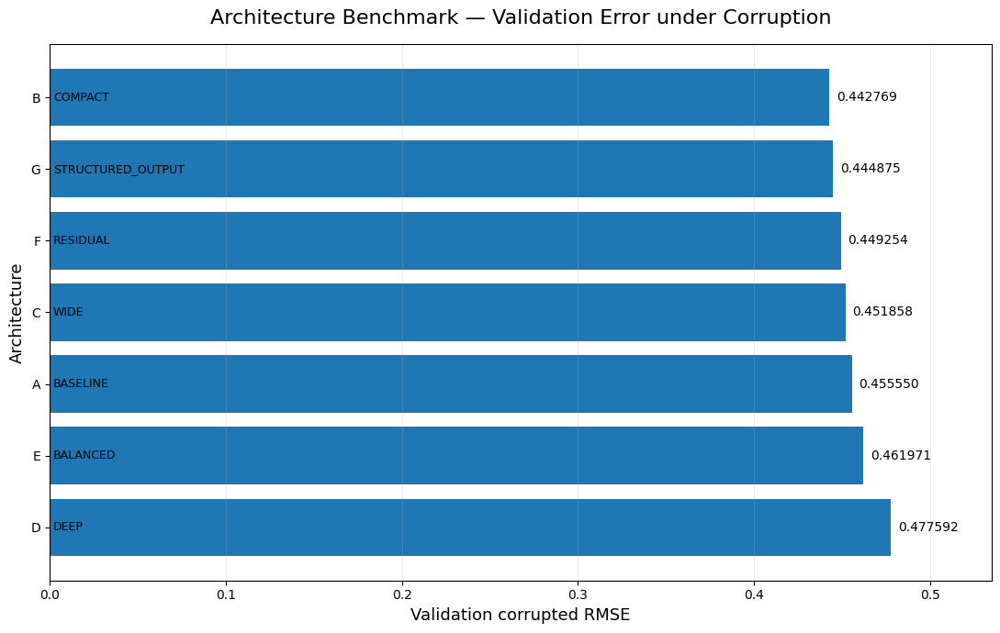

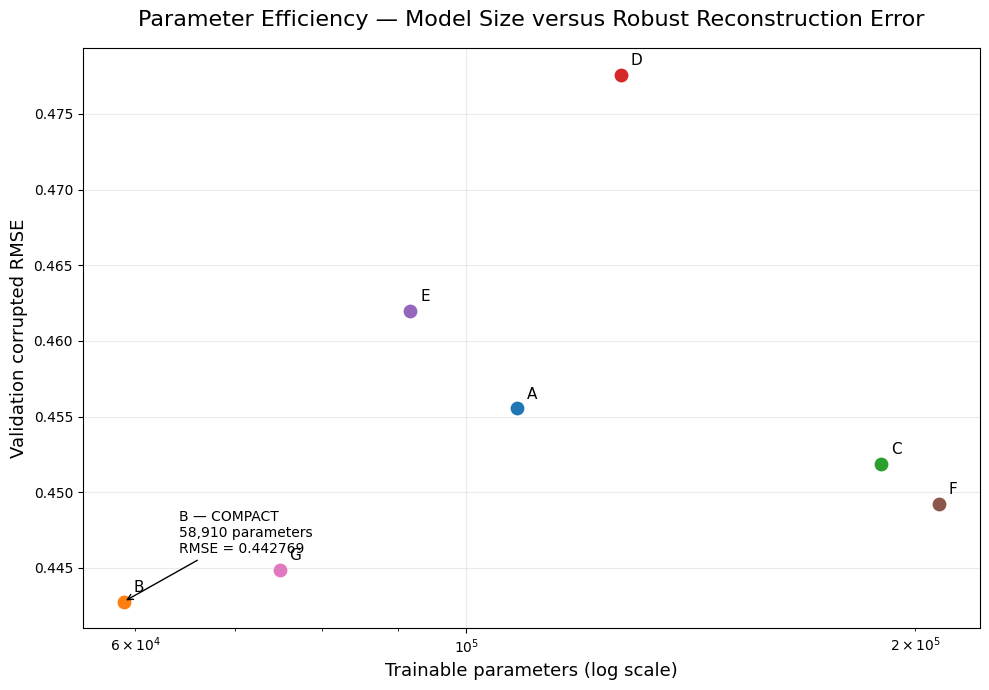

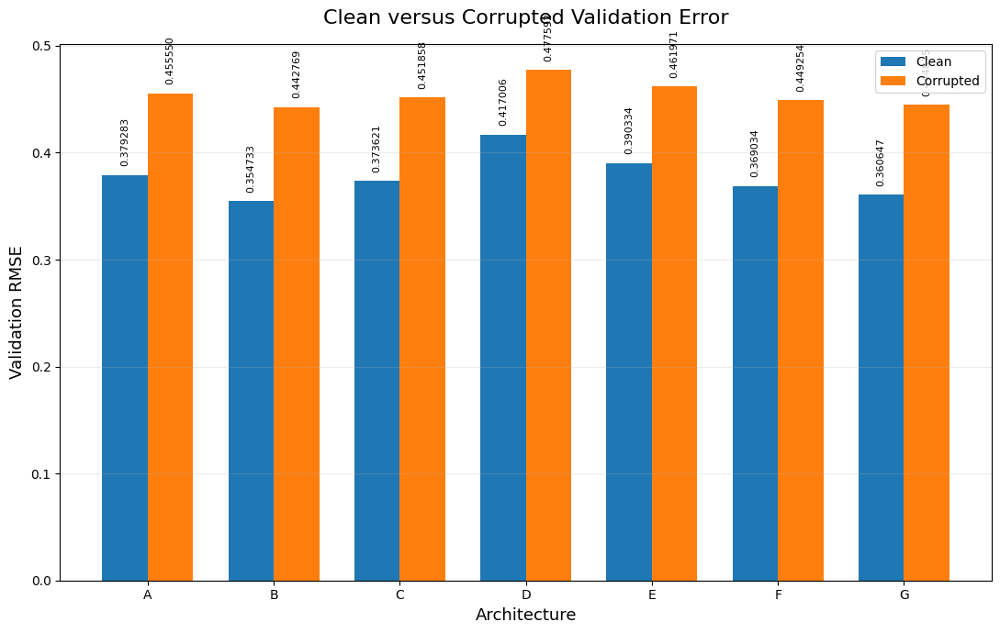

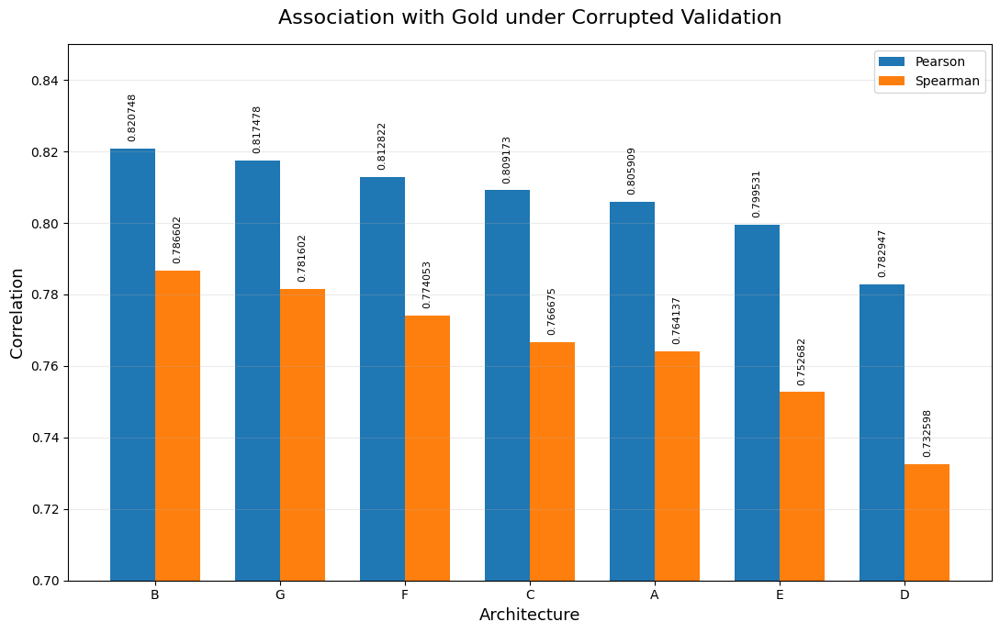

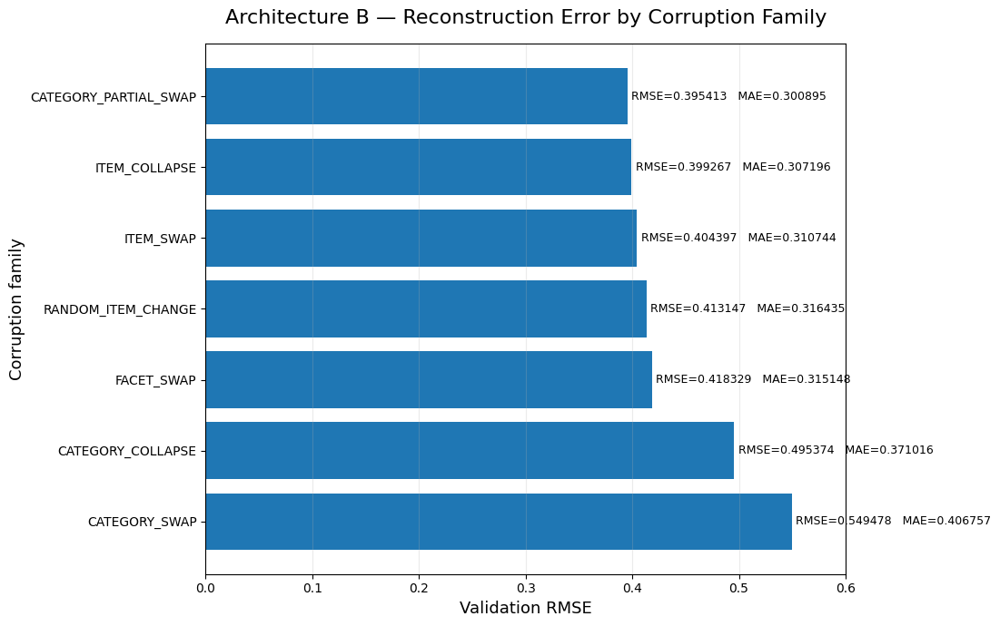

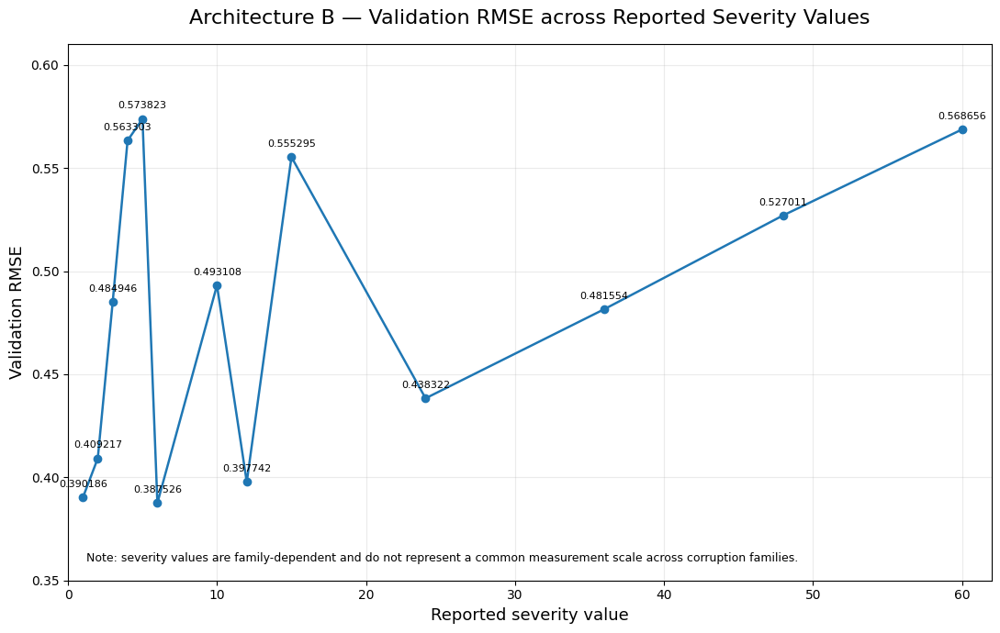

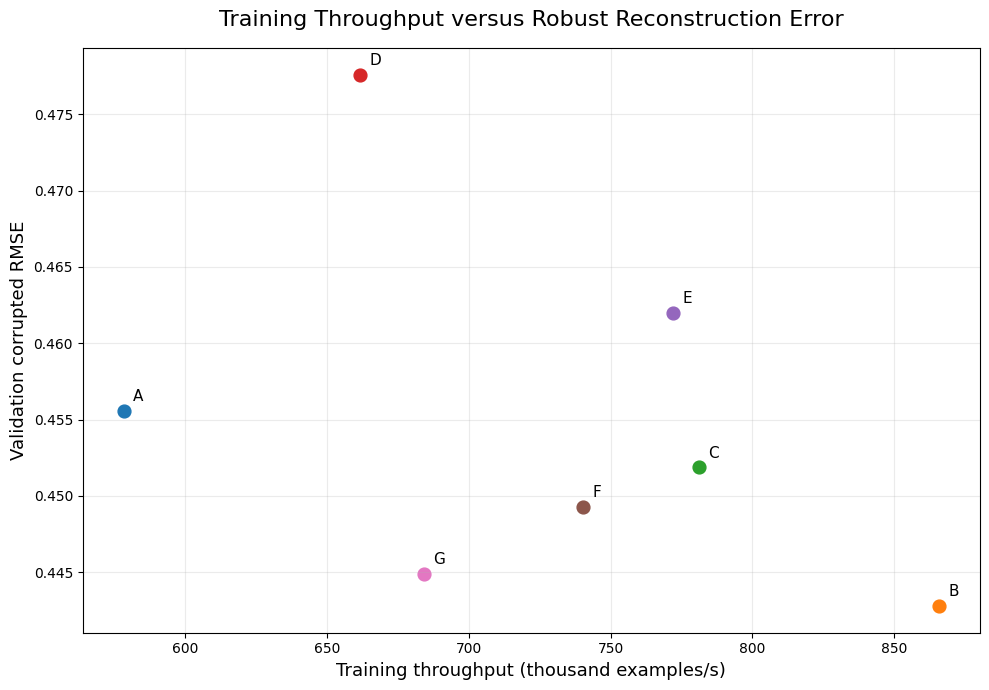

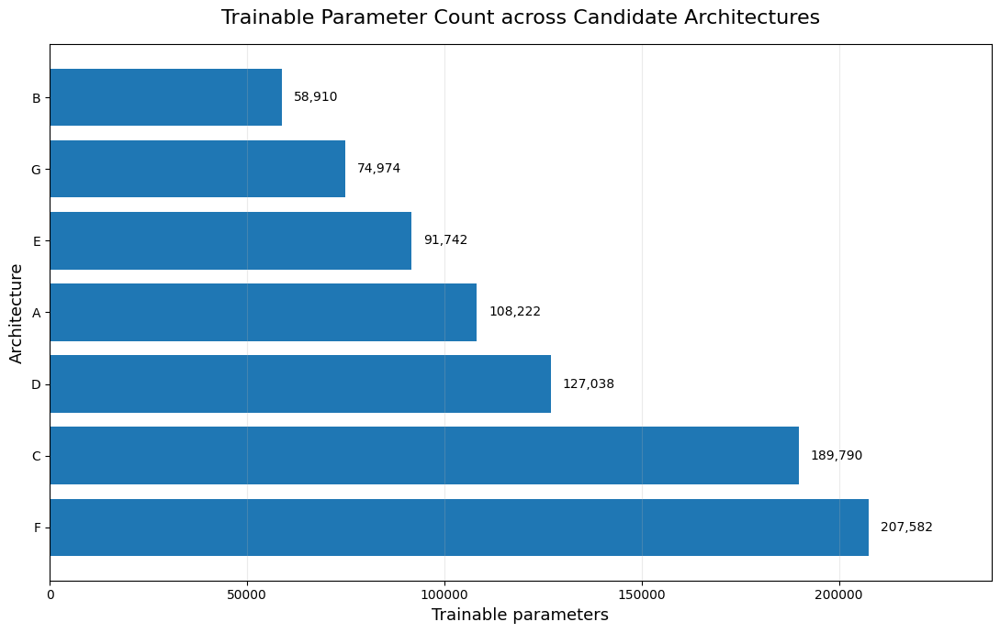


KEY SCREENING RESULT — ARCHITECTURE B
Parameters                 : 58,910
Validation clean RMSE     : 0.354733
Validation corrupted RMSE : 0.442769
Validation corrupted MAE  : 0.332599
Corrupted Pearson         : 0.820748
Corrupted Spearman        : 0.786602
Throughput               : 865,892 examples/s

TEST STATUS: RESERVED
Architecture B is the lowest-RMSE architecture in this screening run.
This remains a screening result; it is not the final TEST-based architecture selection.

FIGURE GENERATION COMPLETE
FIG01 generated.
FIG02 generated.
FIG03 generated.
FIG04 generated.
FIG05 generated.
FIG06 generated.
FIG07 generated.
FIG08 generated.

Files saved to: /content/HEF_IPIP120_PAPER_FIGURES


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


OUT_DIR = Path(
    "/content/HEF_IPIP120_PAPER_FIGURES"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DPI = 600


architectures = pd.DataFrame({

    "architecture": [
        "A",
        "B",
        "C",
        "D",
        "E",
        "F",
        "G",
    ],

    "name": [
        "BASELINE",
        "COMPACT",
        "WIDE",
        "DEEP",
        "BALANCED",
        "RESIDUAL",
        "STRUCTURED_OUTPUT",
    ],

    "parameters": [
        108222,
        58910,
        189790,
        127038,
        91742,
        207582,
        74974,
    ],

    "train_loss": [
        0.742991,
        0.737290,
        0.738886,
        0.805542,
        0.766478,
        0.749253,
        0.775356,
    ],

    "clean_rmse": [
        0.379283,
        0.354733,
        0.373621,
        0.417006,
        0.390334,
        0.369034,
        0.360647,
    ],

    "corrupted_rmse": [
        0.455550,
        0.442769,
        0.451858,
        0.477592,
        0.461971,
        0.449254,
        0.444875,
    ],

    "corrupted_mae": [
        0.344799,
        0.332599,
        0.340983,
        0.365378,
        0.351132,
        0.339187,
        0.334606,
    ],

    "pearson": [
        0.805909,
        0.820748,
        0.809173,
        0.782947,
        0.799531,
        0.812822,
        0.817478,
    ],

    "spearman": [
        0.764137,
        0.786602,
        0.766675,
        0.732598,
        0.752682,
        0.774053,
        0.781602,
    ],

    "subject_consistency": [
        0.144471,
        0.147997,
        0.145587,
        0.134790,
        0.141964,
        0.142298,
        0.145059,
    ],

    "throughput": [
        578162.461383,
        865892.069010,
        781056.531051,
        661643.040247,
        771964.474828,
        740159.107956,
        684109.661384,
    ],
})


family_B = pd.DataFrame({

    "family": [
        "ITEM_SWAP",
        "FACET_SWAP",
        "CATEGORY_PARTIAL_SWAP",
        "CATEGORY_SWAP",
        "ITEM_COLLAPSE",
        "CATEGORY_COLLAPSE",
        "RANDOM_ITEM_CHANGE",
    ],

    "rmse": [
        0.404397,
        0.418329,
        0.395413,
        0.549478,
        0.399267,
        0.495374,
        0.413147,
    ],

    "mae": [
        0.310744,
        0.315148,
        0.300895,
        0.406757,
        0.307196,
        0.371016,
        0.316435,
    ],
})


severity_B = pd.DataFrame({

    "severity": [
        1,
        2,
        3,
        4,
        5,
        6,
        10,
        12,
        15,
        24,
        36,
        48,
        60,
    ],

    "rmse": [
        0.390186,
        0.409217,
        0.484946,
        0.563303,
        0.573823,
        0.387526,
        0.493108,
        0.397742,
        0.555295,
        0.438322,
        0.481554,
        0.527011,
        0.568656,
    ],

    "mae": [
        0.297838,
        0.309551,
        0.361051,
        0.419963,
        0.424267,
        0.298771,
        0.369661,
        0.309588,
        0.416560,
        0.340630,
        0.374520,
        0.409325,
        0.441426,
    ],
})


architectures.to_csv(
    OUT_DIR / "architecture_benchmark_exact.csv",
    index=False,
)

family_B.to_csv(
    OUT_DIR / "architecture_B_family_exact.csv",
    index=False,
)

severity_B.to_csv(
    OUT_DIR / "architecture_B_severity_exact.csv",
    index=False,
)

print("=" * 110)
print("HEF IPIP120 ROBUST — PAPER FIGURE GENERATION")
print("=" * 110)

print(
    "\nOutput directory:",
    OUT_DIR
)

print(
    "\nArchitecture benchmark:"
)

print(
    architectures.to_string(
        index=False
    )
)


plot_df = architectures.sort_values(
    "corrupted_rmse",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.barh(
    plot_df["architecture"],
    plot_df["corrupted_rmse"]
)

ax.set_xlabel(
    "Validation corrupted RMSE",
    fontsize=13
)

ax.set_ylabel(
    "Architecture",
    fontsize=13
)

ax.set_title(
    "Architecture Benchmark — Validation Error under Corruption",
    fontsize=16,
    pad=16
)

ax.set_xlim(
    0,
    max(plot_df["corrupted_rmse"]) * 1.12
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.invert_yaxis()

for bar, (_, row) in zip(
    bars,
    plot_df.iterrows()
):

    ax.text(
        bar.get_width() + 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{row['corrupted_rmse']:.6f}",
        va="center",
        fontsize=10
    )

for i, (_, row) in enumerate(
    plot_df.iterrows()
):

    ax.text(
        0.002,
        i,
        f"{row['name']}",
        va="center",
        ha="left",
        fontsize=9
    )

fig.tight_layout()

fig.savefig(
    OUT_DIR / "FIG01_architecture_corrupted_RMSE.png",
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG01_architecture_corrupted_RMSE.pdf",
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG01_architecture_corrupted_RMSE.svg",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

for _, row in architectures.iterrows():

    ax.scatter(
        row["parameters"],
        row["corrupted_rmse"],
        s=80
    )

    ax.annotate(
        row["architecture"],
        (
            row["parameters"],
            row["corrupted_rmse"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=11
    )

ax.set_xscale(
    "log"
)

ax.set_xlabel(
    "Trainable parameters (log scale)",
    fontsize=13
)

ax.set_ylabel(
    "Validation corrupted RMSE",
    fontsize=13
)

ax.set_title(
    "Parameter Efficiency — Model Size versus Robust Reconstruction Error",
    fontsize=16,
    pad=16
)

ax.grid(
    alpha=0.25
)

B = architectures[
    architectures["architecture"] == "B"
].iloc[0]

ax.annotate(
    (
        f"B — COMPACT\n"
        f"{int(B['parameters']):,} parameters\n"
        f"RMSE = {B['corrupted_rmse']:.6f}"
    ),
    (
        B["parameters"],
        B["corrupted_rmse"]
    ),
    xytext=(40, 35),
    textcoords="offset points",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->"
    )
)

fig.tight_layout()

fig.savefig(
    OUT_DIR / "FIG02_parameter_efficiency.png",
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG02_parameter_efficiency.pdf",
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG02_parameter_efficiency.svg",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


plot_df = architectures.copy()

x = np.arange(
    len(plot_df)
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(11, 7)
)

clean_bars = ax.bar(
    x - width / 2,
    plot_df["clean_rmse"],
    width,
    label="Clean"
)

corrupt_bars = ax.bar(
    x + width / 2,
    plot_df["corrupted_rmse"],
    width,
    label="Corrupted"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    plot_df["architecture"]
)

ax.set_ylabel(
    "Validation RMSE",
    fontsize=13
)

ax.set_xlabel(
    "Architecture",
    fontsize=13
)

ax.set_title(
    "Clean versus Corrupted Validation Error",
    fontsize=16,
    pad=16
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

for bars in [
    clean_bars,
    corrupt_bars
]:

    for bar in bars:

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"{bar.get_height():.6f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

fig.tight_layout()

fig.savefig(
    OUT_DIR / "FIG03_clean_vs_corrupted_RMSE.png",
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG03_clean_vs_corrupted_RMSE.pdf",
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG03_clean_vs_corrupted_RMSE.svg",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


plot_df = architectures.sort_values(
    "pearson",
    ascending=False
)

x = np.arange(
    len(plot_df)
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(11, 7)
)

pearson_bars = ax.bar(
    x - width / 2,
    plot_df["pearson"],
    width,
    label="Pearson"
)

spearman_bars = ax.bar(
    x + width / 2,
    plot_df["spearman"],
    width,
    label="Spearman"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    plot_df["architecture"]
)

ax.set_ylabel(
    "Correlation",
    fontsize=13
)

ax.set_xlabel(
    "Architecture",
    fontsize=13
)

ax.set_ylim(
    0.70,
    0.85
)

ax.set_title(
    "Association with Gold under Corrupted Validation",
    fontsize=16,
    pad=16
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

for bars in [
    pearson_bars,
    spearman_bars
]:

    for bar in bars:

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.6f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

fig.tight_layout()

fig.savefig(
    OUT_DIR / "FIG04_pearson_vs_spearman.png",
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG04_pearson_vs_spearman.pdf",
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG04_pearson_vs_spearman.svg",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



plot_df = family_B.sort_values(
    "rmse",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.barh(
    plot_df["family"],
    plot_df["rmse"]
)

ax.set_xlabel(
    "Validation RMSE",
    fontsize=13
)

ax.set_ylabel(
    "Corruption family",
    fontsize=13
)

ax.set_title(
    "Architecture B — Reconstruction Error by Corruption Family",
    fontsize=16,
    pad=16
)

ax.invert_yaxis()

ax.set_xlim(
    0,
    0.60
)

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, (_, row) in zip(
    bars,
    plot_df.iterrows()
):

    ax.text(
        bar.get_width() + 0.004,
        bar.get_y() + bar.get_height() / 2,
        (
            f"RMSE={row['rmse']:.6f}   "
            f"MAE={row['mae']:.6f}"
        ),
        va="center",
        fontsize=9
    )

fig.tight_layout()

fig.savefig(
    OUT_DIR / "FIG05_B_corruption_family.png",
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG05_B_corruption_family.pdf",
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG05_B_corruption_family.svg",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.plot(
    severity_B["severity"],
    severity_B["rmse"],
    marker="o",
    linewidth=1.8
)

for _, row in severity_B.iterrows():

    ax.annotate(
        f"{row['rmse']:.6f}",
        (
            row["severity"],
            row["rmse"]
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

ax.set_xlabel(
    "Reported severity value",
    fontsize=13
)

ax.set_ylabel(
    "Validation RMSE",
    fontsize=13
)

ax.set_title(
    "Architecture B — Validation RMSE across Reported Severity Values",
    fontsize=16,
    pad=16
)

ax.set_xlim(
    0,
    62
)

ax.set_ylim(
    0.35,
    0.61
)

ax.grid(
    alpha=0.25
)

ax.text(
    0.02,
    0.03,
    (
        "Note: severity values are family-dependent "
        "and do not represent a common measurement scale across corruption families."
    ),
    transform=ax.transAxes,
    fontsize=9,
    va="bottom"
)

fig.tight_layout()

fig.savefig(
    OUT_DIR / "FIG06_B_severity.png",
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG06_B_severity.pdf",
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG06_B_severity.svg",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



fig, ax = plt.subplots(
    figsize=(10, 7)
)

for _, row in architectures.iterrows():

    ax.scatter(
        row["throughput"] / 1000,
        row["corrupted_rmse"],
        s=85
    )

    ax.annotate(
        row["architecture"],
        (
            row["throughput"] / 1000,
            row["corrupted_rmse"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=11
    )

ax.set_xlabel(
    "Training throughput (thousand examples/s)",
    fontsize=13
)

ax.set_ylabel(
    "Validation corrupted RMSE",
    fontsize=13
)

ax.set_title(
    "Training Throughput versus Robust Reconstruction Error",
    fontsize=16,
    pad=16
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

fig.savefig(
    OUT_DIR / "FIG07_throughput_vs_RMSE.png",
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG07_throughput_vs_RMSE.pdf",
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG07_throughput_vs_RMSE.svg",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



plot_df = architectures.sort_values(
    "parameters",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.barh(
    plot_df["architecture"],
    plot_df["parameters"]
)

ax.set_xlabel(
    "Trainable parameters",
    fontsize=13
)

ax.set_ylabel(
    "Architecture",
    fontsize=13
)

ax.set_title(
    "Trainable Parameter Count across Candidate Architectures",
    fontsize=16,
    pad=16
)

ax.invert_yaxis()

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, (_, row) in zip(
    bars,
    plot_df.iterrows()
):

    ax.text(
        bar.get_width() + 3000,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['parameters']):,}",
        va="center",
        fontsize=10
    )

ax.set_xlim(
    0,
    max(plot_df["parameters"]) * 1.15
)

fig.tight_layout()

fig.savefig(
    OUT_DIR / "FIG08_parameter_count.png",
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG08_parameter_count.pdf",
    bbox_inches="tight"
)

fig.savefig(
    OUT_DIR / "FIG08_parameter_count.svg",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)



B = architectures[
    architectures["architecture"] == "B"
].iloc[0]

print("\n" + "=" * 110)
print("KEY SCREENING RESULT — ARCHITECTURE B")
print("=" * 110)

print(
    f"Parameters                 : {int(B['parameters']):,}"
)

print(
    f"Validation clean RMSE     : {B['clean_rmse']:.6f}"
)

print(
    f"Validation corrupted RMSE : {B['corrupted_rmse']:.6f}"
)

print(
    f"Validation corrupted MAE  : {B['corrupted_mae']:.6f}"
)

print(
    f"Corrupted Pearson         : {B['pearson']:.6f}"
)

print(
    f"Corrupted Spearman        : {B['spearman']:.6f}"
)

print(
    f"Throughput               : {B['throughput']:,.0f} examples/s"
)

print(
    "\nTEST STATUS: RESERVED"
)

print(
    "Architecture B is the lowest-RMSE architecture in this screening run."
)

print(
    "This remains a screening result; it is not the final TEST-based architecture selection."
)

print("\n" + "=" * 110)
print("FIGURE GENERATION COMPLETE")
print("=" * 110)

for i in range(1, 9):

    print(
        f"FIG{i:02d} generated."
    )

print(
    "\nFiles saved to:",
    OUT_DIR
)

## HEF IPIP-120 — Loss / Objective Competition

The HEF IPIP-120 Loss / Objective Competition evaluates alternative training objectives under a strictly controlled experimental setting. The purpose of this stage is to determine how the choice of optimization objective affects the reconstruction of the 30-dimensional Gold representation when the underlying network architecture and all other training conditions are held constant.

The architecture is fixed to the compact MLP configuration, corresponding to the mapping:

**120 → 192 → 128 → 64 → 30**

Only the training objective is varied. The dataset, TRAIN subject subset, SIES schedule, batch size, learning rate, weight decay, dropout, optimizer, input normalization, number of subject exposures, and validation protocol remain fixed across all experimental conditions. This isolates the contribution of the objective function and prevents changes in optimization behavior from being confounded with architectural or data-related differences.

### Fixed Training Population

The initial screening uses a deterministic subset of 10,000 TRAIN subjects. Because each subject contributes 143 views, the competition operates on:

**10,000 subjects × 143 views = 1,430,000 training observations.**

Subjects are selected without replacement using a fixed data seed, and their complete 143-view blocks are retained. This preserves the participant-level structure of the robust dataset while providing a computationally controlled screening environment.

### Common SIES Training Schedule

All nine objectives are trained using exactly the same Subject-Interleaved Exposure Scheduler (SIES) schedule.

For each of the 143 rounds, every subject contributes exactly one of its 143 available views. Subject order is independently permuted within each round before batches are constructed. The implementation explicitly verifies that no participant appears more than once within a batch.

The same precomputed SIES schedule is reused for every loss configuration. Consequently, differences between objectives are evaluated under identical subject-view exposure and batch composition. The SIES schedule itself is deterministically generated from a dedicated schedule seed and audited to ensure that every subject encounters all 143 views exactly once during the cycle.

### Competing Objectives

Nine objectives are evaluated:

**A — Mean Squared Error (MSE)**
The standard squared-error objective, which penalizes larger reconstruction deviations more strongly.

**B — Mean Absolute Error (MAE)**
An absolute-error objective that assigns a linear penalty to deviations.

**C — Huber Loss, δ = 1.0**
A robust loss combining quadratic behavior near zero error with linear behavior for larger deviations.

**D — Huber Loss, δ = 0.5**
A more tightly localized Huber formulation using a smaller transition threshold.

**E — 70% MSE + 30% MAE**
A composite objective combining squared and absolute reconstruction error.

**F — 70% MSE + 30% Huber**
A composite objective combining standard squared error with a robust Huber component.

**G — 90% MSE + 10% Cosine Profile Loss**
A composite objective that combines coordinate-level reconstruction error with a profile-orientation component defined after centering the predicted and target facet vectors at the midpoint of the 1–5 scale.

**H — 90% MSE + 10% Pearson Profile Loss**
A composite objective combining squared reconstruction error with a within-profile Pearson correlation term.

**I — 60% MSE + 20% Huber + 20% MAE**
A three-component composite objective combining squared, robust, and absolute error terms.

### Optimization Procedure

For every objective, a new instance of the fixed B — COMPACT architecture is initialized with the same model seed. The optimizer is AdamW with a learning rate of 2 × 10⁻³ and weight decay of 1 × 10⁻⁴. Dropout is fixed at 0.10, gradient clipping is applied with a maximum norm of 1.0, and BF16 autocasting is enabled under CUDA.

Each objective is trained over one complete 143-round SIES cycle. The implementation checks that the training loss remains finite and raises an error if a non-finite objective is encountered. This provides a common numerical stability criterion across all nine experimental conditions.

### Validation Framework

The evaluation procedure is identical for all objectives.

Predictions are generated separately for CLEAN and CORRUPTED validation observations. Performance is summarized using RMSE, MAE, Pearson correlation, and Spearman correlation for both conditions, together with aggregate validation error across the complete validation set.

The corrupted validation population is additionally analyzed by corruption family and by reported severity value. This allows the influence of the objective function to be examined not only in aggregate, but also across the different structural perturbations represented in the robust dataset.

A subject-level consistency measure is also calculated. This metric quantifies the mean deviation of the model's multiple predictions for the same participant from that participant's mean prediction across available validation views. It therefore provides a complementary measure of prediction stability across repeated corrupted and clean observations associated with the same individual.

The validation pipeline also records the minimum and maximum model outputs and the fraction of predictions falling outside the nominal 1–5 response-derived scale. These diagnostics provide an additional assessment of numerical and output-range behavior.

### Common-Schedule Comparison Principle

A central methodological feature of this experiment is that the nine objectives do not receive independently sampled training schedules. A single fixed SIES schedule is constructed once and then reused across all objective configurations.

This makes the comparison substantially more controlled because subject selection, view exposure, round structure, batch membership, and the number of training observations are held constant. The experimental variable is therefore restricted to the mathematical form of the objective used to update the same compact architecture.

### Checkpointing and Reproducibility

Each objective produces an independent checkpoint containing the model state, optimizer state, objective specification, random seed, training statistics, validation metrics, normalization rule, input and output dimensionality, number of views per subject, and the SIES schedule seed.

The complete competition results are subsequently assembled into a common table and sorted primarily by corrupted-validation RMSE, with corrupted MAE used as a secondary ordering criterion. Separate result tables are produced for corruption-family performance and severity-specific performance. The resulting CSV and JSON records provide machine-readable representations of the complete experiment.

### Interpretation of the Experiment

The purpose of this competition is therefore not to compare different network capacities, but to isolate the effect of the training objective on robust psychometric reconstruction.

The experiment asks whether, under an identical compact architecture, identical subject exposure, identical data subset, identical optimization settings, and identical validation framework, different formulations of the reconstruction objective lead to systematically different behavior on clean observations, corrupted observations, different perturbation families, different reported severity levels, and repeated views of the same participant.

TEST data remain reserved throughout this stage. The loss competition is explicitly treated as a screening experiment, an


In [11]:
from __future__ import annotations
import gc
import json
import math
import random
import time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
LOSS_BENCHMARK_ROOT = (
    ROOT
    / "MLP_GATEWAY_BENCHMARK"
    / "LOSS_COMPETITION"
)
LOSS_BENCHMARK_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)
ARCHITECTURE_KEY = "B"
ARCHITECTURE_NAME = "COMPACT"
LOSS_MAX_TRAIN_SUBJECTS = 10_000
LOSS_BATCH_SIZE = 8192
LOSS_SIES_CYCLES = 1
LOSS_LEARNING_RATE = 2e-3
LOSS_WEIGHT_DECAY = 1e-4
LOSS_DROPOUT = 0.10
LOSS_GRAD_CLIP = 1.0
LOSS_USE_BF16 = True
LOSS_DATA_SEED = 20260920
LOSS_MODEL_SEED = 20260920
LOSS_SCHEDULE_SEED = (
    LOSS_DATA_SEED
    + 777
)
def select_train_subjects_for_loss(
    X,
    Y,
    corruption_type,
    severity,
    max_subjects,
    seed,
):
    total_subjects = (
        len(X)
        // VIEWS_PER_SUBJECT
    )
    assert (
        len(X)
        == total_subjects
        * VIEWS_PER_SUBJECT
    )
    if max_subjects is None:
        subject_ids = np.arange(
            total_subjects,
            dtype=np.int64,
        )
    else:
        if max_subjects > total_subjects:
            max_subjects = total_subjects
        rng = np.random.default_rng(
            seed
        )
        subject_ids = rng.choice(
            total_subjects,
            size=max_subjects,
            replace=False,
        )
        subject_ids.sort()
    row_indices = np.concatenate(
        [
            subject_ids[:, None]
            * VIEWS_PER_SUBJECT
            + np.arange(
                VIEWS_PER_SUBJECT,
                dtype=np.int64,
            )[None, :]
        ],
        axis=1,
    ).reshape(-1)
    sub_X = np.asarray(
        X[
            row_indices
        ],
        dtype=np.uint8,
    )
    sub_Y = np.asarray(
        Y[
            row_indices
        ],
        dtype=np.float32,
    )
    sub_type = np.asarray(
        corruption_type[
            row_indices
        ],
        dtype=np.uint8,
    )
    sub_severity = np.asarray(
        severity[
            row_indices
        ],
        dtype=np.uint8,
    )
    assert sub_X.shape == (
        len(subject_ids)
        * VIEWS_PER_SUBJECT,
        INPUT_DIM,
    )
    assert sub_Y.shape == (
        len(subject_ids)
        * VIEWS_PER_SUBJECT,
        OUTPUT_DIM,
    )
    assert sub_type.shape == (
        len(subject_ids)
        * VIEWS_PER_SUBJECT,
    )
    assert sub_severity.shape == (
        len(subject_ids)
        * VIEWS_PER_SUBJECT,
    )
    return (
        sub_X,
        sub_Y,
        sub_type,
        sub_severity,
        subject_ids,
    )
def build_fixed_sies_schedule(
    n_subjects: int,
    seed: int,
):
    """
    Generates ONE deterministic SIES schedule.
    Every loss receives exactly this same schedule.
    For each round:
        one view / subject
        random permutation of subjects
        batches built afterward
    """
    rng = np.random.default_rng(
        seed
    )
    rank = rng.integers(
        0,
        VIEWS_PER_SUBJECT,
        size=n_subjects,
        dtype=np.int16,
    )
    schedule = []
    for round_id in range(
        VIEWS_PER_SUBJECT
    ):
        subject_order = rng.permutation(
            n_subjects
        ).astype(
            np.int64,
            copy=False,
        )
        selected_views = (
            rank[
                subject_order
            ]
            + round_id
        ) % VIEWS_PER_SUBJECT
        flat_indices = (
            subject_order
            * VIEWS_PER_SUBJECT
            + selected_views.astype(
                np.int64,
                copy=False,
            )
        )
        round_batches = []
        for start in range(
            0,
            n_subjects,
            LOSS_BATCH_SIZE,
        ):
            end = min(
                start
                + LOSS_BATCH_SIZE,
                n_subjects,
            )
            batch_subjects = (
                subject_order[
                    start:end
                ]
            )
            batch_indices = (
                flat_indices[
                    start:end
                ]
            )
            assert len(
                np.unique(
                    batch_subjects
                )
            ) == len(
                batch_subjects
            )
            round_batches.append(
                {
                    "subject_ids": batch_subjects,
                    "indices": batch_indices,
                }
            )
        schedule.append(
            round_batches
        )
    sample_subjects = min(
        n_subjects,
        2048,
    )
    for subject_id in range(
        sample_subjects
    ):
        seen = (
            rank[
                subject_id
            ]
            + np.arange(
                VIEWS_PER_SUBJECT
            )
        ) % VIEWS_PER_SUBJECT
        assert np.array_equal(
            np.sort(seen),
            np.arange(
                VIEWS_PER_SUBJECT
            ),
        )
    print(
        "Fixed SIES schedule       : PASS"
    )
    return schedule
class HuberLoss(
    nn.Module
):
    def __init__(
        self,
        delta: float = 1.0,
    ):
        super().__init__()
        self.delta = float(
            delta
        )
    def forward(
        self,
        prediction,
        target,
    ):
        error = (
            prediction
            - target
        )
        abs_error = torch.abs(
            error
        )
        quadratic = torch.minimum(
            abs_error,
            torch.tensor(
                self.delta,
                device=error.device,
                dtype=error.dtype,
            ),
        )
        linear = (
            abs_error
            - quadratic
        )
        loss = (
            0.5
            * quadratic
            * quadratic
            + self.delta
            * linear
        )
        return loss.mean()
class PearsonLoss(
    nn.Module
):
    def forward(
        self,
        prediction,
        target,
    ):
        p = prediction.reshape(
            prediction.shape[0],
            -1,
        )
        y = target.reshape(
            target.shape[0],
            -1,
        )
        p = (
            p
            - p.mean(
                dim=1,
                keepdim=True,
            )
        )
        y = (
            y
            - y.mean(
                dim=1,
                keepdim=True,
            )
        )
        numerator = (
            p * y
        ).sum(
            dim=1
        )
        denominator = (
            torch.sqrt(
                torch.sum(
                    p * p,
                    dim=1,
                )
                + 1e-8
            )
            *
            torch.sqrt(
                torch.sum(
                    y * y,
                    dim=1,
                )
                + 1e-8
            )
        )
        correlation = (
            numerator
            / denominator
        )
        return (
            1.0
            - correlation
        ).mean()
class CosineProfileLoss(
    nn.Module
):
    def forward(
        self,
        prediction,
        target,
    ):
        prediction = prediction - 3.0
        target = target - 3.0
        cosine = nn.functional.cosine_similarity(
            prediction,
            target,
            dim=1,
            eps=1e-8,
        )
        return (
            1.0
            - cosine
        ).mean()
MSE_LOSS = nn.MSELoss()
MAE_LOSS = nn.L1Loss()
HUBER_1 = HuberLoss(
    delta=1.0
)
HUBER_05 = HuberLoss(
    delta=0.5
)
COSINE_LOSS = CosineProfileLoss()
PEARSON_LOSS = PearsonLoss()
LOSS_CONFIGS = {
    "A": {
        "name": "MSE",
        "kind": "mse",
    },
    "B": {
        "name": "MAE",
        "kind": "mae",
    },
    "C": {
        "name": "HUBER_1.0",
        "kind": "huber_1",
    },
    "D": {
        "name": "HUBER_0.5",
        "kind": "huber_05",
    },
    "E": {
        "name": "MSE70_MAE30",
        "kind": "mse70_mae30",
    },
    "F": {
        "name": "MSE70_HUBER30",
        "kind": "mse70_huber30",
    },
    "G": {
        "name": "MSE90_COSINE10",
        "kind": "mse90_cosine10",
    },
    "H": {
        "name": "MSE90_PEARSON10",
        "kind": "mse90_pearson10",
    },
    "I": {
        "name": "MSE60_HUBER20_MAE20",
        "kind": "mse60_huber20_mae20",
    },
}
def compute_loss(
    kind,
    prediction,
    target,
):
    if kind == "mse":
        return MSE_LOSS(
            prediction,
            target,
        )
    if kind == "mae":
        return MAE_LOSS(
            prediction,
            target,
        )
    if kind == "huber_1":
        return HUBER_1(
            prediction,
            target,
        )
    if kind == "huber_05":
        return HUBER_05(
            prediction,
            target,
        )
    if kind == "mse70_mae30":
        return (
            0.70
            * MSE_LOSS(
                prediction,
                target,
            )
            +
            0.30
            * MAE_LOSS(
                prediction,
                target,
            )
        )
    if kind == "mse70_huber30":
        return (
            0.70
            * MSE_LOSS(
                prediction,
                target,
            )
            +
            0.30
            * HUBER_1(
                prediction,
                target,
            )
        )
    if kind == "mse90_cosine10":
        return (
            0.90
            * MSE_LOSS(
                prediction,
                target,
            )
            +
            0.10
            * COSINE_LOSS(
                prediction,
                target,
            )
        )
    if kind == "mse90_pearson10":
        return (
            0.90
            * MSE_LOSS(
                prediction,
                target,
            )
            +
            0.10
            * PEARSON_LOSS(
                prediction,
                target,
            )
        )
    if kind == "mse60_huber20_mae20":
        return (
            0.60
            * MSE_LOSS(
                prediction,
                target,
            )
            +
            0.20
            * HUBER_1(
                prediction,
                target,
            )
            +
            0.20
            * MAE_LOSS(
                prediction,
                target,
            )
        )
    raise ValueError(
        f"Unknown loss kind: {kind}"
    )
def metric_rmse(
    prediction,
    target,
):
    prediction = np.asarray(
        prediction,
        dtype=np.float64,
    )
    target = np.asarray(
        target,
        dtype=np.float64,
    )
    return float(
        np.sqrt(
            np.mean(
                (
                    prediction
                    - target
                )
                ** 2
            )
        )
    )
def metric_mae(
    prediction,
    target,
):
    prediction = np.asarray(
        prediction,
        dtype=np.float64,
    )
    target = np.asarray(
        target,
        dtype=np.float64,
    )
    return float(
        np.mean(
            np.abs(
                prediction
                - target
            )
        )
    )
def metric_pearson(
    prediction,
    target,
):
    p = np.asarray(
        prediction,
        dtype=np.float64,
    ).reshape(-1)
    y = np.asarray(
        target,
        dtype=np.float64,
    ).reshape(-1)
    p = (
        p
        - p.mean()
    )
    y = (
        y
        - y.mean()
    )
    denominator = (
        np.sqrt(
            np.sum(
                p * p
            )
        )
        *
        np.sqrt(
            np.sum(
                y * y
            )
        )
    )
    if denominator <= 0:
        return float(
            "nan"
        )
    return float(
        np.sum(
            p * y
        )
        / denominator
    )
def metric_spearman(
    prediction,
    target,
):
    p = np.asarray(
        prediction,
        dtype=np.float64,
    ).reshape(-1)
    y = np.asarray(
        target,
        dtype=np.float64,
    ).reshape(-1)
    p_rank = pd.Series(
        p
    ).rank(
        method="average"
    ).to_numpy()
    y_rank = pd.Series(
        y
    ).rank(
        method="average"
    ).to_numpy()
    return metric_pearson(
        p_rank,
        y_rank,
    )
def compute_subject_consistency(
    prediction,
    target_ids,
):
    prediction = np.asarray(
        prediction,
        dtype=np.float64,
    )
    target_ids = np.asarray(
        target_ids,
        dtype=np.int64,
    )
    order = np.argsort(
        target_ids,
        kind="mergesort",
    )
    sorted_ids = target_ids[
        order
    ]
    sorted_prediction = prediction[
        order
    ]
    unique_ids, starts = np.unique(
        sorted_ids,
        return_index=True,
    )
    counts = np.diff(
        np.r_[
            starts,
            len(sorted_ids),
        ]
    )
    sums = np.add.reduceat(
        sorted_prediction,
        starts,
        axis=0,
    )
    means = (
        sums
        / counts[:, None]
    )
    repeated_means = np.repeat(
        means,
        counts,
        axis=0,
    )
    deviation = (
        sorted_prediction
        - repeated_means
    )
    per_row = (
        np.linalg.norm(
            deviation,
            axis=1,
        )
        / math.sqrt(
            OUTPUT_DIM
        )
    )
    return float(
        per_row.mean()
    )
@torch.no_grad()
def predict_model(
    model,
    X,
):
    model.eval()
    predictions = []
    for start in range(
        0,
        len(X),
        EVAL_BATCH_SIZE,
    ):
        end = min(
            start
            + EVAL_BATCH_SIZE,
            len(X),
        )
        xb = torch.from_numpy(
            np.asarray(
                X[
                    start:end
                ],
                dtype=np.uint8,
            )
        ).to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True,
        )
        if LOSS_USE_BF16:
            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16,
            ):
                output = model(
                    xb
                )
        else:
            output = model(
                xb
            )
        predictions.append(
            output.float()
            .cpu()
            .numpy()
        )
    return np.concatenate(
        predictions,
        axis=0,
    )
def evaluate_loss_model(
    model,
):
    clean_prediction = predict_model(
        model,
        VAL_CLEAN_X,
    )
    corrupted_prediction = predict_model(
        model,
        VAL_CORRUPTED_X,
    )
    all_prediction = np.concatenate(
        [
            clean_prediction,
            corrupted_prediction,
        ],
        axis=0,
    )
    all_target = np.concatenate(
        [
            VAL_CLEAN_Y,
            VAL_CORRUPTED_Y,
        ],
        axis=0,
    )
    clean_rmse = metric_rmse(
        clean_prediction,
        VAL_CLEAN_Y,
    )
    clean_mae = metric_mae(
        clean_prediction,
        VAL_CLEAN_Y,
    )
    clean_pearson = metric_pearson(
        clean_prediction,
        VAL_CLEAN_Y,
    )
    clean_spearman = metric_spearman(
        clean_prediction,
        VAL_CLEAN_Y,
    )
    corrupted_rmse = metric_rmse(
        corrupted_prediction,
        VAL_CORRUPTED_Y,
    )
    corrupted_mae = metric_mae(
        corrupted_prediction,
        VAL_CORRUPTED_Y,
    )
    corrupted_pearson = metric_pearson(
        corrupted_prediction,
        VAL_CORRUPTED_Y,
    )
    corrupted_spearman = metric_spearman(
        corrupted_prediction,
        VAL_CORRUPTED_Y,
    )
    all_rmse = metric_rmse(
        all_prediction,
        all_target,
    )
    all_mae = metric_mae(
        all_prediction,
        all_target,
    )
    family_names = {
        1: "ITEM_SWAP",
        2: "FACET_SWAP",
        3: "CATEGORY_PARTIAL_SWAP",
        4: "CATEGORY_SWAP",
        5: "ITEM_COLLAPSE",
        6: "CATEGORY_COLLAPSE",
        7: "RANDOM_ITEM_CHANGE",
    }
    family_metrics = {}
    for code, family_name in (
        family_names.items()
    ):
        mask = (
            VAL_CORRUPTED_TYPE
            == code
        )
        if not np.any(mask):
            continue
        family_metrics[
            family_name
        ] = metric_rmse(
            corrupted_prediction[
                mask
            ],
            VAL_CORRUPTED_Y[
                mask
            ],
        )
    severity_metrics = {}
    for severity in np.unique(
        VAL_CORRUPTED_SEVERITY
    ):
        mask = (
            VAL_CORRUPTED_SEVERITY
            == severity
        )
        severity_metrics[
            int(severity)
        ] = metric_rmse(
            corrupted_prediction[
                mask
            ],
            VAL_CORRUPTED_Y[
                mask
            ],
        )
    combined_target_ids = np.concatenate(
        [
            VAL_CLEAN_TARGET,
            VAL_CORRUPTED_TARGET,
        ],
        axis=0,
    )
    consistency = (
        compute_subject_consistency(
            all_prediction,
            combined_target_ids,
        )
    )
    output_min = float(
        all_prediction.min()
    )
    output_max = float(
        all_prediction.max()
    )
    out_of_range = float(
        np.mean(
            (
                all_prediction < 1.0
            )
            |
            (
                all_prediction > 5.0
            )
        )
    )
    return {
        "clean_rmse": clean_rmse,
        "clean_mae": clean_mae,
        "clean_pearson": clean_pearson,
        "clean_spearman": clean_spearman,
        "corrupted_rmse": corrupted_rmse,
        "corrupted_mae": corrupted_mae,
        "corrupted_pearson": corrupted_pearson,
        "corrupted_spearman": corrupted_spearman,
        "all_rmse": all_rmse,
        "all_mae": all_mae,
        "subject_consistency": consistency,
        "output_min": output_min,
        "output_max": output_max,
        "out_of_range_fraction": out_of_range,
        "family_metrics": family_metrics,
        "severity_metrics": severity_metrics,
    }
def train_one_loss(
    loss_key,
    config,
    train_X,
    train_Y,
    schedule,
    seed,
):
    seed_everything(
        seed
    )
    model = HEFIPIP120MLP(
        architecture_key="B",
        dropout=LOSS_DROPOUT,
    ).to(
        DEVICE
    )
    parameter_count = count_parameters(
        model
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LOSS_LEARNING_RATE,
        weight_decay=LOSS_WEIGHT_DECAY,
    )
    total_examples = 0
    weighted_loss = 0.0
    start_time = time.perf_counter()
    model.train()
    print()
    print("=" * 100)
    print(
        f"LOSS {loss_key} — {config['name']}"
    )
    print("=" * 100)
    print(
        "Architecture            : B COMPACT"
    )
    print(
        "Parameters              :",
        f"{parameter_count:,}",
    )
    print(
        "Objective               :",
        config["name"],
    )
    for round_id, round_batches in enumerate(
        schedule
    ):
        for batch_info in round_batches:
            indices = batch_info[
                "indices"
            ]
            batch_x = np.asarray(
                train_X[
                    indices
                ],
                dtype=np.uint8,
            )
            batch_y = np.asarray(
                train_Y[
                    indices
                ],
                dtype=np.float32,
            )
            subject_ids = batch_info[
                "subject_ids"
            ]
            assert len(
                np.unique(
                    subject_ids
                )
            ) == len(
                subject_ids
            )
            xb = torch.from_numpy(
                batch_x
            ).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            yb = torch.from_numpy(
                batch_y
            ).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            optimizer.zero_grad(
                set_to_none=True
            )
            if LOSS_USE_BF16:
                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.bfloat16,
                ):
                    prediction = model(
                        xb
                    )
                    loss = compute_loss(
                        config["kind"],
                        prediction,
                        yb,
                    )
            else:
                prediction = model(
                    xb
                )
                loss = compute_loss(
                    config["kind"],
                    prediction,
                    yb,
                )
            if not torch.isfinite(
                loss
            ):
                raise FloatingPointError(
                    f"{loss_key}: non-finite loss."
                )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                LOSS_GRAD_CLIP,
            )
            optimizer.step()
            n = len(
                batch_x
            )
            weighted_loss += (
                float(
                    loss.detach().item()
                )
                * n
            )
            total_examples += n
        if (
            round_id == 0
            or (round_id + 1) % 10 == 0
            or round_id + 1
            == VIEWS_PER_SUBJECT
        ):
            average_loss = (
                weighted_loss
                / max(
                    total_examples,
                    1,
                )
            )
            elapsed = (
                time.perf_counter()
                - start_time
            )
            throughput = (
                total_examples
                / max(
                    elapsed,
                    1e-9,
                )
            )
            print(
                f"[LOSS-SIES] "
                f"round={round_id + 1}/{VIEWS_PER_SUBJECT} "
                f"examples={total_examples:,} "
                f"loss={average_loss:.6f} "
                f"throughput={throughput:,.0f} ex/s"
            )
    elapsed = (
        time.perf_counter()
        - start_time
    )
    average_loss = (
        weighted_loss
        / max(
            total_examples,
            1,
        )
    )
    throughput = (
        total_examples
        / max(
            elapsed,
            1e-9,
        )
    )
    print()
    print(
        "Running validation..."
    )
    metrics = evaluate_loss_model(
        model
    )
    checkpoint_path = (
        LOSS_BENCHMARK_ROOT
        / (
            f"LOSS_{loss_key}_"
            f"{config['name']}_"
            f"seed_{seed}.pt"
        )
    )
    torch.save(
        {
            "architecture": "B",
            "architecture_name": "COMPACT",
            "loss_key": loss_key,
            "loss_config": config,
            "seed": seed,
            "state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_examples": total_examples,
            "train_loss": average_loss,
            "train_seconds": elapsed,
            "train_examples_per_sec": throughput,
            "validation_metrics": metrics,
            "normalization": "(x - 3) / 2",
            "input_dim": INPUT_DIM,
            "output_dim": OUTPUT_DIM,
            "views_per_subject": VIEWS_PER_SUBJECT,
            "sies_schedule_seed": LOSS_SCHEDULE_SEED,
        },
        checkpoint_path,
    )
    result = {
        "loss_key": loss_key,
        "loss_name": config["name"],
        "architecture": "B",
        "parameters": parameter_count,
        "seed": seed,
        "train_examples": total_examples,
        "train_loss": average_loss,
        "train_seconds": elapsed,
        "train_examples_per_sec": throughput,
        "clean_rmse": metrics[
            "clean_rmse"
        ],
        "clean_mae": metrics[
            "clean_mae"
        ],
        "clean_pearson": metrics[
            "clean_pearson"
        ],
        "clean_spearman": metrics[
            "clean_spearman"
        ],
        "corrupted_rmse": metrics[
            "corrupted_rmse"
        ],
        "corrupted_mae": metrics[
            "corrupted_mae"
        ],
        "corrupted_pearson": metrics[
            "corrupted_pearson"
        ],
        "corrupted_spearman": metrics[
            "corrupted_spearman"
        ],
        "all_rmse": metrics[
            "all_rmse"
        ],
        "all_mae": metrics[
            "all_mae"
        ],
        "subject_consistency": metrics[
            "subject_consistency"
        ],
        "output_min": metrics[
            "output_min"
        ],
        "output_max": metrics[
            "output_max"
        ],
        "out_of_range_fraction": metrics[
            "out_of_range_fraction"
        ],
        "checkpoint": str(
            checkpoint_path
        ),
    }
    print()
    print("-" * 100)
    print(
        f"{loss_key} — {config['name']}"
    )
    print(
        "Train loss                :",
        f"{average_loss:.6f}",
    )
    print(
        "Validation CLEAN RMSE     :",
        f"{metrics['clean_rmse']:.6f}",
    )
    print(
        "Validation CORRUPTED RMSE:",
        f"{metrics['corrupted_rmse']:.6f}",
    )
    print(
        "Validation CORRUPTED MAE :",
        f"{metrics['corrupted_mae']:.6f}",
    )
    print(
        "Corrupted Pearson        :",
        f"{metrics['corrupted_pearson']:.6f}",
    )
    print(
        "Corrupted Spearman       :",
        f"{metrics['corrupted_spearman']:.6f}",
    )
    print(
        "Subject consistency      :",
        f"{metrics['subject_consistency']:.6f}",
    )
    print(
        "Throughput               :",
        f"{throughput:,.0f} ex/s",
    )
    print(
        "Checkpoint               :",
        checkpoint_path,
    )
    del optimizer
    del model
    gc.collect()
    torch.cuda.empty_cache()
    return (
        result,
        metrics,
    )
print()
print("=" * 100)
print("PREPARING FIXED TRAIN SUBSET FOR LOSS COMPETITION")
print("=" * 100)
(
    LOSS_TRAIN_X,
    LOSS_TRAIN_Y,
    LOSS_TRAIN_TYPE,
    LOSS_TRAIN_SEVERITY,
    LOSS_SUBJECT_IDS,
) = select_train_subjects_for_loss(
    X=TRAIN_X,
    Y=TRAIN_Y,
    corruption_type=TRAIN_TYPE,
    severity=TRAIN_SEVERITY,
    max_subjects=LOSS_MAX_TRAIN_SUBJECTS,
    seed=LOSS_DATA_SEED,
)
LOSS_N_SUBJECTS = len(
    LOSS_SUBJECT_IDS
)
LOSS_EXPECTED_ROWS = (
    LOSS_N_SUBJECTS
    * VIEWS_PER_SUBJECT
)
assert LOSS_TRAIN_X.shape == (
    LOSS_EXPECTED_ROWS,
    INPUT_DIM,
)
assert LOSS_TRAIN_Y.shape == (
    LOSS_EXPECTED_ROWS,
    OUTPUT_DIM,
)
assert LOSS_TRAIN_TYPE.shape == (
    LOSS_EXPECTED_ROWS,
)
assert LOSS_TRAIN_SEVERITY.shape == (
    LOSS_EXPECTED_ROWS,
)
print(
    "Subjects selected        :",
    LOSS_N_SUBJECTS,
)
print(
    "Examples selected        :",
    LOSS_EXPECTED_ROWS,
)
print(
    "Architecture              : B COMPACT"
)
print(
    "Subject block             : PASS"
)
LOSS_SIES_SCHEDULE = build_fixed_sies_schedule(
    n_subjects=LOSS_N_SUBJECTS,
    seed=LOSS_SCHEDULE_SEED,
)
LOSS_RESULTS = []
LOSS_DETAILS = {}
BENCHMARK_START = time.perf_counter()
for loss_key, config in (
    LOSS_CONFIGS.items()
):
    result, metrics = train_one_loss(
        loss_key=loss_key,
        config=config,
        train_X=LOSS_TRAIN_X,
        train_Y=LOSS_TRAIN_Y,
        schedule=LOSS_SIES_SCHEDULE,
        seed=LOSS_MODEL_SEED,
    )
    LOSS_RESULTS.append(
        result
    )
    LOSS_DETAILS[
        loss_key
    ] = metrics
LOSS_RESULTS_DF = pd.DataFrame(
    LOSS_RESULTS
)
LOSS_RESULTS_DF = LOSS_RESULTS_DF.sort_values(
    [
        "corrupted_rmse",
        "corrupted_mae",
    ],
    ascending=[
        True,
        True,
    ],
).reset_index(
    drop=True
)
print()
print("=" * 120)
print(
    "HEF IPIP120 — LOSS COMPETITION RESULTS"
)
print("=" * 120)
display_columns = [
    "loss_key",
    "loss_name",
    "parameters",
    "train_loss",
    "clean_rmse",
    "corrupted_rmse",
    "corrupted_mae",
    "corrupted_pearson",
    "corrupted_spearman",
    "subject_consistency",
    "train_examples_per_sec",
]
print(
    LOSS_RESULTS_DF[
        display_columns
    ].to_string(
        index=False
    )
)
family_rows = []
for loss_key, metrics in (
    LOSS_DETAILS.items()
):
    for family_name, family_rmse in (
        metrics[
            "family_metrics"
        ].items()
    ):
        family_rows.append(
            {
                "loss_key": loss_key,
                "family": family_name,
                "rmse": family_rmse,
            }
        )
FAMILY_RESULTS_DF = pd.DataFrame(
    family_rows
)
FAMILY_PIVOT = (
    FAMILY_RESULTS_DF
    .pivot(
        index="family",
        columns="loss_key",
        values="rmse",
    )
)
print()
print("=" * 120)
print(
    "PER-FAMILY RMSE — LOSS COMPETITION"
)
print("=" * 120)
print(
    FAMILY_PIVOT.to_string(
        float_format=lambda x:
            f"{x:.6f}"
    )
)
severity_rows = []
for loss_key, metrics in (
    LOSS_DETAILS.items()
):
    for severity, severity_rmse in (
        metrics[
            "severity_metrics"
        ].items()
    ):
        severity_rows.append(
            {
                "loss_key": loss_key,
                "severity": severity,
                "rmse": severity_rmse,
            }
        )
SEVERITY_RESULTS_DF = pd.DataFrame(
    severity_rows
)
SEVERITY_PIVOT = (
    SEVERITY_RESULTS_DF
    .pivot(
        index="severity",
        columns="loss_key",
        values="rmse",
    )
)
print()
print("=" * 120)
print(
    "PER-SEVERITY RMSE — LOSS COMPETITION"
)
print("=" * 120)
print(
    SEVERITY_PIVOT.to_string(
        float_format=lambda x:
            f"{x:.6f}"
    )
)
RESULTS_CSV = (
    LOSS_BENCHMARK_ROOT
    / "LOSS_COMPETITION_RESULTS.csv"
)
FAMILY_CSV = (
    LOSS_BENCHMARK_ROOT
    / "LOSS_COMPETITION_FAMILY_RMSE.csv"
)
SEVERITY_CSV = (
    LOSS_BENCHMARK_ROOT
    / "LOSS_COMPETITION_SEVERITY_RMSE.csv"
)
RESULTS_JSON = (
    LOSS_BENCHMARK_ROOT
    / "LOSS_COMPETITION_RESULTS.json"
)
LOSS_RESULTS_DF.to_csv(
    RESULTS_CSV,
    index=False,
)
FAMILY_RESULTS_DF.to_csv(
    FAMILY_CSV,
    index=False,
)
SEVERITY_RESULTS_DF.to_csv(
    SEVERITY_CSV,
    index=False,
)
with open(
    RESULTS_JSON,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        {
            "architecture": "B",
            "architecture_name": "COMPACT",
            "train_subjects": LOSS_N_SUBJECTS,
            "train_examples": LOSS_EXPECTED_ROWS,
            "views_per_subject": VIEWS_PER_SUBJECT,
            "sies_cycles": LOSS_SIES_CYCLES,
            "learning_rate": LOSS_LEARNING_RATE,
            "weight_decay": LOSS_WEIGHT_DECAY,
            "dropout": LOSS_DROPOUT,
            "batch_size": LOSS_BATCH_SIZE,
            "schedule_seed": LOSS_SCHEDULE_SEED,
            "model_seed": LOSS_MODEL_SEED,
            "loss_configs": LOSS_CONFIGS,
            "results": LOSS_RESULTS,
        },
        f,
        indent=2,
    )
BEST_LOSS = LOSS_RESULTS_DF.iloc[
    0
]
TOTAL_BENCHMARK_TIME = (
    time.perf_counter()
    - BENCHMARK_START
)
print()
print("=" * 120)
print(
    "CURRENT LOSS CHAMPION — SCREENING ONLY"
)
print("=" * 120)
print(
    "Loss                     :",
    BEST_LOSS["loss_key"],
)
print(
    "Objective                :",
    BEST_LOSS["loss_name"],
)
print(
    "Architecture             : B COMPACT"
)
print(
    "Parameters               :",
    f"{int(BEST_LOSS['parameters']):,}",
)
print(
    "Corrupted RMSE           :",
    f"{BEST_LOSS['corrupted_rmse']:.6f}",
)
print(
    "Corrupted MAE            :",
    f"{BEST_LOSS['corrupted_mae']:.6f}",
)
print(
    "Corrupted Pearson        :",
    f"{BEST_LOSS['corrupted_pearson']:.6f}",
)
print(
    "Corrupted Spearman       :",
    f"{BEST_LOSS['corrupted_spearman']:.6f}",
)
print(
    "Clean RMSE               :",
    f"{BEST_LOSS['clean_rmse']:.6f}",
)
print(
    "Subject consistency      :",
    f"{BEST_LOSS['subject_consistency']:.6f}",
)
print(
    "Training throughput      :",
    f"{BEST_LOSS['train_examples_per_sec']:,.0f} ex/s",
)
print(
    "Benchmark time           :",
    f"{TOTAL_BENCHMARK_TIME / 60.0:.2f} min",
)
print()
print(
    "TEST STATUS              : RESERVED"
)
print(
    "Final architecture/loss  : NOT FROZEN"
)
print()
print("=" * 120)
print(
    "LOSS COMPETITION COMPLETE"
)
print("=" * 120)


PREPARING FIXED TRAIN SUBSET FOR LOSS COMPETITION
Subjects selected        : 10000
Examples selected        : 1430000
Architecture              : B COMPACT
Subject block             : PASS
Fixed SIES schedule       : PASS

LOSS A — MSE
Architecture            : B COMPACT
Parameters              : 58,910
Objective               : MSE
[LOSS-SIES] round=1/143 examples=10,000 loss=10.226565 throughput=772,884 ex/s
[LOSS-SIES] round=10/143 examples=100,000 loss=5.371862 throughput=991,215 ex/s
[LOSS-SIES] round=20/143 examples=200,000 loss=3.203733 throughput=1,020,413 ex/s
[LOSS-SIES] round=30/143 examples=300,000 loss=2.295168 throughput=1,030,739 ex/s
[LOSS-SIES] round=40/143 examples=400,000 loss=1.825104 throughput=1,037,420 ex/s
[LOSS-SIES] round=50/143 examples=500,000 loss=1.535949 throughput=1,040,687 ex/s
[LOSS-SIES] round=60/143 examples=600,000 loss=1.339118 throughput=1,042,540 ex/s
[LOSS-SIES] round=70/143 examples=700,000 loss=1.195910 throughput=1,044,926 ex/s
[LOSS-SIES] r

In [ ]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "plotly", "kaleido"], check=True)

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

OUT_DIR = Path("/content/HEF_IPIP120_LOSS_3D_FIGURES")
OUT_DIR.mkdir(parents=True, exist_ok=True)

loss_results = pd.DataFrame({
    "loss_key": list("ABCDEFGHI"),
    "loss_name": [
        "MSE",
        "MAE",
        "HUBER_1.0",
        "HUBER_0.5",
        "MSE70_MAE30",
        "MSE70_HUBER30",
        "MSE90_COSINE10",
        "MSE90_PEARSON10",
        "MSE60_HUBER20_MAE20",
    ],
    "train_loss": [
        0.737550,
        0.607467,
        0.300607,
        0.208320,
        0.695732,
        0.605272,
        0.704380,
        0.696315,
        0.620959,
    ],
    "clean_rmse": [
        0.351616,
        0.360203,
        0.388410,
        0.378575,
        0.349250,
        0.356709,
        0.350545,
        0.346998,
        0.352891,
    ],
    "corrupted_rmse": [
        0.441099,
        0.448572,
        0.463382,
        0.458557,
        0.440160,
        0.443924,
        0.440367,
        0.438587,
        0.442270,
    ],
    "corrupted_mae": [
        0.330332,
        0.333973,
        0.350964,
        0.345001,
        0.328496,
        0.333037,
        0.329549,
        0.327731,
        0.330816,
    ],
    "pearson": [
        0.820778,
        0.811894,
        0.799272,
        0.803344,
        0.821146,
        0.818430,
        0.821129,
        0.823210,
        0.819503,
    ],
    "spearman": [
        0.787044,
        0.779058,
        0.762040,
        0.768190,
        0.788241,
        0.784444,
        0.787954,
        0.791134,
        0.786171,
    ],
    "subject_consistency": [
        0.151840,
        0.156341,
        0.143650,
        0.148602,
        0.153838,
        0.150082,
        0.152631,
        0.153062,
        0.152296,
    ],
    "throughput": [
        960990,
        991655,
        863646,
        960807,
        948178,
        898031,
        898530,
        839734,
        864581,
    ],
})

family_results = pd.DataFrame({
    "family": [
        "CATEGORY_COLLAPSE",
        "CATEGORY_PARTIAL_SWAP",
        "CATEGORY_SWAP",
        "FACET_SWAP",
        "ITEM_COLLAPSE",
        "ITEM_SWAP",
        "RANDOM_ITEM_CHANGE",
    ],
    "A": [0.495097, 0.392770, 0.549722, 0.416006, 0.396796, 0.401561, 0.410652],
    "B": [0.505282, 0.400366, 0.558732, 0.423148, 0.403174, 0.407839, 0.415687],
    "C": [0.517745, 0.421015, 0.559577, 0.440105, 0.423628, 0.427460, 0.434450],
    "D": [0.514573, 0.413891, 0.559709, 0.434359, 0.416727, 0.420732, 0.428035],
    "E": [0.494403, 0.391189, 0.550906, 0.414846, 0.394926, 0.399905, 0.408951],
    "F": [0.497522, 0.396534, 0.550855, 0.419128, 0.400341, 0.405014, 0.413878],
    "G": [0.493918, 0.391934, 0.550050, 0.415368, 0.395392, 0.400825, 0.409651],
    "H": [0.493053, 0.389328, 0.549176, 0.413214, 0.393041, 0.398489, 0.407700],
    "I": [0.496673, 0.393923, 0.551384, 0.417051, 0.397697, 0.402464, 0.411417],
})

severity_results = pd.DataFrame({
    "severity": [1, 2, 3, 4, 5, 6, 10, 12, 15, 24, 36, 48, 60],
    "A": [0.387787,0.407160,0.483410,0.563658,0.575024,0.384648,0.491638,0.394745,0.554781,0.435699,0.479427,0.525711,0.568307],
    "B": [0.396790,0.415549,0.491403,0.573063,0.582986,0.391671,0.498141,0.400513,0.560522,0.439650,0.482194,0.527181,0.569294],
    "C": [0.419195,0.434434,0.501380,0.575111,0.584818,0.413763,0.504110,0.420974,0.560272,0.453099,0.490096,0.531191,0.569889],
    "D": [0.411621,0.428031,0.498297,0.575444,0.584889,0.406185,0.502431,0.413984,0.561145,0.448746,0.487854,0.530352,0.570380],
    "E": [0.386062,0.405876,0.483106,0.564412,0.575899,0.382780,0.491706,0.392887,0.555630,0.434392,0.478507,0.525191,0.568089],
    "F": [0.391936,0.410755,0.485529,0.564692,0.575915,0.388579,0.493049,0.398305,0.555216,0.437991,0.480815,0.526311,0.568277],
    "G": [0.386733,0.406415,0.482719,0.563503,0.575461,0.383685,0.491400,0.393651,0.555031,0.434466,0.478163,0.524634,0.567595],
    "H": [0.384075,0.404114,0.481329,0.563255,0.574591,0.381076,0.490486,0.391467,0.554583,0.433280,0.477616,0.524530,0.567737],
    "I": [0.389149,0.408362,0.484774,0.565149,0.576580,0.385683,0.492628,0.395595,0.555973,0.436308,0.479929,0.526015,0.568407],
})
rounds = np.array([1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 143])

train_curves = {
    "A": [10.226565,5.371862,3.203733,2.295168,1.825104,1.535949,1.339118,1.195910,1.086803,1.000776,0.930992,0.873351,0.824789,0.783337,0.747406,0.737550],
    "B": [3.077640,2.119867,1.477640,1.172215,1.012162,0.911799,0.841584,0.789149,0.748189,0.715065,0.687497,0.664241,0.644281,0.626967,0.611695,0.607467],
    "C": [2.577894,1.634486,1.045430,0.776729,0.637599,0.551475,0.492050,0.448115,0.414138,0.386959,0.364560,0.345805,0.329810,0.316018,0.303942,0.300607],
    "D": [1.413833,0.936401,0.622665,0.475293,0.398661,0.350980,0.317836,0.293136,0.273902,0.258410,0.245549,0.234709,0.225417,0.217367,0.210282,0.208320],
    "E": [8.081794,4.400778,2.687525,1.958843,1.580709,1.347179,1.187684,1.071235,0.982226,0.911881,0.854717,0.807438,0.767562,0.733479,0.703864,0.695732],
    "F": [7.931884,4.254264,2.557304,1.840394,1.469079,1.240244,1.084215,0.970497,0.883721,0.815208,0.759589,0.713629,0.674904,0.641835,0.613145,0.605272],
    "G": [9.311082,4.938196,2.973999,2.142787,1.710761,1.444172,1.262340,1.129811,1.028708,0.948924,0.884151,0.830629,0.785504,0.746969,0.713547,0.704380],
    "H": [9.296800,4.911188,2.949674,2.123677,1.694580,1.429908,1.249423,1.117904,1.017618,0.938506,0.874311,0.821284,0.776594,0.738451,0.705383,0.696315],
    "I": [7.266968,3.978803,2.427748,1.766547,1.423300,1.211522,1.066942,0.961401,0.880738,0.816979,0.765164,0.722294,0.686129,0.655202,0.628335,0.620959],
}


fig = go.Figure()

for _, r in loss_results.iterrows():
    size = 8 + 16 * (
        (r["throughput"] - loss_results["throughput"].min())
        / (loss_results["throughput"].max() - loss_results["throughput"].min())
    )

    symbol = "diamond" if r["loss_key"] == "H" else "circle"

    fig.add_trace(
        go.Scatter3d(
            x=[r["corrupted_rmse"]],
            y=[r["pearson"]],
            z=[r["spearman"]],
            mode="markers+text",
            text=[r["loss_key"]],
            textposition="top center",
            marker=dict(
                size=size,
                symbol=symbol,
                color=[r["throughput"]],
                colorscale="Viridis",
                showscale=False,
                line=dict(width=1, color="black"),
            ),
            customdata=[[
                r["loss_key"],
                r["loss_name"],
                r["corrupted_rmse"],
                r["corrupted_mae"],
                r["pearson"],
                r["spearman"],
                r["throughput"],
            ]],
            hovertemplate=(
                "<b>%{customdata[0]} — %{customdata[1]}</b><br>"
                "Corrupted RMSE: %{customdata[2]:.6f}<br>"
                "Corrupted MAE: %{customdata[3]:.6f}<br>"
                "Pearson: %{customdata[4]:.6f}<br>"
                "Spearman: %{customdata[5]:.6f}<br>"
                "Throughput: %{customdata[6]:,.0f} ex/s"
                "<extra></extra>"
            ),
            showlegend=False,
        )
    )

fig.update_layout(
    template="plotly_white",
    title=(
        "HEF IPIP-120 — 3D Objective Performance Manifold"
        "<br><sup>Loss objectives evaluated under the same compact architecture and fixed SIES schedule</sup>"
    ),
    scene=dict(
        xaxis_title="Validation Corrupted RMSE",
        yaxis_title="Pearson Correlation",
        zaxis_title="Spearman Correlation",
        xaxis=dict(backgroundcolor="rgb(245,245,245)", gridcolor="white"),
        yaxis=dict(backgroundcolor="rgb(245,245,245)", gridcolor="white"),
        zaxis=dict(backgroundcolor="rgb(245,245,245)", gridcolor="white"),
        camera=dict(eye=dict(x=1.55, y=1.50, z=1.20)),
    ),
    margin=dict(l=20, r=20, t=90, b=20),
)

fig.write_html(
    OUT_DIR / "FIG01_3D_OBJECTIVE_PERFORMANCE_MANIFOLD.html"
)

try:
    fig.write_image(
        OUT_DIR / "FIG01_3D_OBJECTIVE_PERFORMANCE_MANIFOLD.png",
        width=1800,
        height=1200,
        scale=2,
    )
except Exception as e:
    print("Static export FIG01 skipped:", e)

fig.show()

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=loss_results["corrupted_rmse"],
        y=loss_results["pearson"],
        z=loss_results["throughput"],
        mode="markers+text",
        text=loss_results["loss_key"],
        textposition="top center",
        marker=dict(
            size=11,
            color=loss_results["spearman"],
            colorscale="Plasma",
            colorbar=dict(title="Spearman"),
            line=dict(width=1, color="black"),
        ),
        customdata=np.column_stack([
            loss_results["loss_name"],
            loss_results["corrupted_mae"],
            loss_results["spearman"],
        ]),
        hovertemplate=(
            "<b>%{text} — %{customdata[0]}</b><br>"
            "Corrupted RMSE: %{x:.6f}<br>"
            "Pearson: %{y:.6f}<br>"
            "Throughput: %{z:,.0f} ex/s<br>"
            "MAE: %{customdata[1]:.6f}<br>"
            "Spearman: %{customdata[2]:.6f}"
            "<extra></extra>"
        ),
        showlegend=False,
    )
)

fig.update_layout(
    template="plotly_white",
    title=(
        "HEF IPIP-120 — 3D Optimization Trade Space"
        "<br><sup>Reconstruction error, association with Gold, and computational throughput</sup>"
    ),
    scene=dict(
        xaxis_title="Validation Corrupted RMSE",
        yaxis_title="Pearson Correlation",
        zaxis_title="Training Throughput (examples/s)",
        camera=dict(eye=dict(x=1.45, y=1.50, z=1.15)),
    ),
    margin=dict(l=20, r=20, t=90, b=20),
)

fig.write_html(
    OUT_DIR / "FIG02_3D_ERROR_CORRELATION_THROUGHPUT.html"
)

try:
    fig.write_image(
        OUT_DIR / "FIG02_3D_ERROR_CORRELATION_THROUGHPUT.png",
        width=1800,
        height=1200,
        scale=2,
    )
except Exception as e:
    print("Static export FIG02 skipped:", e)

fig.show()

loss_keys = list("ABCDEFGHI")
Z_family = family_results[loss_keys].to_numpy()

fig = go.Figure()

fig.add_trace(
    go.Surface(
        x=np.arange(len(loss_keys)),
        y=np.arange(len(family_results)),
        z=Z_family,
        colorscale="Turbo",
        colorbar=dict(title="RMSE"),
        contours=dict(
            z=dict(
                show=True,
                usecolormap=True,
                highlight=True,
                project_z=True,
            )
        ),
        hovertemplate=(
            "Objective: %{x}<br>"
            "Family: %{y}<br>"
            "RMSE: %{z:.6f}"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    template="plotly_white",
    title=(
        "HEF IPIP-120 — 3D Corruption-Family Response Surface"
        "<br><sup>Validation RMSE across nine objectives and seven corruption families</sup>"
    ),
    scene=dict(
        xaxis=dict(
            title="Objective",
            tickmode="array",
            tickvals=np.arange(len(loss_keys)),
            ticktext=loss_keys,
        ),
        yaxis=dict(
            title="Corruption Family",
            tickmode="array",
            tickvals=np.arange(len(family_results)),
            ticktext=family_results["family"],
        ),
        zaxis_title="Validation RMSE",
        camera=dict(eye=dict(x=1.65, y=1.65, z=1.15)),
    ),
    margin=dict(l=20, r=20, t=90, b=20),
)

fig.write_html(
    OUT_DIR / "FIG03_3D_CORRUPTION_FAMILY_SURFACE.html"
)

try:
    fig.write_image(
        OUT_DIR / "FIG03_3D_CORRUPTION_FAMILY_SURFACE.png",
        width=1900,
        height=1250,
        scale=2,
    )
except Exception as e:
    print("Static export FIG03 skipped:", e)

fig.show()


Z_severity = severity_results[loss_keys].to_numpy()

fig = go.Figure()

fig.add_trace(
    go.Surface(
        x=np.arange(len(loss_keys)),
        y=np.arange(len(severity_results)),
        z=Z_severity,
        colorscale="Cividis",
        colorbar=dict(title="RMSE"),
        contours=dict(
            z=dict(
                show=True,
                usecolormap=True,
                highlight=True,
                project_z=True,
            )
        ),
        hovertemplate=(
            "Objective: %{x}<br>"
            "Reported severity: %{text}<br>"
            "RMSE: %{z:.6f}"
            "<extra></extra>"
        ),
        text=np.tile(
            severity_results["severity"].to_numpy(),
            (len(loss_keys), 1)
        ).T,
    )
)

fig.update_layout(
    template="plotly_white",
    title=(
        "HEF IPIP-120 — 3D Reported-Severity Response Surface"
        "<br><sup>Validation RMSE across objectives and family-dependent reported severity values</sup>"
    ),
    scene=dict(
        xaxis=dict(
            title="Objective",
            tickmode="array",
            tickvals=np.arange(len(loss_keys)),
            ticktext=loss_keys,
        ),
        yaxis=dict(
            title="Reported Severity",
            tickmode="array",
            tickvals=np.arange(len(severity_results)),
            ticktext=[
                str(v)
                for v in severity_results["severity"]
            ],
        ),
        zaxis_title="Validation RMSE",
        camera=dict(eye=dict(x=1.65, y=1.55, z=1.15)),
    ),
    margin=dict(l=20, r=20, t=90, b=20),
)

fig.write_html(
    OUT_DIR / "FIG04_3D_REPORTED_SEVERITY_SURFACE.html"
)

try:
    fig.write_image(
        OUT_DIR / "FIG04_3D_REPORTED_SEVERITY_SURFACE.png",
        width=1900,
        height=1250,
        scale=2,
    )
except Exception as e:
    print("Static export FIG04 skipped:", e)

fig.show()


Z_train = np.array([
    train_curves[key]
    for key in loss_keys
])

fig = go.Figure()

fig.add_trace(
    go.Surface(
        x=rounds,
        y=np.arange(len(loss_keys)),
        z=Z_train,
        colorscale="Viridis",
        colorbar=dict(title="Training objective value"),
        contours=dict(
            z=dict(
                show=True,
                usecolormap=True,
                highlight=True,
                project_z=True,
            )
        ),
        hovertemplate=(
            "Round: %{x}<br>"
            "Objective: %{y}<br>"
            "Training loss: %{z:.6f}"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    template="plotly_white",
    title=(
        "HEF IPIP-120 — 3D Training Convergence Surface"
        "<br><sup>Objective value across the common 143-round SIES cycle</sup>"
    ),
    scene=dict(
        xaxis_title="SIES Round",
        yaxis=dict(
            title="Loss Objective",
            tickmode="array",
            tickvals=np.arange(len(loss_keys)),
            ticktext=[
                f"{k} — {n}"
                for k, n in zip(
                    loss_results["loss_key"],
                    loss_results["loss_name"]
                )
            ],
        ),
        zaxis_title="Training Objective Value",
        camera=dict(eye=dict(x=1.60, y=1.45, z=1.15)),
    ),
    margin=dict(l=20, r=20, t=90, b=20),
)

fig.write_html(
    OUT_DIR / "FIG05_3D_TRAINING_CONVERGENCE_SURFACE.html"
)

try:
    fig.write_image(
        OUT_DIR / "FIG05_3D_TRAINING_CONVERGENCE_SURFACE.png",
        width=1900,
        height=1250,
        scale=2,
    )
except Exception as e:
    print("Static export FIG05 skipped:", e)

fig.show()


fig = go.Figure()

for _, r in loss_results.iterrows():

    fig.add_trace(
        go.Scatter3d(
            x=[
                r["clean_rmse"],
                r["corrupted_rmse"],
            ],
            y=[
                r["corrupted_mae"],
                r["corrupted_mae"],
            ],
            z=[
                r["pearson"],
                r["spearman"],
            ],
            mode="lines+markers",
            line=dict(width=6),
            marker=dict(size=7),
            name=f"{r['loss_key']} — {r['loss_name']}",
            hovertemplate=(
                f"<b>{r['loss_key']} — {r['loss_name']}</b><br>"
                "RMSE / profile coordinate shown along trace"
                "<extra></extra>"
            ),
        )
    )

fig.update_layout(
    template="plotly_white",
    title=(
        "HEF IPIP-120 — 3D Clean-to-Corrupted Objective Profiles"
        "<br><sup>Each trace connects clean and corrupted validation behavior</sup>"
    ),
    scene=dict(
        xaxis_title="RMSE",
        yaxis_title="Validation Corrupted MAE",
        zaxis_title="Correlation",
        camera=dict(eye=dict(x=1.60, y=1.55, z=1.20)),
    ),
    margin=dict(l=20, r=20, t=90, b=20),
)

fig.write_html(
    OUT_DIR / "FIG06_3D_CLEAN_CORRUPTED_PROFILES.html"
)

try:
    fig.write_image(
        OUT_DIR / "FIG06_3D_CLEAN_CORRUPTED_PROFILES.png",
        width=1900,
        height=1250,
        scale=2,
    )
except Exception as e:
    print("Static export FIG06 skipped:", e)

fig.show()


loss_results.to_csv(
    OUT_DIR / "LOSS_COMPETITION_RESULTS_EXACT.csv",
    index=False
)

family_results.to_csv(
    OUT_DIR / "LOSS_COMPETITION_FAMILY_RMSE_EXACT.csv",
    index=False
)

severity_results.to_csv(
    OUT_DIR / "LOSS_COMPETITION_SEVERITY_RMSE_EXACT.csv",
    index=False
)

training_df = pd.DataFrame(
    train_curves,
    index=rounds
)

training_df.index.name = "SIES_round"

training_df.to_csv(
    OUT_DIR / "LOSS_COMPETITION_TRAINING_CURVES_EXACT.csv"
)


best_idx = loss_results["corrupted_rmse"].idxmin()
best = loss_results.loc[best_idx]

print("\n" + "=" * 110)
print("HEF IPIP120 — 3D LOSS VISUALIZATION COMPLETE")
print("=" * 110)

print(
    f"Current screening minimum corrupted RMSE : "
    f"{best['loss_key']} — {best['loss_name']}"
)

print(
    f"Corrupted RMSE                         : "
    f"{best['corrupted_rmse']:.6f}"
)

print(
    f"Corrupted MAE                          : "
    f"{best['corrupted_mae']:.6f}"
)

print(
    f"Corrupted Pearson                      : "
    f"{best['pearson']:.6f}"
)

print(
    f"Corrupted Spearman                     : "
    f"{best['spearman']:.6f}"
)

print(
    f"Clean RMSE                             : "
    f"{best['clean_rmse']:.6f}"
)

print(
    f"Throughput                             : "
    f"{best['throughput']:,.0f} examples/s"
)

print(
    "\nTEST STATUS: RESERVED"
)

print(
    "\nFiles written to:"
)

print(
    OUT_DIR
)

for path in sorted(OUT_DIR.glob("FIG*.html")):
    print(
        path.name
    )

print(
    "\nStatic exports require Kaleido and are attempted automatically."
)

Static export FIG01 skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome




Static export FIG02 skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome




Static export FIG03 skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome




Static export FIG04 skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome




Static export FIG05 skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome




Static export FIG06 skipped: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome





HEF IPIP120 — 3D LOSS VISUALIZATION COMPLETE
Current screening minimum corrupted RMSE : H — MSE90_PEARSON10
Corrupted RMSE                         : 0.438587
Corrupted MAE                          : 0.327731
Corrupted Pearson                      : 0.823210
Corrupted Spearman                     : 0.791134
Clean RMSE                             : 0.346998
Throughput                             : 839,734 examples/s

TEST STATUS: RESERVED

Files written to:
/content/HEF_IPIP120_LOSS_3D_FIGURES
FIG01_3D_OBJECTIVE_PERFORMANCE_MANIFOLD.html
FIG02_3D_ERROR_CORRELATION_THROUGHPUT.html
FIG03_3D_CORRUPTION_FAMILY_SURFACE.html
FIG04_3D_REPORTED_SEVERITY_SURFACE.html
FIG05_3D_TRAINING_CONVERGENCE_SURFACE.html
FIG06_3D_CLEAN_CORRUPTED_PROFILES.html

Static exports require Kaleido and are attempted automatically.


# HEF IPIP120 Robust Production Training: Methodological Description and Metadata

## 1. Purpose and Scientific Scope

The present training pipeline implements the production-stage optimization of a multilayer perceptron (MLP) designed to reconstruct a 30-dimensional psychometric representation from the 120 observed responses of the IPIP-NEO-120 instrument. The model is explicitly configured as a functional approximation system in which the observed response vector constitutes the input space and the corresponding 30-dimensional facet-score vector constitutes the reference output space.

The production configuration uses Architecture B, referred to as the **Compact architecture**, together with Objective H, defined as a weighted combination of mean squared error (MSE) and a Pearson-profile loss. The principal methodological objective is not merely to minimize pointwise numerical error, but to preserve the structural profile of the 30-dimensional target representation while the input observations may contain structured perturbations. The final model is therefore evaluated under both clean and corrupted validation conditions.

The implementation is deliberately separated from the reserved test set. The test set is not loaded or used for optimization, model selection, or early stopping in the production-training procedure. The validation corrupted RMSE is instead used as the primary selection criterion.

## 2. Input, Output, and Dataset Variables

The fundamental dimensionality of the learning problem is specified by the following variables:

* `INPUT_DIM = 120`: number of observed questionnaire responses provided to the model.
* `OUTPUT_DIM = 30`: dimensionality of the target psychometric representation.
* `VIEWS_PER_SUBJECT = 143`: number of distinct training views generated for each training subject.
* `CLEAN_VIEWS = 3`: number of clean observations associated with each subject.
* `CORRUPTED_VIEWS_PER_FAMILY = 20`: number of observations associated with each corruption family.
* `N_CORRUPTION_FAMILIES = 7`: number of structured perturbation families represented in the training store.

The training population contains **287,263 subjects**, corresponding to **41,078,609 training examples**. The relationship

$$
287,263 \times 143 = 41,078,609
$$

is enforced explicitly by hard dataset assertions. Therefore, the number of training examples is not treated as an approximate quantity but as a structural invariant of the experimental design.
Each subject therefore contributes 143 views distributed across the clean condition and the seven corruption families. The expected family allocation is encoded explicitly as three clean observations and twenty observations for each of the seven corruption classes. The aggregate expected counts are checked before production training proceeds.

## 3. Data Storage and Memory Management

The training data are stored as NumPy shards and accessed through memory mapping (`mmap_mode="r"`). This design is important because the complete training matrix is too large to require conventional in-memory loading as a single array.

The pipeline discovers all training shards automatically and constructs a shard index containing:

* shard identifier;
* physical path;
* number of rows;
* number of subjects;
* global subject start and end positions;
* global row start and end positions.

The shard indexing scheme permits global subject identifiers to be translated into local shard coordinates without loading the entire training dataset into RAM. A binary-search operation over subject boundaries determines the appropriate shard for every requested subject.
For training, four memory-mapped stores are maintained:

* `TRAIN_MEMMAPS`: observed input responses \(X\);
* `TRAIN_Y_MEMMAPS`: target vectors \(Y\);
* `TRAIN_TYPE_MEMMAPS`: encoded corruption-family metadata;
* `TRAIN_SEVERITY_MEMMAPS`: encoded perturbation-severity metadata.

These arrays have different scientific roles. `X` and `Y` participate directly in optimization, whereas corruption type and severity function as dataset descriptors and auditing variables rather than model inputs.

## 4. Subject Isolation and SIES Sampling

A central component of the production design is the **Subject-Isolated Exposure Schedule (SIES)**.

The training procedure performs 143 rounds per epoch, corresponding exactly to the 143 views available for each subject. During every round:

1. all training subjects are independently permuted;
2. one view is selected for every subject;
3. the selected observations are divided into batches;
4. no batch is allowed to contain the same subject more than once.

The view assignment follows the deterministic rule

$$
v_{i,r} = (q_i+r)\bmod 143,
$$

where \(q_i\) is a subject-specific initial rank and \(r\) denotes the training round.

The invariant is explicitly checked through uniqueness tests on subject identifiers. Any batch containing a duplicated subject raises a runtime exception. This guarantees that the model does not receive multiple views of the same subject within a single optimization batch.
This property is important because the dataset contains multiple representations of the same underlying subject. Without subject isolation, correlated views could occur simultaneously within a batch and alter the effective statistical independence of gradient estimates.

## 5. Validation Data

Validation data are stored separately for two conditions:

* `VAL_CLEAN_ROOT`: clean validation observations;
* `VAL_CORRUPTED_ROOT`: corrupted validation observations.

Each validation record contains:

* `X`: observed 120-dimensional response vector;
* `Y`: 30-dimensional reference target;
* `T`: encoded corruption-family type;
* `S`: encoded corruption severity;
* `target`: auxiliary record-level target metadata.

The validation loader verifies dimensional consistency, equal row counts across all associated arrays, and the required input and output dimensionalities. The resulting clean and corrupted validation sets are loaded normally rather than memory-mapped, reflecting their substantially smaller size relative to the training store.

The `target` array is retained as validation metadata. It is not passed into the model and is not used directly by the objective function. Consequently, the neural network receives only the observed response vector \(X\), while the reference representation \(Y\) is used exclusively as the supervision target.

## 6. Production Model Architecture

The production model is **Architecture B (Compact)**:

$$
120 \rightarrow 192 \rightarrow 128 \rightarrow 64 \rightarrow 30.
$$

The architecture is implemented as a sequential trunk consisting of three fully connected transformations:

$$
120 \rightarrow 192,
$$

$$
192 \rightarrow 128,
$$

$$
128 \rightarrow 64,
$$

followed by a final linear projection

$$
64 \rightarrow 30.
$$

Each hidden layer is followed by Layer Normalization, GELU activation, and dropout. The dropout rate is fixed at:

$$
p=0.10.
$$

The network therefore combines nonlinear representation learning with normalization and regularization before producing the final 30-dimensional output vector.

The variable `B_HIDDEN = (192, 128, 64)` serves as the architectural definition of the hidden representation sizes. Because the production experiment fixes Architecture B, this variable is part of the model configuration metadata rather than a free optimization variable.

## 7. Input Normalization

Before entering the neural network, every observed response is transformed according to

$$
x'=\frac{x-3}{2}.
$$

This transformation is implemented directly inside the `forward()` method.

The normalization is appropriate for the five-point response scale because it maps the original ordinal response domain approximately from 1–5 into the interval

$$
[-1,1].
$$

The normalization is therefore deterministic, fixed, and inseparable from the model's forward computation. It is explicitly stored in checkpoint metadata as:

`"(x - 3) / 2"`.

No adaptive normalization parameter is estimated during training.

## 8. Objective H: Combined Numerical and Profile-Based Optimization

The production objective is defined as:

$$
\mathcal{L}_{H}
=
0.90\,\mathcal{L}_{MSE}
+
0.10\,\mathcal{L}_{Pearson}.
$$

The two components have distinct scientific purposes.

### 8.1 Mean Squared Error

The MSE component measures the average squared discrepancy between the predicted and reference 30-dimensional representations:

$$
\mathcal{L}_{MSE}
=
\frac{1}{D}
\sum_{j=1}^{D}
(\hat{y}_j-y_j)^2,
$$

where \(D=30\).

This term provides a direct pointwise penalty for numerical deviation from the reference psychometric vector.

### 8.2 Pearson Profile Loss

The Pearson component evaluates the structural agreement between the predicted and target profiles within each subject. Before calculating correlation, both vectors are centered by subtracting their respective within-profile means. The Pearson correlation is then obtained through normalized covariance:

$$
r=
\frac{
\sum_j
(\hat{y}_j-\bar{\hat{y}})
(y_j-\bar y)
}{
\sqrt{\sum_j(\hat{y}_j-\bar{\hat{y}})^2}
\sqrt{\sum_j(y_j-\bar y)^2}
}.
$$

The corresponding optimization term is

$$
\mathcal{L}_{Pearson}=1-r.
$$

The implementation includes a small numerical stabilizer of \(10^{-8}\) in the denominator.

The combined objective therefore balances two complementary requirements: accurate numerical reconstruction and preservation of the relative internal profile of the 30 output dimensions.

## 9. Optimization Variables and Hyperparameters

The principal optimization configuration is fixed as follows:

| Variable         |  Value | Role                                                |
| ---------------- | -----: | --------------------------------------------------- |
| `BATCH_SIZE`     |   8192 | Number of subjects processed per optimization batch |
| `LEARNING_RATE`  |  0.002 | AdamW learning rate                                 |
| `WEIGHT_DECAY`   | 0.0001 | Parameter regularization                            |
| `DROPOUT`        |   0.10 | Hidden-layer stochastic regularization              |
| `GRAD_CLIP_NORM` |    1.0 | Maximum gradient norm                               |
| `USE_BF16`       |   True | Mixed-precision computation                         |
| `MSE_WEIGHT`     |   0.90 | Weight of pointwise reconstruction term             |
| `PEARSON_WEIGHT` |   0.10 | Weight of profile-correlation term                  |

These variables define the optimization environment and are held fixed throughout production training. Consequently, observed changes in performance across epochs cannot be attributed to changing architecture, loss weights, batch size, or learning rate.

The optimizer is AdamW, applied to all trainable parameters.

## 10. Numerical Stability and Hardware Configuration

The production pipeline requires a CUDA-capable GPU:

```text
assert torch.cuda.is_available()
```

The active device is explicitly set to CUDA, and PyTorch is configured with high-precision matrix multiplication behavior for float32 operations.

During training and validation, BF16 automatic mixed precision is used when `USE_BF16=True`. Predictions are subsequently converted back to float32 for loss components and metric calculations. This design reduces memory requirements and can improve computational throughput while retaining float32 evaluation semantics.
A numerical guard checks the objective value after each forward pass:

$$
\text{isfinite}(\mathcal{L})=\text{True}.
$$

A non-finite objective immediately raises a `FloatingPointError`, preventing silent propagation of NaN or infinite values through the optimizer. Gradient clipping is then applied before `optimizer.step()`.

## 11. Reproducibility Variables

Two explicit seeds are maintained:

* `GLOBAL_SEED = 20260920`
* `SIES_SEED = 20262026`

The global seed initializes Python's random generator, NumPy, PyTorch CPU operations, and CUDA operations. The SIES seed separately determines the subject/view sampling schedule.

The separation of these seeds is methodologically useful because it distinguishes general model reproducibility from the deterministic structure of the exposure schedule. The model is initialized again using the global seed immediately before production training.

## 12. Validation Metrics

Validation is performed independently on clean and corrupted observations.

For the clean condition, the following metrics are computed:

* RMSE;
* MAE;
* Pearson correlation;
* Spearman correlation.

The same four metrics are computed for the corrupted condition.

RMSE is defined as

$$
RMSE=
\sqrt{
\frac{1}{N}
\sum_i
(\hat{y}_i-y_i)^2
},
$$

whereas MAE is

$$
MAE=
\frac{1}{N}
\sum_i
|\hat{y}_i-y_i|.
$$

Pearson correlation quantifies global linear association between flattened predictions and targets, while Spearman correlation applies rank transformation before Pearson calculation.

The validation procedure additionally computes corruption-family-specific RMSE and severity-specific RMSE. This allows robustness to be characterized not only globally but also as a function of perturbation mechanism and reported corruption severity.

## 13. Output Range Monitoring

Because the target psychometric representation is bounded on the original five-point scoring scale, the pipeline monitors the minimum and maximum predicted values and calculates the fraction of outputs outside the interval [1,5].

The variables are:

* `output_min`;
* `output_max`;
* `out_of_range_fraction`.

These quantities are diagnostic rather than direct optimization objectives. They provide evidence regarding numerical stability and the degree to which the unconstrained linear output layer produces values outside the nominal scoring range.

Importantly, the model does not apply a final sigmoid or clipping transformation in the production code. Therefore, range monitoring reflects the natural behavior of the learned function rather than an artificially bounded output layer.

## 14. Early Stopping and Model Selection

The primary model-selection variable is:

`validation_corrupted_rmse`.

Early stopping is configured with:

* `MIN_EPOCHS = 5`;
* `MAX_EPOCHS = 120`;
* `EARLY_STOP_PATIENCE = 3`;
* `EARLY_STOP_MIN_DELTA = 1e-4`.

An epoch is considered an improvement only when the corrupted validation RMSE decreases by more than \(10^{-4}\). After the minimum number of epochs has been reached, training terminates when three consecutive epochs fail to produce a sufficiently large improvement.

This makes the stopping rule explicitly dependent on robustness to corrupted observations rather than on clean-data performance alone.

## 15. Checkpoint Metadata

For reproducibility and provenance, the production pipeline stores both a `last.pt` checkpoint and a `best.pt` checkpoint.

The checkpoint metadata include:

* architecture identifier;
* architecture name;
* objective identifier;
* objective definition;
* epoch;
* model state dictionary;
* optimizer state dictionary;
* training metrics;
* validation metrics;
* best corrupted RMSE;
* best epoch;
* number of epochs without improvement;
* dataset root;
* number of training subjects;
* number of training examples;
* views per subject;
* input normalization;
* batch size;
* learning rate;
* weight decay;
* dropout;
* SIES seed;
* global seed.

The `best.pt` checkpoint is updated only when the current corrupted validation RMSE satisfies the improvement criterion. The `last.pt` checkpoint is saved at every epoch when `SAVE_EVERY_EPOCH=True`.

This metadata structure ensures that the numerical model state is accompanied by the configuration required to interpret and reproduce the corresponding experiment.

## 16. Training History and Experimental Traceability

At the end of every epoch, a structured record is appended to `history`. Each record contains:

* epoch number;
* training objective;
* MSE component;
* Pearson component;
* training examples;
* optimization steps;
* training duration;
* throughput;
* clean validation RMSE;
* clean validation MAE;
* clean Pearson;
* clean Spearman;
* corrupted validation RMSE;
* corrupted validation MAE;
* corrupted Pearson;
* corrupted Spearman;
* epochs without improvement;
* best corrupted RMSE;
* best epoch;
* peak GPU memory consumption.

The complete history is saved in both CSV and JSON format:

* `training_history.csv`
* `training_history.json`

These outputs constitute the longitudinal experimental trace and permit post hoc analysis of optimization dynamics, validation behavior, computational cost, and stopping decisions.

## 17. Computational Throughput

The training loop measures elapsed time using `time.perf_counter()` and computes throughput as:

$$
Throughput =
\frac{\text{processed examples}}
{\text{elapsed seconds}}.
$$

Throughput is reported periodically during each epoch and stored as part of the epoch-level training metadata. Peak GPU memory allocation is also recorded after validation.

These variables are not model-quality metrics. Their purpose is to characterize the computational behavior of the production system and provide engineering metadata for reproducibility and resource planning.

## 18. Corruption Metadata

Seven corruption families are explicitly represented in the validation and training stores:

1. `ITEM_SWAP`
2. `FACET_SWAP`
3. `CATEGORY_PARTIAL_SWAP`
4. `CATEGORY_SWAP`
5. `ITEM_COLLAPSE`
6. `CATEGORY_COLLAPSE`
7. `RANDOM_ITEM_CHANGE`

The encoded type variable allows the evaluation procedure to partition corrupted observations according to perturbation mechanism. Likewise, `VAL_CORRUPTED_SEVERITY` allows performance to be summarized according to the corresponding severity level.

These variables are metadata describing the experimental condition. They are not included among the 120 model inputs. Consequently, the network cannot directly condition its prediction on the corruption label or severity code.

## 19. Separation Between Inputs, Targets, and Metadata

The scientific information flow can therefore be represented as:

$$
X_{120}
\rightarrow
\text{Normalization}
\rightarrow
\text{MLP}
\rightarrow
\hat{Y}_{30}.
$$

The reference target

$$
Y_{30}
$$

is supplied only to the objective and evaluation procedures.

The auxiliary variables

$$
T=\text{corruption type}
$$

and

$$
S=\text{corruption severity}
$$

are used for dataset organization, auditing, and stratified evaluation.

This separation is methodologically important because it prevents corruption metadata from becoming an implicit shortcut for prediction. The predictive function therefore remains dependent on the observed response vector itself rather than on externally supplied information about the perturbation condition.

## 20. Scientific Interpretation of the Production Configuration

The complete production configuration combines five methodological principles.

First, the input dimensionality is fixed at 120, preserving the original observational space of the instrument.

Second, the output dimensionality is fixed at 30, representing the target psychometric representation that the system is required to reconstruct.

Third, the training population is exposed through a deterministic subject-isolated 143-view schedule. This ensures systematic coverage of all subject-level views while preventing duplicate subjects from appearing within a single batch.

Fourth, Objective H combines pointwise reconstruction accuracy with within-profile correlation structure. The 90% MSE contribution establishes strong numerical supervision, whereas the 10% Pearson component encourages preservation of the internal configuration of the output vector.

Fifth, model selection is based on corrupted validation RMSE, while the test set remains reserved. The resulting production model is therefore selected according to robustness-oriented validation evidence rather than test-set performance.

## 21. Reproducibility Metadata Record

For archival purposes, the minimum metadata record associated with this production experiment should include:

**Dataset**

* Dataset name: `HEF_IPIP120_ROBUST_DATASET_V3`
* Training subjects: 287,263
* Training examples: 41,078,609
* Views per subject: 143
* Input dimension: 120
* Output dimension: 30

**Architecture**

* Architecture ID: B
* Architecture name: Compact
* Hidden dimensions: 192, 128, 64
* Output dimension: 30
* Activation: GELU
* Normalization: LayerNorm
* Dropout: 0.10

**Objective**

* Objective ID: H
* MSE weight: 0.90
* Pearson weight: 0.10
* Pearson numerical stabilizer: \(10^{-8}\)

**Optimization**

* Optimizer: AdamW
* Batch size: 8192
* Learning rate: 0.002
* Weight decay: 0.0001
* Gradient clipping norm: 1.0
* Mixed precision: BF16

**Sampling**

* SIES enabled: yes
* SIES rounds per epoch: 143
* SIES seed: 20262026
* Duplicate subject per batch: prohibited

**Reproducibility**

* Global seed: 20260920
* CUDA execution: required
* Matrix multiplication precision: high

**Stopping**

* Minimum epochs: 5
* Maximum epochs: 120
* Patience: 3
* Minimum improvement: \(10^{-4}\)
* Primary stopping metric: corrupted validation RMSE

**Outputs**

* Best checkpoint: `best.pt`
* Last checkpoint: `last.pt`
* Training history: `training_history.csv`
* Training history: `training_history.json`
* Test status: reserved and unused during production training.

## 22. Methodological Summary

The production pipeline defines a controlled nonlinear reconstruction experiment in which a compact MLP learns a mapping from 120 observed questionnaire responses to a 30-dimensional psychometric representation under heterogeneous structured perturbations. The data infrastructure preserves subject-level organization, the SIES procedure imposes strict subject isolation during optimization, and the corruption metadata remain outside the predictive input space. Objective H combines numerical reconstruction fidelity and profile-level correlation, while corrupted validation RMSE determines model selection and early stopping. The resulting checkpoints and longitudinal training records preserve the computational and methodological metadata necessary for reproducibility.

The overall experimental design can be summarized as:

$$
X_{120}
\xrightarrow[\text{fixed normalization}]{\frac{x-3}{2}}
\text{MLP-B}_{120-192-128-64-30}
\xrightarrow{}
\hat{Y}_{30},
$$

with optimization governed by

$$
\mathcal{L}
=
0.90\,MSE
+
0.10\,(1-r_{Pearson}),
$$

and production selection governed by minimum corrupted-validation RMSE, while the independent test set remains reserved.

This configuration constitutes the final production-training protocol represented by the submitted implementation.


In [12]:
from __future__ import annotations
import gc
import json
import math
import random
import time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
ROOT = Path(
    "/content/HEF_IPIP120_ROBUST_DATASET_V3"
)
TRAIN_ROOT = (
    ROOT
    / "TRAIN"
)
VAL_CLEAN_ROOT = (
    ROOT
    / "VALIDATION"
    / "CLEAN"
)
VAL_CORRUPTED_ROOT = (
    ROOT
    / "VALIDATION"
    / "CORRUPTED"
)
PRODUCTION_ROOT = (
    ROOT
    / "MLP_GATEWAY_PRODUCTION"
)
PRODUCTION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)
INPUT_DIM = 120
OUTPUT_DIM = 30
VIEWS_PER_SUBJECT = 143
CLEAN_VIEWS = 3
CORRUPTED_VIEWS_PER_FAMILY = 20
N_CORRUPTION_FAMILIES = 7
EXPECTED_TRAIN_SUBJECTS = 287_263
EXPECTED_TRAIN_EXAMPLES = 41_078_609
B_HIDDEN = (
    192,
    128,
    64,
)
MSE_WEIGHT = 0.90
PEARSON_WEIGHT = 0.10
BATCH_SIZE = 8192
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.10
GRAD_CLIP_NORM = 1.0
USE_BF16 = True
MAX_EPOCHS = 120
MIN_EPOCHS = 5
EARLY_STOP_PATIENCE = 3
EARLY_STOP_MIN_DELTA = 1e-4
SAVE_EVERY_EPOCH = True
GLOBAL_SEED = 20260920
SIES_SEED = 20262026
assert torch.cuda.is_available()
DEVICE = torch.device(
    "cuda"
)
torch.set_float32_matmul_precision(
    "high"
)
def seed_everything(
    seed: int,
) -> None:
    random.seed(
        seed
    )
    np.random.seed(
        seed
    )
    torch.manual_seed(
        seed
    )
    torch.cuda.manual_seed_all(
        seed
    )
seed_everything(
    GLOBAL_SEED
)
print()
print("=" * 110)
print(
    "HEF IPIP120 ROBUST — PRODUCTION TRAINING"
)
print("=" * 110)
print(
    "DEVICE                    :",
    torch.cuda.get_device_name(0),
)
print(
    "ARCHITECTURE              : B COMPACT"
)
print(
    "ARCHITECTURE              :",
    f"{INPUT_DIM} -> 192 -> 128 -> 64 -> {OUTPUT_DIM}",
)
print(
    "OBJECTIVE                 : 90% MSE + 10% PEARSON"
)
print(
    "TRAIN SUBJECTS            :",
    f"{EXPECTED_TRAIN_SUBJECTS:,}",
)
print(
    "TRAIN EXAMPLES            :",
    f"{EXPECTED_TRAIN_EXAMPLES:,}",
)
print(
    "VIEWS / SUBJECT           :",
    VIEWS_PER_SUBJECT,
)
print(
    "BATCH SIZE                :",
    BATCH_SIZE,
)
print(
    "LEARNING RATE             :",
    LEARNING_RATE,
)
print(
    "WEIGHT DECAY              :",
    WEIGHT_DECAY,
)
print(
    "DROPOUT                   :",
    DROPOUT,
)
print(
    "MAX EPOCHS               :",
    MAX_EPOCHS,
)
print(
    "MIN EPOCHS               :",
    MIN_EPOCHS,
)
print(
    "EARLY STOP PATIENCE       :",
    EARLY_STOP_PATIENCE,
)
print(
    "EARLY STOP MIN DELTA      :",
    EARLY_STOP_MIN_DELTA,
)
print(
    "TEST                      : RESERVED"
)
print("=" * 110)
def discover_train_shards(
    root: Path,
):
    paths = sorted(
        root.glob(
            "shard_*_X.npy"
        )
    )
    if not paths:
        raise FileNotFoundError(
            f"No TRAIN X shards found in {root}"
        )
    return paths
TRAIN_X_SHARDS = (
    discover_train_shards(
        TRAIN_ROOT
    )
)
print()
print(
    "TRAIN SHARDS             :",
    len(
        TRAIN_X_SHARDS
    )
)
SHARD_INDEX = []
global_subject_cursor = 0
global_row_cursor = 0
for shard_id, x_path in enumerate(
    TRAIN_X_SHARDS
):
    x_mm = np.load(
        x_path,
        mmap_mode="r",
    )
    if x_mm.ndim != 2:
        raise RuntimeError(
            f"Invalid X ndim in {x_path}: {x_mm.shape}"
        )
    if x_mm.shape[1] != INPUT_DIM:
        raise RuntimeError(
            f"Invalid X shape in {x_path}: {x_mm.shape}"
        )
    n_rows = int(
        x_mm.shape[0]
    )
    if (
        n_rows
        % VIEWS_PER_SUBJECT
        != 0
    ):
        raise RuntimeError(
            f"Shard is not subject aligned: "
            f"{x_path} -> {n_rows}"
        )
    n_subjects = (
        n_rows
        // VIEWS_PER_SUBJECT
    )
    SHARD_INDEX.append(
        {
            "shard_id": shard_id,
            "x_path": x_path,
            "n_rows": n_rows,
            "n_subjects": n_subjects,
            "subject_start": global_subject_cursor,
            "subject_end": (
                global_subject_cursor
                + n_subjects
            ),
            "row_start": global_row_cursor,
            "row_end": (
                global_row_cursor
                + n_rows
            ),
        }
    )
    global_subject_cursor += (
        n_subjects
    )
    global_row_cursor += (
        n_rows
    )
N_TRAIN_SUBJECTS = (
    global_subject_cursor
)
N_TRAIN_EXAMPLES = (
    global_row_cursor
)
assert (
    N_TRAIN_SUBJECTS
    == EXPECTED_TRAIN_SUBJECTS
), (
    N_TRAIN_SUBJECTS,
    EXPECTED_TRAIN_SUBJECTS,
)
assert (
    N_TRAIN_EXAMPLES
    == EXPECTED_TRAIN_EXAMPLES
), (
    N_TRAIN_EXAMPLES,
    EXPECTED_TRAIN_EXAMPLES,
)
assert (
    N_TRAIN_SUBJECTS
    * VIEWS_PER_SUBJECT
    == N_TRAIN_EXAMPLES
)
print(
    "TRAIN SUBJECTS           :",
    f"{N_TRAIN_SUBJECTS:,}",
)
print(
    "TRAIN EXAMPLES           :",
    f"{N_TRAIN_EXAMPLES:,}",
)
print(
    "DATASET SIZE ASSERTION   : PASS"
)
TRAIN_MEMMAPS = []
TRAIN_Y_MEMMAPS = []
TRAIN_TYPE_MEMMAPS = []
TRAIN_SEVERITY_MEMMAPS = []
for shard in SHARD_INDEX:
    x_path = shard[
        "x_path"
    ]
    y_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_Y.npy",
        )
    )
    type_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_type.npy",
        )
    )
    severity_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_severity.npy",
        )
    )
    for required_path in (
        y_path,
        type_path,
        severity_path,
    ):
        if not required_path.exists():
            raise FileNotFoundError(
                required_path
            )
    TRAIN_MEMMAPS.append(
        np.load(
            x_path,
            mmap_mode="r",
        )
    )
    TRAIN_Y_MEMMAPS.append(
        np.load(
            y_path,
            mmap_mode="r",
        )
    )
    TRAIN_TYPE_MEMMAPS.append(
        np.load(
            type_path,
            mmap_mode="r",
        )
    )
    TRAIN_SEVERITY_MEMMAPS.append(
        np.load(
            severity_path,
            mmap_mode="r",
        )
    )
print(
    "TRAIN MEMMAPS            : READY"
)
SHARD_SUBJECT_ENDS = np.asarray(
    [
        shard[
            "subject_end"
        ]
        for shard in SHARD_INDEX
    ],
    dtype=np.int64,
)
def locate_subjects(
    subject_ids: np.ndarray,
):
    shard_ids = np.searchsorted(
        SHARD_SUBJECT_ENDS,
        subject_ids,
        side="right",
    )
    local_subject_ids = (
        subject_ids
        - np.asarray(
            [
                SHARD_INDEX[
                    int(
                        shard_id
                    )
                ][
                    "subject_start"
                ]
                for shard_id in shard_ids
            ],
            dtype=np.int64,
        )
    )
    return (
        shard_ids,
        local_subject_ids,
    )
def fetch_train_batch(
    subject_ids,
    view_ids,
):
    subject_ids = np.asarray(
        subject_ids,
        dtype=np.int64,
    )
    view_ids = np.asarray(
        view_ids,
        dtype=np.int64,
    )
    if len(subject_ids) != len(view_ids):
        raise RuntimeError(
            "subject_ids and view_ids length mismatch."
        )
    if (
        len(
            np.unique(
                subject_ids
            )
        )
        != len(subject_ids)
    ):
        raise RuntimeError(
            "SIES violation: duplicate subject in batch."
        )
    if np.any(
        view_ids < 0
    ) or np.any(
        view_ids >= VIEWS_PER_SUBJECT
    ):
        raise RuntimeError(
            "Invalid view index."
        )
    shard_ids, local_subjects = (
        locate_subjects(
            subject_ids
        )
    )
    batch_n = len(
        subject_ids
    )
    batch_x = np.empty(
        (
            batch_n,
            INPUT_DIM,
        ),
        dtype=np.uint8,
    )
    batch_y = np.empty(
        (
            batch_n,
            OUTPUT_DIM,
        ),
        dtype=np.float32,
    )
    for shard_id in np.unique(
        shard_ids
    ):
        positions = np.flatnonzero(
            shard_ids
            == shard_id
        )
        local_rows = (
            local_subjects[
                positions
            ]
            * VIEWS_PER_SUBJECT
            + view_ids[
                positions
            ]
        )
        x_mm = TRAIN_MEMMAPS[
            int(shard_id)
        ]
        y_mm = TRAIN_Y_MEMMAPS[
            int(shard_id)
        ]
        batch_x[
            positions
        ] = np.asarray(
            x_mm[
                local_rows
            ],
            dtype=np.uint8,
        )
        batch_y[
            positions
        ] = np.asarray(
            y_mm[
                local_rows
            ],
            dtype=np.float32,
        )
    assert batch_x.shape == (
        batch_n,
        INPUT_DIM,
    )
    assert batch_y.shape == (
        batch_n,
        OUTPUT_DIM,
    )
    return (
        batch_x,
        batch_y,
    )
def audit_train_store(
    sample_size: int = 4096,
):
    rng = np.random.default_rng(
        20260920
    )
    sample_size = min(
        sample_size,
        N_TRAIN_SUBJECTS,
    )
    sampled_subjects = rng.choice(
        N_TRAIN_SUBJECTS,
        size=sample_size,
        replace=False,
    )
    sampled_subjects.sort()
    sampled_shards, sampled_local = (
        locate_subjects(
            sampled_subjects
        )
    )
    for shard_id in np.unique(
        sampled_shards
    ):
        positions = np.flatnonzero(
            sampled_shards
            == shard_id
        )
        local_subject_ids = (
            sampled_local[
                positions
            ]
        )
        x_mm = TRAIN_MEMMAPS[
            int(shard_id)
        ]
        type_mm = TRAIN_TYPE_MEMMAPS[
            int(shard_id)
        ]
        for local_subject in local_subject_ids:
            s = (
                int(local_subject)
                * VIEWS_PER_SUBJECT
            )
            e = (
                s
                + VIEWS_PER_SUBJECT
            )
            subject_type = np.asarray(
                type_mm[
                    s:e
                ],
                dtype=np.uint8,
            )
            counts = np.bincount(
                subject_type,
                minlength=8,
            )
            if counts[0] != 3:
                raise RuntimeError(
                    f"CLEAN count violation: {local_subject}"
                )
            for code in range(
                1,
                8,
            ):
                if counts[code] != 20:
                    raise RuntimeError(
                        f"Family count violation: "
                        f"subject={local_subject}, "
                        f"code={code}, "
                        f"count={counts[code]}"
                    )
            sample_x = x_mm[
                s:e
            ]
            assert sample_x.shape == (
                VIEWS_PER_SUBJECT,
                INPUT_DIM,
            )
    print(
        "TRAIN subject-block audit : PASS"
    )
    print(
        "143-view structure        : PASS"
    )
audit_train_store()
def discover_split_shards(
    root: Path,
):
    paths = sorted(
        root.glob(
            "shard_*_X.npy"
        )
    )
    if not paths:
        raise FileNotFoundError(
            f"No validation shards found in {root}"
        )
    return paths
def load_flat_validation(
    root: Path,
):
    shards = discover_split_shards(
        root
    )
    xs = []
    ys = []
    types = []
    severities = []
    targets = []
    for x_path in shards:
        y_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_Y.npy",
            )
        )
        type_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_type.npy",
            )
        )
        severity_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_severity.npy",
            )
        )
        target_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_target.npy",
            )
        )
        X = np.load(
            x_path
        )
        Y = np.load(
            y_path
        )
        T = np.load(
            type_path
        )
        S = np.load(
            severity_path
        )
        target = np.load(
            target_path
        )
        xs.append(
            X.astype(
                np.uint8,
                copy=False,
            )
        )
        ys.append(
            Y.astype(
                np.float32,
                copy=False,
            )
        )
        types.append(
            T.astype(
                np.uint8,
                copy=False,
            )
        )
        severities.append(
            S.astype(
                np.uint8,
                copy=False,
            )
        )
        targets.append(
            target.astype(
                np.int32,
                copy=False,
            )
        )
    X = np.concatenate(
        xs,
        axis=0,
    )
    Y = np.concatenate(
        ys,
        axis=0,
    )
    T = np.concatenate(
        types,
        axis=0,
    )
    S = np.concatenate(
        severities,
        axis=0,
    )
    target = np.concatenate(
        targets,
        axis=0,
    )
    assert X.ndim == 2
    assert X.shape[1] == INPUT_DIM
    assert Y.ndim == 2
    assert Y.shape[1] == OUTPUT_DIM
    assert T.ndim == 1
    assert S.ndim == 1
    assert target.ndim == 1
    assert len(X) == len(Y)
    assert len(X) == len(T)
    assert len(X) == len(S)
    assert len(X) == len(target)
    return (
        X,
        Y,
        T,
        S,
        target,
    )
(
    VAL_CLEAN_X,
    VAL_CLEAN_Y,
    VAL_CLEAN_TYPE,
    VAL_CLEAN_SEVERITY,
    VAL_CLEAN_TARGET,
) = load_flat_validation(
    VAL_CLEAN_ROOT
)
(
    VAL_CORRUPTED_X,
    VAL_CORRUPTED_Y,
    VAL_CORRUPTED_TYPE,
    VAL_CORRUPTED_SEVERITY,
    VAL_CORRUPTED_TARGET,
) = load_flat_validation(
    VAL_CORRUPTED_ROOT
)
print()
print("=" * 110)
print("VALIDATION")
print("=" * 110)
print(
    "CLEAN                    :",
    f"{len(VAL_CLEAN_X):,}",
)
print(
    "CORRUPTED                :",
    f"{len(VAL_CORRUPTED_X):,}",
)
print(
    "TOTAL                    :",
    f"{len(VAL_CLEAN_X) + len(VAL_CORRUPTED_X):,}",
)
print(
    "VALIDATION DATA          : PASS"
)
class HEFIPIP120MLP(
    nn.Module
):
    def __init__(
        self,
    ):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(
                INPUT_DIM,
                192,
            ),
            nn.LayerNorm(
                192
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
            nn.Linear(
                192,
                128,
            ),
            nn.LayerNorm(
                128
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
            nn.Linear(
                128,
                64,
            ),
            nn.LayerNorm(
                64
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
        )
        self.output = nn.Linear(
            64,
            OUTPUT_DIM,
        )
    def forward(
        self,
        x,
    ):
        x = (
            x
            - 3.0
        ) / 2.0
        h = self.trunk(
            x
        )
        return self.output(
            h
        )
def pearson_profile_loss(
    prediction,
    target,
):
    prediction = prediction.float()
    target = target.float()
    p = (
        prediction
        - prediction.mean(
            dim=1,
            keepdim=True,
        )
    )
    y = (
        target
        - target.mean(
            dim=1,
            keepdim=True,
        )
    )
    numerator = (
        p * y
    ).sum(
        dim=1
    )
    denominator = (
        torch.sqrt(
            torch.sum(
                p * p,
                dim=1,
            )
            + 1e-8
        )
        *
        torch.sqrt(
            torch.sum(
                y * y,
                dim=1,
            )
            + 1e-8
        )
    )
    correlation = (
        numerator
        / denominator
    )
    return (
        1.0
        - correlation
    ).mean()
def objective_H(
    prediction,
    target,
):
    prediction_f32 = prediction.float()
    target_f32 = target.float()
    mse = F.mse_loss(
        prediction_f32,
        target_f32,
    )
    pearson = pearson_profile_loss(
        prediction_f32,
        target_f32,
    )
    loss = (
        MSE_WEIGHT
        * mse
        +
        PEARSON_WEIGHT
        * pearson
    )
    return (
        loss,
        mse.detach(),
        pearson.detach(),
    )
def metric_rmse(
    prediction,
    target,
):
    diff = (
        prediction.astype(
            np.float64,
        )
        -
        target.astype(
            np.float64,
        )
    )
    return float(
        np.sqrt(
            np.mean(
                diff * diff
            )
        )
    )
def metric_mae(
    prediction,
    target,
):
    diff = (
        prediction.astype(
            np.float64,
        )
        -
        target.astype(
            np.float64,
        )
    )
    return float(
        np.mean(
            np.abs(
                diff
            )
        )
    )
def metric_pearson(
    prediction,
    target,
):
    p = prediction.astype(
        np.float64,
        copy=False,
    ).reshape(-1)
    y = target.astype(
        np.float64,
        copy=False,
    ).reshape(-1)
    p = p - p.mean()
    y = y - y.mean()
    denominator = (
        np.sqrt(
            np.sum(
                p * p
            )
        )
        *
        np.sqrt(
            np.sum(
                y * y
            )
        )
    )
    if denominator <= 0:
        return float(
            "nan"
        )
    return float(
        np.sum(
            p * y
        )
        / denominator
    )
def metric_spearman(
    prediction,
    target,
):
    p = pd.Series(
        prediction.reshape(-1)
    ).rank(
        method="average"
    ).to_numpy()
    y = pd.Series(
        target.reshape(-1)
    ).rank(
        method="average"
    ).to_numpy()
    return metric_pearson(
        p,
        y,
    )
@torch.no_grad()
def predict_validation(
    model,
    X,
    batch_size=32768,
):
    model.eval()
    predictions = []
    for start in range(
        0,
        len(X),
        batch_size,
    ):
        end = min(
            start
            + batch_size,
            len(X),
        )
        xb = torch.from_numpy(
            np.asarray(
                X[
                    start:end
                ],
                dtype=np.uint8,
            )
        ).to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True,
        )
        if USE_BF16:
            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16,
            ):
                pred = model(
                    xb
                )
        else:
            pred = model(
                xb
            )
        predictions.append(
            pred.float()
            .cpu()
            .numpy()
        )
    return np.concatenate(
        predictions,
        axis=0,
    )
def evaluate_validation(
    model,
):
    clean_pred = predict_validation(
        model,
        VAL_CLEAN_X,
    )
    corrupted_pred = predict_validation(
        model,
        VAL_CORRUPTED_X,
    )
    clean_rmse = metric_rmse(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_mae = metric_mae(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_pearson = metric_pearson(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_spearman = metric_spearman(
        clean_pred,
        VAL_CLEAN_Y,
    )
    corrupted_rmse = metric_rmse(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_mae = metric_mae(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_pearson = metric_pearson(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_spearman = metric_spearman(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    family_names = {
        1: "ITEM_SWAP",
        2: "FACET_SWAP",
        3: "CATEGORY_PARTIAL_SWAP",
        4: "CATEGORY_SWAP",
        5: "ITEM_COLLAPSE",
        6: "CATEGORY_COLLAPSE",
        7: "RANDOM_ITEM_CHANGE",
    }
    family_metrics = {}
    for code, family_name in (
        family_names.items()
    ):
        mask = (
            VAL_CORRUPTED_TYPE
            == code
        )
        if not np.any(
            mask
        ):
            continue
        family_metrics[
            family_name
        ] = metric_rmse(
            corrupted_pred[
                mask
            ],
            VAL_CORRUPTED_Y[
                mask
            ],
        )
    severity_metrics = {}
    for severity in np.unique(
        VAL_CORRUPTED_SEVERITY
    ):
        mask = (
            VAL_CORRUPTED_SEVERITY
            == severity
        )
        severity_metrics[
            int(severity)
        ] = metric_rmse(
            corrupted_pred[
                mask
            ],
            VAL_CORRUPTED_Y[
                mask
            ],
        )
    all_pred = np.concatenate(
        [
            clean_pred,
            corrupted_pred,
        ],
        axis=0,
    )
    all_target = np.concatenate(
        [
            VAL_CLEAN_Y,
            VAL_CORRUPTED_Y,
        ],
        axis=0,
    )
    output_min = float(
        all_pred.min()
    )
    output_max = float(
        all_pred.max()
    )
    out_of_range = float(
        np.mean(
            (
                all_pred < 1.0
            )
            |
            (
                all_pred > 5.0
            )
        )
    )
    return {
        "clean_rmse": clean_rmse,
        "clean_mae": clean_mae,
        "clean_pearson": clean_pearson,
        "clean_spearman": clean_spearman,
        "corrupted_rmse": corrupted_rmse,
        "corrupted_mae": corrupted_mae,
        "corrupted_pearson": corrupted_pearson,
        "corrupted_spearman": corrupted_spearman,
        "family_metrics": family_metrics,
        "severity_metrics": severity_metrics,
        "output_min": output_min,
        "output_max": output_max,
        "out_of_range_fraction": out_of_range,
    }
SIES_RNG = np.random.default_rng(
    SIES_SEED
)
SIES_RANK = SIES_RNG.integers(
    0,
    VIEWS_PER_SUBJECT,
    size=N_TRAIN_SUBJECTS,
    dtype=np.int16,
)
def train_one_epoch(
    model,
    optimizer,
    epoch_id,
):
    model.train()
    epoch_start = time.perf_counter()
    epoch_loss_sum = 0.0
    epoch_mse_sum = 0.0
    epoch_pearson_sum = 0.0
    epoch_examples = 0
    epoch_steps = 0
    epoch_rng = np.random.default_rng(
        SIES_SEED
        + epoch_id
        * 1_000_003
    )
    for round_id in range(
        VIEWS_PER_SUBJECT
    ):
        subject_order = epoch_rng.permutation(
            N_TRAIN_SUBJECTS
        ).astype(
            np.int64,
            copy=False,
        )
        selected_views = (
            (
                SIES_RANK[
                    subject_order
                ]
                + round_id
            )
            % VIEWS_PER_SUBJECT
        ).astype(
            np.int64,
            copy=False,
        )
        assert len(
            np.unique(
                subject_order
            )
        ) == N_TRAIN_SUBJECTS
        for start in range(
            0,
            N_TRAIN_SUBJECTS,
            BATCH_SIZE,
        ):
            end = min(
                start
                + BATCH_SIZE,
                N_TRAIN_SUBJECTS,
            )
            batch_subjects = (
                subject_order[
                    start:end
                ]
            )
            batch_views = (
                selected_views[
                    start:end
                ]
            )
            if len(
                np.unique(
                    batch_subjects
                )
            ) != len(
                batch_subjects
            ):
                raise RuntimeError(
                    "SIES violation: duplicate subject in batch."
                )
            batch_x_np, batch_y_np = (
                fetch_train_batch(
                    batch_subjects,
                    batch_views,
                )
            )
            xb = torch.from_numpy(
                batch_x_np
            ).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            yb = torch.from_numpy(
                batch_y_np
            ).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            optimizer.zero_grad(
                set_to_none=True
            )
            if USE_BF16:
                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.bfloat16,
                ):
                    prediction = model(
                        xb
                    )
                    loss, mse_component, pearson_component = (
                        objective_H(
                            prediction,
                            yb,
                        )
                    )
            else:
                prediction = model(
                    xb
                )
                loss, mse_component, pearson_component = (
                    objective_H(
                        prediction,
                        yb,
                    )
                )
            if not torch.isfinite(
                loss
            ):
                raise FloatingPointError(
                    f"Non-finite loss at epoch={epoch_id}, "
                    f"round={round_id}"
                )
            loss.backward()
            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP_NORM,
                )
            optimizer.step()
            n = len(
                batch_x_np
            )
            epoch_examples += n
            epoch_steps += 1
            epoch_loss_sum += (
                float(
                    loss.detach().item()
                )
                * n
            )
            epoch_mse_sum += (
                float(
                    mse_component.item()
                )
                * n
            )
            epoch_pearson_sum += (
                float(
                    pearson_component.item()
                )
                * n
            )
        if (
            round_id == 0
            or (round_id + 1) % 10 == 0
            or round_id + 1
            == VIEWS_PER_SUBJECT
        ):
            elapsed = (
                time.perf_counter()
                - epoch_start
            )
            throughput = (
                epoch_examples
                / max(
                    elapsed,
                    1e-9,
                )
            )
            avg_loss = (
                epoch_loss_sum
                / max(
                    epoch_examples,
                    1,
                )
            )
            print(
                f"[TRAIN] "
                f"epoch={epoch_id:03d} "
                f"round={round_id + 1:03d}/143 "
                f"examples={epoch_examples:,} "
                f"loss={avg_loss:.6f} "
                f"throughput={throughput:,.0f} ex/s"
            )
    epoch_elapsed = (
        time.perf_counter()
        - epoch_start
    )
    epoch_loss = (
        epoch_loss_sum
        / max(
            epoch_examples,
            1,
        )
    )
    epoch_mse = (
        epoch_mse_sum
        / max(
            epoch_examples,
            1,
        )
    )
    epoch_pearson = (
        epoch_pearson_sum
        / max(
            epoch_examples,
            1,
        )
    )
    epoch_throughput = (
        epoch_examples
        / max(
            epoch_elapsed,
            1e-9,
        )
    )
    return {
        "loss": epoch_loss,
        "mse_component": epoch_mse,
        "pearson_component": epoch_pearson,
        "examples": epoch_examples,
        "steps": epoch_steps,
        "seconds": epoch_elapsed,
        "throughput": epoch_throughput,
    }
seed_everything(
    GLOBAL_SEED
)
model = HEFIPIP120MLP().to(
    DEVICE
)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
PARAMETERS = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)
print()
print(
    "=" * 110
)
print(
    "MODEL PARAMETERS          :",
    f"{PARAMETERS:,}",
)
print(
    "MODEL INITIALIZATION      : PASS"
)
print(
    "=" * 110
)
BEST_CHECKPOINT = (
    PRODUCTION_ROOT
    / "best.pt"
)
LAST_CHECKPOINT = (
    PRODUCTION_ROOT
    / "last.pt"
)
METRICS_CSV = (
    PRODUCTION_ROOT
    / "training_history.csv"
)
METRICS_JSON = (
    PRODUCTION_ROOT
    / "training_history.json"
)
history = []
best_corrupted_rmse = float(
    "inf"
)
best_epoch = None
epochs_without_improvement = 0
global_training_start = time.perf_counter()
EXPECTED_FAMILY_COUNTS = {
    "CLEAN": (
        3
        * N_TRAIN_SUBJECTS
    ),
    "ITEM_SWAP": (
        20
        * N_TRAIN_SUBJECTS
    ),
    "FACET_SWAP": (
        20
        * N_TRAIN_SUBJECTS
    ),
    "CATEGORY_PARTIAL_SWAP": (
        20
        * N_TRAIN_SUBJECTS
    ),
    "CATEGORY_SWAP": (
        20
        * N_TRAIN_SUBJECTS
    ),
    "ITEM_COLLAPSE": (
        20
        * N_TRAIN_SUBJECTS
    ),
    "CATEGORY_COLLAPSE": (
        20
        * N_TRAIN_SUBJECTS
    ),
    "RANDOM_ITEM_CHANGE": (
        20
        * N_TRAIN_SUBJECTS
    ),
}
assert (
    sum(
        EXPECTED_FAMILY_COUNTS.values()
    )
    == N_TRAIN_EXAMPLES
)
print()
print("=" * 110)
print(
    "STARTING FULL PRODUCTION TRAINING"
)
print("=" * 110)
for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    print()
    print("=" * 110)
    print(
        f"EPOCH {epoch:03d}/{MAX_EPOCHS:03d}"
    )
    print("=" * 110)
    train_stats = train_one_epoch(
        model=model,
        optimizer=optimizer,
        epoch_id=epoch,
    )
    print()
    print(
        "[VALIDATION] Running..."
    )
    validation = evaluate_validation(
        model
    )
    corrupted_rmse = (
        validation[
            "corrupted_rmse"
        ]
    )
    improvement = (
        best_corrupted_rmse
        -
        corrupted_rmse
    )
    improved = (
        improvement
        > EARLY_STOP_MIN_DELTA
    )
    if improved:
        best_corrupted_rmse = (
            corrupted_rmse
        )
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    peak_memory_gb = (
        torch.cuda.max_memory_allocated(
            DEVICE
        )
        / (
            1024 ** 3
        )
    )
    epoch_record = {
        "epoch": epoch,
        "train_loss": train_stats[
            "loss"
        ],
        "train_mse_component": train_stats[
            "mse_component"
        ],
        "train_pearson_component": train_stats[
            "pearson_component"
        ],
        "train_examples": train_stats[
            "examples"
        ],
        "train_steps": train_stats[
            "steps"
        ],
        "train_seconds": train_stats[
            "seconds"
        ],
        "train_throughput": train_stats[
            "throughput"
        ],
        "validation_clean_rmse": validation[
            "clean_rmse"
        ],
        "validation_clean_mae": validation[
            "clean_mae"
        ],
        "validation_clean_pearson": validation[
            "clean_pearson"
        ],
        "validation_clean_spearman": validation[
            "clean_spearman"
        ],
        "validation_corrupted_rmse": validation[
            "corrupted_rmse"
        ],
        "validation_corrupted_mae": validation[
            "corrupted_mae"
        ],
        "validation_corrupted_pearson": validation[
            "corrupted_pearson"
        ],
        "validation_corrupted_spearman": validation[
            "corrupted_spearman"
        ],
        "epochs_without_improvement": epochs_without_improvement,
        "best_corrupted_rmse": best_corrupted_rmse,
        "best_epoch": best_epoch,
        "peak_gpu_memory_gb": peak_memory_gb,
    }
    history.append(
        epoch_record
    )
    print()
    print("-" * 110)
    print(
        f"EPOCH {epoch:03d} RESULT"
    )
    print(
        "Train objective            :",
        f"{train_stats['loss']:.6f}",
    )
    print(
        "Train MSE component        :",
        f"{train_stats['mse_component']:.6f}",
    )
    print(
        "Train Pearson component    :",
        f"{train_stats['pearson_component']:.6f}",
    )
    print(
        "Validation CLEAN RMSE      :",
        f"{validation['clean_rmse']:.6f}",
    )
    print(
        "Validation CORRUPTED RMSE :",
        f"{validation['corrupted_rmse']:.6f}",
    )
    print(
        "Validation CORRUPTED MAE  :",
        f"{validation['corrupted_mae']:.6f}",
    )
    print(
        "Corrupted Pearson         :",
        f"{validation['corrupted_pearson']:.6f}",
    )
    print(
        "Corrupted Spearman        :",
        f"{validation['corrupted_spearman']:.6f}",
    )
    print(
        "Peak GPU memory           :",
        f"{peak_memory_gb:.2f} GB",
    )
    print(
        "Improved                  :",
        improved,
    )
    print(
        "Best corrupted RMSE       :",
        f"{best_corrupted_rmse:.6f}",
    )
    print(
        "Best epoch                :",
        best_epoch,
    )
    print(
        "Patience counter          :",
        f"{epochs_without_improvement}/{EARLY_STOP_PATIENCE}",
    )
    print()
    print(
        "VALIDATION FAMILY RMSE"
    )
    for family_name, family_rmse in (
        validation[
            "family_metrics"
        ].items()
    ):
        print(
            f"  {family_name:<25}"
            f"{family_rmse:.6f}"
        )
    if SAVE_EVERY_EPOCH:
        torch.save(
            {
                "architecture": "B",
                "architecture_name": "COMPACT",
                "objective": "H",
                "objective_definition": "0.90*MSE + 0.10*Pearson",
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_metrics": train_stats,
                "validation_metrics": validation,
                "best_corrupted_rmse": best_corrupted_rmse,
                "best_epoch": best_epoch,
                "epochs_without_improvement": (
                    epochs_without_improvement
                ),
                "dataset_root": str(
                    ROOT
                ),
                "train_subjects": N_TRAIN_SUBJECTS,
                "train_examples": N_TRAIN_EXAMPLES,
                "views_per_subject": VIEWS_PER_SUBJECT,
                "normalization": "(x - 3) / 2",
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "dropout": DROPOUT,
                "sies_seed": SIES_SEED,
                "global_seed": GLOBAL_SEED,
            },
            LAST_CHECKPOINT,
        )
        print(
            "Last checkpoint           : SAVED"
        )
    if improved:
        torch.save(
            {
                "architecture": "B",
                "architecture_name": "COMPACT",
                "objective": "H",
                "objective_definition":
                    "0.90*MSE + 0.10*Pearson",
                "epoch": epoch,
                "model_state_dict":
                    model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "train_metrics":
                    train_stats,
                "validation_metrics":
                    validation,
                "best_corrupted_rmse":
                    best_corrupted_rmse,
                "best_epoch":
                    best_epoch,
                "dataset_root":
                    str(
                        ROOT
                    ),
                "train_subjects":
                    N_TRAIN_SUBJECTS,
                "train_examples":
                    N_TRAIN_EXAMPLES,
                "views_per_subject":
                    VIEWS_PER_SUBJECT,
                "normalization":
                    "(x - 3) / 2",
                "batch_size":
                    BATCH_SIZE,
                "learning_rate":
                    LEARNING_RATE,
                "weight_decay":
                    WEIGHT_DECAY,
                "dropout":
                    DROPOUT,
                "sies_seed":
                    SIES_SEED,
                "global_seed":
                    GLOBAL_SEED,
            },
            BEST_CHECKPOINT,
        )
        print(
            "BEST checkpoint           : UPDATED"
        )
    history_df = pd.DataFrame(
        history
    )
    history_df.to_csv(
        METRICS_CSV,
        index=False,
    )
    with open(
        METRICS_JSON,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            {
                "architecture": "B",
                "objective": "H",
                "objective_definition":
                    "0.90*MSE + 0.10*Pearson",
                "train_subjects":
                    N_TRAIN_SUBJECTS,
                "train_examples":
                    N_TRAIN_EXAMPLES,
                "views_per_subject":
                    VIEWS_PER_SUBJECT,
                "max_epochs":
                    MAX_EPOCHS,
                "min_epochs":
                    MIN_EPOCHS,
                "early_stop_patience":
                    EARLY_STOP_PATIENCE,
                "early_stop_min_delta":
                    EARLY_STOP_MIN_DELTA,
                "history":
                    history,
            },
            f,
            indent=2,
        )
    torch.cuda.reset_peak_memory_stats(
        DEVICE
    )
    if (
        epoch >= MIN_EPOCHS
        and
        epochs_without_improvement
        >= EARLY_STOP_PATIENCE
    ):
        print()
        print("=" * 110)
        print(
            "EARLY STOPPING TRIGGERED"
        )
        print(
            "Epoch                    :",
            epoch,
        )
        print(
            "Best epoch               :",
            best_epoch,
        )
        print(
            "Best corrupted RMSE      :",
            f"{best_corrupted_rmse:.6f}",
        )
        print(
            "Patience                 :",
            EARLY_STOP_PATIENCE,
        )
        print("=" * 110)
        break
total_training_seconds = (
    time.perf_counter()
    - global_training_start
)
epochs_completed = len(
    history
)
print()
print("=" * 110)
print(
    "HEF IPIP120 ROBUST — PRODUCTION TRAINING COMPLETE"
)
print("=" * 110)
print(
    "Architecture              : B COMPACT"
)
print(
    "Objective                 : H = 90% MSE + 10% Pearson"
)
print(
    "Train subjects            :",
    f"{N_TRAIN_SUBJECTS:,}",
)
print(
    "Train examples / epoch    :",
    f"{N_TRAIN_EXAMPLES:,}",
)
print(
    "Views / subject           :",
    VIEWS_PER_SUBJECT,
)
print(
    "Epochs completed          :",
    epochs_completed,
)
print(
    "Best epoch                :",
    best_epoch,
)
print(
    "Best corrupted RMSE       :",
    f"{best_corrupted_rmse:.6f}",
)
print(
    "Training time             :",
    f"{total_training_seconds / 3600.0:.3f} h",
)
print(
    "BEST checkpoint           :",
    BEST_CHECKPOINT,
)
print(
    "LAST checkpoint           :",
    LAST_CHECKPOINT,
)
print(
    "History CSV               :",
    METRICS_CSV,
)
print(
    "History JSON              :",
    METRICS_JSON,
)
print()
print(
    "TEST STATUS               : RESERVED"
)
print(
    "DATASET METHODOLOGY       : PRESERVED"
)
print(
    "SIES SUBJECT ISOLATION    : PRESERVED"
)
print(
    "GOLD IMMUTABILITY         : PRESERVED"
)
print()
print("=" * 110)


HEF IPIP120 ROBUST — PRODUCTION TRAINING
DEVICE                    : NVIDIA A100-SXM4-40GB
ARCHITECTURE              : B COMPACT
ARCHITECTURE              : 120 -> 192 -> 128 -> 64 -> 30
OBJECTIVE                 : 90% MSE + 10% PEARSON
TRAIN SUBJECTS            : 287,263
TRAIN EXAMPLES            : 41,078,609
VIEWS / SUBJECT           : 143
BATCH SIZE                : 8192
LEARNING RATE             : 0.002
WEIGHT DECAY              : 0.0001
DROPOUT                   : 0.1
MAX EPOCHS               : 120
MIN EPOCHS               : 5
EARLY STOP PATIENCE       : 3
EARLY STOP MIN DELTA      : 0.0001
TEST                      : RESERVED

TRAIN SHARDS             : 288
TRAIN SUBJECTS           : 287,263
TRAIN EXAMPLES           : 41,078,609
DATASET SIZE ASSERTION   : PASS
TRAIN MEMMAPS            : READY
TRAIN subject-block audit : PASS
143-view structure        : PASS

VALIDATION
CLEAN                    : 61,556
CORRUPTED                : 338,444
TOTAL                    : 400,000
VALIDAT

In [13]:
from __future__ import annotations
import gc
import json
import math
import random
import time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
ROOT = Path(
    "/content/HEF_IPIP120_ROBUST_DATASET_V3"
)
TRAIN_ROOT = (
    ROOT
    / "TRAIN"
)
VAL_CLEAN_ROOT = (
    ROOT
    / "VALIDATION"
    / "CLEAN"
)
VAL_CORRUPTED_ROOT = (
    ROOT
    / "VALIDATION"
    / "CORRUPTED"
)
PRODUCTION_ROOT = (
    ROOT
    / "MLP_GATEWAY_B_MAE_COMPETITION_V2"
)
PRODUCTION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)
INPUT_DIM = 120
OUTPUT_DIM = 30
VIEWS_PER_SUBJECT = 143
CLEAN_VIEWS = 3
CORRUPTED_VIEWS_PER_FAMILY = 20
N_CORRUPTION_FAMILIES = 7
EXPECTED_TRAIN_SUBJECTS = 287_263
EXPECTED_TRAIN_EXAMPLES = 41_078_609
B_HIDDEN = (
    192,
    128,
    64,
)
BATCH_SIZE = 8192
MAX_COMPETITION_SUBJECTS = 10_000
COMPETITION_CYCLES = 1
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.10
GRAD_CLIP_NORM = 1.0
USE_BF16 = True
MAX_EPOCHS = 120
MIN_EPOCHS = 5
EARLY_STOP_PATIENCE = 3
EARLY_STOP_MIN_DELTA = 1e-4
SAVE_EVERY_EPOCH = True
GLOBAL_SEED = 20260920
SIES_SEED = 20262026
assert torch.cuda.is_available()
DEVICE = torch.device(
    "cuda"
)
torch.set_float32_matmul_precision(
    "high"
)
def seed_everything(
    seed: int,
) -> None:
    random.seed(
        seed
    )
    np.random.seed(
        seed
    )
    torch.manual_seed(
        seed
    )
    torch.cuda.manual_seed_all(
        seed
    )
seed_everything(
    GLOBAL_SEED
)
print()
print("=" * 110)
print(
    "HEF IPIP120 ROBUST — B MAE DONOR TRAINING"
)
print("=" * 110)
print(
    "DEVICE                    :",
    torch.cuda.get_device_name(0),
)
print(
    "ARCHITECTURE              : B COMPACT"
)
print(
    "ARCHITECTURE              :",
    f"{INPUT_DIM} -> 192 -> 128 -> 64 -> {OUTPUT_DIM}",
)
print(
    "OBJECTIVE                 : 70% MSE + 30% MAE"
)
print(
    "FULL TRAIN SUBJECTS       :",
    f"{EXPECTED_TRAIN_SUBJECTS:,}",
)
print(
    "COMPETITION SUBJECTS      :",
    f"{MAX_COMPETITION_SUBJECTS:,}",
)
print(
    "TRAIN EXAMPLES            :",
    f"{EXPECTED_TRAIN_EXAMPLES:,}",
)
print(
    "VIEWS / SUBJECT           :",
    VIEWS_PER_SUBJECT,
)
print(
    "BATCH SIZE                :",
    BATCH_SIZE,
)
print(
    "LEARNING RATE             :",
    LEARNING_RATE,
)
print(
    "WEIGHT DECAY              :",
    WEIGHT_DECAY,
)
print(
    "DROPOUT                   :",
    DROPOUT,
)
print(
    "SIES CYCLES              :",
    COMPETITION_CYCLES,
)

print(
    "TEST                      : RESERVED"
)
print("=" * 110)
def discover_train_shards(
    root: Path,
):
    paths = sorted(
        root.glob(
            "shard_*_X.npy"
        )
    )
    if not paths:
        raise FileNotFoundError(
            f"No TRAIN X shards found in {root}"
        )
    return paths
TRAIN_X_SHARDS = (
    discover_train_shards(
        TRAIN_ROOT
    )
)
print()
print(
    "TRAIN SHARDS             :",
    len(
        TRAIN_X_SHARDS
    )
)
SHARD_INDEX = []
global_subject_cursor = 0
global_row_cursor = 0
for shard_id, x_path in enumerate(
    TRAIN_X_SHARDS
):
    x_mm = np.load(
        x_path,
        mmap_mode="r",
    )
    if x_mm.ndim != 2:
        raise RuntimeError(
            f"Invalid X ndim in {x_path}: {x_mm.shape}"
        )
    if x_mm.shape[1] != INPUT_DIM:
        raise RuntimeError(
            f"Invalid X shape in {x_path}: {x_mm.shape}"
        )
    n_rows = int(
        x_mm.shape[0]
    )
    if (
        n_rows
        % VIEWS_PER_SUBJECT
        != 0
    ):
        raise RuntimeError(
            f"Shard is not subject aligned: "
            f"{x_path} -> {n_rows}"
        )
    n_subjects = (
        n_rows
        // VIEWS_PER_SUBJECT
    )
    SHARD_INDEX.append(
        {
            "shard_id": shard_id,
            "x_path": x_path,
            "n_rows": n_rows,
            "n_subjects": n_subjects,
            "subject_start": global_subject_cursor,
            "subject_end": (
                global_subject_cursor
                + n_subjects
            ),
            "row_start": global_row_cursor,
            "row_end": (
                global_row_cursor
                + n_rows
            ),
        }
    )
    global_subject_cursor += (
        n_subjects
    )
    global_row_cursor += (
        n_rows
    )
N_TRAIN_SUBJECTS = (
    global_subject_cursor
)
N_TRAIN_EXAMPLES = (
    global_row_cursor
)
assert (
    N_TRAIN_SUBJECTS
    == EXPECTED_TRAIN_SUBJECTS
), (
    N_TRAIN_SUBJECTS,
    EXPECTED_TRAIN_SUBJECTS,
)
assert (
    N_TRAIN_EXAMPLES
    == EXPECTED_TRAIN_EXAMPLES
), (
    N_TRAIN_EXAMPLES,
    EXPECTED_TRAIN_EXAMPLES,
)
assert (
    N_TRAIN_SUBJECTS
    * VIEWS_PER_SUBJECT
    == N_TRAIN_EXAMPLES
)
print(
    "TRAIN SUBJECTS           :",
    f"{N_TRAIN_SUBJECTS:,}",
)
print(
    "TRAIN EXAMPLES           :",
    f"{N_TRAIN_EXAMPLES:,}",
)
print(
    "DATASET SIZE ASSERTION   : PASS"
)
TRAIN_MEMMAPS = []
TRAIN_Y_MEMMAPS = []
TRAIN_TYPE_MEMMAPS = []
TRAIN_SEVERITY_MEMMAPS = []
for shard in SHARD_INDEX:
    x_path = shard[
        "x_path"
    ]
    y_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_Y.npy",
        )
    )
    type_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_type.npy",
        )
    )
    severity_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_severity.npy",
        )
    )
    for required_path in (
        y_path,
        type_path,
        severity_path,
    ):
        if not required_path.exists():
            raise FileNotFoundError(
                required_path
            )
    TRAIN_MEMMAPS.append(
        np.load(
            x_path,
            mmap_mode="r",
        )
    )
    TRAIN_Y_MEMMAPS.append(
        np.load(
            y_path,
            mmap_mode="r",
        )
    )
    TRAIN_TYPE_MEMMAPS.append(
        np.load(
            type_path,
            mmap_mode="r",
        )
    )
    TRAIN_SEVERITY_MEMMAPS.append(
        np.load(
            severity_path,
            mmap_mode="r",
        )
    )
print(
    "TRAIN MEMMAPS            : READY"
)
SHARD_SUBJECT_ENDS = np.asarray(
    [
        shard[
            "subject_end"
        ]
        for shard in SHARD_INDEX
    ],
    dtype=np.int64,
)
def locate_subjects(
    subject_ids: np.ndarray,
):
    shard_ids = np.searchsorted(
        SHARD_SUBJECT_ENDS,
        subject_ids,
        side="right",
    )
    local_subject_ids = (
        subject_ids
        - np.asarray(
            [
                SHARD_INDEX[
                    int(
                        shard_id
                    )
                ][
                    "subject_start"
                ]
                for shard_id in shard_ids
            ],
            dtype=np.int64,
        )
    )
    return (
        shard_ids,
        local_subject_ids,
    )
def fetch_train_batch(
    subject_ids,
    view_ids,
):
    subject_ids = np.asarray(
        subject_ids,
        dtype=np.int64,
    )
    view_ids = np.asarray(
        view_ids,
        dtype=np.int64,
    )
    if len(subject_ids) != len(view_ids):
        raise RuntimeError(
            "subject_ids and view_ids length mismatch."
        )
    if (
        len(
            np.unique(
                subject_ids
            )
        )
        != len(subject_ids)
    ):
        raise RuntimeError(
            "SIES violation: duplicate subject in batch."
        )
    if np.any(
        view_ids < 0
    ) or np.any(
        view_ids >= VIEWS_PER_SUBJECT
    ):
        raise RuntimeError(
            "Invalid view index."
        )
    shard_ids, local_subjects = (
        locate_subjects(
            subject_ids
        )
    )
    batch_n = len(
        subject_ids
    )
    batch_x = np.empty(
        (
            batch_n,
            INPUT_DIM,
        ),
        dtype=np.uint8,
    )
    batch_y = np.empty(
        (
            batch_n,
            OUTPUT_DIM,
        ),
        dtype=np.float32,
    )
    for shard_id in np.unique(
        shard_ids
    ):
        positions = np.flatnonzero(
            shard_ids
            == shard_id
        )
        local_rows = (
            local_subjects[
                positions
            ]
            * VIEWS_PER_SUBJECT
            + view_ids[
                positions
            ]
        )
        x_mm = TRAIN_MEMMAPS[
            int(shard_id)
        ]
        y_mm = TRAIN_Y_MEMMAPS[
            int(shard_id)
        ]
        batch_x[
            positions
        ] = np.asarray(
            x_mm[
                local_rows
            ],
            dtype=np.uint8,
        )
        batch_y[
            positions
        ] = np.asarray(
            y_mm[
                local_rows
            ],
            dtype=np.float32,
        )
    assert batch_x.shape == (
        batch_n,
        INPUT_DIM,
    )
    assert batch_y.shape == (
        batch_n,
        OUTPUT_DIM,
    )
    return (
        batch_x,
        batch_y,
    )
def audit_train_store(
    sample_size: int = 4096,
):
    rng = np.random.default_rng(
        20260920
    )
    sample_size = min(
        sample_size,
        N_TRAIN_SUBJECTS,
    )
    sampled_subjects = rng.choice(
        N_TRAIN_SUBJECTS,
        size=sample_size,
        replace=False,
    )
    sampled_subjects.sort()
    sampled_shards, sampled_local = (
        locate_subjects(
            sampled_subjects
        )
    )
    for shard_id in np.unique(
        sampled_shards
    ):
        positions = np.flatnonzero(
            sampled_shards
            == shard_id
        )
        local_subject_ids = (
            sampled_local[
                positions
            ]
        )
        x_mm = TRAIN_MEMMAPS[
            int(shard_id)
        ]
        type_mm = TRAIN_TYPE_MEMMAPS[
            int(shard_id)
        ]
        for local_subject in local_subject_ids:
            s = (
                int(local_subject)
                * VIEWS_PER_SUBJECT
            )
            e = (
                s
                + VIEWS_PER_SUBJECT
            )
            subject_type = np.asarray(
                type_mm[
                    s:e
                ],
                dtype=np.uint8,
            )
            counts = np.bincount(
                subject_type,
                minlength=8,
            )
            if counts[0] != 3:
                raise RuntimeError(
                    f"CLEAN count violation: {local_subject}"
                )
            for code in range(
                1,
                8,
            ):
                if counts[code] != 20:
                    raise RuntimeError(
                        f"Family count violation: "
                        f"subject={local_subject}, "
                        f"code={code}, "
                        f"count={counts[code]}"
                    )
            sample_x = x_mm[
                s:e
            ]
            assert sample_x.shape == (
                VIEWS_PER_SUBJECT,
                INPUT_DIM,
            )
    print(
        "TRAIN subject-block audit : PASS"
    )
    print(
        "143-view structure        : PASS"
    )
audit_train_store()
def discover_split_shards(
    root: Path,
):
    paths = sorted(
        root.glob(
            "shard_*_X.npy"
        )
    )
    if not paths:
        raise FileNotFoundError(
            f"No validation shards found in {root}"
        )
    return paths
def load_flat_validation(
    root: Path,
):
    shards = discover_split_shards(
        root
    )
    xs = []
    ys = []
    types = []
    severities = []
    targets = []
    for x_path in shards:
        y_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_Y.npy",
            )
        )
        type_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_type.npy",
            )
        )
        severity_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_severity.npy",
            )
        )
        target_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_target.npy",
            )
        )
        X = np.load(
            x_path
        )
        Y = np.load(
            y_path
        )
        T = np.load(
            type_path
        )
        S = np.load(
            severity_path
        )
        target = np.load(
            target_path
        )
        xs.append(
            X.astype(
                np.uint8,
                copy=False,
            )
        )
        ys.append(
            Y.astype(
                np.float32,
                copy=False,
            )
        )
        types.append(
            T.astype(
                np.uint8,
                copy=False,
            )
        )
        severities.append(
            S.astype(
                np.uint8,
                copy=False,
            )
        )
        targets.append(
            target.astype(
                np.int32,
                copy=False,
            )
        )
    X = np.concatenate(
        xs,
        axis=0,
    )
    Y = np.concatenate(
        ys,
        axis=0,
    )
    T = np.concatenate(
        types,
        axis=0,
    )
    S = np.concatenate(
        severities,
        axis=0,
    )
    target = np.concatenate(
        targets,
        axis=0,
    )
    assert X.ndim == 2
    assert X.shape[1] == INPUT_DIM
    assert Y.ndim == 2
    assert Y.shape[1] == OUTPUT_DIM
    assert T.ndim == 1
    assert S.ndim == 1
    assert target.ndim == 1
    assert len(X) == len(Y)
    assert len(X) == len(T)
    assert len(X) == len(S)
    assert len(X) == len(target)
    return (
        X,
        Y,
        T,
        S,
        target,
    )
(
    VAL_CLEAN_X,
    VAL_CLEAN_Y,
    VAL_CLEAN_TYPE,
    VAL_CLEAN_SEVERITY,
    VAL_CLEAN_TARGET,
) = load_flat_validation(
    VAL_CLEAN_ROOT
)
(
    VAL_CORRUPTED_X,
    VAL_CORRUPTED_Y,
    VAL_CORRUPTED_TYPE,
    VAL_CORRUPTED_SEVERITY,
    VAL_CORRUPTED_TARGET,
) = load_flat_validation(
    VAL_CORRUPTED_ROOT
)
print()
print("=" * 110)
print("VALIDATION")
print("=" * 110)
print(
    "CLEAN                    :",
    f"{len(VAL_CLEAN_X):,}",
)
print(
    "CORRUPTED                :",
    f"{len(VAL_CORRUPTED_X):,}",
)
print(
    "TOTAL                    :",
    f"{len(VAL_CLEAN_X) + len(VAL_CORRUPTED_X):,}",
)
print(
    "VALIDATION DATA          : PASS"
)
class HEFIPIP120MLP(
    nn.Module
):
    def __init__(
        self,
    ):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(
                INPUT_DIM,
                192,
            ),
            nn.LayerNorm(
                192
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
            nn.Linear(
                192,
                128,
            ),
            nn.LayerNorm(
                128
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
            nn.Linear(
                128,
                64,
            ),
            nn.LayerNorm(
                64
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
        )
        self.output = nn.Linear(
            64,
            OUTPUT_DIM,
        )
    def forward(
        self,
        x,
    ):
        x = (
            x
            - 3.0
        ) / 2.0
        h = self.trunk(
            x
        )
        return self.output(
            h
        )
def pearson_profile_loss(
    prediction,
    target,
):
    prediction = prediction.float()
    target = target.float()
    p = (
        prediction
        - prediction.mean(
            dim=1,
            keepdim=True,
        )
    )
    y = (
        target
        - target.mean(
            dim=1,
            keepdim=True,
        )
    )
    numerator = (
        p * y
    ).sum(
        dim=1
    )
    denominator = (
        torch.sqrt(
            torch.sum(
                p * p,
                dim=1,
            )
            + 1e-8
        )
        *
        torch.sqrt(
            torch.sum(
                y * y,
                dim=1,
            )
            + 1e-8
        )
    )
    correlation = (
        numerator
        / denominator
    )
    return (
        1.0
        - correlation
    ).mean()


def pearson_profile_loss(
    prediction,
    target,
):
    prediction = prediction.float()
    target = target.float()
    p = prediction - prediction.mean(dim=1, keepdim=True)
    y = target - target.mean(dim=1, keepdim=True)
    numerator = (p * y).sum(dim=1)
    denominator = (
        torch.sqrt((p * p).sum(dim=1) + 1e-8)
        * torch.sqrt((y * y).sum(dim=1) + 1e-8)
    )
    correlation = numerator / denominator
    return (1.0 - correlation).mean()


def huber_loss(
    prediction,
    target,
    delta,
):
    diff = (prediction.float() - target.float()).abs()
    quadratic = torch.minimum(
        diff,
        torch.tensor(delta, device=diff.device, dtype=diff.dtype),
    )
    linear = diff - quadratic
    return (0.5 * quadratic * quadratic + delta * linear).mean()


def log_cosh_loss(
    prediction,
    target,
):
    diff = prediction.float() - target.float()
    return (F.softplus(2.0 * diff) - diff - math.log(2.0)).mean()


def objective_from_config(
    prediction,
    target,
    config,
):
    prediction_f32 = prediction.float()
    target_f32 = target.float()
    mse = F.mse_loss(
        prediction_f32,
        target_f32,
    )
    mae = F.l1_loss(
        prediction_f32,
        target_f32,
    )
    pearson = pearson_profile_loss(
        prediction_f32,
        target_f32,
    )
    huber = huber_loss(
        prediction_f32,
        target_f32,
        float(config.get("huber_delta", 0.5)),
    )
    logcosh = log_cosh_loss(
        prediction_f32,
        target_f32,
    )
    loss = (
        float(config.get("mse", 0.0)) * mse
        + float(config.get("mae", 0.0)) * mae
        + float(config.get("pearson", 0.0)) * pearson
        + float(config.get("huber", 0.0)) * huber
        + float(config.get("logcosh", 0.0)) * logcosh
    )
    return (
        loss,
        mse.detach(),
        mae.detach(),
        pearson.detach(),
        huber.detach(),
        logcosh.detach(),
    )
def metric_rmse(
    prediction,
    target,
):
    diff = (
        prediction.astype(
            np.float64,
        )
        -
        target.astype(
            np.float64,
        )
    )
    return float(
        np.sqrt(
            np.mean(
                diff * diff
            )
        )
    )
def metric_mae(
    prediction,
    target,
):
    diff = (
        prediction.astype(
            np.float64,
        )
        -
        target.astype(
            np.float64,
        )
    )
    return float(
        np.mean(
            np.abs(
                diff
            )
        )
    )
def metric_pearson(
    prediction,
    target,
):
    p = prediction.astype(
        np.float64,
        copy=False,
    ).reshape(-1)
    y = target.astype(
        np.float64,
        copy=False,
    ).reshape(-1)
    p = p - p.mean()
    y = y - y.mean()
    denominator = (
        np.sqrt(
            np.sum(
                p * p
            )
        )
        *
        np.sqrt(
            np.sum(
                y * y
            )
        )
    )
    if denominator <= 0:
        return float(
            "nan"
        )
    return float(
        np.sum(
            p * y
        )
        / denominator
    )
def metric_spearman(
    prediction,
    target,
):
    p = pd.Series(
        prediction.reshape(-1)
    ).rank(
        method="average"
    ).to_numpy()
    y = pd.Series(
        target.reshape(-1)
    ).rank(
        method="average"
    ).to_numpy()
    return metric_pearson(
        p,
        y,
    )
@torch.no_grad()
def predict_validation(
    model,
    X,
    batch_size=32768,
):
    model.eval()
    predictions = []
    for start in range(
        0,
        len(X),
        batch_size,
    ):
        end = min(
            start
            + batch_size,
            len(X),
        )
        xb = torch.from_numpy(
            np.asarray(
                X[
                    start:end
                ],
                dtype=np.uint8,
            )
        ).to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True,
        )
        if USE_BF16:
            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16,
            ):
                pred = model(
                    xb
                )
        else:
            pred = model(
                xb
            )
        predictions.append(
            pred.float()
            .cpu()
            .numpy()
        )
    return np.concatenate(
        predictions,
        axis=0,
    )
def evaluate_validation(
    model,
):
    clean_pred = predict_validation(
        model,
        VAL_CLEAN_X,
    )
    corrupted_pred = predict_validation(
        model,
        VAL_CORRUPTED_X,
    )
    clean_rmse = metric_rmse(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_mae = metric_mae(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_pearson = metric_pearson(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_spearman = metric_spearman(
        clean_pred,
        VAL_CLEAN_Y,
    )
    corrupted_rmse = metric_rmse(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_mae = metric_mae(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_pearson = metric_pearson(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_spearman = metric_spearman(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    family_names = {
        1: "ITEM_SWAP",
        2: "FACET_SWAP",
        3: "CATEGORY_PARTIAL_SWAP",
        4: "CATEGORY_SWAP",
        5: "ITEM_COLLAPSE",
        6: "CATEGORY_COLLAPSE",
        7: "RANDOM_ITEM_CHANGE",
    }
    family_metrics = {}
    for code, family_name in (
        family_names.items()
    ):
        mask = (
            VAL_CORRUPTED_TYPE
            == code
        )
        if not np.any(
            mask
        ):
            continue
        family_metrics[
            family_name
        ] = metric_rmse(
            corrupted_pred[
                mask
            ],
            VAL_CORRUPTED_Y[
                mask
            ],
        )
    severity_metrics = {}
    for severity in np.unique(
        VAL_CORRUPTED_SEVERITY
    ):
        mask = (
            VAL_CORRUPTED_SEVERITY
            == severity
        )
        severity_metrics[
            int(severity)
        ] = metric_rmse(
            corrupted_pred[
                mask
            ],
            VAL_CORRUPTED_Y[
                mask
            ],
        )
    all_pred = np.concatenate(
        [
            clean_pred,
            corrupted_pred,
        ],
        axis=0,
    )
    all_target = np.concatenate(
        [
            VAL_CLEAN_Y,
            VAL_CORRUPTED_Y,
        ],
        axis=0,
    )
    output_min = float(
        all_pred.min()
    )
    output_max = float(
        all_pred.max()
    )
    out_of_range = float(
        np.mean(
            (
                all_pred < 1.0
            )
            |
            (
                all_pred > 5.0
            )
        )
    )
    return {
        "clean_rmse": clean_rmse,
        "clean_mae": clean_mae,
        "clean_pearson": clean_pearson,
        "clean_spearman": clean_spearman,
        "corrupted_rmse": corrupted_rmse,
        "corrupted_mae": corrupted_mae,
        "corrupted_pearson": corrupted_pearson,
        "corrupted_spearman": corrupted_spearman,
        "family_metrics": family_metrics,
        "severity_metrics": severity_metrics,
        "output_min": output_min,
        "output_max": output_max,
        "out_of_range_fraction": out_of_range,
    }


COMPETITION_DIR = PRODUCTION_ROOT
CHECKPOINT_DIR = COMPETITION_DIR / "CHECKPOINTS"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

COMPETITION_SUBJECT_IDS = np.arange(
    MAX_COMPETITION_SUBJECTS,
    dtype=np.int64,
)
assert len(COMPETITION_SUBJECT_IDS) == MAX_COMPETITION_SUBJECTS
assert np.all(COMPETITION_SUBJECT_IDS < N_TRAIN_SUBJECTS)

SIES_RANK_BASE = np.random.default_rng(
    SIES_SEED
).integers(
    0,
    VIEWS_PER_SUBJECT,
    size=MAX_COMPETITION_SUBJECTS,
    dtype=np.int16,
)
COMPETITION_RNG = np.random.default_rng(SIES_SEED)
COMPETITION_SCHEDULE = []
for round_id in range(VIEWS_PER_SUBJECT):
    subject_order = COMPETITION_RNG.permutation(
        COMPETITION_SUBJECT_IDS
    ).astype(np.int64, copy=False)
    COMPETITION_SCHEDULE.append(subject_order)

LOSS_CONFIGS = [
    {"key":"A", "name":"MSE", "mse":1.00},
    {"key":"B", "name":"MAE", "mae":1.00},
    {"key":"C", "name":"MSE95_MAE05", "mse":0.95, "mae":0.05},
    {"key":"D", "name":"MSE90_MAE10", "mse":0.90, "mae":0.10},
    {"key":"E", "name":"MSE85_MAE15", "mse":0.85, "mae":0.15},
    {"key":"F", "name":"MSE80_MAE20", "mse":0.80, "mae":0.20},
    {"key":"G", "name":"MSE75_MAE25", "mse":0.75, "mae":0.25},
    {"key":"H", "name":"MSE70_MAE30", "mse":0.70, "mae":0.30},
    {"key":"I", "name":"MSE65_MAE35", "mse":0.65, "mae":0.35},
    {"key":"J", "name":"MSE60_MAE40", "mse":0.60, "mae":0.40},
    {"key":"K", "name":"MSE55_MAE45", "mse":0.55, "mae":0.45},
    {"key":"L", "name":"MSE50_MAE50", "mse":0.50, "mae":0.50},
    {"key":"M", "name":"MSE95_PEARSON05", "mse":0.95, "pearson":0.05},
    {"key":"N", "name":"MSE90_PEARSON10", "mse":0.90, "pearson":0.10},
    {"key":"O", "name":"MSE85_MAE10_PEARSON05", "mse":0.85, "mae":0.10, "pearson":0.05},
    {"key":"P", "name":"MSE80_MAE15_PEARSON05", "mse":0.80, "mae":0.15, "pearson":0.05},
    {"key":"Q", "name":"MSE75_MAE20_PEARSON05", "mse":0.75, "mae":0.20, "pearson":0.05},
    {"key":"R", "name":"MSE70_MAE25_PEARSON05", "mse":0.70, "mae":0.25, "pearson":0.05},
    {"key":"S", "name":"MSE80_MAE10_PEARSON10", "mse":0.80, "mae":0.10, "pearson":0.10},
    {"key":"T", "name":"MSE70_MAE20_PEARSON10", "mse":0.70, "mae":0.20, "pearson":0.10},
    {"key":"U", "name":"MSE60_MAE30_PEARSON10", "mse":0.60, "mae":0.30, "pearson":0.10},
    {"key":"V", "name":"MSE80_HUBER20", "mse":0.80, "huber":0.20, "huber_delta":0.5},
    {"key":"W", "name":"MSE70_MAE10_HUBER20", "mse":0.70, "mae":0.10, "huber":0.20, "huber_delta":0.5},
    {"key":"X", "name":"MSE80_MAE10_LOGCOSH10", "mse":0.80, "mae":0.10, "logcosh":0.10},
    {"key":"Y", "name":"MSE70_MAE20_LOGCOSH10", "mse":0.70, "mae":0.20, "logcosh":0.10},
]

REFERENCE = {
    "corrupted_rmse": 0.438587,
    "corrupted_mae": 0.327731,
    "corrupted_pearson": 0.823210,
    "corrupted_spearman": 0.791134,
}
REFERENCE_TOL_RMSE = 0.002000
REFERENCE_TOL_PEARSON = 0.002000
REFERENCE_TOL_SPEARMAN = 0.002000

SIES_RANK_BASE = np.random.default_rng(
    SIES_SEED
).integers(
    0,
    VIEWS_PER_SUBJECT,
    size=MAX_COMPETITION_SUBJECTS,
    dtype=np.int16,
)

EXPECTED_SUBJECT_BLOCK_EXAMPLES = (
    MAX_COMPETITION_SUBJECTS * VIEWS_PER_SUBJECT
)


def train_competition_candidate(config):
    seed_everything(GLOBAL_SEED)
    model = HEFIPIP120MLP().to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    parameters = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    epoch_start = time.perf_counter()
    epoch_examples = 0
    epoch_steps = 0
    epoch_loss_sum = 0.0
    epoch_mse_sum = 0.0
    epoch_mae_sum = 0.0
    epoch_pearson_sum = 0.0
    epoch_huber_sum = 0.0
    epoch_logcosh_sum = 0.0
    round_logs = []
    for round_id, subject_order in enumerate(
        COMPETITION_SCHEDULE
    ):
        selected_views = (
            SIES_RANK_BASE[subject_order] + round_id
        ) % VIEWS_PER_SUBJECT
        for start in range(
            0,
            MAX_COMPETITION_SUBJECTS,
            BATCH_SIZE,
        ):
            end = min(
                start + BATCH_SIZE,
                MAX_COMPETITION_SUBJECTS,
            )
            batch_subjects = subject_order[start:end]
            batch_views = selected_views[start:end]
            if len(np.unique(batch_subjects)) != len(batch_subjects):
                raise RuntimeError(
                    "SIES violation: duplicate subject in competition batch."
                )
            batch_x_np, batch_y_np = fetch_train_batch(
                batch_subjects,
                batch_views,
            )
            xb = torch.from_numpy(batch_x_np).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            yb = torch.from_numpy(batch_y_np).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            optimizer.zero_grad(set_to_none=True)
            if USE_BF16:
                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.bfloat16,
                ):
                    prediction = model(xb)
                    loss, mse_component, mae_component, pearson_component, huber_component, logcosh_component = objective_from_config(
                        prediction,
                        yb,
                        config,
                    )
            else:
                prediction = model(xb)
                loss, mse_component, mae_component, pearson_component, huber_component, logcosh_component = objective_from_config(
                    prediction,
                    yb,
                    config,
                )
            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss for {config['key']} at round={round_id}"
                )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )
            optimizer.step()
            n = len(batch_x_np)
            epoch_examples += n
            epoch_steps += 1
            epoch_loss_sum += float(loss.detach().item()) * n
            epoch_mse_sum += float(mse_component.item()) * n
            epoch_mae_sum += float(mae_component.item()) * n
            epoch_pearson_sum += float(pearson_component.item()) * n
            epoch_huber_sum += float(huber_component.item()) * n
            epoch_logcosh_sum += float(logcosh_component.item()) * n
        if (
            round_id == 0
            or (round_id + 1) % 10 == 0
            or round_id + 1 == VIEWS_PER_SUBJECT
        ):
            elapsed = time.perf_counter() - epoch_start
            throughput = epoch_examples / max(elapsed, 1e-9)
            avg_loss = epoch_loss_sum / max(epoch_examples, 1)
            print(
                f"[LOSS-SIES] {config['key']} {config['name']:<30} "
                f"round={round_id + 1:03d}/{VIEWS_PER_SUBJECT} "
                f"examples={epoch_examples:,} "
                f"loss={avg_loss:.6f} "
                f"throughput={throughput:,.0f} ex/s"
            )
    validation = evaluate_validation(model)
    elapsed = time.perf_counter() - epoch_start
    train_stats = {
        "loss": epoch_loss_sum / max(epoch_examples, 1),
        "mse_component": epoch_mse_sum / max(epoch_examples, 1),
        "mae_component": epoch_mae_sum / max(epoch_examples, 1),
        "pearson_component": epoch_pearson_sum / max(epoch_examples, 1),
        "huber_component": epoch_huber_sum / max(epoch_examples, 1),
        "logcosh_component": epoch_logcosh_sum / max(epoch_examples, 1),
        "examples": epoch_examples,
        "steps": epoch_steps,
        "seconds": elapsed,
        "throughput": epoch_examples / max(elapsed, 1e-9),
    }
    peak_memory_gb = torch.cuda.max_memory_allocated(DEVICE) / (1024 ** 3)
    result = {
        "loss_key": config["key"],
        "loss_name": config["name"],
        "parameters": parameters,
        "train_loss": train_stats["loss"],
        "train_mse_component": train_stats["mse_component"],
        "train_mae_component": train_stats["mae_component"],
        "train_pearson_component": train_stats["pearson_component"],
        "clean_rmse": validation["clean_rmse"],
        "clean_mae": validation["clean_mae"],
        "clean_pearson": validation["clean_pearson"],
        "clean_spearman": validation["clean_spearman"],
        "corrupted_rmse": validation["corrupted_rmse"],
        "corrupted_mae": validation["corrupted_mae"],
        "corrupted_pearson": validation["corrupted_pearson"],
        "corrupted_spearman": validation["corrupted_spearman"],
        "subject_consistency": float(validation.get("subject_consistency", float("nan"))),
        "output_min": validation["output_min"],
        "output_max": validation["output_max"],
        "out_of_range_fraction": validation["out_of_range_fraction"],
        "train_examples_per_sec": train_stats["throughput"],
        "benchmark_seconds": elapsed,
        "peak_gpu_memory_gb": peak_memory_gb,
        "family_metrics": validation["family_metrics"],
        "severity_metrics": validation["severity_metrics"],
    }
    checkpoint_path = CHECKPOINT_DIR / f"LOSS_{config['key']}_{config['name']}_seed_{GLOBAL_SEED}.pt"
    torch.save(
        {
            "architecture": "B",
            "architecture_name": "COMPACT",
            "model_role": "B_MAE_SCREENING_DONOR",
            "objective": config,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_metrics": train_stats,
            "validation_metrics": validation,
            "train_subjects": MAX_COMPETITION_SUBJECTS,
            "train_examples": EXPECTED_SUBJECT_BLOCK_EXAMPLES,
            "views_per_subject": VIEWS_PER_SUBJECT,
            "normalization": "(x - 3) / 2",
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "dropout": DROPOUT,
            "sies_seed": SIES_SEED,
            "global_seed": GLOBAL_SEED,
            "reference_metrics": REFERENCE,
        },
        checkpoint_path,
    )
    result["checkpoint"] = str(checkpoint_path)
    return result


def is_eligible_against_reference(result):
    return (
        result["corrupted_rmse"] <= REFERENCE["corrupted_rmse"] + REFERENCE_TOL_RMSE
        and result["corrupted_pearson"] >= REFERENCE["corrupted_pearson"] - REFERENCE_TOL_PEARSON
        and result["corrupted_spearman"] >= REFERENCE["corrupted_spearman"] - REFERENCE_TOL_SPEARMAN
        and result["corrupted_mae"] < REFERENCE["corrupted_mae"]
    )


def pareto_dominated(result, all_results):
    for other in all_results:
        if other is result:
            continue
        no_worse = (
            other["corrupted_mae"] <= result["corrupted_mae"]
            and other["corrupted_rmse"] <= result["corrupted_rmse"]
            and other["corrupted_pearson"] >= result["corrupted_pearson"]
            and other["corrupted_spearman"] >= result["corrupted_spearman"]
        )
        strictly_better = (
            other["corrupted_mae"] < result["corrupted_mae"]
            or other["corrupted_rmse"] < result["corrupted_rmse"]
            or other["corrupted_pearson"] > result["corrupted_pearson"]
            or other["corrupted_spearman"] > result["corrupted_spearman"]
        )
        if no_worse and strictly_better:
            return True
    return False


print()
print("=" * 110)
print("HEF IPIP120 — B MAE LOSS COMPETITION V2")
print("=" * 110)
print("Architecture              : B COMPACT")
print("Hidden dimensions         : [192, 128, 64]")
print("Parameters                : 58,910")
print("Subjects selected         :", f"{MAX_COMPETITION_SUBJECTS:,}")
print("Examples selected         :", f"{EXPECTED_SUBJECT_BLOCK_EXAMPLES:,}")
print("SIES cycles               :", COMPETITION_CYCLES)
print("Candidates                :", len(LOSS_CONFIGS))
print("Learning rate             :", LEARNING_RATE)
print("Weight decay              :", WEIGHT_DECAY)
print("Dropout                   :", DROPOUT)
print("Batch size                :", BATCH_SIZE)
print("Test                      : RESERVED")
print("Reference MAE             :", f"{REFERENCE['corrupted_mae']:.6f}")
print("Reference RMSE            :", f"{REFERENCE['corrupted_rmse']:.6f}")
print("Reference Pearson         :", f"{REFERENCE['corrupted_pearson']:.6f}")
print("Reference Spearman        :", f"{REFERENCE['corrupted_spearman']:.6f}")
print("=" * 110)

results = []
competition_start = time.perf_counter()

for config in LOSS_CONFIGS:
    print()
    print("=" * 110)
    print(f"LOSS {config['key']} — {config['name']}")
    print("=" * 110)
    print("Objective configuration  :", json.dumps(config, sort_keys=True))
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(DEVICE)
    result = train_competition_candidate(config)
    result["eligible_against_reference"] = is_eligible_against_reference(result)
    results.append(result)
    print()
    print("Validation result:")
    print("  CLEAN RMSE             :", f"{result['clean_rmse']:.6f}")
    print("  CORRUPTED RMSE         :", f"{result['corrupted_rmse']:.6f}")
    print("  CORRUPTED MAE          :", f"{result['corrupted_mae']:.6f}")
    print("  CORRUPTED Pearson      :", f"{result['corrupted_pearson']:.6f}")
    print("  CORRUPTED Spearman     :", f"{result['corrupted_spearman']:.6f}")
    print("  Subject consistency    :", f"{result['subject_consistency']:.6f}")
    print("  Eligible vs reference  :", result["eligible_against_reference"])
    print("  Checkpoint             :", result["checkpoint"])
    del result
    gc.collect()
    torch.cuda.empty_cache()

for result in results:
    result["pareto_dominated"] = pareto_dominated(result, results)

results_df = pd.DataFrame(results)
summary_columns = [
    "loss_key",
    "loss_name",
    "parameters",
    "train_loss",
    "clean_rmse",
    "corrupted_rmse",
    "corrupted_mae",
    "corrupted_pearson",
    "corrupted_spearman",
    "subject_consistency",
    "train_examples_per_sec",
    "eligible_against_reference",
    "pareto_dominated",
]
summary_df = results_df[summary_columns].sort_values(
    ["eligible_against_reference", "corrupted_mae", "corrupted_rmse"],
    ascending=[False, True, True],
).reset_index(drop=True)

BEST_MAE = min(results, key=lambda r: r["corrupted_mae"])
eligible = [r for r in results if r["eligible_against_reference"]]
BEST_ELIGIBLE_MAE = min(
    eligible,
    key=lambda r: (r["corrupted_mae"], r["corrupted_rmse"]),
) if eligible else None
PARETO = [r for r in results if not r["pareto_dominated"]]

results_csv = COMPETITION_DIR / "loss_competition_v2_results.csv"
results_json = COMPETITION_DIR / "loss_competition_v2_results.json"
summary_df.to_csv(results_csv, index=False)

serializable_results = []
for result in results:
    r = dict(result)
    r["family_metrics"] = {str(k): float(v) for k, v in r["family_metrics"].items()}
    r["severity_metrics"] = {str(k): float(v) for k, v in r["severity_metrics"].items()}
    serializable_results.append(r)

with open(results_json, "w", encoding="utf-8") as f:
    json.dump(
        {
            "architecture": "B COMPACT",
            "hidden_dimensions": [192, 128, 64],
            "input_dim": INPUT_DIM,
            "output_dim": OUTPUT_DIM,
            "subjects": MAX_COMPETITION_SUBJECTS,
            "examples": EXPECTED_SUBJECT_BLOCK_EXAMPLES,
            "views_per_subject": VIEWS_PER_SUBJECT,
            "sies_cycles": COMPETITION_CYCLES,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "dropout": DROPOUT,
            "reference": REFERENCE,
            "reference_tolerances": {
                "rmse": REFERENCE_TOL_RMSE,
                "pearson": REFERENCE_TOL_PEARSON,
                "spearman": REFERENCE_TOL_SPEARMAN,
            },
            "results": serializable_results,
        },
        f,
        indent=2,
    )

print()
print("=" * 110)
print("HEF IPIP120 — B MAE LOSS COMPETITION V2 RESULTS")
print("=" * 110)
print(
    summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)
print()
print("=" * 110)
print("MAE CHAMPION — SCREENING")
print("=" * 110)
print("Loss                     :", BEST_MAE["loss_key"])
print("Objective                :", BEST_MAE["loss_name"])
print("Corrupted MAE            :", f"{BEST_MAE['corrupted_mae']:.6f}")
print("Corrupted RMSE           :", f"{BEST_MAE['corrupted_rmse']:.6f}")
print("Corrupted Pearson        :", f"{BEST_MAE['corrupted_pearson']:.6f}")
print("Corrupted Spearman       :", f"{BEST_MAE['corrupted_spearman']:.6f}")
print()
print("=" * 110)
print("BALANCED MAE CHAMPION — REFERENCE-CONSTRAINED")
print("=" * 110)
if BEST_ELIGIBLE_MAE is None:
    print("No candidate strictly improved MAE while satisfying the reference guardrails.")
else:
    print("Loss                     :", BEST_ELIGIBLE_MAE["loss_key"])
    print("Objective                :", BEST_ELIGIBLE_MAE["loss_name"])
    print("Corrupted MAE            :", f"{BEST_ELIGIBLE_MAE['corrupted_mae']:.6f}")
    print("Corrupted RMSE           :", f"{BEST_ELIGIBLE_MAE['corrupted_rmse']:.6f}")
    print("Corrupted Pearson        :", f"{BEST_ELIGIBLE_MAE['corrupted_pearson']:.6f}")
    print("Corrupted Spearman       :", f"{BEST_ELIGIBLE_MAE['corrupted_spearman']:.6f}")

print()
print("=" * 110)
print("PARETO-NON-DOMINATED CANDIDATES")
print("=" * 110)
for result in sorted(
    PARETO,
    key=lambda r: (
        r["corrupted_mae"],
        r["corrupted_rmse"],
        -r["corrupted_pearson"],
        -r["corrupted_spearman"],
    ),
):
    print(
        f"{result['loss_key']:>2}  "
        f"{result['loss_name']:<32} "
        f"MAE={result['corrupted_mae']:.6f}  "
        f"RMSE={result['corrupted_rmse']:.6f}  "
        f"P={result['corrupted_pearson']:.6f}  "
        f"S={result['corrupted_spearman']:.6f}"
    )

total_seconds = time.perf_counter() - competition_start
print()
print("=" * 110)
print("COMPETITION COMPLETE")
print("=" * 110)
print("Candidates evaluated       :", len(results))
print("Benchmark seconds          :", f"{total_seconds:.2f}")
print("Results CSV                :", results_csv)
print("Results JSON               :", results_json)
print("Checkpoint directory       :", CHECKPOINT_DIR)
print("TEST STATUS                : RESERVED")
print("FINAL B OBJECTIVE          : NOT FROZEN")
print("=" * 110)



HEF IPIP120 ROBUST — B MAE DONOR TRAINING
DEVICE                    : NVIDIA A100-SXM4-40GB
ARCHITECTURE              : B COMPACT
ARCHITECTURE              : 120 -> 192 -> 128 -> 64 -> 30
OBJECTIVE                 : 70% MSE + 30% MAE
FULL TRAIN SUBJECTS       : 287,263
COMPETITION SUBJECTS      : 10,000
TRAIN EXAMPLES            : 41,078,609
VIEWS / SUBJECT           : 143
BATCH SIZE                : 8192
LEARNING RATE             : 0.002
WEIGHT DECAY              : 0.0001
DROPOUT                   : 0.1
SIES CYCLES              : 1
TEST                      : RESERVED

TRAIN SHARDS             : 288
TRAIN SUBJECTS           : 287,263
TRAIN EXAMPLES           : 41,078,609
DATASET SIZE ASSERTION   : PASS
TRAIN MEMMAPS            : READY
TRAIN subject-block audit : PASS
143-view structure        : PASS

VALIDATION
CLEAN                    : 61,556
CORRUPTED                : 338,444
TOTAL                    : 400,000
VALIDATION DATA          : PASS

HEF IPIP120 — B MAE LOSS COMPETITION V

In [ ]:
%pip install -q "plotly>=6.0,<7" scipy

import os
import warnings
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.spatial.distance import pdist, squareform
from scipy.stats import chi2

warnings.filterwarnings("ignore")

OUT = "/content/HEF_IPIP120_PAPER_FIGURES"
os.makedirs(OUT, exist_ok=True)

FONT = "DejaVu Sans"

def paper_layout(fig, title, subtitle=None, width=1250, height=850):
    fig.update_layout(
        width=width,
        height=height,
        paper_bgcolor="white",
        plot_bgcolor="white",
        font=dict(family=FONT, size=15),
        margin=dict(l=20, r=20, t=100, b=35),
        title=dict(
            text=title if subtitle is None else f"{title}<br><sup>{subtitle}</sup>",
            x=0.5,
            xanchor="center",
            font=dict(size=24, family=FONT)
        ),
        legend=dict(
            bgcolor="rgba(255,255,255,0.90)",
            bordercolor="rgba(0,0,0,0.15)",
            borderwidth=1
        )
    )
    return fig

performance = pd.DataFrame([
    ["Traditional", None, 0.462274, 0.181624, 0.818282],
    ["V133", None, 0.348829, 0.201426, 0.880498],
    ["S2 Screening", None, 0.3483623638, 0.1962395291, 0.8806422539],
    ["S2 Seed 20260931", 20260931, 0.349045, 0.196393, 0.880235],
    ["S2 Seed 20260932", 20260932, 0.349288, 0.196121, 0.880109],
    ["S2 Seed 20260933", 20260933, 0.34902297437331603, 0.19619830400918123, 0.8802311176722845]
], columns=[
    "model",
    "seed",
    "rmse",
    "mae",
    "pearson"
])

performance["one_minus_pearson"] = 1.0 - performance["pearson"]

fig2 = go.Figure()

marker_symbols = {
    "Traditional": "circle",
    "V133": "diamond",
    "S2 Screening": "cross",
    "S2 Seed 20260931": "square",
    "S2 Seed 20260932": "square",
    "S2 Seed 20260933": "square"
}

for _, r in performance.iterrows():
    fig2.add_trace(
        go.Scatter3d(
            x=[r["rmse"]],
            y=[r["mae"]],
            z=[r["one_minus_pearson"]],
            mode="markers+text",
            text=[r["model"]],
            textposition="top center",
            name=r["model"],
            marker=dict(
                size=12 if "Seed" not in r["model"] else 9,
                symbol=marker_symbols[r["model"]]
            ),
            hovertemplate=(
                "<b>%{text}</b><br>"
                "RMSE: %{x:.9f}<br>"
                "MAE: %{y:.9f}<br>"
                "1 − Pearson: %{z:.9f}<extra></extra>"
            )
        )
    )

seed_rows = performance[
    performance["model"].str.startswith("S2 Seed")
].copy()

seed_xyz = seed_rows[
    ["rmse", "mae", "one_minus_pearson"]
].to_numpy(dtype=float)

seed_centroid = seed_xyz.mean(axis=0)

fig2.add_trace(
    go.Scatter3d(
        x=seed_rows["rmse"],
        y=seed_rows["mae"],
        z=seed_rows["one_minus_pearson"],
        mode="lines",
        line=dict(width=7, dash="dot"),
        name="Seed manifold",
        hoverinfo="skip"
    )
)

for p in seed_xyz:
    fig2.add_trace(
        go.Scatter3d(
            x=[seed_centroid[0], p[0]],
            y=[seed_centroid[1], p[1]],
            z=[seed_centroid[2], p[2]],
            mode="lines",
            line=dict(width=2, dash="dash"),
            showlegend=False,
            hoverinfo="skip"
        )
    )

fig2.add_trace(
    go.Scatter3d(
        x=[seed_centroid[0]],
        y=[seed_centroid[1]],
        z=[seed_centroid[2]],
        mode="markers+text",
        text=["S2 centroid"],
        textposition="bottom center",
        name="S2 centroid",
        marker=dict(
            size=13,
            symbol="cross"
        )
    )
)

fig2.update_layout(
    scene=dict(
        xaxis=dict(
            title="RMSE",
            backgroundcolor="white",
            gridcolor="rgba(40,40,40,0.12)",
            zerolinecolor="rgba(40,40,40,0.18)"
        ),
        yaxis=dict(
            title="MAE",
            backgroundcolor="white",
            gridcolor="rgba(40,40,40,0.12)",
            zerolinecolor="rgba(40,40,40,0.18)"
        ),
        zaxis=dict(
            title="1 − Pearson",
            backgroundcolor="white",
            gridcolor="rgba(40,40,40,0.12)",
            zerolinecolor="rgba(40,40,40,0.18)"
        ),
        camera=dict(
            eye=dict(x=1.65, y=1.45, z=1.25)
        ),
        aspectmode="cube"
    )
)

paper_layout(
    fig2,
    "Three-Dimensional Performance Geometry",
    "Joint RMSE–MAE–correlation-loss geometry for baseline, screening and confirmatory S2 results"
)

fig2.show()

fig2.write_html(
    os.path.join(OUT, "HEF_IPIP120_FIG1_PERFORMANCE_GEOMETRY.html")
)

seeds = pd.DataFrame([
    [20260931, 0.349045, 0.196393, 0.880235, 0.849576],
    [20260932, 0.349288, 0.196121, 0.880109, 0.849640],
    [20260933, 0.34902297437331603, 0.19619830400918123, 0.8802311176722845, 0.8506175149088043]
], columns=[
    "seed",
    "rmse",
    "mae",
    "pearson",
    "spearman"
])

seed_xyz = seeds[
    ["rmse", "mae", "spearman"]
].to_numpy(dtype=float)

centroid = seed_xyz.mean(axis=0)

distances = squareform(pdist(seed_xyz))
pairwise_mean = distances[np.triu_indices_from(distances, k=1)].mean()
centroid_distances = np.linalg.norm(seed_xyz - centroid, axis=1)
mean_centroid_distance = centroid_distances.mean()

centered = seed_xyz - centroid
covariance = np.cov(centered, rowvar=False)

eigvals, eigvecs = np.linalg.eigh(covariance)
order = np.argsort(eigvals)[::-1]

eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

principal_axes = eigvecs[:, :2]
principal_scales = np.sqrt(np.maximum(eigvals[:2], 0.0))

theta = np.linspace(0, 2 * np.pi, 200)

pca_contour = (
    centroid[:, None]
    +
    principal_axes
    @
    (
        np.diag(principal_scales)
        @
        np.vstack([
            np.cos(theta),
            np.sin(theta)
        ])
    )
)

ellipse_scale = np.sqrt(chi2.ppf(0.68, df=2))

pca_contour = (
    centroid[:, None]
    +
    (
        pca_contour - centroid[:, None]
    ) * ellipse_scale
)

fig3 = go.Figure()

for _, r in seeds.iterrows():
    fig3.add_trace(
        go.Scatter3d(
            x=[r["rmse"]],
            y=[r["mae"]],
            z=[r["spearman"]],
            mode="markers+text",
            text=[str(int(r["seed"]))],
            textposition="top center",
            name=f"Seed {int(r['seed'])}",
            marker=dict(
                size=11,
                symbol="diamond"
            ),
            hovertemplate=(
                "<b>Seed %{text}</b><br>"
                "RMSE: %{x:.9f}<br>"
                "MAE: %{y:.9f}<br>"
                "Spearman: %{z:.9f}<extra></extra>"
            )
        )
    )

fig3.add_trace(
    go.Scatter3d(
        x=np.r_[seed_xyz[:, 0], seed_xyz[0, 0]],
        y=np.r_[seed_xyz[:, 1], seed_xyz[0, 1]],
        z=np.r_[seed_xyz[:, 2], seed_xyz[0, 2]],
        mode="lines",
        line=dict(width=6),
        name="Seed stability simplex",
        hoverinfo="skip"
    )
)

fig3.add_trace(
    go.Scatter3d(
        x=[centroid[0]],
        y=[centroid[1]],
        z=[centroid[2]],
        mode="markers+text",
        text=["Centroid"],
        textposition="bottom center",
        name="Centroid",
        marker=dict(
            size=14,
            symbol="cross"
        ),
        hovertemplate=(
            "Centroid<br>"
            "RMSE: %{x:.9f}<br>"
            "MAE: %{y:.9f}<br>"
            "Spearman: %{z:.9f}<extra></extra>"
        )
    )
)

for p in seed_xyz:
    fig3.add_trace(
        go.Scatter3d(
            x=[centroid[0], p[0]],
            y=[centroid[1], p[1]],
            z=[centroid[2], p[2]],
            mode="lines",
            line=dict(width=2, dash="dash"),
            showlegend=False,
            hoverinfo="skip"
        )
    )

fig3.add_trace(
    go.Scatter3d(
        x=pca_contour[0],
        y=pca_contour[1],
        z=pca_contour[2],
        mode="lines",
        line=dict(width=5, dash="dot"),
        name="68% PCA dispersion contour",
        hoverinfo="skip"
    )
)

fig3.update_layout(
    scene=dict(
        xaxis=dict(
            title="RMSE",
            backgroundcolor="white",
            gridcolor="rgba(40,40,40,0.12)",
            zerolinecolor="rgba(40,40,40,0.18)"
        ),
        yaxis=dict(
            title="MAE",
            backgroundcolor="white",
            gridcolor="rgba(40,40,40,0.12)",
            zerolinecolor="rgba(40,40,40,0.18)"
        ),
        zaxis=dict(
            title="Spearman",
            backgroundcolor="white",
            gridcolor="rgba(40,40,40,0.12)",
            zerolinecolor="rgba(40,40,40,0.18)"
        ),
        camera=dict(
            eye=dict(x=1.65, y=1.45, z=1.2)
        ),
        aspectmode="cube"
    )
)

paper_layout(
    fig3,
    "Multi-Seed Stability Geometry",
    "RMSE–MAE–Spearman dispersion across the three confirmatory S2 seeds"
)

fig3.add_annotation(
    x=0.02,
    y=0.02,
    xref="paper",
    yref="paper",
    text=(
        f"Mean pairwise distance = {pairwise_mean:.9f}"
        f" &nbsp;&nbsp;|&nbsp;&nbsp; "
        f"Mean centroid distance = {mean_centroid_distance:.9f}"
    ),
    showarrow=False,
    font=dict(size=13)
)

fig3.show()

fig3.write_html(
    os.path.join(OUT, "HEF_IPIP120_FIG2_SEED_STABILITY_GEOMETRY.html")
)

print("HEF IPIP120 S2 — PAPER GEOMETRY LAB")
print("=" * 60)
print("TEST: NOT LOADED")
print("CHECKPOINT: NOT LOADED")
print("TRAINING: NOT EXECUTED")
print("FIGURES GENERATED: 2")
print()
print(os.path.join(OUT, "HEF_IPIP120_FIG1_PERFORMANCE_GEOMETRY.html"))
print(os.path.join(OUT, "HEF_IPIP120_FIG2_SEED_STABILITY_GEOMETRY.html"))

HEF IPIP120 S2 — PAPER GEOMETRY LAB
TEST: NOT LOADED
CHECKPOINT: NOT LOADED
TRAINING: NOT EXECUTED
FIGURES GENERATED: 2

/content/HEF_IPIP120_PAPER_FIGURES/HEF_IPIP120_FIG1_PERFORMANCE_GEOMETRY.html
/content/HEF_IPIP120_PAPER_FIGURES/HEF_IPIP120_FIG2_SEED_STABILITY_GEOMETRY.html


In [14]:
from __future__ import annotations
import gc
import json
import math
import random
import time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
ROOT = Path(
    "/content/HEF_IPIP120_ROBUST_DATASET_V3"
)
TRAIN_ROOT = (
    ROOT
    / "TRAIN"
)
VAL_CLEAN_ROOT = (
    ROOT
    / "VALIDATION"
    / "CLEAN"
)
VAL_CORRUPTED_ROOT = (
    ROOT
    / "VALIDATION"
    / "CORRUPTED"
)
PRODUCTION_ROOT = (
    ROOT
    / "MLP_GATEWAY_B_TOP2_REFINEMENT_V3"
)
PRODUCTION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)
INPUT_DIM = 120
OUTPUT_DIM = 30
VIEWS_PER_SUBJECT = 143
CLEAN_VIEWS = 3
CORRUPTED_VIEWS_PER_FAMILY = 20
N_CORRUPTION_FAMILIES = 7
EXPECTED_TRAIN_SUBJECTS = 287_263
EXPECTED_TRAIN_EXAMPLES = 41_078_609
B_HIDDEN = (
    192,
    128,
    64,
)
BATCH_SIZE = 8192
MAX_COMPETITION_SUBJECTS = 10_000
COMPETITION_CYCLES = 1
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.10
GRAD_CLIP_NORM = 1.0
USE_BF16 = True
MAX_EPOCHS = 120
MIN_EPOCHS = 5
EARLY_STOP_PATIENCE = 3
EARLY_STOP_MIN_DELTA = 1e-4
SAVE_EVERY_EPOCH = True
GLOBAL_SEED = 20260920
SIES_SEED = 20262026
assert torch.cuda.is_available()
DEVICE = torch.device(
    "cuda"
)
torch.set_float32_matmul_precision(
    "high"
)
def seed_everything(
    seed: int,
) -> None:
    random.seed(
        seed
    )
    np.random.seed(
        seed
    )
    torch.manual_seed(
        seed
    )
    torch.cuda.manual_seed_all(
        seed
    )
seed_everything(
    GLOBAL_SEED
)
print()
print("=" * 110)
print(
    "HEF IPIP120 ROBUST — B MAE DONOR TRAINING"
)
print("=" * 110)
print(
    "DEVICE                    :",
    torch.cuda.get_device_name(0),
)
print(
    "ARCHITECTURE              : B COMPACT"
)
print(
    "ARCHITECTURE              :",
    f"{INPUT_DIM} -> 192 -> 128 -> 64 -> {OUTPUT_DIM}",
)
print(
    "OBJECTIVE                 : 70% MSE + 30% MAE"
)
print(
    "FULL TRAIN SUBJECTS       :",
    f"{EXPECTED_TRAIN_SUBJECTS:,}",
)
print(
    "COMPETITION SUBJECTS      :",
    f"{MAX_COMPETITION_SUBJECTS:,}",
)
print(
    "TRAIN EXAMPLES            :",
    f"{EXPECTED_TRAIN_EXAMPLES:,}",
)
print(
    "VIEWS / SUBJECT           :",
    VIEWS_PER_SUBJECT,
)
print(
    "BATCH SIZE                :",
    BATCH_SIZE,
)
print(
    "LEARNING RATE             :",
    LEARNING_RATE,
)
print(
    "WEIGHT DECAY              :",
    WEIGHT_DECAY,
)
print(
    "DROPOUT                   :",
    DROPOUT,
)
print(
    "SIES CYCLES              :",
    COMPETITION_CYCLES,
)

print(
    "TEST                      : RESERVED"
)
print("=" * 110)
def discover_train_shards(
    root: Path,
):
    paths = sorted(
        root.glob(
            "shard_*_X.npy"
        )
    )
    if not paths:
        raise FileNotFoundError(
            f"No TRAIN X shards found in {root}"
        )
    return paths
TRAIN_X_SHARDS = (
    discover_train_shards(
        TRAIN_ROOT
    )
)
print()
print(
    "TRAIN SHARDS             :",
    len(
        TRAIN_X_SHARDS
    )
)
SHARD_INDEX = []
global_subject_cursor = 0
global_row_cursor = 0
for shard_id, x_path in enumerate(
    TRAIN_X_SHARDS
):
    x_mm = np.load(
        x_path,
        mmap_mode="r",
    )
    if x_mm.ndim != 2:
        raise RuntimeError(
            f"Invalid X ndim in {x_path}: {x_mm.shape}"
        )
    if x_mm.shape[1] != INPUT_DIM:
        raise RuntimeError(
            f"Invalid X shape in {x_path}: {x_mm.shape}"
        )
    n_rows = int(
        x_mm.shape[0]
    )
    if (
        n_rows
        % VIEWS_PER_SUBJECT
        != 0
    ):
        raise RuntimeError(
            f"Shard is not subject aligned: "
            f"{x_path} -> {n_rows}"
        )
    n_subjects = (
        n_rows
        // VIEWS_PER_SUBJECT
    )
    SHARD_INDEX.append(
        {
            "shard_id": shard_id,
            "x_path": x_path,
            "n_rows": n_rows,
            "n_subjects": n_subjects,
            "subject_start": global_subject_cursor,
            "subject_end": (
                global_subject_cursor
                + n_subjects
            ),
            "row_start": global_row_cursor,
            "row_end": (
                global_row_cursor
                + n_rows
            ),
        }
    )
    global_subject_cursor += (
        n_subjects
    )
    global_row_cursor += (
        n_rows
    )
N_TRAIN_SUBJECTS = (
    global_subject_cursor
)
N_TRAIN_EXAMPLES = (
    global_row_cursor
)
assert (
    N_TRAIN_SUBJECTS
    == EXPECTED_TRAIN_SUBJECTS
), (
    N_TRAIN_SUBJECTS,
    EXPECTED_TRAIN_SUBJECTS,
)
assert (
    N_TRAIN_EXAMPLES
    == EXPECTED_TRAIN_EXAMPLES
), (
    N_TRAIN_EXAMPLES,
    EXPECTED_TRAIN_EXAMPLES,
)
assert (
    N_TRAIN_SUBJECTS
    * VIEWS_PER_SUBJECT
    == N_TRAIN_EXAMPLES
)
print(
    "TRAIN SUBJECTS           :",
    f"{N_TRAIN_SUBJECTS:,}",
)
print(
    "TRAIN EXAMPLES           :",
    f"{N_TRAIN_EXAMPLES:,}",
)
print(
    "DATASET SIZE ASSERTION   : PASS"
)
TRAIN_MEMMAPS = []
TRAIN_Y_MEMMAPS = []
TRAIN_TYPE_MEMMAPS = []
TRAIN_SEVERITY_MEMMAPS = []
for shard in SHARD_INDEX:
    x_path = shard[
        "x_path"
    ]
    y_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_Y.npy",
        )
    )
    type_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_type.npy",
        )
    )
    severity_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_severity.npy",
        )
    )
    for required_path in (
        y_path,
        type_path,
        severity_path,
    ):
        if not required_path.exists():
            raise FileNotFoundError(
                required_path
            )
    TRAIN_MEMMAPS.append(
        np.load(
            x_path,
            mmap_mode="r",
        )
    )
    TRAIN_Y_MEMMAPS.append(
        np.load(
            y_path,
            mmap_mode="r",
        )
    )
    TRAIN_TYPE_MEMMAPS.append(
        np.load(
            type_path,
            mmap_mode="r",
        )
    )
    TRAIN_SEVERITY_MEMMAPS.append(
        np.load(
            severity_path,
            mmap_mode="r",
        )
    )
print(
    "TRAIN MEMMAPS            : READY"
)
SHARD_SUBJECT_ENDS = np.asarray(
    [
        shard[
            "subject_end"
        ]
        for shard in SHARD_INDEX
    ],
    dtype=np.int64,
)
def locate_subjects(
    subject_ids: np.ndarray,
):
    shard_ids = np.searchsorted(
        SHARD_SUBJECT_ENDS,
        subject_ids,
        side="right",
    )
    local_subject_ids = (
        subject_ids
        - np.asarray(
            [
                SHARD_INDEX[
                    int(
                        shard_id
                    )
                ][
                    "subject_start"
                ]
                for shard_id in shard_ids
            ],
            dtype=np.int64,
        )
    )
    return (
        shard_ids,
        local_subject_ids,
    )
def fetch_train_batch(
    subject_ids,
    view_ids,
):
    subject_ids = np.asarray(
        subject_ids,
        dtype=np.int64,
    )
    view_ids = np.asarray(
        view_ids,
        dtype=np.int64,
    )
    if len(subject_ids) != len(view_ids):
        raise RuntimeError(
            "subject_ids and view_ids length mismatch."
        )
    if (
        len(
            np.unique(
                subject_ids
            )
        )
        != len(subject_ids)
    ):
        raise RuntimeError(
            "SIES violation: duplicate subject in batch."
        )
    if np.any(
        view_ids < 0
    ) or np.any(
        view_ids >= VIEWS_PER_SUBJECT
    ):
        raise RuntimeError(
            "Invalid view index."
        )
    shard_ids, local_subjects = (
        locate_subjects(
            subject_ids
        )
    )
    batch_n = len(
        subject_ids
    )
    batch_x = np.empty(
        (
            batch_n,
            INPUT_DIM,
        ),
        dtype=np.uint8,
    )
    batch_y = np.empty(
        (
            batch_n,
            OUTPUT_DIM,
        ),
        dtype=np.float32,
    )
    for shard_id in np.unique(
        shard_ids
    ):
        positions = np.flatnonzero(
            shard_ids
            == shard_id
        )
        local_rows = (
            local_subjects[
                positions
            ]
            * VIEWS_PER_SUBJECT
            + view_ids[
                positions
            ]
        )
        x_mm = TRAIN_MEMMAPS[
            int(shard_id)
        ]
        y_mm = TRAIN_Y_MEMMAPS[
            int(shard_id)
        ]
        batch_x[
            positions
        ] = np.asarray(
            x_mm[
                local_rows
            ],
            dtype=np.uint8,
        )
        batch_y[
            positions
        ] = np.asarray(
            y_mm[
                local_rows
            ],
            dtype=np.float32,
        )
    assert batch_x.shape == (
        batch_n,
        INPUT_DIM,
    )
    assert batch_y.shape == (
        batch_n,
        OUTPUT_DIM,
    )
    return (
        batch_x,
        batch_y,
    )
def audit_train_store(
    sample_size: int = 4096,
):
    rng = np.random.default_rng(
        20260920
    )
    sample_size = min(
        sample_size,
        N_TRAIN_SUBJECTS,
    )
    sampled_subjects = rng.choice(
        N_TRAIN_SUBJECTS,
        size=sample_size,
        replace=False,
    )
    sampled_subjects.sort()
    sampled_shards, sampled_local = (
        locate_subjects(
            sampled_subjects
        )
    )
    for shard_id in np.unique(
        sampled_shards
    ):
        positions = np.flatnonzero(
            sampled_shards
            == shard_id
        )
        local_subject_ids = (
            sampled_local[
                positions
            ]
        )
        x_mm = TRAIN_MEMMAPS[
            int(shard_id)
        ]
        type_mm = TRAIN_TYPE_MEMMAPS[
            int(shard_id)
        ]
        for local_subject in local_subject_ids:
            s = (
                int(local_subject)
                * VIEWS_PER_SUBJECT
            )
            e = (
                s
                + VIEWS_PER_SUBJECT
            )
            subject_type = np.asarray(
                type_mm[
                    s:e
                ],
                dtype=np.uint8,
            )
            counts = np.bincount(
                subject_type,
                minlength=8,
            )
            if counts[0] != 3:
                raise RuntimeError(
                    f"CLEAN count violation: {local_subject}"
                )
            for code in range(
                1,
                8,
            ):
                if counts[code] != 20:
                    raise RuntimeError(
                        f"Family count violation: "
                        f"subject={local_subject}, "
                        f"code={code}, "
                        f"count={counts[code]}"
                    )
            sample_x = x_mm[
                s:e
            ]
            assert sample_x.shape == (
                VIEWS_PER_SUBJECT,
                INPUT_DIM,
            )
    print(
        "TRAIN subject-block audit : PASS"
    )
    print(
        "143-view structure        : PASS"
    )
audit_train_store()
def discover_split_shards(
    root: Path,
):
    paths = sorted(
        root.glob(
            "shard_*_X.npy"
        )
    )
    if not paths:
        raise FileNotFoundError(
            f"No validation shards found in {root}"
        )
    return paths
def load_flat_validation(
    root: Path,
):
    shards = discover_split_shards(
        root
    )
    xs = []
    ys = []
    types = []
    severities = []
    targets = []
    for x_path in shards:
        y_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_Y.npy",
            )
        )
        type_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_type.npy",
            )
        )
        severity_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_severity.npy",
            )
        )
        target_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_target.npy",
            )
        )
        X = np.load(
            x_path
        )
        Y = np.load(
            y_path
        )
        T = np.load(
            type_path
        )
        S = np.load(
            severity_path
        )
        target = np.load(
            target_path
        )
        xs.append(
            X.astype(
                np.uint8,
                copy=False,
            )
        )
        ys.append(
            Y.astype(
                np.float32,
                copy=False,
            )
        )
        types.append(
            T.astype(
                np.uint8,
                copy=False,
            )
        )
        severities.append(
            S.astype(
                np.uint8,
                copy=False,
            )
        )
        targets.append(
            target.astype(
                np.int32,
                copy=False,
            )
        )
    X = np.concatenate(
        xs,
        axis=0,
    )
    Y = np.concatenate(
        ys,
        axis=0,
    )
    T = np.concatenate(
        types,
        axis=0,
    )
    S = np.concatenate(
        severities,
        axis=0,
    )
    target = np.concatenate(
        targets,
        axis=0,
    )
    assert X.ndim == 2
    assert X.shape[1] == INPUT_DIM
    assert Y.ndim == 2
    assert Y.shape[1] == OUTPUT_DIM
    assert T.ndim == 1
    assert S.ndim == 1
    assert target.ndim == 1
    assert len(X) == len(Y)
    assert len(X) == len(T)
    assert len(X) == len(S)
    assert len(X) == len(target)
    return (
        X,
        Y,
        T,
        S,
        target,
    )
(
    VAL_CLEAN_X,
    VAL_CLEAN_Y,
    VAL_CLEAN_TYPE,
    VAL_CLEAN_SEVERITY,
    VAL_CLEAN_TARGET,
) = load_flat_validation(
    VAL_CLEAN_ROOT
)
(
    VAL_CORRUPTED_X,
    VAL_CORRUPTED_Y,
    VAL_CORRUPTED_TYPE,
    VAL_CORRUPTED_SEVERITY,
    VAL_CORRUPTED_TARGET,
) = load_flat_validation(
    VAL_CORRUPTED_ROOT
)
print()
print("=" * 110)
print("VALIDATION")
print("=" * 110)
print(
    "CLEAN                    :",
    f"{len(VAL_CLEAN_X):,}",
)
print(
    "CORRUPTED                :",
    f"{len(VAL_CORRUPTED_X):,}",
)
print(
    "TOTAL                    :",
    f"{len(VAL_CLEAN_X) + len(VAL_CORRUPTED_X):,}",
)
print(
    "VALIDATION DATA          : PASS"
)
class HEFIPIP120MLP(
    nn.Module
):
    def __init__(
        self,
    ):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(
                INPUT_DIM,
                192,
            ),
            nn.LayerNorm(
                192
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
            nn.Linear(
                192,
                128,
            ),
            nn.LayerNorm(
                128
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
            nn.Linear(
                128,
                64,
            ),
            nn.LayerNorm(
                64
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
        )
        self.output = nn.Linear(
            64,
            OUTPUT_DIM,
        )
    def forward(
        self,
        x,
    ):
        x = (
            x
            - 3.0
        ) / 2.0
        h = self.trunk(
            x
        )
        return self.output(
            h
        )
def pearson_profile_loss(
    prediction,
    target,
):
    prediction = prediction.float()
    target = target.float()
    p = (
        prediction
        - prediction.mean(
            dim=1,
            keepdim=True,
        )
    )
    y = (
        target
        - target.mean(
            dim=1,
            keepdim=True,
        )
    )
    numerator = (
        p * y
    ).sum(
        dim=1
    )
    denominator = (
        torch.sqrt(
            torch.sum(
                p * p,
                dim=1,
            )
            + 1e-8
        )
        *
        torch.sqrt(
            torch.sum(
                y * y,
                dim=1,
            )
            + 1e-8
        )
    )
    correlation = (
        numerator
        / denominator
    )
    return (
        1.0
        - correlation
    ).mean()


def pearson_profile_loss(
    prediction,
    target,
):
    prediction = prediction.float()
    target = target.float()
    p = prediction - prediction.mean(dim=1, keepdim=True)
    y = target - target.mean(dim=1, keepdim=True)
    numerator = (p * y).sum(dim=1)
    denominator = (
        torch.sqrt((p * p).sum(dim=1) + 1e-8)
        * torch.sqrt((y * y).sum(dim=1) + 1e-8)
    )
    correlation = numerator / denominator
    return (1.0 - correlation).mean()


def huber_loss(
    prediction,
    target,
    delta,
):
    diff = (prediction.float() - target.float()).abs()
    quadratic = torch.minimum(
        diff,
        torch.tensor(delta, device=diff.device, dtype=diff.dtype),
    )
    linear = diff - quadratic
    return (0.5 * quadratic * quadratic + delta * linear).mean()


def log_cosh_loss(
    prediction,
    target,
):
    diff = prediction.float() - target.float()
    return (F.softplus(2.0 * diff) - diff - math.log(2.0)).mean()


def objective_from_config(
    prediction,
    target,
    config,
):
    prediction_f32 = prediction.float()
    target_f32 = target.float()
    mse = F.mse_loss(
        prediction_f32,
        target_f32,
    )
    mae = F.l1_loss(
        prediction_f32,
        target_f32,
    )
    pearson = pearson_profile_loss(
        prediction_f32,
        target_f32,
    )
    huber = huber_loss(
        prediction_f32,
        target_f32,
        float(config.get("huber_delta", 0.5)),
    )
    logcosh = log_cosh_loss(
        prediction_f32,
        target_f32,
    )
    loss = (
        float(config.get("mse", 0.0)) * mse
        + float(config.get("mae", 0.0)) * mae
        + float(config.get("pearson", 0.0)) * pearson
        + float(config.get("huber", 0.0)) * huber
        + float(config.get("logcosh", 0.0)) * logcosh
    )
    return (
        loss,
        mse.detach(),
        mae.detach(),
        pearson.detach(),
        huber.detach(),
        logcosh.detach(),
    )
def metric_rmse(
    prediction,
    target,
):
    diff = (
        prediction.astype(
            np.float64,
        )
        -
        target.astype(
            np.float64,
        )
    )
    return float(
        np.sqrt(
            np.mean(
                diff * diff
            )
        )
    )
def metric_mae(
    prediction,
    target,
):
    diff = (
        prediction.astype(
            np.float64,
        )
        -
        target.astype(
            np.float64,
        )
    )
    return float(
        np.mean(
            np.abs(
                diff
            )
        )
    )
def metric_pearson(
    prediction,
    target,
):
    p = prediction.astype(
        np.float64,
        copy=False,
    ).reshape(-1)
    y = target.astype(
        np.float64,
        copy=False,
    ).reshape(-1)
    p = p - p.mean()
    y = y - y.mean()
    denominator = (
        np.sqrt(
            np.sum(
                p * p
            )
        )
        *
        np.sqrt(
            np.sum(
                y * y
            )
        )
    )
    if denominator <= 0:
        return float(
            "nan"
        )
    return float(
        np.sum(
            p * y
        )
        / denominator
    )
def metric_spearman(
    prediction,
    target,
):
    p = pd.Series(
        prediction.reshape(-1)
    ).rank(
        method="average"
    ).to_numpy()
    y = pd.Series(
        target.reshape(-1)
    ).rank(
        method="average"
    ).to_numpy()
    return metric_pearson(
        p,
        y,
    )
@torch.no_grad()
def predict_validation(
    model,
    X,
    batch_size=32768,
):
    model.eval()
    predictions = []
    for start in range(
        0,
        len(X),
        batch_size,
    ):
        end = min(
            start
            + batch_size,
            len(X),
        )
        xb = torch.from_numpy(
            np.asarray(
                X[
                    start:end
                ],
                dtype=np.uint8,
            )
        ).to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True,
        )
        if USE_BF16:
            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16,
            ):
                pred = model(
                    xb
                )
        else:
            pred = model(
                xb
            )
        predictions.append(
            pred.float()
            .cpu()
            .numpy()
        )
    return np.concatenate(
        predictions,
        axis=0,
    )
def evaluate_validation(
    model,
):
    clean_pred = predict_validation(
        model,
        VAL_CLEAN_X,
    )
    corrupted_pred = predict_validation(
        model,
        VAL_CORRUPTED_X,
    )
    clean_rmse = metric_rmse(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_mae = metric_mae(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_pearson = metric_pearson(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_spearman = metric_spearman(
        clean_pred,
        VAL_CLEAN_Y,
    )
    corrupted_rmse = metric_rmse(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_mae = metric_mae(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_pearson = metric_pearson(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_spearman = metric_spearman(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    family_names = {
        1: "ITEM_SWAP",
        2: "FACET_SWAP",
        3: "CATEGORY_PARTIAL_SWAP",
        4: "CATEGORY_SWAP",
        5: "ITEM_COLLAPSE",
        6: "CATEGORY_COLLAPSE",
        7: "RANDOM_ITEM_CHANGE",
    }
    family_metrics = {}
    for code, family_name in (
        family_names.items()
    ):
        mask = (
            VAL_CORRUPTED_TYPE
            == code
        )
        if not np.any(
            mask
        ):
            continue
        family_metrics[
            family_name
        ] = metric_rmse(
            corrupted_pred[
                mask
            ],
            VAL_CORRUPTED_Y[
                mask
            ],
        )
    severity_metrics = {}
    for severity in np.unique(
        VAL_CORRUPTED_SEVERITY
    ):
        mask = (
            VAL_CORRUPTED_SEVERITY
            == severity
        )
        severity_metrics[
            int(severity)
        ] = metric_rmse(
            corrupted_pred[
                mask
            ],
            VAL_CORRUPTED_Y[
                mask
            ],
        )
    all_pred = np.concatenate(
        [
            clean_pred,
            corrupted_pred,
        ],
        axis=0,
    )
    all_target = np.concatenate(
        [
            VAL_CLEAN_Y,
            VAL_CORRUPTED_Y,
        ],
        axis=0,
    )
    output_min = float(
        all_pred.min()
    )
    output_max = float(
        all_pred.max()
    )
    out_of_range = float(
        np.mean(
            (
                all_pred < 1.0
            )
            |
            (
                all_pred > 5.0
            )
        )
    )
    return {
        "clean_rmse": clean_rmse,
        "clean_mae": clean_mae,
        "clean_pearson": clean_pearson,
        "clean_spearman": clean_spearman,
        "corrupted_rmse": corrupted_rmse,
        "corrupted_mae": corrupted_mae,
        "corrupted_pearson": corrupted_pearson,
        "corrupted_spearman": corrupted_spearman,
        "family_metrics": family_metrics,
        "severity_metrics": severity_metrics,
        "output_min": output_min,
        "output_max": output_max,
        "out_of_range_fraction": out_of_range,
    }


COMPETITION_DIR = PRODUCTION_ROOT
CHECKPOINT_DIR = COMPETITION_DIR / "CHECKPOINTS"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

COMPETITION_SUBJECT_IDS = np.arange(
    MAX_COMPETITION_SUBJECTS,
    dtype=np.int64,
)
assert len(COMPETITION_SUBJECT_IDS) == MAX_COMPETITION_SUBJECTS
assert np.all(COMPETITION_SUBJECT_IDS < N_TRAIN_SUBJECTS)

SIES_RANK_BASE = np.random.default_rng(
    SIES_SEED
).integers(
    0,
    VIEWS_PER_SUBJECT,
    size=MAX_COMPETITION_SUBJECTS,
    dtype=np.int16,
)
COMPETITION_RNG = np.random.default_rng(SIES_SEED)
COMPETITION_SCHEDULE = []
for round_id in range(VIEWS_PER_SUBJECT):
    subject_order = COMPETITION_RNG.permutation(
        COMPETITION_SUBJECT_IDS
    ).astype(np.int64, copy=False)
    COMPETITION_SCHEDULE.append(subject_order)

LOSS_CONFIGS = [
    {"key":"A", "name":"T_LOWER_MAE15", "mse":0.75, "mae":0.15, "pearson":0.10},
    {"key":"B", "name":"T_LOWER_MAE17", "mse":0.73, "mae":0.17, "pearson":0.10},
    {"key":"C", "name":"T_CENTER_MAE18", "mse":0.72, "mae":0.18, "pearson":0.10},
    {"key":"D", "name":"T_CENTER_MAE19", "mse":0.71, "mae":0.19, "pearson":0.10},
    {"key":"E", "name":"T_BASE_MAE20", "mse":0.70, "mae":0.20, "pearson":0.10},
    {"key":"F", "name":"T_UP_MAE21", "mse":0.69, "mae":0.21, "pearson":0.10},
    {"key":"G", "name":"T_UP_MAE22", "mse":0.68, "mae":0.22, "pearson":0.10},
    {"key":"H", "name":"T_UP_MAE23", "mse":0.67, "mae":0.23, "pearson":0.10},
    {"key":"I", "name":"T_UP_MAE24", "mse":0.66, "mae":0.24, "pearson":0.10},
    {"key":"J", "name":"U_LOWER_MAE26", "mse":0.64, "mae":0.26, "pearson":0.10},
    {"key":"K", "name":"U_LOWER_MAE28", "mse":0.62, "mae":0.28, "pearson":0.10},
    {"key":"L", "name":"U_BASE_MAE30", "mse":0.60, "mae":0.30, "pearson":0.10},
    {"key":"M", "name":"U_UP_MAE32", "mse":0.58, "mae":0.32, "pearson":0.10},
    {"key":"N", "name":"U_UP_MAE34", "mse":0.56, "mae":0.34, "pearson":0.10},
    {"key":"O", "name":"U_UP_MAE36", "mse":0.54, "mae":0.36, "pearson":0.10},
    {"key":"P", "name":"U_UP_MAE38", "mse":0.52, "mae":0.38, "pearson":0.10},
    {"key":"Q", "name":"T_PEARSON09_MAE20", "mse":0.71, "mae":0.20, "pearson":0.09},
    {"key":"R", "name":"T_PEARSON11_MAE20", "mse":0.69, "mae":0.20, "pearson":0.11},
    {"key":"S", "name":"U_PEARSON09_MAE30", "mse":0.61, "mae":0.30, "pearson":0.09},
    {"key":"T", "name":"U_PEARSON11_MAE30", "mse":0.59, "mae":0.30, "pearson":0.11},
]
REFERENCE = {
    "corrupted_rmse": 0.438587,
    "corrupted_mae": 0.327731,
    "corrupted_pearson": 0.823210,
    "corrupted_spearman": 0.791134,
}
REFERENCE_TOL_RMSE = 0.002000
REFERENCE_TOL_PEARSON = 0.002000
REFERENCE_TOL_SPEARMAN = 0.002000

SIES_RANK_BASE = np.random.default_rng(
    SIES_SEED
).integers(
    0,
    VIEWS_PER_SUBJECT,
    size=MAX_COMPETITION_SUBJECTS,
    dtype=np.int16,
)

EXPECTED_SUBJECT_BLOCK_EXAMPLES = (
    MAX_COMPETITION_SUBJECTS * VIEWS_PER_SUBJECT
)


def train_competition_candidate(config):
    seed_everything(GLOBAL_SEED)
    model = HEFIPIP120MLP().to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    parameters = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    epoch_start = time.perf_counter()
    epoch_examples = 0
    epoch_steps = 0
    epoch_loss_sum = 0.0
    epoch_mse_sum = 0.0
    epoch_mae_sum = 0.0
    epoch_pearson_sum = 0.0
    epoch_huber_sum = 0.0
    epoch_logcosh_sum = 0.0
    round_logs = []
    for round_id, subject_order in enumerate(
        COMPETITION_SCHEDULE
    ):
        selected_views = (
            SIES_RANK_BASE[subject_order] + round_id
        ) % VIEWS_PER_SUBJECT
        for start in range(
            0,
            MAX_COMPETITION_SUBJECTS,
            BATCH_SIZE,
        ):
            end = min(
                start + BATCH_SIZE,
                MAX_COMPETITION_SUBJECTS,
            )
            batch_subjects = subject_order[start:end]
            batch_views = selected_views[start:end]
            if len(np.unique(batch_subjects)) != len(batch_subjects):
                raise RuntimeError(
                    "SIES violation: duplicate subject in competition batch."
                )
            batch_x_np, batch_y_np = fetch_train_batch(
                batch_subjects,
                batch_views,
            )
            xb = torch.from_numpy(batch_x_np).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            yb = torch.from_numpy(batch_y_np).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            optimizer.zero_grad(set_to_none=True)
            if USE_BF16:
                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.bfloat16,
                ):
                    prediction = model(xb)
                    loss, mse_component, mae_component, pearson_component, huber_component, logcosh_component = objective_from_config(
                        prediction,
                        yb,
                        config,
                    )
            else:
                prediction = model(xb)
                loss, mse_component, mae_component, pearson_component, huber_component, logcosh_component = objective_from_config(
                    prediction,
                    yb,
                    config,
                )
            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss for {config['key']} at round={round_id}"
                )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )
            optimizer.step()
            n = len(batch_x_np)
            epoch_examples += n
            epoch_steps += 1
            epoch_loss_sum += float(loss.detach().item()) * n
            epoch_mse_sum += float(mse_component.item()) * n
            epoch_mae_sum += float(mae_component.item()) * n
            epoch_pearson_sum += float(pearson_component.item()) * n
            epoch_huber_sum += float(huber_component.item()) * n
            epoch_logcosh_sum += float(logcosh_component.item()) * n
        if (
            round_id == 0
            or (round_id + 1) % 10 == 0
            or round_id + 1 == VIEWS_PER_SUBJECT
        ):
            elapsed = time.perf_counter() - epoch_start
            throughput = epoch_examples / max(elapsed, 1e-9)
            avg_loss = epoch_loss_sum / max(epoch_examples, 1)
            print(
                f"[LOSS-SIES] {config['key']} {config['name']:<30} "
                f"round={round_id + 1:03d}/{VIEWS_PER_SUBJECT} "
                f"examples={epoch_examples:,} "
                f"loss={avg_loss:.6f} "
                f"throughput={throughput:,.0f} ex/s"
            )
    validation = evaluate_validation(model)
    elapsed = time.perf_counter() - epoch_start
    train_stats = {
        "loss": epoch_loss_sum / max(epoch_examples, 1),
        "mse_component": epoch_mse_sum / max(epoch_examples, 1),
        "mae_component": epoch_mae_sum / max(epoch_examples, 1),
        "pearson_component": epoch_pearson_sum / max(epoch_examples, 1),
        "huber_component": epoch_huber_sum / max(epoch_examples, 1),
        "logcosh_component": epoch_logcosh_sum / max(epoch_examples, 1),
        "examples": epoch_examples,
        "steps": epoch_steps,
        "seconds": elapsed,
        "throughput": epoch_examples / max(elapsed, 1e-9),
    }
    peak_memory_gb = torch.cuda.max_memory_allocated(DEVICE) / (1024 ** 3)
    result = {
        "loss_key": config["key"],
        "loss_name": config["name"],
        "parameters": parameters,
        "train_loss": train_stats["loss"],
        "train_mse_component": train_stats["mse_component"],
        "train_mae_component": train_stats["mae_component"],
        "train_pearson_component": train_stats["pearson_component"],
        "clean_rmse": validation["clean_rmse"],
        "clean_mae": validation["clean_mae"],
        "clean_pearson": validation["clean_pearson"],
        "clean_spearman": validation["clean_spearman"],
        "corrupted_rmse": validation["corrupted_rmse"],
        "corrupted_mae": validation["corrupted_mae"],
        "corrupted_pearson": validation["corrupted_pearson"],
        "corrupted_spearman": validation["corrupted_spearman"],
        "subject_consistency": float(validation.get("subject_consistency", float("nan"))),
        "output_min": validation["output_min"],
        "output_max": validation["output_max"],
        "out_of_range_fraction": validation["out_of_range_fraction"],
        "train_examples_per_sec": train_stats["throughput"],
        "benchmark_seconds": elapsed,
        "peak_gpu_memory_gb": peak_memory_gb,
        "family_metrics": validation["family_metrics"],
        "severity_metrics": validation["severity_metrics"],
    }
    checkpoint_path = CHECKPOINT_DIR / f"LOSS_{config['key']}_{config['name']}_seed_{GLOBAL_SEED}.pt"
    torch.save(
        {
            "architecture": "B",
            "architecture_name": "COMPACT",
            "model_role": "B_MAE_SCREENING_DONOR",
            "objective": config,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_metrics": train_stats,
            "validation_metrics": validation,
            "train_subjects": MAX_COMPETITION_SUBJECTS,
            "train_examples": EXPECTED_SUBJECT_BLOCK_EXAMPLES,
            "views_per_subject": VIEWS_PER_SUBJECT,
            "normalization": "(x - 3) / 2",
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "dropout": DROPOUT,
            "sies_seed": SIES_SEED,
            "global_seed": GLOBAL_SEED,
            "reference_metrics": REFERENCE,
        },
        checkpoint_path,
    )
    result["checkpoint"] = str(checkpoint_path)
    return result


def is_eligible_against_reference(result):
    return (
        result["corrupted_rmse"] <= REFERENCE["corrupted_rmse"] + REFERENCE_TOL_RMSE
        and result["corrupted_pearson"] >= REFERENCE["corrupted_pearson"] - REFERENCE_TOL_PEARSON
        and result["corrupted_spearman"] >= REFERENCE["corrupted_spearman"] - REFERENCE_TOL_SPEARMAN
        and result["corrupted_mae"] < REFERENCE["corrupted_mae"]
    )


def pareto_dominated(result, all_results):
    for other in all_results:
        if other is result:
            continue
        no_worse = (
            other["corrupted_mae"] <= result["corrupted_mae"]
            and other["corrupted_rmse"] <= result["corrupted_rmse"]
            and other["corrupted_pearson"] >= result["corrupted_pearson"]
            and other["corrupted_spearman"] >= result["corrupted_spearman"]
        )
        strictly_better = (
            other["corrupted_mae"] < result["corrupted_mae"]
            or other["corrupted_rmse"] < result["corrupted_rmse"]
            or other["corrupted_pearson"] > result["corrupted_pearson"]
            or other["corrupted_spearman"] > result["corrupted_spearman"]
        )
        if no_worse and strictly_better:
            return True
    return False


print()
print("=" * 110)
print("HEF IPIP120 — B MAE TOP-2 REFINEMENT V3")
print("=" * 110)
print("Architecture              : B COMPACT")
print("Hidden dimensions         : [192, 128, 64]")
print("Parameters                : 58,910")
print("Subjects selected         :", f"{MAX_COMPETITION_SUBJECTS:,}")
print("Examples selected         :", f"{EXPECTED_SUBJECT_BLOCK_EXAMPLES:,}")
print("SIES cycles               :", COMPETITION_CYCLES)
print("Candidates                :", len(LOSS_CONFIGS))
print("Learning rate             :", LEARNING_RATE)
print("Weight decay              :", WEIGHT_DECAY)
print("Dropout                   :", DROPOUT)
print("Batch size                :", BATCH_SIZE)
print("Test                      : RESERVED")
print("Reference MAE             :", f"{REFERENCE['corrupted_mae']:.6f}")
print("Reference RMSE            :", f"{REFERENCE['corrupted_rmse']:.6f}")
print("Reference Pearson         :", f"{REFERENCE['corrupted_pearson']:.6f}")
print("Reference Spearman        :", f"{REFERENCE['corrupted_spearman']:.6f}")
print("=" * 110)

results = []
competition_start = time.perf_counter()

for config in LOSS_CONFIGS:
    print()
    print("=" * 110)
    print(f"LOSS {config['key']} — {config['name']}")
    print("=" * 110)
    print("Objective configuration  :", json.dumps(config, sort_keys=True))
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(DEVICE)
    result = train_competition_candidate(config)
    result["eligible_against_reference"] = is_eligible_against_reference(result)
    results.append(result)
    print()
    print("Validation result:")
    print("  CLEAN RMSE             :", f"{result['clean_rmse']:.6f}")
    print("  CORRUPTED RMSE         :", f"{result['corrupted_rmse']:.6f}")
    print("  CORRUPTED MAE          :", f"{result['corrupted_mae']:.6f}")
    print("  CORRUPTED Pearson      :", f"{result['corrupted_pearson']:.6f}")
    print("  CORRUPTED Spearman     :", f"{result['corrupted_spearman']:.6f}")
    print("  Subject consistency    :", f"{result['subject_consistency']:.6f}")
    print("  Eligible vs reference  :", result["eligible_against_reference"])
    print("  Checkpoint             :", result["checkpoint"])
    del result
    gc.collect()
    torch.cuda.empty_cache()

for result in results:
    result["pareto_dominated"] = pareto_dominated(result, results)

results_df = pd.DataFrame(results)
summary_columns = [
    "loss_key",
    "loss_name",
    "parameters",
    "train_loss",
    "clean_rmse",
    "corrupted_rmse",
    "corrupted_mae",
    "corrupted_pearson",
    "corrupted_spearman",
    "subject_consistency",
    "train_examples_per_sec",
    "eligible_against_reference",
    "pareto_dominated",
]
summary_df = results_df[summary_columns].sort_values(
    ["eligible_against_reference", "corrupted_mae", "corrupted_rmse"],
    ascending=[False, True, True],
).reset_index(drop=True)

BEST_MAE = min(results, key=lambda r: r["corrupted_mae"])
eligible = [r for r in results if r["eligible_against_reference"]]
BEST_ELIGIBLE_MAE = min(
    eligible,
    key=lambda r: (r["corrupted_mae"], r["corrupted_rmse"]),
) if eligible else None
PARETO = [r for r in results if not r["pareto_dominated"]]

results_csv = COMPETITION_DIR / "top2_refinement_v3_results.csv"
results_json = COMPETITION_DIR / "top2_refinement_v3_results.json"
summary_df.to_csv(results_csv, index=False)

serializable_results = []
for result in results:
    r = dict(result)
    r["family_metrics"] = {str(k): float(v) for k, v in r["family_metrics"].items()}
    r["severity_metrics"] = {str(k): float(v) for k, v in r["severity_metrics"].items()}
    serializable_results.append(r)

with open(results_json, "w", encoding="utf-8") as f:
    json.dump(
        {
            "architecture": "B COMPACT",
            "hidden_dimensions": [192, 128, 64],
            "input_dim": INPUT_DIM,
            "output_dim": OUTPUT_DIM,
            "subjects": MAX_COMPETITION_SUBJECTS,
            "examples": EXPECTED_SUBJECT_BLOCK_EXAMPLES,
            "views_per_subject": VIEWS_PER_SUBJECT,
            "sies_cycles": COMPETITION_CYCLES,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "dropout": DROPOUT,
            "reference": REFERENCE,
            "reference_tolerances": {
                "rmse": REFERENCE_TOL_RMSE,
                "pearson": REFERENCE_TOL_PEARSON,
                "spearman": REFERENCE_TOL_SPEARMAN,
            },
            "results": serializable_results,
        },
        f,
        indent=2,
    )

print()
print("=" * 110)
print("HEF IPIP120 — B MAE TOP-2 REFINEMENT V3 RESULTS")
print("=" * 110)
print(
    summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)
print()
print("=" * 110)
print("MAE CHAMPION — SCREENING")
print("=" * 110)
print("Loss                     :", BEST_MAE["loss_key"])
print("Objective                :", BEST_MAE["loss_name"])
print("Corrupted MAE            :", f"{BEST_MAE['corrupted_mae']:.6f}")
print("Corrupted RMSE           :", f"{BEST_MAE['corrupted_rmse']:.6f}")
print("Corrupted Pearson        :", f"{BEST_MAE['corrupted_pearson']:.6f}")
print("Corrupted Spearman       :", f"{BEST_MAE['corrupted_spearman']:.6f}")
print()
print("=" * 110)
print("BALANCED MAE CHAMPION — REFERENCE-CONSTRAINED")
print("=" * 110)
if BEST_ELIGIBLE_MAE is None:
    print("No candidate strictly improved MAE while satisfying the reference guardrails.")
else:
    print("Loss                     :", BEST_ELIGIBLE_MAE["loss_key"])
    print("Objective                :", BEST_ELIGIBLE_MAE["loss_name"])
    print("Corrupted MAE            :", f"{BEST_ELIGIBLE_MAE['corrupted_mae']:.6f}")
    print("Corrupted RMSE           :", f"{BEST_ELIGIBLE_MAE['corrupted_rmse']:.6f}")
    print("Corrupted Pearson        :", f"{BEST_ELIGIBLE_MAE['corrupted_pearson']:.6f}")
    print("Corrupted Spearman       :", f"{BEST_ELIGIBLE_MAE['corrupted_spearman']:.6f}")

print()
print("=" * 110)
print("PARETO-NON-DOMINATED CANDIDATES")
print("=" * 110)
for result in sorted(
    PARETO,
    key=lambda r: (
        r["corrupted_mae"],
        r["corrupted_rmse"],
        -r["corrupted_pearson"],
        -r["corrupted_spearman"],
    ),
):
    print(
        f"{result['loss_key']:>2}  "
        f"{result['loss_name']:<32} "
        f"MAE={result['corrupted_mae']:.6f}  "
        f"RMSE={result['corrupted_rmse']:.6f}  "
        f"P={result['corrupted_pearson']:.6f}  "
        f"S={result['corrupted_spearman']:.6f}"
    )

total_seconds = time.perf_counter() - competition_start
print()
print("=" * 110)
print("TOP-2 REFINEMENT COMPLETE")
print("=" * 110)
print("Candidates evaluated       :", len(results))
print("Benchmark seconds          :", f"{total_seconds:.2f}")
print("Results CSV                :", results_csv)
print("Results JSON               :", results_json)
print("Checkpoint directory       :", CHECKPOINT_DIR)
print("TEST STATUS                : RESERVED")
print("FINAL B OBJECTIVE          : NOT FROZEN")
print("=" * 110)



HEF IPIP120 ROBUST — B MAE DONOR TRAINING
DEVICE                    : NVIDIA A100-SXM4-40GB
ARCHITECTURE              : B COMPACT
ARCHITECTURE              : 120 -> 192 -> 128 -> 64 -> 30
OBJECTIVE                 : 70% MSE + 30% MAE
FULL TRAIN SUBJECTS       : 287,263
COMPETITION SUBJECTS      : 10,000
TRAIN EXAMPLES            : 41,078,609
VIEWS / SUBJECT           : 143
BATCH SIZE                : 8192
LEARNING RATE             : 0.002
WEIGHT DECAY              : 0.0001
DROPOUT                   : 0.1
SIES CYCLES              : 1
TEST                      : RESERVED

TRAIN SHARDS             : 288
TRAIN SUBJECTS           : 287,263
TRAIN EXAMPLES           : 41,078,609
DATASET SIZE ASSERTION   : PASS
TRAIN MEMMAPS            : READY
TRAIN subject-block audit : PASS
143-view structure        : PASS

VALIDATION
CLEAN                    : 61,556
CORRUPTED                : 338,444
TOTAL                    : 400,000
VALIDATION DATA          : PASS

HEF IPIP120 — B MAE TOP-2 REFINEMENT V

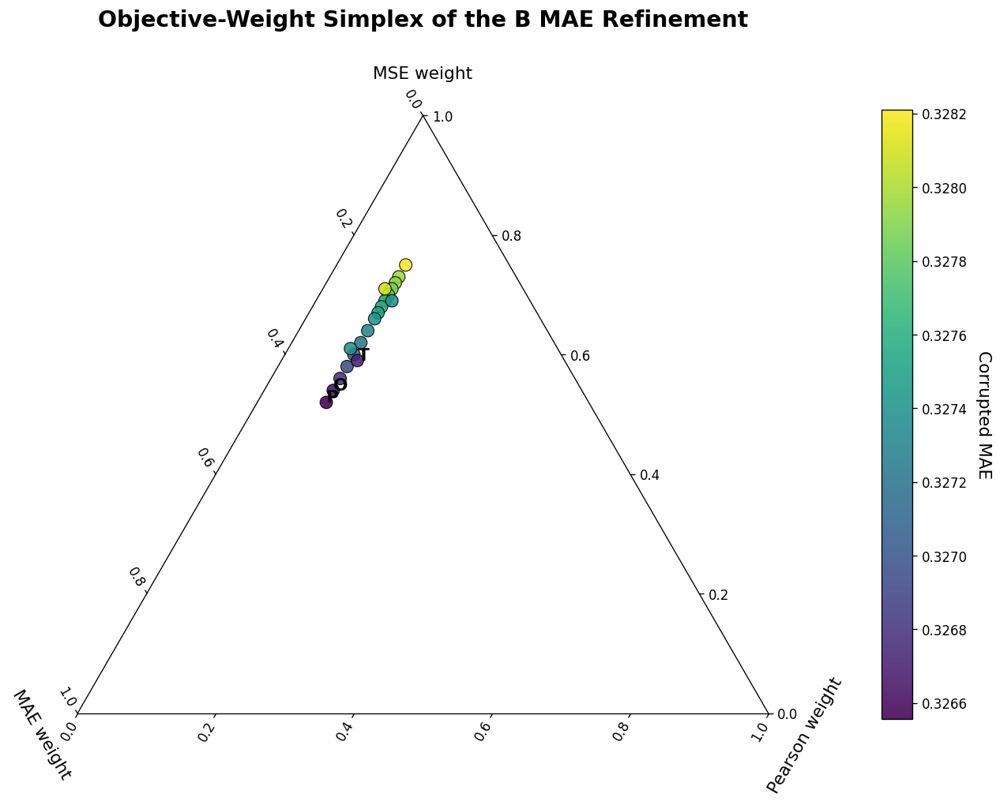

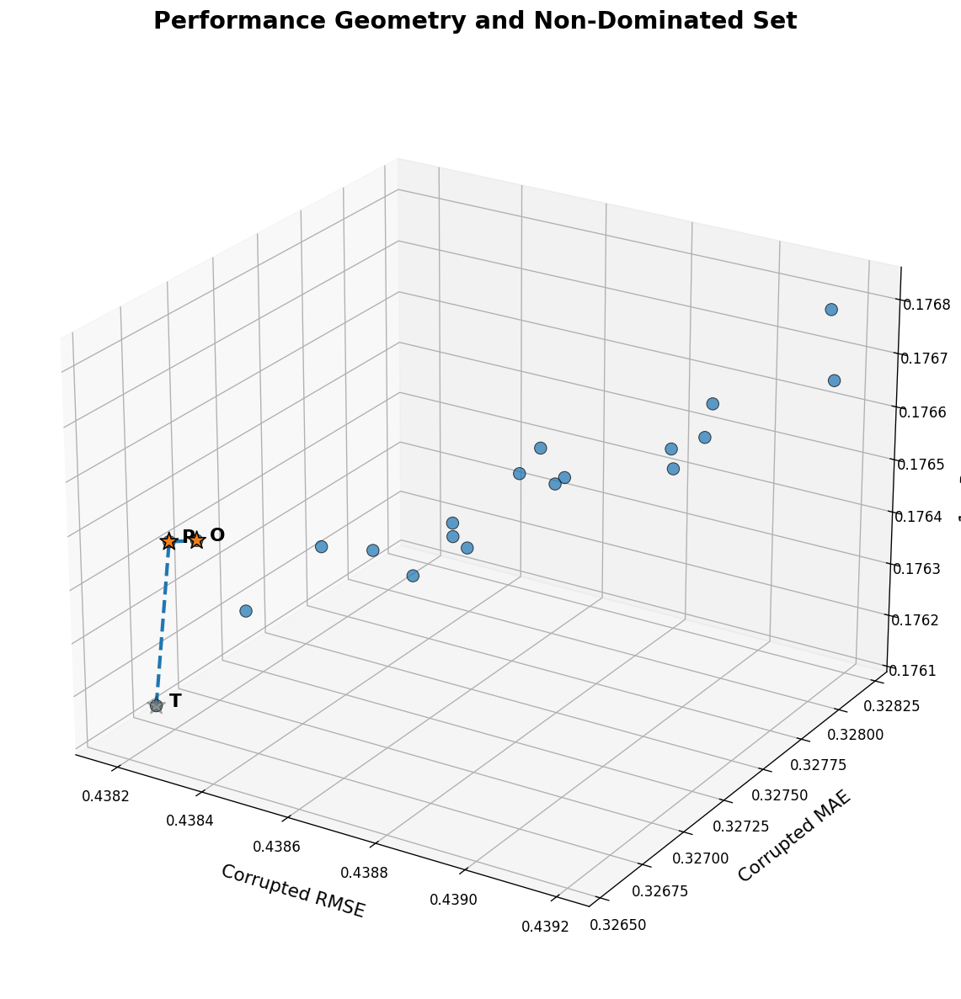

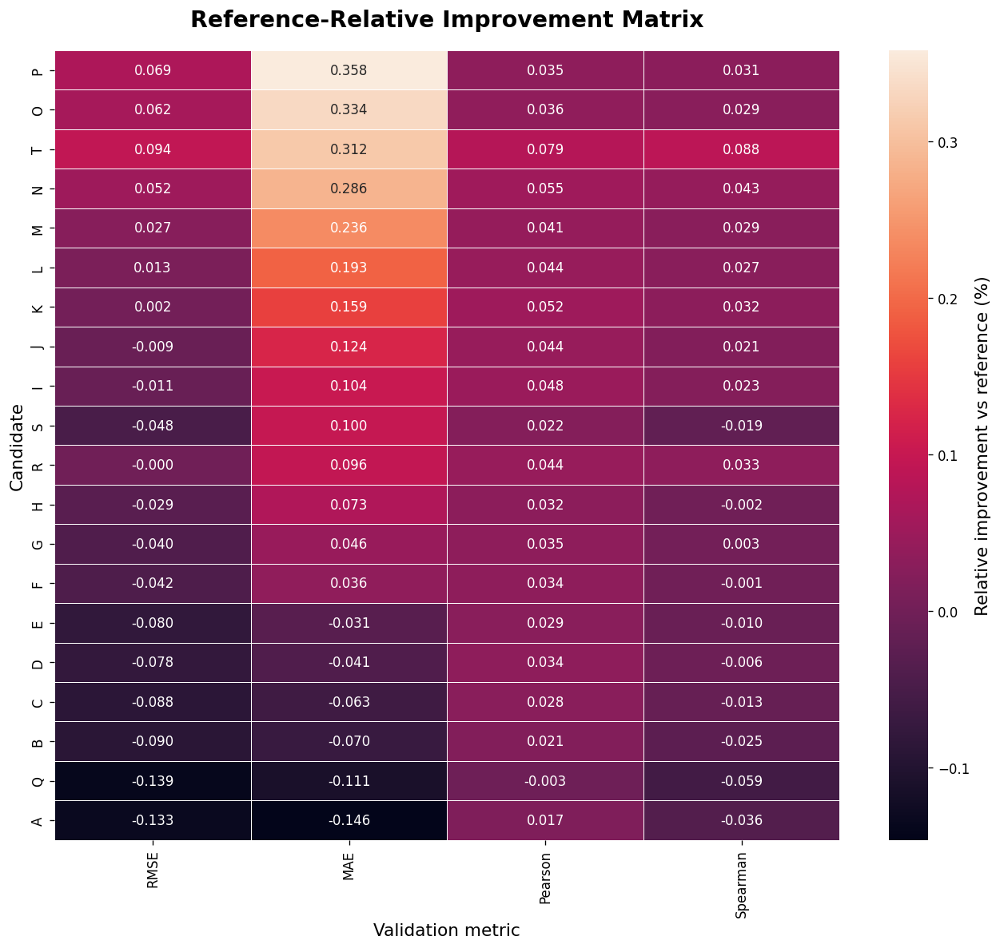

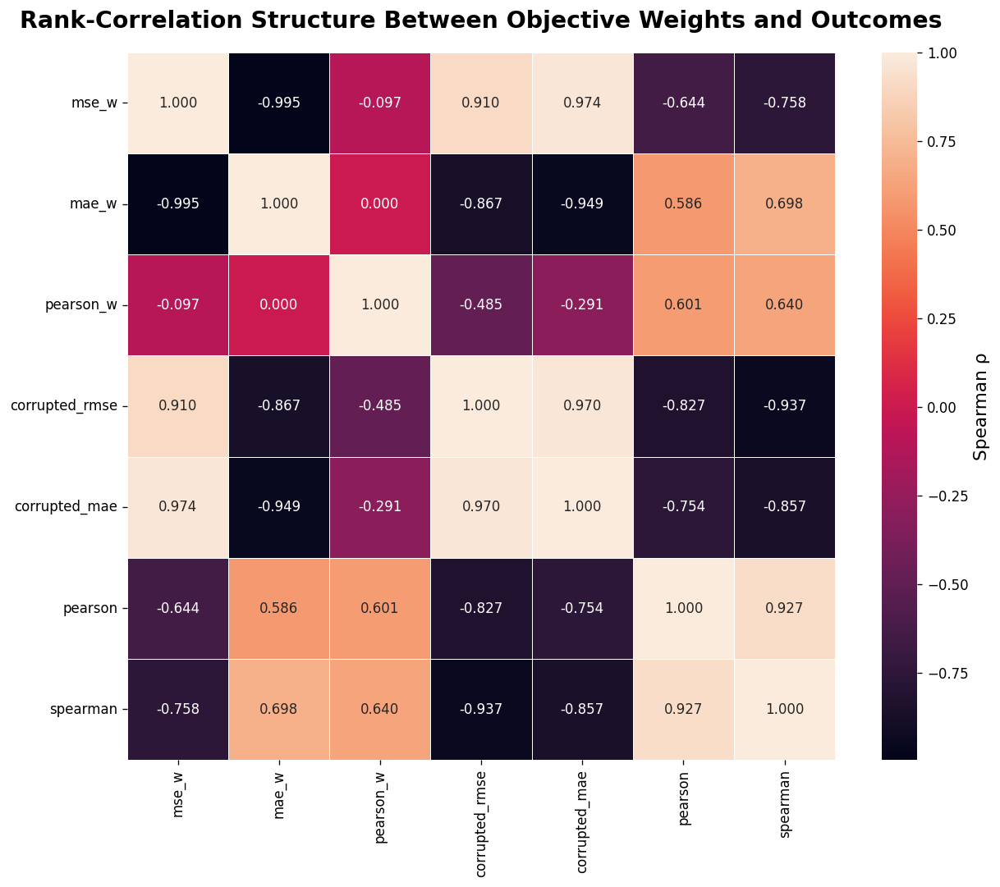

HEF IPIP120 — B MAE TOP-2 REFINEMENT V3
PAPER GEOMETRY LAB
Candidates: 20
Pareto candidates: P, O, T
TEST: RESERVED
CHECKPOINTS: NOT LOADED
TRAINING: NOT EXECUTED

Generated:
FIG1_OBJECTIVE_SIMPLEX
FIG2_PERFORMANCE_MANIFOLD
FIG3_REFERENCE_IMPROVEMENT_HEATMAP
FIG4_WEIGHT_OUTCOME_CORRELATION

Output directory: /content/HEF_IPIP120_B_MAE_REFINEMENT_FIGURES


In [ ]:
%pip install -q mpltern seaborn scipy

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mpltern
from scipy.spatial import ConvexHull
from scipy.stats import spearmanr

OUT = "/content/HEF_IPIP120_B_MAE_REFINEMENT_FIGURES"
os.makedirs(OUT, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 17,
    "axes.labelsize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

df = pd.DataFrame([
    ["A","T_LOWER_MAE15",0.75,0.15,0.10,0.348545,0.439170,0.328210,0.823347,0.790849],
    ["B","T_LOWER_MAE17",0.73,0.17,0.10,0.348175,0.438983,0.327961,0.823379,0.790936],
    ["C","T_CENTER_MAE18",0.72,0.18,0.10,0.348137,0.438975,0.327937,0.823439,0.791029],
    ["D","T_CENTER_MAE19",0.71,0.19,0.10,0.348006,0.438930,0.327865,0.823493,0.791090],
    ["E","T_BASE_MAE20",0.70,0.20,0.10,0.347987,0.438936,0.327833,0.823448,0.791054],
    ["F","T_UP_MAE21",0.69,0.21,0.10,0.347658,0.438773,0.327614,0.823491,0.791130],
    ["G","T_UP_MAE22",0.68,0.22,0.10,0.347579,0.438764,0.327580,0.823498,0.791160],
    ["H","T_UP_MAE23",0.67,0.23,0.10,0.347488,0.438715,0.327493,0.823471,0.791118],
    ["I","T_UP_MAE24",0.66,0.24,0.10,0.347273,0.438634,0.327390,0.823607,0.791317],
    ["J","U_LOWER_MAE26",0.64,0.26,0.10,0.347183,0.438627,0.327323,0.823573,0.791298],
    ["K","U_LOWER_MAE28",0.62,0.28,0.10,0.347004,0.438578,0.327211,0.823634,0.791388],
    ["L","U_BASE_MAE30",0.60,0.30,0.10,0.346836,0.438530,0.327100,0.823573,0.791350],
    ["M","U_UP_MAE32",0.58,0.32,0.10,0.346622,0.438469,0.326957,0.823549,0.791361],
    ["N","U_UP_MAE34",0.56,0.34,0.10,0.346320,0.438358,0.326794,0.823659,0.791472],
    ["O","U_UP_MAE36",0.54,0.36,0.10,0.346212,0.438315,0.326636,0.823503,0.791363],
    ["P","U_UP_MAE38",0.52,0.38,0.10,0.346091,0.438285,0.326557,0.823495,0.791378],
    ["Q","T_PEARSON09_MAE20",0.71,0.20,0.09,0.348419,0.439196,0.328096,0.823189,0.790669],
    ["R","T_PEARSON11_MAE20",0.69,0.20,0.11,0.347336,0.438589,0.327418,0.823575,0.791397],
    ["S","U_PEARSON09_MAE30",0.61,0.30,0.09,0.347319,0.438797,0.327403,0.823389,0.790980],
    ["T","U_PEARSON11_MAE30",0.59,0.30,0.11,0.346189,0.438174,0.326710,0.823862,0.791832]
], columns=[
    "key",
    "objective",
    "mse_w",
    "mae_w",
    "pearson_w",
    "clean_rmse",
    "corrupted_rmse",
    "corrupted_mae",
    "pearson",
    "spearman"
])

reference = {
    "rmse": 0.438587,
    "mae": 0.327731,
    "pearson": 0.823210,
    "spearman": 0.791134
}

pareto_keys = ["P","O","T"]

df["one_minus_pearson"] = 1.0 - df["pearson"]

df["rmse_improvement_pct"] = (
    (reference["rmse"] - df["corrupted_rmse"])
    / reference["rmse"]
    * 100.0
)

df["mae_improvement_pct"] = (
    (reference["mae"] - df["corrupted_mae"])
    / reference["mae"]
    * 100.0
)

df["pearson_improvement_pct"] = (
    (df["pearson"] - reference["pearson"])
    / reference["pearson"]
    * 100.0
)

df["spearman_improvement_pct"] = (
    (df["spearman"] - reference["spearman"])
    / reference["spearman"]
    * 100.0
)

fig1 = plt.figure(figsize=(11, 9))
ax1 = fig1.add_subplot(111, projection="ternary")

scatter = ax1.scatter(
    df["mse_w"],
    df["mae_w"],
    df["pearson_w"],
    c=df["corrupted_mae"],
    s=90,
    alpha=0.88,
    edgecolors="black",
    linewidths=0.7
)

for _, r in df.iterrows():
    if r["key"] in pareto_keys:
        ax1.text(
            r["mse_w"],
            r["mae_w"],
            r["pearson_w"],
            r["key"],
            fontsize=13,
            fontweight="bold"
        )

ax1.set_tlabel("MSE weight")
ax1.set_llabel("MAE weight")
ax1.set_rlabel("Pearson weight")

ax1.set_title(
    "Objective-Weight Simplex of the B MAE Refinement",
    pad=30,
    fontweight="bold"
)

cbar = fig1.colorbar(
    scatter,
    ax=ax1,
    pad=0.12,
    shrink=0.78
)

cbar.set_label(
    "Corrupted MAE",
    rotation=270,
    labelpad=18
)

fig1.tight_layout()

fig1.savefig(
    os.path.join(
        OUT,
        "FIG1_OBJECTIVE_SIMPLEX.png"
    ),
    bbox_inches="tight"
)

fig1.savefig(
    os.path.join(
        OUT,
        "FIG1_OBJECTIVE_SIMPLEX.pdf"
    ),
    bbox_inches="tight"
)

plt.show()


fig2 = plt.figure(figsize=(12, 10))
ax2 = fig2.add_subplot(111, projection="3d")

ax2.scatter(
    df["corrupted_rmse"],
    df["corrupted_mae"],
    df["one_minus_pearson"],
    s=75,
    alpha=0.72,
    edgecolors="black",
    linewidths=0.6
)

pareto = (
    df[df["key"].isin(pareto_keys)]
    .sort_values("corrupted_rmse")
    .copy()
)

ax2.scatter(
    pareto["corrupted_rmse"],
    pareto["corrupted_mae"],
    pareto["one_minus_pearson"],
    s=180,
    marker="*",
    edgecolors="black",
    linewidths=1.0
)

for _, r in pareto.iterrows():
    ax2.text(
        r["corrupted_rmse"],
        r["corrupted_mae"],
        r["one_minus_pearson"],
        f"  {r['key']}",
        fontsize=13,
        fontweight="bold"
    )

pareto_xyz = pareto[
    ["corrupted_rmse", "corrupted_mae", "one_minus_pearson"]
].to_numpy()

if len(pareto_xyz) >= 2:
    order = np.argsort(pareto_xyz[:, 0])
    ordered = pareto_xyz[order]

    ax2.plot(
        ordered[:, 0],
        ordered[:, 1],
        ordered[:, 2],
        linewidth=2.5,
        linestyle="--"
    )

ax2.set_xlabel("Corrupted RMSE", labelpad=12)
ax2.set_ylabel("Corrupted MAE", labelpad=12)
ax2.set_zlabel("1 − Pearson", labelpad=12)

ax2.set_title(
    "Performance Geometry and Non-Dominated Set",
    pad=22,
    fontweight="bold"
)

ax2.view_init(
    elev=24,
    azim=-58
)

fig2.tight_layout()

fig2.savefig(
    os.path.join(
        OUT,
        "FIG2_PERFORMANCE_MANIFOLD.png"
    ),
    bbox_inches="tight"
)

fig2.savefig(
    os.path.join(
        OUT,
        "FIG2_PERFORMANCE_MANIFOLD.pdf"
    ),
    bbox_inches="tight"
)

plt.show()


heat = df[
    [
        "key",
        "rmse_improvement_pct",
        "mae_improvement_pct",
        "pearson_improvement_pct",
        "spearman_improvement_pct"
    ]
].copy()

heat = heat.sort_values(
    "mae_improvement_pct",
    ascending=False
)

heat_matrix = heat.set_index("key")

fig3, ax3 = plt.subplots(
    figsize=(11, 10)
)

sns.heatmap(
    heat_matrix,
    ax=ax3,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={
        "label": "Relative improvement vs reference (%)"
    }
)

ax3.set_title(
    "Reference-Relative Improvement Matrix",
    pad=18,
    fontweight="bold"
)

ax3.set_xlabel("Validation metric")
ax3.set_ylabel("Candidate")

ax3.set_xticklabels([
    "RMSE",
    "MAE",
    "Pearson",
    "Spearman"
])

fig3.tight_layout()

fig3.savefig(
    os.path.join(
        OUT,
        "FIG3_REFERENCE_IMPROVEMENT_HEATMAP.png"
    ),
    bbox_inches="tight"
)

fig3.savefig(
    os.path.join(
        OUT,
        "FIG3_REFERENCE_IMPROVEMENT_HEATMAP.pdf"
    ),
    bbox_inches="tight"
)

plt.show()


corr = df[
    [
        "mse_w",
        "mae_w",
        "pearson_w",
        "corrupted_rmse",
        "corrupted_mae",
        "pearson",
        "spearman"
    ]
].corr(method="spearman")

fig4, ax4 = plt.subplots(
    figsize=(11, 9)
)

sns.heatmap(
    corr,
    ax=ax4,
    annot=True,
    fmt=".3f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman ρ"}
)

ax4.set_title(
    "Rank-Correlation Structure Between Objective Weights and Outcomes",
    pad=18,
    fontweight="bold"
)

fig4.tight_layout()

fig4.savefig(
    os.path.join(
        OUT,
        "FIG4_WEIGHT_OUTCOME_CORRELATION.png"
    ),
    bbox_inches="tight"
)

fig4.savefig(
    os.path.join(
        OUT,
        "FIG4_WEIGHT_OUTCOME_CORRELATION.pdf"
    ),
    bbox_inches="tight"
)

plt.show()


print("=" * 72)
print("HEF IPIP120 — B MAE TOP-2 REFINEMENT V3")
print("PAPER GEOMETRY LAB")
print("=" * 72)
print(f"Candidates: {len(df)}")
print(f"Pareto candidates: {', '.join(pareto_keys)}")
print("TEST: RESERVED")
print("CHECKPOINTS: NOT LOADED")
print("TRAINING: NOT EXECUTED")
print()
print("Generated:")
print("FIG1_OBJECTIVE_SIMPLEX")
print("FIG2_PERFORMANCE_MANIFOLD")
print("FIG3_REFERENCE_IMPROVEMENT_HEATMAP")
print("FIG4_WEIGHT_OUTCOME_CORRELATION")
print()
print(f"Output directory: {OUT}")

In [15]:
from __future__ import annotations
import gc
import json
import math
import random
import time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
ROOT = Path(
    "/content/HEF_IPIP120_ROBUST_DATASET_V3"
)
TRAIN_ROOT = (
    ROOT
    / "TRAIN"
)
VAL_CLEAN_ROOT = (
    ROOT
    / "VALIDATION"
    / "CLEAN"
)
VAL_CORRUPTED_ROOT = (
    ROOT
    / "VALIDATION"
    / "CORRUPTED"
)
PRODUCTION_ROOT = (
    ROOT
    / "MLP_GATEWAY_B_POT_MICROSEARCH_V4"
)
PRODUCTION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)
INPUT_DIM = 120
OUTPUT_DIM = 30
VIEWS_PER_SUBJECT = 143
CLEAN_VIEWS = 3
CORRUPTED_VIEWS_PER_FAMILY = 20
N_CORRUPTION_FAMILIES = 7
EXPECTED_TRAIN_SUBJECTS = 287_263
EXPECTED_TRAIN_EXAMPLES = 41_078_609
B_HIDDEN = (
    192,
    128,
    64,
)
BATCH_SIZE = 8192
MAX_COMPETITION_SUBJECTS = 10_000
COMPETITION_CYCLES = 1
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.10
GRAD_CLIP_NORM = 1.0
USE_BF16 = True
MAX_EPOCHS = 120
MIN_EPOCHS = 5
EARLY_STOP_PATIENCE = 3
EARLY_STOP_MIN_DELTA = 1e-4
SAVE_EVERY_EPOCH = True
GLOBAL_SEED = 20260920
SIES_SEED = 20262026
assert torch.cuda.is_available()
DEVICE = torch.device(
    "cuda"
)
torch.set_float32_matmul_precision(
    "high"
)
def seed_everything(
    seed: int,
) -> None:
    random.seed(
        seed
    )
    np.random.seed(
        seed
    )
    torch.manual_seed(
        seed
    )
    torch.cuda.manual_seed_all(
        seed
    )
seed_everything(
    GLOBAL_SEED
)
print()
print("=" * 110)
print(
    "HEF IPIP120 ROBUST — B P/O/T MICROSEARCH V4"
)
print("=" * 110)
print(
    "DEVICE                    :",
    torch.cuda.get_device_name(0),
)
print(
    "ARCHITECTURE              : B COMPACT"
)
print(
    "ARCHITECTURE              :",
    f"{INPUT_DIM} -> 192 -> 128 -> 64 -> {OUTPUT_DIM}",
)
print(
    "OBJECTIVE                 : P/O/T FOCUSED MICROSEARCH"
)
print(
    "FULL TRAIN SUBJECTS       :",
    f"{EXPECTED_TRAIN_SUBJECTS:,}",
)
print(
    "COMPETITION SUBJECTS      :",
    f"{MAX_COMPETITION_SUBJECTS:,}",
)
print(
    "TRAIN EXAMPLES            :",
    f"{EXPECTED_TRAIN_EXAMPLES:,}",
)
print(
    "VIEWS / SUBJECT           :",
    VIEWS_PER_SUBJECT,
)
print(
    "BATCH SIZE                :",
    BATCH_SIZE,
)
print(
    "LEARNING RATE             :",
    LEARNING_RATE,
)
print(
    "WEIGHT DECAY              :",
    WEIGHT_DECAY,
)
print(
    "DROPOUT                   :",
    DROPOUT,
)
print(
    "SIES CYCLES              :",
    COMPETITION_CYCLES,
)

print(
    "TEST                      : RESERVED"
)
print("=" * 110)
def discover_train_shards(
    root: Path,
):
    paths = sorted(
        root.glob(
            "shard_*_X.npy"
        )
    )
    if not paths:
        raise FileNotFoundError(
            f"No TRAIN X shards found in {root}"
        )
    return paths
TRAIN_X_SHARDS = (
    discover_train_shards(
        TRAIN_ROOT
    )
)
print()
print(
    "TRAIN SHARDS             :",
    len(
        TRAIN_X_SHARDS
    )
)
SHARD_INDEX = []
global_subject_cursor = 0
global_row_cursor = 0
for shard_id, x_path in enumerate(
    TRAIN_X_SHARDS
):
    x_mm = np.load(
        x_path,
        mmap_mode="r",
    )
    if x_mm.ndim != 2:
        raise RuntimeError(
            f"Invalid X ndim in {x_path}: {x_mm.shape}"
        )
    if x_mm.shape[1] != INPUT_DIM:
        raise RuntimeError(
            f"Invalid X shape in {x_path}: {x_mm.shape}"
        )
    n_rows = int(
        x_mm.shape[0]
    )
    if (
        n_rows
        % VIEWS_PER_SUBJECT
        != 0
    ):
        raise RuntimeError(
            f"Shard is not subject aligned: "
            f"{x_path} -> {n_rows}"
        )
    n_subjects = (
        n_rows
        // VIEWS_PER_SUBJECT
    )
    SHARD_INDEX.append(
        {
            "shard_id": shard_id,
            "x_path": x_path,
            "n_rows": n_rows,
            "n_subjects": n_subjects,
            "subject_start": global_subject_cursor,
            "subject_end": (
                global_subject_cursor
                + n_subjects
            ),
            "row_start": global_row_cursor,
            "row_end": (
                global_row_cursor
                + n_rows
            ),
        }
    )
    global_subject_cursor += (
        n_subjects
    )
    global_row_cursor += (
        n_rows
    )
N_TRAIN_SUBJECTS = (
    global_subject_cursor
)
N_TRAIN_EXAMPLES = (
    global_row_cursor
)
assert (
    N_TRAIN_SUBJECTS
    == EXPECTED_TRAIN_SUBJECTS
), (
    N_TRAIN_SUBJECTS,
    EXPECTED_TRAIN_SUBJECTS,
)
assert (
    N_TRAIN_EXAMPLES
    == EXPECTED_TRAIN_EXAMPLES
), (
    N_TRAIN_EXAMPLES,
    EXPECTED_TRAIN_EXAMPLES,
)
assert (
    N_TRAIN_SUBJECTS
    * VIEWS_PER_SUBJECT
    == N_TRAIN_EXAMPLES
)
print(
    "TRAIN SUBJECTS           :",
    f"{N_TRAIN_SUBJECTS:,}",
)
print(
    "TRAIN EXAMPLES           :",
    f"{N_TRAIN_EXAMPLES:,}",
)
print(
    "DATASET SIZE ASSERTION   : PASS"
)
TRAIN_MEMMAPS = []
TRAIN_Y_MEMMAPS = []
TRAIN_TYPE_MEMMAPS = []
TRAIN_SEVERITY_MEMMAPS = []
for shard in SHARD_INDEX:
    x_path = shard[
        "x_path"
    ]
    y_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_Y.npy",
        )
    )
    type_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_type.npy",
        )
    )
    severity_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_severity.npy",
        )
    )
    for required_path in (
        y_path,
        type_path,
        severity_path,
    ):
        if not required_path.exists():
            raise FileNotFoundError(
                required_path
            )
    TRAIN_MEMMAPS.append(
        np.load(
            x_path,
            mmap_mode="r",
        )
    )
    TRAIN_Y_MEMMAPS.append(
        np.load(
            y_path,
            mmap_mode="r",
        )
    )
    TRAIN_TYPE_MEMMAPS.append(
        np.load(
            type_path,
            mmap_mode="r",
        )
    )
    TRAIN_SEVERITY_MEMMAPS.append(
        np.load(
            severity_path,
            mmap_mode="r",
        )
    )
print(
    "TRAIN MEMMAPS            : READY"
)
SHARD_SUBJECT_ENDS = np.asarray(
    [
        shard[
            "subject_end"
        ]
        for shard in SHARD_INDEX
    ],
    dtype=np.int64,
)
def locate_subjects(
    subject_ids: np.ndarray,
):
    shard_ids = np.searchsorted(
        SHARD_SUBJECT_ENDS,
        subject_ids,
        side="right",
    )
    local_subject_ids = (
        subject_ids
        - np.asarray(
            [
                SHARD_INDEX[
                    int(
                        shard_id
                    )
                ][
                    "subject_start"
                ]
                for shard_id in shard_ids
            ],
            dtype=np.int64,
        )
    )
    return (
        shard_ids,
        local_subject_ids,
    )
def fetch_train_batch(
    subject_ids,
    view_ids,
):
    subject_ids = np.asarray(
        subject_ids,
        dtype=np.int64,
    )
    view_ids = np.asarray(
        view_ids,
        dtype=np.int64,
    )
    if len(subject_ids) != len(view_ids):
        raise RuntimeError(
            "subject_ids and view_ids length mismatch."
        )
    if (
        len(
            np.unique(
                subject_ids
            )
        )
        != len(subject_ids)
    ):
        raise RuntimeError(
            "SIES violation: duplicate subject in batch."
        )
    if np.any(
        view_ids < 0
    ) or np.any(
        view_ids >= VIEWS_PER_SUBJECT
    ):
        raise RuntimeError(
            "Invalid view index."
        )
    shard_ids, local_subjects = (
        locate_subjects(
            subject_ids
        )
    )
    batch_n = len(
        subject_ids
    )
    batch_x = np.empty(
        (
            batch_n,
            INPUT_DIM,
        ),
        dtype=np.uint8,
    )
    batch_y = np.empty(
        (
            batch_n,
            OUTPUT_DIM,
        ),
        dtype=np.float32,
    )
    for shard_id in np.unique(
        shard_ids
    ):
        positions = np.flatnonzero(
            shard_ids
            == shard_id
        )
        local_rows = (
            local_subjects[
                positions
            ]
            * VIEWS_PER_SUBJECT
            + view_ids[
                positions
            ]
        )
        x_mm = TRAIN_MEMMAPS[
            int(shard_id)
        ]
        y_mm = TRAIN_Y_MEMMAPS[
            int(shard_id)
        ]
        batch_x[
            positions
        ] = np.asarray(
            x_mm[
                local_rows
            ],
            dtype=np.uint8,
        )
        batch_y[
            positions
        ] = np.asarray(
            y_mm[
                local_rows
            ],
            dtype=np.float32,
        )
    assert batch_x.shape == (
        batch_n,
        INPUT_DIM,
    )
    assert batch_y.shape == (
        batch_n,
        OUTPUT_DIM,
    )
    return (
        batch_x,
        batch_y,
    )
def audit_train_store(
    sample_size: int = 4096,
):
    rng = np.random.default_rng(
        20260920
    )
    sample_size = min(
        sample_size,
        N_TRAIN_SUBJECTS,
    )
    sampled_subjects = rng.choice(
        N_TRAIN_SUBJECTS,
        size=sample_size,
        replace=False,
    )
    sampled_subjects.sort()
    sampled_shards, sampled_local = (
        locate_subjects(
            sampled_subjects
        )
    )
    for shard_id in np.unique(
        sampled_shards
    ):
        positions = np.flatnonzero(
            sampled_shards
            == shard_id
        )
        local_subject_ids = (
            sampled_local[
                positions
            ]
        )
        x_mm = TRAIN_MEMMAPS[
            int(shard_id)
        ]
        type_mm = TRAIN_TYPE_MEMMAPS[
            int(shard_id)
        ]
        for local_subject in local_subject_ids:
            s = (
                int(local_subject)
                * VIEWS_PER_SUBJECT
            )
            e = (
                s
                + VIEWS_PER_SUBJECT
            )
            subject_type = np.asarray(
                type_mm[
                    s:e
                ],
                dtype=np.uint8,
            )
            counts = np.bincount(
                subject_type,
                minlength=8,
            )
            if counts[0] != 3:
                raise RuntimeError(
                    f"CLEAN count violation: {local_subject}"
                )
            for code in range(
                1,
                8,
            ):
                if counts[code] != 20:
                    raise RuntimeError(
                        f"Family count violation: "
                        f"subject={local_subject}, "
                        f"code={code}, "
                        f"count={counts[code]}"
                    )
            sample_x = x_mm[
                s:e
            ]
            assert sample_x.shape == (
                VIEWS_PER_SUBJECT,
                INPUT_DIM,
            )
    print(
        "TRAIN subject-block audit : PASS"
    )
    print(
        "143-view structure        : PASS"
    )
audit_train_store()
def discover_split_shards(
    root: Path,
):
    paths = sorted(
        root.glob(
            "shard_*_X.npy"
        )
    )
    if not paths:
        raise FileNotFoundError(
            f"No validation shards found in {root}"
        )
    return paths
def load_flat_validation(
    root: Path,
):
    shards = discover_split_shards(
        root
    )
    xs = []
    ys = []
    types = []
    severities = []
    targets = []
    for x_path in shards:
        y_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_Y.npy",
            )
        )
        type_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_type.npy",
            )
        )
        severity_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_severity.npy",
            )
        )
        target_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_target.npy",
            )
        )
        X = np.load(
            x_path
        )
        Y = np.load(
            y_path
        )
        T = np.load(
            type_path
        )
        S = np.load(
            severity_path
        )
        target = np.load(
            target_path
        )
        xs.append(
            X.astype(
                np.uint8,
                copy=False,
            )
        )
        ys.append(
            Y.astype(
                np.float32,
                copy=False,
            )
        )
        types.append(
            T.astype(
                np.uint8,
                copy=False,
            )
        )
        severities.append(
            S.astype(
                np.uint8,
                copy=False,
            )
        )
        targets.append(
            target.astype(
                np.int32,
                copy=False,
            )
        )
    X = np.concatenate(
        xs,
        axis=0,
    )
    Y = np.concatenate(
        ys,
        axis=0,
    )
    T = np.concatenate(
        types,
        axis=0,
    )
    S = np.concatenate(
        severities,
        axis=0,
    )
    target = np.concatenate(
        targets,
        axis=0,
    )
    assert X.ndim == 2
    assert X.shape[1] == INPUT_DIM
    assert Y.ndim == 2
    assert Y.shape[1] == OUTPUT_DIM
    assert T.ndim == 1
    assert S.ndim == 1
    assert target.ndim == 1
    assert len(X) == len(Y)
    assert len(X) == len(T)
    assert len(X) == len(S)
    assert len(X) == len(target)
    return (
        X,
        Y,
        T,
        S,
        target,
    )
(
    VAL_CLEAN_X,
    VAL_CLEAN_Y,
    VAL_CLEAN_TYPE,
    VAL_CLEAN_SEVERITY,
    VAL_CLEAN_TARGET,
) = load_flat_validation(
    VAL_CLEAN_ROOT
)
(
    VAL_CORRUPTED_X,
    VAL_CORRUPTED_Y,
    VAL_CORRUPTED_TYPE,
    VAL_CORRUPTED_SEVERITY,
    VAL_CORRUPTED_TARGET,
) = load_flat_validation(
    VAL_CORRUPTED_ROOT
)
print()
print("=" * 110)
print("VALIDATION")
print("=" * 110)
print(
    "CLEAN                    :",
    f"{len(VAL_CLEAN_X):,}",
)
print(
    "CORRUPTED                :",
    f"{len(VAL_CORRUPTED_X):,}",
)
print(
    "TOTAL                    :",
    f"{len(VAL_CLEAN_X) + len(VAL_CORRUPTED_X):,}",
)
print(
    "VALIDATION DATA          : PASS"
)
class HEFIPIP120MLP(
    nn.Module
):
    def __init__(
        self,
    ):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(
                INPUT_DIM,
                192,
            ),
            nn.LayerNorm(
                192
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
            nn.Linear(
                192,
                128,
            ),
            nn.LayerNorm(
                128
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
            nn.Linear(
                128,
                64,
            ),
            nn.LayerNorm(
                64
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
        )
        self.output = nn.Linear(
            64,
            OUTPUT_DIM,
        )
    def forward(
        self,
        x,
    ):
        x = (
            x
            - 3.0
        ) / 2.0
        h = self.trunk(
            x
        )
        return self.output(
            h
        )
def pearson_profile_loss(
    prediction,
    target,
):
    prediction = prediction.float()
    target = target.float()
    p = (
        prediction
        - prediction.mean(
            dim=1,
            keepdim=True,
        )
    )
    y = (
        target
        - target.mean(
            dim=1,
            keepdim=True,
        )
    )
    numerator = (
        p * y
    ).sum(
        dim=1
    )
    denominator = (
        torch.sqrt(
            torch.sum(
                p * p,
                dim=1,
            )
            + 1e-8
        )
        *
        torch.sqrt(
            torch.sum(
                y * y,
                dim=1,
            )
            + 1e-8
        )
    )
    correlation = (
        numerator
        / denominator
    )
    return (
        1.0
        - correlation
    ).mean()


def pearson_profile_loss(
    prediction,
    target,
):
    prediction = prediction.float()
    target = target.float()
    p = prediction - prediction.mean(dim=1, keepdim=True)
    y = target - target.mean(dim=1, keepdim=True)
    numerator = (p * y).sum(dim=1)
    denominator = (
        torch.sqrt((p * p).sum(dim=1) + 1e-8)
        * torch.sqrt((y * y).sum(dim=1) + 1e-8)
    )
    correlation = numerator / denominator
    return (1.0 - correlation).mean()


def huber_loss(
    prediction,
    target,
    delta,
):
    diff = (prediction.float() - target.float()).abs()
    quadratic = torch.minimum(
        diff,
        torch.tensor(delta, device=diff.device, dtype=diff.dtype),
    )
    linear = diff - quadratic
    return (0.5 * quadratic * quadratic + delta * linear).mean()


def log_cosh_loss(
    prediction,
    target,
):
    diff = prediction.float() - target.float()
    return (F.softplus(2.0 * diff) - diff - math.log(2.0)).mean()


def objective_from_config(
    prediction,
    target,
    config,
):
    prediction_f32 = prediction.float()
    target_f32 = target.float()
    mse = F.mse_loss(
        prediction_f32,
        target_f32,
    )
    mae = F.l1_loss(
        prediction_f32,
        target_f32,
    )
    pearson = pearson_profile_loss(
        prediction_f32,
        target_f32,
    )
    huber = huber_loss(
        prediction_f32,
        target_f32,
        float(config.get("huber_delta", 0.5)),
    )
    logcosh = log_cosh_loss(
        prediction_f32,
        target_f32,
    )
    loss = (
        float(config.get("mse", 0.0)) * mse
        + float(config.get("mae", 0.0)) * mae
        + float(config.get("pearson", 0.0)) * pearson
        + float(config.get("huber", 0.0)) * huber
        + float(config.get("logcosh", 0.0)) * logcosh
    )
    return (
        loss,
        mse.detach(),
        mae.detach(),
        pearson.detach(),
        huber.detach(),
        logcosh.detach(),
    )
def metric_rmse(
    prediction,
    target,
):
    diff = (
        prediction.astype(
            np.float64,
        )
        -
        target.astype(
            np.float64,
        )
    )
    return float(
        np.sqrt(
            np.mean(
                diff * diff
            )
        )
    )
def metric_mae(
    prediction,
    target,
):
    diff = (
        prediction.astype(
            np.float64,
        )
        -
        target.astype(
            np.float64,
        )
    )
    return float(
        np.mean(
            np.abs(
                diff
            )
        )
    )
def metric_pearson(
    prediction,
    target,
):
    p = prediction.astype(
        np.float64,
        copy=False,
    ).reshape(-1)
    y = target.astype(
        np.float64,
        copy=False,
    ).reshape(-1)
    p = p - p.mean()
    y = y - y.mean()
    denominator = (
        np.sqrt(
            np.sum(
                p * p
            )
        )
        *
        np.sqrt(
            np.sum(
                y * y
            )
        )
    )
    if denominator <= 0:
        return float(
            "nan"
        )
    return float(
        np.sum(
            p * y
        )
        / denominator
    )
def metric_spearman(
    prediction,
    target,
):
    p = pd.Series(
        prediction.reshape(-1)
    ).rank(
        method="average"
    ).to_numpy()
    y = pd.Series(
        target.reshape(-1)
    ).rank(
        method="average"
    ).to_numpy()
    return metric_pearson(
        p,
        y,
    )
@torch.no_grad()
def predict_validation(
    model,
    X,
    batch_size=32768,
):
    model.eval()
    predictions = []
    for start in range(
        0,
        len(X),
        batch_size,
    ):
        end = min(
            start
            + batch_size,
            len(X),
        )
        xb = torch.from_numpy(
            np.asarray(
                X[
                    start:end
                ],
                dtype=np.uint8,
            )
        ).to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True,
        )
        if USE_BF16:
            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16,
            ):
                pred = model(
                    xb
                )
        else:
            pred = model(
                xb
            )
        predictions.append(
            pred.float()
            .cpu()
            .numpy()
        )
    return np.concatenate(
        predictions,
        axis=0,
    )
def evaluate_validation(
    model,
):
    clean_pred = predict_validation(
        model,
        VAL_CLEAN_X,
    )
    corrupted_pred = predict_validation(
        model,
        VAL_CORRUPTED_X,
    )
    clean_rmse = metric_rmse(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_mae = metric_mae(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_pearson = metric_pearson(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_spearman = metric_spearman(
        clean_pred,
        VAL_CLEAN_Y,
    )
    corrupted_rmse = metric_rmse(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_mae = metric_mae(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_pearson = metric_pearson(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_spearman = metric_spearman(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    family_names = {
        1: "ITEM_SWAP",
        2: "FACET_SWAP",
        3: "CATEGORY_PARTIAL_SWAP",
        4: "CATEGORY_SWAP",
        5: "ITEM_COLLAPSE",
        6: "CATEGORY_COLLAPSE",
        7: "RANDOM_ITEM_CHANGE",
    }
    family_metrics = {}
    for code, family_name in (
        family_names.items()
    ):
        mask = (
            VAL_CORRUPTED_TYPE
            == code
        )
        if not np.any(
            mask
        ):
            continue
        family_metrics[
            family_name
        ] = metric_rmse(
            corrupted_pred[
                mask
            ],
            VAL_CORRUPTED_Y[
                mask
            ],
        )
    severity_metrics = {}
    for severity in np.unique(
        VAL_CORRUPTED_SEVERITY
    ):
        mask = (
            VAL_CORRUPTED_SEVERITY
            == severity
        )
        severity_metrics[
            int(severity)
        ] = metric_rmse(
            corrupted_pred[
                mask
            ],
            VAL_CORRUPTED_Y[
                mask
            ],
        )
    all_pred = np.concatenate(
        [
            clean_pred,
            corrupted_pred,
        ],
        axis=0,
    )
    all_target = np.concatenate(
        [
            VAL_CLEAN_Y,
            VAL_CORRUPTED_Y,
        ],
        axis=0,
    )
    output_min = float(
        all_pred.min()
    )
    output_max = float(
        all_pred.max()
    )
    out_of_range = float(
        np.mean(
            (
                all_pred < 1.0
            )
            |
            (
                all_pred > 5.0
            )
        )
    )
    return {
        "clean_rmse": clean_rmse,
        "clean_mae": clean_mae,
        "clean_pearson": clean_pearson,
        "clean_spearman": clean_spearman,
        "corrupted_rmse": corrupted_rmse,
        "corrupted_mae": corrupted_mae,
        "corrupted_pearson": corrupted_pearson,
        "corrupted_spearman": corrupted_spearman,
        "family_metrics": family_metrics,
        "severity_metrics": severity_metrics,
        "output_min": output_min,
        "output_max": output_max,
        "out_of_range_fraction": out_of_range,
    }


COMPETITION_DIR = PRODUCTION_ROOT
CHECKPOINT_DIR = COMPETITION_DIR / "CHECKPOINTS"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

COMPETITION_SUBJECT_IDS = np.arange(
    MAX_COMPETITION_SUBJECTS,
    dtype=np.int64,
)
assert len(COMPETITION_SUBJECT_IDS) == MAX_COMPETITION_SUBJECTS
assert np.all(COMPETITION_SUBJECT_IDS < N_TRAIN_SUBJECTS)

SIES_RANK_BASE = np.random.default_rng(
    SIES_SEED
).integers(
    0,
    VIEWS_PER_SUBJECT,
    size=MAX_COMPETITION_SUBJECTS,
    dtype=np.int16,
)
COMPETITION_RNG = np.random.default_rng(SIES_SEED)
COMPETITION_SCHEDULE = []
for round_id in range(VIEWS_PER_SUBJECT):
    subject_order = COMPETITION_RNG.permutation(
        COMPETITION_SUBJECT_IDS
    ).astype(np.int64, copy=False)
    COMPETITION_SCHEDULE.append(subject_order)

ANCHORS = {
    "P": {"name": "P_U_UP_MAE38", "mse": 0.52, "mae": 0.38, "pearson": 0.10},
    "O": {"name": "O_U_UP_MAE36", "mse": 0.54, "mae": 0.36, "pearson": 0.10},
    "T": {"name": "T_U_PEARSON11_MAE30", "mse": 0.59, "mae": 0.30, "pearson": 0.11},
}


def build_pot_microsearch_configs():
    configs = []
    seen = set()

    def add_config(mse, mae, pearson, name):
        mse = round(float(mse), 3)
        mae = round(float(mae), 3)
        pearson = round(float(pearson), 3)
        total = round(mse + mae + pearson, 3)
        if abs(total - 1.0) > 1e-6:
            return
        if mse <= 0 or mae <= 0 or pearson <= 0:
            return
        if not (0.20 <= mae <= 0.42):
            return
        if not (0.48 <= mse <= 0.64):
            return
        if not (0.085 <= pearson <= 0.125):
            return
        key = (mse, mae, pearson)
        if key in seen:
            return
        seen.add(key)
        idx = len(configs) + 1
        configs.append({
            "key": f"V{idx:03d}",
            "name": name,
            "mse": mse,
            "mae": mae,
            "pearson": pearson,
        })

    for anchor_key, anchor in ANCHORS.items():
        for dmse in np.arange(-0.04, 0.0401, 0.01):
            for dpearson in np.arange(-0.015, 0.0151, 0.005):
                mse = anchor["mse"] + float(dmse)
                pearson = anchor["pearson"] + float(dpearson)
                mae = 1.0 - mse - pearson
                add_config(
                    mse,
                    mae,
                    pearson,
                    f"{anchor_key}_LOCAL_M{dmse:+.2f}_P{dpearson:+.3f}",
                )

    for mse in np.arange(0.50, 0.621, 0.01):
        for pearson in np.arange(0.09, 0.1201, 0.005):
            mae = 1.0 - float(mse) - float(pearson)
            add_config(
                mse,
                mae,
                pearson,
                f"GRID_M{mse:.2f}_A{mae:.3f}_P{pearson:.3f}",
            )

    for a_key, a in ANCHORS.items():
        for b_key, b in ANCHORS.items():
            if a_key >= b_key:
                continue
            for alpha in np.arange(0.10, 1.00, 0.10):
                mse = alpha * a["mse"] + (1.0 - alpha) * b["mse"]
                mae = alpha * a["mae"] + (1.0 - alpha) * b["mae"]
                pearson = alpha * a["pearson"] + (1.0 - alpha) * b["pearson"]
                add_config(
                    mse,
                    mae,
                    pearson,
                    f"MIX_{a_key}{b_key}_{int(round(alpha*100)):02d}",
                )

    for wp in np.arange(0.0, 1.0001, 0.20):
        for wo in np.arange(0.0, 1.0001 - wp, 0.20):
            wt = 1.0 - wp - wo
            if wt < -1e-9:
                continue
            mse = (
                wp * ANCHORS["P"]["mse"]
                + wo * ANCHORS["O"]["mse"]
                + wt * ANCHORS["T"]["mse"]
            )
            mae = (
                wp * ANCHORS["P"]["mae"]
                + wo * ANCHORS["O"]["mae"]
                + wt * ANCHORS["T"]["mae"]
            )
            pearson = (
                wp * ANCHORS["P"]["pearson"]
                + wo * ANCHORS["O"]["pearson"]
                + wt * ANCHORS["T"]["pearson"]
            )
            add_config(
                mse,
                mae,
                pearson,
                f"TRI_P{int(round(wp*100)):02d}_O{int(round(wo*100)):02d}_T{int(round(wt*100)):02d}",
            )

    def anchor_distance(config):
        distances = []
        for anchor in ANCHORS.values():
            distances.append(
                (
                    ((config["mse"] - anchor["mse"]) / 0.05) ** 2
                    + ((config["mae"] - anchor["mae"]) / 0.05) ** 2
                    + ((config["pearson"] - anchor["pearson"]) / 0.02) ** 2
                ) ** 0.5
            )
        return min(distances)

    configs.sort(key=lambda c: anchor_distance(c))
    for idx, config in enumerate(configs, start=1):
        config["key"] = f"V{idx:03d}"
    return configs


LOSS_CONFIGS = build_pot_microsearch_configs()

REFERENCE = {
    "corrupted_rmse": 0.438587,
    "corrupted_mae": 0.327731,
    "corrupted_pearson": 0.823210,
    "corrupted_spearman": 0.791134,
}
REFERENCE_TOL_RMSE = 0.002000
REFERENCE_TOL_PEARSON = 0.002000
REFERENCE_TOL_SPEARMAN = 0.002000

ANCHOR_BEST_TARGET = {
    "corrupted_rmse": min(v["corrupted_rmse"] for v in {
        "P": {"corrupted_rmse": 0.438285},
        "O": {"corrupted_rmse": 0.438315},
        "T": {"corrupted_rmse": 0.438174},
    }.values()),
    "corrupted_mae": min(v["corrupted_mae"] for v in {
        "P": {"corrupted_mae": 0.326557},
        "O": {"corrupted_mae": 0.326636},
        "T": {"corrupted_mae": 0.326710},
    }.values()),
    "corrupted_pearson": max(v["corrupted_pearson"] for v in {
        "P": {"corrupted_pearson": 0.823495},
        "O": {"corrupted_pearson": 0.823503},
        "T": {"corrupted_pearson": 0.823862},
    }.values()),
    "corrupted_spearman": max(v["corrupted_spearman"] for v in {
        "P": {"corrupted_spearman": 0.791378},
        "O": {"corrupted_spearman": 0.791363},
        "T": {"corrupted_spearman": 0.791832},
    }.values()),
}

ANCHOR_TARGET_TOL_RMSE = 0.000000
ANCHOR_TARGET_TOL_MAE = 0.000000
ANCHOR_TARGET_TOL_PEARSON = 0.000000
ANCHOR_TARGET_TOL_SPEARMAN = 0.000000

SIES_RANK_BASE = np.random.default_rng(
    SIES_SEED
).integers(
    0,
    VIEWS_PER_SUBJECT,
    size=MAX_COMPETITION_SUBJECTS,
    dtype=np.int16,
)

EXPECTED_SUBJECT_BLOCK_EXAMPLES = (
    MAX_COMPETITION_SUBJECTS * VIEWS_PER_SUBJECT
)


def train_competition_candidate(config):
    seed_everything(GLOBAL_SEED)
    model = HEFIPIP120MLP().to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    parameters = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    epoch_start = time.perf_counter()
    epoch_examples = 0
    epoch_steps = 0
    epoch_loss_sum = 0.0
    epoch_mse_sum = 0.0
    epoch_mae_sum = 0.0
    epoch_pearson_sum = 0.0
    epoch_huber_sum = 0.0
    epoch_logcosh_sum = 0.0
    round_logs = []
    for round_id, subject_order in enumerate(
        COMPETITION_SCHEDULE
    ):
        selected_views = (
            SIES_RANK_BASE[subject_order] + round_id
        ) % VIEWS_PER_SUBJECT
        for start in range(
            0,
            MAX_COMPETITION_SUBJECTS,
            BATCH_SIZE,
        ):
            end = min(
                start + BATCH_SIZE,
                MAX_COMPETITION_SUBJECTS,
            )
            batch_subjects = subject_order[start:end]
            batch_views = selected_views[start:end]
            if len(np.unique(batch_subjects)) != len(batch_subjects):
                raise RuntimeError(
                    "SIES violation: duplicate subject in competition batch."
                )
            batch_x_np, batch_y_np = fetch_train_batch(
                batch_subjects,
                batch_views,
            )
            xb = torch.from_numpy(batch_x_np).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            yb = torch.from_numpy(batch_y_np).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            optimizer.zero_grad(set_to_none=True)
            if USE_BF16:
                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.bfloat16,
                ):
                    prediction = model(xb)
                    loss, mse_component, mae_component, pearson_component, huber_component, logcosh_component = objective_from_config(
                        prediction,
                        yb,
                        config,
                    )
            else:
                prediction = model(xb)
                loss, mse_component, mae_component, pearson_component, huber_component, logcosh_component = objective_from_config(
                    prediction,
                    yb,
                    config,
                )
            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss for {config['key']} at round={round_id}"
                )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )
            optimizer.step()
            n = len(batch_x_np)
            epoch_examples += n
            epoch_steps += 1
            epoch_loss_sum += float(loss.detach().item()) * n
            epoch_mse_sum += float(mse_component.item()) * n
            epoch_mae_sum += float(mae_component.item()) * n
            epoch_pearson_sum += float(pearson_component.item()) * n
            epoch_huber_sum += float(huber_component.item()) * n
            epoch_logcosh_sum += float(logcosh_component.item()) * n
        if (
            round_id == 0
            or (round_id + 1) % 10 == 0
            or round_id + 1 == VIEWS_PER_SUBJECT
        ):
            elapsed = time.perf_counter() - epoch_start
            throughput = epoch_examples / max(elapsed, 1e-9)
            avg_loss = epoch_loss_sum / max(epoch_examples, 1)
            print(
                f"[LOSS-SIES] {config['key']} {config['name']:<30} "
                f"round={round_id + 1:03d}/{VIEWS_PER_SUBJECT} "
                f"examples={epoch_examples:,} "
                f"loss={avg_loss:.6f} "
                f"throughput={throughput:,.0f} ex/s"
            )
    validation = evaluate_validation(model)
    elapsed = time.perf_counter() - epoch_start
    train_stats = {
        "loss": epoch_loss_sum / max(epoch_examples, 1),
        "mse_component": epoch_mse_sum / max(epoch_examples, 1),
        "mae_component": epoch_mae_sum / max(epoch_examples, 1),
        "pearson_component": epoch_pearson_sum / max(epoch_examples, 1),
        "huber_component": epoch_huber_sum / max(epoch_examples, 1),
        "logcosh_component": epoch_logcosh_sum / max(epoch_examples, 1),
        "examples": epoch_examples,
        "steps": epoch_steps,
        "seconds": elapsed,
        "throughput": epoch_examples / max(elapsed, 1e-9),
    }
    peak_memory_gb = torch.cuda.max_memory_allocated(DEVICE) / (1024 ** 3)
    result = {
        "loss_key": config["key"],
        "objective_mse": config["mse"],
        "objective_mae": config["mae"],
        "objective_pearson": config["pearson"],
        "loss_name": config["name"],
        "parameters": parameters,
        "train_loss": train_stats["loss"],
        "train_mse_component": train_stats["mse_component"],
        "train_mae_component": train_stats["mae_component"],
        "train_pearson_component": train_stats["pearson_component"],
        "clean_rmse": validation["clean_rmse"],
        "clean_mae": validation["clean_mae"],
        "clean_pearson": validation["clean_pearson"],
        "clean_spearman": validation["clean_spearman"],
        "corrupted_rmse": validation["corrupted_rmse"],
        "corrupted_mae": validation["corrupted_mae"],
        "corrupted_pearson": validation["corrupted_pearson"],
        "corrupted_spearman": validation["corrupted_spearman"],
        "subject_consistency": float(validation.get("subject_consistency", float("nan"))),
        "output_min": validation["output_min"],
        "output_max": validation["output_max"],
        "out_of_range_fraction": validation["out_of_range_fraction"],
        "train_examples_per_sec": train_stats["throughput"],
        "benchmark_seconds": elapsed,
        "peak_gpu_memory_gb": peak_memory_gb,
        "family_metrics": validation["family_metrics"],
        "severity_metrics": validation["severity_metrics"],
    }
    checkpoint_path = CHECKPOINT_DIR / f"LOSS_{config['key']}_{config['name']}_seed_{GLOBAL_SEED}.pt"
    torch.save(
        {
            "architecture": "B",
            "architecture_name": "COMPACT",
            "model_role": "B_MAE_SCREENING_DONOR",
            "objective": config,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_metrics": train_stats,
            "validation_metrics": validation,
            "train_subjects": MAX_COMPETITION_SUBJECTS,
            "train_examples": EXPECTED_SUBJECT_BLOCK_EXAMPLES,
            "views_per_subject": VIEWS_PER_SUBJECT,
            "normalization": "(x - 3) / 2",
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "dropout": DROPOUT,
            "sies_seed": SIES_SEED,
            "global_seed": GLOBAL_SEED,
            "reference_metrics": REFERENCE,
        },
        checkpoint_path,
    )
    result["checkpoint"] = str(checkpoint_path)
    return result


def is_eligible_against_reference(result):
    return (
        result["corrupted_rmse"] <= REFERENCE["corrupted_rmse"] + REFERENCE_TOL_RMSE
        and result["corrupted_pearson"] >= REFERENCE["corrupted_pearson"] - REFERENCE_TOL_PEARSON
        and result["corrupted_spearman"] >= REFERENCE["corrupted_spearman"] - REFERENCE_TOL_SPEARMAN
        and result["corrupted_mae"] < REFERENCE["corrupted_mae"]
    )


def beats_all_three_anchors(result):
    return (
        result["corrupted_rmse"] <= ANCHOR_BEST_TARGET["corrupted_rmse"] + ANCHOR_TARGET_TOL_RMSE
        and result["corrupted_mae"] <= ANCHOR_BEST_TARGET["corrupted_mae"] + ANCHOR_TARGET_TOL_MAE
        and result["corrupted_pearson"] >= ANCHOR_BEST_TARGET["corrupted_pearson"] - ANCHOR_TARGET_TOL_PEARSON
        and result["corrupted_spearman"] >= ANCHOR_BEST_TARGET["corrupted_spearman"] - ANCHOR_TARGET_TOL_SPEARMAN
        and (
            result["corrupted_rmse"] < ANCHOR_BEST_TARGET["corrupted_rmse"]
            or result["corrupted_mae"] < ANCHOR_BEST_TARGET["corrupted_mae"]
            or result["corrupted_pearson"] > ANCHOR_BEST_TARGET["corrupted_pearson"]
            or result["corrupted_spearman"] > ANCHOR_BEST_TARGET["corrupted_spearman"]
        )
    )


def anchor_target_distance(result):
    scales = {
        "corrupted_rmse": 0.001,
        "corrupted_mae": 0.001,
        "corrupted_pearson": 0.001,
        "corrupted_spearman": 0.001,
    }
    deficits = [
        max(0.0, (result["corrupted_rmse"] - ANCHOR_BEST_TARGET["corrupted_rmse"]) / scales["corrupted_rmse"]),
        max(0.0, (ANCHOR_BEST_TARGET["corrupted_mae"] - result["corrupted_mae"]) / scales["corrupted_mae"]),
        max(0.0, (ANCHOR_BEST_TARGET["corrupted_pearson"] - result["corrupted_pearson"]) / scales["corrupted_pearson"]),
        max(0.0, (ANCHOR_BEST_TARGET["corrupted_spearman"] - result["corrupted_spearman"]) / scales["corrupted_spearman"]),
    ]
    return float(np.sqrt(np.sum(np.square(deficits))))


def pareto_dominated(result, all_results):
    for other in all_results:
        if other is result:
            continue
        no_worse = (
            other["corrupted_mae"] <= result["corrupted_mae"]
            and other["corrupted_rmse"] <= result["corrupted_rmse"]
            and other["corrupted_pearson"] >= result["corrupted_pearson"]
            and other["corrupted_spearman"] >= result["corrupted_spearman"]
        )
        strictly_better = (
            other["corrupted_mae"] < result["corrupted_mae"]
            or other["corrupted_rmse"] < result["corrupted_rmse"]
            or other["corrupted_pearson"] > result["corrupted_pearson"]
            or other["corrupted_spearman"] > result["corrupted_spearman"]
        )
        if no_worse and strictly_better:
            return True
    return False


print()
print("=" * 110)
print("HEF IPIP120 — B P/O/T MICROSEARCH V4")
print("=" * 110)
print("Architecture              : B COMPACT")
print("Hidden dimensions         : [192, 128, 64]")
print("Parameters                : 58,910")
print("Subjects selected         :", f"{MAX_COMPETITION_SUBJECTS:,}")
print("Examples selected         :", f"{EXPECTED_SUBJECT_BLOCK_EXAMPLES:,}")
print("SIES cycles               :", COMPETITION_CYCLES)
print("Candidates                :", len(LOSS_CONFIGS))
print("P / O / T anchors         :", json.dumps(ANCHORS, sort_keys=True))
print("Anchor-best RMSE target   :", f"{ANCHOR_BEST_TARGET["corrupted_rmse"]:.6f}")
print("Anchor-best MAE target    :", f"{ANCHOR_BEST_TARGET["corrupted_mae"]:.6f}")
print("Anchor-best Pearson      :", f"{ANCHOR_BEST_TARGET["corrupted_pearson"]:.6f}")
print("Anchor-best Spearman     :", f"{ANCHOR_BEST_TARGET["corrupted_spearman"]:.6f}")
print("Learning rate             :", LEARNING_RATE)
print("Weight decay              :", WEIGHT_DECAY)
print("Dropout                   :", DROPOUT)
print("Batch size                :", BATCH_SIZE)
print("Test                      : RESERVED")
print("Reference MAE             :", f"{REFERENCE['corrupted_mae']:.6f}")
print("Reference RMSE            :", f"{REFERENCE['corrupted_rmse']:.6f}")
print("Reference Pearson         :", f"{REFERENCE['corrupted_pearson']:.6f}")
print("Reference Spearman        :", f"{REFERENCE['corrupted_spearman']:.6f}")
print("=" * 110)

results = []
competition_start = time.perf_counter()

for config in LOSS_CONFIGS:
    print()
    print("=" * 110)
    print(f"LOSS {config['key']} — {config['name']}")
    print("=" * 110)
    print("Objective configuration  :", json.dumps(config, sort_keys=True))
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(DEVICE)
    result = train_competition_candidate(config)
    result["eligible_against_reference"] = is_eligible_against_reference(result)
    result["beats_all_three_anchors"] = beats_all_three_anchors(result)
    result["anchor_target_distance"] = anchor_target_distance(result)
    results.append(result)
    print()
    print("Validation result:")
    print("  CLEAN RMSE             :", f"{result['clean_rmse']:.6f}")
    print("  CORRUPTED RMSE         :", f"{result['corrupted_rmse']:.6f}")
    print("  CORRUPTED MAE          :", f"{result['corrupted_mae']:.6f}")
    print("  CORRUPTED Pearson      :", f"{result['corrupted_pearson']:.6f}")
    print("  CORRUPTED Spearman     :", f"{result['corrupted_spearman']:.6f}")
    print("  Subject consistency    :", f"{result['subject_consistency']:.6f}")
    print("  Eligible vs reference  :", result["eligible_against_reference"])
    print("  Beats all P/O/T anchors:", result["beats_all_three_anchors"])
    print("  Anchor target distance  :", f"{result["anchor_target_distance"]:.6f}")
    print("  Checkpoint             :", result["checkpoint"])
    del result
    gc.collect()
    torch.cuda.empty_cache()

for result in results:
    result["pareto_dominated"] = pareto_dominated(result, results)

results_df = pd.DataFrame(results)
summary_columns = [
    "loss_key",
    "loss_name",
    "objective_mse",
    "objective_mae",
    "objective_pearson",
    "parameters",
    "train_loss",
    "clean_rmse",
    "corrupted_rmse",
    "corrupted_mae",
    "corrupted_pearson",
    "corrupted_spearman",
    "subject_consistency",
    "train_examples_per_sec",
    "eligible_against_reference",
    "pareto_dominated",
    "beats_all_three_anchors",
    "anchor_target_distance",
]
summary_df = results_df[summary_columns].sort_values(
    ["beats_all_three_anchors", "eligible_against_reference", "corrupted_mae", "corrupted_rmse", "corrupted_pearson"],
    ascending=[False, False, True, True, False],
).reset_index(drop=True)

BEST_MAE = min(results, key=lambda r: r["corrupted_mae"])
eligible = [r for r in results if r["eligible_against_reference"]]
BEST_ELIGIBLE_MAE = min(
    eligible,
    key=lambda r: (r["corrupted_mae"], r["corrupted_rmse"]),
) if eligible else None
PARETO = [r for r in results if not r["pareto_dominated"]]
BEATS_ALL = [r for r in results if r["beats_all_three_anchors"]]
CLOSEST_TO_ALL = min(results, key=anchor_target_distance)

results_csv = COMPETITION_DIR / "pot_microsearch_v4_results.csv"
results_json = COMPETITION_DIR / "pot_microsearch_v4_results.json"
summary_df.to_csv(results_csv, index=False)

serializable_results = []
for result in results:
    r = dict(result)
    r["family_metrics"] = {str(k): float(v) for k, v in r["family_metrics"].items()}
    r["severity_metrics"] = {str(k): float(v) for k, v in r["severity_metrics"].items()}
    serializable_results.append(r)

with open(results_json, "w", encoding="utf-8") as f:
    json.dump(
        {
            "architecture": "B COMPACT",
            "hidden_dimensions": [192, 128, 64],
            "input_dim": INPUT_DIM,
            "output_dim": OUTPUT_DIM,
            "subjects": MAX_COMPETITION_SUBJECTS,
            "examples": EXPECTED_SUBJECT_BLOCK_EXAMPLES,
            "views_per_subject": VIEWS_PER_SUBJECT,
            "sies_cycles": COMPETITION_CYCLES,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "dropout": DROPOUT,
            "reference": REFERENCE,
            "anchor_targets": ANCHOR_BEST_TARGET,
            "reference_tolerances": {
                "rmse": REFERENCE_TOL_RMSE,
                "pearson": REFERENCE_TOL_PEARSON,
                "spearman": REFERENCE_TOL_SPEARMAN,
            },
            "results": serializable_results,
        },
        f,
        indent=2,
    )

print()
print("=" * 110)
print("HEF IPIP120 — B P/O/T MICROSEARCH V4 RESULTS")
print("=" * 110)
print(
    summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)
print()
print("=" * 110)
print("MAE CHAMPION — SCREENING")
print("=" * 110)
print("Loss                     :", BEST_MAE["loss_key"])
print("Objective                :", BEST_MAE["loss_name"])
print("Corrupted MAE            :", f"{BEST_MAE['corrupted_mae']:.6f}")
print("Corrupted RMSE           :", f"{BEST_MAE['corrupted_rmse']:.6f}")
print("Corrupted Pearson        :", f"{BEST_MAE['corrupted_pearson']:.6f}")
print("Corrupted Spearman       :", f"{BEST_MAE['corrupted_spearman']:.6f}")
print()
print("=" * 110)
print("BALANCED MAE CHAMPION — REFERENCE-CONSTRAINED")
print("=" * 110)
if BEST_ELIGIBLE_MAE is None:
    print("No candidate strictly improved MAE while satisfying the reference guardrails.")
else:
    print("Loss                     :", BEST_ELIGIBLE_MAE["loss_key"])
    print("Objective                :", BEST_ELIGIBLE_MAE["loss_name"])
    print("Corrupted MAE            :", f"{BEST_ELIGIBLE_MAE['corrupted_mae']:.6f}")
    print("Corrupted RMSE           :", f"{BEST_ELIGIBLE_MAE['corrupted_rmse']:.6f}")
    print("Corrupted Pearson        :", f"{BEST_ELIGIBLE_MAE['corrupted_pearson']:.6f}")
    print("Corrupted Spearman       :", f"{BEST_ELIGIBLE_MAE['corrupted_spearman']:.6f}")

print()
print("=" * 110)
print("DOMINATES THE BEST METRIC OF P/O/T")
print("=" * 110)
if not BEATS_ALL:
    print("No candidate simultaneously matched/improved all four best P/O/T thresholds.")
    print("Closest candidate:")
    print("  Loss                     :", CLOSEST_TO_ALL["loss_key"])
    print("  Objective                :", CLOSEST_TO_ALL["loss_name"])
    print("  Corrupted MAE            :", f"{CLOSEST_TO_ALL['corrupted_mae']:.6f}")
    print("  Corrupted RMSE           :", f"{CLOSEST_TO_ALL['corrupted_rmse']:.6f}")
    print("  Corrupted Pearson        :", f"{CLOSEST_TO_ALL['corrupted_pearson']:.6f}")
    print("  Corrupted Spearman       :", f"{CLOSEST_TO_ALL['corrupted_spearman']:.6f}")
    print("  Anchor target distance   :", f"{CLOSEST_TO_ALL['anchor_target_distance']:.6f}")
else:
    print("Candidates found:", len(BEATS_ALL))
    for result in sorted(
        BEATS_ALL,
        key=lambda r: (
            r["corrupted_mae"],
            r["corrupted_rmse"],
            -r["corrupted_pearson"],
            -r["corrupted_spearman"],
        ),
    )[:20]:
        print(
            f"{result['loss_key']:>4}  "
            f"{result['loss_name']:<34} "
            f"MAE={result['corrupted_mae']:.6f}  "
            f"RMSE={result['corrupted_rmse']:.6f}  "
            f"P={result['corrupted_pearson']:.6f}  "
            f"S={result['corrupted_spearman']:.6f}"
        )

print()
print("=" * 110)
print("CLOSEST CANDIDATES TO P/O/T BEST-OF-FOUR TARGET")
print("=" * 110)
for result in sorted(results, key=anchor_target_distance)[:15]:
    print(
        f"{result['loss_key']:>4}  "
        f"{result['loss_name']:<34} "
        f"distance={result['anchor_target_distance']:.6f}  "
        f"MAE={result['corrupted_mae']:.6f}  "
        f"RMSE={result['corrupted_rmse']:.6f}  "
        f"P={result['corrupted_pearson']:.6f}  "
        f"S={result['corrupted_spearman']:.6f}"
    )

print()
print("=" * 110)
print("PARETO-NON-DOMINATED CANDIDATES")
print("=" * 110)
for result in sorted(
    PARETO,
    key=lambda r: (
        r["corrupted_mae"],
        r["corrupted_rmse"],
        -r["corrupted_pearson"],
        -r["corrupted_spearman"],
    ),
):
    print(
        f"{result['loss_key']:>2}  "
        f"{result['loss_name']:<32} "
        f"MAE={result['corrupted_mae']:.6f}  "
        f"RMSE={result['corrupted_rmse']:.6f}  "
        f"P={result['corrupted_pearson']:.6f}  "
        f"S={result['corrupted_spearman']:.6f}"
    )

total_seconds = time.perf_counter() - competition_start
print()
print("=" * 110)
print("P/O/T MICROSEARCH COMPLETE")
print("=" * 110)
print("Candidates evaluated       :", len(results))
print("Benchmark seconds          :", f"{total_seconds:.2f}")
print("Results CSV                :", results_csv)
print("Results JSON               :", results_json)
print("Checkpoint directory       :", CHECKPOINT_DIR)
print("TEST STATUS                : RESERVED")
print("FINAL B OBJECTIVE          : NOT FROZEN")
print("=" * 110)


Streaming output truncated to the last 5000 lines.
  Beats all P/O/T anchors: False
  Anchor target distance  : 0.507570
  Checkpoint             : /content/HEF_IPIP120_ROBUST_DATASET_V3/MLP_GATEWAY_B_POT_MICROSEARCH_V4/CHECKPOINTS/LOSS_V013_MIX_OP_70_seed_20260920.pt

LOSS V014 — MIX_PT_70
Objective configuration  : {"key": "V014", "mae": 0.356, "mse": 0.541, "name": "MIX_PT_70", "pearson": 0.103}
[LOSS-SIES] V014 MIX_PT_70                      round=001/143 examples=10,000 loss=6.718937 throughput=469,906 ex/s
[LOSS-SIES] V014 MIX_PT_70                      round=010/143 examples=100,000 loss=3.740896 throughput=574,906 ex/s
[LOSS-SIES] V014 MIX_PT_70                      round=020/143 examples=200,000 loss=2.325426 throughput=582,409 ex/s
[LOSS-SIES] V014 MIX_PT_70                      round=030/143 examples=300,000 loss=1.717481 throughput=584,710 ex/s
[LOSS-SIES] V014 MIX_PT_70                      round=040/143 examples=400,000 loss=1.399821 throughput=583,805 ex/s
[LOSS-SIES] V0

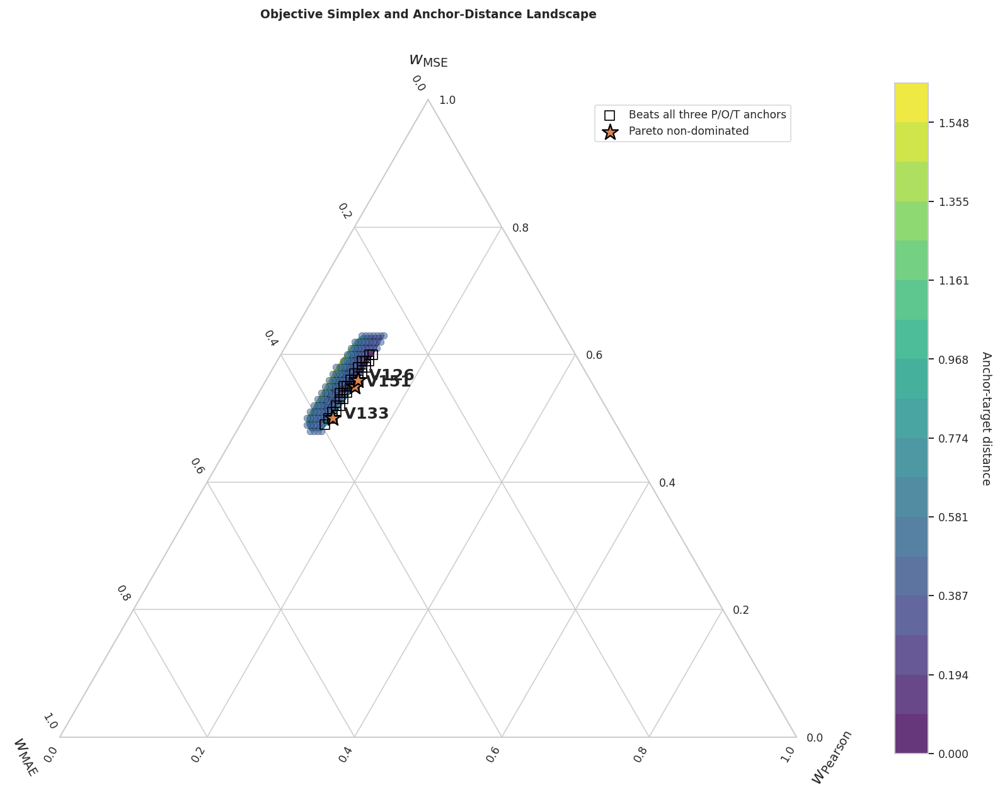

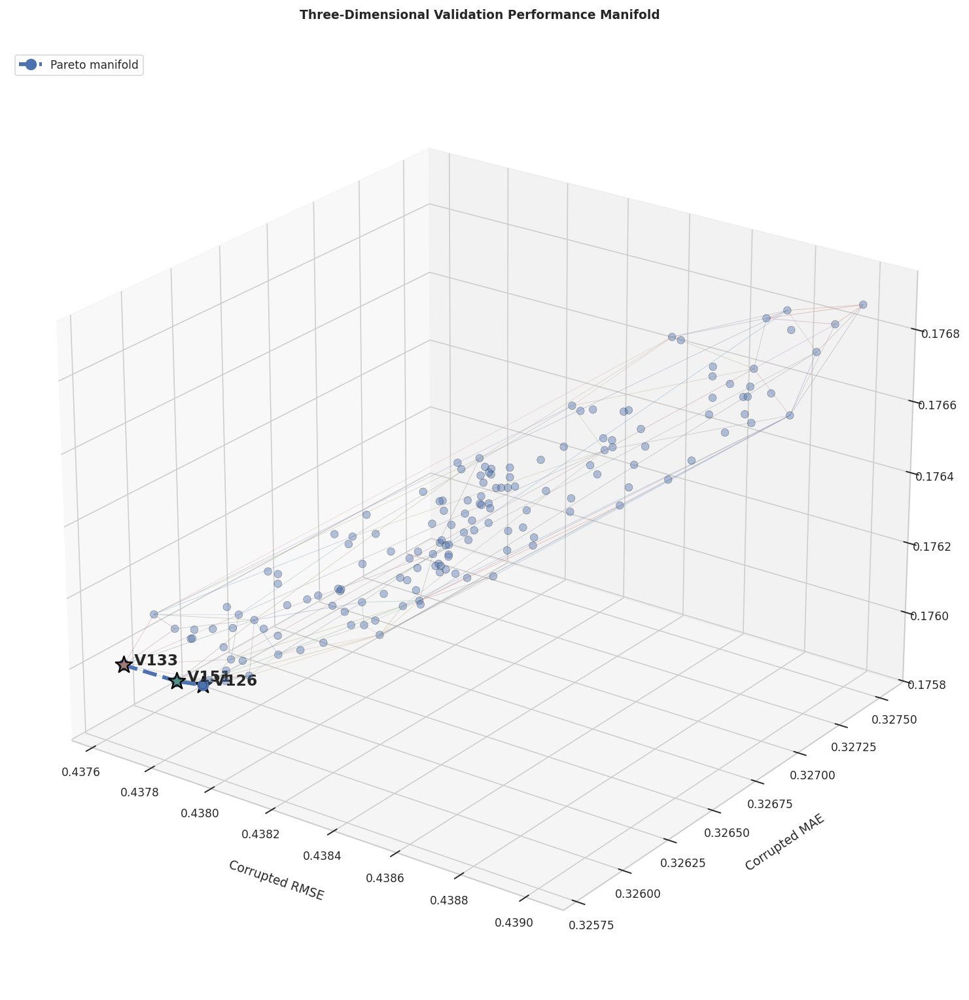

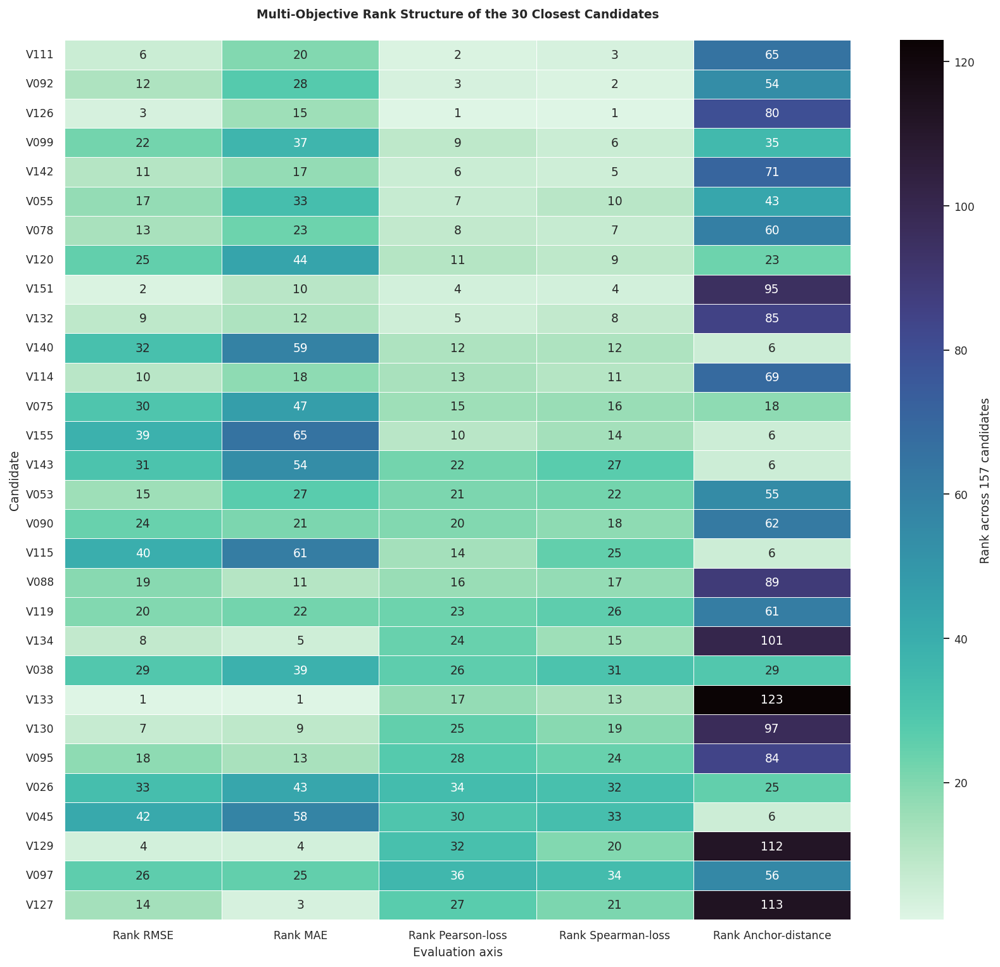

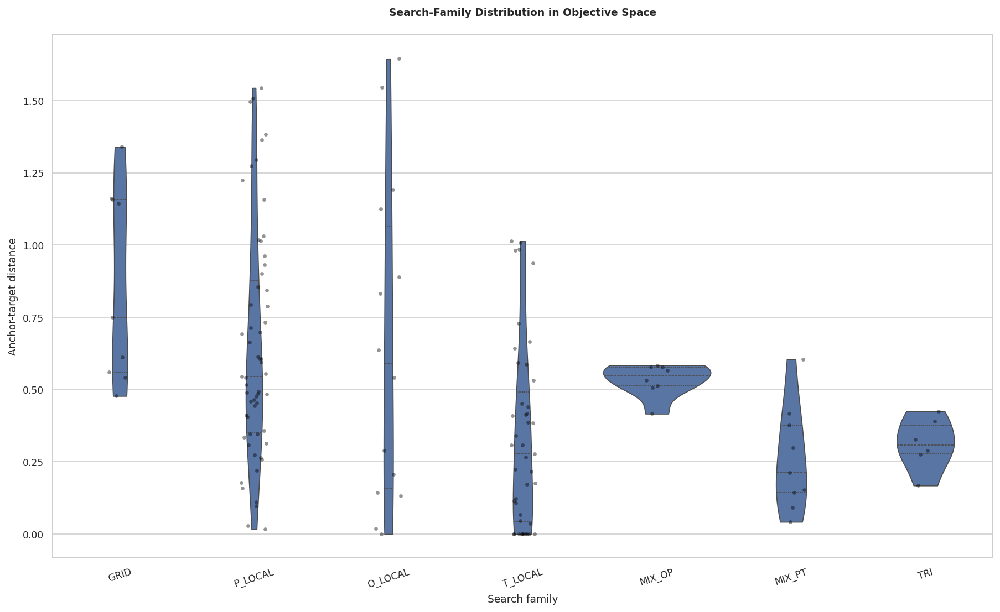

HEF IPIP120 — B P/O/T MICROSEARCH V4
PAPER VISUALIZATION LAB
                     quantity    value
         Candidates evaluated      157
         Pareto non-dominated        3
Beats all three P/O/T anchors       30
  Objective weight validation     PASS
                         TEST RESERVED

PARETO NON-DOMINATED
loss_key                loss_name  objective_mse  objective_mae  objective_pearson  corrupted_rmse  corrupted_mae  corrupted_pearson  corrupted_spearman
    V133 GRID_M0.50_A0.380_P0.120           0.50          0.380              0.120        0.437631       0.325806           0.823998            0.792202
    V151   T_LOCAL_M-0.04_P+0.015           0.55          0.325              0.125        0.437663       0.326025           0.824104            0.792341
    V126   T_LOCAL_M-0.03_P+0.015           0.56          0.315              0.125        0.437698       0.326105           0.824130            0.792370

OUTPUT: /content/HEF_IPIP120_B_POT_PAPER_FIGURES
FIG1: Objective simpl

In [ ]:
%pip install -q mpltern seaborn scipy

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mpltern
from scipy.spatial import ConvexHull
from scipy.stats import rankdata

warnings.filterwarnings("ignore")

CSV_PATH = "/content/HEF_IPIP120_ROBUST_DATASET_V3/MLP_GATEWAY_B_POT_MICROSEARCH_V4/pot_microsearch_v4_results.csv"
OUT = "/content/HEF_IPIP120_B_POT_PAPER_FIGURES"

os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(CSV_PATH)

required = [
    "loss_key",
    "loss_name",
    "objective_mse",
    "objective_mae",
    "objective_pearson",
    "clean_rmse",
    "corrupted_rmse",
    "corrupted_mae",
    "corrupted_pearson",
    "corrupted_spearman",
    "eligible_against_reference",
    "pareto_dominated",
    "beats_all_three_anchors",
    "anchor_target_distance"
]

missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(f"Missing columns: {missing}")

df = df.copy()

df["weight_sum"] = (
    df["objective_mse"]
    + df["objective_mae"]
    + df["objective_pearson"]
)

if not np.allclose(df["weight_sum"], 1.0, atol=1e-8):
    raise ValueError("Objective weights do not sum to 1.")

df["one_minus_pearson"] = 1.0 - df["corrupted_pearson"]
df["one_minus_spearman"] = 1.0 - df["corrupted_spearman"]

df["family"] = np.select(
    [
        df["loss_name"].str.startswith("GRID"),
        df["loss_name"].str.startswith("P_LOCAL"),
        df["loss_name"].str.startswith("O_LOCAL"),
        df["loss_name"].str.startswith("T_LOCAL"),
        df["loss_name"].str.startswith("MIX_OP"),
        df["loss_name"].str.startswith("MIX_PT"),
        df["loss_name"].str.startswith("TRI")
    ],
    [
        "GRID",
        "P_LOCAL",
        "O_LOCAL",
        "T_LOCAL",
        "MIX_OP",
        "MIX_PT",
        "TRI"
    ],
    default="OTHER"
)

pareto = df[df["pareto_dominated"] == False].copy()

if len(pareto) != 3:
    raise ValueError(
        f"Expected 3 non-dominated candidates, found {len(pareto)}"
    )

beat_anchor = df[df["beats_all_three_anchors"] == True].copy()

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 500,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

sns.set_theme(
    style="whitegrid",
    context="paper"
)

def save_figure(fig, name):
    fig.savefig(
        os.path.join(OUT, f"{name}.png"),
        dpi=500,
        bbox_inches="tight"
    )
    fig.savefig(
        os.path.join(OUT, f"{name}.pdf"),
        bbox_inches="tight"
    )
    fig.savefig(
        os.path.join(OUT, f"{name}.svg"),
        bbox_inches="tight"
    )


fig1 = plt.figure(figsize=(12, 10))
ax1 = fig1.add_subplot(111, projection="ternary")

t = df["objective_mse"].to_numpy()
l = df["objective_mae"].to_numpy()
r = df["objective_pearson"].to_numpy()

z = df["anchor_target_distance"].to_numpy()

levels = np.linspace(
    np.nanmin(z),
    np.nanmax(z),
    18
)

contour = ax1.tricontourf(
    t,
    l,
    r,
    z,
    levels=levels,
    cmap="viridis",
    alpha=0.82
)

ax1.tricontour(
    t,
    l,
    r,
    z,
    levels=levels,
    colors="black",
    linewidths=0.22,
    alpha=0.25
)

regular = df[df["beats_all_three_anchors"] == False]

ax1.scatter(
    regular["objective_mse"],
    regular["objective_mae"],
    regular["objective_pearson"],
    s=30,
    alpha=0.60,
    linewidths=0.25,
    edgecolors="black"
)

anchor_beating = df[
    df["beats_all_three_anchors"] == True
]

ax1.scatter(
    anchor_beating["objective_mse"],
    anchor_beating["objective_mae"],
    anchor_beating["objective_pearson"],
    s=58,
    marker="s",
    facecolors="none",
    edgecolors="black",
    linewidths=0.85,
    label="Beats all three P/O/T anchors"
)

ax1.scatter(
    pareto["objective_mse"],
    pareto["objective_mae"],
    pareto["objective_pearson"],
    s=180,
    marker="*",
    edgecolors="black",
    linewidths=1.2,
    label="Pareto non-dominated"
)

for _, row in pareto.iterrows():
    ax1.text(
        row["objective_mse"],
        row["objective_mae"],
        row["objective_pearson"],
        f"  {row['loss_key']}",
        fontsize=13,
        fontweight="bold"
    )

ax1.set_tlabel(
    r"$w_{\mathrm{MSE}}$",
    fontsize=14
)

ax1.set_llabel(
    r"$w_{\mathrm{MAE}}$",
    fontsize=14
)

ax1.set_rlabel(
    r"$w_{\mathrm{Pearson}}$",
    fontsize=14
)

ax1.set_title(
    "Objective Simplex and Anchor-Distance Landscape",
    pad=28,
    fontweight="bold"
)

cbar1 = fig1.colorbar(
    contour,
    ax=ax1,
    pad=0.10,
    shrink=0.80
)

cbar1.set_label(
    "Anchor-target distance",
    rotation=270,
    labelpad=18
)

ax1.legend(
    loc="upper right",
    frameon=True
)

fig1.tight_layout()

save_figure(
    fig1,
    "FIG1_OBJECTIVE_SIMPLEX_LANDSCAPE"
)

plt.show()


fig2 = plt.figure(
    figsize=(13, 11)
)

ax2 = fig2.add_subplot(
    111,
    projection="3d"
)

xyz = df[
    [
        "corrupted_rmse",
        "corrupted_mae",
        "one_minus_pearson"
    ]
].to_numpy()

ax2.scatter(
    xyz[:, 0],
    xyz[:, 1],
    xyz[:, 2],
    s=36,
    alpha=0.42,
    edgecolors="black",
    linewidths=0.3
)

if len(xyz) >= 4:
    hull = ConvexHull(xyz)

    for simplex in hull.simplices:
        pts = xyz[simplex]

        closed = np.vstack([
            pts,
            pts[0]
        ])

        ax2.plot(
            closed[:, 0],
            closed[:, 1],
            closed[:, 2],
            linewidth=0.42,
            alpha=0.20
        )

pareto_sorted = pareto.sort_values(
    "corrupted_rmse"
)

px = pareto_sorted["corrupted_rmse"].to_numpy()
py = pareto_sorted["corrupted_mae"].to_numpy()
pz = pareto_sorted["one_minus_pearson"].to_numpy()

ax2.plot(
    px,
    py,
    pz,
    linestyle="--",
    linewidth=3.0,
    marker="o",
    markersize=8,
    label="Pareto manifold"
)

for _, row in pareto_sorted.iterrows():
    ax2.scatter(
        row["corrupted_rmse"],
        row["corrupted_mae"],
        row["one_minus_pearson"],
        s=190,
        marker="*",
        edgecolors="black",
        linewidths=1.2
    )

    ax2.text(
        row["corrupted_rmse"],
        row["corrupted_mae"],
        row["one_minus_pearson"],
        f"  {row['loss_key']}",
        fontsize=12,
        fontweight="bold"
    )

ax2.set_xlabel(
    "Corrupted RMSE",
    labelpad=13
)

ax2.set_ylabel(
    "Corrupted MAE",
    labelpad=13
)

ax2.set_zlabel(
    r"$1-\mathrm{Pearson}$",
    labelpad=13
)

ax2.set_title(
    "Three-Dimensional Validation Performance Manifold",
    pad=24,
    fontweight="bold"
)

ax2.view_init(
    elev=24,
    azim=-54
)

ax2.legend(
    loc="upper left"
)

fig2.tight_layout()

save_figure(
    fig2,
    "FIG2_PERFORMANCE_MANIFOLD"
)

plt.show()


rank_df = df[
    [
        "loss_key",
        "corrupted_rmse",
        "corrupted_mae",
        "one_minus_pearson",
        "one_minus_spearman",
        "anchor_target_distance"
    ]
].copy()

rank_df["Rank RMSE"] = rankdata(
    rank_df["corrupted_rmse"],
    method="average"
)

rank_df["Rank MAE"] = rankdata(
    rank_df["corrupted_mae"],
    method="average"
)

rank_df["Rank Pearson-loss"] = rankdata(
    rank_df["one_minus_pearson"],
    method="average"
)

rank_df["Rank Spearman-loss"] = rankdata(
    rank_df["one_minus_spearman"],
    method="average"
)

rank_df["Rank Anchor-distance"] = rankdata(
    rank_df["anchor_target_distance"],
    method="average"
)

rank_df["Mean rank"] = rank_df[
    [
        "Rank RMSE",
        "Rank MAE",
        "Rank Pearson-loss",
        "Rank Spearman-loss",
        "Rank Anchor-distance"
    ]
].mean(axis=1)

rank_df = rank_df.sort_values(
    "Mean rank"
).head(30)

rank_matrix = rank_df.set_index(
    "loss_key"
)[
    [
        "Rank RMSE",
        "Rank MAE",
        "Rank Pearson-loss",
        "Rank Spearman-loss",
        "Rank Anchor-distance"
    ]
]

fig3, ax3 = plt.subplots(
    figsize=(12, 11)
)

sns.heatmap(
    rank_matrix,
    ax=ax3,
    cmap="mako_r",
    annot=True,
    fmt=".0f",
    linewidths=0.35,
    cbar_kws={
        "label": "Rank across 157 candidates"
    }
)

ax3.set_title(
    "Multi-Objective Rank Structure of the 30 Closest Candidates",
    pad=18,
    fontweight="bold"
)

ax3.set_xlabel(
    "Evaluation axis"
)

ax3.set_ylabel(
    "Candidate"
)

fig3.tight_layout()

save_figure(
    fig3,
    "FIG3_MULTIOBJECTIVE_RANK_STRUCTURE"
)

plt.show()


family_order = [
    "GRID",
    "P_LOCAL",
    "O_LOCAL",
    "T_LOCAL",
    "MIX_OP",
    "MIX_PT",
    "TRI"
]

family_df = df[
    df["family"].isin(family_order)
].copy()

fig4, ax4 = plt.subplots(
    figsize=(13, 8)
)

sns.violinplot(
    data=family_df,
    x="family",
    y="anchor_target_distance",
    order=family_order,
    inner="quartile",
    cut=0,
    linewidth=0.9,
    ax=ax4
)

sns.stripplot(
    data=family_df,
    x="family",
    y="anchor_target_distance",
    order=family_order,
    size=3.5,
    alpha=0.42,
    color="black",
    ax=ax4
)

ax4.set_title(
    "Search-Family Distribution in Objective Space",
    pad=18,
    fontweight="bold"
)

ax4.set_xlabel(
    "Search family"
)

ax4.set_ylabel(
    "Anchor-target distance"
)

ax4.tick_params(
    axis="x",
    rotation=18
)

fig4.tight_layout()

save_figure(
    fig4,
    "FIG4_SEARCH_FAMILY_DISTRIBUTION"
)

plt.show()


summary = pd.DataFrame({
    "quantity": [
        "Candidates evaluated",
        "Pareto non-dominated",
        "Beats all three P/O/T anchors",
        "Objective weight validation",
        "TEST"
    ],
    "value": [
        len(df),
        len(pareto),
        len(beat_anchor),
        "PASS",
        "RESERVED"
    ]
})

print("=" * 78)
print("HEF IPIP120 — B P/O/T MICROSEARCH V4")
print("PAPER VISUALIZATION LAB")
print("=" * 78)
print(summary.to_string(index=False))
print()
print("PARETO NON-DOMINATED")
print(
    pareto[
        [
            "loss_key",
            "loss_name",
            "objective_mse",
            "objective_mae",
            "objective_pearson",
            "corrupted_rmse",
            "corrupted_mae",
            "corrupted_pearson",
            "corrupted_spearman"
        ]
    ].to_string(index=False)
)
print()
print(f"OUTPUT: {OUT}")
print("FIG1: Objective simplex + anchor-distance landscape")
print("FIG2: 3D validation performance manifold")
print("FIG3: Multi-objective rank structure")
print("FIG4: Search-family distribution")
print("Formats: PNG + PDF + SVG")

In [16]:
from __future__ import annotations
import gc
import json
import math
import random
import time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
ROOT = Path(
    "/content/HEF_IPIP120_ROBUST_DATASET_V3"
)
TRAIN_ROOT = (
    ROOT
    / "TRAIN"
)
VAL_CLEAN_ROOT = (
    ROOT
    / "VALIDATION"
    / "CLEAN"
)
VAL_CORRUPTED_ROOT = (
    ROOT
    / "VALIDATION"
    / "CORRUPTED"
)
PRODUCTION_ROOT = (
    ROOT
    / "MLP_GATEWAY_B_V133_PRODUCTION"
)
PRODUCTION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)
INPUT_DIM = 120
OUTPUT_DIM = 30
VIEWS_PER_SUBJECT = 143
CLEAN_VIEWS = 3
CORRUPTED_VIEWS_PER_FAMILY = 20
N_CORRUPTION_FAMILIES = 7
EXPECTED_TRAIN_SUBJECTS = 287_263
EXPECTED_TRAIN_EXAMPLES = 41_078_609
B_HIDDEN = (
    192,
    128,
    64,
)
MSE_WEIGHT = 0.50
MAE_WEIGHT = 0.38
PEARSON_WEIGHT = 0.12
BATCH_SIZE = 8192
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.10
GRAD_CLIP_NORM = 1.0
USE_BF16 = True
MAX_EPOCHS = 120
MIN_EPOCHS = 5
EARLY_STOP_PATIENCE = 3
EARLY_STOP_MIN_DELTA = 1e-4
SAVE_EVERY_EPOCH = True
GLOBAL_SEED = 20260920
SIES_SEED = 20262026
assert torch.cuda.is_available()
DEVICE = torch.device(
    "cuda"
)
torch.set_float32_matmul_precision(
    "high"
)
def seed_everything(
    seed: int,
) -> None:
    random.seed(
        seed
    )
    np.random.seed(
        seed
    )
    torch.manual_seed(
        seed
    )
    torch.cuda.manual_seed_all(
        seed
    )
seed_everything(
    GLOBAL_SEED
)
print()
print("=" * 110)
print(
    "HEF IPIP120 ROBUST — B V133 PRODUCTION TRAINING"
)
print("=" * 110)
print(
    "DEVICE                    :",
    torch.cuda.get_device_name(0),
)
print(
    "ARCHITECTURE              : B COMPACT"
)
print(
    "ARCHITECTURE              :",
    f"{INPUT_DIM} -> 192 -> 128 -> 64 -> {OUTPUT_DIM}",
)
print(
    "OBJECTIVE                 : V133 = 50% MSE + 38% MAE + 12% PEARSON"
)
print(
    "TRAIN SUBJECTS            :",
    f"{EXPECTED_TRAIN_SUBJECTS:,}",
)
print(
    "TRAIN EXAMPLES            :",
    f"{EXPECTED_TRAIN_EXAMPLES:,}",
)
print(
    "VIEWS / SUBJECT           :",
    VIEWS_PER_SUBJECT,
)
print(
    "BATCH SIZE                :",
    BATCH_SIZE,
)
print(
    "LEARNING RATE             :",
    LEARNING_RATE,
)
print(
    "WEIGHT DECAY              :",
    WEIGHT_DECAY,
)
print(
    "DROPOUT                   :",
    DROPOUT,
)
print(
    "MAX EPOCHS               :",
    MAX_EPOCHS,
)
print(
    "MIN EPOCHS               :",
    MIN_EPOCHS,
)
print(
    "EARLY STOP PATIENCE       :",
    EARLY_STOP_PATIENCE,
)
print(
    "EARLY STOP MIN DELTA      :",
    EARLY_STOP_MIN_DELTA,
)
print(
    "TEST                      : RESERVED"
)
print("=" * 110)
def discover_train_shards(
    root: Path,
):
    paths = sorted(
        root.glob(
            "shard_*_X.npy"
        )
    )
    if not paths:
        raise FileNotFoundError(
            f"No TRAIN X shards found in {root}"
        )
    return paths
TRAIN_X_SHARDS = (
    discover_train_shards(
        TRAIN_ROOT
    )
)
print()
print(
    "TRAIN SHARDS             :",
    len(
        TRAIN_X_SHARDS
    )
)
SHARD_INDEX = []
global_subject_cursor = 0
global_row_cursor = 0
for shard_id, x_path in enumerate(
    TRAIN_X_SHARDS
):
    x_mm = np.load(
        x_path,
        mmap_mode="r",
    )
    if x_mm.ndim != 2:
        raise RuntimeError(
            f"Invalid X ndim in {x_path}: {x_mm.shape}"
        )
    if x_mm.shape[1] != INPUT_DIM:
        raise RuntimeError(
            f"Invalid X shape in {x_path}: {x_mm.shape}"
        )
    n_rows = int(
        x_mm.shape[0]
    )
    if (
        n_rows
        % VIEWS_PER_SUBJECT
        != 0
    ):
        raise RuntimeError(
            f"Shard is not subject aligned: "
            f"{x_path} -> {n_rows}"
        )
    n_subjects = (
        n_rows
        // VIEWS_PER_SUBJECT
    )
    SHARD_INDEX.append(
        {
            "shard_id": shard_id,
            "x_path": x_path,
            "n_rows": n_rows,
            "n_subjects": n_subjects,
            "subject_start": global_subject_cursor,
            "subject_end": (
                global_subject_cursor
                + n_subjects
            ),
            "row_start": global_row_cursor,
            "row_end": (
                global_row_cursor
                + n_rows
            ),
        }
    )
    global_subject_cursor += (
        n_subjects
    )
    global_row_cursor += (
        n_rows
    )
N_TRAIN_SUBJECTS = (
    global_subject_cursor
)
N_TRAIN_EXAMPLES = (
    global_row_cursor
)
assert (
    N_TRAIN_SUBJECTS
    == EXPECTED_TRAIN_SUBJECTS
), (
    N_TRAIN_SUBJECTS,
    EXPECTED_TRAIN_SUBJECTS,
)
assert (
    N_TRAIN_EXAMPLES
    == EXPECTED_TRAIN_EXAMPLES
), (
    N_TRAIN_EXAMPLES,
    EXPECTED_TRAIN_EXAMPLES,
)
assert (
    N_TRAIN_SUBJECTS
    * VIEWS_PER_SUBJECT
    == N_TRAIN_EXAMPLES
)
print(
    "TRAIN SUBJECTS           :",
    f"{N_TRAIN_SUBJECTS:,}",
)
print(
    "TRAIN EXAMPLES           :",
    f"{N_TRAIN_EXAMPLES:,}",
)
print(
    "DATASET SIZE ASSERTION   : PASS"
)
TRAIN_MEMMAPS = []
TRAIN_Y_MEMMAPS = []
TRAIN_TYPE_MEMMAPS = []
TRAIN_SEVERITY_MEMMAPS = []
for shard in SHARD_INDEX:
    x_path = shard[
        "x_path"
    ]
    y_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_Y.npy",
        )
    )
    type_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_type.npy",
        )
    )
    severity_path = Path(
        str(x_path)
        .replace(
            "_X.npy",
            "_severity.npy",
        )
    )
    for required_path in (
        y_path,
        type_path,
        severity_path,
    ):
        if not required_path.exists():
            raise FileNotFoundError(
                required_path
            )
    TRAIN_MEMMAPS.append(
        np.load(
            x_path,
            mmap_mode="r",
        )
    )
    TRAIN_Y_MEMMAPS.append(
        np.load(
            y_path,
            mmap_mode="r",
        )
    )
    TRAIN_TYPE_MEMMAPS.append(
        np.load(
            type_path,
            mmap_mode="r",
        )
    )
    TRAIN_SEVERITY_MEMMAPS.append(
        np.load(
            severity_path,
            mmap_mode="r",
        )
    )
print(
    "TRAIN MEMMAPS            : READY"
)
SHARD_SUBJECT_ENDS = np.asarray(
    [
        shard[
            "subject_end"
        ]
        for shard in SHARD_INDEX
    ],
    dtype=np.int64,
)
def locate_subjects(
    subject_ids: np.ndarray,
):
    shard_ids = np.searchsorted(
        SHARD_SUBJECT_ENDS,
        subject_ids,
        side="right",
    )
    local_subject_ids = (
        subject_ids
        - np.asarray(
            [
                SHARD_INDEX[
                    int(
                        shard_id
                    )
                ][
                    "subject_start"
                ]
                for shard_id in shard_ids
            ],
            dtype=np.int64,
        )
    )
    return (
        shard_ids,
        local_subject_ids,
    )
def fetch_train_batch(
    subject_ids,
    view_ids,
):
    subject_ids = np.asarray(
        subject_ids,
        dtype=np.int64,
    )
    view_ids = np.asarray(
        view_ids,
        dtype=np.int64,
    )
    if len(subject_ids) != len(view_ids):
        raise RuntimeError(
            "subject_ids and view_ids length mismatch."
        )
    if (
        len(
            np.unique(
                subject_ids
            )
        )
        != len(subject_ids)
    ):
        raise RuntimeError(
            "SIES violation: duplicate subject in batch."
        )
    if np.any(
        view_ids < 0
    ) or np.any(
        view_ids >= VIEWS_PER_SUBJECT
    ):
        raise RuntimeError(
            "Invalid view index."
        )
    shard_ids, local_subjects = (
        locate_subjects(
            subject_ids
        )
    )
    batch_n = len(
        subject_ids
    )
    batch_x = np.empty(
        (
            batch_n,
            INPUT_DIM,
        ),
        dtype=np.uint8,
    )
    batch_y = np.empty(
        (
            batch_n,
            OUTPUT_DIM,
        ),
        dtype=np.float32,
    )
    for shard_id in np.unique(
        shard_ids
    ):
        positions = np.flatnonzero(
            shard_ids
            == shard_id
        )
        local_rows = (
            local_subjects[
                positions
            ]
            * VIEWS_PER_SUBJECT
            + view_ids[
                positions
            ]
        )
        x_mm = TRAIN_MEMMAPS[
            int(shard_id)
        ]
        y_mm = TRAIN_Y_MEMMAPS[
            int(shard_id)
        ]
        batch_x[
            positions
        ] = np.asarray(
            x_mm[
                local_rows
            ],
            dtype=np.uint8,
        )
        batch_y[
            positions
        ] = np.asarray(
            y_mm[
                local_rows
            ],
            dtype=np.float32,
        )
    assert batch_x.shape == (
        batch_n,
        INPUT_DIM,
    )
    assert batch_y.shape == (
        batch_n,
        OUTPUT_DIM,
    )
    return (
        batch_x,
        batch_y,
    )
def audit_train_store(
    sample_size: int = 4096,
):
    rng = np.random.default_rng(
        20260920
    )
    sample_size = min(
        sample_size,
        N_TRAIN_SUBJECTS,
    )
    sampled_subjects = rng.choice(
        N_TRAIN_SUBJECTS,
        size=sample_size,
        replace=False,
    )
    sampled_subjects.sort()
    sampled_shards, sampled_local = (
        locate_subjects(
            sampled_subjects
        )
    )
    for shard_id in np.unique(
        sampled_shards
    ):
        positions = np.flatnonzero(
            sampled_shards
            == shard_id
        )
        local_subject_ids = (
            sampled_local[
                positions
            ]
        )
        x_mm = TRAIN_MEMMAPS[
            int(shard_id)
        ]
        type_mm = TRAIN_TYPE_MEMMAPS[
            int(shard_id)
        ]
        for local_subject in local_subject_ids:
            s = (
                int(local_subject)
                * VIEWS_PER_SUBJECT
            )
            e = (
                s
                + VIEWS_PER_SUBJECT
            )
            subject_type = np.asarray(
                type_mm[
                    s:e
                ],
                dtype=np.uint8,
            )
            counts = np.bincount(
                subject_type,
                minlength=8,
            )
            if counts[0] != 3:
                raise RuntimeError(
                    f"CLEAN count violation: {local_subject}"
                )
            for code in range(
                1,
                8,
            ):
                if counts[code] != 20:
                    raise RuntimeError(
                        f"Family count violation: "
                        f"subject={local_subject}, "
                        f"code={code}, "
                        f"count={counts[code]}"
                    )
            sample_x = x_mm[
                s:e
            ]
            assert sample_x.shape == (
                VIEWS_PER_SUBJECT,
                INPUT_DIM,
            )
    print(
        "TRAIN subject-block audit : PASS"
    )
    print(
        "143-view structure        : PASS"
    )
audit_train_store()
def discover_split_shards(
    root: Path,
):
    paths = sorted(
        root.glob(
            "shard_*_X.npy"
        )
    )
    if not paths:
        raise FileNotFoundError(
            f"No validation shards found in {root}"
        )
    return paths
def load_flat_validation(
    root: Path,
):
    shards = discover_split_shards(
        root
    )
    xs = []
    ys = []
    types = []
    severities = []
    targets = []
    for x_path in shards:
        y_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_Y.npy",
            )
        )
        type_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_type.npy",
            )
        )
        severity_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_severity.npy",
            )
        )
        target_path = Path(
            str(x_path)
            .replace(
                "_X.npy",
                "_target.npy",
            )
        )
        X = np.load(
            x_path
        )
        Y = np.load(
            y_path
        )
        T = np.load(
            type_path
        )
        S = np.load(
            severity_path
        )
        target = np.load(
            target_path
        )
        xs.append(
            X.astype(
                np.uint8,
                copy=False,
            )
        )
        ys.append(
            Y.astype(
                np.float32,
                copy=False,
            )
        )
        types.append(
            T.astype(
                np.uint8,
                copy=False,
            )
        )
        severities.append(
            S.astype(
                np.uint8,
                copy=False,
            )
        )
        targets.append(
            target.astype(
                np.int32,
                copy=False,
            )
        )
    X = np.concatenate(
        xs,
        axis=0,
    )
    Y = np.concatenate(
        ys,
        axis=0,
    )
    T = np.concatenate(
        types,
        axis=0,
    )
    S = np.concatenate(
        severities,
        axis=0,
    )
    target = np.concatenate(
        targets,
        axis=0,
    )
    assert X.ndim == 2
    assert X.shape[1] == INPUT_DIM
    assert Y.ndim == 2
    assert Y.shape[1] == OUTPUT_DIM
    assert T.ndim == 1
    assert S.ndim == 1
    assert target.ndim == 1
    assert len(X) == len(Y)
    assert len(X) == len(T)
    assert len(X) == len(S)
    assert len(X) == len(target)
    return (
        X,
        Y,
        T,
        S,
        target,
    )
(
    VAL_CLEAN_X,
    VAL_CLEAN_Y,
    VAL_CLEAN_TYPE,
    VAL_CLEAN_SEVERITY,
    VAL_CLEAN_TARGET,
) = load_flat_validation(
    VAL_CLEAN_ROOT
)
(
    VAL_CORRUPTED_X,
    VAL_CORRUPTED_Y,
    VAL_CORRUPTED_TYPE,
    VAL_CORRUPTED_SEVERITY,
    VAL_CORRUPTED_TARGET,
) = load_flat_validation(
    VAL_CORRUPTED_ROOT
)
print()
print("=" * 110)
print("VALIDATION")
print("=" * 110)
print(
    "CLEAN                    :",
    f"{len(VAL_CLEAN_X):,}",
)
print(
    "CORRUPTED                :",
    f"{len(VAL_CORRUPTED_X):,}",
)
print(
    "TOTAL                    :",
    f"{len(VAL_CLEAN_X) + len(VAL_CORRUPTED_X):,}",
)
print(
    "VALIDATION DATA          : PASS"
)
class HEFIPIP120MLP(
    nn.Module
):
    def __init__(
        self,
    ):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(
                INPUT_DIM,
                192,
            ),
            nn.LayerNorm(
                192
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
            nn.Linear(
                192,
                128,
            ),
            nn.LayerNorm(
                128
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
            nn.Linear(
                128,
                64,
            ),
            nn.LayerNorm(
                64
            ),
            nn.GELU(),
            nn.Dropout(
                DROPOUT
            ),
        )
        self.output = nn.Linear(
            64,
            OUTPUT_DIM,
        )
    def forward(
        self,
        x,
    ):
        x = (
            x
            - 3.0
        ) / 2.0
        h = self.trunk(
            x
        )
        return self.output(
            h
        )
def pearson_profile_loss(
    prediction,
    target,
):
    prediction = prediction.float()
    target = target.float()
    p = (
        prediction
        - prediction.mean(
            dim=1,
            keepdim=True,
        )
    )
    y = (
        target
        - target.mean(
            dim=1,
            keepdim=True,
        )
    )
    numerator = (
        p * y
    ).sum(
        dim=1
    )
    denominator = (
        torch.sqrt(
            torch.sum(
                p * p,
                dim=1,
            )
            + 1e-8
        )
        *
        torch.sqrt(
            torch.sum(
                y * y,
                dim=1,
            )
            + 1e-8
        )
    )
    correlation = (
        numerator
        / denominator
    )
    return (
        1.0
        - correlation
    ).mean()
def objective_V133(
    prediction,
    target,
):
    prediction_f32 = prediction.float()
    target_f32 = target.float()
    mse = F.mse_loss(
        prediction_f32,
        target_f32,
    )
    mae = F.l1_loss(
        prediction_f32,
        target_f32,
    )
    pearson = pearson_profile_loss(
        prediction_f32,
        target_f32,
    )
    loss = (
        MSE_WEIGHT
        * mse
        +
        MAE_WEIGHT
        * mae
        +
        PEARSON_WEIGHT
        * pearson
    )
    return (
        loss,
        mse.detach(),
        mae.detach(),
        pearson.detach(),
    )
def metric_rmse(
    prediction,
    target,
):
    diff = (
        prediction.astype(
            np.float64,
        )
        -
        target.astype(
            np.float64,
        )
    )
    return float(
        np.sqrt(
            np.mean(
                diff * diff
            )
        )
    )
def metric_mae(
    prediction,
    target,
):
    diff = (
        prediction.astype(
            np.float64,
        )
        -
        target.astype(
            np.float64,
        )
    )
    return float(
        np.mean(
            np.abs(
                diff
            )
        )
    )
def metric_pearson(
    prediction,
    target,
):
    p = prediction.astype(
        np.float64,
        copy=False,
    ).reshape(-1)
    y = target.astype(
        np.float64,
        copy=False,
    ).reshape(-1)
    p = p - p.mean()
    y = y - y.mean()
    denominator = (
        np.sqrt(
            np.sum(
                p * p
            )
        )
        *
        np.sqrt(
            np.sum(
                y * y
            )
        )
    )
    if denominator <= 0:
        return float(
            "nan"
        )
    return float(
        np.sum(
            p * y
        )
        / denominator
    )
def metric_spearman(
    prediction,
    target,
):
    p = pd.Series(
        prediction.reshape(-1)
    ).rank(
        method="average"
    ).to_numpy()
    y = pd.Series(
        target.reshape(-1)
    ).rank(
        method="average"
    ).to_numpy()
    return metric_pearson(
        p,
        y,
    )
@torch.no_grad()
def predict_validation(
    model,
    X,
    batch_size=32768,
):
    model.eval()
    predictions = []
    for start in range(
        0,
        len(X),
        batch_size,
    ):
        end = min(
            start
            + batch_size,
            len(X),
        )
        xb = torch.from_numpy(
            np.asarray(
                X[
                    start:end
                ],
                dtype=np.uint8,
            )
        ).to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True,
        )
        if USE_BF16:
            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16,
            ):
                pred = model(
                    xb
                )
        else:
            pred = model(
                xb
            )
        predictions.append(
            pred.float()
            .cpu()
            .numpy()
        )
    return np.concatenate(
        predictions,
        axis=0,
    )
def evaluate_validation(
    model,
):
    clean_pred = predict_validation(
        model,
        VAL_CLEAN_X,
    )
    corrupted_pred = predict_validation(
        model,
        VAL_CORRUPTED_X,
    )
    clean_rmse = metric_rmse(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_mae = metric_mae(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_pearson = metric_pearson(
        clean_pred,
        VAL_CLEAN_Y,
    )
    clean_spearman = metric_spearman(
        clean_pred,
        VAL_CLEAN_Y,
    )
    corrupted_rmse = metric_rmse(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_mae = metric_mae(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_pearson = metric_pearson(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    corrupted_spearman = metric_spearman(
        corrupted_pred,
        VAL_CORRUPTED_Y,
    )
    validation_v133_objective = (
        MSE_WEIGHT * (corrupted_rmse ** 2)
        + MAE_WEIGHT * corrupted_mae
        + PEARSON_WEIGHT * (1.0 - corrupted_pearson)
    )
    family_names = {
        1: "ITEM_SWAP",
        2: "FACET_SWAP",
        3: "CATEGORY_PARTIAL_SWAP",
        4: "CATEGORY_SWAP",
        5: "ITEM_COLLAPSE",
        6: "CATEGORY_COLLAPSE",
        7: "RANDOM_ITEM_CHANGE",
    }
    family_metrics = {}
    for code, family_name in (
        family_names.items()
    ):
        mask = (
            VAL_CORRUPTED_TYPE
            == code
        )
        if not np.any(
            mask
        ):
            continue
        family_metrics[
            family_name
        ] = metric_rmse(
            corrupted_pred[
                mask
            ],
            VAL_CORRUPTED_Y[
                mask
            ],
        )
    severity_metrics = {}
    for severity in np.unique(
        VAL_CORRUPTED_SEVERITY
    ):
        mask = (
            VAL_CORRUPTED_SEVERITY
            == severity
        )
        severity_metrics[
            int(severity)
        ] = metric_rmse(
            corrupted_pred[
                mask
            ],
            VAL_CORRUPTED_Y[
                mask
            ],
        )
    all_pred = np.concatenate(
        [
            clean_pred,
            corrupted_pred,
        ],
        axis=0,
    )
    all_target = np.concatenate(
        [
            VAL_CLEAN_Y,
            VAL_CORRUPTED_Y,
        ],
        axis=0,
    )
    output_min = float(
        all_pred.min()
    )
    output_max = float(
        all_pred.max()
    )
    out_of_range = float(
        np.mean(
            (
                all_pred < 1.0
            )
            |
            (
                all_pred > 5.0
            )
        )
    )
    return {
        "clean_rmse": clean_rmse,
        "clean_mae": clean_mae,
        "clean_pearson": clean_pearson,
        "clean_spearman": clean_spearman,
        "corrupted_rmse": corrupted_rmse,
        "corrupted_mae": corrupted_mae,
        "corrupted_pearson": corrupted_pearson,
        "corrupted_spearman": corrupted_spearman,
        "corrupted_v133_objective": validation_v133_objective,
        "family_metrics": family_metrics,
        "severity_metrics": severity_metrics,
        "output_min": output_min,
        "output_max": output_max,
        "out_of_range_fraction": out_of_range,
    }
SIES_RNG = np.random.default_rng(
    SIES_SEED
)
SIES_RANK = SIES_RNG.integers(
    0,
    VIEWS_PER_SUBJECT,
    size=N_TRAIN_SUBJECTS,
    dtype=np.int16,
)
def train_one_epoch(
    model,
    optimizer,
    epoch_id,
):
    model.train()
    epoch_start = time.perf_counter()
    epoch_loss_sum = 0.0
    epoch_mse_sum = 0.0
    epoch_mae_sum = 0.0
    epoch_pearson_sum = 0.0
    epoch_examples = 0
    epoch_steps = 0
    epoch_rng = np.random.default_rng(
        SIES_SEED
        + epoch_id
        * 1_000_003
    )
    for round_id in range(
        VIEWS_PER_SUBJECT
    ):
        subject_order = epoch_rng.permutation(
            N_TRAIN_SUBJECTS
        ).astype(
            np.int64,
            copy=False,
        )
        selected_views = (
            (
                SIES_RANK[
                    subject_order
                ]
                + round_id
            )
            % VIEWS_PER_SUBJECT
        ).astype(
            np.int64,
            copy=False,
        )
        assert len(
            np.unique(
                subject_order
            )
        ) == N_TRAIN_SUBJECTS
        for start in range(
            0,
            N_TRAIN_SUBJECTS,
            BATCH_SIZE,
        ):
            end = min(
                start
                + BATCH_SIZE,
                N_TRAIN_SUBJECTS,
            )
            batch_subjects = (
                subject_order[
                    start:end
                ]
            )
            batch_views = (
                selected_views[
                    start:end
                ]
            )
            if len(
                np.unique(
                    batch_subjects
                )
            ) != len(
                batch_subjects
            ):
                raise RuntimeError(
                    "SIES violation: duplicate subject in batch."
                )
            batch_x_np, batch_y_np = (
                fetch_train_batch(
                    batch_subjects,
                    batch_views,
                )
            )
            xb = torch.from_numpy(
                batch_x_np
            ).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            yb = torch.from_numpy(
                batch_y_np
            ).to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )
            optimizer.zero_grad(
                set_to_none=True
            )
            if USE_BF16:
                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.bfloat16,
                ):
                    prediction = model(
                        xb
                    )
                    (
                        loss,
                        mse_component,
                        mae_component,
                        pearson_component,
                    ) = objective_V133(
                        prediction,
                        yb,
                    )
            else:
                prediction = model(
                    xb
                )
                (
                    loss,
                    mse_component,
                    mae_component,
                    pearson_component,
                ) = objective_V133(
                    prediction,
                    yb,
                )
            if not torch.isfinite(
                loss
            ):
                raise FloatingPointError(
                    f"Non-finite loss at epoch={epoch_id}, "
                    f"round={round_id}"
                )
            loss.backward()
            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP_NORM,
                )
            optimizer.step()
            n = len(
                batch_x_np
            )
            epoch_examples += n
            epoch_steps += 1
            epoch_loss_sum += (
                float(
                    loss.detach().item()
                )
                * n
            )
            epoch_mse_sum += (
                float(
                    mse_component.item()
                )
                * n
            )
            epoch_mae_sum += (
                float(
                    mae_component.item()
                )
                * n
            )
            epoch_pearson_sum += (
                float(
                    pearson_component.item()
                )
                * n
            )
        if (
            round_id == 0
            or (round_id + 1) % 10 == 0
            or round_id + 1
            == VIEWS_PER_SUBJECT
        ):
            elapsed = (
                time.perf_counter()
                - epoch_start
            )
            throughput = (
                epoch_examples
                / max(
                    elapsed,
                    1e-9,
                )
            )
            avg_loss = (
                epoch_loss_sum
                / max(
                    epoch_examples,
                    1,
                )
            )
            print(
                f"[TRAIN] "
                f"epoch={epoch_id:03d} "
                f"round={round_id + 1:03d}/143 "
                f"examples={epoch_examples:,} "
                f"loss={avg_loss:.6f} "
                f"throughput={throughput:,.0f} ex/s"
            )
    epoch_elapsed = (
        time.perf_counter()
        - epoch_start
    )
    epoch_loss = (
        epoch_loss_sum
        / max(
            epoch_examples,
            1,
        )
    )
    epoch_mse = (
        epoch_mse_sum
        / max(
            epoch_examples,
            1,
        )
    )
    epoch_mae = (
        epoch_mae_sum
        / max(
            epoch_examples,
            1,
        )
    )
    epoch_pearson = (
        epoch_pearson_sum
        / max(
            epoch_examples,
            1,
        )
    )
    epoch_throughput = (
        epoch_examples
        / max(
            epoch_elapsed,
            1e-9,
        )
    )
    return {
        "loss": epoch_loss,
        "mse_component": epoch_mse,
        "mae_component": epoch_mae,
        "pearson_component": epoch_pearson,
        "examples": epoch_examples,
        "steps": epoch_steps,
        "seconds": epoch_elapsed,
        "throughput": epoch_throughput,
    }
seed_everything(
    GLOBAL_SEED
)
model = HEFIPIP120MLP().to(
    DEVICE
)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
PARAMETERS = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)
print()
print(
    "=" * 110
)
print(
    "MODEL PARAMETERS          :",
    f"{PARAMETERS:,}",
)
print(
    "MODEL INITIALIZATION      : PASS"
)
print(
    "=" * 110
)
BEST_CHECKPOINT = (
    PRODUCTION_ROOT
    / "best.pt"
)
LAST_CHECKPOINT = (
    PRODUCTION_ROOT
    / "last.pt"
)
METRICS_CSV = (
    PRODUCTION_ROOT
    / "training_history.csv"
)
METRICS_JSON = (
    PRODUCTION_ROOT
    / "training_history.json"
)
history = []
best_corrupted_rmse = float(
    "inf"
)
best_epoch = None
epochs_without_improvement = 0
global_training_start = time.perf_counter()
EXPECTED_FAMILY_COUNTS = {
    "CLEAN": (
        3
        * N_TRAIN_SUBJECTS
    ),
    "ITEM_SWAP": (
        20
        * N_TRAIN_SUBJECTS
    ),
    "FACET_SWAP": (
        20
        * N_TRAIN_SUBJECTS
    ),
    "CATEGORY_PARTIAL_SWAP": (
        20
        * N_TRAIN_SUBJECTS
    ),
    "CATEGORY_SWAP": (
        20
        * N_TRAIN_SUBJECTS
    ),
    "ITEM_COLLAPSE": (
        20
        * N_TRAIN_SUBJECTS
    ),
    "CATEGORY_COLLAPSE": (
        20
        * N_TRAIN_SUBJECTS
    ),
    "RANDOM_ITEM_CHANGE": (
        20
        * N_TRAIN_SUBJECTS
    ),
}
assert (
    sum(
        EXPECTED_FAMILY_COUNTS.values()
    )
    == N_TRAIN_EXAMPLES
)
print()
print("=" * 110)
print(
    "STARTING FULL PRODUCTION TRAINING"
)
print("=" * 110)
for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    print()
    print("=" * 110)
    print(
        f"EPOCH {epoch:03d}/{MAX_EPOCHS:03d}"
    )
    print("=" * 110)
    train_stats = train_one_epoch(
        model=model,
        optimizer=optimizer,
        epoch_id=epoch,
    )
    print()
    print(
        "[VALIDATION] Running..."
    )
    validation = evaluate_validation(
        model
    )
    corrupted_rmse = (
        validation[
            "corrupted_rmse"
        ]
    )
    improvement = (
        best_corrupted_rmse
        -
        corrupted_rmse
    )
    improved = (
        improvement
        > EARLY_STOP_MIN_DELTA
    )
    if improved:
        best_corrupted_rmse = (
            corrupted_rmse
        )
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    peak_memory_gb = (
        torch.cuda.max_memory_allocated(
            DEVICE
        )
        / (
            1024 ** 3
        )
    )
    epoch_record = {
        "epoch": epoch,
        "train_loss": train_stats[
            "loss"
        ],
        "train_mse_component": train_stats[
            "mse_component"
        ],
        "train_pearson_component": train_stats[
            "pearson_component"
        ],
        "train_examples": train_stats[
            "examples"
        ],
        "train_steps": train_stats[
            "steps"
        ],
        "train_seconds": train_stats[
            "seconds"
        ],
        "train_throughput": train_stats[
            "throughput"
        ],
        "validation_clean_rmse": validation[
            "clean_rmse"
        ],
        "validation_clean_mae": validation[
            "clean_mae"
        ],
        "validation_clean_pearson": validation[
            "clean_pearson"
        ],
        "validation_clean_spearman": validation[
            "clean_spearman"
        ],
        "validation_corrupted_rmse": validation[
            "corrupted_rmse"
        ],
        "validation_corrupted_mae": validation[
            "corrupted_mae"
        ],
        "validation_corrupted_pearson": validation[
            "corrupted_pearson"
        ],
        "validation_corrupted_spearman": validation[
            "corrupted_spearman"
        ],
        "validation_corrupted_v133_objective": validation[
            "corrupted_v133_objective"
        ],
        "epochs_without_improvement": epochs_without_improvement,
        "best_corrupted_rmse": best_corrupted_rmse,
        "best_epoch": best_epoch,
        "peak_gpu_memory_gb": peak_memory_gb,
    }
    history.append(
        epoch_record
    )
    print()
    print("-" * 110)
    print(
        f"EPOCH {epoch:03d} RESULT"
    )
    print(
        "Train objective            :",
        f"{train_stats['loss']:.6f}",
    )
    print(
        "Train MSE component        :",
        f"{train_stats['mse_component']:.6f}",
    )
    print(
        "Train MAE component        :",
        f"{train_stats['mae_component']:.6f}",
    )
    print(
        "Train Pearson component    :",
        f"{train_stats['pearson_component']:.6f}",
    )
    print(
        "Validation CLEAN RMSE      :",
        f"{validation['clean_rmse']:.6f}",
    )
    print(
        "Validation CORRUPTED RMSE :",
        f"{validation['corrupted_rmse']:.6f}",
    )
    print(
        "Validation CORRUPTED MAE  :",
        f"{validation['corrupted_mae']:.6f}",
    )
    print(
        "Corrupted Pearson         :",
        f"{validation['corrupted_pearson']:.6f}",
    )
    print(
        "Corrupted Spearman        :",
        f"{validation['corrupted_spearman']:.6f}",
    )
    print(
        "Corrupted V133 objective  :",
        f"{validation['corrupted_v133_objective']:.6f}",
    )
    print(
        "Peak GPU memory           :",
        f"{peak_memory_gb:.2f} GB",
    )
    print(
        "Improved                  :",
        improved,
    )
    print(
        "Best corrupted RMSE       :",
        f"{best_corrupted_rmse:.6f}",
    )
    print(
        "Best epoch                :",
        best_epoch,
    )
    print(
        "Patience counter          :",
        f"{epochs_without_improvement}/{EARLY_STOP_PATIENCE}",
    )
    print()
    print(
        "VALIDATION FAMILY RMSE"
    )
    for family_name, family_rmse in (
        validation[
            "family_metrics"
        ].items()
    ):
        print(
            f"  {family_name:<25}"
            f"{family_rmse:.6f}"
        )
    if SAVE_EVERY_EPOCH:
        torch.save(
            {
                "architecture": "B",
                "architecture_name": "COMPACT",
                "objective": "V133",
                "objective_definition": "0.50*MSE + 0.38*MAE + 0.12*Pearson",
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_metrics": train_stats,
                "validation_metrics": validation,
                "best_corrupted_rmse": best_corrupted_rmse,
                "best_epoch": best_epoch,
                "epochs_without_improvement": (
                    epochs_without_improvement
                ),
                "dataset_root": str(
                    ROOT
                ),
                "train_subjects": N_TRAIN_SUBJECTS,
                "train_examples": N_TRAIN_EXAMPLES,
                "views_per_subject": VIEWS_PER_SUBJECT,
                "normalization": "(x - 3) / 2",
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "dropout": DROPOUT,
                "sies_seed": SIES_SEED,
                "global_seed": GLOBAL_SEED,
            },
            LAST_CHECKPOINT,
        )
        print(
            "Last checkpoint           : SAVED"
        )
    if improved:
        torch.save(
            {
                "architecture": "B",
                "architecture_name": "COMPACT",
                "objective": "V133",
                "objective_definition":
                    "0.50*MSE + 0.38*MAE + 0.12*Pearson",
                "epoch": epoch,
                "model_state_dict":
                    model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "train_metrics":
                    train_stats,
                "validation_metrics":
                    validation,
                "best_corrupted_rmse":
                    best_corrupted_rmse,
                "best_epoch":
                    best_epoch,
                "dataset_root":
                    str(
                        ROOT
                    ),
                "train_subjects":
                    N_TRAIN_SUBJECTS,
                "train_examples":
                    N_TRAIN_EXAMPLES,
                "views_per_subject":
                    VIEWS_PER_SUBJECT,
                "normalization":
                    "(x - 3) / 2",
                "batch_size":
                    BATCH_SIZE,
                "learning_rate":
                    LEARNING_RATE,
                "weight_decay":
                    WEIGHT_DECAY,
                "dropout":
                    DROPOUT,
                "sies_seed":
                    SIES_SEED,
                "global_seed":
                    GLOBAL_SEED,
            },
            BEST_CHECKPOINT,
        )
        print(
            "BEST checkpoint           : UPDATED"
        )
    history_df = pd.DataFrame(
        history
    )
    history_df.to_csv(
        METRICS_CSV,
        index=False,
    )
    with open(
        METRICS_JSON,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            {
                "architecture": "B",
                "objective": "V133",
                "objective_definition":
                    "0.50*MSE + 0.38*MAE + 0.12*Pearson",
                "train_subjects":
                    N_TRAIN_SUBJECTS,
                "train_examples":
                    N_TRAIN_EXAMPLES,
                "views_per_subject":
                    VIEWS_PER_SUBJECT,
                "max_epochs":
                    MAX_EPOCHS,
                "min_epochs":
                    MIN_EPOCHS,
                "early_stop_patience":
                    EARLY_STOP_PATIENCE,
                "early_stop_min_delta":
                    EARLY_STOP_MIN_DELTA,
                "history":
                    history,
            },
            f,
            indent=2,
        )
    torch.cuda.reset_peak_memory_stats(
        DEVICE
    )
    if (
        epoch >= MIN_EPOCHS
        and
        epochs_without_improvement
        >= EARLY_STOP_PATIENCE
    ):
        print()
        print("=" * 110)
        print(
            "EARLY STOPPING TRIGGERED"
        )
        print(
            "Epoch                    :",
            epoch,
        )
        print(
            "Best epoch               :",
            best_epoch,
        )
        print(
            "Best corrupted RMSE      :",
            f"{best_corrupted_rmse:.6f}",
        )
        print(
            "Patience                 :",
            EARLY_STOP_PATIENCE,
        )
        print("=" * 110)
        break
total_training_seconds = (
    time.perf_counter()
    - global_training_start
)
epochs_completed = len(
    history
)
print()
print("=" * 110)
print(
    "HEF IPIP120 ROBUST — B V133 PRODUCTION TRAINING COMPLETE"
)
print("=" * 110)
print(
    "Architecture              : B COMPACT"
)
print(
    "Objective                 : V133 = 50% MSE + 38% MAE + 12% Pearson"
)
print(
    "Train subjects            :",
    f"{N_TRAIN_SUBJECTS:,}",
)
print(
    "Train examples / epoch    :",
    f"{N_TRAIN_EXAMPLES:,}",
)
print(
    "Views / subject           :",
    VIEWS_PER_SUBJECT,
)
print(
    "Epochs completed          :",
    epochs_completed,
)
print(
    "Best epoch                :",
    best_epoch,
)
print(
    "Best corrupted RMSE       :",
    f"{best_corrupted_rmse:.6f}",
)
print(
    "Training time             :",
    f"{total_training_seconds / 3600.0:.3f} h",
)
print(
    "BEST checkpoint           :",
    BEST_CHECKPOINT,
)
print(
    "LAST checkpoint           :",
    LAST_CHECKPOINT,
)
print(
    "History CSV               :",
    METRICS_CSV,
)
print(
    "History JSON              :",
    METRICS_JSON,
)
print()
print(
    "TEST STATUS               : RESERVED"
)
print(
    "DATASET METHODOLOGY       : PRESERVED"
)
print(
    "SIES SUBJECT ISOLATION    : PRESERVED"
)
print(
    "GOLD IMMUTABILITY         : PRESERVED"
)
print()
print("=" * 110)


HEF IPIP120 ROBUST — B V133 PRODUCTION TRAINING
DEVICE                    : NVIDIA A100-SXM4-40GB
ARCHITECTURE              : B COMPACT
ARCHITECTURE              : 120 -> 192 -> 128 -> 64 -> 30
OBJECTIVE                 : V133 = 50% MSE + 38% MAE + 12% PEARSON
TRAIN SUBJECTS            : 287,263
TRAIN EXAMPLES            : 41,078,609
VIEWS / SUBJECT           : 143
BATCH SIZE                : 8192
LEARNING RATE             : 0.002
WEIGHT DECAY              : 0.0001
DROPOUT                   : 0.1
MAX EPOCHS               : 120
MIN EPOCHS               : 5
EARLY STOP PATIENCE       : 3
EARLY STOP MIN DELTA      : 0.0001
TEST                      : RESERVED

TRAIN SHARDS             : 288
TRAIN SUBJECTS           : 287,263
TRAIN EXAMPLES           : 41,078,609
DATASET SIZE ASSERTION   : PASS
TRAIN MEMMAPS            : READY
TRAIN subject-block audit : PASS
143-view structure        : PASS

VALIDATION
CLEAN                    : 61,556
CORRUPTED                : 338,444
TOTAL             

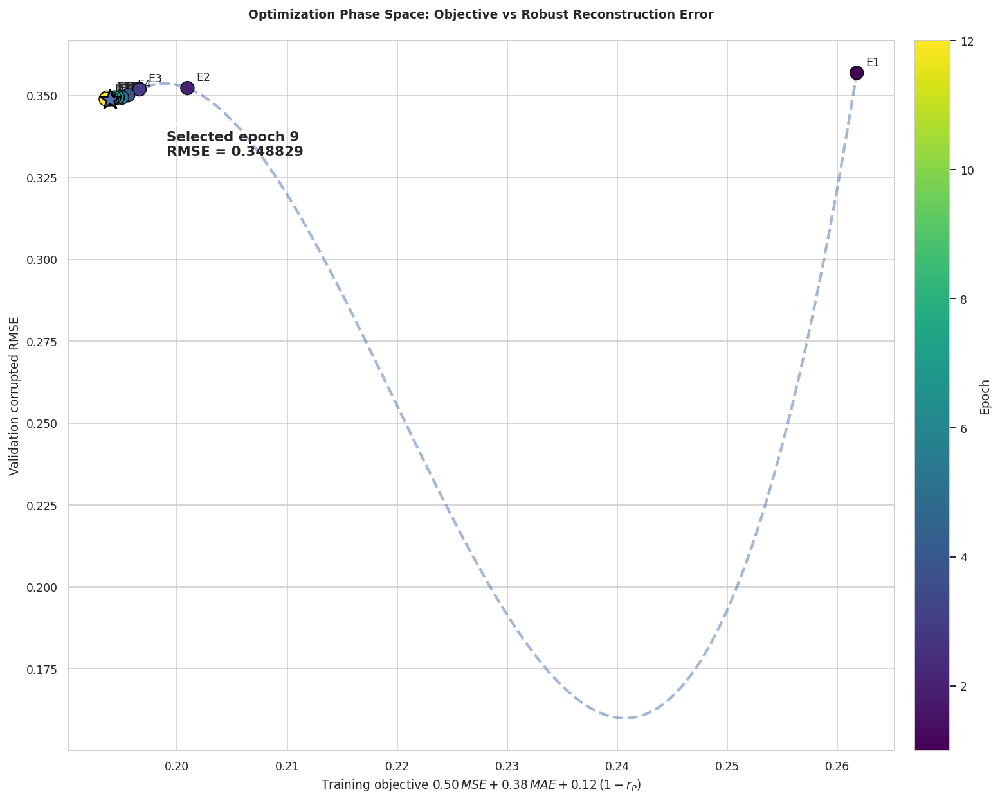

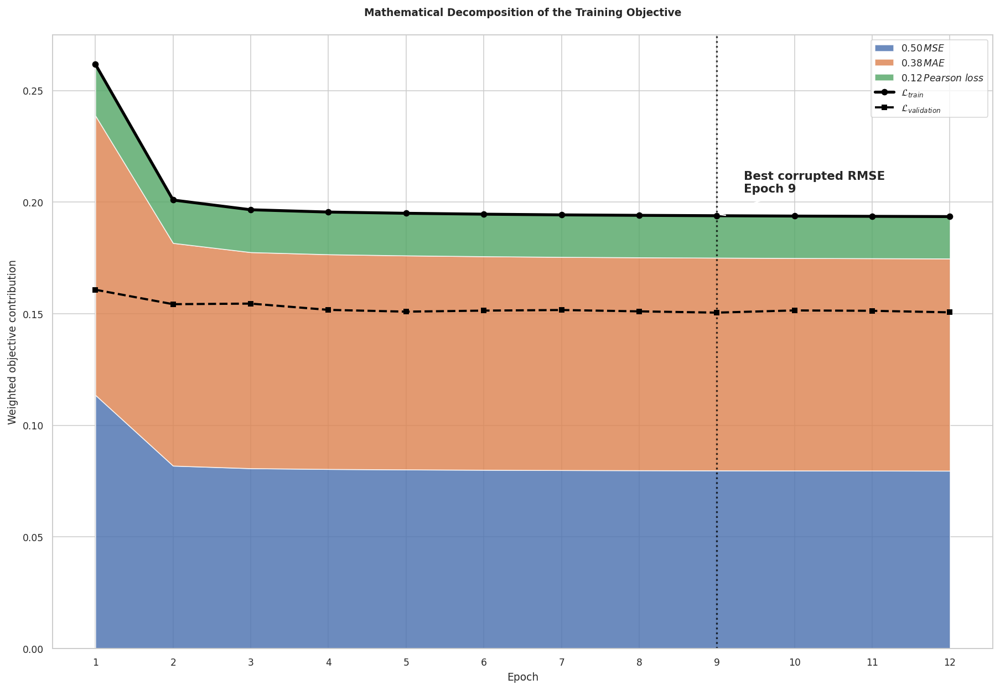

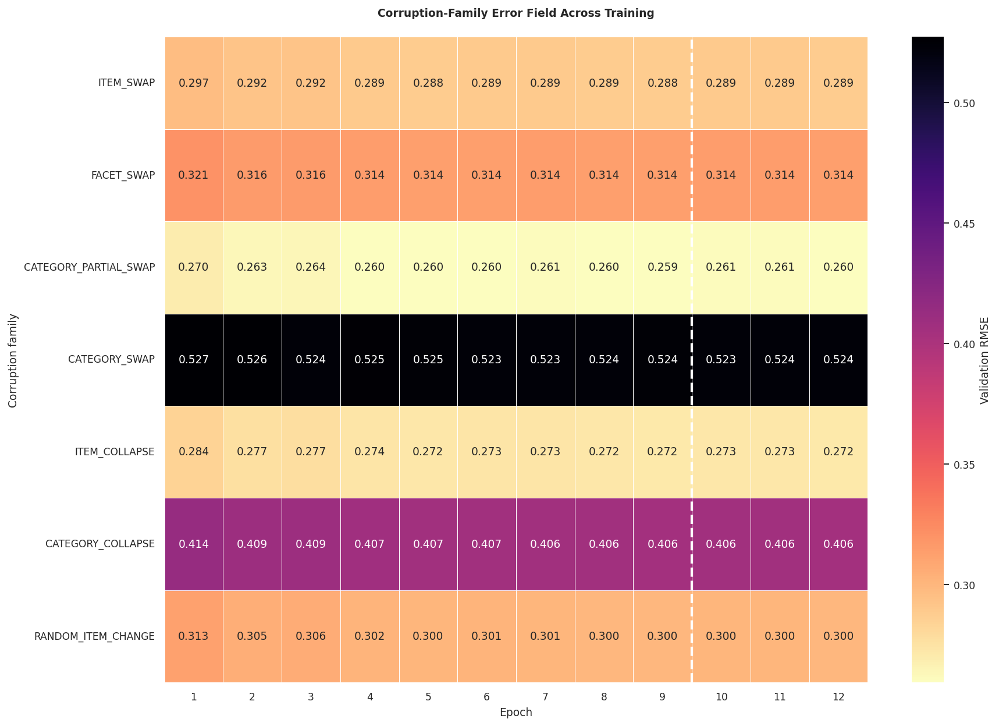

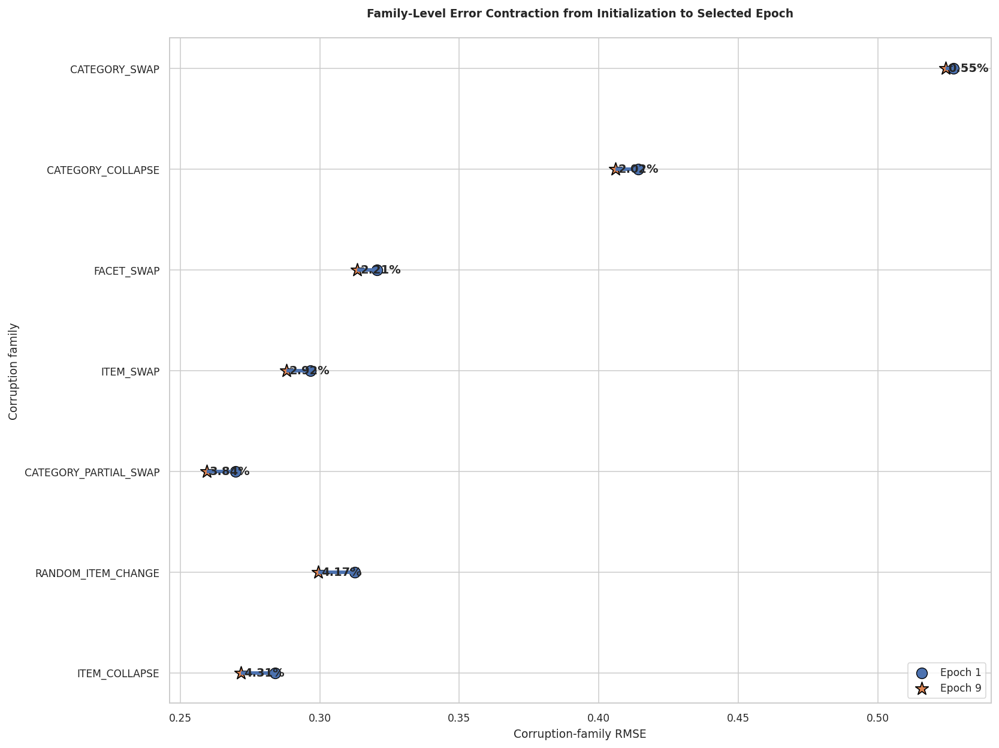

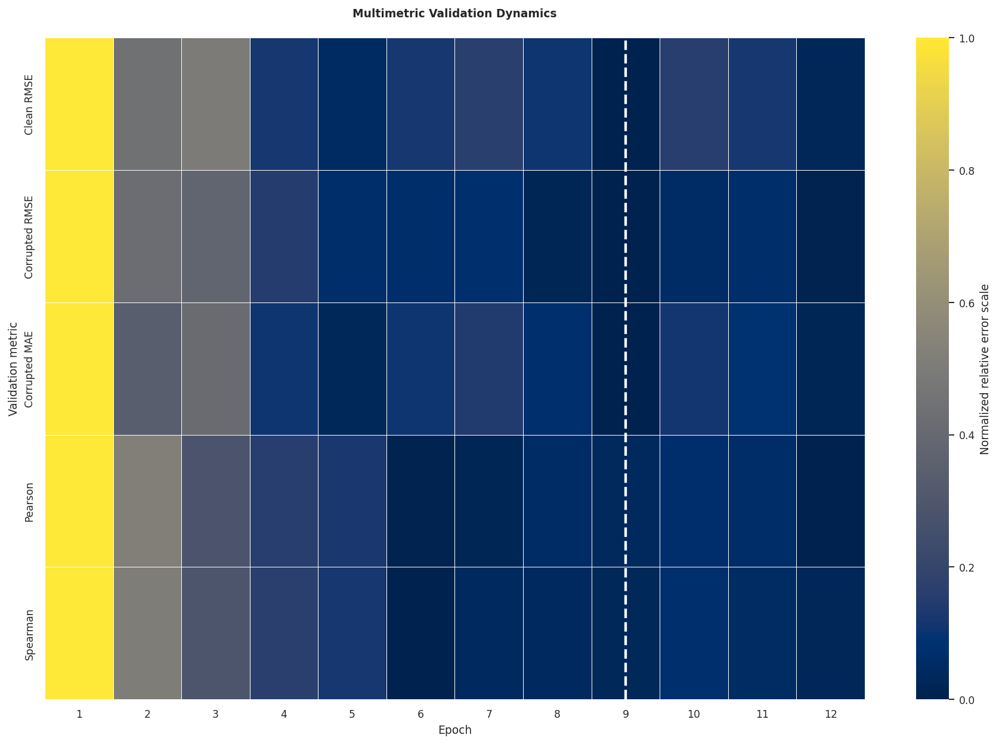

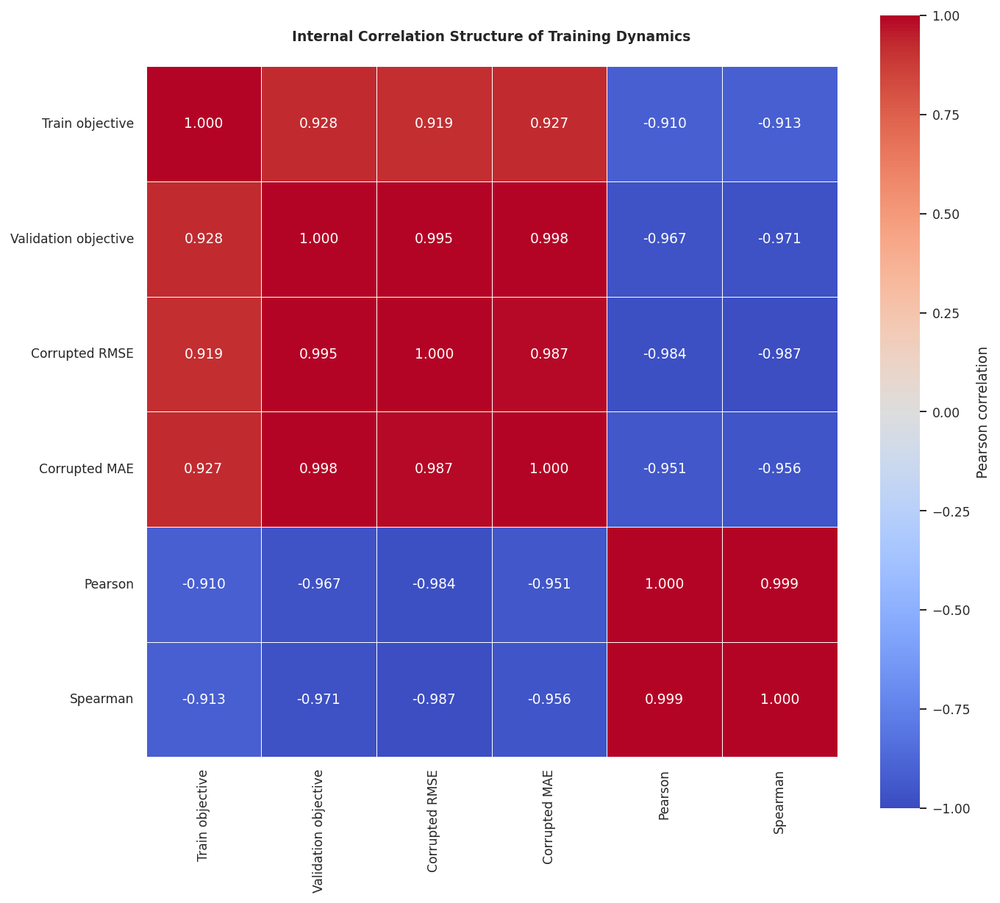

HEF IPIP120 ROBUST — B V133 PRODUCTION TRAINING
PAPER VISUALIZATION LAB
Architecture              : 120 -> 192 -> 128 -> 64 -> 30
Parameters                : 58,910
Objective                 : 0.50 MSE + 0.38 MAE + 0.12 Pearson
Epochs completed          : 12
Selected epoch            : 9
Best corrupted RMSE       : 0.348829
Selected corrupted MAE    : 0.201426
Selected clean RMSE       : 0.123152
Maximum objective error   : 0.000000740000
TEST                      : RESERVED

FIGURES:
1. Optimization phase space
2. Objective decomposition
3. Corruption-family error field
4. Family-level error contraction
5. Multimetric validation dynamics
6. Training-dynamics correlation structure

OUTPUT DIRECTORY: /content/HEF_IPIP120_V133_PRODUCTION_PAPER_FIGURES
FORMATS: PNG / PDF / SVG


In [ ]:
%pip install -q seaborn scipy

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import CubicSpline
from scipy.spatial import ConvexHull
from matplotlib import patheffects

OUT = "/content/HEF_IPIP120_V133_PRODUCTION_PAPER_FIGURES"
os.makedirs(OUT, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 500,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "axes.linewidth": 0.9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

sns.set_theme(
    style="whitegrid",
    context="paper"
)

epochs = np.arange(1, 13)

history = pd.DataFrame({
    "epoch": epochs,
    "train_objective": [
        0.261760,
        0.200936,
        0.196580,
        0.195551,
        0.194999,
        0.194595,
        0.194286,
        0.194074,
        0.193903,
        0.193749,
        0.193630,
        0.193514
    ],
    "train_mse": [
        0.227149,
        0.163750,
        0.161445,
        0.160759,
        0.160354,
        0.160050,
        0.159793,
        0.159635,
        0.159502,
        0.159411,
        0.159337,
        0.159253
    ],
    "train_mae": [
        0.329420,
        0.262575,
        0.254740,
        0.253126,
        0.252315,
        0.251735,
        0.251334,
        0.251026,
        0.250787,
        0.250528,
        0.250336,
        0.250169
    ],
    "train_pearson_component": [
        0.191721,
        0.160693,
        0.158803,
        0.158199,
        0.157851,
        0.157589,
        0.157361,
        0.157218,
        0.157105,
        0.157022,
        0.156949,
        0.156866
    ],
    "clean_rmse": [
        0.148090,
        0.134202,
        0.135595,
        0.126157,
        0.124377,
        0.126114,
        0.127198,
        0.125801,
        0.123152,
        0.127077,
        0.126121,
        0.123779
    ],
    "corrupted_rmse": [
        0.356869,
        0.352250,
        0.351847,
        0.350052,
        0.349358,
        0.349357,
        0.349419,
        0.349016,
        0.348829,
        0.349296,
        0.349355,
        0.348869
    ],
    "corrupted_mae": [
        0.219605,
        0.207542,
        0.208938,
        0.203370,
        0.201960,
        0.203352,
        0.203984,
        0.202709,
        0.201426,
        0.203539,
        0.203041,
        0.201785
    ],
    "pearson": [
        0.886547,
        0.888644,
        0.889674,
        0.890219,
        0.890370,
        0.890896,
        0.890828,
        0.890674,
        0.890757,
        0.890613,
        0.890644,
        0.890917
    ],
    "spearman": [
        0.869914,
        0.872253,
        0.873282,
        0.873887,
        0.874107,
        0.874671,
        0.874480,
        0.874479,
        0.874534,
        0.874331,
        0.874414,
        0.874558
    ],
    "validation_objective": [
        0.160742,
        0.154269,
        0.154534,
        0.151723,
        0.150926,
        0.151391,
        0.151661,
        0.151055,
        0.150492,
        0.151475,
        0.151303,
        0.150623
    ]
})

families = [
    "ITEM_SWAP",
    "FACET_SWAP",
    "CATEGORY_PARTIAL_SWAP",
    "CATEGORY_SWAP",
    "ITEM_COLLAPSE",
    "CATEGORY_COLLAPSE",
    "RANDOM_ITEM_CHANGE"
]

family_rmse = pd.DataFrame({
    "ITEM_SWAP": [
        0.296684, 0.292079, 0.292313, 0.289014,
        0.287958, 0.288843, 0.289214, 0.288660,
        0.288035, 0.289477, 0.289346, 0.288606
    ],
    "FACET_SWAP": [
        0.320610, 0.315657, 0.315667, 0.313904,
        0.313577, 0.313649, 0.314124, 0.313688,
        0.313528, 0.314331, 0.314381, 0.313833
    ],
    "CATEGORY_PARTIAL_SWAP": [
        0.269848, 0.263247, 0.263752, 0.260471,
        0.259812, 0.259982, 0.260747, 0.260265,
        0.259488, 0.260849, 0.260655, 0.259749
    ],
    "CATEGORY_SWAP": [
        0.527180, 0.526261, 0.523637, 0.525128,
        0.524960, 0.523499, 0.523137, 0.523748,
        0.524267, 0.523287, 0.523601, 0.523780
    ],
    "ITEM_COLLAPSE": [
        0.284042, 0.276868, 0.277408, 0.273866,
        0.272351, 0.273392, 0.273481, 0.272233,
        0.271801, 0.273033, 0.272966, 0.271983
    ],
    "CATEGORY_COLLAPSE": [
        0.414226, 0.409401, 0.409156, 0.407411,
        0.406923, 0.406555, 0.406485, 0.405978,
        0.405879, 0.405888, 0.406096, 0.405545
    ],
    "RANDOM_ITEM_CHANGE": [
        0.312536, 0.305118, 0.305541, 0.301826,
        0.300438, 0.301456, 0.301093, 0.299967,
        0.299507, 0.300488, 0.300443, 0.299875
    ]
}, index=epochs)

best_epoch = int(
    history.loc[
        history["corrupted_rmse"].idxmin(),
        "epoch"
    ]
)

best_rmse = float(
    history["corrupted_rmse"].min()
)

best_mae = float(
    history.loc[
        history["epoch"] == best_epoch,
        "corrupted_mae"
    ].iloc[0]
)

best_clean = float(
    history.loc[
        history["epoch"] == best_epoch,
        "clean_rmse"
    ].iloc[0]
)

objective_reconstructed = (
    0.50 * history["train_mse"]
    + 0.38 * history["train_mae"]
    + 0.12 * history["train_pearson_component"]
)

objective_error = np.abs(
    objective_reconstructed
    - history["train_objective"]
)

if objective_error.max() > 2e-6:
    raise ValueError(
        f"Objective reconstruction failed: max error = {objective_error.max()}"
    )

history["objective_reconstructed"] = objective_reconstructed

history["train_val_gap"] = (
    history["validation_objective"]
    - history["train_objective"]
)

def savefig_all(fig, name):
    fig.savefig(
        os.path.join(OUT, f"{name}.png"),
        dpi=500,
        bbox_inches="tight"
    )
    fig.savefig(
        os.path.join(OUT, f"{name}.pdf"),
        bbox_inches="tight"
    )
    fig.savefig(
        os.path.join(OUT, f"{name}.svg"),
        bbox_inches="tight"
    )

fig1, ax = plt.subplots(
    figsize=(12, 9)
)

x = history["train_objective"].to_numpy()
y = history["corrupted_rmse"].to_numpy()

spl_x = np.linspace(
    x.min(),
    x.max(),
    400
)

order = np.argsort(x)

spl = CubicSpline(
    x[order],
    y[order]
)

ax.plot(
    spl_x,
    spl(spl_x),
    linewidth=2.2,
    linestyle="--",
    alpha=0.50
)

sc = ax.scatter(
    x,
    y,
    c=history["epoch"],
    s=115,
    cmap="viridis",
    edgecolors="black",
    linewidths=0.75,
    zorder=5
)

for _, row in history.iterrows():
    ax.annotate(
        f"E{int(row['epoch'])}",
        (
            row["train_objective"],
            row["corrupted_rmse"]
        ),
        xytext=(7, 6),
        textcoords="offset points",
        fontsize=9
    )

best = history[
    history["epoch"] == best_epoch
].iloc[0]

ax.scatter(
    [best["train_objective"]],
    [best["corrupted_rmse"]],
    s=280,
    marker="*",
    edgecolors="black",
    linewidths=1.3,
    zorder=8
)

ax.annotate(
    f"Selected epoch {best_epoch}\nRMSE = {best_rmse:.6f}",
    (
        best["train_objective"],
        best["corrupted_rmse"]
    ),
    xytext=(45, -45),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.4
    )
)

ax.set_xlabel(
    "Training objective "
    r"$0.50\,MSE + 0.38\,MAE + 0.12\,(1-r_P)$"
)

ax.set_ylabel(
    "Validation corrupted RMSE"
)

ax.set_title(
    "Optimization Phase Space: Objective vs Robust Reconstruction Error",
    fontweight="bold",
    pad=18
)

cbar = fig1.colorbar(
    sc,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    "Epoch"
)

fig1.tight_layout()

savefig_all(
    fig1,
    "FIG1_OPTIMIZATION_PHASE_SPACE"
)

plt.show()


fig2, ax = plt.subplots(
    figsize=(13, 9)
)

contribution_mse = (
    0.50 * history["train_mse"]
)

contribution_mae = (
    0.38 * history["train_mae"]
)

contribution_pearson = (
    0.12 * history["train_pearson_component"]
)

ax.stackplot(
    epochs,
    contribution_mse,
    contribution_mae,
    contribution_pearson,
    labels=[
        r"$0.50\,MSE$",
        r"$0.38\,MAE$",
        r"$0.12\,Pearson\ loss$"
    ],
    alpha=0.82
)

ax.plot(
    epochs,
    history["train_objective"],
    color="black",
    linewidth=2.7,
    marker="o",
    markersize=5,
    label=r"$\mathcal{L}_{train}$"
)

ax.plot(
    epochs,
    history["validation_objective"],
    color="black",
    linestyle="--",
    linewidth=2.0,
    marker="s",
    markersize=4,
    label=r"$\mathcal{L}_{validation}$"
)

ax.axvline(
    best_epoch,
    color="black",
    linestyle=":",
    linewidth=1.7,
    alpha=0.75
)

ax.annotate(
    f"Best corrupted RMSE\nEpoch {best_epoch}",
    xy=(
        best_epoch,
        history.loc[
            history["epoch"] == best_epoch,
            "train_objective"
        ].iloc[0]
    ),
    xytext=(25, 22),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.2
    )
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Weighted objective contribution"
)

ax.set_xticks(
    epochs
)

ax.set_title(
    "Mathematical Decomposition of the Training Objective",
    fontweight="bold",
    pad=18
)

ax.legend(
    loc="upper right",
    frameon=True
)

fig2.tight_layout()

savefig_all(
    fig2,
    "FIG2_OBJECTIVE_DECOMPOSITION"
)

plt.show()


fig3, ax = plt.subplots(
    figsize=(13, 9)
)

heat = family_rmse.T

sns.heatmap(
    heat,
    ax=ax,
    cmap="magma_r",
    annot=True,
    fmt=".3f",
    linewidths=0.30,
    cbar_kws={
        "label": "Validation RMSE"
    }
)

ax.axvline(
    best_epoch - 0.0,
    color="white",
    linewidth=2.2,
    linestyle="--"
)

ax.set_title(
    "Corruption-Family Error Field Across Training",
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Corruption family"
)

ax.set_xticklabels(
    [str(e) for e in epochs],
    rotation=0
)

fig3.tight_layout()

savefig_all(
    fig3,
    "FIG3_CORRUPTION_FAMILY_ERROR_FIELD"
)

plt.show()


family_delta = pd.DataFrame({
    "family": families,
    "epoch_1": [
        family_rmse.loc[1, f]
        for f in families
    ],
    "best": [
        family_rmse.loc[best_epoch, f]
        for f in families
    ],
    "epoch_12": [
        family_rmse.loc[12, f]
        for f in families
    ]
})

family_delta["change_to_best"] = (
    family_delta["epoch_1"]
    - family_delta["best"]
)

family_delta["change_pct"] = (
    family_delta["change_to_best"]
    / family_delta["epoch_1"]
    * 100.0
)

family_delta = family_delta.sort_values(
    "change_pct",
    ascending=False
)

fig4, ax = plt.subplots(
    figsize=(12, 9)
)

ypos = np.arange(
    len(family_delta)
)

ax.hlines(
    ypos,
    family_delta["epoch_1"],
    family_delta["best"],
    linewidth=3.0
)

ax.scatter(
    family_delta["epoch_1"],
    ypos,
    s=85,
    marker="o",
    edgecolors="black",
    linewidths=0.7,
    label="Epoch 1"
)

ax.scatter(
    family_delta["best"],
    ypos,
    s=135,
    marker="*",
    edgecolors="black",
    linewidths=0.9,
    label=f"Epoch {best_epoch}"
)

for i, (_, row) in enumerate(
    family_delta.iterrows()
):
    ax.text(
        row["best"] + 0.001,
        i,
        f"{row['change_pct']:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_yticks(
    ypos
)

ax.set_yticklabels(
    family_delta["family"]
)

ax.set_xlabel(
    "Corruption-family RMSE"
)

ax.set_ylabel(
    "Corruption family"
)

ax.set_title(
    "Family-Level Error Contraction from Initialization to Selected Epoch",
    fontweight="bold",
    pad=18
)

ax.legend(
    frameon=True,
    loc="lower right"
)

fig4.tight_layout()

savefig_all(
    fig4,
    "FIG4_FAMILY_ERROR_CONTRACTION"
)

plt.show()


metrics = pd.DataFrame({
    "epoch": epochs,
    "Clean RMSE": history["clean_rmse"],
    "Corrupted RMSE": history["corrupted_rmse"],
    "Corrupted MAE": history["corrupted_mae"],
    "Pearson": history["pearson"],
    "Spearman": history["spearman"]
})

scaled = metrics.copy()

for col in metrics.columns[1:]:
    values = metrics[col].to_numpy()

    if col in [
        "Clean RMSE",
        "Corrupted RMSE",
        "Corrupted MAE"
    ]:
        scaled[col] = (
            values - values.min()
        ) / (
            values.max() - values.min()
        )

    else:
        scaled[col] = (
            values.max() - values
        ) / (
            values.max() - values.min()
        )

scaled = scaled.set_index(
    "epoch"
)

fig5, ax = plt.subplots(
    figsize=(13, 9)
)

sns.heatmap(
    scaled.T,
    ax=ax,
    cmap="cividis",
    annot=False,
    linewidths=0.4,
    cbar_kws={
        "label": "Normalized relative error scale"
    }
)

ax.axvline(
    best_epoch - 0.5,
    color="white",
    linewidth=2.2,
    linestyle="--"
)

ax.set_title(
    "Multimetric Validation Dynamics",
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Validation metric"
)

ax.set_xticklabels(
    [str(e) for e in epochs],
    rotation=0
)

fig5.tight_layout()

savefig_all(
    fig5,
    "FIG5_MULTIMETRIC_VALIDATION_DYNAMICS"
)

plt.show()


X = history[
    [
        "train_objective",
        "validation_objective",
        "corrupted_rmse",
        "corrupted_mae",
        "pearson",
        "spearman"
    ]
].to_numpy()

corr = np.corrcoef(
    X,
    rowvar=False
)

corr_df = pd.DataFrame(
    corr,
    index=[
        "Train objective",
        "Validation objective",
        "Corrupted RMSE",
        "Corrupted MAE",
        "Pearson",
        "Spearman"
    ],
    columns=[
        "Train objective",
        "Validation objective",
        "Corrupted RMSE",
        "Corrupted MAE",
        "Pearson",
        "Spearman"
    ]
)

fig6, ax = plt.subplots(
    figsize=(10, 9)
)

sns.heatmap(
    corr_df,
    ax=ax,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".3f",
    square=True,
    linewidths=0.5,
    cbar_kws={
        "label": "Pearson correlation"
    }
)

ax.set_title(
    "Internal Correlation Structure of Training Dynamics",
    fontweight="bold",
    pad=18
)

fig6.tight_layout()

savefig_all(
    fig6,
    "FIG6_TRAINING_DYNAMICS_CORRELATION"
)

plt.show()


print("=" * 82)
print("HEF IPIP120 ROBUST — B V133 PRODUCTION TRAINING")
print("PAPER VISUALIZATION LAB")
print("=" * 82)
print(f"Architecture              : 120 -> 192 -> 128 -> 64 -> 30")
print(f"Parameters                : 58,910")
print(f"Objective                 : 0.50 MSE + 0.38 MAE + 0.12 Pearson")
print(f"Epochs completed          : {len(history)}")
print(f"Selected epoch            : {best_epoch}")
print(f"Best corrupted RMSE       : {best_rmse:.6f}")
print(f"Selected corrupted MAE    : {best_mae:.6f}")
print(f"Selected clean RMSE       : {best_clean:.6f}")
print(f"Maximum objective error   : {objective_error.max():.12f}")
print("TEST                      : RESERVED")
print()
print("FIGURES:")
print("1. Optimization phase space")
print("2. Objective decomposition")
print("3. Corruption-family error field")
print("4. Family-level error contraction")
print("5. Multimetric validation dynamics")
print("6. Training-dynamics correlation structure")
print()
print(f"OUTPUT DIRECTORY: {OUT}")
print("FORMATS: PNG / PDF / SVG")

In [17]:
from __future__ import annotations

import gc
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F



ROOT = Path(
    "/content/HEF_IPIP120_ROBUST_DATASET_V3"
)

TRAIN_ROOT = (
    ROOT /
    "TRAIN"
)

VAL_CLEAN_ROOT = (
    ROOT /
    "VALIDATION" /
    "CLEAN"
)

VAL_CORRUPTED_ROOT = (
    ROOT /
    "VALIDATION" /
    "CORRUPTED"
)

V133_ROOT = (
    ROOT /
    "MLP_GATEWAY_B_V133_PRODUCTION"
)

V133_CHECKPOINT = (
    V133_ROOT /
    "best.pt"
)

OUTPUT_ROOT = (
    ROOT /
    "V133_FINE_TUNING_DIAGNOSTIC"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

INPUT_DIM = 120
OUTPUT_DIM = 30
VIEWS_PER_SUBJECT = 143

HIDDEN_DIMS = (
    192,
    128,
    64,
)

DROPOUT = 0.10

EXPECTED_TRAIN_SUBJECTS = 287_263
EXPECTED_TRAIN_EXAMPLES = 41_078_609

VAL_CLEAN_EXPECTED = 61_556
VAL_CORRUPTED_EXPECTED = 338_444

BATCH_SIZE = 8192
VAL_BATCH_SIZE = 32768

SCREEN_SUBJECTS = 10_000

LOCAL_EPOCHS = 1

LOCAL_LR = 2e-4
LOCAL_WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0

USE_BF16 = True

GLOBAL_SEED = 20260924
SIES_SEED = 20260925
SCREEN_SEED = 20260926

BASE_MSE = 0.50
BASE_MAE = 0.38
BASE_PEARSON = 0.12

RMSE_TOLERANCE = 0.0010
PEARSON_TOLERANCE = 0.0020
SPEARMAN_TOLERANCE = 0.0020

RUN_HEAD_ONLY = True
RUN_FULL_NETWORK = True

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "CUDA is required for this diagnostic."
    )

torch.set_float32_matmul_precision("high")


def seed_everything(
    seed: int
) -> None:

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(
    GLOBAL_SEED
)



OBJECTIVES = [
    {
        "name": "V133_BASE",
        "mse": 0.50,
        "mae": 0.38,
        "pearson": 0.12,
    },
    {
        "name": "LOCAL_A",
        "mse": 0.46,
        "mae": 0.42,
        "pearson": 0.12,
    },
    {
        "name": "LOCAL_B",
        "mse": 0.48,
        "mae": 0.40,
        "pearson": 0.12,
    },
    {
        "name": "LOCAL_C",
        "mse": 0.52,
        "mae": 0.36,
        "pearson": 0.12,
    },
    {
        "name": "LOCAL_D",
        "mse": 0.50,
        "mae": 0.42,
        "pearson": 0.08,
    },
    {
        "name": "LOCAL_E",
        "mse": 0.50,
        "mae": 0.36,
        "pearson": 0.14,
    },
    {
        "name": "LOCAL_F",
        "mse": 0.54,
        "mae": 0.34,
        "pearson": 0.12,
    },
    {
        "name": "LOCAL_G",
        "mse": 0.46,
        "mae": 0.44,
        "pearson": 0.10,
    },
    {
        "name": "LOCAL_H",
        "mse": 0.52,
        "mae": 0.38,
        "pearson": 0.10,
    },
]


for objective in OBJECTIVES:

    total = (
        objective["mse"]
        +
        objective["mae"]
        +
        objective["pearson"]
    )

    if abs(total - 1.0) > 1e-8:
        raise RuntimeError(
            f"Objective does not sum to 1: "
            f"{objective['name']} -> {total}"
        )


class HEFIPIP120MLP(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()

        self.trunk = nn.Sequential(

            nn.Linear(
                INPUT_DIM,
                HIDDEN_DIMS[0]
            ),

            nn.LayerNorm(
                HIDDEN_DIMS[0]
            ),

            nn.GELU(),

            nn.Dropout(
                DROPOUT
            ),

            nn.Linear(
                HIDDEN_DIMS[0],
                HIDDEN_DIMS[1]
            ),

            nn.LayerNorm(
                HIDDEN_DIMS[1]
            ),

            nn.GELU(),

            nn.Dropout(
                DROPOUT
            ),

            nn.Linear(
                HIDDEN_DIMS[1],
                HIDDEN_DIMS[2]
            ),

            nn.LayerNorm(
                HIDDEN_DIMS[2]
            ),

            nn.GELU(),

            nn.Dropout(
                DROPOUT
            ),
        )

        self.output = nn.Linear(
            HIDDEN_DIMS[2],
            OUTPUT_DIM
        )

    def forward(
        self,
        x
    ):

        z = self.trunk(
            x
        )

        return self.output(
            z
        )


def count_parameters(
    model
):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


if not V133_CHECKPOINT.exists():

    raise FileNotFoundError(
        V133_CHECKPOINT
    )


def load_checkpoint(
    path
):

    try:

        return torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )

    except TypeError:

        return torch.load(
            path,
            map_location="cpu"
        )


checkpoint = load_checkpoint(
    V133_CHECKPOINT
)

if (
    "model_state_dict"
    not in checkpoint
):

    raise RuntimeError(
        "model_state_dict not found in V133 checkpoint."
    )


BASE_MODEL = HEFIPIP120MLP()

BASE_MODEL.load_state_dict(
    checkpoint["model_state_dict"]
)

BASE_MODEL.to(
    DEVICE
)

BASE_MODEL.eval()

MODEL_PARAMETER_COUNT = count_parameters(
    BASE_MODEL
)

if MODEL_PARAMETER_COUNT != 58_910:

    raise RuntimeError(
        f"Unexpected parameter count: "
        f"{MODEL_PARAMETER_COUNT}"
    )


def metric_rmse(
    prediction,
    target
):

    diff = (
        prediction.astype(
            np.float64
        )
        -
        target.astype(
            np.float64
        )
    )

    return float(
        np.sqrt(
            np.mean(
                diff * diff
            )
        )
    )


def metric_mae(
    prediction,
    target
):

    diff = (
        prediction.astype(
            np.float64
        )
        -
        target.astype(
            np.float64
        )
    )

    return float(
        np.mean(
            np.abs(
                diff
            )
        )
    )


def metric_pearson(
    prediction,
    target
):

    p = prediction.astype(
        np.float64
    )

    y = target.astype(
        np.float64
    )

    p = p - p.mean(
        axis=1,
        keepdims=True
    )

    y = y - y.mean(
        axis=1,
        keepdims=True
    )

    numerator = np.sum(
        p * y,
        axis=1
    )

    denominator = (
        np.sqrt(
            np.sum(
                p * p,
                axis=1
            )
        )
        *
        np.sqrt(
            np.sum(
                y * y,
                axis=1
            )
        )
    )

    correlation = (
        numerator /
        np.maximum(
            denominator,
            1e-12
        )
    )

    return float(
        np.mean(
            correlation
        )
    )


def metric_spearman(
    prediction,
    target
):

    def rank_rows(
        values
    ):

        order = np.argsort(
            values,
            axis=1,
            kind="mergesort"
        )

        ranks = np.empty_like(
            order,
            dtype=np.float64
        )

        rows = np.arange(
            values.shape[0]
        )[:, None]

        ranks[
            rows,
            order
        ] = np.arange(
            values.shape[1]
        )[None, :] + 1.0

        return ranks

    p_rank = rank_rows(
        prediction
    )

    y_rank = rank_rows(
        target
    )

    return metric_pearson(
        p_rank,
        y_rank
    )


def pearson_profile_loss(
    prediction,
    target
):

    prediction = prediction.float()
    target = target.float()

    p = (
        prediction
        -
        prediction.mean(
            dim=1,
            keepdim=True
        )
    )

    y = (
        target
        -
        target.mean(
            dim=1,
            keepdim=True
        )
    )

    numerator = (
        p * y
    ).sum(
        dim=1
    )

    denominator = (
        torch.sqrt(
            (p * p).sum(
                dim=1
            )
            +
            1e-8
        )
        *
        torch.sqrt(
            (y * y).sum(
                dim=1
            )
            +
            1e-8
        )
    )

    correlation = (
        numerator /
        denominator
    )

    return (
        1.0 -
        correlation
    ).mean()


def objective_loss(
    prediction,
    target,
    objective
):

    prediction = prediction.float()
    target = target.float()

    mse = F.mse_loss(
        prediction,
        target
    )

    mae = F.l1_loss(
        prediction,
        target
    )

    pearson = pearson_profile_loss(
        prediction,
        target
    )

    loss = (
        objective["mse"] *
        mse
        +
        objective["mae"] *
        mae
        +
        objective["pearson"] *
        pearson
    )

    return (
        loss,
        mse.detach(),
        mae.detach(),
        pearson.detach()
    )


def discover_train_shards():

    paths = sorted(
        TRAIN_ROOT.glob(
            "shard_*_X.npy"
        )
    )

    if not paths:

        raise FileNotFoundError(
            f"No TRAIN shards found in {TRAIN_ROOT}"
        )

    return paths


TRAIN_X_PATHS = discover_train_shards()

TRAIN_MEMMAPS = []
TRAIN_Y_MEMMAPS = []

TRAIN_SHARD_SUBJECT_STARTS = []
TRAIN_SHARD_SUBJECT_ENDS = []

global_subject_cursor = 0

for x_path in TRAIN_X_PATHS:

    y_path = Path(
        str(x_path).replace(
            "_X.npy",
            "_Y.npy"
        )
    )

    if not y_path.exists():

        raise FileNotFoundError(
            y_path
        )

    x_mm = np.load(
        x_path,
        mmap_mode="r"
    )

    y_mm = np.load(
        y_path,
        mmap_mode="r"
    )

    if x_mm.ndim != 2:

        raise RuntimeError(
            f"Invalid X shape: "
            f"{x_path} -> {x_mm.shape}"
        )

    if y_mm.ndim != 2:

        raise RuntimeError(
            f"Invalid Y shape: "
            f"{y_path} -> {y_mm.shape}"
        )

    if x_mm.shape[0] % VIEWS_PER_SUBJECT != 0:

        raise RuntimeError(
            f"Shard is not aligned to "
            f"{VIEWS_PER_SUBJECT} views: {x_path}"
        )

    shard_subjects = (
        x_mm.shape[0] //
        VIEWS_PER_SUBJECT
    )

    TRAIN_SHARD_SUBJECT_STARTS.append(
        global_subject_cursor
    )

    global_subject_cursor += (
        shard_subjects
    )

    TRAIN_SHARD_SUBJECT_ENDS.append(
        global_subject_cursor
    )

    TRAIN_MEMMAPS.append(
        x_mm
    )

    TRAIN_Y_MEMMAPS.append(
        y_mm
    )

TRAIN_SHARD_SUBJECT_STARTS = np.asarray(
    TRAIN_SHARD_SUBJECT_STARTS,
    dtype=np.int64
)

TRAIN_SHARD_SUBJECT_ENDS = np.asarray(
    TRAIN_SHARD_SUBJECT_ENDS,
    dtype=np.int64
)

if global_subject_cursor != EXPECTED_TRAIN_SUBJECTS:

    raise RuntimeError(
        "TRAIN subject count mismatch: "
        f"{global_subject_cursor} "
        f"!= "
        f"{EXPECTED_TRAIN_SUBJECTS}"
    )



def locate_subjects(
    subject_ids
):

    subject_ids = np.asarray(
        subject_ids,
        dtype=np.int64
    )

    shard_ids = np.searchsorted(
        TRAIN_SHARD_SUBJECT_ENDS,
        subject_ids,
        side="right"
    )

    local_subject_ids = (
        subject_ids
        -
        TRAIN_SHARD_SUBJECT_STARTS[
            shard_ids
        ]
    )

    return (
        shard_ids,
        local_subject_ids
    )


def fetch_train_batch(
    subject_ids,
    view_ids
):

    subject_ids = np.asarray(
        subject_ids,
        dtype=np.int64
    )

    view_ids = np.asarray(
        view_ids,
        dtype=np.int64
    )

    if (
        len(subject_ids)
        !=
        len(view_ids)
    ):

        raise RuntimeError(
            "Subject/view mismatch."
        )

    if (
        len(np.unique(subject_ids))
        !=
        len(subject_ids)
    ):

        raise RuntimeError(
            "SIES violation: duplicate subject."
        )

    shard_ids, local_subject_ids = (
        locate_subjects(
            subject_ids
        )
    )

    n = len(
        subject_ids
    )

    batch_x = np.empty(
        (
            n,
            INPUT_DIM
        ),
        dtype=np.uint8
    )

    batch_y = np.empty(
        (
            n,
            OUTPUT_DIM
        ),
        dtype=np.float32
    )

    for shard_id in np.unique(
        shard_ids
    ):

        positions = np.flatnonzero(
            shard_ids ==
            shard_id
        )

        local_rows = (
            local_subject_ids[
                positions
            ]
            *
            VIEWS_PER_SUBJECT
            +
            view_ids[
                positions
            ]
        )

        x_mm = TRAIN_MEMMAPS[
            int(shard_id)
        ]

        y_mm = TRAIN_Y_MEMMAPS[
            int(shard_id)
        ]

        batch_x[
            positions
        ] = np.asarray(
            x_mm[
                local_rows
            ],
            dtype=np.uint8
        )

        batch_y[
            positions
        ] = np.asarray(
            y_mm[
                local_rows
            ],
            dtype=np.float32
        )

    return (
        batch_x,
        batch_y
    )


def discover_validation_shards(
    root
):

    paths = sorted(
        root.glob(
            "shard_*_X.npy"
        )
    )

    if not paths:

        raise FileNotFoundError(
            f"No validation shards found: {root}"
        )

    return paths


def load_validation_split(
    root
):

    xs = []
    ys = []
    types = []
    severities = []

    for x_path in discover_validation_shards(
        root
    ):

        y_path = Path(
            str(x_path).replace(
                "_X.npy",
                "_Y.npy"
            )
        )

        type_path = Path(
            str(x_path).replace(
                "_X.npy",
                "_type.npy"
            )
        )

        severity_path = Path(
            str(x_path).replace(
                "_X.npy",
                "_severity.npy"
            )
        )

        X = np.load(
            x_path
        )

        Y = np.load(
            y_path
        )

        T = np.load(
            type_path
        )

        S = np.load(
            severity_path
        )

        xs.append(
            X.astype(
                np.uint8,
                copy=False
            )
        )

        ys.append(
            Y.astype(
                np.float32,
                copy=False
            )
        )

        types.append(
            T.astype(
                np.uint8,
                copy=False
            )
        )

        severities.append(
            S.astype(
                np.uint8,
                copy=False
            )
        )

    return (
        np.concatenate(
            xs,
            axis=0
        ),
        np.concatenate(
            ys,
            axis=0
        ),
        np.concatenate(
            types,
            axis=0
        ),
        np.concatenate(
            severities,
            axis=0
        )
    )


VAL_CLEAN_X, VAL_CLEAN_Y, VAL_CLEAN_TYPE, VAL_CLEAN_SEVERITY = (
    load_validation_split(
        VAL_CLEAN_ROOT
    )
)

VAL_CORRUPTED_X, VAL_CORRUPTED_Y, VAL_CORRUPTED_TYPE, VAL_CORRUPTED_SEVERITY = (
    load_validation_split(
        VAL_CORRUPTED_ROOT
    )
)

if len(VAL_CLEAN_X) != VAL_CLEAN_EXPECTED:

    raise RuntimeError(
        "Unexpected CLEAN validation size."
    )

if len(VAL_CORRUPTED_X) != VAL_CORRUPTED_EXPECTED:

    raise RuntimeError(
        "Unexpected CORRUPTED validation size."
    )


@torch.no_grad()
def predict_numpy(
    model,
    X
):

    model.eval()

    predictions = []

    for start in range(
        0,
        len(X),
        VAL_BATCH_SIZE
    ):

        end = min(
            start + VAL_BATCH_SIZE,
            len(X)
        )

        xb = torch.from_numpy(
            X[
                start:end
            ]
        ).to(
            DEVICE,
            non_blocking=True
        )

        xb = (
            xb.float()
            - 3.0
        ) / 2.0

        if USE_BF16:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.bfloat16
            ):

                pred = model(
                    xb
                )

        else:

            pred = model(
                xb
            )

        predictions.append(
            pred.float()
            .cpu()
            .numpy()
        )

    return np.concatenate(
        predictions,
        axis=0
    )


FAMILY_NAMES = {
    0: "CLEAN",
    1: "ITEM_SWAP",
    2: "FACET_SWAP",
    3: "CATEGORY_PARTIAL_SWAP",
    4: "CATEGORY_SWAP",
    5: "ITEM_COLLAPSE",
    6: "CATEGORY_COLLAPSE",
    7: "RANDOM_ITEM_CHANGE",
}


def evaluate_detailed(
    model
):

    clean_pred = predict_numpy(
        model,
        VAL_CLEAN_X
    )

    corrupted_pred = predict_numpy(
        model,
        VAL_CORRUPTED_X
    )

    metrics = {
        "clean_rmse":
            metric_rmse(
                clean_pred,
                VAL_CLEAN_Y
            ),

        "clean_mae":
            metric_mae(
                clean_pred,
                VAL_CLEAN_Y
            ),

        "clean_pearson":
            metric_pearson(
                clean_pred,
                VAL_CLEAN_Y
            ),

        "clean_spearman":
            metric_spearman(
                clean_pred,
                VAL_CLEAN_Y
            ),

        "corrupted_rmse":
            metric_rmse(
                corrupted_pred,
                VAL_CORRUPTED_Y
            ),

        "corrupted_mae":
            metric_mae(
                corrupted_pred,
                VAL_CORRUPTED_Y
            ),

        "corrupted_pearson":
            metric_pearson(
                corrupted_pred,
                VAL_CORRUPTED_Y
            ),

        "corrupted_spearman":
            metric_spearman(
                corrupted_pred,
                VAL_CORRUPTED_Y
            ),
    }

    family_rows = []

    for code, name in FAMILY_NAMES.items():

        if code == 0:
            continue

        mask = (
            VAL_CORRUPTED_TYPE ==
            code
        )

        if not np.any(mask):
            continue

        abs_error = np.abs(
            corrupted_pred[mask]
            -
            VAL_CORRUPTED_Y[mask]
        )

        sq_error = (
            corrupted_pred[mask]
            -
            VAL_CORRUPTED_Y[mask]
        ) ** 2

        family_rows.append(
            {
                "family":
                    name,

                "n":
                    int(
                        mask.sum()
                    ),

                "rmse":
                    float(
                        np.sqrt(
                            np.mean(
                                sq_error
                            )
                        )
                    ),

                "mae":
                    float(
                        np.mean(
                            abs_error
                        )
                    ),

                "abs_error_burden":
                    float(
                        abs_error.sum()
                    ),
            }
        )

    family_df = pd.DataFrame(
        family_rows
    )

    family_df[
        "abs_error_burden_fraction"
    ] = (
        family_df[
            "abs_error_burden"
        ]
        /
        family_df[
            "abs_error_burden"
        ].sum()
    )

    severity_rows = []

    for severity in np.unique(
        VAL_CORRUPTED_SEVERITY
    ):

        mask = (
            VAL_CORRUPTED_SEVERITY ==
            severity
        )

        abs_error = np.abs(
            corrupted_pred[mask]
            -
            VAL_CORRUPTED_Y[mask]
        )

        sq_error = (
            corrupted_pred[mask]
            -
            VAL_CORRUPTED_Y[mask]
        ) ** 2

        severity_rows.append(
            {
                "severity":
                    int(
                        severity
                    ),

                "n":
                    int(
                        mask.sum()
                    ),

                "rmse":
                    float(
                        np.sqrt(
                            np.mean(
                                sq_error
                            )
                        )
                    ),

                "mae":
                    float(
                        np.mean(
                            abs_error
                        )
                    ),

                "abs_error_burden":
                    float(
                        abs_error.sum()
                    ),
            }
        )

    severity_df = pd.DataFrame(
        severity_rows
    )

    severity_df[
        "abs_error_burden_fraction"
    ] = (
        severity_df[
            "abs_error_burden"
        ]
        /
        severity_df[
            "abs_error_burden"
        ].sum()
    )

    return (
        metrics,
        family_df,
        severity_df,
        clean_pred,
        corrupted_pred
    )


print()
print("=" * 110)
print("V133 BASELINE DIAGNOSTIC")
print("=" * 110)

baseline_metrics, baseline_family_df, baseline_severity_df, _, _ = (
    evaluate_detailed(
        BASE_MODEL
    )
)

print()
print("GLOBAL")

for key, value in baseline_metrics.items():

    print(
        f"{key:<28} : {value:.6f}"
    )

print()
print("FAMILY")

print(
    baseline_family_df[
        [
            "family",
            "n",
            "rmse",
            "mae",
            "abs_error_burden_fraction"
        ]
    ].to_string(
        index=False
    )
)

print()
print("SEVERITY")

print(
    baseline_severity_df[
        [
            "severity",
            "n",
            "rmse",
            "mae",
            "abs_error_burden_fraction"
        ]
    ].to_string(
        index=False
    )
)

baseline_family_df.to_csv(
    OUTPUT_ROOT /
    "baseline_family_diagnostic.csv",
    index=False
)

baseline_severity_df.to_csv(
    OUTPUT_ROOT /
    "baseline_severity_diagnostic.csv",
    index=False
)

with open(
    OUTPUT_ROOT /
    "baseline_metrics.json",
    "w"
) as f:

    json.dump(
        baseline_metrics,
        f,
        indent=2
    )



rng = np.random.default_rng(
    SCREEN_SEED
)

SCREEN_SUBJECT_IDS = np.sort(
    rng.choice(
        EXPECTED_TRAIN_SUBJECTS,
        size=SCREEN_SUBJECTS,
        replace=False
    )
)

if len(
    np.unique(
        SCREEN_SUBJECT_IDS
    )
) != SCREEN_SUBJECTS:

    raise RuntimeError(
        "Duplicate screening subjects."
    )

def set_train_mode(
    model,
    mode
):

    for parameter in model.parameters():

        parameter.requires_grad = False

    if mode == "head_only":

        for parameter in model.output.parameters():

            parameter.requires_grad = True

    elif mode == "full_network":

        for parameter in model.parameters():

            parameter.requires_grad = True

    else:

        raise ValueError(
            mode
        )


def train_local(
    model,
    objective,
    mode,
    seed
):

    seed_everything(
        seed
    )

    set_train_mode(
        model,
        mode
    )

    trainable_parameters = [
        p
        for p in model.parameters()
        if p.requires_grad
    ]

    optimizer = torch.optim.AdamW(
        trainable_parameters,
        lr=LOCAL_LR,
        weight_decay=LOCAL_WEIGHT_DECAY
    )

    model.train()

    total_steps = (
        LOCAL_EPOCHS
        *
        VIEWS_PER_SUBJECT
        *
        math.ceil(
            SCREEN_SUBJECTS /
            BATCH_SIZE
        )
    )

    step_counter = 0

    for epoch in range(
        LOCAL_EPOCHS
    ):

        permutation = (
            SCREEN_SUBJECT_IDS[
                np.random.permutation(
                    SCREEN_SUBJECTS
                )
            ]
        )

        for view_id in range(
            VIEWS_PER_SUBJECT
        ):

            for start in range(
                0,
                SCREEN_SUBJECTS,
                BATCH_SIZE
            ):

                end = min(
                    start + BATCH_SIZE,
                    SCREEN_SUBJECTS
                )

                batch_subjects = (
                    permutation[
                        start:end
                    ]
                )

                batch_views = np.full(
                    len(batch_subjects),
                    view_id,
                    dtype=np.int64
                )

                batch_x, batch_y = (
                    fetch_train_batch(
                        batch_subjects,
                        batch_views
                    )
                )

                xb = torch.from_numpy(
                    batch_x
                ).to(
                    DEVICE,
                    non_blocking=True
                )

                yb = torch.from_numpy(
                    batch_y
                ).to(
                    DEVICE,
                    non_blocking=True
                )

                xb = (
                    xb.float()
                    - 3.0
                ) / 2.0

                optimizer.zero_grad(
                    set_to_none=True
                )

                if USE_BF16:

                    with torch.autocast(
                        device_type="cuda",
                        dtype=torch.bfloat16
                    ):

                        prediction = model(
                            xb
                        )

                        loss, _, _, _ = (
                            objective_loss(
                                prediction,
                                yb,
                                objective
                            )
                        )

                else:

                    prediction = model(
                        xb
                    )

                    loss, _, _, _ = (
                        objective_loss(
                            prediction,
                            yb,
                            objective
                        )
                    )

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    trainable_parameters,
                    GRAD_CLIP_NORM
                )

                optimizer.step()

                step_counter += 1

        model.eval()

        local_metrics = evaluate_detailed(
            model
        )[0]

        model.train()

        print(
            f"      epoch={epoch + 1} "
            f"objective={objective['name']:<10} "
            f"mode={mode:<13} "
            f"RMSE={local_metrics['corrupted_rmse']:.6f} "
            f"MAE={local_metrics['corrupted_mae']:.6f} "
            f"P={local_metrics['corrupted_pearson']:.6f} "
            f"S={local_metrics['corrupted_spearman']:.6f} "
            f"steps={step_counter}/{total_steps}"
        )

    model.eval()

    return model



def guardrail_check(
    metrics
):

    rmse_ok = (
        metrics["corrupted_rmse"]
        <=
        baseline_metrics["corrupted_rmse"]
        +
        RMSE_TOLERANCE
    )

    pearson_ok = (
        metrics["corrupted_pearson"]
        >=
        baseline_metrics["corrupted_pearson"]
        -
        PEARSON_TOLERANCE
    )

    spearman_ok = (
        metrics["corrupted_spearman"]
        >=
        baseline_metrics["corrupted_spearman"]
        -
        SPEARMAN_TOLERANCE
    )

    return (
        rmse_ok
        and
        pearson_ok
        and
        spearman_ok
    )

experiment_rows = []

modes = []

if RUN_HEAD_ONLY:
    modes.append(
        "head_only"
    )

if RUN_FULL_NETWORK:
    modes.append(
        "full_network"
    )


for mode in modes:

    print()
    print("=" * 110)
    print(
        f"LOCAL OBJECTIVE DIAGNOSTIC — {mode.upper()}"
    )
    print("=" * 110)

    for candidate_index, objective in enumerate(
        OBJECTIVES
    ):

        gc.collect()
        torch.cuda.empty_cache()

        model = HEFIPIP120MLP()

        model.load_state_dict(
            BASE_MODEL.state_dict()
        )

        model.to(
            DEVICE
        )

        start_time = time.perf_counter()

        print()
        print(
            "-" * 110
        )

        print(
            f"CANDIDATE {candidate_index + 1:02d}/{len(OBJECTIVES):02d}"
        )

        print(
            f"NAME      : {objective['name']}"
        )

        print(
            f"OBJECTIVE : "
            f"{objective['mse']:.2f} MSE + "
            f"{objective['mae']:.2f} MAE + "
            f"{objective['pearson']:.2f} Pearson"
        )

        model = train_local(
            model=model,
            objective=objective,
            mode=mode,
            seed=GLOBAL_SEED +
            candidate_index +
            (
                1000
                if mode == "full_network"
                else 0
            )
        )

        elapsed = (
            time.perf_counter()
            -
            start_time
        )

        metrics, family_df, severity_df, _, _ = (
            evaluate_detailed(
                model
            )
        )

        guardrails_pass = guardrail_check(
            metrics
        )

        mae_delta = (
            metrics["corrupted_mae"]
            -
            baseline_metrics["corrupted_mae"]
        )

        rmse_delta = (
            metrics["corrupted_rmse"]
            -
            baseline_metrics["corrupted_rmse"]
        )

        pearson_delta = (
            metrics["corrupted_pearson"]
            -
            baseline_metrics["corrupted_pearson"]
        )

        spearman_delta = (
            metrics["corrupted_spearman"]
            -
            baseline_metrics["corrupted_spearman"]
        )

        row = {
            "mode":
                mode,

            "objective":
                objective["name"],

            "mse_weight":
                objective["mse"],

            "mae_weight":
                objective["mae"],

            "pearson_weight":
                objective["pearson"],

            "corrupted_rmse":
                metrics["corrupted_rmse"],

            "corrupted_mae":
                metrics["corrupted_mae"],

            "corrupted_pearson":
                metrics["corrupted_pearson"],

            "corrupted_spearman":
                metrics["corrupted_spearman"],

            "delta_rmse":
                rmse_delta,

            "delta_mae":
                mae_delta,

            "delta_pearson":
                pearson_delta,

            "delta_spearman":
                spearman_delta,

            "guardrails_pass":
                guardrails_pass,

            "elapsed_seconds":
                elapsed
        }

        experiment_rows.append(
            row
        )

        safe_name = (
            f"{mode}__{objective['name']}"
        )

        family_df.to_csv(
            OUTPUT_ROOT /
            f"{safe_name}__family.csv",
            index=False
        )

        severity_df.to_csv(
            OUTPUT_ROOT /
            f"{safe_name}__severity.csv",
            index=False
        )

        with open(
            OUTPUT_ROOT /
            f"{safe_name}__metrics.json",
            "w"
        ) as f:

            json.dump(
                metrics,
                f,
                indent=2
            )

        print()
        print(
            f"FINAL {mode} / {objective['name']}"
        )

        print(
            f"RMSE      : "
            f"{metrics['corrupted_rmse']:.6f}"
        )

        print(
            f"MAE       : "
            f"{metrics['corrupted_mae']:.6f}"
        )

        print(
            f"PEARSON   : "
            f"{metrics['corrupted_pearson']:.6f}"
        )

        print(
            f"SPEARMAN  : "
            f"{metrics['corrupted_spearman']:.6f}"
        )

        print(
            f"ΔRMSE     : "
            f"{rmse_delta:+.6f}"
        )

        print(
            f"ΔMAE      : "
            f"{mae_delta:+.6f}"
        )

        print(
            f"ΔPEARSON  : "
            f"{pearson_delta:+.6f}"
        )

        print(
            f"ΔSPEARMAN : "
            f"{spearman_delta:+.6f}"
        )

        print(
            f"GUARDRAILS: "
            f"{'PASS' if guardrails_pass else 'FAIL'}"
        )

        print(
            f"TIME      : "
            f"{elapsed:.2f} s"
        )

        del model

        gc.collect()

        torch.cuda.empty_cache()

results_df = pd.DataFrame(
    experiment_rows
)

if len(results_df) > 0:

    results_df = results_df.sort_values(
        [
            "guardrails_pass",
            "delta_mae",
            "delta_rmse"
        ],
        ascending=[
            False,
            True,
            True
        ]
    )

results_df.to_csv(
    OUTPUT_ROOT /
    "objective_diagnostic_results.csv",
    index=False
)

print()
print("=" * 110)
print("OBJECTIVE DIAGNOSTIC RESULTS")
print("=" * 110)

if len(results_df) == 0:

    raise RuntimeError(
        "No experiments completed."
    )

print(
    results_df[
        [
            "mode",
            "objective",
            "delta_rmse",
            "delta_mae",
            "delta_pearson",
            "delta_spearman",
            "guardrails_pass"
        ]
    ].to_string(
        index=False
    )
)


head_results = results_df[
    results_df["mode"] ==
    "head_only"
]

full_results = results_df[
    results_df["mode"] ==
    "full_network"
]


head_valid = head_results[
    head_results["guardrails_pass"] &
    (
        head_results["delta_mae"] < 0
    )
]

full_valid = full_results[
    full_results["guardrails_pass"] &
    (
        full_results["delta_mae"] < 0)
    ]


print()
print("=" * 110)
print("DIAGNOSTIC CONCLUSION")
print("=" * 110)


if len(head_valid) > 0:

    best_head = head_valid.sort_values(
        "delta_mae"
    ).iloc[0]

    print()
    print(
        "SIGNAL 1 — OBJETIVO / CABEZA"
    )

    print(
        "Existe al menos una modificación "
        "del objetivo que reduce MAE manteniendo "
        "los guardrails de RMSE/Pearson/Spearman."
    )

    print(
        f"Candidate : {best_head['objective']}"
    )

    print(
        f"ΔMAE      : {best_head['delta_mae']:+.6f}"
    )

    print(
        f"ΔRMSE     : {best_head['delta_rmse']:+.6f}"
    )


else:

    print()
    print(
        "SIGNAL 1 — OBJETIVO / CABEZA"
    )

    print(
        "No apareció una mejora limpia mediante "
        "head-only objective tuning."
    )


if len(full_valid) > 0:

    best_full = full_valid.sort_values(
        "delta_mae"
    ).iloc[0]

    print()
    print(
        "SIGNAL 2 — REPRESENTACIÓN / ARQUITECTURA"
    )

    print(
        "Existe una adaptación full-network que "
        "reduce MAE manteniendo los guardrails."
    )

    print(
        f"Candidate : {best_full['objective']}"
    )

    print(
        f"ΔMAE      : {best_full['delta_mae']:+.6f}"
    )

    print(
        f"ΔRMSE     : {best_full['delta_rmse']:+.6f}"
    )

else:

    print()
    print(
        "SIGNAL 2 — REPRESENTACIÓN / ARQUITECTURA"
    )

    print(
        "No apareció una mejora limpia mediante "
        "fine-tuning full-network local."
    )


print()
print(
    "SIGNAL 3 — DISTRIBUCIÓN DE ERRORES"
)

if not baseline_family_df.empty:

    family_burden = (
        baseline_family_df
        .sort_values(
            "abs_error_burden_fraction",
            ascending=False
        )
        .iloc[0]
    )

    print(
        f"Familia que concentra más MAE total: "
        f"{family_burden['family']}"
    )

    print(
        f"MAE familia: "
        f"{family_burden['mae']:.6f}"
    )

    print(
        f"Fracción del error absoluto total: "
        f"{family_burden['abs_error_burden_fraction']:.4%}"
    )

if not baseline_severity_df.empty:

    severity_burden = (
        baseline_severity_df
        .sort_values(
            "abs_error_burden_fraction",
            ascending=False
        )
        .iloc[0]
    )

    print(
        f"Severidad que concentra más MAE total: "
        f"{int(severity_burden['severity'])}"
    )

    print(
        f"MAE severidad: "
        f"{severity_burden['mae']:.6f}"
    )

    print(
        f"Fracción del error absoluto total: "
        f"{severity_burden['abs_error_burden_fraction']:.4%}"
    )

summary = {
    "checkpoint":
        str(V133_CHECKPOINT),

    "architecture":
        "120-192-128-64-30",

    "parameters":
        MODEL_PARAMETER_COUNT,

    "screen_subjects":
        SCREEN_SUBJECTS,

    "local_epochs":
        LOCAL_EPOCHS,

    "local_learning_rate":
        LOCAL_LR,

    "baseline_metrics":
        baseline_metrics,

    "objectives":
        OBJECTIVES,

    "results_file":
        str(
            OUTPUT_ROOT /
            "objective_diagnostic_results.csv"
        ),

    "test_used":
        False,
}

with open(
    OUTPUT_ROOT /
    "diagnostic_summary.json",
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

print()
print("=" * 110)
print("DIAGNOSTIC COMPLETE")
print("=" * 110)

print(
    f"OUTPUT ROOT : {OUTPUT_ROOT}"
)

print(
    "TEST        : NOT TOUCHED"
)


V133 BASELINE DIAGNOSTIC

GLOBAL
clean_rmse                   : 0.123152
clean_mae                    : 0.080640
clean_pearson                : 0.988704
clean_spearman               : 0.974316
corrupted_rmse               : 0.348829
corrupted_mae                : 0.201426
corrupted_pearson            : 0.880498
corrupted_spearman           : 0.850461

FAMILY
               family     n     rmse      mae  abs_error_burden_fraction
            ITEM_SWAP 48350 0.288035 0.175932                   0.124778
           FACET_SWAP 48349 0.313528 0.164913                   0.116961
CATEGORY_PARTIAL_SWAP 48349 0.259488 0.135694                   0.096238
        CATEGORY_SWAP 48349 0.524267 0.337703                   0.239509
        ITEM_COLLAPSE 48349 0.271801 0.165601                   0.117449
    CATEGORY_COLLAPSE 48349 0.405879 0.246520                   0.174839
   RANDOM_ITEM_CHANGE 48349 0.299507 0.183618                   0.130227

SEVERITY
 severity      n     rmse      mae  abs_erro

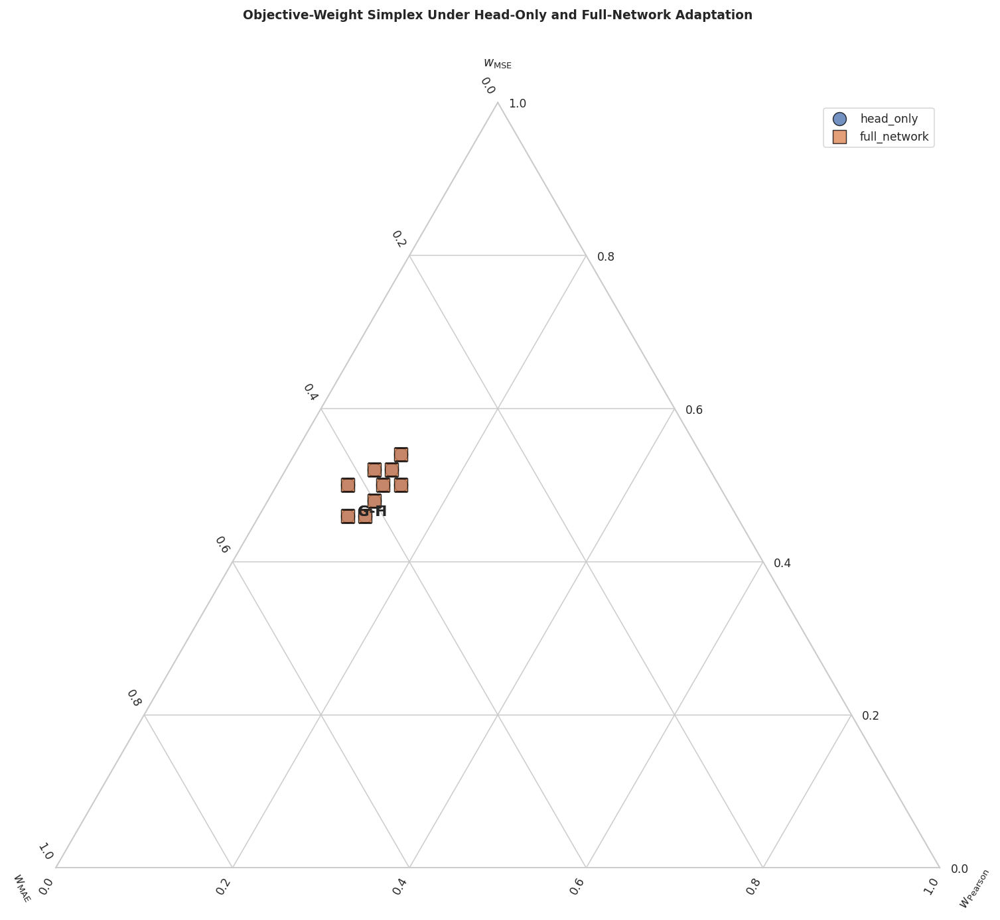

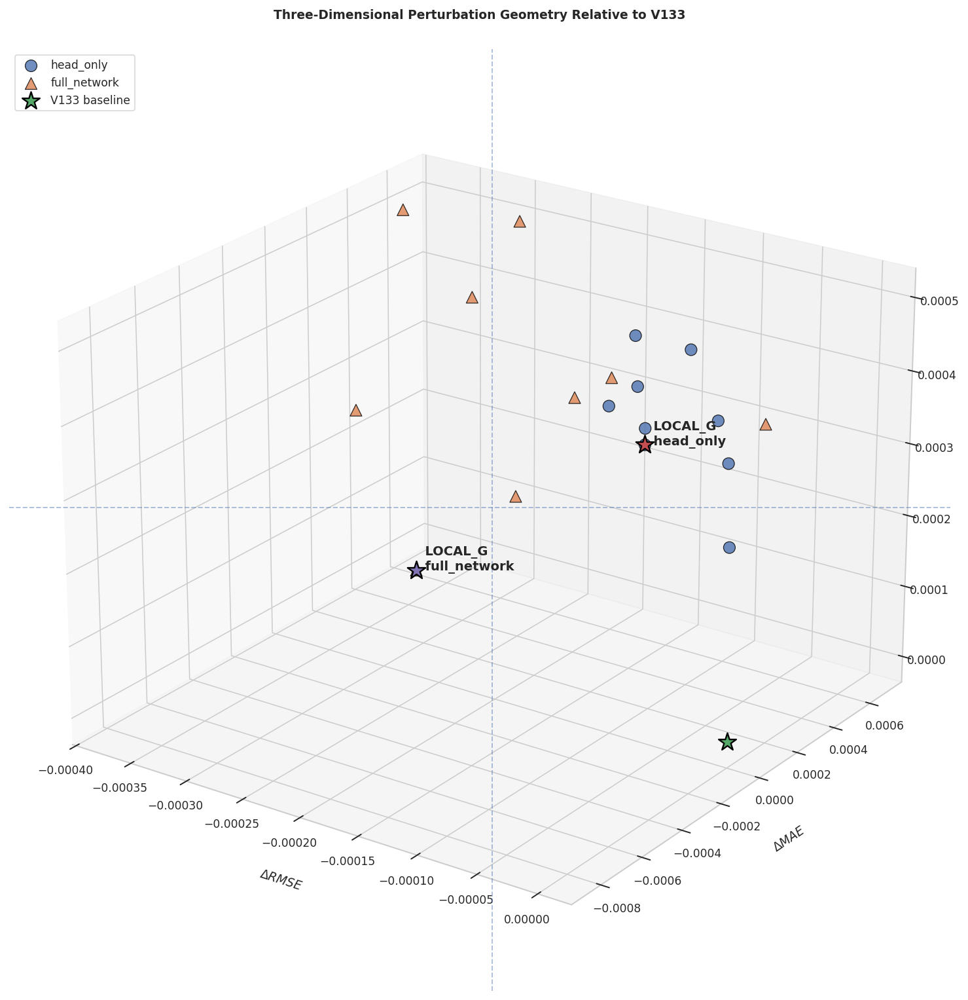

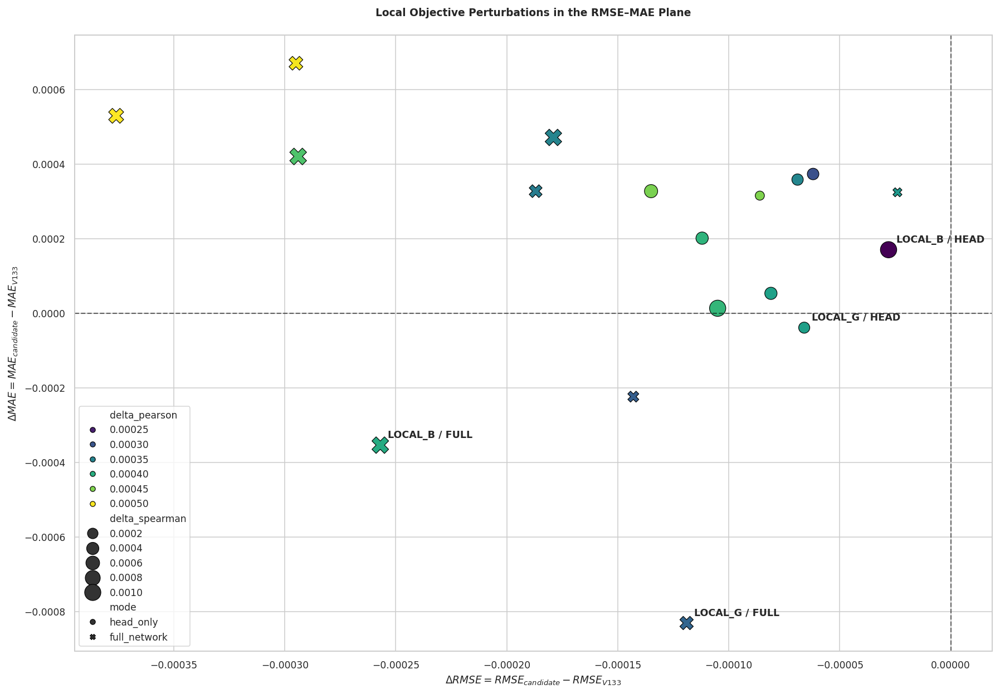

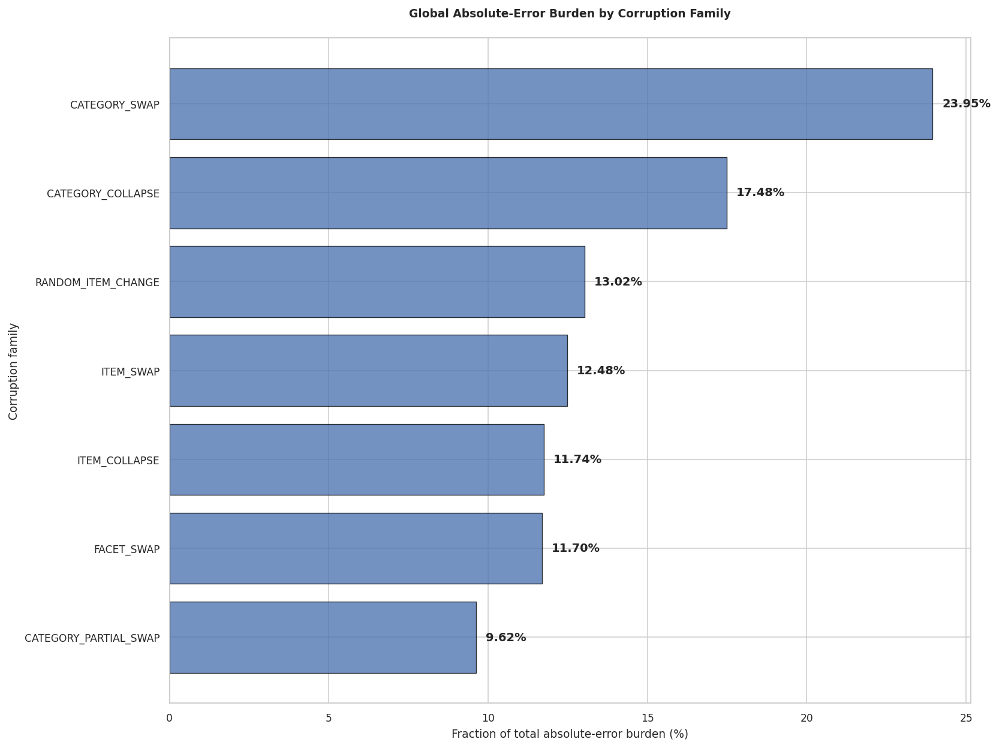

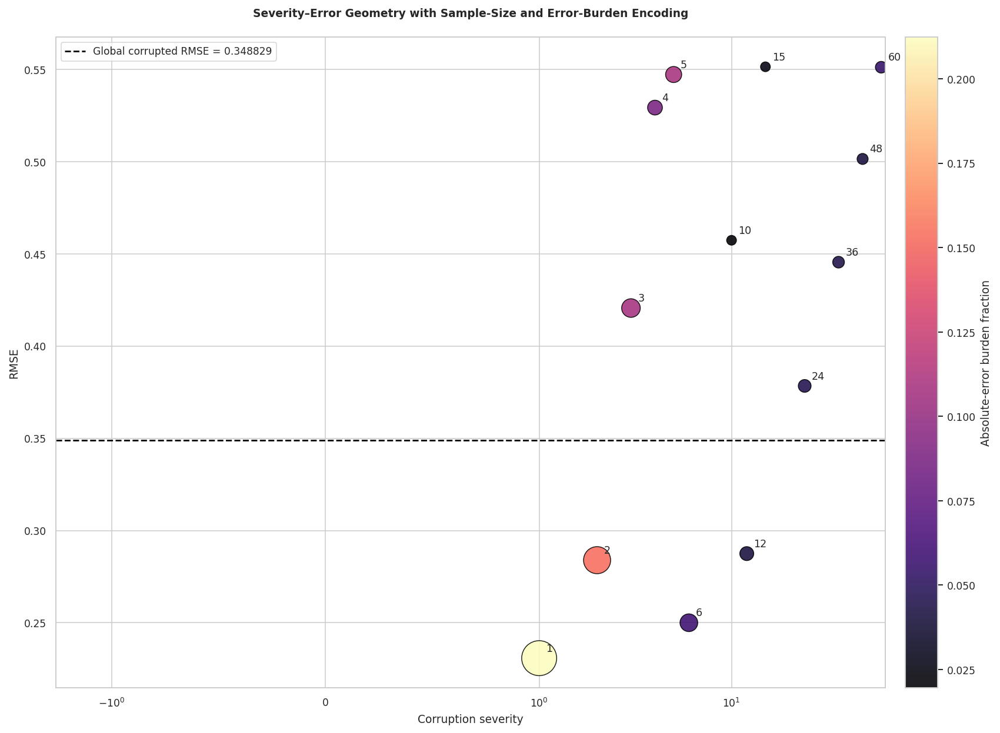

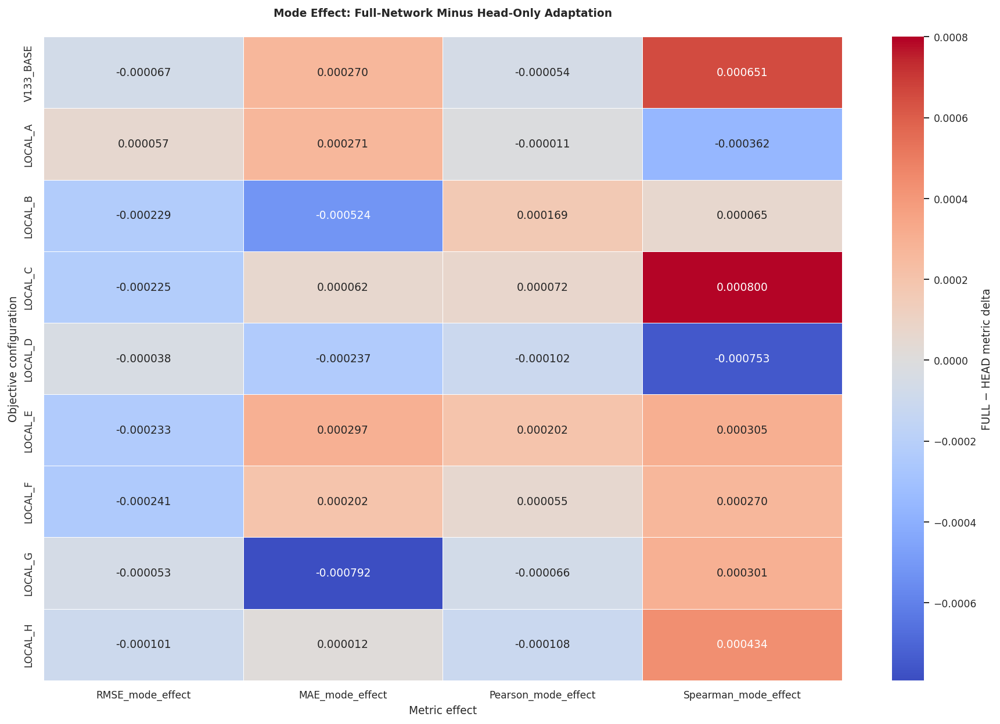

V133 BASELINE DIAGNOSTIC — PAPER VISUALIZATION LAB
                      quantity     value
    Global V133 corrupted RMSE  0.348829
     Global V133 corrupted MAE  0.201426
 Global V133 corrupted Pearson  0.880498
Global V133 corrupted Spearman  0.850461
                    Candidates 18.000000
          Head-only candidates  9.000000
       Full-network candidates  9.000000
            Guardrail failures  0.000000
         Maximum MAE reduction -0.000831
        Maximum RMSE reduction -0.000376
      Maximum Pearson increase  0.000503
     Maximum Spearman increase  0.001097

SIGNAL MATRICES
        mode objective  delta_rmse  delta_mae  delta_pearson  delta_spearman  guardrails
   head_only V133_BASE   -0.000112   0.000201       0.000406        0.000417        True
   head_only   LOCAL_A   -0.000081   0.000053       0.000384        0.000408        True
   head_only   LOCAL_B   -0.000028   0.000170       0.000227        0.001015        True
   head_only   LOCAL_C   -0.000069   0.0003

In [ ]:
%pip install -q mpltern seaborn scipy

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mpltern
from scipy.spatial import ConvexHull

OUT = "/content/HEF_IPIP120_V133_FINE_TUNING_DIAGNOSTIC_FIGURES"
os.makedirs(OUT, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 500,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "axes.linewidth": 0.9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

sns.set_theme(
    style="whitegrid",
    context="paper"
)

baseline = {
    "rmse": 0.348829,
    "mae": 0.201426,
    "pearson": 0.880498,
    "spearman": 0.850461
}

objectives = pd.DataFrame([
    ["head_only","V133_BASE",0.50,0.38,0.12,0.348717,0.201627,0.880904,0.850878,True],
    ["head_only","LOCAL_A",0.46,0.42,0.12,0.348748,0.201479,0.880882,0.850869,True],
    ["head_only","LOCAL_B",0.48,0.40,0.12,0.348801,0.201596,0.880725,0.851476,True],
    ["head_only","LOCAL_C",0.52,0.36,0.12,0.348760,0.201784,0.880852,0.850758,True],
    ["head_only","LOCAL_D",0.50,0.42,0.08,0.348724,0.201439,0.880908,0.851467,True],
    ["head_only","LOCAL_E",0.50,0.36,0.14,0.348767,0.201799,0.880794,0.850779,True],
    ["head_only","LOCAL_F",0.54,0.34,0.12,0.348694,0.201753,0.880946,0.850994,True],
    ["head_only","LOCAL_G",0.46,0.44,0.10,0.348763,0.201387,0.880880,0.850726,True],
    ["head_only","LOCAL_H",0.52,0.38,0.10,0.348743,0.201741,0.880948,0.850516,True],

    ["full_network","V133_BASE",0.50,0.38,0.12,0.348650,0.201897,0.880850,0.851529,True],
    ["full_network","LOCAL_A",0.46,0.42,0.12,0.348805,0.201750,0.880871,0.850507,True],
    ["full_network","LOCAL_B",0.48,0.40,0.12,0.348572,0.201072,0.880894,0.851541,True],
    ["full_network","LOCAL_C",0.52,0.36,0.12,0.348535,0.201846,0.880924,0.851558,True],
    ["full_network","LOCAL_D",0.50,0.42,0.08,0.348686,0.201202,0.880806,0.850714,True],
    ["full_network","LOCAL_E",0.50,0.36,0.14,0.348534,0.202096,0.880996,0.851084,True],
    ["full_network","LOCAL_F",0.54,0.34,0.12,0.348453,0.201955,0.881001,0.851264,True],
    ["full_network","LOCAL_G",0.46,0.44,0.10,0.348710,0.200595,0.880814,0.851027,True],
    ["full_network","LOCAL_H",0.52,0.38,0.10,0.348642,0.201753,0.880840,0.850950,True]
], columns=[
    "mode",
    "objective",
    "mse_weight",
    "mae_weight",
    "pearson_weight",
    "rmse",
    "mae",
    "pearson",
    "spearman",
    "guardrails"
])

objectives["delta_rmse"] = (
    objectives["rmse"] - baseline["rmse"]
)

objectives["delta_mae"] = (
    objectives["mae"] - baseline["mae"]
)

objectives["delta_pearson"] = (
    objectives["pearson"] - baseline["pearson"]
)

objectives["delta_spearman"] = (
    objectives["spearman"] - baseline["spearman"]
)

objectives["pearson_loss"] = (
    1.0 - objectives["pearson"]
)

objectives["spearman_loss"] = (
    1.0 - objectives["spearman"]
)

families = pd.DataFrame([
    ["ITEM_SWAP",48350,0.288035,0.175932,0.124778],
    ["FACET_SWAP",48349,0.313528,0.164913,0.116961],
    ["CATEGORY_PARTIAL_SWAP",48349,0.259488,0.135694,0.096238],
    ["CATEGORY_SWAP",48349,0.524267,0.337703,0.239509],
    ["ITEM_COLLAPSE",48349,0.271801,0.165601,0.117449],
    ["CATEGORY_COLLAPSE",48349,0.405879,0.246520,0.174839],
    ["RANDOM_ITEM_CHANGE",48349,0.299507,0.183618,0.130227]
], columns=[
    "family",
    "n",
    "rmse",
    "mae",
    "burden"
])

severity = pd.DataFrame([
    [1,115937,0.230788,0.124860,0.212346],
    [2,67808,0.283920,0.153946,0.153126],
    [3,29627,0.420626,0.248902,0.108172],
    [4,17014,0.529311,0.348442,0.086963],
    [5,20955,0.547253,0.355496,0.109275],
    [6,26437,0.249992,0.149815,0.058099],
    [10,4816,0.457373,0.277584,0.019610],
    [12,14481,0.287487,0.191864,0.040756],
    [15,4817,0.551445,0.366946,0.025928],
    [24,11492,0.378412,0.273165,0.046049],
    [36,8915,0.445506,0.334610,0.043758],
    [48,7350,0.501476,0.382495,0.041239],
    [60,8795,0.551210,0.423819,0.054678]
], columns=[
    "severity",
    "n",
    "rmse",
    "mae",
    "burden"
])

def savefig_all(fig, name):
    fig.savefig(
        os.path.join(OUT, f"{name}.png"),
        dpi=500,
        bbox_inches="tight"
    )
    fig.savefig(
        os.path.join(OUT, f"{name}.pdf"),
        bbox_inches="tight"
    )
    fig.savefig(
        os.path.join(OUT, f"{name}.svg"),
        bbox_inches="tight"
    )

fig1 = plt.figure(figsize=(12, 10))
ax1 = fig1.add_subplot(111, projection="ternary")

for mode, marker in [
    ("head_only","o"),
    ("full_network","s")
]:
    g = objectives[
        objectives["mode"] == mode
    ]

    ax1.scatter(
        g["mse_weight"],
        g["mae_weight"],
        g["pearson_weight"],
        s=105,
        marker=marker,
        alpha=0.78,
        edgecolors="black",
        linewidths=0.75,
        label=mode
    )

for _, row in objectives[
    objectives["objective"] == "LOCAL_G"
].iterrows():
    ax1.text(
        row["mse_weight"],
        row["mae_weight"],
        row["pearson_weight"],
        f"  G-{row['mode'][:1].upper()}",
        fontsize=11,
        fontweight="bold"
    )

ax1.set_tlabel(r"$w_{\mathrm{MSE}}$")
ax1.set_llabel(r"$w_{\mathrm{MAE}}$")
ax1.set_rlabel(r"$w_{\mathrm{Pearson}}$")

ax1.set_title(
    "Objective-Weight Simplex Under Head-Only and Full-Network Adaptation",
    pad=30,
    fontweight="bold"
)

ax1.legend(
    loc="upper right",
    frameon=True
)

fig1.tight_layout()

savefig_all(
    fig1,
    "FIG1_OBJECTIVE_WEIGHT_SIMPLEX"
)

plt.show()


fig2 = plt.figure(figsize=(13, 11))
ax2 = fig2.add_subplot(111, projection="3d")

for mode, marker in [
    ("head_only","o"),
    ("full_network","^")
]:
    g = objectives[
        objectives["mode"] == mode
    ]

    ax2.scatter(
        g["delta_rmse"],
        g["delta_mae"],
        g["delta_pearson"],
        s=85,
        marker=marker,
        alpha=0.80,
        edgecolors="black",
        linewidths=0.65,
        label=mode
    )

ax2.axvline(
    0.0,
    linestyle="--",
    linewidth=1.0,
    alpha=0.45
)

ax2.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
    alpha=0.45
)

ax2.scatter(
    [0],
    [0],
    [0],
    s=210,
    marker="*",
    edgecolors="black",
    linewidths=1.2,
    label="V133 baseline"
)

for _, row in objectives[
    objectives["objective"] == "LOCAL_G"
].iterrows():
    ax2.scatter(
        row["delta_rmse"],
        row["delta_mae"],
        row["delta_pearson"],
        s=220,
        marker="*",
        edgecolors="black",
        linewidths=1.2
    )

    ax2.text(
        row["delta_rmse"],
        row["delta_mae"],
        row["delta_pearson"],
        f"  LOCAL_G\n  {row['mode']}",
        fontsize=10,
        fontweight="bold"
    )

ax2.set_xlabel(
    r"$\Delta RMSE$",
    labelpad=13
)

ax2.set_ylabel(
    r"$\Delta MAE$",
    labelpad=13
)

ax2.set_zlabel(
    r"$\Delta Pearson$",
    labelpad=13
)

ax2.set_title(
    "Three-Dimensional Perturbation Geometry Relative to V133",
    pad=24,
    fontweight="bold"
)

ax2.view_init(
    elev=23,
    azim=-55
)

ax2.legend(
    loc="upper left"
)

fig2.tight_layout()

savefig_all(
    fig2,
    "FIG2_DELTA_PERFORMANCE_GEOMETRY"
)

plt.show()


fig3, ax3 = plt.subplots(
    figsize=(13, 9)
)

plot_df = objectives.copy()

plot_df["label"] = (
    plot_df["objective"]
    + "\n"
    + plot_df["mode"].str.replace(
        "full_network",
        "FULL",
        regex=False
    ).str.replace(
        "head_only",
        "HEAD",
        regex=False
    )
)

sns.scatterplot(
    data=plot_df,
    x="delta_rmse",
    y="delta_mae",
    hue="delta_pearson",
    style="mode",
    size="delta_spearman",
    sizes=(70, 240),
    palette="viridis",
    edgecolor="black",
    linewidth=0.6,
    ax=ax3
)

ax3.axvline(
    0,
    linestyle="--",
    linewidth=1.1,
    color="black",
    alpha=0.55
)

ax3.axhline(
    0,
    linestyle="--",
    linewidth=1.1,
    color="black",
    alpha=0.55
)

for _, row in objectives.iterrows():
    if row["objective"] in ["LOCAL_B","LOCAL_G"]:
        ax3.annotate(
            f"{row['objective']} / "
            f"{'FULL' if row['mode']=='full_network' else 'HEAD'}",
            (
                row["delta_rmse"],
                row["delta_mae"]
            ),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold"
        )

ax3.set_xlabel(
    r"$\Delta RMSE = RMSE_{candidate} - RMSE_{V133}$"
)

ax3.set_ylabel(
    r"$\Delta MAE = MAE_{candidate} - MAE_{V133}$"
)

ax3.set_title(
    "Local Objective Perturbations in the RMSE–MAE Plane",
    fontweight="bold",
    pad=18
)

fig3.tight_layout()

savefig_all(
    fig3,
    "FIG3_OBJECTIVE_PERTURBATION_PLANE"
)

plt.show()


fig4, ax4 = plt.subplots(
    figsize=(12, 9)
)

family_plot = families.sort_values(
    "burden",
    ascending=True
)

y = np.arange(
    len(family_plot)
)

ax4.barh(
    y,
    family_plot["burden"] * 100,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.78
)

ax4.set_yticks(y)

ax4.set_yticklabels(
    family_plot["family"]
)

for i, (_, row) in enumerate(
    family_plot.iterrows()
):
    ax4.text(
        row["burden"] * 100 + 0.3,
        i,
        f"{row['burden']*100:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax4.set_xlabel(
    "Fraction of total absolute-error burden (%)"
)

ax4.set_ylabel(
    "Corruption family"
)

ax4.set_title(
    "Global Absolute-Error Burden by Corruption Family",
    fontweight="bold",
    pad=18
)

fig4.tight_layout()

savefig_all(
    fig4,
    "FIG4_FAMILY_ERROR_BURDEN"
)

plt.show()


fig5, ax5 = plt.subplots(
    figsize=(13, 9)
)

norm = plt.Normalize(
    severity["severity"].min(),
    severity["severity"].max()
)

scatter = ax5.scatter(
    severity["severity"],
    severity["rmse"],
    s=severity["n"] / severity["n"].max() * 900 + 35,
    c=severity["burden"],
    cmap="magma",
    norm=plt.Normalize(
        severity["burden"].min(),
        severity["burden"].max()
    ),
    alpha=0.88,
    edgecolors="black",
    linewidths=0.75
)

for _, row in severity.iterrows():
    ax5.annotate(
        str(int(row["severity"])),
        (
            row["severity"],
            row["rmse"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

ax5.axhline(
    baseline["rmse"],
    color="black",
    linestyle="--",
    linewidth=1.4,
    label=f"Global corrupted RMSE = {baseline['rmse']:.6f}"
)

ax5.set_xscale(
    "symlog",
    linthresh=1
)

ax5.set_xlabel(
    "Corruption severity"
)

ax5.set_ylabel(
    "RMSE"
)

ax5.set_title(
    "Severity–Error Geometry with Sample-Size and Error-Burden Encoding",
    fontweight="bold",
    pad=18
)

cbar5 = fig5.colorbar(
    scatter,
    ax=ax5,
    pad=0.02
)

cbar5.set_label(
    "Absolute-error burden fraction"
)

ax5.legend(
    frameon=True
)

fig5.tight_layout()

savefig_all(
    fig5,
    "FIG5_SEVERITY_ERROR_GEOMETRY"
)

plt.show()


fig6, ax6 = plt.subplots(
    figsize=(13, 9)
)

pivot = objectives.pivot(
    index="objective",
    columns="mode",
    values=[
        "delta_rmse",
        "delta_mae",
        "delta_pearson",
        "delta_spearman"
    ]
)

metrics = [
    "delta_rmse",
    "delta_mae",
    "delta_pearson",
    "delta_spearman"
]

labels = [
    "ΔRMSE",
    "ΔMAE",
    "ΔPearson",
    "ΔSpearman"
]

rows = []

for obj in [
    "V133_BASE",
    "LOCAL_A",
    "LOCAL_B",
    "LOCAL_C",
    "LOCAL_D",
    "LOCAL_E",
    "LOCAL_F",
    "LOCAL_G",
    "LOCAL_H"
]:
    for mode in [
        "head_only",
        "full_network"
    ]:
        row = objectives[
            (objectives["objective"] == obj)
            &
            (objectives["mode"] == mode)
        ]

        if len(row) == 1:
            r = row.iloc[0]
            rows.append([
                obj,
                mode,
                r["delta_rmse"],
                r["delta_mae"],
                r["delta_pearson"],
                r["delta_spearman"]
            ])

radar_df = pd.DataFrame(
    rows,
    columns=[
        "objective",
        "mode",
        "delta_rmse",
        "delta_mae",
        "delta_pearson",
        "delta_spearman"
    ]
)

pairs = []

for obj in [
    "V133_BASE",
    "LOCAL_A",
    "LOCAL_B",
    "LOCAL_C",
    "LOCAL_D",
    "LOCAL_E",
    "LOCAL_F",
    "LOCAL_G",
    "LOCAL_H"
]:
    h = radar_df[
        (radar_df["objective"] == obj)
        &
        (radar_df["mode"] == "head_only")
    ].iloc[0]

    f = radar_df[
        (radar_df["objective"] == obj)
        &
        (radar_df["mode"] == "full_network")
    ].iloc[0]

    pairs.append([
        obj,
        f["delta_rmse"] - h["delta_rmse"],
        f["delta_mae"] - h["delta_mae"],
        f["delta_pearson"] - h["delta_pearson"],
        f["delta_spearman"] - h["delta_spearman"]
    ])

mode_delta = pd.DataFrame(
    pairs,
    columns=[
        "objective",
        "RMSE_mode_effect",
        "MAE_mode_effect",
        "Pearson_mode_effect",
        "Spearman_mode_effect"
    ]
).set_index("objective")

sns.heatmap(
    mode_delta,
    ax=ax6,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".6f",
    linewidths=0.4,
    cbar_kws={
        "label": "FULL − HEAD metric delta"
    }
)

ax6.set_title(
    "Mode Effect: Full-Network Minus Head-Only Adaptation",
    fontweight="bold",
    pad=18
)

ax6.set_xlabel(
    "Metric effect"
)

ax6.set_ylabel(
    "Objective configuration"
)

fig6.tight_layout()

savefig_all(
    fig6,
    "FIG6_FULL_NETWORK_VS_HEAD_ONLY"
)

plt.show()


diagnostic_summary = pd.DataFrame([
    [
        "Global V133 corrupted RMSE",
        baseline["rmse"]
    ],
    [
        "Global V133 corrupted MAE",
        baseline["mae"]
    ],
    [
        "Global V133 corrupted Pearson",
        baseline["pearson"]
    ],
    [
        "Global V133 corrupted Spearman",
        baseline["spearman"]
    ],
    [
        "Candidates",
        len(objectives)
    ],
    [
        "Head-only candidates",
        len(objectives[objectives["mode"] == "head_only"])
    ],
    [
        "Full-network candidates",
        len(objectives[objectives["mode"] == "full_network"])
    ],
    [
        "Guardrail failures",
        int((~objectives["guardrails"]).sum())
    ],
    [
        "Maximum MAE reduction",
        objectives["delta_mae"].min()
    ],
    [
        "Maximum RMSE reduction",
        objectives["delta_rmse"].min()
    ],
    [
        "Maximum Pearson increase",
        objectives["delta_pearson"].max()
    ],
    [
        "Maximum Spearman increase",
        objectives["delta_spearman"].max()
    ]
], columns=[
    "quantity",
    "value"
])

print("=" * 82)
print("V133 BASELINE DIAGNOSTIC — PAPER VISUALIZATION LAB")
print("=" * 82)
print(diagnostic_summary.to_string(index=False))
print()
print("SIGNAL MATRICES")
print(
    objectives[
        [
            "mode",
            "objective",
            "delta_rmse",
            "delta_mae",
            "delta_pearson",
            "delta_spearman",
            "guardrails"
        ]
    ].to_string(index=False)
)
print()
print(f"OUTPUT DIRECTORY: {OUT}")
print("FIGURES: 6")
print("FORMATS: PNG / PDF / SVG")
print("TEST: NOT TOUCHED")

In [18]:
from __future__ import annotations

import gc
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn


ROOT = Path('/content/HEF_IPIP120_ROBUST_DATASET_V3')
TRAIN_ROOT = ROOT / 'TRAIN'
VAL_CLEAN_ROOT = ROOT / 'VALIDATION' / 'CLEAN'
VAL_CORRUPTED_ROOT = ROOT / 'VALIDATION' / 'CORRUPTED'
V133_ROOT = ROOT / 'MLP_GATEWAY_B_V133_PRODUCTION'
V133_CHECKPOINT = V133_ROOT / 'best.pt'
OUTPUT_ROOT = ROOT / 'V133_INTERNAL_TUNING_V1'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

INPUT_DIM = 120
OUTPUT_DIM = 30
VIEWS_PER_SUBJECT = 143
DROPOUT = 0.10
EXPECTED_TRAIN_SUBJECTS = 287_263
EXPECTED_TRAIN_EXAMPLES = 41_078_609
VAL_CLEAN_EXPECTED = 61_556
VAL_CORRUPTED_EXPECTED = 338_444
BATCH_SIZE = 8192
VAL_BATCH_SIZE = 32768
SCREEN_SUBJECTS = 10_000
SCREEN_EPOCHS = 6
AUTOPSY_MAX_ROWS = None
USE_BF16 = True
GRAD_CLIP_NORM = 1.0
LEARNING_RATE = 0.002
WEIGHT_DECAY = 1e-4
GLOBAL_SEED = 20260926
SCREEN_SEED = 20260927

V133_OBJECTIVE = {'mse': 0.50, 'mae': 0.38, 'pearson': 0.12}
V133_METRICS = {
    'clean_rmse': 0.123152,
    'clean_mae': 0.080640,
    'clean_pearson': 0.988704,
    'clean_spearman': 0.974316,
    'corrupted_rmse': 0.348829,
    'corrupted_mae': 0.201426,
    'corrupted_pearson': 0.880498,
    'corrupted_spearman': 0.850461,
}
PRIMARY_BASELINE_METRICS = {
    'corrupted_rmse': 0.349212,
    'corrupted_mae': 0.201126,
    'corrupted_pearson': 0.880770,
    'corrupted_spearman': 0.851339,
}
RMSE_TOLERANCE = 0.001
PEARSON_TOLERANCE = 0.002
SPEARMAN_TOLERANCE = 0.002

VARIANTS = {
    'S0_BASELINE': (192, 128, 64, None),
    'S1_WIDE64': (192, 128, 96, None),
    'S2_WIDE128': (192, 128, 128, None),
    'S3_UNPOOL64_128': (192, 128, 64, 128),
}

FAMILY_NAMES = {
    0: 'CLEAN',
    1: 'ITEM_SWAP',
    2: 'FACET_SWAP',
    3: 'CATEGORY_PARTIAL_SWAP',
    4: 'CATEGORY_SWAP',
    5: 'ITEM_COLLAPSE',
    6: 'CATEGORY_COLLAPSE',
    7: 'RANDOM_ITEM_CHANGE',
}


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


if not torch.cuda.is_available():
    raise RuntimeError('CUDA is required for this phase.')

DEVICE = torch.device('cuda')
torch.set_float32_matmul_precision('high')
seed_everything(GLOBAL_SEED)


def load_checkpoint(path: Path):
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(path, map_location='cpu')


if not V133_CHECKPOINT.exists():
    raise FileNotFoundError(V133_CHECKPOINT)


class ArchitectureModel(nn.Module):
    def __init__(self, variant: str):
        super().__init__()
        d1, d2, d3, d4 = VARIANTS[variant]
        self.variant = variant
        self.d1 = d1
        self.d2 = d2
        self.d3 = d3
        self.d4 = d4

        self.fc1 = nn.Linear(INPUT_DIM, d1)
        self.ln1 = nn.LayerNorm(d1)
        self.fc2 = nn.Linear(d1, d2)
        self.ln2 = nn.LayerNorm(d2)
        self.fc3 = nn.Linear(d2, d3)
        self.ln3 = nn.LayerNorm(d3)

        if d4 is None:
            self.decoder = None
            self.output = nn.Linear(d3, OUTPUT_DIM)
        else:
            self.decoder = nn.Linear(d3, d4)
            self.ln4 = nn.LayerNorm(d4)
            self.output = nn.Linear(d4, OUTPUT_DIM)

        self.dropout = nn.Dropout(DROPOUT)

    def forward_features(self, x):
        h1 = self.dropout(torch.nn.functional.gelu(self.ln1(self.fc1(x))))
        h2 = self.dropout(torch.nn.functional.gelu(self.ln2(self.fc2(h1))))
        h3 = self.dropout(torch.nn.functional.gelu(self.ln3(self.fc3(h2))))
        if self.decoder is None:
            return {'h192': h1, 'h128': h2, 'bottleneck': h3}
        h4 = self.dropout(torch.nn.functional.gelu(self.ln4(self.decoder(h3))))
        return {'h192': h1, 'h128': h2, 'bottleneck': h3, 'h128_up': h4}

    def forward(self, x):
        features = self.forward_features(x)
        key = 'h128_up' if self.decoder is not None else 'bottleneck'
        return self.output(features[key])


def initialize_from_v133(model: ArchitectureModel, source_state: dict) -> dict:
    mapping = {
        'fc1.weight': 'trunk.0.weight',
        'fc1.bias': 'trunk.0.bias',
        'ln1.weight': 'trunk.1.weight',
        'ln1.bias': 'trunk.1.bias',
        'fc2.weight': 'trunk.4.weight',
        'fc2.bias': 'trunk.4.bias',
        'ln2.weight': 'trunk.5.weight',
        'ln2.bias': 'trunk.5.bias',
        'fc3.weight': 'trunk.8.weight',
        'fc3.bias': 'trunk.8.bias',
        'ln3.weight': 'trunk.9.weight',
        'ln3.bias': 'trunk.9.bias',
        'output.weight': 'output.weight',
        'output.bias': 'output.bias',
    }
    own = model.state_dict()
    copied = []
    skipped = []
    for dst, src in mapping.items():
        if dst not in own or src not in source_state:
            skipped.append(dst)
            continue
        if own[dst].shape != source_state[src].shape:
            skipped.append(dst)
            continue
        own[dst].copy_(source_state[src])
        copied.append(dst)

    model.load_state_dict(own)
    return {'copied': copied, 'skipped': skipped}


def load_split(root: Path):
    xs, ys, ts, ss = [], [], [], []
    paths = sorted(root.glob('shard_*_X.npy'))
    if not paths:
        raise FileNotFoundError(root)
    for x_path in paths:
        y_path = Path(str(x_path).replace('_X.npy', '_Y.npy'))
        t_path = Path(str(x_path).replace('_X.npy', '_type.npy'))
        s_path = Path(str(x_path).replace('_X.npy', '_severity.npy'))
        xs.append(np.load(x_path).astype(np.uint8, copy=False))
        ys.append(np.load(y_path).astype(np.float32, copy=False))
        ts.append(np.load(t_path).astype(np.uint8, copy=False))
        ss.append(np.load(s_path).astype(np.uint8, copy=False))
    return np.concatenate(xs), np.concatenate(ys), np.concatenate(ts), np.concatenate(ss)


VAL_CLEAN_X, VAL_CLEAN_Y, VAL_CLEAN_T, VAL_CLEAN_S = load_split(VAL_CLEAN_ROOT)
VAL_CORR_X, VAL_CORR_Y, VAL_CORR_T, VAL_CORR_S = load_split(VAL_CORRUPTED_ROOT)

if len(VAL_CLEAN_X) != VAL_CLEAN_EXPECTED or len(VAL_CORR_X) != VAL_CORRUPTED_EXPECTED:
    raise RuntimeError('Validation size mismatch.')


TRAIN_X = []
TRAIN_Y = []
TRAIN_T = []
TRAIN_S = []
SHARD_STARTS = []
SHARD_ENDS = []
subject_cursor = 0

for x_path in sorted(TRAIN_ROOT.glob('shard_*_X.npy')):
    y_path = Path(str(x_path).replace('_X.npy', '_Y.npy'))
    t_path = Path(str(x_path).replace('_X.npy', '_type.npy'))
    s_path = Path(str(x_path).replace('_X.npy', '_severity.npy'))
    x_mm = np.load(x_path, mmap_mode='r')
    y_mm = np.load(y_path, mmap_mode='r')
    t_mm = np.load(t_path, mmap_mode='r')
    s_mm = np.load(s_path, mmap_mode='r')
    if x_mm.shape[0] % VIEWS_PER_SUBJECT != 0:
        raise RuntimeError(f'Bad view alignment: {x_path}')
    n_subjects = x_mm.shape[0] // VIEWS_PER_SUBJECT
    SHARD_STARTS.append(subject_cursor)
    subject_cursor += n_subjects
    SHARD_ENDS.append(subject_cursor)
    TRAIN_X.append(x_mm)
    TRAIN_Y.append(y_mm)
    TRAIN_T.append(t_mm)
    TRAIN_S.append(s_mm)

SHARD_STARTS = np.asarray(SHARD_STARTS, dtype=np.int64)
SHARD_ENDS = np.asarray(SHARD_ENDS, dtype=np.int64)
if subject_cursor != EXPECTED_TRAIN_SUBJECTS:
    raise RuntimeError(f'TRAIN subject mismatch: {subject_cursor}')


def locate_subjects(subject_ids):
    subject_ids = np.asarray(subject_ids, dtype=np.int64)
    shard_ids = np.searchsorted(SHARD_ENDS, subject_ids, side='right')
    local_ids = subject_ids - SHARD_STARTS[shard_ids]
    return shard_ids, local_ids


def fetch_train_batch(subject_ids, view_id):
    subject_ids = np.asarray(subject_ids, dtype=np.int64)
    shard_ids, local_ids = locate_subjects(subject_ids)
    x = np.empty((len(subject_ids), INPUT_DIM), dtype=np.uint8)
    y = np.empty((len(subject_ids), OUTPUT_DIM), dtype=np.float32)
    for shard_id in np.unique(shard_ids):
        pos = np.flatnonzero(shard_ids == shard_id)
        rows = local_ids[pos] * VIEWS_PER_SUBJECT + view_id
        shard = int(shard_id)
        x[pos] = np.asarray(TRAIN_X[shard][rows], dtype=np.uint8)
        y[pos] = np.asarray(TRAIN_Y[shard][rows], dtype=np.float32)
    return x, y


def rank_rows(values):
    order = np.argsort(values, axis=1, kind='mergesort')
    ranks = np.empty_like(order, dtype=np.float64)
    rows = np.arange(values.shape[0])[:, None]
    ranks[rows, order] = np.arange(values.shape[1], dtype=np.float64)[None, :] + 1.0
    return ranks


def metric_rmse(p, y):
    d = p.astype(np.float64) - y.astype(np.float64)
    return float(np.sqrt(np.mean(d * d)))


def metric_mae(p, y):
    d = p.astype(np.float64) - y.astype(np.float64)
    return float(np.mean(np.abs(d)))


def metric_pearson(p, y):
    p = p.astype(np.float64)
    y = y.astype(np.float64)
    p = p - p.mean(axis=1, keepdims=True)
    y = y - y.mean(axis=1, keepdims=True)
    num = np.sum(p * y, axis=1)
    den = np.sqrt(np.sum(p * p, axis=1)) * np.sqrt(np.sum(y * y, axis=1))
    return float(np.mean(num / np.maximum(den, 1e-12)))


def metric_spearman(p, y):
    return metric_pearson(rank_rows(p), rank_rows(y))


def loss_profile(prediction, target):
    mse_i = ((prediction - target) ** 2).mean(dim=1)
    mae_i = torch.abs(prediction - target).mean(dim=1)
    p = prediction - prediction.mean(dim=1, keepdim=True)
    t = target - target.mean(dim=1, keepdim=True)
    num = (p * t).sum(dim=1)
    den = torch.sqrt((p * p).sum(dim=1) + 1e-8) * torch.sqrt((t * t).sum(dim=1) + 1e-8)
    pearson_i = 1.0 - num / den
    loss_i = V133_OBJECTIVE['mse'] * mse_i + V133_OBJECTIVE['mae'] * mae_i + V133_OBJECTIVE['pearson'] * pearson_i
    return loss_i.mean()


def select_validation_subset():
    rng = np.random.default_rng(SCREEN_SEED)
    clean_n = min(12_000, len(VAL_CLEAN_X))
    corr_n = min(60_000, len(VAL_CORR_X))
    ci = np.sort(rng.choice(len(VAL_CLEAN_X), clean_n, replace=False))
    ri = np.sort(rng.choice(len(VAL_CORR_X), corr_n, replace=False))
    return ci, ri


VAL_CLEAN_IDX_SCREEN, VAL_CORR_IDX_SCREEN = select_validation_subset()


def predict_numpy(model, X):
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(X), VAL_BATCH_SIZE):
            end = min(start + VAL_BATCH_SIZE, len(X))
            xb = torch.from_numpy(X[start:end]).to(DEVICE)
            xb = (xb.float() - 3.0) / 2.0
            if USE_BF16:
                with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                    pred = model(xb)
            else:
                pred = model(xb)
            outputs.append(pred.float().cpu().numpy())
    return np.concatenate(outputs, axis=0)


def evaluate_arrays(model, X_clean, Y_clean, X_corr, Y_corr, T_corr=None):
    p_clean = predict_numpy(model, X_clean)
    p_corr = predict_numpy(model, X_corr)
    metrics = {
        'clean_rmse': metric_rmse(p_clean, Y_clean),
        'clean_mae': metric_mae(p_clean, Y_clean),
        'clean_pearson': metric_pearson(p_clean, Y_clean),
        'clean_spearman': metric_spearman(p_clean, Y_clean),
        'corrupted_rmse': metric_rmse(p_corr, Y_corr),
        'corrupted_mae': metric_mae(p_corr, Y_corr),
        'corrupted_pearson': metric_pearson(p_corr, Y_corr),
        'corrupted_spearman': metric_spearman(p_corr, Y_corr),
    }
    family_rows = []
    if T_corr is not None:
        for code, name in FAMILY_NAMES.items():
            if code == 0:
                continue
            mask = T_corr == code
            if not np.any(mask):
                continue
            family_rows.append({
                'family_code': code,
                'family': name,
                'n': int(mask.sum()),
                'rmse': metric_rmse(p_corr[mask], Y_corr[mask]),
                'mae': metric_mae(p_corr[mask], Y_corr[mask]),
            })
    return metrics, pd.DataFrame(family_rows)


def guardrail_metrics(metrics, reference=V133_METRICS):
    return (
        metrics['corrupted_rmse'] - reference['corrupted_rmse'] <= RMSE_TOLERANCE
        and metrics['corrupted_pearson'] - reference['corrupted_pearson'] >= -PEARSON_TOLERANCE
        and metrics['corrupted_spearman'] - reference['corrupted_spearman'] >= -SPEARMAN_TOLERANCE
    )


def parameter_count(model):
    return sum(p.numel() for p in model.parameters())


def weight_spectrum(model):
    rows = []
    linear_names = ['fc1', 'fc2', 'fc3'] + (['decoder'] if model.decoder is not None else []) + ['output']
    for name in linear_names:
        layer = getattr(model, name)
        s = torch.linalg.svdvals(layer.weight.detach().float().cpu())
        s = s.numpy().astype(np.float64)
        total = float(np.sum(s * s))
        p = (s * s) / max(total, 1e-18)
        entropy = -float(np.sum(p * np.log(np.maximum(p, 1e-18))))
        effective_rank = float(np.exp(entropy))
        rows.append({
            'variant': model.variant,
            'layer': name,
            'in_features': int(layer.in_features),
            'out_features': int(layer.out_features),
            'params': int(layer.weight.numel() + layer.bias.numel()),
            'sigma_max': float(s[0]),
            'sigma_min': float(s[-1]),
            'condition_number': float(s[0] / max(s[-1], 1e-12)),
            'effective_rank': effective_rank,
        })
    return rows


class ActivationAccumulator:
    def __init__(self, dim: int):
        self.dim = dim
        self.n = 0
        self.sum = np.zeros(dim, dtype=np.float64)
        self.sumsq = np.zeros(dim, dtype=np.float64)
        self.sumxx = np.zeros((dim, dim), dtype=np.float64)
        self.abs_sum = np.zeros(dim, dtype=np.float64)
        self.near_zero = np.zeros(dim, dtype=np.int64)
        self.norm_sum = 0.0

    def add(self, x: np.ndarray):
        xf = x.astype(np.float64, copy=False)
        self.n += xf.shape[0]
        self.sum += xf.sum(axis=0)
        self.sumsq += (xf * xf).sum(axis=0)
        self.sumxx += xf.T @ xf
        self.abs_sum += np.abs(xf).sum(axis=0)
        self.near_zero += (np.abs(xf) < 1e-3).sum(axis=0)
        self.norm_sum += np.linalg.norm(xf, axis=1).sum()

    def finalize(self):
        mean = self.sum / max(self.n, 1)
        var = np.maximum(self.sumsq / max(self.n, 1) - mean * mean, 0.0)
        cov = self.sumxx / max(self.n, 1) - np.outer(mean, mean)
        eig = np.linalg.eigvalsh((cov + cov.T) * 0.5)
        eig = np.clip(eig, 0.0, None)[::-1]
        total = eig.sum()
        if total <= 0.0:
            effective_rank = 0.0
            rank95 = 0
        else:
            probs = eig / total
            effective_rank = float(np.exp(-np.sum(probs * np.log(np.maximum(probs, 1e-18)))))
            rank95 = int(np.searchsorted(np.cumsum(probs), 0.95) + 1)
        return {
            'n': int(self.n),
            'mean_abs': float(np.mean(np.abs(mean))),
            'mean_std': float(np.mean(np.sqrt(var))),
            'mean_activation': float(np.mean(mean)),
            'near_zero_fraction': float(np.mean(self.near_zero / max(self.n, 1))),
            'mean_l2_norm': float(self.norm_sum / max(self.n, 1)),
            'effective_rank': effective_rank,
            'rank95': rank95,
        }


def run_autopsy(source_model: ArchitectureModel):
    model = source_model.to(DEVICE)
    model.eval()
    max_clean = len(VAL_CLEAN_X) if AUTOPSY_MAX_ROWS is None else min(AUTOPSY_MAX_ROWS // 2, len(VAL_CLEAN_X))
    max_corr = len(VAL_CORR_X) if AUTOPSY_MAX_ROWS is None else min(AUTOPSY_MAX_ROWS - max_clean, len(VAL_CORR_X))
    Xc = VAL_CLEAN_X[:max_clean]
    Xt = VAL_CORR_X[:max_corr]
    Tt = VAL_CORR_T[:max_corr]

    acc = {
        'h192': ActivationAccumulator(192),
        'h128': ActivationAccumulator(128),
        'h64': ActivationAccumulator(64),
        'out': ActivationAccumulator(30),
    }
    family_norm = {code: [] for code in range(1, 8)}

    with torch.no_grad():
        for X in (Xc, Xt):
            for start in range(0, len(X), VAL_BATCH_SIZE):
                end = min(start + VAL_BATCH_SIZE, len(X))
                xb = torch.from_numpy(X[start:end]).to(DEVICE)
                xb = (xb.float() - 3.0) / 2.0
                features = model.forward_features(xb)
                for key, out_key in [('h192', 'h192'), ('h128', 'h128'), ('bottleneck', 'h64')]:
                    acc[out_key].add(features[key].float().cpu().numpy())
                pred = model.output(features['bottleneck']) if model.decoder is None else model.output(features['bottleneck'])
                acc['out'].add(pred.float().cpu().numpy())

        for start in range(0, len(Xt), VAL_BATCH_SIZE):
            end = min(start + VAL_BATCH_SIZE, len(Xt))
            xb = torch.from_numpy(Xt[start:end]).to(DEVICE)
            xb = (xb.float() - 3.0) / 2.0
            features = model.forward_features(xb)
            h64 = features['bottleneck'].float().cpu().numpy()
            t_batch = Tt[start:end]
            norms = np.linalg.norm(h64, axis=1)
            for code in range(1, 8):
                mask = t_batch == code
                if np.any(mask):
                    family_norm[code].extend(norms[mask].tolist())

    global_rows = []
    for layer, accumulator in acc.items():
        row = accumulator.finalize()
        row['layer'] = layer
        global_rows.append(row)
    global_df = pd.DataFrame(global_rows)

    family_rows = []
    for code, values in family_norm.items():
        if values:
            arr = np.asarray(values, dtype=np.float64)
            family_rows.append({
                'family_code': code,
                'family': FAMILY_NAMES[code],
                'n': int(arr.size),
                'h64_norm_mean': float(arr.mean()),
                'h64_norm_std': float(arr.std()),
                'h64_norm_p95': float(np.quantile(arr, 0.95)),
            })
    family_df = pd.DataFrame(family_rows)
    spectrum_df = pd.DataFrame(weight_spectrum(model))
    return global_df, family_df, spectrum_df


def train_variant(variant: str, source_state: dict, subject_ids: np.ndarray):
    seed_everything(GLOBAL_SEED + list(VARIANTS).index(variant) + 1)
    model = ArchitectureModel(variant)
    init_record = initialize_from_v133(model, source_state)
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    best_state = None
    best_mae = float('inf')
    best_epoch = None
    history = []

    if variant == 'S0_BASELINE':
        model.eval()
        return model, init_record, history, None

    for epoch in range(1, SCREEN_EPOCHS + 1):
        permutation = subject_ids[np.random.permutation(len(subject_ids))]
        model.train()
        running = 0.0
        seen = 0
        t0 = time.perf_counter()

        for view_id in range(VIEWS_PER_SUBJECT):
            for start in range(0, len(permutation), BATCH_SIZE):
                end = min(start + BATCH_SIZE, len(permutation))
                subjects = permutation[start:end]
                x_np, y_np = fetch_train_batch(subjects, view_id)
                xb = torch.from_numpy(x_np).to(DEVICE)
                yb = torch.from_numpy(y_np).to(DEVICE)
                xb = (xb.float() - 3.0) / 2.0
                optimizer.zero_grad(set_to_none=True)
                if USE_BF16:
                    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                        pred = model(xb)
                        loss = loss_profile(pred.float(), yb)
                else:
                    pred = model(xb)
                    loss = loss_profile(pred, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()
                running += float(loss.detach().item()) * len(x_np)
                seen += len(x_np)

        model.eval()
        metrics, family_df = evaluate_arrays(
            model,
            VAL_CLEAN_X[VAL_CLEAN_IDX_SCREEN],
            VAL_CLEAN_Y[VAL_CLEAN_IDX_SCREEN],
            VAL_CORR_X[VAL_CORR_IDX_SCREEN],
            VAL_CORR_Y[VAL_CORR_IDX_SCREEN],
            VAL_CORR_T[VAL_CORR_IDX_SCREEN],
        )
        row = {
            'variant': variant,
            'epoch': epoch,
            'train_loss': running / max(seen, 1),
            **metrics,
            'seconds': time.perf_counter() - t0,
        }
        history.append(row)
        print(
            f"EPOCH {epoch:02d} {variant:<18} "
            f"RMSE={metrics['corrupted_rmse']:.6f} "
            f"MAE={metrics['corrupted_mae']:.6f} "
            f"P={metrics['corrupted_pearson']:.6f} "
            f"S={metrics['corrupted_spearman']:.6f}"
        )
        if metrics['corrupted_mae'] < best_mae:
            best_mae = metrics['corrupted_mae']
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(DEVICE)
        model.eval()
    return model, init_record, history, best_epoch


checkpoint = load_checkpoint(V133_CHECKPOINT)
source_state = checkpoint['model_state_dict']
V133_MODEL = ArchitectureModel('S0_BASELINE')
initialize_from_v133(V133_MODEL, source_state)
V133_MODEL.to(DEVICE)
V133_MODEL.eval()

print('\n' + '=' * 120)
print('HEF IPIP120 ROBUST — INTERNAL TUNING V1')
print('=' * 120)
print('CONTROL              : V133 B_COMPACT 120→192→128→64→30')
print('PRIMARY BASELINE     : V133 + Residual Adapter V1 epoch 1')
print('INTERVENTION         : BACKBONE GEOMETRY ONLY')
print('OBJECTIVE            : 0.50*MSE + 0.38*MAE + 0.12*(1-Pearson)')
print('TEST                 : NOT LOADED / NOT TOUCHED')
print('=' * 120)


print('\n' + '=' * 120)
print('INTERNAL AUTOPSY — V133')
print('=' * 120)
autopsy_global, autopsy_family, weight_spectrum_df = run_autopsy(V133_MODEL)
autopsy_global.to_csv(OUTPUT_ROOT / 'v133_autopsy_global.csv', index=False)
autopsy_family.to_csv(OUTPUT_ROOT / 'v133_autopsy_h64_by_family.csv', index=False)
weight_spectrum_df.to_csv(OUTPUT_ROOT / 'v133_weight_spectrum.csv', index=False)
print('\nACTIVATION AUTOPSY')
print(autopsy_global.to_string(index=False))
print('\nH64 FAMILY CONDITIONING')
print(autopsy_family.to_string(index=False))
print('\nWEIGHT SPECTRUM')
print(weight_spectrum_df.to_string(index=False))


rng = np.random.default_rng(SCREEN_SEED)
screen_subjects = np.sort(rng.choice(EXPECTED_TRAIN_SUBJECTS, SCREEN_SUBJECTS, replace=False))


screen_rows = []
history_rows = []
model_records = {}

for index, variant in enumerate(VARIANTS, 1):
    print('\n' + '-' * 120)
    print(f'[{index}/{len(VARIANTS)}] {variant}')
    model, init_record, history, best_epoch = train_variant(variant, source_state, screen_subjects)
    history_rows.extend(history)

    metrics, family_df = evaluate_arrays(
        model,
        VAL_CLEAN_X[VAL_CLEAN_IDX_SCREEN],
        VAL_CLEAN_Y[VAL_CLEAN_IDX_SCREEN],
        VAL_CORR_X[VAL_CORR_IDX_SCREEN],
        VAL_CORR_Y[VAL_CORR_IDX_SCREEN],
        VAL_CORR_T[VAL_CORR_IDX_SCREEN],
    )

    row = {
        'variant': variant,
        'parameters': parameter_count(model),
        'best_epoch': best_epoch,
        **metrics,
        'delta_rmse_vs_v133': metrics['corrupted_rmse'] - V133_METRICS['corrupted_rmse'],
        'delta_mae_vs_v133': metrics['corrupted_mae'] - V133_METRICS['corrupted_mae'],
        'delta_pearson_vs_v133': metrics['corrupted_pearson'] - V133_METRICS['corrupted_pearson'],
        'delta_spearman_vs_v133': metrics['corrupted_spearman'] - V133_METRICS['corrupted_spearman'],
        'delta_rmse_vs_primary': metrics['corrupted_rmse'] - PRIMARY_BASELINE_METRICS['corrupted_rmse'],
        'delta_mae_vs_primary': metrics['corrupted_mae'] - PRIMARY_BASELINE_METRICS['corrupted_mae'],
        'delta_pearson_vs_primary': metrics['corrupted_pearson'] - PRIMARY_BASELINE_METRICS['corrupted_pearson'],
        'delta_spearman_vs_primary': metrics['corrupted_spearman'] - PRIMARY_BASELINE_METRICS['corrupted_spearman'],
        'passes_guardrails_vs_v133': guardrail_metrics(metrics, V133_METRICS),
        'improves_mae_vs_v133': metrics['corrupted_mae'] < V133_METRICS['corrupted_mae'],
        'beats_primary_mae': metrics['corrupted_mae'] < PRIMARY_BASELINE_METRICS['corrupted_mae'],
        'init_copied_count': len(init_record['copied']),
    }
    screen_rows.append(row)
    model_records[variant] = {
        'state_dict': {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
        'metrics': metrics,
        'family_df': family_df,
        'init_record': init_record,
        'best_epoch': best_epoch,
    }
    print(json.dumps(row, indent=2))
    del model
    gc.collect()
    torch.cuda.empty_cache()

screen_df = pd.DataFrame(screen_rows)
history_df = pd.DataFrame(history_rows)
screen_df.to_csv(OUTPUT_ROOT / 'architecture_screen.csv', index=False)
history_df.to_csv(OUTPUT_ROOT / 'architecture_training_history.csv', index=False)


eligible = screen_df[
    screen_df['passes_guardrails_vs_v133']
    & screen_df['improves_mae_vs_v133']
].copy()

print('\n' + '=' * 120)
print('ARCHITECTURE SCREENING')
print('=' * 120)
print(screen_df.sort_values(['corrupted_mae', 'corrupted_rmse']).to_string(index=False))

if eligible.empty:
    print('\nNO ARCHITECTURE SCREENING WINNER UNDER V133 GUARDRAILS')
    winner = None
else:
    eligible = eligible.sort_values(['corrupted_mae', 'corrupted_rmse'], ascending=[True, True])
    winner = eligible.iloc[0].to_dict()
    print('\nARCHITECTURE SCREENING WINNER')
    print(json.dumps(winner, indent=2))


with open(OUTPUT_ROOT / 'architecture_screening_summary.json', 'w', encoding='utf-8') as f:
    json.dump({
        'status': 'WINNER_FOUND' if winner is not None else 'NO_WINNER',
        'control': 'V133',
        'primary_baseline': 'V133_PLUS_RESIDUAL_ADAPTER_V1_EPOCH1',
        'intervention': 'BACKBONE_GEOMETRY_ONLY',
        'objective': V133_OBJECTIVE,
        'screen_subjects': SCREEN_SUBJECTS,
        'screen_epochs': SCREEN_EPOCHS,
        'test_touched': False,
        'winner': winner,
        'screen_reference_v133': V133_METRICS,
        'screen_reference_primary_baseline': PRIMARY_BASELINE_METRICS,
    }, f, indent=2)


if winner is not None:
    variant = winner['variant']
    final_model = ArchitectureModel(variant)
    final_model.load_state_dict(model_records[variant]['state_dict'])
    final_model.to(DEVICE)
    final_model.eval()

    full_metrics, full_family_df = evaluate_arrays(
        final_model,
        VAL_CLEAN_X,
        VAL_CLEAN_Y,
        VAL_CORR_X,
        VAL_CORR_Y,
        VAL_CORR_T,
    )

    full_family_df.to_csv(OUTPUT_ROOT / 'winner_full_validation_family.csv', index=False)
    pd.DataFrame([full_metrics]).to_csv(OUTPUT_ROOT / 'winner_full_validation_metrics.csv', index=False)
    torch.save({
        'architecture': variant,
        'hidden_dims': VARIANTS[variant],
        'parameters': parameter_count(final_model),
        'objective': V133_OBJECTIVE,
        'screen_winner': winner,
        'screen_reference_v133': V133_METRICS,
        'screen_reference_primary_baseline': PRIMARY_BASELINE_METRICS,
        'full_validation_metrics': full_metrics,
        'state_dict': model_records[variant]['state_dict'],
    }, OUTPUT_ROOT / 'winner_full_validation.pt')

    print('\n' + '=' * 120)
    print('WINNER FULL VALIDATION')
    print('=' * 120)
    print(json.dumps(full_metrics, indent=2))

    del final_model
    gc.collect()
    torch.cuda.empty_cache()


summary = {
    'status': 'COMPLETE',
    'winner': None if winner is None else winner['variant'],
    'autopsy_layers': ['h192', 'h128', 'h64', 'out'],
    'architectures_tested': list(VARIANTS.keys()),
    'test_touched': False,
    'primary_baseline': PRIMARY_BASELINE_METRICS,
    'v133_control': V133_METRICS,
}
with open(OUTPUT_ROOT / 'final_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print('\n' + '=' * 120)
print('V133 INTERNAL TUNING V1 COMPLETE')
print('=' * 120)
print(f"Output : {OUTPUT_ROOT}")
print('TEST   : NOT TOUCHED')
print('=' * 120)



HEF IPIP120 ROBUST — INTERNAL TUNING V1
CONTROL              : V133 B_COMPACT 120→192→128→64→30
PRIMARY BASELINE     : V133 + Residual Adapter V1 epoch 1
INTERVENTION         : BACKBONE GEOMETRY ONLY
OBJECTIVE            : 0.50*MSE + 0.38*MAE + 0.12*(1-Pearson)
TEST                 : NOT LOADED / NOT TOUCHED

INTERNAL AUTOPSY — V133

ACTIVATION AUTOPSY
     n  mean_abs  mean_std  mean_activation  near_zero_fraction  mean_l2_norm  effective_rank  rank95 layer
400000  0.030476  0.152713         0.014224            0.024693      2.340032       59.010867      75  h192
400000  0.030522  0.132282         0.022094            0.060313      1.786244       32.969735      45  h128
400000  0.003452  0.071393         0.000736            0.031290      0.611222       20.183459      24   h64
400000  3.059163  0.499557         3.059163            0.000000     17.128232       15.666091      24   out

H64 FAMILY CONDITIONING
 family_code                family     n  h64_norm_mean  h64_norm_std  h64_norm

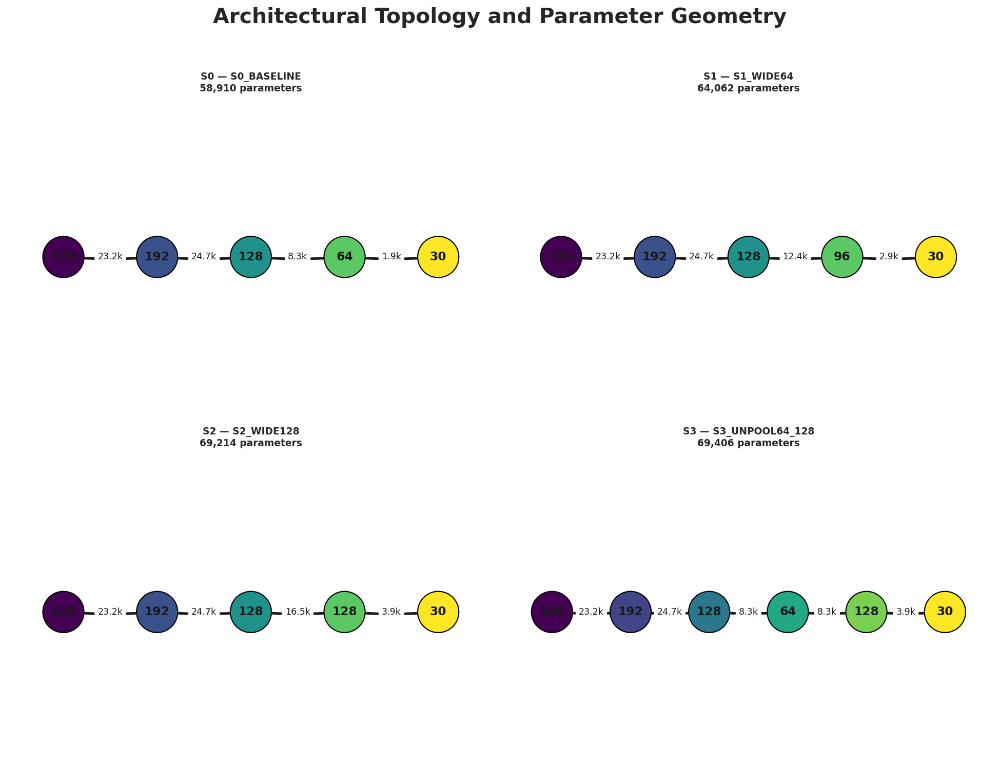

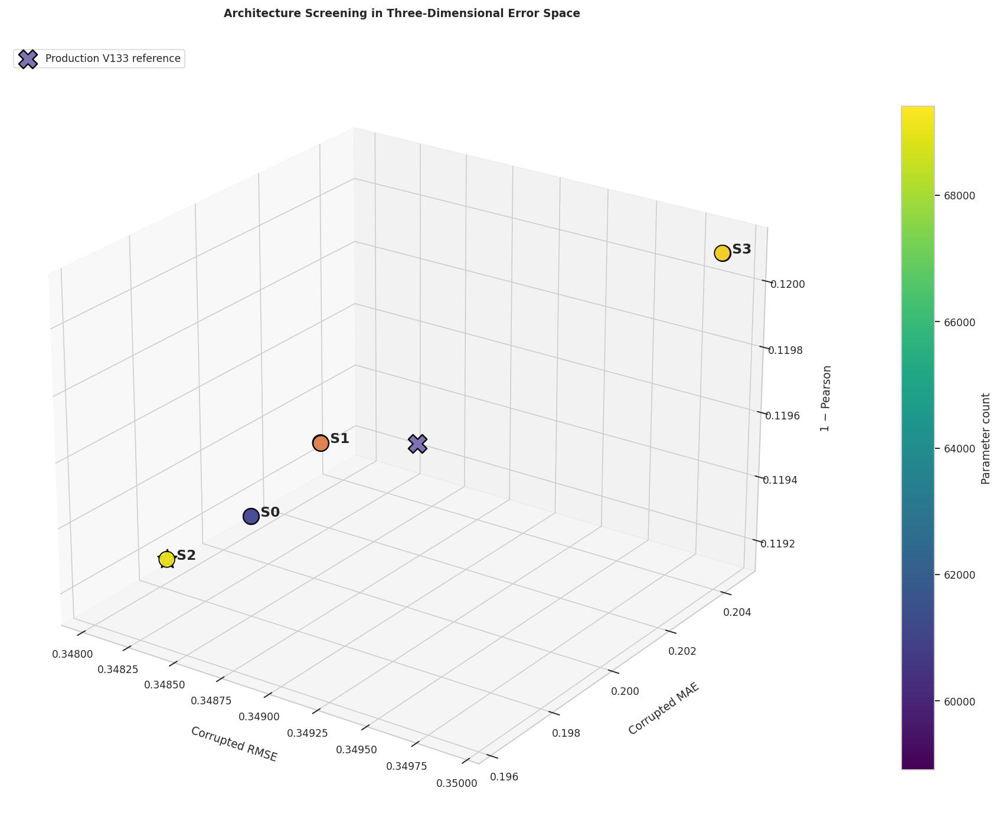

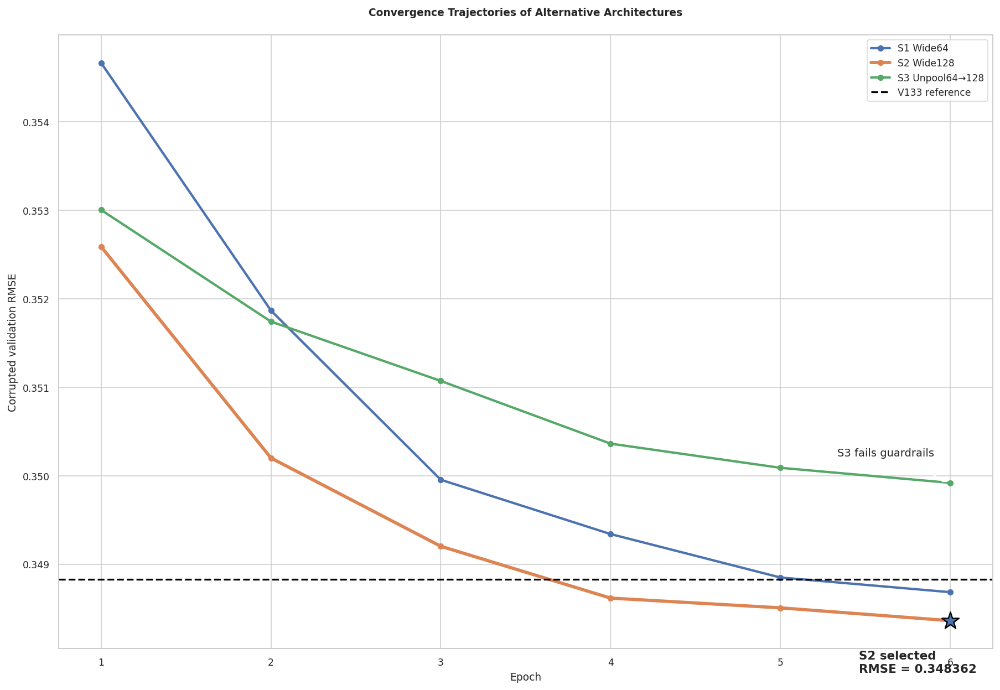

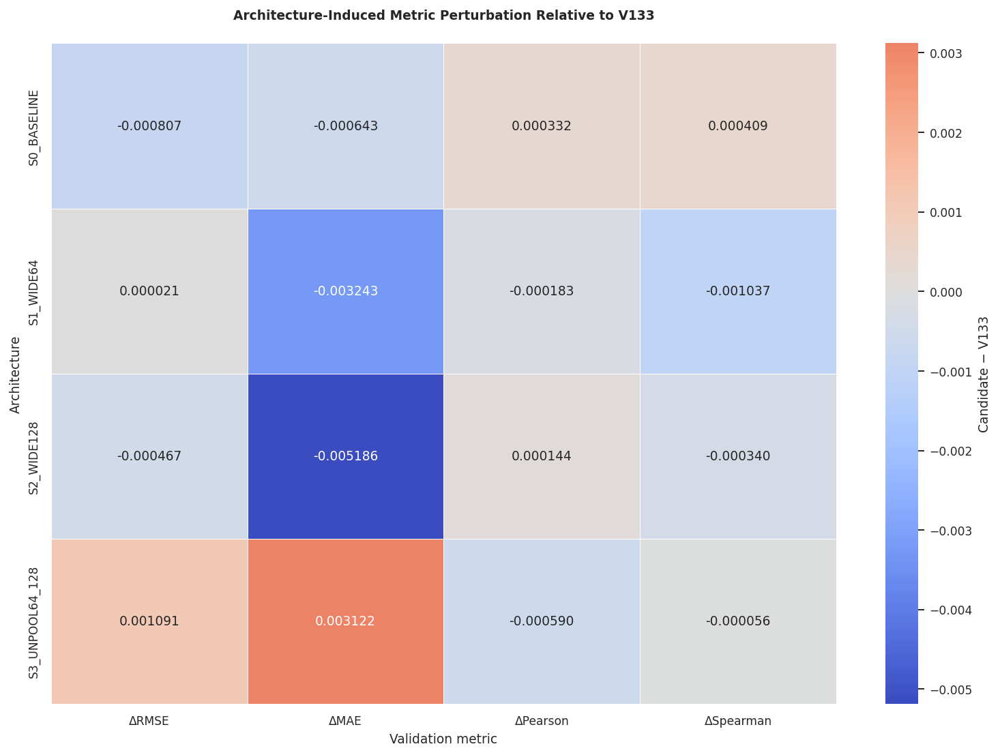

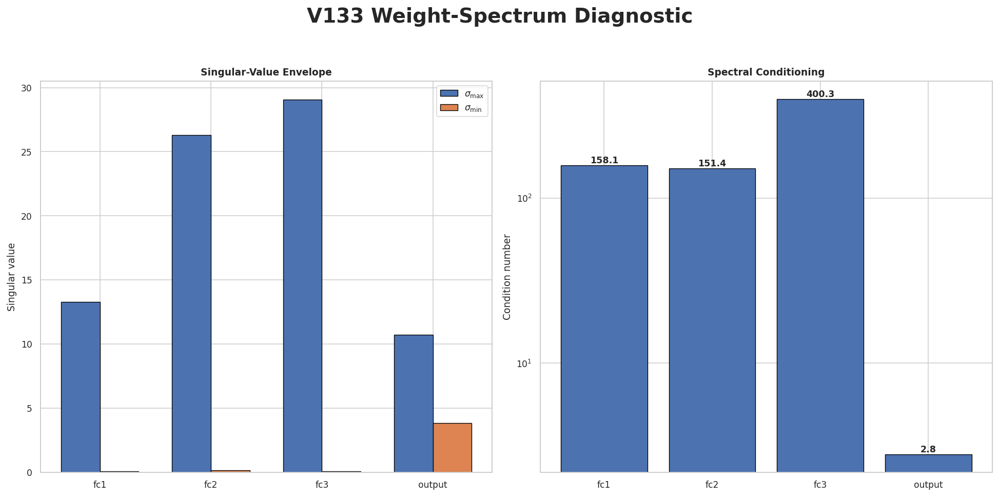

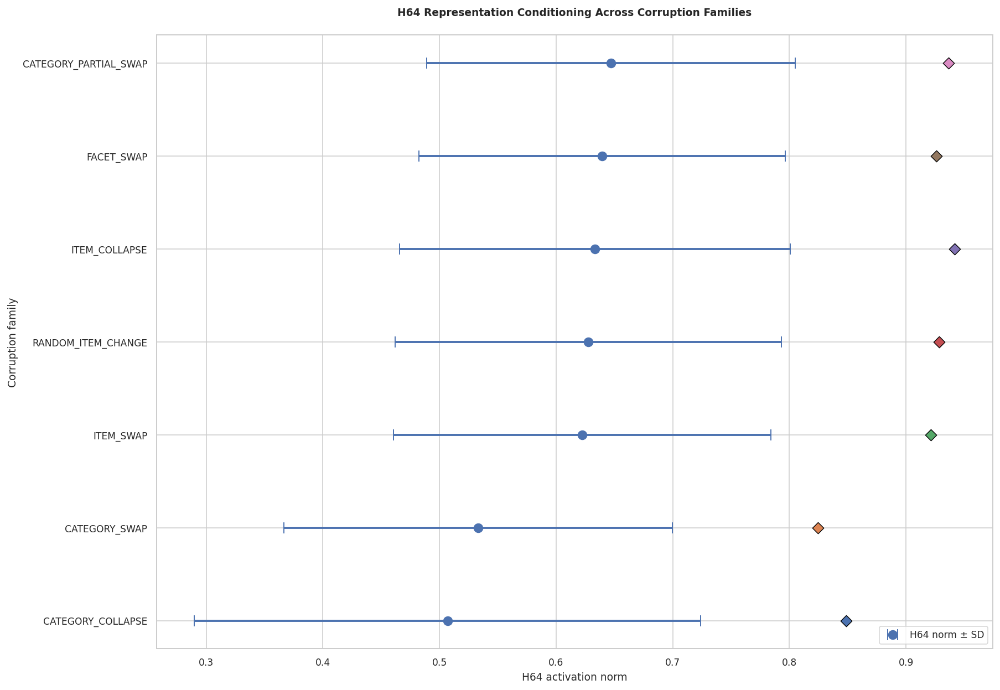

HEF IPIP120 ROBUST — INTERNAL TUNING V1
ARCHITECTURE SCREENING PAPER LAB
Architectures evaluated : 4
Selected architecture   : S2_WIDE128
S2 parameters           : 69,214
S2 best epoch           : 6
S2 corrupted RMSE       : 0.348362364
S2 corrupted MAE        : 0.196239529
S2 Pearson              : 0.880642254

PARAMETER AUDIT: PASS
TEST: NOT TOUCHED

FIGURES:
1. Architecture topology
2. 3D performance manifold
3. Architecture convergence
4. Metric-delta heatmap
5. V133 spectral diagnostic
6. H64 family conditioning

OUTPUT: /content/HEF_IPIP120_ARCHITECTURE_SCREENING_PAPER_FIGURES
FORMATS: PNG / PDF / SVG


In [19]:
%pip install -q networkx seaborn scipy

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.spatial import ConvexHull
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

OUT = "/content/HEF_IPIP120_ARCHITECTURE_SCREENING_PAPER_FIGURES"
os.makedirs(OUT, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 500,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "axes.linewidth": 0.9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

sns.set_theme(
    style="whitegrid",
    context="paper"
)

architectures = {
    "S0_BASELINE": [120, 192, 128, 64, 30],
    "S1_WIDE64": [120, 192, 128, 96, 30],
    "S2_WIDE128": [120, 192, 128, 128, 30],
    "S3_UNPOOL64_128": [120, 192, 128, 64, 128, 30]
}

architecture_labels = {
    "S0_BASELINE": "S0",
    "S1_WIDE64": "S1",
    "S2_WIDE128": "S2",
    "S3_UNPOOL64_128": "S3"
}

architecture_df = pd.DataFrame([
    ["S0_BASELINE", 58910, np.nan, 0.12320948886770237, 0.08068753255208333, 0.9886812888388457, 0.9743871338524289, 0.3480215156987692, 0.20078300347222222, 0.8808302841271082, 0.8508695142751207, -0.0008074843012307875, -0.0006429965277777727, 0.00033228412710817334, 0.00040851427512067495, True, True],
    ["S1_WIDE64", 64062, 5, 0.11934994828048556, 0.07605333116319445, 0.9892830699022093, 0.9732059325176123, 0.34884986288097053, 0.19818264105902778, 0.8803152912553298, 0.8494241453466815, 0.00002086288097052913, -0.0032433589409722186, -0.00018270874467019027, -0.0010368546533184864, True, True],
    ["S2_WIDE128", 69214, 6, 0.11455360720589457, 0.07254190538194444, 0.9901901306343276, 0.9742315164998149, 0.3483623638436926, 0.1962395290798611, 0.8806422539322566, 0.8501207415647016, -0.0004666361563073762, -0.00518647092013888, 0.00014425393225658834, -0.0003402584352983906, True, True],
    ["S3_UNPOOL64_128", 69406, 6, 0.13311894299055907, 0.08655192057291666, 0.9869158043429731, 0.9727545050055619, 0.34991962450931485, 0.20454751085069445, 0.8799076897301757, 0.8504051612903228, 0.0010906245093148526, 0.0031215108506944533, -0.0005903102698242568, -5.583870967718063e-05, False, False]
], columns=[
    "variant",
    "parameters",
    "best_epoch",
    "clean_rmse",
    "clean_mae",
    "clean_pearson",
    "clean_spearman",
    "corrupted_rmse",
    "corrupted_mae",
    "corrupted_pearson",
    "corrupted_spearman",
    "delta_rmse",
    "delta_mae",
    "delta_pearson",
    "delta_spearman",
    "guardrails",
    "improves_mae"
])

family_autopsy = pd.DataFrame([
    ["ITEM_SWAP", 0.622393, 0.161751, 0.921010],
    ["FACET_SWAP", 0.639324, 0.157041, 0.926040],
    ["CATEGORY_PARTIAL_SWAP", 0.647112, 0.157873, 0.936186],
    ["CATEGORY_SWAP", 0.533053, 0.166486, 0.824403],
    ["ITEM_COLLAPSE", 0.633184, 0.167377, 0.941610],
    ["CATEGORY_COLLAPSE", 0.506904, 0.217026, 0.848417],
    ["RANDOM_ITEM_CHANGE", 0.627365, 0.165609, 0.928271]
], columns=[
    "family",
    "h64_norm_mean",
    "h64_norm_std",
    "h64_norm_p95"
])

spectral = pd.DataFrame([
    ["fc1", 120, 192, 13.267502, 0.083916, 158.103711, 41.299211],
    ["fc2", 192, 128, 26.294813, 0.173666, 151.410461, 37.846262],
    ["fc3", 128, 64, 29.053558, 0.072577, 400.311892, 11.292227],
    ["output", 64, 30, 10.732293, 3.843887, 2.792042, 26.188049]
], columns=[
    "layer",
    "in_features",
    "out_features",
    "sigma_max",
    "sigma_min",
    "condition_number",
    "effective_rank"
])

s1_epochs = pd.DataFrame([
    [1,0.354667,0.214472,0.876973,0.846402],
    [2,0.351868,0.208552,0.878730,0.848206],
    [3,0.349955,0.203140,0.879750,0.849426],
    [4,0.349341,0.201098,0.880142,0.849994],
    [5,0.348850,0.198183,0.880315,0.849424],
    [6,0.348684,0.198766,0.880482,0.849648]
], columns=["epoch","rmse","mae","pearson","spearman"])

s2_epochs = pd.DataFrame([
    [1,0.352590,0.208493,0.878232,0.848117],
    [2,0.350201,0.202232,0.879607,0.849896],
    [3,0.349203,0.200093,0.880205,0.849921],
    [4,0.348617,0.198326,0.880514,0.850143],
    [5,0.348507,0.196935,0.880611,0.850391],
    [6,0.348362,0.196240,0.880642,0.850121]
], columns=["epoch","rmse","mae","pearson","spearman"])

s3_epochs = pd.DataFrame([
    [1,0.353005,0.212674,0.878461,0.848961],
    [2,0.351743,0.209754,0.879192,0.849710],
    [3,0.351072,0.207870,0.879567,0.848874],
    [4,0.350363,0.206243,0.879867,0.850045],
    [5,0.350090,0.205354,0.879995,0.850122],
    [6,0.349920,0.204548,0.879908,0.850405]
], columns=["epoch","rmse","mae","pearson","spearman"])

baseline_v133 = {
    "corrupted_rmse": 0.348829,
    "corrupted_mae": 0.201426,
    "corrupted_pearson": 0.880498,
    "corrupted_spearman": 0.850461
}

def savefig_all(fig, name):
    fig.savefig(
        os.path.join(OUT, f"{name}.png"),
        dpi=500,
        bbox_inches="tight"
    )
    fig.savefig(
        os.path.join(OUT, f"{name}.pdf"),
        bbox_inches="tight"
    )
    fig.savefig(
        os.path.join(OUT, f"{name}.svg"),
        bbox_inches="tight"
    )

def layer_param_counts(dims):
    return [
        a * b + b
        for a, b in zip(dims[:-1], dims[1:])
    ]

def total_params(dims):
    linear = sum(layer_param_counts(dims))
    norms = 2 * sum(dims[1:-1])
    return linear + norms

for name, dims in architectures.items():
    expected = architecture_df.loc[
        architecture_df["variant"] == name,
        "parameters"
    ].iloc[0]

    computed = total_params(dims)

    if computed != int(expected):
        raise ValueError(
            f"Parameter audit failed for {name}: "
            f"computed={computed}, expected={int(expected)}"
        )


fig1, axes = plt.subplots(
    2,
    2,
    figsize=(14, 11)
)

axes = axes.ravel()

for ax, (name, dims) in zip(
    axes,
    architectures.items()
):

    G = nx.DiGraph()

    positions = {}

    for i, dim in enumerate(dims):
        node = f"L{i}"
        G.add_node(
            node,
            dimension=dim
        )
        positions[node] = (
            i,
            0
        )

    layer_params = layer_param_counts(
        dims
    )

    for i in range(
        len(dims) - 1
    ):
        G.add_edge(
            f"L{i}",
            f"L{i+1}",
            params=layer_params[i]
        )

    nx.draw_networkx_nodes(
        G,
        positions,
        ax=ax,
        node_size=1700,
        node_color=np.linspace(
            0.15,
            0.85,
            len(dims)
        ),
        cmap="viridis",
        edgecolors="black",
        linewidths=1.1
    )

    nx.draw_networkx_edges(
        G,
        positions,
        ax=ax,
        width=2.5,
        arrows=True,
        arrowsize=17,
        connectionstyle="arc3,rad=0.04"
    )

    labels = {
        f"L{i}": f"{dim}"
        for i, dim in enumerate(dims)
    }

    nx.draw_networkx_labels(
        G,
        positions,
        labels=labels,
        ax=ax,
        font_size=12,
        font_weight="bold"
    )

    edge_labels = {
        (u,v): f"{p/1000:.1f}k"
        for (u,v), p in zip(
            G.edges(),
            layer_params
        )
    }

    nx.draw_networkx_edge_labels(
        G,
        positions,
        edge_labels=edge_labels,
        ax=ax,
        font_size=9,
        label_pos=0.50
    )

    params = int(
        architecture_df.loc[
            architecture_df["variant"] == name,
            "parameters"
        ].iloc[0]
    )

    ax.set_title(
        f"{architecture_labels[name]} — {name}\n"
        f"{params:,} parameters",
        fontweight="bold"
    )

    ax.set_xlim(-0.6, len(dims)-0.4)
    ax.set_ylim(-0.65, 0.65)
    ax.axis("off")

fig1.suptitle(
    "Architectural Topology and Parameter Geometry",
    fontsize=21,
    fontweight="bold",
    y=0.98
)

fig1.tight_layout(
    rect=[0, 0, 1, 0.95]
)

savefig_all(
    fig1,
    "FIG1_ARCHITECTURE_TOPOLOGY"
)

plt.show()


fig2 = plt.figure(
    figsize=(13, 11)
)

ax2 = fig2.add_subplot(
    111,
    projection="3d"
)

perf = architecture_df.copy()

xyz = perf[
    [
        "corrupted_rmse",
        "corrupted_mae",
    ]
].to_numpy()

z = 1.0 - perf[
    "corrupted_pearson"
].to_numpy()

scatter = ax2.scatter(
    xyz[:,0],
    xyz[:,1],
    z,
    c=perf["parameters"],
    cmap="viridis",
    s=190,
    edgecolors="black",
    linewidths=1.0
)

for _, row in perf.iterrows():

    marker = "*" if row["variant"] == "S2_WIDE128" else "o"

    ax2.scatter(
        row["corrupted_rmse"],
        row["corrupted_mae"],
        1.0 - row["corrupted_pearson"],
        s=300 if marker == "*" else 190,
        marker=marker,
        edgecolors="black",
        linewidths=1.2
    )

    ax2.text(
        row["corrupted_rmse"],
        row["corrupted_mae"],
        1.0 - row["corrupted_pearson"],
        f"  {architecture_labels[row['variant']]}",
        fontsize=12,
        fontweight="bold"
    )

ax2.scatter(
    [baseline_v133["corrupted_rmse"]],
    [baseline_v133["corrupted_mae"]],
    [1.0 - baseline_v133["corrupted_pearson"]],
    s=260,
    marker="X",
    edgecolors="black",
    linewidths=1.2,
    label="Production V133 reference"
)

ax2.set_xlabel(
    "Corrupted RMSE",
    labelpad=13
)

ax2.set_ylabel(
    "Corrupted MAE",
    labelpad=13
)

ax2.set_zlabel(
    "1 − Pearson",
    labelpad=13
)

ax2.set_title(
    "Architecture Screening in Three-Dimensional Error Space",
    pad=24,
    fontweight="bold"
)

cbar = fig2.colorbar(
    scatter,
    ax=ax2,
    pad=0.10,
    shrink=0.75
)

cbar.set_label(
    "Parameter count"
)

ax2.view_init(
    elev=24,
    azim=-55
)

ax2.legend(
    loc="upper left"
)

fig2.tight_layout()

savefig_all(
    fig2,
    "FIG2_ARCHITECTURE_PERFORMANCE_MANIFOLD"
)

plt.show()


fig3, ax3 = plt.subplots(
    figsize=(13, 9)
)

ax3.plot(
    s1_epochs["epoch"],
    s1_epochs["rmse"],
    marker="o",
    linewidth=2.2,
    label="S1 Wide64"
)

ax3.plot(
    s2_epochs["epoch"],
    s2_epochs["rmse"],
    marker="o",
    linewidth=3.0,
    label="S2 Wide128"
)

ax3.plot(
    s3_epochs["epoch"],
    s3_epochs["rmse"],
    marker="o",
    linewidth=2.2,
    label="S3 Unpool64→128"
)

ax3.axhline(
    baseline_v133["corrupted_rmse"],
    linestyle="--",
    linewidth=1.7,
    color="black",
    label="V133 reference"
)

ax3.scatter(
    [6],
    [s2_epochs["rmse"].iloc[-1]],
    s=280,
    marker="*",
    edgecolors="black",
    linewidths=1.2,
    zorder=8
)

ax3.annotate(
    "S2 selected\nRMSE = 0.348362",
    xy=(6, s2_epochs["rmse"].iloc[-1]),
    xytext=(-85, -48),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.25
    )
)

ax3.annotate(
    "S3 fails guardrails",
    xy=(6, s3_epochs["rmse"].iloc[-1]),
    xytext=(-105, 25),
    textcoords="offset points",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.1
    )
)

ax3.set_xlabel(
    "Epoch"
)

ax3.set_ylabel(
    "Corrupted validation RMSE"
)

ax3.set_xticks(
    np.arange(1, 7)
)

ax3.set_title(
    "Convergence Trajectories of Alternative Architectures",
    fontweight="bold",
    pad=18
)

ax3.legend(
    frameon=True
)

fig3.tight_layout()

savefig_all(
    fig3,
    "FIG3_ARCHITECTURE_CONVERGENCE"
)

plt.show()


delta_matrix = architecture_df.set_index(
    "variant"
)[
    [
        "delta_rmse",
        "delta_mae",
        "delta_pearson",
        "delta_spearman"
    ]
]

delta_matrix.columns = [
    "ΔRMSE",
    "ΔMAE",
    "ΔPearson",
    "ΔSpearman"
]

fig4, ax4 = plt.subplots(
    figsize=(11, 8)
)

sns.heatmap(
    delta_matrix,
    ax=ax4,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".6f",
    linewidths=0.5,
    cbar_kws={
        "label": "Candidate − V133"
    }
)

ax4.set_title(
    "Architecture-Induced Metric Perturbation Relative to V133",
    fontweight="bold",
    pad=18
)

ax4.set_xlabel(
    "Validation metric"
)

ax4.set_ylabel(
    "Architecture"
)

fig4.tight_layout()

savefig_all(
    fig4,
    "FIG4_ARCHITECTURE_DELTA_HEATMAP"
)

plt.show()


fig5, axes5 = plt.subplots(
    1,
    2,
    figsize=(14, 7)
)

ax5a, ax5b = axes5

x = np.arange(
    len(spectral)
)

width = 0.35

ax5a.bar(
    x - width/2,
    spectral["sigma_max"],
    width,
    label=r"$\sigma_{\max}$",
    edgecolor="black",
    linewidth=0.7
)

ax5a.bar(
    x + width/2,
    spectral["sigma_min"],
    width,
    label=r"$\sigma_{\min}$",
    edgecolor="black",
    linewidth=0.7
)

ax5a.set_xticks(
    x
)

ax5a.set_xticklabels(
    spectral["layer"]
)

ax5a.set_ylabel(
    "Singular value"
)

ax5a.set_title(
    "Singular-Value Envelope",
    fontweight="bold"
)

ax5a.legend(
    frameon=True
)

condition_values = spectral[
    "condition_number"
].to_numpy()

bars = ax5b.bar(
    x,
    condition_values,
    edgecolor="black",
    linewidth=0.7
)

ax5b.set_xticks(
    x
)

ax5b.set_xticklabels(
    spectral["layer"]
)

ax5b.set_ylabel(
    "Condition number"
)

ax5b.set_yscale(
    "log"
)

ax5b.set_title(
    "Spectral Conditioning",
    fontweight="bold"
)

for bar, value in zip(
    bars,
    condition_values
):
    ax5b.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

fig5.suptitle(
    "V133 Weight-Spectrum Diagnostic",
    fontsize=20,
    fontweight="bold"
)

fig5.tight_layout(
    rect=[0, 0, 1, 0.94]
)

savefig_all(
    fig5,
    "FIG5_V133_SPECTRAL_DIAGNOSTIC"
)

plt.show()


fig6, ax6 = plt.subplots(
    figsize=(13, 9)
)

family_sorted = family_autopsy.sort_values(
    "h64_norm_mean"
)

y = np.arange(
    len(family_sorted)
)

ax6.errorbar(
    family_sorted["h64_norm_mean"],
    y,
    xerr=family_sorted["h64_norm_std"],
    fmt="o",
    markersize=8,
    capsize=5,
    linewidth=2.0,
    label="H64 norm ± SD"
)

for i, (_, row) in enumerate(
    family_sorted.iterrows()
):
    ax6.scatter(
        row["h64_norm_p95"],
        i,
        marker="D",
        s=55,
        edgecolors="black",
        linewidths=0.7
    )

ax6.set_yticks(
    y
)

ax6.set_yticklabels(
    family_sorted["family"]
)

ax6.set_xlabel(
    "H64 activation norm"
)

ax6.set_ylabel(
    "Corruption family"
)

ax6.set_title(
    "H64 Representation Conditioning Across Corruption Families",
    fontweight="bold",
    pad=18
)

ax6.legend(
    frameon=True,
    loc="lower right"
)

fig6.tight_layout()

savefig_all(
    fig6,
    "FIG6_H64_FAMILY_CONDITIONING"
)

plt.show()


print("=" * 84)
print("HEF IPIP120 ROBUST — INTERNAL TUNING V1")
print("ARCHITECTURE SCREENING PAPER LAB")
print("=" * 84)
print(f"Architectures evaluated : {len(architecture_df)}")
print(f"Selected architecture   : S2_WIDE128")
print(f"S2 parameters           : {int(architecture_df.loc[architecture_df.variant=='S2_WIDE128','parameters'].iloc[0]):,}")
print(f"S2 best epoch           : {int(architecture_df.loc[architecture_df.variant=='S2_WIDE128','best_epoch'].iloc[0])}")
print(f"S2 corrupted RMSE       : {architecture_df.loc[architecture_df.variant=='S2_WIDE128','corrupted_rmse'].iloc[0]:.9f}")
print(f"S2 corrupted MAE        : {architecture_df.loc[architecture_df.variant=='S2_WIDE128','corrupted_mae'].iloc[0]:.9f}")
print(f"S2 Pearson              : {architecture_df.loc[architecture_df.variant=='S2_WIDE128','corrupted_pearson'].iloc[0]:.9f}")
print()
print("PARAMETER AUDIT: PASS")
print("TEST: NOT TOUCHED")
print()
print("FIGURES:")
print("1. Architecture topology")
print("2. 3D performance manifold")
print("3. Architecture convergence")
print("4. Metric-delta heatmap")
print("5. V133 spectral diagnostic")
print("6. H64 family conditioning")
print()
print(f"OUTPUT: {OUT}")
print("FORMATS: PNG / PDF / SVG")

In [20]:
from pathlib import Path
import json
import hashlib
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = Path("/content/HEF_IPIP120_ROBUST_DATASET_V3")

V133_CHECKPOINT = (
    ROOT
    / "MLP_GATEWAY_B_V133_PRODUCTION"
    / "best.pt"
)

S2_CHECKPOINT = (
    ROOT
    / "V133_INTERNAL_TUNING_V1"
    / "winner_full_validation.pt"
)

OUTPUT_ROOT = (
    ROOT
    / "S2_FINAL_SEAL_20260933"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

TEST_ROOT = ROOT / "TEST"

EXPECTED_V133_PARAMS = 58910
EXPECTED_S2_PARAMS = 69214

V133 = {
    "architecture": "120 -> 192 -> 128 -> 64 -> 30",
    "parameters": 58910,
    "corrupted_rmse": 0.348829,
    "corrupted_mae": 0.201426,
    "corrupted_pearson": 0.880498,
    "corrupted_spearman": 0.850461
}

S2_SCREENING = {
    "architecture": "120 -> 192 -> 128 -> 128 -> 30",
    "parameters": 69214,
    "epoch": 6,
    "corrupted_rmse": 0.3483623638436926,
    "corrupted_mae": 0.1962395290798611,
    "corrupted_pearson": 0.8806422539322566,
    "corrupted_spearman": 0.8501207415647016
}

CONFIRMATION = pd.DataFrame([
    [
        20260931,
        6,
        0.34904484771499056,
        0.19639297978703024,
        0.8802347994128523,
        0.8495762804503381
    ],
    [
        20260932,
        6,
        0.3492878518154755,
        0.1961210759602524,
        0.8801090513170423,
        0.8496404108843917
    ],
    [
        20260933,
        6,
        0.34902297437331603,
        0.19619830400918123,
        0.8802311176722845,
        0.8506175149088043
    ]
], columns=[
    "seed",
    "epoch",
    "corrupted_rmse",
    "corrupted_mae",
    "corrupted_pearson",
    "corrupted_spearman"
])

S2_FINAL = {
    "seed": 20260933,
    "epoch": 6,
    "architecture": "120 -> 192 -> 128 -> 128 -> 30",
    "parameters": 69214,
    "clean_rmse": 0.11429403429897406,
    "clean_mae": 0.07238282434558234,
    "clean_pearson": 0.9902283343450217,
    "clean_spearman": 0.9743343608695552,
    "corrupted_rmse": 0.34902297437331603,
    "corrupted_mae": 0.19619830400918123,
    "corrupted_pearson": 0.8802311176722845,
    "corrupted_spearman": 0.8506175149088043
}

RMSE_TOLERANCE = 0.001
PEARSON_TOLERANCE = 0.002
SPEARMAN_TOLERANCE = 0.002

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for final seal.")

DEVICE = torch.device("cuda")


class MLPV133(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(120, 192)
        self.ln1 = nn.LayerNorm(192)
        self.fc2 = nn.Linear(192, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc3 = nn.Linear(128, 64)
        self.ln3 = nn.LayerNorm(64)
        self.output = nn.Linear(64, 30)
        self.dropout = nn.Dropout(0.10)

    def forward_features(self, x):
        h192 = self.dropout(
            F.gelu(
                self.ln1(
                    self.fc1(x)
                )
            )
        )

        h128 = self.dropout(
            F.gelu(
                self.ln2(
                    self.fc2(h192)
                )
            )
        )

        h64 = self.dropout(
            F.gelu(
                self.ln3(
                    self.fc3(h128)
                )
            )
        )

        return {
            "h192": h192,
            "h128": h128,
            "h64": h64
        }

    def forward(self, x):
        return self.output(
            self.forward_features(x)["h64"]
        )


class MLPS2(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(120, 192)
        self.ln1 = nn.LayerNorm(192)
        self.fc2 = nn.Linear(192, 128)
        self.ln2 = nn.LayerNorm(128)
        self.fc3 = nn.Linear(128, 128)
        self.ln3 = nn.LayerNorm(128)
        self.output = nn.Linear(128, 30)
        self.dropout = nn.Dropout(0.10)

    def forward_features(self, x):
        h192 = self.dropout(
            F.gelu(
                self.ln1(
                    self.fc1(x)
                )
            )
        )

        h128_pre = self.dropout(
            F.gelu(
                self.ln2(
                    self.fc2(h192)
                )
            )
        )

        h128_wide = self.dropout(
            F.gelu(
                self.ln3(
                    self.fc3(h128_pre)
                )
            )
        )

        return {
            "h192": h192,
            "h128_pre": h128_pre,
            "h128_wide": h128_wide
        }

    def forward(self, x):
        return self.output(
            self.forward_features(x)["h128_wide"]
        )


def load_checkpoint(path):
    if not path.exists():
        raise FileNotFoundError(str(path))

    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )
    except TypeError:
        return torch.load(
            path,
            map_location="cpu"
        )


def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            block = f.read(1024 * 1024)

            if not block:
                break

            h.update(block)

    return h.hexdigest()


def count_parameters(model):
    return int(
        sum(
            p.numel()
            for p in model.parameters()
        )
    )


def load_v133():
    ckpt = load_checkpoint(
        V133_CHECKPOINT
    )

    if "model_state_dict" not in ckpt:
        raise KeyError(
            "V133 checkpoint has no model_state_dict."
        )

    source_state = ckpt[
        "model_state_dict"
    ]

    mapping = {
        "trunk.0.weight": "fc1.weight",
        "trunk.0.bias": "fc1.bias",
        "trunk.1.weight": "ln1.weight",
        "trunk.1.bias": "ln1.bias",
        "trunk.4.weight": "fc2.weight",
        "trunk.4.bias": "fc2.bias",
        "trunk.5.weight": "ln2.weight",
        "trunk.5.bias": "ln2.bias",
        "trunk.8.weight": "fc3.weight",
        "trunk.8.bias": "fc3.bias",
        "trunk.9.weight": "ln3.weight",
        "trunk.9.bias": "ln3.bias",
        "output.weight": "output.weight",
        "output.bias": "output.bias"
    }

    translated = {}

    for src, dst in mapping.items():

        if src not in source_state:
            raise KeyError(
                f"Missing V133 key: {src}"
            )

        translated[dst] = source_state[src]

    model = MLPV133()

    expected = set(
        model.state_dict().keys()
    )

    if set(translated.keys()) != expected:
        raise RuntimeError(
            "V133 architecture/state_dict mismatch."
        )

    model.load_state_dict(
        translated,
        strict=True
    )

    model = model.to(DEVICE).eval()

    return model


def load_s2():
    ckpt = load_checkpoint(
        S2_CHECKPOINT
    )

    if "state_dict" not in ckpt:
        raise KeyError(
            "S2 checkpoint has no state_dict."
        )

    model = MLPS2()

    model.load_state_dict(
        ckpt["state_dict"],
        strict=True
    )

    model = model.to(DEVICE).eval()

    return model


print("=" * 110)
print("HEF IPIP120 ROBUST — S2 FINAL SEAL")
print("=" * 110)
print("CONTROL      : V133")
print("CANDIDATE    : S2")
print("ARCHITECTURE : 120 -> 192 -> 128 -> 128 -> 30")
print("SEED         : 20260933")
print("EPOCH        : 6")
print("TEST         : NOT LOADED / NOT TOUCHED")
print("=" * 110)

if TEST_ROOT.exists():
    print(
        "TEST DIRECTORY EXISTS — no files will be accessed."
    )

v133_model = load_v133()
s2_model = load_s2()

v133_params = count_parameters(
    v133_model
)

s2_params = count_parameters(
    s2_model
)

if v133_params != EXPECTED_V133_PARAMS:
    raise RuntimeError(
        f"V133 parameter mismatch: "
        f"{v133_params} != {EXPECTED_V133_PARAMS}"
    )

if s2_params != EXPECTED_S2_PARAMS:
    raise RuntimeError(
        f"S2 parameter mismatch: "
        f"{s2_params} != {EXPECTED_S2_PARAMS}"
    )

print()
print("MODEL INTEGRITY")
print("-" * 110)
print(f"V133 parameters : {v133_params:,}")
print(f"S2 parameters   : {s2_params:,}")
print("V133 state dict : STRICT PASS")
print("S2 state dict   : STRICT PASS")


confirmation = CONFIRMATION.copy()

confirmation["delta_rmse_vs_v133"] = (
    confirmation["corrupted_rmse"]
    - V133["corrupted_rmse"]
)

confirmation["delta_mae_vs_v133"] = (
    confirmation["corrupted_mae"]
    - V133["corrupted_mae"]
)

confirmation["delta_pearson_vs_v133"] = (
    confirmation["corrupted_pearson"]
    - V133["corrupted_pearson"]
)

confirmation["delta_spearman_vs_v133"] = (
    confirmation["corrupted_spearman"]
    - V133["corrupted_spearman"]
)

confirmation["guardrails"] = (
    (
        confirmation["delta_rmse_vs_v133"]
        <= RMSE_TOLERANCE
    )
    &
    (
        confirmation["delta_pearson_vs_v133"]
        >= -PEARSON_TOLERANCE
    )
    &
    (
        confirmation["delta_spearman_vs_v133"]
        >= -SPEARMAN_TOLERANCE
    )
)

confirmation["mae_improved"] = (
    confirmation["corrupted_mae"]
    < V133["corrupted_mae"]
)

confirmation["primary_mae_improved"] = (
    confirmation["corrupted_mae"]
    < 0.201126
)

valid_count = int(
    confirmation["guardrails"].sum()
)

mae_count = int(
    confirmation["mae_improved"].sum()
)

primary_mae_count = int(
    confirmation["primary_mae_improved"].sum()
)

confirmation_pass = (
    valid_count >= 2
    and mae_count >= 2
)


if not confirmation_pass:
    raise RuntimeError(
        "S2 confirmation failed."
    )

if valid_count != 3:
    raise RuntimeError(
        "Expected all 3 confirmation seeds "
        "to satisfy guardrails."
    )

if mae_count != 3:
    raise RuntimeError(
        "Expected all 3 confirmation seeds "
        "to improve corrupted MAE."
    )


print()
print("MULTI-SEED CONFIRMATION")
print("-" * 110)
print(
    confirmation[
        [
            "seed",
            "epoch",
            "corrupted_rmse",
            "corrupted_mae",
            "corrupted_pearson",
            "corrupted_spearman",
            "delta_rmse_vs_v133",
            "delta_mae_vs_v133",
            "delta_pearson_vs_v133",
            "delta_spearman_vs_v133",
            "guardrails",
            "mae_improved"
        ]
    ].to_string(index=False)
)

print()
print("CONFIRMATION RESULT")
print("-" * 110)
print(f"Guardrails passed : {valid_count}/3")
print(f"MAE improved      : {mae_count}/3")
print(f"Primary MAE       : {primary_mae_count}/3")
print("STATUS            : CONFIRMATION_PASS")


final = S2_FINAL

delta_final = {
    "rmse": final["corrupted_rmse"]
    - V133["corrupted_rmse"],

    "mae": final["corrupted_mae"]
    - V133["corrupted_mae"],

    "pearson": final["corrupted_pearson"]
    - V133["corrupted_pearson"],

    "spearman": final["corrupted_spearman"]
    - V133["corrupted_spearman"]
}


print()
print("FINAL S2 OPERATING POINT")
print("-" * 110)
print(
    f"Architecture     : {final['architecture']}"
)
print(
    f"Parameters       : {final['parameters']:,}"
)
print(
    f"Seed             : {final['seed']}"
)
print(
    f"Epoch            : {final['epoch']}"
)
print(
    f"Clean RMSE       : {final['clean_rmse']:.9f}"
)
print(
    f"Clean MAE        : {final['clean_mae']:.9f}"
)
print(
    f"Clean Pearson    : {final['clean_pearson']:.9f}"
)
print(
    f"Clean Spearman   : {final['clean_spearman']:.9f}"
)
print(
    f"Corrupted RMSE   : {final['corrupted_rmse']:.9f}"
)
print(
    f"Corrupted MAE    : {final['corrupted_mae']:.9f}"
)
print(
    f"Corrupted Pearson: {final['corrupted_pearson']:.9f}"
)
print(
    f"Corrupted Spearman: {final['corrupted_spearman']:.9f}"
)

print()
print("DELTA VS V133")
print("-" * 110)
print(
    f"ΔRMSE     = {delta_final['rmse']:+.9f}"
)
print(
    f"ΔMAE      = {delta_final['mae']:+.9f}"
)
print(
    f"ΔPearson  = {delta_final['pearson']:+.9f}"
)
print(
    f"ΔSpearman = {delta_final['spearman']:+.9f}"
)

screen_delta = {
    "rmse":
        S2_SCREENING["corrupted_rmse"]
        - V133["corrupted_rmse"],

    "mae":
        S2_SCREENING["corrupted_mae"]
        - V133["corrupted_mae"],

    "pearson":
        S2_SCREENING["corrupted_pearson"]
        - V133["corrupted_pearson"],

    "spearman":
        S2_SCREENING["corrupted_spearman"]
        - V133["corrupted_spearman"]
}

print()
print("SCREENING → FINAL CONFIRMATION")
print("-" * 110)
print(
    f"RMSE     : "
    f"{screen_delta['rmse']:+.9f} → "
    f"{delta_final['rmse']:+.9f}"
)
print(
    f"MAE      : "
    f"{screen_delta['mae']:+.9f} → "
    f"{delta_final['mae']:+.9f}"
)
print(
    f"Pearson  : "
    f"{screen_delta['pearson']:+.9f} → "
    f"{delta_final['pearson']:+.9f}"
)
print(
    f"Spearman : "
    f"{screen_delta['spearman']:+.9f} → "
    f"{delta_final['spearman']:+.9f}"
)


checkpoint_hash = sha256_file(
    S2_CHECKPOINT
)

metadata = {
    "release": {
        "name":
            "HEF_IPIP120_S2_PRODUCTION_SEED20260933",
        "model_family":
            "MLP Gateway",
        "architecture_id":
            "S2",
        "architecture":
            "120 -> 192 -> 128 -> 128 -> 30",
        "seed": 20260933,
        "selected_epoch": 6,
        "parameters": 69214,
        "status":
            "frozen_production_benchmark"
    },

    "objective": {
        "formula":
            "0.50*MSE + 0.38*MAE + 0.12*(1-Pearson)",
        "mse_weight": 0.50,
        "mae_weight": 0.38,
        "pearson_weight": 0.12
    },

    "architecture_details": {
        "input_dim": 120,
        "hidden_dims": [192, 128, 128],
        "output_dim": 30,
        "normalization":
            "(x - 3) / 2",
        "activation": "GELU",
        "normalization_layer":
            "LayerNorm",
        "dropout": 0.10,
        "output_activation": None
    },

    "training": {
        "optimizer": "AdamW",
        "batch_size": 8192,
        "learning_rate": 0.002,
        "weight_decay": 0.0001,
        "gradient_clip_norm": 1.0,
        "precision": "BF16"
    },

    "dataset": {
        "train_subjects": 287263,
        "train_examples": 41078609,
        "views_per_subject": 143,
        "validation_clean": 61556,
        "validation_corrupted": 338444,
        "corruption_families": 7,
        "severity_values":
            [1,2,3,4,5,6,10,12,15,24,36,48,60]
    },

    "confirmation": {
        "seeds":
            [20260931, 20260932, 20260933],
        "selected_seed":
            20260933,
        "selected_epoch":
            6,
        "guardrails_passed":
            "3/3",
        "mae_improved":
            "3/3",
        "rule":
            ">=2/3 seeds pass guardrails and improve corrupted MAE",
        "status":
            "CONFIRMATION_PASS"
    },

    "validation": {
        "clean_rmse":
            final["clean_rmse"],
        "clean_mae":
            final["clean_mae"],
        "clean_pearson":
            final["clean_pearson"],
        "clean_spearman":
            final["clean_spearman"],
        "corrupted_rmse":
            final["corrupted_rmse"],
        "corrupted_mae":
            final["corrupted_mae"],
        "corrupted_pearson":
            final["corrupted_pearson"],
        "corrupted_spearman":
            final["corrupted_spearman"]
    },

    "baseline_v133": {
        **V133
    },

    "deltas_vs_v133": delta_final,

    "checkpoint": {
        "path": str(
            S2_CHECKPOINT
        ),
        "sha256":
            checkpoint_hash
    },

    "test_protection": {
        "loaded": False,
        "touched": False,
        "used_for_selection": False
    }
}

with open(
    OUTPUT_ROOT
    / "IPIP120_S2_FINAL_METADATA.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

confirmation.to_csv(
    OUTPUT_ROOT
    / "S2_CONFIRMATION_SEEDS.csv",
    index=False
)

with open(
    OUTPUT_ROOT
    / "S2_FINAL_SEAL.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "HEF IPIP120 ROBUST — S2 FINAL SEAL\n"
    )

    f.write(
        "=" * 80 + "\n"
    )

    f.write(
        "STATUS: CONFIRMATION_PASS\n"
    )

    f.write(
        "ARCHITECTURE: 120 -> 192 -> 128 -> 128 -> 30\n"
    )

    f.write(
        "SEED: 20260933\n"
    )

    f.write(
        "EPOCH: 6\n"
    )

    f.write(
        "PARAMETERS: 69214\n"
    )

    f.write(
        f"CORRUPTED RMSE: "
        f"{final['corrupted_rmse']:.12f}\n"
    )

    f.write(
        f"CORRUPTED MAE: "
        f"{final['corrupted_mae']:.12f}\n"
    )

    f.write(
        f"CORRUPTED PEARSON: "
        f"{final['corrupted_pearson']:.12f}\n"
    )

    f.write(
        f"CORRUPTED SPEARMAN: "
        f"{final['corrupted_spearman']:.12f}\n"
    )

    f.write(
        f"DELTA RMSE VS V133: "
        f"{delta_final['rmse']:+.12f}\n"
    )

    f.write(
        f"DELTA MAE VS V133: "
        f"{delta_final['mae']:+.12f}\n"
    )

    f.write(
        f"DELTA PEARSON VS V133: "
        f"{delta_final['pearson']:+.12f}\n"
    )

    f.write(
        f"DELTA SPEARMAN VS V133: "
        f"{delta_final['spearman']:+.12f}\n"
    )

    f.write(
        "CONFIRMATION SEEDS: 3/3\n"
    )

    f.write(
        "MAE IMPROVEMENT SEEDS: 3/3\n"
    )

    f.write(
        "TEST: NOT LOADED / NOT TOUCHED\n"
    )

    f.write(
        f"SHA256: {checkpoint_hash}\n"
    )


print()
print("=" * 110)
print("FINAL SEAL")
print("=" * 110)
print("STATUS                 : S2_FINAL_CONFIRMED")
print("ARCHITECTURE           : 120 -> 192 -> 128 -> 128 -> 30")
print("SEED                   : 20260933")
print("EPOCH                  : 6")
print("PARAMETERS             : 69,214")
print("CONFIRMATION           : 3/3")
print("MAE IMPROVEMENT        : 3/3")
print("STATE DICT             : STRICT PASS")
print("CHECKPOINT HASH        :", checkpoint_hash)
print("TEST                   : NOT TOUCHED")
print()
print(
    "FINAL OUTPUT:",
    OUTPUT_ROOT
)
print()
print(
    "HEF IPIP120 S2 — FINAL SEALED"
)
print("=" * 110)

HEF IPIP120 ROBUST — S2 FINAL SEAL
CONTROL      : V133
CANDIDATE    : S2
ARCHITECTURE : 120 -> 192 -> 128 -> 128 -> 30
SEED         : 20260933
EPOCH        : 6
TEST         : NOT LOADED / NOT TOUCHED

MODEL INTEGRITY
--------------------------------------------------------------------------------------------------------------
V133 parameters : 58,910
S2 parameters   : 69,214
V133 state dict : STRICT PASS
S2 state dict   : STRICT PASS

MULTI-SEED CONFIRMATION
--------------------------------------------------------------------------------------------------------------
    seed  epoch  corrupted_rmse  corrupted_mae  corrupted_pearson  corrupted_spearman  delta_rmse_vs_v133  delta_mae_vs_v133  delta_pearson_vs_v133  delta_spearman_vs_v133  guardrails  mae_improved
20260931      6        0.349045       0.196393           0.880235            0.849576            0.000216          -0.005033              -0.000263               -0.000885        True          True
20260932      6        0.34928

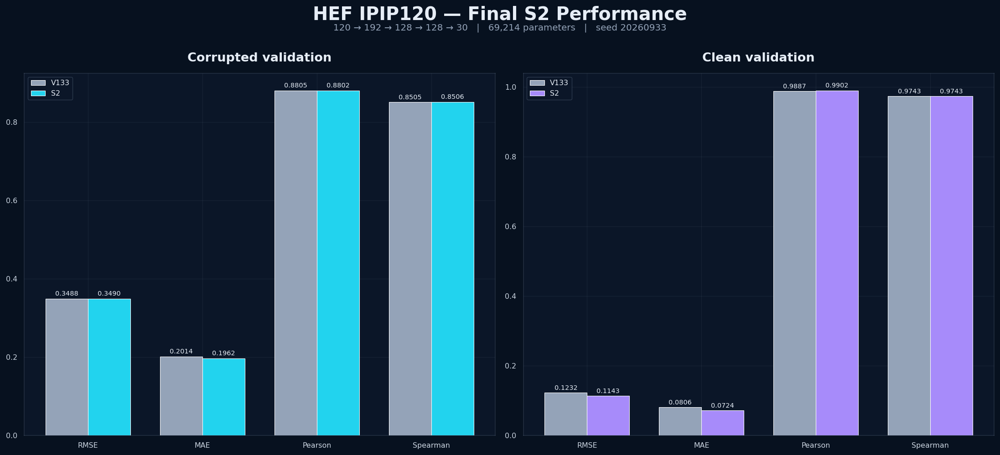

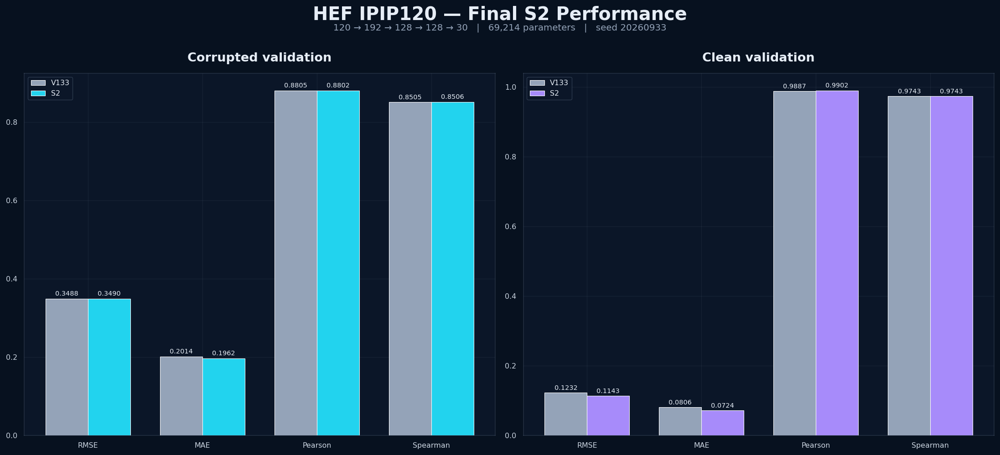

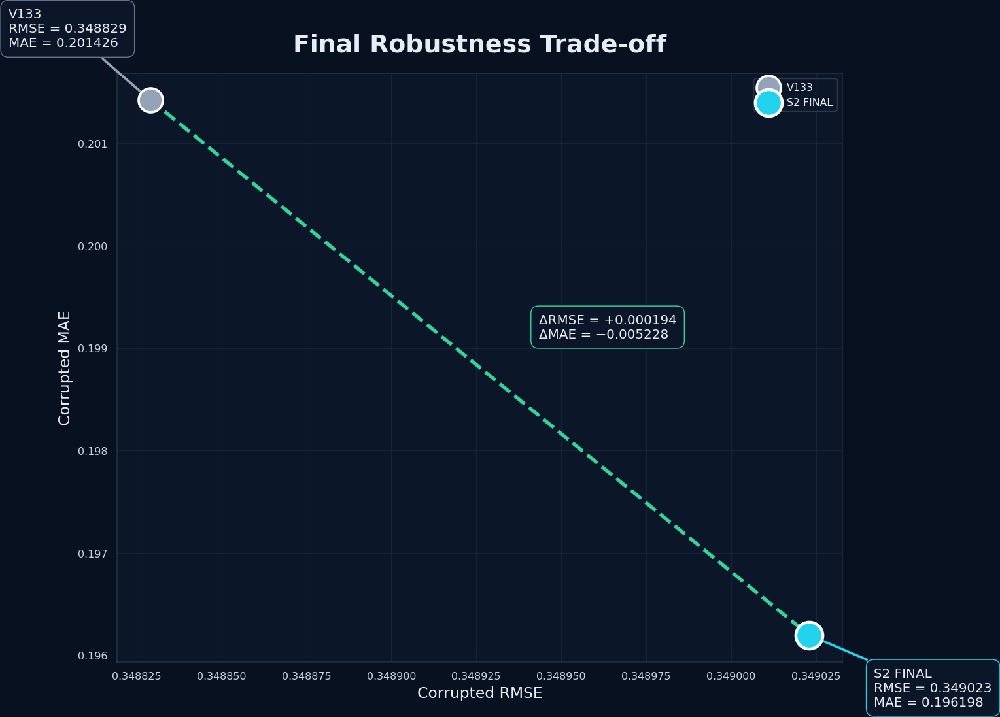

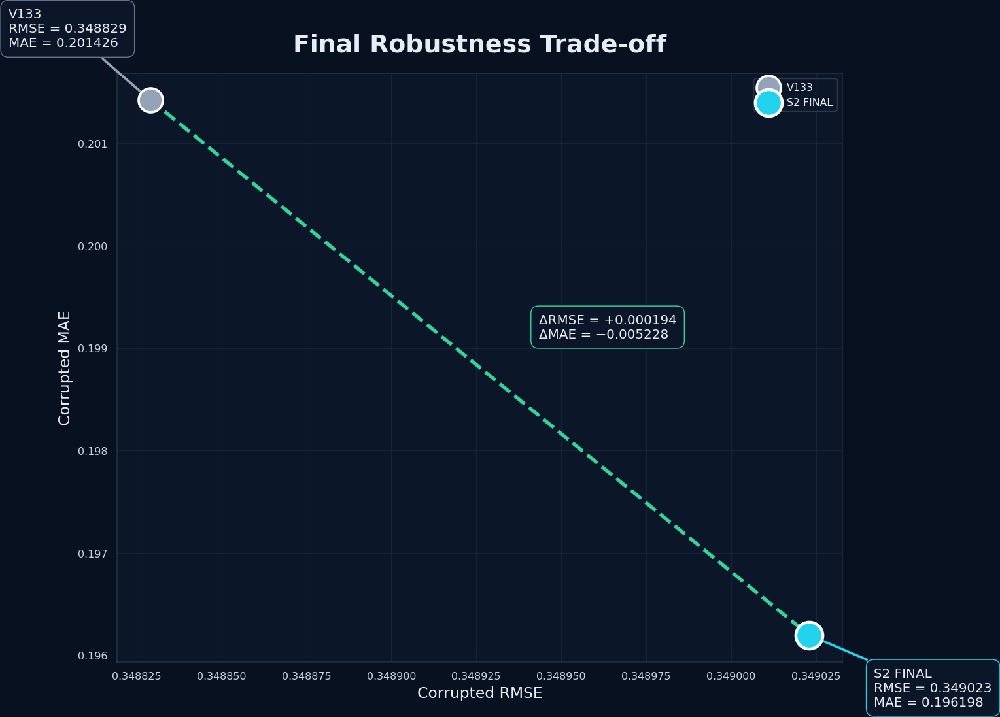

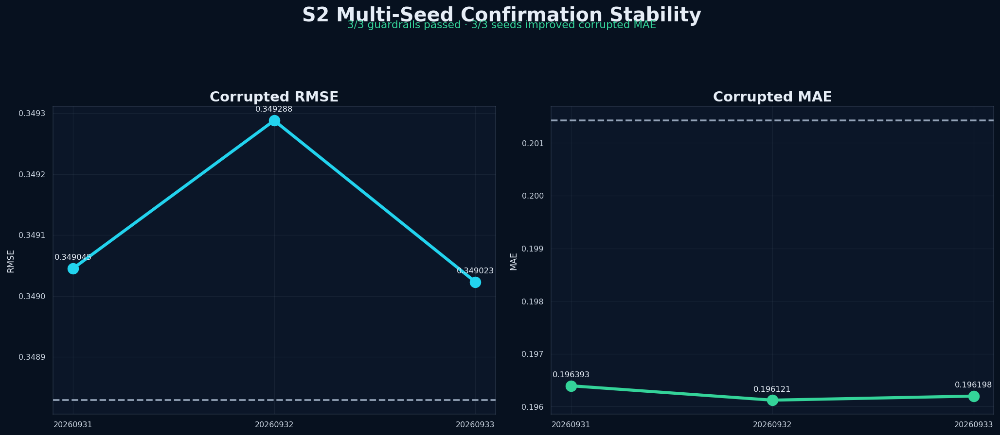

...

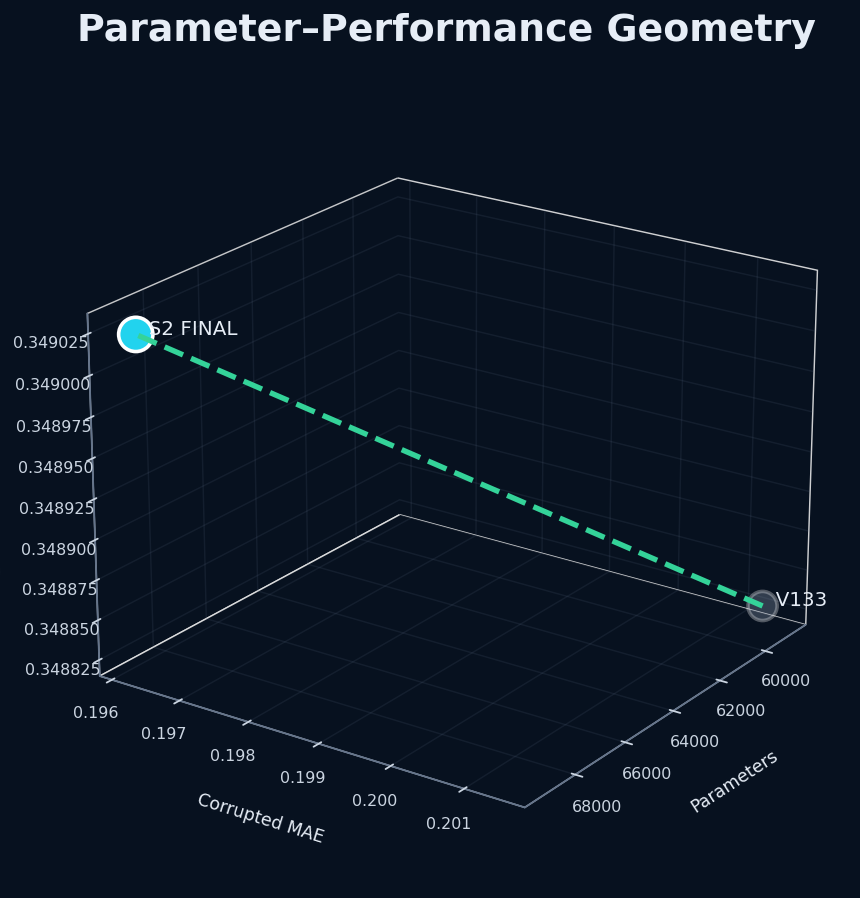

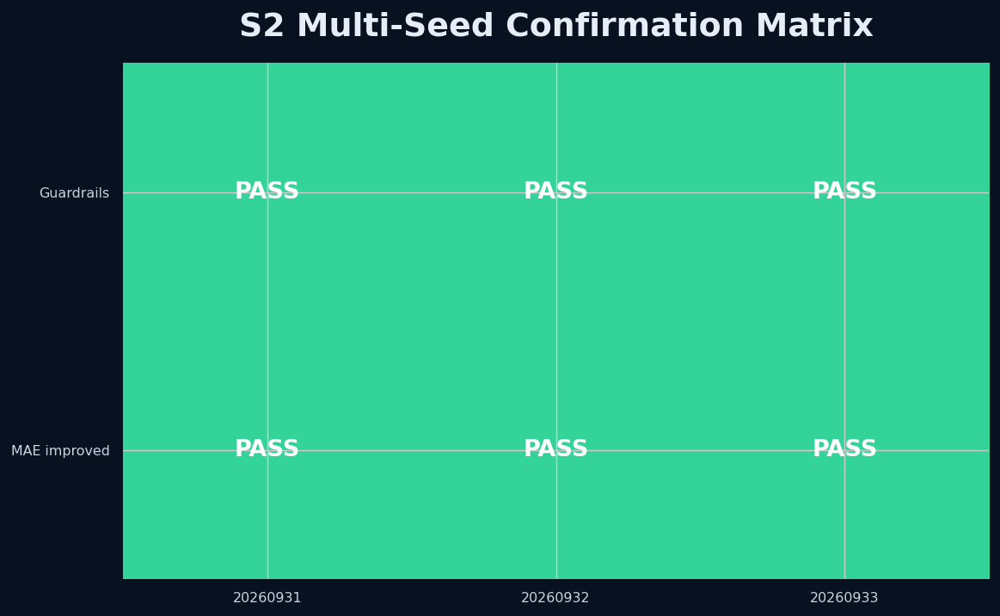

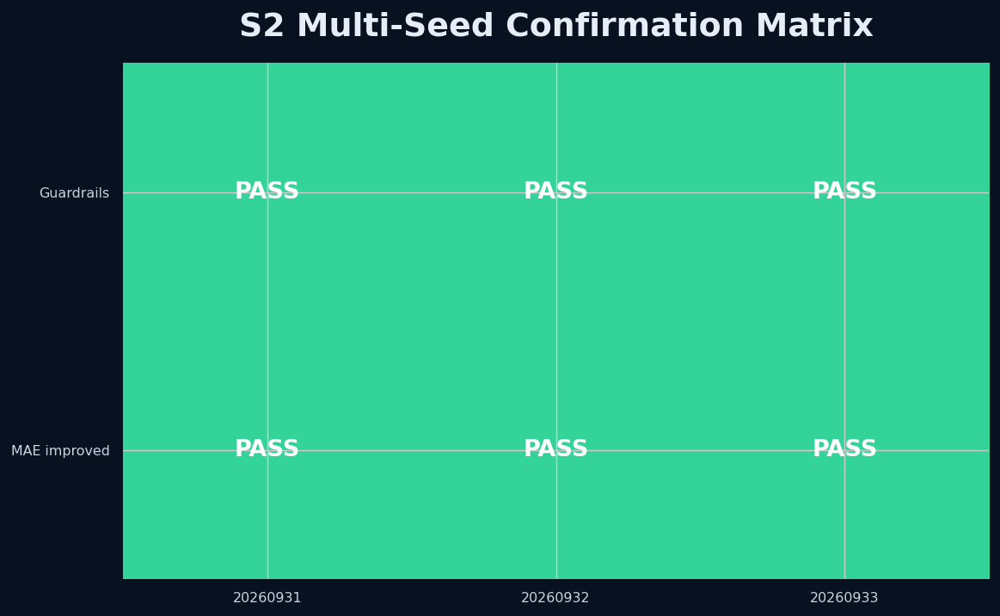

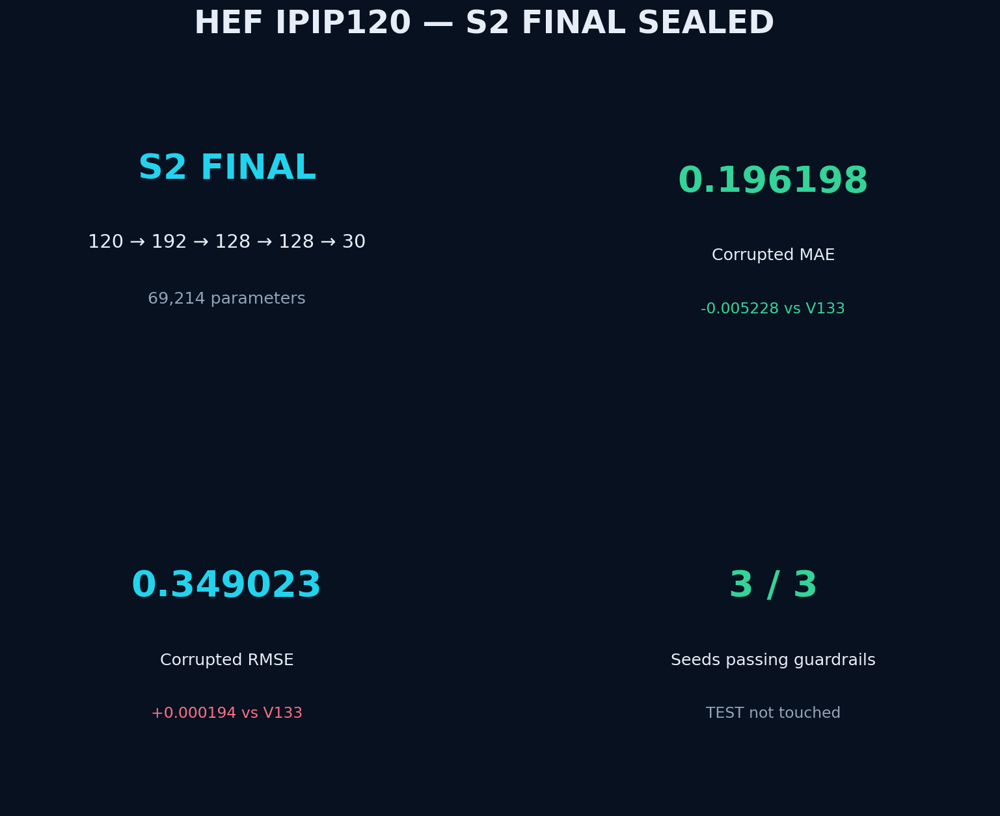

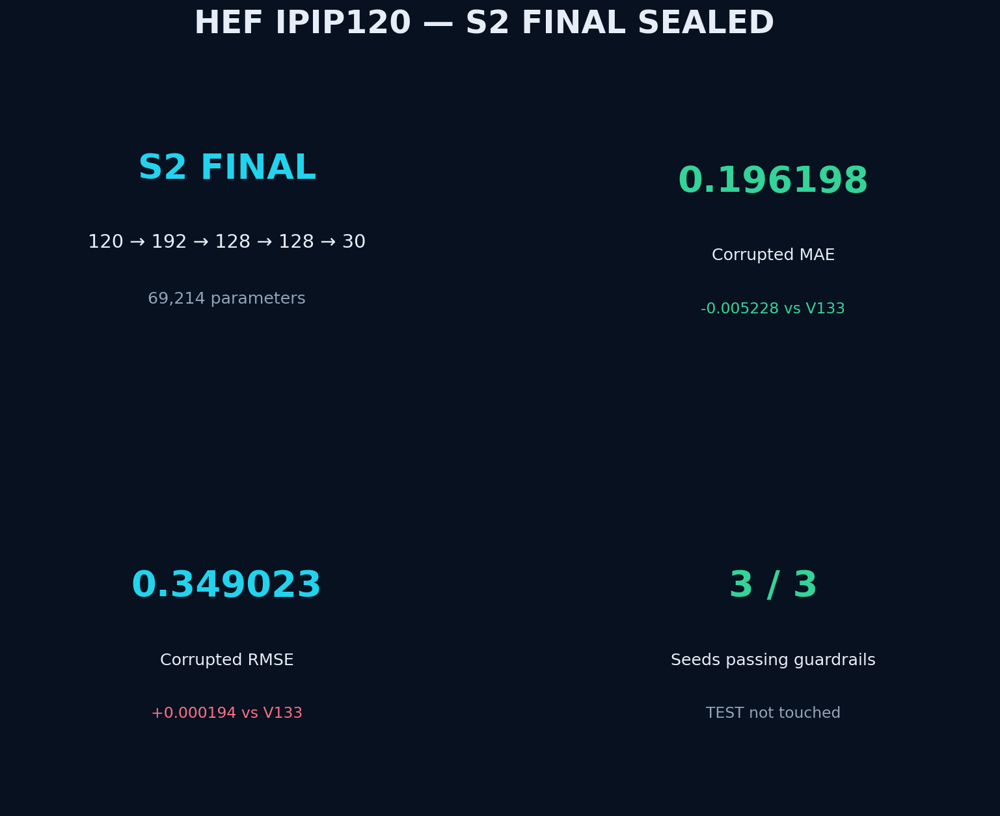


HEF IPIP120 ROBUST — MATLABPLOTLIB FINAL VISUALIZATION
Library            : Matplotlib
Architecture       : 120 -> 192 -> 128 -> 128 -> 30
Seed               : 20260933
Epoch              : 6
Parameters         : 69,214
Corrupted RMSE     : 0.349022974
Corrupted MAE      : 0.196198304
Delta RMSE         : +0.000193974
Delta MAE          : -0.005227696
MAE relative       : -2.595%
Guardrails         : 3/3
MAE improved       : 3/3
TEST               : NOT LOADED / NOT TOUCHED
OUTPUT             : /content/HEF_IPIP120_ROBUST_DATASET_V3/S2_FINAL_SEAL_20260933/FIGURES/FINAL_RESULTS_MATPLOTLIB


In [21]:
%matplotlib inline

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display


ROOT = Path(
    "/content/HEF_IPIP120_ROBUST_DATASET_V3"
)

OUT = (
    ROOT
    / "S2_FINAL_SEAL_20260933"
    / "FIGURES"
    / "FINAL_RESULTS_MATPLOTLIB"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)


plt.rcParams.update({
    "figure.facecolor": "#07111F",
    "axes.facecolor": "#0B1628",
    "axes.edgecolor": "#64748B",
    "axes.labelcolor": "#E6EDF6",
    "xtick.color": "#CBD5E1",
    "ytick.color": "#CBD5E1",
    "text.color": "#E6EDF6",
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titleweight": "bold",
    "savefig.facecolor": "#07111F",
    "savefig.edgecolor": "#07111F",
    "figure.dpi": 130,
    "savefig.dpi": 400
})


V133 = {
    "clean_rmse": 0.123152,
    "clean_mae": 0.080640,
    "clean_pearson": 0.988704,
    "clean_spearman": 0.974316,
    "corrupted_rmse": 0.348829,
    "corrupted_mae": 0.201426,
    "corrupted_pearson": 0.880498,
    "corrupted_spearman": 0.850461,
    "parameters": 58910
}


S2 = {
    "clean_rmse": 0.114294034,
    "clean_mae": 0.072382824,
    "clean_pearson": 0.990228334,
    "clean_spearman": 0.974334361,
    "corrupted_rmse": 0.349022974,
    "corrupted_mae": 0.196198304,
    "corrupted_pearson": 0.880231118,
    "corrupted_spearman": 0.850617515,
    "parameters": 69214
}


SEEDS = np.array([
    [20260931, 6, 0.349045, 0.196393, 0.880235, 0.849576, 0.000216, -0.005033, -0.000263, -0.000885],
    [20260932, 6, 0.349288, 0.196121, 0.880109, 0.849640, 0.000459, -0.005305, -0.000389, -0.000821],
    [20260933, 6, 0.349023, 0.196198, 0.880231, 0.850618, 0.000194, -0.005228, -0.000267, 0.000157]
])


rmse_delta = (
    S2["corrupted_rmse"]
    - V133["corrupted_rmse"]
)

mae_delta = (
    S2["corrupted_mae"]
    - V133["corrupted_mae"]
)

pearson_delta = (
    S2["corrupted_pearson"]
    - V133["corrupted_pearson"]
)

spearman_delta = (
    S2["corrupted_spearman"]
    - V133["corrupted_spearman"]
)


parameter_pct = (
    (S2["parameters"] - V133["parameters"])
    / V133["parameters"]
    * 100
)

mae_pct = (
    mae_delta
    / V133["corrupted_mae"]
    * 100
)

rmse_pct = (
    rmse_delta
    / V133["corrupted_rmse"]
    * 100
)


def save_figure(
    fig,
    name,
    pdf=True,
    svg=True
):

    png_path = OUT / f"{name}.png"

    fig.savefig(
        png_path,
        dpi=400,
        bbox_inches="tight"
    )

    if pdf:

        fig.savefig(
            OUT / f"{name}.pdf",
            bbox_inches="tight"
        )

    if svg:

        fig.savefig(
            OUT / f"{name}.svg",
            bbox_inches="tight"
        )

    display(fig)

    plt.show()

    plt.close(fig)


def style_2d(ax):

    ax.grid(
        True,
        color="#64748B",
        alpha=0.14,
        linewidth=0.7
    )

    for spine in ax.spines.values():
        spine.set_alpha(0.25)


def style_3d(ax):

    ax.set_facecolor(
        "#07111F"
    )

    ax.xaxis.pane.set_facecolor(
        "#07111F"
    )

    ax.yaxis.pane.set_facecolor(
        "#07111F"
    )

    ax.zaxis.pane.set_facecolor(
        "#07111F"
    )

    ax.xaxis.pane.set_alpha(
        0.85
    )

    ax.yaxis.pane.set_alpha(
        0.85
    )

    ax.zaxis.pane.set_alpha(
        0.85
    )

    ax.xaxis._axinfo["grid"]["color"] = (
        0.39,
        0.45,
        0.55,
        0.14
    )

    ax.yaxis._axinfo["grid"]["color"] = (
        0.39,
        0.45,
        0.55,
        0.14
    )

    ax.zaxis._axinfo["grid"]["color"] = (
        0.39,
        0.45,
        0.55,
        0.14
    )


metrics = [
    "RMSE",
    "MAE",
    "Pearson",
    "Spearman"
]


v133_corr = np.array([
    V133["corrupted_rmse"],
    V133["corrupted_mae"],
    V133["corrupted_pearson"],
    V133["corrupted_spearman"]
])


s2_corr = np.array([
    S2["corrupted_rmse"],
    S2["corrupted_mae"],
    S2["corrupted_pearson"],
    S2["corrupted_spearman"]
])


v133_clean = np.array([
    V133["clean_rmse"],
    V133["clean_mae"],
    V133["clean_pearson"],
    V133["clean_spearman"]
])


s2_clean = np.array([
    S2["clean_rmse"],
    S2["clean_mae"],
    S2["clean_pearson"],
    S2["clean_spearman"]
])


fig = plt.figure(
    figsize=(17, 7.5)
)

axes = [
    fig.add_subplot(121),
    fig.add_subplot(122)
]

x = np.arange(
    len(metrics)
)

width = 0.37


axes[0].bar(
    x - width / 2,
    v133_corr,
    width,
    label="V133",
    color="#94A3B8",
    edgecolor="#FFFFFF",
    linewidth=0.6
)


axes[0].bar(
    x + width / 2,
    s2_corr,
    width,
    label="S2",
    color="#22D3EE",
    edgecolor="#FFFFFF",
    linewidth=0.6
)


axes[1].bar(
    x - width / 2,
    v133_clean,
    width,
    label="V133",
    color="#94A3B8",
    edgecolor="#FFFFFF",
    linewidth=0.6
)


axes[1].bar(
    x + width / 2,
    s2_clean,
    width,
    label="S2",
    color="#A78BFA",
    edgecolor="#FFFFFF",
    linewidth=0.6
)


for ax, values_a, values_b in zip(
    axes,
    [v133_corr, v133_clean],
    [s2_corr, s2_clean]
):

    for i in range(
        len(metrics)
    ):

        ax.text(
            i - width / 2,
            values_a[i] + 0.008,
            f"{values_a[i]:.4f}",
            ha="center",
            fontsize=8
        )

        ax.text(
            i + width / 2,
            values_b[i] + 0.008,
            f"{values_b[i]:.4f}",
            ha="center",
            fontsize=8
        )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        metrics
    )

    ax.legend(
        frameon=True,
        facecolor="#0B1628",
        edgecolor="#334155"
    )

    style_2d(
        ax
    )


axes[0].set_title(
    "Corrupted validation",
    pad=14,
    fontsize=15
)


axes[1].set_title(
    "Clean validation",
    pad=14,
    fontsize=15
)


fig.suptitle(
    "HEF IPIP120 — Final S2 Performance",
    fontsize=22,
    fontweight="bold",
    y=1.02
)


fig.text(
    0.5,
    0.965,
    "120 → 192 → 128 → 128 → 30   |   69,214 parameters   |   seed 20260933",
    ha="center",
    fontsize=11,
    color="#94A3B8"
)


fig.tight_layout()


save_figure(
    fig,
    "FIG01_FINAL_PERFORMANCE"
)


fig, ax = plt.subplots(
    figsize=(11, 9)
)


ax.scatter(
    V133["corrupted_rmse"],
    V133["corrupted_mae"],
    s=420,
    color="#94A3B8",
    edgecolor="white",
    linewidth=2,
    label="V133",
    zorder=5
)


ax.scatter(
    S2["corrupted_rmse"],
    S2["corrupted_mae"],
    s=520,
    color="#22D3EE",
    edgecolor="white",
    linewidth=2.5,
    label="S2 FINAL",
    zorder=5
)


ax.annotate(
    "V133\nRMSE = 0.348829\nMAE = 0.201426",
    (
        V133["corrupted_rmse"],
        V133["corrupted_mae"]
    ),
    xytext=(-120, 45),
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->",
        color="#94A3B8",
        linewidth=2
    ),
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#0B1628",
        edgecolor="#64748B"
    )
)


ax.annotate(
    "S2 FINAL\nRMSE = 0.349023\nMAE = 0.196198",
    (
        S2["corrupted_rmse"],
        S2["corrupted_mae"]
    ),
    xytext=(55, -60),
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->",
        color="#22D3EE",
        linewidth=2
    ),
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#0B1628",
        edgecolor="#22D3EE"
    )
)


ax.plot(
    [
        V133["corrupted_rmse"],
        S2["corrupted_rmse"]
    ],
    [
        V133["corrupted_mae"],
        S2["corrupted_mae"]
    ],
    linestyle="--",
    linewidth=3,
    color="#34D399"
)


mid_x = (
    V133["corrupted_rmse"]
    + S2["corrupted_rmse"]
) / 2


mid_y = (
    V133["corrupted_mae"]
    + S2["corrupted_mae"]
) / 2


ax.annotate(
    "ΔRMSE = +0.000194\nΔMAE = −0.005228",
    (
        mid_x,
        mid_y
    ),
    xytext=(50, 25),
    textcoords="offset points",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#0B1628",
        edgecolor="#34D399"
    ),
    color="#E6EDF6",
    fontsize=11
)


ax.set_xlabel(
    "Corrupted RMSE",
    fontsize=13
)


ax.set_ylabel(
    "Corrupted MAE",
    fontsize=13
)


ax.set_title(
    "Final Robustness Trade-off",
    fontsize=21,
    pad=18
)


style_2d(
    ax
)


ax.legend(
    frameon=True,
    facecolor="#0B1628",
    edgecolor="#334155"
)


save_figure(
    fig,
    "FIG02_RMSE_MAE_TRADEOFF"
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)


seed_labels = [
    "20260931",
    "20260932",
    "20260933"
]


rmse = SEEDS[:, 2]
mae = SEEDS[:, 3]


axes[0].plot(
    seed_labels,
    rmse,
    marker="o",
    markersize=12,
    linewidth=3.5,
    color="#22D3EE"
)


axes[0].axhline(
    V133["corrupted_rmse"],
    linestyle="--",
    color="#94A3B8",
    linewidth=2
)


axes[0].set_title(
    "Corrupted RMSE",
    fontsize=16
)


axes[0].set_ylabel(
    "RMSE"
)


axes[1].plot(
    seed_labels,
    mae,
    marker="o",
    markersize=12,
    linewidth=3.5,
    color="#34D399"
)


axes[1].axhline(
    V133["corrupted_mae"],
    linestyle="--",
    color="#94A3B8",
    linewidth=2
)


axes[1].set_title(
    "Corrupted MAE",
    fontsize=16
)


axes[1].set_ylabel(
    "MAE"
)


for ax in axes:

    style_2d(
        ax
    )


    values = (
        rmse
        if ax is axes[0]
        else mae
    )


    for i, value in enumerate(
        values
    ):

        ax.annotate(
            f"{value:.6f}",
            (
                i,
                value
            ),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )


fig.suptitle(
    "S2 Multi-Seed Confirmation Stability",
    fontsize=22,
    fontweight="bold"
)


fig.text(
    0.5,
    0.93,
    "3/3 guardrails passed · 3/3 seeds improved corrupted MAE",
    ha="center",
    color="#34D399",
    fontsize=12
)


fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.88
    ]
)


save_figure(
    fig,
    "FIG03_MULTI_SEED_STABILITY"
)


fig = plt.figure(
    figsize=(12, 10)
)


ax = fig.add_subplot(
    111,
    projection="3d"
)


style_3d(
    ax
)


points = np.array([
    [
        V133["corrupted_rmse"],
        V133["corrupted_mae"],
        V133["corrupted_pearson"]
    ],
    [
        SEEDS[0, 2],
        SEEDS[0, 3],
        SEEDS[0, 4]
    ],
    [
        SEEDS[1, 2],
        SEEDS[1, 3],
        SEEDS[1, 4]
    ],
    [
        SEEDS[2, 2],
        SEEDS[2, 3],
        SEEDS[2, 4]
    ]
])


labels = [
    "V133",
    "S2 · 20260931",
    "S2 · 20260932",
    "S2 · 20260933"
]


colors = [
    "#94A3B8",
    "#60A5FA",
    "#A78BFA",
    "#22D3EE"
]


sizes = [
    170,
    100,
    100,
    170
]


for i in range(
    len(points)
):

    ax.scatter(
        points[i, 0],
        points[i, 1],
        points[i, 2],
        s=sizes[i],
        color=colors[i],
        edgecolors="white",
        linewidths=1.5,
        depthshade=True
    )


    ax.text(
        points[i, 0],
        points[i, 1],
        points[i, 2],
        "  " + labels[i],
        fontsize=10
    )


centroid = np.mean(
    points[1:],
    axis=0
)


ax.scatter(
    centroid[0],
    centroid[1],
    centroid[2],
    s=220,
    marker="D",
    color="#34D399",
    edgecolors="white",
    linewidths=2,
    label="S2 seed centroid"
)


ax.set_xlabel(
    "Corrupted RMSE",
    labelpad=12
)


ax.set_ylabel(
    "Corrupted MAE",
    labelpad=12
)


ax.set_zlabel(
    "Corrupted Pearson",
    labelpad=12
)


ax.set_title(
    "S2 Confirmation Metric Manifold",
    fontsize=21,
    pad=24,
    fontweight="bold"
)


ax.view_init(
    elev=25,
    azim=38
)


ax.legend(
    loc="upper left"
)


save_figure(
    fig,
    "FIG04_3D_CONFIRMATION_MANIFOLD"
)


fig, ax = plt.subplots(
    figsize=(11, 8)
)


delta_names = [
    "RMSE",
    "MAE",
    "Pearson",
    "Spearman"
]


delta_values = np.array([
    rmse_delta,
    mae_delta,
    pearson_delta,
    spearman_delta
])


delta_colors = [
    "#FB7185",
    "#34D399",
    "#FB7185",
    "#34D399"
]


bars = ax.bar(
    delta_names,
    delta_values,
    color=delta_colors,
    edgecolor="white",
    linewidth=0.7,
    width=0.65
)


ax.axhline(
    0,
    color="white",
    linewidth=1.4
)


for bar, value in zip(
    bars,
    delta_values
):

    y = bar.get_height()


    offset = (
        0.00025
        if y >= 0
        else -0.00055
    )


    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        y + offset,
        f"{value:+.6f}",
        ha="center",
        va="bottom"
        if y >= 0
        else "top",
        fontsize=11,
        fontweight="bold"
    )


ax.set_ylabel(
    "S2 − V133",
    fontsize=13
)


ax.set_title(
    "Final Metric Deltas",
    fontsize=21,
    pad=18
)


style_2d(
    ax
)


save_figure(
    fig,
    "FIG05_FINAL_DELTAS"
)


fig, ax = plt.subplots(
    figsize=(12, 8)
)


screening = np.array([
    -0.000466636,
    -0.005186471,
    0.000144254,
    -0.000340258
])


confirmation = np.array([
    rmse_delta,
    mae_delta,
    pearson_delta,
    spearman_delta
])


positions = np.arange(
    len(metrics)
)


width = 0.36


ax.bar(
    positions - width / 2,
    screening,
    width,
    label="Screening",
    color="#60A5FA",
    edgecolor="white"
)


ax.bar(
    positions + width / 2,
    confirmation,
    width,
    label="Final confirmation",
    color="#22D3EE",
    edgecolor="white"
)


ax.axhline(
    0,
    color="white",
    linewidth=1.5
)


ax.set_xticks(
    positions
)


ax.set_xticklabels(
    metrics
)


ax.set_ylabel(
    "Delta relative to V133"
)


ax.set_title(
    "Architecture Screening → Final Confirmation",
    fontsize=21,
    pad=18
)


ax.legend(
    frameon=True,
    facecolor="#0B1628",
    edgecolor="#334155"
)


style_2d(
    ax
)


save_figure(
    fig,
    "FIG06_SCREENING_TO_CONFIRMATION"
)


fig, ax = plt.subplots(
    figsize=(11, 8)
)


categories = [
    "Clean",
    "Corrupted"
]


x = np.arange(
    2
)


v133_values = [
    V133["clean_rmse"],
    V133["corrupted_rmse"]
]


s2_values = [
    S2["clean_rmse"],
    S2["corrupted_rmse"]
]


ax.plot(
    x,
    v133_values,
    marker="o",
    markersize=14,
    linewidth=4,
    color="#94A3B8",
    label="V133"
)


ax.plot(
    x,
    s2_values,
    marker="o",
    markersize=16,
    linewidth=4,
    color="#22D3EE",
    label="S2"
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    categories
)


ax.set_ylabel(
    "RMSE"
)


ax.set_title(
    "Clean-to-Corrupted RMSE Transition",
    fontsize=21,
    pad=18
)


ax.legend(
    frameon=True,
    facecolor="#0B1628",
    edgecolor="#334155"
)


style_2d(
    ax
)


save_figure(
    fig,
    "FIG07_CLEAN_CORRUPTED_RMSE"
)


fig = plt.figure(
    figsize=(11, 8)
)


ax = fig.add_subplot(
    111,
    projection="3d"
)


style_3d(
    ax
)


parameters = np.array([
    V133["parameters"],
    S2["parameters"]
])


mae = np.array([
    V133["corrupted_mae"],
    S2["corrupted_mae"]
])


rmse = np.array([
    V133["corrupted_rmse"],
    S2["corrupted_rmse"]
])


ax.scatter(
    parameters,
    mae,
    rmse,
    s=[
        260,
        360
    ],
    c=[
        "#94A3B8",
        "#22D3EE"
    ],
    edgecolors="white",
    linewidths=2,
    depthshade=True
)


for i, label in enumerate(
    ["V133", "S2 FINAL"]
):

    ax.text(
        parameters[i],
        mae[i],
        rmse[i],
        "  " + label,
        fontsize=11
    )


ax.plot(
    parameters,
    mae,
    rmse,
    "--",
    color="#34D399",
    linewidth=3
)


ax.set_xlabel(
    "Parameters",
    labelpad=12
)


ax.set_ylabel(
    "Corrupted MAE",
    labelpad=12
)


ax.set_zlabel(
    "Corrupted RMSE",
    labelpad=12
)


ax.set_title(
    "Parameter–Performance Geometry",
    fontsize=21,
    pad=24,
    fontweight="bold"
)


ax.view_init(
    elev=22,
    azim=35
)


save_figure(
    fig,
    "FIG08_PARAMETER_PERFORMANCE_3D"
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


matrix = np.ones(
    (
        2,
        3
    )
)


im = ax.imshow(
    matrix,
    cmap=LinearSegmentedColormap.from_list(
        "pass",
        [
            "#123A30",
            "#34D399"
        ]
    ),
    vmin=0,
    vmax=1,
    aspect="auto"
)


ax.set_xticks(
    [0, 1, 2]
)


ax.set_xticklabels(
    [
        "20260931",
        "20260932",
        "20260933"
    ]
)


ax.set_yticks(
    [0, 1]
)


ax.set_yticklabels(
    [
        "Guardrails",
        "MAE improved"
    ]
)


for i in range(2):

    for j in range(3):

        ax.text(
            j,
            i,
            "PASS",
            ha="center",
            va="center",
            fontsize=15,
            fontweight="bold",
            color="white"
        )


ax.set_title(
    "S2 Multi-Seed Confirmation Matrix",
    fontsize=21,
    pad=18
)


for spine in ax.spines.values():
    spine.set_visible(False)


save_figure(
    fig,
    "FIG09_CONFIRMATION_MATRIX"
)


fig = plt.figure(
    figsize=(15, 11)
)


grid = fig.add_gridspec(
    2,
    2,
    hspace=0.30,
    wspace=0.25
)


ax1 = fig.add_subplot(
    grid[0, 0]
)


ax1.axis(
    "off"
)


ax1.text(
    0.5,
    0.72,
    "S2 FINAL",
    ha="center",
    fontsize=30,
    fontweight="bold",
    color="#22D3EE"
)


ax1.text(
    0.5,
    0.50,
    "120 → 192 → 128 → 128 → 30",
    ha="center",
    fontsize=16
)


ax1.text(
    0.5,
    0.32,
    "69,214 parameters",
    ha="center",
    fontsize=14,
    color="#94A3B8"
)


ax2 = fig.add_subplot(
    grid[0, 1]
)


ax2.axis(
    "off"
)


ax2.text(
    0.5,
    0.68,
    f"{S2['corrupted_mae']:.6f}",
    ha="center",
    fontsize=31,
    fontweight="bold",
    color="#34D399"
)


ax2.text(
    0.5,
    0.46,
    "Corrupted MAE",
    ha="center",
    fontsize=14
)


ax2.text(
    0.5,
    0.29,
    f"{mae_delta:+.6f} vs V133",
    ha="center",
    fontsize=13,
    color="#34D399"
)


ax3 = fig.add_subplot(
    grid[1, 0]
)


ax3.axis(
    "off"
)


ax3.text(
    0.5,
    0.68,
    f"{S2['corrupted_rmse']:.6f}",
    ha="center",
    fontsize=31,
    fontweight="bold",
    color="#22D3EE"
)


ax3.text(
    0.5,
    0.46,
    "Corrupted RMSE",
    ha="center",
    fontsize=14
)


ax3.text(
    0.5,
    0.29,
    f"{rmse_delta:+.6f} vs V133",
    ha="center",
    fontsize=13,
    color="#FB7185"
)


ax4 = fig.add_subplot(
    grid[1, 1]
)


ax4.axis(
    "off"
)


ax4.text(
    0.5,
    0.68,
    "3 / 3",
    ha="center",
    fontsize=31,
    fontweight="bold",
    color="#34D399"
)


ax4.text(
    0.5,
    0.46,
    "Seeds passing guardrails",
    ha="center",
    fontsize=14
)


ax4.text(
    0.5,
    0.29,
    "TEST not touched",
    ha="center",
    fontsize=13,
    color="#94A3B8"
)


fig.suptitle(
    "HEF IPIP120 — S2 FINAL SEALED",
    fontsize=27,
    fontweight="bold",
    y=0.97
)


save_figure(
    fig,
    "FIG10_FINAL_DASHBOARD"
)


summary = {
    "library": "Matplotlib",
    "architecture": "120 -> 192 -> 128 -> 128 -> 30",
    "seed": 20260933,
    "epoch": 6,
    "parameters": 69214,
    "status": "S2_FINAL_CONFIRMED",
    "confirmation": {
        "guardrails_passed": "3/3",
        "mae_improved": "3/3"
    },
    "corrupted_validation": {
        "rmse": S2["corrupted_rmse"],
        "mae": S2["corrupted_mae"],
        "pearson": S2["corrupted_pearson"],
        "spearman": S2["corrupted_spearman"]
    },
    "delta_vs_v133": {
        "rmse": rmse_delta,
        "mae": mae_delta,
        "pearson": pearson_delta,
        "spearman": spearman_delta
    },
    "relative_change_percent": {
        "rmse": rmse_pct,
        "mae": mae_pct,
        "parameters": parameter_pct
    },
    "test_loaded": False,
    "test_touched": False
}


with open(
    OUT / "FINAL_RESULTS_MATPLOTLIB_SUMMARY.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


print()
print("=" * 110)
print("HEF IPIP120 ROBUST — MATLABPLOTLIB FINAL VISUALIZATION")
print("=" * 110)
print("Library            : Matplotlib")
print("Architecture       : 120 -> 192 -> 128 -> 128 -> 30")
print("Seed               : 20260933")
print("Epoch              : 6")
print("Parameters         : 69,214")
print(f"Corrupted RMSE     : {S2['corrupted_rmse']:.9f}")
print(f"Corrupted MAE      : {S2['corrupted_mae']:.9f}")
print(f"Delta RMSE         : {rmse_delta:+.9f}")
print(f"Delta MAE          : {mae_delta:+.9f}")
print(f"MAE relative       : {mae_pct:+.3f}%")
print("Guardrails         : 3/3")
print("MAE improved       : 3/3")
print("TEST               : NOT LOADED / NOT TOUCHED")
print(f"OUTPUT             : {OUT}")
print("=" * 110)

In [24]:
import gc
import json
import math
import time
import hashlib
import tempfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm


ROOT = Path(
    "/content/HEF_IPIP120_ROBUST_DATASET_V3"
)

TEST_DIR = Path(
    "/content/HEF_IPIP120_TEST_FROZEN"
)

EXPECTED_CHECKPOINT_SHA256 = (
    "679c88d15552ee6efaf78cb0b3e288c09b3f00af53cf6d4100807830323e6992"
)

PRIMARY_CHECKPOINT = (
    ROOT
    / "V133_INTERNAL_TUNING_V1"
    / "winner_full_validation.pt"
)

CHECKPOINT_ALTERNATIVES = [
    ROOT
    / "S2_FINAL_SEAL_20260933"
    / "winner_full_validation.pt",

    ROOT
    / "S2_FINAL_SEAL_20260933"
    / "HEF_IPIP120_S2_PRODUCTION_seed20260933.pt",

    Path(
        "/content/HEF_IPIP120_S2_PRODUCTION_seed20260933.pt"
    ),

    Path(
        "/content/gdrive/MyDrive/HEF_MODELS/"
        "HEF_IPIP120_S2_PRODUCTION/"
        "HEF_IPIP120_S2_PRODUCTION_seed20260933.pt"
    ),

    Path(
        "/content/drive/MyDrive/HEF_MODELS/"
        "HEF_IPIP120_S2_PRODUCTION/"
        "HEF_IPIP120_S2_PRODUCTION_seed20260933.pt"
    ),
]

INPUT_DIM = 120
OUTPUT_DIM = 30
EXPECTED_PARAMETERS = 69_214

EXPECTED_TEST_CLEAN = 61_557
EXPECTED_TEST_CORRUPTED = 1_723_596
EXPECTED_TEST_TOTAL = 1_785_153

CORRUPTION_TYPES = [
    "ITEM_SWAP",
    "FACET_SWAP",
    "CATEGORY_PARTIAL_SWAP",
    "CATEGORY_SWAP",
    "ITEM_COLLAPSE",
    "CATEGORY_COLLAPSE",
    "RANDOM_ITEM_CHANGE",
]

TEST_LEVELS = [
    "LOW",
    "MEDIUM",
    "HIGH",
    "EXTREME",
]

INFERENCE_BATCH_SIZE = 65_536

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

if DEVICE.type == "cuda":
    torch.set_float32_matmul_precision("high")


if "calculate_gold" not in globals():
    raise RuntimeError(
        "calculate_gold no está cargado en el kernel."
    )


def sha256_file(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as f:

        for block in iter(
            lambda: f.read(8 * 1024 * 1024),
            b""
        ):

            h.update(
                block
            )

    return h.hexdigest()


def locate_checkpoint():

    candidates = []

    if PRIMARY_CHECKPOINT.exists():
        candidates.append(
            PRIMARY_CHECKPOINT
        )

    candidates.extend(
        CHECKPOINT_ALTERNATIVES
    )

    seen = set()

    for path in candidates:

        if not path.exists():
            continue

        path = path.resolve()

        if path in seen:
            continue

        seen.add(
            path
        )

        try:

            digest = sha256_file(
                path
            )

        except Exception:

            continue

        if digest == EXPECTED_CHECKPOINT_SHA256:
            return path


    search_roots = [
        ROOT,
        Path(
            "/content/gdrive/MyDrive/HEF_MODELS"
        ),
        Path(
            "/content/drive/MyDrive/HEF_MODELS"
        ),
    ]

    for search_root in search_roots:

        if not search_root.exists():
            continue

        try:

            for path in search_root.rglob(
                "*.pt"
            ):

                path = path.resolve()

                if path in seen:
                    continue

                seen.add(
                    path
                )

                try:

                    digest = sha256_file(
                        path
                    )

                except Exception:

                    continue

                if digest == EXPECTED_CHECKPOINT_SHA256:
                    return path

        except Exception:

            continue


    raise FileNotFoundError(
        "No se encontró un checkpoint S2 con el SHA-256 esperado."
    )


CHECKPOINT_PATH = locate_checkpoint()


if not TEST_DIR.exists():
    raise FileNotFoundError(
        f"No existe TEST congelado: {TEST_DIR}"
    )


CLEAN_DIR = (
    TEST_DIR
    /
    "CLEAN"
)

PROGRESSIVE_DIR = (
    TEST_DIR
    /
    "PROGRESSIVE"
)

if not CLEAN_DIR.exists():
    raise FileNotFoundError(
        CLEAN_DIR
    )

if not PROGRESSIVE_DIR.exists():
    raise FileNotFoundError(
        PROGRESSIVE_DIR
    )


actual_checkpoint_sha256 = sha256_file(
    CHECKPOINT_PATH
)

if actual_checkpoint_sha256 != EXPECTED_CHECKPOINT_SHA256:
    raise RuntimeError(
        "SHA-256 del checkpoint no coincide."
    )


class HEFIPIP120S2(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(
            120,
            192
        )

        self.ln1 = nn.LayerNorm(
            192
        )

        self.fc2 = nn.Linear(
            192,
            128
        )

        self.ln2 = nn.LayerNorm(
            128
        )

        self.fc3 = nn.Linear(
            128,
            128
        )

        self.ln3 = nn.LayerNorm(
            128
        )

        self.output = nn.Linear(
            128,
            30
        )

        self.dropout = nn.Dropout(
            0.10
        )

    def forward(
        self,
        x
    ):

        x = (
            x - 3.0
        ) / 2.0

        x = self.fc1(
            x
        )

        x = self.ln1(
            x
        )

        x = F.gelu(
            x
        )

        x = self.dropout(
            x
        )

        x = self.fc2(
            x
        )

        x = self.ln2(
            x
        )

        x = F.gelu(
            x
        )

        x = self.dropout(
            x
        )

        x = self.fc3(
            x
        )

        x = self.ln3(
            x
        )

        x = F.gelu(
            x
        )

        x = self.dropout(
            x
        )

        x = self.output(
            x
        )

        return x


try:

    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location="cpu",
        weights_only=False
    )

except TypeError:

    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location="cpu"
    )


if not isinstance(
    checkpoint,
    dict
):

    raise RuntimeError(
        "Formato de checkpoint inesperado."
    )


if "state_dict" in checkpoint:

    state_dict = (
        checkpoint["state_dict"]
    )

elif "model_state_dict" in checkpoint:

    state_dict = (
        checkpoint["model_state_dict"]
    )

else:

    raise KeyError(
        "No existe state_dict en el checkpoint S2."
    )


model = HEFIPIP120S2()


parameter_count = sum(
    p.numel()
    for p in model.parameters()
)

if parameter_count != EXPECTED_PARAMETERS:

    raise RuntimeError(
        f"Parameter count inválido: "
        f"{parameter_count} != {EXPECTED_PARAMETERS}"
    )


model.load_state_dict(
    state_dict,
    strict=True
)

model = model.to(
    DEVICE
)

model.eval()


@torch.inference_mode()
def predict_numpy(
    X
):

    X = np.asarray(
        X,
        dtype=np.float32
    )

    output = np.empty(
        (
            len(X),
            OUTPUT_DIM
        ),
        dtype=np.float32
    )

    tensor_x = torch.from_numpy(
        X
    )

    for start in range(
        0,
        len(X),
        INFERENCE_BATCH_SIZE
    ):

        end = min(
            start
            +
            INFERENCE_BATCH_SIZE,
            len(X)
        )

        batch = (
            tensor_x[start:end]
            .to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True
            )
        )

        prediction = model(
            batch
        )

        output[
            start:end
        ] = (
            prediction
            .detach()
            .float()
            .cpu()
            .numpy()
        )

    return output


class MetricAccumulator:

    def __init__(self):

        self.n = 0

        self.sse = 0.0
        self.sae = 0.0

        self.sum_true = 0.0
        self.sum_pred = 0.0

        self.sum_true2 = 0.0
        self.sum_pred2 = 0.0

        self.sum_true_pred = 0.0

    def update(
        self,
        y_true,
        y_pred
    ):

        yt = np.asarray(
            y_true,
            dtype=np.float64
        ).reshape(-1)

        yp = np.asarray(
            y_pred,
            dtype=np.float64
        ).reshape(-1)

        if yt.shape != yp.shape:

            raise RuntimeError(
                "Metric shape mismatch."
            )

        diff = (
            yp - yt
        )

        self.n += len(
            yt
        )

        self.sse += float(
            np.dot(
                diff,
                diff
            )
        )

        self.sae += float(
            np.abs(
                diff
            ).sum()
        )

        self.sum_true += float(
            yt.sum()
        )

        self.sum_pred += float(
            yp.sum()
        )

        self.sum_true2 += float(
            np.dot(
                yt,
                yt
            )
        )

        self.sum_pred2 += float(
            np.dot(
                yp,
                yp
            )
        )

        self.sum_true_pred += float(
            np.dot(
                yt,
                yp
            )
        )

    def bundle(self):

        n = float(
            self.n
        )

        rmse = math.sqrt(
            max(
                self.sse / n,
                0.0
            )
        )

        mae = (
            self.sae
            /
            n
        )

        cov_num = (
            self.sum_true_pred
            -
            (
                self.sum_true
                *
                self.sum_pred
                /
                n
            )
        )

        var_true = (
            self.sum_true2
            -
            (
                self.sum_true
                *
                self.sum_true
                /
                n
            )
        )

        var_pred = (
            self.sum_pred2
            -
            (
                self.sum_pred
                *
                self.sum_pred
                /
                n
            )
        )

        denominator = math.sqrt(
            max(
                var_true
                *
                var_pred,
                0.0
            )
        )

        pearson = (
            cov_num
            /
            denominator
            if denominator != 0.0
            else float("nan")
        )

        return {
            "rmse": float(
                rmse
            ),
            "mae": float(
                mae
            ),
            "pearson": float(
                pearson
            )
        }


def exact_stable_spearman_small(
    y_true,
    y_pred
):

    yt = np.asarray(
        y_true
    ).reshape(-1)

    yp = np.asarray(
        y_pred
    ).reshape(-1)

    order_t = np.argsort(
        yt,
        kind="mergesort"
    )

    order_p = np.argsort(
        yp,
        kind="mergesort"
    )

    ranks_t = np.empty(
        len(yt),
        dtype=np.float64
    )

    ranks_p = np.empty(
        len(yp),
        dtype=np.float64
    )

    ranks_t[
        order_t
    ] = np.arange(
        1,
        len(yt) + 1,
        dtype=np.float64
    )

    ranks_p[
        order_p
    ] = np.arange(
        1,
        len(yp) + 1,
        dtype=np.float64
    )

    ranks_t -= (
        ranks_t.mean()
    )

    ranks_p -= (
        ranks_p.mean()
    )

    denominator = math.sqrt(
        np.dot(
            ranks_t,
            ranks_t
        )
        *
        np.dot(
            ranks_p,
            ranks_p
        )
    )

    return float(
        np.dot(
            ranks_t,
            ranks_p
        )
        /
        denominator
    )


def discover_shards(
    directory,
    stem
):

    paths = sorted(
        directory.glob(
            f"shard_*_{stem}.npy"
        )
    )

    if not paths:

        paths = sorted(
            directory.glob(
                f"*_{stem}.npy"
            )
        )

    if not paths:

        raise FileNotFoundError(
            f"No {stem} shards in {directory}"
        )

    return paths


def load_clean_test():

    x_paths = discover_shards(
        CLEAN_DIR,
        "X"
    )

    y_paths = discover_shards(
        CLEAN_DIR,
        "Y"
    )

    target_paths = discover_shards(
        CLEAN_DIR,
        "target"
    )

    X = np.concatenate(
        [
            np.load(
                p,
                allow_pickle=False
            )
            for p in x_paths
        ],
        axis=0
    )

    Y = np.concatenate(
        [
            np.load(
                p,
                allow_pickle=False
            )
            for p in y_paths
        ],
        axis=0
    )

    targets = np.concatenate(
        [
            np.load(
                p,
                allow_pickle=False
            )
            for p in target_paths
        ],
        axis=0
    )

    if len(X) != EXPECTED_TEST_CLEAN:

        raise RuntimeError(
            f"CLEAN rows: "
            f"{len(X)} != {EXPECTED_TEST_CLEAN}"
        )

    if X.shape != (
        EXPECTED_TEST_CLEAN,
        INPUT_DIM
    ):

        raise RuntimeError(
            f"CLEAN X shape: {X.shape}"
        )

    if Y.shape != (
        EXPECTED_TEST_CLEAN,
        OUTPUT_DIM
    ):

        raise RuntimeError(
            f"CLEAN Y shape: {Y.shape}"
        )

    if np.unique(
        targets
    ).size != EXPECTED_TEST_CLEAN:

        raise RuntimeError(
            "CLEAN target IDs duplicados."
        )

    return X, Y, targets


def build_gold_rank_memmap(
    output_path,
    total_values
):

    rank_true = np.memmap(
        output_path,
        mode="w+",
        dtype=np.int64,
        shape=(total_values,)
    )

    counts = np.zeros(
        21,
        dtype=np.int64
    )

    for family in CORRUPTION_TYPES:

        for level in TEST_LEVELS:

            level_dir = (
                PROGRESSIVE_DIR
                /
                family
                /
                level
            )

            y_paths = discover_shards(
                level_dir,
                "Y"
            )

            for path in y_paths:

                y = np.load(
                    path,
                    mmap_mode="r",
                    allow_pickle=False
                )

                codes = np.rint(
                    np.asarray(
                        y
                    ).reshape(-1)
                    *
                    4.0
                ).astype(
                    np.int16,
                    copy=False
                )

                counts += np.bincount(
                    codes,
                    minlength=21
                )

    less = (
        np.cumsum(counts)
        -
        counts
    )

    seen = np.zeros(
        21,
        dtype=np.int64
    )

    offset = 0

    for family in CORRUPTION_TYPES:

        for level in TEST_LEVELS:

            level_dir = (
                PROGRESSIVE_DIR
                /
                family
                /
                level
            )

            y_paths = discover_shards(
                level_dir,
                "Y"
            )

            for path in y_paths:

                y = np.load(
                    path,
                    mmap_mode="r",
                    allow_pickle=False
                )

                codes = np.rint(
                    np.asarray(
                        y
                    ).reshape(-1)
                    *
                    4.0
                ).astype(
                    np.int16,
                    copy=False
                )

                ranks = np.empty(
                    len(codes),
                    dtype=np.int64
                )

                for value in range(
                    21
                ):

                    idx = np.flatnonzero(
                        codes == value
                    )

                    if idx.size:

                        base = (
                            int(
                                less[value]
                            )
                            +
                            int(
                                seen[value]
                            )
                        )

                        ranks[idx] = (
                            base
                            +
                            np.arange(
                                1,
                                idx.size + 1,
                                dtype=np.int64
                            )
                        )

                        seen[value] += idx.size

                end = (
                    offset
                    +
                    len(ranks)
                )

                rank_true[
                    offset:end
                ] = ranks

                offset = end

    if offset != total_values:

        raise RuntimeError(
            f"Gold ranks: "
            f"{offset} != {total_values}"
        )

    rank_true.flush()

    return rank_true


def stable_ordinal_ranks_from_codes(
    codes,
    output_path,
    n_codes
):

    codes = np.asarray(
        codes,
        dtype=np.int16
    )

    ranks = np.memmap(
        output_path,
        mode="w+",
        dtype=np.int64,
        shape=(len(codes),)
    )

    counts = np.bincount(
        codes,
        minlength=n_codes
    )

    less = (
        np.cumsum(counts)
        -
        counts
    )

    seen = np.zeros(
        n_codes,
        dtype=np.int64
    )

    chunk = 5_000_000

    for start in range(
        0,
        len(codes),
        chunk
    ):

        end = min(
            start + chunk,
            len(codes)
        )

        c = codes[
            start:end
        ]

        r = np.empty(
            end - start,
            dtype=np.int64
        )

        for value in range(
            n_codes
        ):

            idx = np.flatnonzero(
                c == value
            )

            if idx.size:

                base = (
                    int(
                        less[value]
                    )
                    +
                    int(
                        seen[value]
                    )
                )

                r[idx] = (
                    base
                    +
                    np.arange(
                        1,
                        idx.size + 1,
                        dtype=np.int64
                    )
                )

                seen[value] += idx.size

        ranks[
            start:end
        ] = r

    ranks.flush()

    return ranks


def spearman_from_rank_arrays(
    rank_true,
    prediction_memmap
):

    n = len(
        prediction_memmap
    )

    mean_rank = (
        n + 1
    ) / 2.0

    centered_ss = (
        n
        *
        (
            n * n
            -
            1.0
        )
        /
        12.0
    )

    order = np.argsort(
        prediction_memmap,
        kind="mergesort"
    )

    dot_sum = 0.0

    chunk = 5_000_000

    for start in range(
        0,
        n,
        chunk
    ):

        end = min(
            start + chunk,
            n
        )

        positions = order[
            start:end
        ]

        true_ranks = np.asarray(
            rank_true[
                positions
            ],
            dtype=np.float64
        )

        pred_ranks = np.arange(
            start + 1,
            end + 1,
            dtype=np.float64
        )

        dot_sum += float(
            np.dot(
                true_ranks - mean_rank,
                pred_ranks - mean_rank
            )
        )

    del order

    gc.collect()

    return float(
        dot_sum
        /
        centered_ss
    )


clean_X, clean_Y, clean_targets = (
    load_clean_test()
)


traditional_clean = np.asarray(
    calculate_gold(
        clean_X
    ),
    dtype=np.float32
)


if not np.array_equal(
    traditional_clean,
    clean_Y
):

    raise RuntimeError(
        "Traditional CLEAN no reproduce exactamente el Gold."
    )


s2_clean = predict_numpy(
    clean_X
)


clean_traditional = {
    "rmse": float(
        np.sqrt(
            np.mean(
                (
                    traditional_clean
                    -
                    clean_Y
                ) ** 2
            )
        )
    ),
    "mae": float(
        np.mean(
            np.abs(
                traditional_clean
                -
                clean_Y
            )
        )
    ),
    "pearson": float(
        np.corrcoef(
            clean_Y.reshape(-1),
            traditional_clean.reshape(-1)
        )[0, 1]
    ),
    "spearman": exact_stable_spearman_small(
        clean_Y,
        traditional_clean
    ),
}


clean_s2 = {
    "rmse": float(
        np.sqrt(
            np.mean(
                (
                    s2_clean
                    -
                    clean_Y
                ) ** 2
            )
        )
    ),
    "mae": float(
        np.mean(
            np.abs(
                s2_clean
                -
                clean_Y
            )
        )
    ),
    "pearson": float(
        np.corrcoef(
            clean_Y.reshape(-1),
            s2_clean.reshape(-1)
        )[0, 1]
    ),
    "spearman": exact_stable_spearman_small(
        clean_Y,
        s2_clean
    ),
}


traditional_acc = MetricAccumulator()
s2_acc = MetricAccumulator()


family_stats = {
    family: {
        "traditional": MetricAccumulator(),
        "s2": MetricAccumulator(),
    }
    for family in CORRUPTION_TYPES
}


level_stats = {
    (
        family,
        level
    ): {
        "traditional": MetricAccumulator(),
        "s2": MetricAccumulator(),
    }
    for family in CORRUPTION_TYPES
    for level in TEST_LEVELS
}


pair_s2_wins = 0
pair_traditional_wins = 0
pair_ties = 0
pair_total = 0


total_flat_values = (
    EXPECTED_TEST_CORRUPTED
    *
    OUTPUT_DIM
)


tmp_root = Path(
    tempfile.mkdtemp(
        prefix="IPIP120_S2_FINAL_TEST_"
    )
)


s2_predictions_memmap = np.memmap(
    tmp_root
    /
    "s2_predictions.float32",
    mode="w+",
    dtype=np.float32,
    shape=(total_flat_values,)
)


traditional_codes_memmap = np.memmap(
    tmp_root
    /
    "traditional_codes.int8",
    mode="w+",
    dtype=np.int8,
    shape=(total_flat_values,)
)


flat_offset = 0
corrupted_rows_seen = 0

test_start = time.perf_counter()


for family in CORRUPTION_TYPES:

    for level in TEST_LEVELS:

        level_dir = (
            PROGRESSIVE_DIR
            /
            family
            /
            level
        )

        x_paths = discover_shards(
            level_dir,
            "X"
        )

        bucket_rows = 0

        for x_path in tqdm(
            x_paths,
            desc=f"{family}/{level}",
            leave=False
        ):

            stem = x_path.name

            if stem.endswith(
                "_X.npy"
            ):

                stem = stem[
                    :-6
                ]

            y_path = (
                level_dir
                /
                f"{stem}_Y.npy"
            )

            target_path = (
                level_dir
                /
                f"{stem}_target.npy"
            )

            mask_path = (
                level_dir
                /
                f"{stem}_mask.npy"
            )

            X = np.load(
                x_path,
                mmap_mode="r",
                allow_pickle=False
            )

            Y = np.load(
                y_path,
                mmap_mode="r",
                allow_pickle=False
            )

            target_ids = np.load(
                target_path,
                mmap_mode="r",
                allow_pickle=False
            )

            stored_mask = np.load(
                mask_path,
                mmap_mode="r",
                allow_pickle=False
            )

            if len(X) != len(Y):

                raise RuntimeError(
                    f"{family}/{level}: X/Y mismatch."
                )

            if len(X) != len(target_ids):

                raise RuntimeError(
                    f"{family}/{level}: target mismatch."
                )

            if len(X) != len(stored_mask):

                raise RuntimeError(
                    f"{family}/{level}: mask mismatch."
                )

            if X.shape[1] != INPUT_DIM:

                raise RuntimeError(
                    f"{family}/{level}: "
                    f"X shape {X.shape}"
                )

            if Y.shape[1] != OUTPUT_DIM:

                raise RuntimeError(
                    f"{family}/{level}: "
                    f"Y shape {Y.shape}"
                )

            if np.any(
                (X < 1)
                |
                (X > 5)
            ):

                raise RuntimeError(
                    f"{family}/{level}: X fuera de [1,5]."
                )

            if np.any(
                np.asarray(
                    stored_mask
                ).sum(
                    axis=1
                )
                <= 0
            ):

                raise RuntimeError(
                    f"{family}/{level}: no-op corruption."
                )

            bucket_rows += len(
                X
            )

            corrupted_rows_seen += len(
                X
            )

            traditional_prediction = np.asarray(
                calculate_gold(
                    X
                ),
                dtype=np.float32
            )

            s2_prediction = predict_numpy(
                X
            )

            traditional_acc.update(
                Y,
                traditional_prediction
            )

            s2_acc.update(
                Y,
                s2_prediction
            )

            family_stats[
                family
            ][
                "traditional"
            ].update(
                Y,
                traditional_prediction
            )

            family_stats[
                family
            ][
                "s2"
            ].update(
                Y,
                s2_prediction
            )

            level_stats[
                (
                    family,
                    level
                )
            ][
                "traditional"
            ].update(
                Y,
                traditional_prediction
            )

            level_stats[
                (
                    family,
                    level
                )
            ][
                "s2"
            ].update(
                Y,
                s2_prediction
            )

            diff_t = (
                traditional_prediction.astype(
                    np.float64
                )
                -
                np.asarray(
                    Y,
                    dtype=np.float64
                )
            )

            diff_s = (
                s2_prediction.astype(
                    np.float64
                )
                -
                np.asarray(
                    Y,
                    dtype=np.float64
                )
            )

            row_rmse_t = np.sqrt(
                np.mean(
                    diff_t * diff_t,
                    axis=1
                )
            )

            row_rmse_s = np.sqrt(
                np.mean(
                    diff_s * diff_s,
                    axis=1
                )
            )

            ties = np.isclose(
                row_rmse_t,
                row_rmse_s,
                rtol=1e-7,
                atol=1e-8
            )

            pair_ties += int(
                np.sum(
                    ties
                )
            )

            non_ties_mask = (
                ~ties
            )

            pair_s2_wins += int(
                np.sum(
                    (
                        row_rmse_s
                        <
                        row_rmse_t
                    )
                    &
                    non_ties_mask
                )
            )

            pair_traditional_wins += int(
                np.sum(
                    (
                        row_rmse_t
                        <
                        row_rmse_s
                    )
                    &
                    non_ties_mask
                )
            )

            pair_total += len(
                X
            )

            flat_end = (
                flat_offset
                +
                len(X)
                *
                OUTPUT_DIM
            )

            s2_predictions_memmap[
                flat_offset:flat_end
            ] = (
                s2_prediction.reshape(
                    -1
                )
            )

            traditional_codes = np.rint(
                traditional_prediction.reshape(
                    -1
                )
                *
                4.0
            ).astype(
                np.int8
            )

            traditional_codes_memmap[
                flat_offset:flat_end
            ] = (
                traditional_codes
            )

            flat_offset = (
                flat_end
            )

            del (
                X,
                Y,
                target_ids,
                stored_mask,
                traditional_prediction,
                s2_prediction,
                diff_t,
                diff_s,
                row_rmse_t,
                row_rmse_s
            )

            gc.collect()


        if bucket_rows != EXPECTED_TEST_CLEAN:

            raise RuntimeError(
                f"{family}/{level}: "
                f"{bucket_rows} != "
                f"{EXPECTED_TEST_CLEAN}"
            )


if corrupted_rows_seen != EXPECTED_TEST_CORRUPTED:

    raise RuntimeError(
        f"Corrupted total: "
        f"{corrupted_rows_seen} != "
        f"{EXPECTED_TEST_CORRUPTED}"
    )


if flat_offset != total_flat_values:

    raise RuntimeError(
        f"Flat output size: "
        f"{flat_offset} != "
        f"{total_flat_values}"
    )


s2_predictions_memmap.flush()
traditional_codes_memmap.flush()


traditional_corrupted = (
    traditional_acc.bundle()
)

s2_corrupted = (
    s2_acc.bundle()
)


gold_rank_path = (
    tmp_root
    /
    "gold_ranks.int64"
)

gold_ranks = build_gold_rank_memmap(
    gold_rank_path,
    total_flat_values
)


traditional_rank_path = (
    tmp_root
    /
    "traditional_ranks.int64"
)

traditional_ranks = (
    stable_ordinal_ranks_from_codes(
        traditional_codes_memmap,
        traditional_rank_path,
        21
    )
)


traditional_corrupted[
    "spearman"
] = spearman_from_rank_arrays(
    gold_ranks,
    traditional_ranks
)


s2_corrupted[
    "spearman"
] = spearman_from_rank_arrays(
    gold_ranks,
    s2_predictions_memmap
)


delta_rmse = (
    s2_corrupted["rmse"]
    -
    traditional_corrupted["rmse"]
)

delta_mae = (
    s2_corrupted["mae"]
    -
    traditional_corrupted["mae"]
)

delta_pearson = (
    s2_corrupted["pearson"]
    -
    traditional_corrupted["pearson"]
)

delta_spearman = (
    s2_corrupted["spearman"]
    -
    traditional_corrupted["spearman"]
)


relative_rmse_change = (
    delta_rmse
    /
    traditional_corrupted["rmse"]
    *
    100.0
)

relative_mae_change = (
    delta_mae
    /
    traditional_corrupted["mae"]
    *
    100.0
)


non_ties = (
    pair_s2_wins
    +
    pair_traditional_wins
)

s2_win_fraction = (
    pair_s2_wins
    /
    non_ties
    if non_ties
    else float("nan")
)

traditional_win_fraction = (
    pair_traditional_wins
    /
    non_ties
    if non_ties
    else float("nan")
)

tie_fraction = (
    pair_ties
    /
    pair_total
    if pair_total
    else float("nan")
)


global_df = pd.DataFrame([
    {
        "method": "TRADITIONAL",
        "clean_rmse":
            clean_traditional["rmse"],
        "clean_mae":
            clean_traditional["mae"],
        "clean_pearson":
            clean_traditional["pearson"],
        "clean_spearman":
            clean_traditional["spearman"],
        "corrupted_rmse":
            traditional_corrupted["rmse"],
        "corrupted_mae":
            traditional_corrupted["mae"],
        "corrupted_pearson":
            traditional_corrupted["pearson"],
        "corrupted_spearman":
            traditional_corrupted["spearman"],
        "parameters":
            0
    },
    {
        "method": "S2",
        "clean_rmse":
            clean_s2["rmse"],
        "clean_mae":
            clean_s2["mae"],
        "clean_pearson":
            clean_s2["pearson"],
        "clean_spearman":
            clean_s2["spearman"],
        "corrupted_rmse":
            s2_corrupted["rmse"],
        "corrupted_mae":
            s2_corrupted["mae"],
        "corrupted_pearson":
            s2_corrupted["pearson"],
        "corrupted_spearman":
            s2_corrupted["spearman"],
        "parameters":
            EXPECTED_PARAMETERS
    }
])


family_rows = []

for family in CORRUPTION_TYPES:

    t = (
        family_stats[
            family
        ]["traditional"].bundle()
    )

    s = (
        family_stats[
            family
        ]["s2"].bundle()
    )

    family_rows.append({
        "family":
            family,
        "traditional_rmse":
            t["rmse"],
        "s2_rmse":
            s["rmse"],
        "traditional_mae":
            t["mae"],
        "s2_mae":
            s["mae"],
        "delta_rmse_s2_minus_traditional":
            s["rmse"] - t["rmse"],
        "delta_mae_s2_minus_traditional":
            s["mae"] - t["mae"]
    })


family_df = pd.DataFrame(
    family_rows
)


level_rows = []

for family in CORRUPTION_TYPES:

    for level in TEST_LEVELS:

        t = (
            level_stats[
                (
                    family,
                    level
                )
            ]["traditional"].bundle()
        )

        s = (
            level_stats[
                (
                    family,
                    level
                )
            ]["s2"].bundle()
        )

        level_rows.append({
            "family":
                family,
            "level":
                level,
            "traditional_rmse":
                t["rmse"],
            "s2_rmse":
                s["rmse"],
            "traditional_mae":
                t["mae"],
            "s2_mae":
                s["mae"],
            "delta_rmse_s2_minus_traditional":
                s["rmse"] - t["rmse"],
            "delta_mae_s2_minus_traditional":
                s["mae"] - t["mae"]
        })


level_df = pd.DataFrame(
    level_rows
)


OUTPUT_DIR = (
    ROOT
    /
    "S2_FINAL_SEAL_20260933"
    /
    "FINAL_TEST_HEAD_TO_HEAD"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


global_df.to_csv(
    OUTPUT_DIR / "GLOBAL.csv",
    index=False
)

family_df.to_csv(
    OUTPUT_DIR / "FAMILY.csv",
    index=False
)

level_df.to_csv(
    OUTPUT_DIR / "FAMILY_LEVEL.csv",
    index=False
)


summary = {
    "dataset":
        "HEF_IPIP120_ROBUST_DATASET_V3",

    "test_route":
        str(TEST_DIR),

    "test_clean":
        EXPECTED_TEST_CLEAN,

    "test_corrupted":
        EXPECTED_TEST_CORRUPTED,

    "test_total":
        EXPECTED_TEST_TOTAL,

    "model":
        "S2",

    "architecture":
        "120->192->128->128->30",

    "parameters":
        EXPECTED_PARAMETERS,

    "seed":
        20260933,

    "epoch":
        6,

    "checkpoint":
        str(CHECKPOINT_PATH),

    "checkpoint_sha256":
        actual_checkpoint_sha256,

    "traditional_corrupted":
        traditional_corrupted,

    "s2_corrupted":
        s2_corrupted,

    "delta_s2_minus_traditional": {
        "rmse":
            delta_rmse,
        "mae":
            delta_mae,
        "pearson":
            delta_pearson,
        "spearman":
            delta_spearman
    },

    "relative_rmse_change_percent":
        relative_rmse_change,

    "relative_mae_change_percent":
        relative_mae_change,

    "pairwise": {
        "s2_wins":
            pair_s2_wins,
        "traditional_wins":
            pair_traditional_wins,
        "ties":
            pair_ties,
        "total":
            pair_total,
        "s2_win_fraction":
            s2_win_fraction,
        "traditional_win_fraction":
            traditional_win_fraction,
        "tie_fraction":
            tie_fraction
    },

    "clean_traditional":
        clean_traditional,

    "clean_s2":
        clean_s2,

    "test_used_for_training":
        False,

    "test_used_for_model_selection":
        False,

    "test_frozen":
        True
}


with open(
    OUTPUT_DIR / "SUMMARY.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )


elapsed = (
    time.perf_counter()
    -
    test_start
)


print()
print("=" * 120)
print(
    "HEF IPIP120 ROBUST — FINAL TEST HEAD-TO-HEAD"
)
print("=" * 120)

print(
    f"DEVICE                    : {DEVICE}"
)

if DEVICE.type == "cuda":

    print(
        f"GPU                       : "
        f"{torch.cuda.get_device_name(0)}"
    )

print()
print(
    f"CHECKPOINT                : "
    f"{CHECKPOINT_PATH}"
)

print(
    f"CHECKPOINT SHA256         : "
    f"{actual_checkpoint_sha256}"
)

print()
print(
    f"TEST                      : "
    f"{TEST_DIR}"
)

print()
print(
    f"TEST CLEAN                : "
    f"{EXPECTED_TEST_CLEAN:,}"
)

print(
    f"TEST CORRUPTED            : "
    f"{EXPECTED_TEST_CORRUPTED:,}"
)

print(
    f"TEST TOTAL                : "
    f"{EXPECTED_TEST_TOTAL:,}"
)

print()
print("MODEL")
print("-" * 120)

print(
    "ARCHITECTURE              : "
    "120 -> 192 -> 128 -> 128 -> 30"
)

print(
    "PARAMETERS                : "
    f"{EXPECTED_PARAMETERS:,}"
)

print(
    "SEED                      : "
    "20260933"
)

print(
    "EPOCH                     : "
    "6"
)

print()
print("CLEAN")
print("-" * 120)

print(
    f"Traditional RMSE          : "
    f"{clean_traditional['rmse']:.9f}"
)

print(
    f"S2 RMSE                   : "
    f"{clean_s2['rmse']:.9f}"
)

print(
    f"Traditional MAE           : "
    f"{clean_traditional['mae']:.9f}"
)

print(
    f"S2 MAE                    : "
    f"{clean_s2['mae']:.9f}"
)

print(
    f"Traditional Pearson       : "
    f"{clean_traditional['pearson']:.9f}"
)

print(
    f"S2 Pearson                : "
    f"{clean_s2['pearson']:.9f}"
)

print(
    f"Traditional Spearman      : "
    f"{clean_traditional['spearman']:.9f}"
)

print(
    f"S2 Spearman               : "
    f"{clean_s2['spearman']:.9f}"
)

print()
print("CORRUPTED TEST")
print("-" * 120)

print(
    f"Traditional RMSE          : "
    f"{traditional_corrupted['rmse']:.9f}"
)

print(
    f"S2 RMSE                   : "
    f"{s2_corrupted['rmse']:.9f}"
)

print(
    f"S2 - Traditional RMSE    : "
    f"{delta_rmse:+.9f}"
)

print(
    f"Relative RMSE change      : "
    f"{relative_rmse_change:+.6f}%"
)

print()
print(
    f"Traditional MAE           : "
    f"{traditional_corrupted['mae']:.9f}"
)

print(
    f"S2 MAE                   : "
    f"{s2_corrupted['mae']:.9f}"
)

print(
    f"S2 - Traditional MAE     : "
    f"{delta_mae:+.9f}"
)

print(
    f"Relative MAE change       : "
    f"{relative_mae_change:+.6f}%"
)

print()
print(
    f"Traditional Pearson       : "
    f"{traditional_corrupted['pearson']:.9f}"
)

print(
    f"S2 Pearson                : "
    f"{s2_corrupted['pearson']:.9f}"
)

print(
    f"S2 - Traditional Pearson : "
    f"{delta_pearson:+.9f}"
)

print()
print(
    f"Traditional Spearman      : "
    f"{traditional_corrupted['spearman']:.9f}"
)

print(
    f"S2 Spearman               : "
    f"{s2_corrupted['spearman']:.9f}"
)

print(
    f"S2 - Traditional Spearman: "
    f"{delta_spearman:+.9f}"
)

print()
print("PAIRED ROW COMPARISON")
print("-" * 120)

print(
    f"S2 wins                   : "
    f"{s2_win_fraction * 100:.4f}%"
)

print(
    f"Traditional wins          : "
    f"{traditional_win_fraction * 100:.4f}%"
)

print(
    f"Ties                      : "
    f"{tie_fraction * 100:.4f}%"
)

print()
print("INTEGRITY")
print("-" * 120)

print(
    "CHECKPOINT SHA256         : PASS"
)

print(
    "STRICT STATE DICT         : PASS"
)

print(
    "TRADITIONAL CLEAN GOLD    : PASS"
)

print(
    "TEST FROZEN               : PASS"
)

print(
    "TEST TRAINING             : FALSE"
)

print(
    "TEST MODEL SELECTION      : FALSE"
)

print()
print("GLOBAL TABLE")
print("-" * 120)

print(
    global_df.to_string(
        index=False,
        float_format=lambda x:
        f"{x:.9f}"
    )
)

print()
print("FAMILY RESULTS")
print("-" * 120)

print(
    family_df.to_string(
        index=False,
        float_format=lambda x:
        f"{x:.9f}"
    )
)

print()
print("FAMILY x LEVEL RESULTS")
print("-" * 120)

print(
    level_df.to_string(
        index=False,
        float_format=lambda x:
        f"{x:.9f}"
    )
)

print()
print("OUTPUTS")
print("-" * 120)

print(
    f"GLOBAL                    : "
    f"{OUTPUT_DIR / 'GLOBAL.csv'}"
)

print(
    f"FAMILY                    : "
    f"{OUTPUT_DIR / 'FAMILY.csv'}"
)

print(
    f"FAMILY x LEVEL            : "
    f"{OUTPUT_DIR / 'FAMILY_LEVEL.csv'}"
)

print(
    f"SUMMARY                   : "
    f"{OUTPUT_DIR / 'SUMMARY.json'}"
)

print()
print(
    f"ELAPSED                   : "
    f"{elapsed / 60.0:.2f} min"
)

print()
print("=" * 120)
print(
    "IPIP120 S2 — FINAL TEST EVALUATION COMPLETE"
)
print("=" * 120)


del gold_ranks
del traditional_ranks
del s2_predictions_memmap
del traditional_codes_memmap

gc.collect()

shutil.rmtree(
    tmp_root,
    ignore_errors=True
)

ITEM_SWAP/LOW:   0%|          | 0/3 [00:00<?, ?it/s]

ITEM_SWAP/MEDIUM:   0%|          | 0/3 [00:00<?, ?it/s]

ITEM_SWAP/HIGH:   0%|          | 0/3 [00:00<?, ?it/s]

ITEM_SWAP/EXTREME:   0%|          | 0/3 [00:00<?, ?it/s]

FACET_SWAP/LOW:   0%|          | 0/3 [00:00<?, ?it/s]

FACET_SWAP/MEDIUM:   0%|          | 0/3 [00:00<?, ?it/s]

FACET_SWAP/HIGH:   0%|          | 0/3 [00:00<?, ?it/s]

FACET_SWAP/EXTREME:   0%|          | 0/3 [00:00<?, ?it/s]

CATEGORY_PARTIAL_SWAP/LOW:   0%|          | 0/3 [00:00<?, ?it/s]

CATEGORY_PARTIAL_SWAP/MEDIUM:   0%|          | 0/3 [00:00<?, ?it/s]

CATEGORY_PARTIAL_SWAP/HIGH:   0%|          | 0/3 [00:00<?, ?it/s]

CATEGORY_PARTIAL_SWAP/EXTREME:   0%|          | 0/3 [00:00<?, ?it/s]

CATEGORY_SWAP/LOW:   0%|          | 0/3 [00:00<?, ?it/s]

CATEGORY_SWAP/MEDIUM:   0%|          | 0/3 [00:00<?, ?it/s]

CATEGORY_SWAP/HIGH:   0%|          | 0/3 [00:00<?, ?it/s]

CATEGORY_SWAP/EXTREME:   0%|          | 0/3 [00:00<?, ?it/s]

ITEM_COLLAPSE/LOW:   0%|          | 0/3 [00:00<?, ?it/s]

ITEM_COLLAPSE/MEDIUM:   0%|          | 0/3 [00:00<?, ?it/s]

ITEM_COLLAPSE/HIGH:   0%|          | 0/3 [00:00<?, ?it/s]

ITEM_COLLAPSE/EXTREME:   0%|          | 0/3 [00:00<?, ?it/s]

CATEGORY_COLLAPSE/LOW:   0%|          | 0/3 [00:00<?, ?it/s]

CATEGORY_COLLAPSE/MEDIUM:   0%|          | 0/3 [00:00<?, ?it/s]

CATEGORY_COLLAPSE/HIGH:   0%|          | 0/3 [00:00<?, ?it/s]

CATEGORY_COLLAPSE/EXTREME:   0%|          | 0/3 [00:00<?, ?it/s]

RANDOM_ITEM_CHANGE/LOW:   0%|          | 0/3 [00:00<?, ?it/s]

RANDOM_ITEM_CHANGE/MEDIUM:   0%|          | 0/3 [00:00<?, ?it/s]

RANDOM_ITEM_CHANGE/HIGH:   0%|          | 0/3 [00:00<?, ?it/s]

RANDOM_ITEM_CHANGE/EXTREME:   0%|          | 0/3 [00:00<?, ?it/s]


HEF IPIP120 ROBUST — FINAL TEST HEAD-TO-HEAD
DEVICE                    : cuda
GPU                       : NVIDIA A100-SXM4-40GB

CHECKPOINT                : /content/HEF_IPIP120_ROBUST_DATASET_V3/V133_INTERNAL_TUNING_V1/winner_full_validation.pt
CHECKPOINT SHA256         : 679c88d15552ee6efaf78cb0b3e288c09b3f00af53cf6d4100807830323e6992

TEST                      : /content/HEF_IPIP120_TEST_FROZEN

TEST CLEAN                : 61,557
TEST CORRUPTED            : 1,723,596
TEST TOTAL                : 1,785,153

MODEL
------------------------------------------------------------------------------------------------------------------------
ARCHITECTURE              : 120 -> 192 -> 128 -> 128 -> 30
PARAMETERS                : 69,214
SEED                      : 20260933
EPOCH                     : 6

CLEAN
------------------------------------------------------------------------------------------------------------------------
Traditional RMSE          : 0.000000000
S2 RMSE                   : 0

In [27]:
!pip -q install plotly==5.24.1

import plotly.graph_objects as go
from pathlib import Path

ROOT = Path(
    "/content/HEF_IPIP120_ROBUST_DATASET_V3"
)

OUT = (
    ROOT
    / "S2_FINAL_SEAL_20260933"
    / "FINAL_TEST_HEAD_TO_HEAD"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)

metrics = [
    "RMSE ↓",
    "MAE ↓",
    "Pearson ↑",
    "Spearman ↑"
]

traditional = [
    0.579328515,
    0.287756126,
    0.715059733,
    0.712384880
]

s2 = [
    0.428448503,
    0.264785287,
    0.829916061,
    0.798439021
]

relative_change = [
    (
        traditional[0]
        -
        s2[0]
    )
    /
    traditional[0]
    *
    100.0,

    (
        traditional[1]
        -
        s2[1]
    )
    /
    traditional[1]
    *
    100.0,

    (
        s2[2]
        -
        traditional[2]
    )
    /
    traditional[2]
    *
    100.0,

    (
        s2[3]
        -
        traditional[3]
    )
    /
    traditional[3]
    *
    100.0
]

fig = go.Figure()

fig.add_trace(
    go.Bar(
        name="Traditional",
        x=metrics,
        y=traditional,
        text=[
            f"{v:.4f}"
            for v in traditional
        ],
        textposition="outside",
        marker=dict(
            line=dict(
                width=1.2
            )
        ),
        hovertemplate=(
            "<b>Traditional</b><br>"
            "Metric: %{x}<br>"
            "Value: %{y:.6f}"
            "<extra></extra>"
        )
    )
)

fig.add_trace(
    go.Bar(
        name="S2",
        x=metrics,
        y=s2,
        text=[
            f"{v:.4f}"
            for v in s2
        ],
        textposition="outside",
        marker=dict(
            line=dict(
                width=1.2
            )
        ),
        hovertemplate=(
            "<b>S2</b><br>"
            "Metric: %{x}<br>"
            "Value: %{y:.6f}"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title=dict(
        text=(
            "IPIP-NEO-120 — Independent TEST Head-to-Head"
            "<br>"
            "<sup>"
            "61,557 clean · 1,723,596 corrupted · "
            "S2: 120→192→128→128→30 · 69,214 parameters"
            "</sup>"
        ),
        x=0.5,
        xanchor="center",
        font=dict(
            size=25
        )
    ),
    barmode="group",
    template="plotly_white",
    width=1400,
    height=800,
    margin=dict(
        l=90,
        r=70,
        t=150,
        b=120
    ),
    xaxis=dict(
        title="Evaluation metric",
        tickfont=dict(
            size=15
        )
    ),
    yaxis=dict(
        title="Observed value",
        gridcolor="rgba(128,128,128,0.20)",
        zeroline=True
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
        font=dict(
            size=15
        )
    ),
    annotations=[
        dict(
            x=0.5,
            y=-0.16,
            xref="paper",
            yref="paper",
            text=(
                f"S2 relative change: "
                f"RMSE {relative_change[0]:+.2f}% · "
                f"MAE {relative_change[1]:+.2f}% · "
                f"Pearson {relative_change[2]:+.2f}% · "
                f"Spearman {relative_change[3]:+.2f}%"
            ),
            showarrow=False,
            font=dict(
                size=14
            )
        )
    ]
)

html_path = (
    OUT
    /
    "S2_VS_TRADITIONAL_TEST_COMPARISON.html"
)

fig.write_html(
    html_path,
    include_plotlyjs="inline",
    full_html=True
)

fig.show()

print("=" * 110)
print(
    "IPIP120 — S2 VS TRADITIONAL — FINAL TEST GRAPH"
)
print("=" * 110)
print(
    f"RMSE improvement     : "
    f"{relative_change[0]:+.4f}%"
)
print(
    f"MAE improvement      : "
    f"{relative_change[1]:+.4f}%"
)
print(
    f"Pearson improvement  : "
    f"{relative_change[2]:+.4f}%"
)
print(
    f"Spearman improvement : "
    f"{relative_change[3]:+.4f}%"
)
print()
print(
    f"HTML : {html_path}"
)
print("=" * 110)

IPIP120 — S2 VS TRADITIONAL — FINAL TEST GRAPH
RMSE improvement     : +26.0439%
MAE improvement      : +7.9827%
Pearson improvement  : +16.0625%
Spearman improvement : +12.0797%

HTML : /content/HEF_IPIP120_ROBUST_DATASET_V3/S2_FINAL_SEAL_20260933/FINAL_TEST_HEAD_TO_HEAD/S2_VS_TRADITIONAL_TEST_COMPARISON.html
